# 🧠 Deepfake Detector — Kaggle Edition (Video + Audio)

Two clean, independent detectors, each trained and evaluated end-to-end:

| Branch | Input | Backbone | Output |
|--------|-------|----------|--------|
| **Visual** | face / frame images | EfficientNet-B0 (timm) | P(fake) |
| **Audio** | voice clips → log-mel | compact CNN | P(fake) |

For each branch you get the full metric suite on **train / val / test**:
accuracy · balanced-accuracy · precision · recall(sensitivity) · specificity · F1 ·
ROC-AUC · PR-AUC(AP) · MCC · **EER** · confusion matrix · ROC/PR/score plots.

### How to run
1. **Settings → Accelerator → GPU** (T4/P100).
2. **Add Data** (right panel) — add any of:
   - Visual: `chuneeb/deepfake-detection-dataset-2026`, `ucimachinelearning/deep-fake-detection-cropped-dataset`
   - Audio: `unidpro/real-vs-fake-human-voice-deepfake-audio`, or a Fake-or-Real (FoR) dataset
3. (Optional) **Settings → Internet → ON** if you want the Hugging Face download cell.
4. Run all. The notebook **auto-detects** whatever you mounted and skips the rest.

> Nothing is hard-coded to one dataset path. Add image folders, audio folders, or both.

In [14]:
# ── Setup ────────────────────────────────────────────────────────────────────
import sys, subprocess, importlib

def _ensure(pkg, pip_name=None):
    try:
        importlib.import_module(pkg)
    except Exception:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        pip_name or pkg], check=False)

# timm + librosa are usually preinstalled on Kaggle; guard anyway.
_ensure("timm")
_ensure("librosa")
_ensure("soundfile")

import os, glob, random, json, time, warnings, math
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEVICE)
if DEVICE == "cpu":
    print("⚠️  No GPU detected — turn on the GPU accelerator for reasonable speed.")

torch 2.10.0+cu128 | device: cuda


In [15]:
# ── Config ───────────────────────────────────────────────────────────────────
class CFG:
    input_root      = "/kaggle/input"
    out_dir         = "/kaggle/working"

    # Caps so a session finishes comfortably. Raise once you know it runs.
    max_per_class   = 6000      # images per class (real / fake)
    max_audio_per_class = 2500  # audio clips per class

    # Splits (used only when a dataset has no built-in train/val/test folders)
    val_frac, test_frac = 0.15, 0.15

    # Visual
    img_size        = 224
    img_backbone    = "efficientnet_b0"
    img_epochs      = 4
    img_batch       = 64
    img_lr          = 3e-4

    # Audio
    sr              = 16000
    audio_seconds   = 3.0
    n_mels          = 128
    audio_epochs    = 8
    audio_batch     = 64
    audio_lr        = 1e-3

    num_workers     = 2

os.makedirs(CFG.out_dir, exist_ok=True)

# Keyword heuristics for label inference from file paths.
FAKE_KW = ("fake", "deepfake", "df", "spoof", "synthetic", "synth", "ai", "generated",
           "gen", "manipulat", "swap", "clone", "tts", "vc")
REAL_KW = ("real", "genuine", "authentic", "bonafide", "bona-fide", "live",
           "original", "orig", "human", "pristine", "true")

def label_from_path(p):
    # Return 1 (fake), 0 (real), or None if undecidable, from path tokens.
    low = p.lower()
    parts = low.replace("\\", "/").split("/")
    # prefer the most specific (deepest) folder token that matches
    for token in reversed(parts):
        # exact-ish folder names first
        if token in ("fake", "fakes", "1_fake", "spoof", "df", "deepfake"):  return 1
        if token in ("real", "reals", "0_real", "bonafide", "genuine", "live"): return 0
    if any(k in low for k in FAKE_KW) and not any(k in low for k in ("realtime",)):
        # ensure 'real' isn't ALSO present more specifically
        if any(k in low for k in REAL_KW):
            # decide by which keyword appears deeper in the path
            fi = max((low.rfind(k) for k in FAKE_KW if k in low), default=-1)
            ri = max((low.rfind(k) for k in REAL_KW if k in low), default=-1)
            return 1 if fi > ri else 0
        return 1
    if any(k in low for k in REAL_KW):
        return 0
    return None

def split_kind(p):
    # Detect built-in split from path: 'train' / 'val' / 'test' or None.
    low = "/" + p.lower().replace("\\", "/") + "/"
    if "/test/" in low or "/testing/" in low or "/eval/" in low: return "test"
    if "/val/"  in low or "/valid/" in low or "/validation/" in low: return "val"
    if "/train/" in low or "/training/" in low: return "train"
    return None

print("Config ready.")

Config ready.


In [16]:
# ── Discover mounted datasets ───────────────────────────────────────────────
IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
AUD_EXT = (".wav", ".flac", ".mp3", ".ogg", ".m4a")

def scan(root, exts, cap_total=400000):
    found = []
    for dirpath, _, files in os.walk(root):
        for f in files:
            if f.lower().endswith(exts):
                found.append(os.path.join(dirpath, f))
                if len(found) >= cap_total:
                    return found
    return found

print("Scanning", CFG.input_root, "…")
all_imgs = scan(CFG.input_root, IMG_EXT)
all_auds = scan(CFG.input_root, AUD_EXT)
print(f"  images found: {len(all_imgs):,}")
print(f"  audio  found: {len(all_auds):,}")

if not all_imgs and not all_auds:
    print("\n⚠️  No data mounted. Use the 'Add Data' panel to attach a dataset, then re-run.")

VIDEO_ON = len(all_imgs) > 50
AUDIO_ON = len(all_auds) > 50
print(f"\nVIDEO branch: {'ON' if VIDEO_ON else 'off'}   |   AUDIO branch: {'ON' if AUDIO_ON else 'off'}")

Scanning /kaggle/input …
  images found: 0
  audio  found: 80

VIDEO branch: off   |   AUDIO branch: ON


In [17]:
# ── OPTIONAL: pull a dataset from Hugging Face (needs Internet = ON) ─────────
# Leave RUN_HF = False unless you want this. Example pulls an image deepfake set.
RUN_HF = False
HF_REPO = "Hemg/deepfake-and-real-images"   # change to any HF image/audio repo

if RUN_HF:
    try:
        from huggingface_hub import snapshot_download
        path = snapshot_download(repo_id=HF_REPO, repo_type="dataset",
                                 local_dir="/kaggle/working/hf_data")
        print("Downloaded to", path)
        # rescan so the new files get picked up
        all_imgs = scan("/kaggle/working/hf_data", IMG_EXT) or all_imgs
        all_auds = scan("/kaggle/working/hf_data", AUD_EXT) or all_auds
        VIDEO_ON = len(all_imgs) > 50; AUDIO_ON = len(all_auds) > 50
        print("images:", len(all_imgs), "audio:", len(all_auds))
    except Exception as e:
        print("HF download skipped/failed:", e)
else:
    print("HF download disabled (RUN_HF=False).")

HF download disabled (RUN_HF=False).


In [18]:
# ── Build labeled (path,label,split) tables, balanced + capped ───────────────
def build_table(paths, cap_per_class):
    rows = []
    for p in paths:
        y = label_from_path(p)
        if y is None:
            continue
        rows.append((p, y, split_kind(p)))
    if not rows:
        return pd.DataFrame(columns=["path", "label", "split"])
    df = pd.DataFrame(rows, columns=["path", "label", "split"])

    # balance + cap per class
    parts = []
    for lab, g in df.groupby("label"):
        g = g.sample(frac=1.0, random_state=SEED)
        parts.append(g.head(cap_per_class))
    df = pd.concat(parts).sample(frac=1.0, random_state=SEED).reset_index(drop=True)

    # assign splits: honor built-in split if a meaningful one exists, else stratified
    has_builtin = df["split"].notna().mean() > 0.6 and df["split"].nunique() >= 2
    if not has_builtin:
        df["split"] = None
        for lab, g in df.groupby("label"):
            idx = g.index.tolist()
            n = len(idx); n_test = int(n*CFG.test_frac); n_val = int(n*CFG.val_frac)
            df.loc[idx[:n_test], "split"] = "test"
            df.loc[idx[n_test:n_test+n_val], "split"] = "val"
            df.loc[idx[n_test+n_val:], "split"] = "train"
    else:
        # if val missing, carve val out of train
        if (df["split"] == "val").sum() == 0:
            tr = df[df["split"] == "train"]
            carve = tr.sample(frac=CFG.val_frac, random_state=SEED).index
            df.loc[carve, "split"] = "val"
    return df

img_df = build_table(all_imgs, CFG.max_per_class) if VIDEO_ON else pd.DataFrame()
aud_df = build_table(all_auds, CFG.max_audio_per_class) if AUDIO_ON else pd.DataFrame()

def summarize(df, name):
    if len(df) == 0:
        print(f"{name}: (none)"); return
    print(f"\n{name}: {len(df):,} samples")
    print(pd.crosstab(df["split"], df["label"].map({0:"real",1:"fake"}),
                      margins=True))

summarize(img_df, "VISUAL")
summarize(aud_df, "AUDIO")

# guard against label-inference failure (only one class present)
if VIDEO_ON and img_df["label"].nunique() < 2:
    print("\n⚠️  Visual: couldn't infer both classes from paths — check folder names "
          "(expect 'real'/'fake' style). Disabling visual branch.")
    VIDEO_ON = False
if AUDIO_ON and aud_df["label"].nunique() < 2:
    print("\n⚠️  Audio: couldn't infer both classes from paths. Disabling audio branch.")
    AUDIO_ON = False

VISUAL: (none)

AUDIO: 80 samples
label  fake  real  All
split                 
test      9     3   12
train    42    14   56
val       9     3   12
All      60    20   80


In [19]:
# ── Shared metrics + plotting ────────────────────────────────────────────────
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix,
                             matthews_corrcoef, balanced_accuracy_score)
import matplotlib.pyplot as plt

def equal_error_rate(y_true, y_prob):
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    fnr = 1 - tpr
    i = np.nanargmin(np.abs(fnr - fpr))
    return float((fpr[i] + fnr[i]) / 2), float(thr[i])

def best_f1_threshold(y_true, y_prob):
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    f1 = 2*prec*rec / (prec + rec + 1e-12)
    if len(thr) == 0:
        return 0.5
    return float(thr[np.nanargmax(f1[:-1])])

def compute_metrics(y_true, y_prob, threshold=None):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    thr = best_f1_threshold(y_true, y_prob) if threshold is None else threshold
    y_pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    eps = 1e-12
    precision = tp / (tp + fp + eps)
    recall    = tp / (tp + fn + eps)          # sensitivity / TPR (fake = positive)
    specificity = tn / (tn + fp + eps)        # TNR
    f1 = 2*precision*recall / (precision + recall + eps)
    acc = (tp + tn) / (tp + tn + fp + fn + eps)
    try:    auc = roc_auc_score(y_true, y_prob)
    except Exception: auc = float("nan")
    try:    ap  = average_precision_score(y_true, y_prob)
    except Exception: ap = float("nan")
    eer, eer_thr = equal_error_rate(y_true, y_prob)
    return {
        "accuracy": acc, "balanced_acc": balanced_accuracy_score(y_true, y_pred),
        "precision": precision, "recall": recall, "specificity": specificity,
        "f1": f1, "roc_auc": auc, "pr_auc": ap,
        "mcc": matthews_corrcoef(y_true, y_pred) if len(set(y_pred))>1 else 0.0,
        "eer": eer, "threshold": thr,
        "TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn),
        "n": int(len(y_true)),
    }

def print_metrics(name, m):
    print(f"\n── {name} ──  (n={m['n']}, thr={m['threshold']:.3f})")
    order = ["accuracy","balanced_acc","precision","recall","specificity","f1",
             "roc_auc","pr_auc","mcc","eer"]
    for k in order:
        print(f"   {k:<14}: {m[k]:.4f}")
    print(f"   confusion      : TP={m['TP']} FP={m['FP']} TN={m['TN']} FN={m['FN']}")

def plot_eval(name, y_true, y_prob, m, save_prefix):
    y_true = np.asarray(y_true); y_prob = np.asarray(y_prob)
    fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ax[0].plot(fpr, tpr, lw=2, label=f"AUC={m['roc_auc']:.3f}")
    ax[0].plot([0,1],[0,1],"--",c="gray"); ax[0].set_title(f"{name} — ROC")
    ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend(loc="lower right")
    # PR
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    ax[1].plot(rec, prec, lw=2, label=f"AP={m['pr_auc']:.3f}")
    ax[1].set_title(f"{name} — Precision-Recall")
    ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend(loc="lower left")
    # confusion matrix
    cm = np.array([[m['TN'], m['FP']],[m['FN'], m['TP']]])
    ax[2].imshow(cm, cmap="Blues")
    ax[2].set_xticks([0,1]); ax[2].set_yticks([0,1])
    ax[2].set_xticklabels(["pred real","pred fake"])
    ax[2].set_yticklabels(["real","fake"])
    for (i,j),v in np.ndenumerate(cm):
        ax[2].text(j, i, str(v), ha="center", va="center",
                   color="white" if v > cm.max()/2 else "black", fontsize=13)
    ax[2].set_title(f"{name} — Confusion (thr={m['threshold']:.2f})")
    plt.tight_layout()
    out = os.path.join(CFG.out_dir, f"{save_prefix}_eval.png")
    plt.savefig(out, dpi=110, bbox_inches="tight"); plt.show()
    print("saved", out)

print("Metrics utilities ready.")

Metrics utilities ready.


In [20]:
# ── VISUAL: dataset + EfficientNet-B0 ───────────────────────────────────────
import timm
from PIL import Image
import torchvision.transforms as T

train_tf = T.Compose([
    T.Resize((CFG.img_size, CFG.img_size)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.1, 0.1, 0.1),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
])
eval_tf = T.Compose([
    T.Resize((CFG.img_size, CFG.img_size)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
])

class ImgDS(Dataset):
    def __init__(self, df, tf):
        self.p = df["path"].tolist(); self.y = df["label"].tolist(); self.tf = tf
    def __len__(self): return len(self.p)
    def __getitem__(self, i):
        try:
            im = Image.open(self.p[i]).convert("RGB")
        except Exception:
            im = Image.new("RGB", (CFG.img_size, CFG.img_size))
        return self.tf(im), torch.tensor(self.y[i], dtype=torch.float32)

def make_loader(df, tf, bs, shuffle):
    return DataLoader(ImgDS(df, tf), batch_size=bs, shuffle=shuffle,
                      num_workers=CFG.num_workers, pin_memory=True, drop_last=False)

class ImgNet(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.net = timm.create_model(backbone, pretrained=True, num_classes=1)
    def forward(self, x): return self.net(x).squeeze(1)

print("Visual components ready." if VIDEO_ON else "Visual branch off — skipping.")

Visual branch off — skipping.


In [21]:
# ── VISUAL: train ───────────────────────────────────────────────────────────
@torch.no_grad()
def infer_probs(model, loader):
    model.eval(); P, Y = [], []
    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda")):
            p = torch.sigmoid(model(x))
        P.append(p.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y), np.concatenate(P)

img_model = None
if VIDEO_ON:
    tr = img_df[img_df.split=="train"]; va = img_df[img_df.split=="val"]
    tl = make_loader(tr, train_tf, CFG.img_batch, True)
    vl = make_loader(va, eval_tf,  CFG.img_batch, False)

    img_model = ImgNet(CFG.img_backbone).to(DEVICE)
    opt = torch.optim.AdamW(img_model.parameters(), lr=CFG.img_lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CFG.img_epochs*max(1,len(tl)))
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=="cuda"))
    lossfn = nn.BCEWithLogitsLoss()

    best_auc, best_state = -1, None
    for ep in range(CFG.img_epochs):
        img_model.train(); t0 = time.time(); run = 0
        for x, y in tl:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda")):
                loss = lossfn(img_model.net(x).squeeze(1), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()
            run += loss.item()*len(x)
        yv, pv = infer_probs(img_model, vl)
        try: auc = roc_auc_score(yv, pv)
        except Exception: auc = float("nan")
        print(f"  epoch {ep+1}/{CFG.img_epochs}  loss={run/len(tr):.4f}  "
              f"val_auc={auc:.4f}  ({time.time()-t0:.0f}s)")
        if auc > best_auc:
            best_auc = auc
            best_state = {k: v.detach().cpu().clone() for k, v in img_model.state_dict().items()}
    if best_state: img_model.load_state_dict(best_state)
    torch.save(img_model.state_dict(), os.path.join(CFG.out_dir, "visual_model.pt"))
    print(f"Visual training done. best val AUC={best_auc:.4f}")
else:
    print("Visual branch off — skipping training.")

Visual branch off — skipping training.


In [22]:
# ── VISUAL: evaluate on train / val / test ──────────────────────────────────
visual_results = {}
if VIDEO_ON and img_model is not None:
    # lock threshold on val, apply to test (no test-set tuning)
    yv, pv = infer_probs(img_model, make_loader(img_df[img_df.split=="val"], eval_tf, CFG.img_batch, False))
    locked_thr = best_f1_threshold(yv, pv)
    for sp in ["train", "val", "test"]:
        d = img_df[img_df.split==sp]
        if len(d)==0: continue
        yy, pp = infer_probs(img_model, make_loader(d, eval_tf, CFG.img_batch, False))
        thr = None if sp=="val" else locked_thr   # val finds its own; test uses locked
        m = compute_metrics(yy, pp, threshold=thr)
        visual_results[sp] = m
        print_metrics(f"VISUAL [{sp}]", m)
        if sp=="test":
            plot_eval("Visual (test)", yy, pp, m, "visual")
else:
    print("Visual branch off — no metrics.")

Visual branch off — no metrics.


In [23]:
# ── AUDIO: log-mel dataset + compact CNN ────────────────────────────────────
import librosa

TARGET_LEN = int(CFG.sr * CFG.audio_seconds)

def load_logmel(path):
    try:
        y, _ = librosa.load(path, sr=CFG.sr, mono=True)
    except Exception:
        y = np.zeros(TARGET_LEN, dtype=np.float32)
    if len(y) < TARGET_LEN:
        y = np.pad(y, (0, TARGET_LEN - len(y)))
    else:
        y = y[:TARGET_LEN]
    mel = librosa.feature.melspectrogram(y=y, sr=CFG.sr, n_mels=CFG.n_mels,
                                         n_fft=1024, hop_length=256)
    mel = librosa.power_to_db(mel, ref=np.max)
    mel = (mel - mel.mean()) / (mel.std() + 1e-6)
    return mel.astype(np.float32)            # [n_mels, T]

class AudDS(Dataset):
    def __init__(self, df):
        self.p = df["path"].tolist(); self.y = df["label"].tolist()
    def __len__(self): return len(self.p)
    def __getitem__(self, i):
        mel = load_logmel(self.p[i])
        return torch.from_numpy(mel).unsqueeze(0), torch.tensor(self.y[i], dtype=torch.float32)

def aud_loader(df, bs, shuffle):
    return DataLoader(AudDS(df), batch_size=bs, shuffle=shuffle,
                      num_workers=CFG.num_workers, pin_memory=True)

class AudioCNN(nn.Module):
    def __init__(self):
        super().__init__()
        def block(ci, co):
            return nn.Sequential(nn.Conv2d(ci, co, 3, padding=1), nn.BatchNorm2d(co),
                                 nn.ReLU(), nn.MaxPool2d(2))
        self.feat = nn.Sequential(block(1,16), block(16,32), block(32,64), block(64,128))
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                                  nn.Dropout(0.3), nn.Linear(128, 1))
    def forward(self, x): return self.head(self.feat(x)).squeeze(1)

print("Audio components ready." if AUDIO_ON else "Audio branch off — skipping.")

Audio components ready.


In [24]:
# ── AUDIO: train ────────────────────────────────────────────────────────────
@torch.no_grad()
def infer_probs_aud(model, loader):
    model.eval(); P, Y = [], []
    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda")):
            p = torch.sigmoid(model(x))
        P.append(p.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y), np.concatenate(P)

aud_model = None
if AUDIO_ON:
    tr = aud_df[aud_df.split=="train"]; va = aud_df[aud_df.split=="val"]
    tl = aud_loader(tr, CFG.audio_batch, True)
    vl = aud_loader(va, CFG.audio_batch, False)

    aud_model = AudioCNN().to(DEVICE)
    opt = torch.optim.AdamW(aud_model.parameters(), lr=CFG.audio_lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CFG.audio_epochs*max(1,len(tl)))
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=="cuda"))
    lossfn = nn.BCEWithLogitsLoss()

    best_auc, best_state = -1, None
    for ep in range(CFG.audio_epochs):
        aud_model.train(); t0 = time.time(); run = 0
        for x, y in tl:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda")):
                loss = lossfn(aud_model(x), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()
            run += loss.item()*len(x)
        yv, pv = infer_probs_aud(aud_model, vl)
        try: auc = roc_auc_score(yv, pv)
        except Exception: auc = float("nan")
        print(f"  epoch {ep+1}/{CFG.audio_epochs}  loss={run/len(tr):.4f}  "
              f"val_auc={auc:.4f}  ({time.time()-t0:.0f}s)")
        if auc > best_auc:
            best_auc = auc
            best_state = {k: v.detach().cpu().clone() for k, v in aud_model.state_dict().items()}
    if best_state: aud_model.load_state_dict(best_state)
    torch.save(aud_model.state_dict(), os.path.join(CFG.out_dir, "audio_model.pt"))
    print(f"Audio training done. best val AUC={best_auc:.4f}")
else:
    print("Audio branch off — skipping training.")

  epoch 1/8  loss=0.6251  val_auc=0.9259  (37s)
  epoch 2/8  loss=0.5041  val_auc=1.0000  (12s)
  epoch 3/8  loss=0.4008  val_auc=0.9815  (12s)
  epoch 4/8  loss=0.3361  val_auc=0.9630  (13s)
  epoch 5/8  loss=0.3088  val_auc=0.9630  (13s)
  epoch 6/8  loss=0.2891  val_auc=0.9630  (13s)
  epoch 7/8  loss=0.2920  val_auc=0.9630  (12s)
  epoch 8/8  loss=0.2850  val_auc=0.9630  (13s)
Audio training done. best val AUC=1.0000



── AUDIO [train] ──  (n=56, thr=0.515)
   accuracy      : 0.8393
   balanced_acc  : 0.7500
   precision     : 0.8667
   recall        : 0.9286
   specificity   : 0.5714
   f1            : 0.8966
   roc_auc       : 0.9124
   pr_auc        : 0.9657
   mcc           : 0.5449
   eer           : 0.1429
   confusion      : TP=39 FP=6 TN=8 FN=3

── AUDIO [val] ──  (n=12, thr=0.515)
   accuracy      : 1.0000
   balanced_acc  : 1.0000
   precision     : 1.0000
   recall        : 1.0000
   specificity   : 1.0000
   f1            : 1.0000
   roc_auc       : 1.0000
   pr_auc        : 1.0000
   mcc           : 1.0000
   eer           : 0.0000
   confusion      : TP=9 FP=0 TN=3 FN=0

── AUDIO [test] ──  (n=12, thr=0.515)
   accuracy      : 0.8333
   balanced_acc  : 0.7778
   precision     : 0.8889
   recall        : 0.8889
   specificity   : 0.6667
   f1            : 0.8889
   roc_auc       : 0.8519
   pr_auc        : 0.9397
   mcc           : 0.5556
   eer           : 0.2778
   confusion      : TP

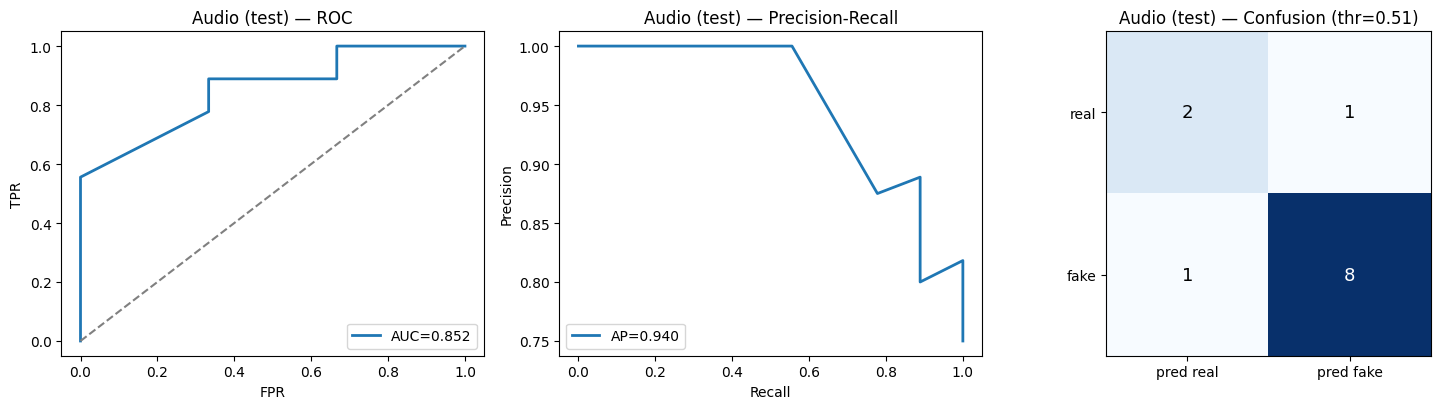

saved /kaggle/working/audio_eval.png


In [25]:
# ── AUDIO: evaluate on train / val / test ───────────────────────────────────
audio_results = {}
if AUDIO_ON and aud_model is not None:
    yv, pv = infer_probs_aud(aud_model, aud_loader(aud_df[aud_df.split=="val"], CFG.audio_batch, False))
    locked_thr = best_f1_threshold(yv, pv)
    for sp in ["train", "val", "test"]:
        d = aud_df[aud_df.split==sp]
        if len(d)==0: continue
        yy, pp = infer_probs_aud(aud_model, aud_loader(d, CFG.audio_batch, False))
        thr = None if sp=="val" else locked_thr
        m = compute_metrics(yy, pp, threshold=thr)
        audio_results[sp] = m
        print_metrics(f"AUDIO [{sp}]", m)
        if sp=="test":
            plot_eval("Audio (test)", yy, pp, m, "audio")
else:
    print("Audio branch off — no metrics.")

In [26]:
# ── Final summary table + save ──────────────────────────────────────────────
rows = []
for branch, res in [("visual", visual_results if VIDEO_ON else {}),
                    ("audio",  audio_results  if AUDIO_ON else {})]:
    for sp, m in res.items():
        rows.append({"branch": branch, "split": sp,
                     **{k: round(m[k], 4) for k in
                        ["accuracy","precision","recall","specificity","f1",
                         "roc_auc","pr_auc","mcc","eer"]},
                     "n": m["n"]})

summary = pd.DataFrame(rows)
if len(summary):
    cols = ["branch","split","accuracy","precision","recall","specificity","f1",
            "roc_auc","pr_auc","mcc","eer","n"]
    summary = summary[cols]
    print("\n================ FINAL METRICS ================\n")
    print(summary.to_string(index=False))
    summary.to_csv(os.path.join(CFG.out_dir, "metrics_summary.csv"), index=False)
    with open(os.path.join(CFG.out_dir, "metrics_full.json"), "w") as f:
        json.dump({"visual": visual_results, "audio": audio_results}, f, indent=2)
    print("\nSaved → metrics_summary.csv, metrics_full.json, *_eval.png, *_model.pt")
else:
    print("No results — add a dataset (Add Data panel) and re-run.")
summary


================ FINAL METRICS ================

branch split  accuracy  precision  recall  specificity     f1  roc_auc  pr_auc    mcc    eer  n
 audio train    0.8393     0.8667  0.9286       0.5714 0.8966   0.9124  0.9657 0.5449 0.1429 56
 audio   val    1.0000     1.0000  1.0000       1.0000 1.0000   1.0000  1.0000 1.0000 0.0000 12
 audio  test    0.8333     0.8889  0.8889       0.6667 0.8889   0.8519  0.9397 0.5556 0.2778 12

Saved → metrics_summary.csv, metrics_full.json, *_eval.png, *_model.pt


,branch,split,accuracy,precision,recall,specificity,f1,roc_auc,pr_auc,mcc,eer,n
0,audio,train,0.8393,0.8667,0.9286,0.5714,0.8966,0.9124,0.9657,0.5449,0.1429,56
1,audio,val,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,12
2,audio,test,0.8333,0.8889,0.8889,0.6667,0.8889,0.8519,0.9397,0.5556,0.2778,12


In [27]:
# ── DATASET INSPECTOR ───────────────────────────────────────────────────────
import os, collections
import pandas as pd
ROOT = "/kaggle/input"

print("="*70); print("DATASET DIRS (depth<=2)"); print("="*70)
seen=set()
for dp,dirs,files in os.walk(ROOT):
    rel = dp[len(ROOT):].strip(os.sep)
    if (rel.count(os.sep) if rel else 0) <= 2 and rel and rel not in seen:
        seen.add(rel); print("  ", rel, f"({len(files)} files here)")

print("\n"+"="*70); print("EXTENSION CENSUS"); print("="*70)
ext=collections.Counter()
special={"zip":[],"csv":[],"parquet":[],"npy":[],"npz":[],"mp4":[],"avi":[],"mov":[],"mkv":[]}
for dp,_,files in os.walk(ROOT):
    for f in files:
        e=os.path.splitext(f)[1].lower().lstrip(".")
        ext[e]+=1
        if e in special: special[e].append(os.path.join(dp,f))
for e,c in ext.most_common(): print(f"  .{e:<8} {c:,}")
print("\nSPECIAL FILES:")
for k,v in special.items():
    if v: print(f"  {k:<8} {len(v):>5}   e.g. {v[0]}")

print("\n"+"="*70); print("TABULAR PEEK"); print("="*70)
for path in (special["csv"][:4]+special["parquet"][:4]):
    try:
        df = pd.read_parquet(path) if path.endswith("parquet") else pd.read_csv(path, nrows=5)
        print(f"\n{path}\n  shape(head)={df.shape}  cols={list(df.columns)[:30]}")
        print("  dtypes:", {c:str(t) for c,t in list(df.dtypes.items())[:10]})
    except Exception as ex: print(path,"->",repr(ex))

print("\n"+"="*70); print("FOLDER TREE (dirs, depth<=4)"); print("="*70)
n=0
for dp,dirs,files in os.walk(ROOT):
    d=dp[len(ROOT):].strip(os.sep).count(os.sep)
    if d>4: dirs[:]=[]; continue
    dirs.sort()
    media=sum(1 for f in files if f.lower().endswith((".jpg",".jpeg",".png",".wav",".flac",".mp3",".mp4")))
    print("  "*d+(os.path.basename(dp) or dp)+f"/  [{len(files)} files, {media} media]")
    n+=1
    if n>150: print("  ...(truncated)"); break

DATASET DIRS (depth<=2)
   datasets (0 files here)
   datasets/ahmedelbanby (0 files here)
   datasets/ahmedelbanby/faceforensicsplusplus-c23-deepfakebench-structure (1 files here)
   datasets/ucimachinelearning (0 files here)
   datasets/ucimachinelearning/deep-fake-detection-cropped-dataset (0 files here)
   datasets/chuneeb (0 files here)
   datasets/chuneeb/deepfake-detection-dataset-2026 (1 files here)
   datasets/unidpro (0 files here)
   datasets/unidpro/real-vs-fake-human-voice-deepfake-audio (1 files here)

EXTENSION CENSUS
  .png      400,596
  .mp4      9,293
  .mp3      65
  .m4a      10
  .json     9
  .pt       6
  .wav      5
  .md       3
  .csv      1
  .xlsx     1
  .ipynb    1

SPECIAL FILES:
  csv          1   e.g. /kaggle/input/datasets/chuneeb/deepfake-detection-dataset-2026/FINAL_DATASET.csv
  mp4       9293   e.g. /kaggle/input/datasets/ahmedelbanby/faceforensicsplusplus-c23-deepfakebench-structure/videos/FaceForensics++/original_sequences/youtube/c23/videos/123

In [29]:
# Deepfake Detector v3 — Multi-Dataset (Video + Audio)
# Kaggle script version. Cells marked with # %% (works in Jupyter/VSCode and as a plain script).
# Run on Kaggle with GPU on, after adding the datasets.

# %% [markdown]
# # 🧠 Deepfake Detector v3 — Multi-Dataset (Video + Audio)
#
# Integrates your mounted datasets automatically:
#
# | Source | Branch | Notes |
# |--------|--------|-------|
# | `ucimachinelearning/.../DFDC_Dataset` (Real/Fake PNG) | **visual** | clean labels |
# | `ahmedelbanby/faceforensics++` (≈400k frames) | **visual** | DeepfakeBench-aware labels; ambiguous frames dropped |
# | `kamedev/cvoicefake-...-safeear` | **audio** | bonafide→real, vocoder folders→fake |
# | `unidpro/real-vs-fake-human-voice` | **audio** | folded in |
# | FF++ `.mp4` (≈9.3k) | **video (optional)** | clip-level; frames not face-cropped (caveat) |
# | `aionstreet/shield .pt` | inspector (optional) | prints tensor shapes |
# | `chuneeb` CSV | **skipped** | images are remote `image_url` |
#
# Outputs full metrics on **train/val/test**: accuracy · balanced-acc · precision · recall ·
# specificity · F1 · ROC-AUC · PR-AUC · MCC · **EER** · confusion · ROC/PR plots.
#
# **Run:** GPU on. Add the datasets above (incl. the CVoiceFake mirror). Run all.
# A **per-source label audit** prints before training — check it; if a source looks
# mislabeled, set its flag to `False` in the config cell.

# %%
# ── Setup ────────────────────────────────────────────────────────────────────
import sys, subprocess, importlib
def _ensure(pkg, pip_name=None):
    try: importlib.import_module(pkg)
    except Exception:
        subprocess.run([sys.executable,"-m","pip","install","-q",pip_name or pkg], check=False)
_ensure("timm"); _ensure("librosa"); _ensure("soundfile"); _ensure("cv2","opencv-python-headless")

import os, glob, random, json, time, warnings, collections, zipfile, math
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED=42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE="cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEVICE)
if DEVICE=="cpu": print("⚠️  Turn on the GPU accelerator.")

# %%
# ── Config ───────────────────────────────────────────────────────────────────
class CFG:
    input_root   = "/kaggle/input"
    extract_root = "/kaggle/working/extracted"
    out_dir      = "/kaggle/working"

    # caps (raise once it runs clean)
    max_per_class       = 6000     # visual images per class
    max_audio_per_class = 6000     # audio clips per class
    val_frac, test_frac = 0.15, 0.15

    # which visual sources to include (matched by substring in path, case-insensitive)
    use_sources_with   = None      # e.g. set to ["dfdc_dataset"] to use ONLY cropped DFDC
    drop_sources_with  = []        # e.g. ["dfdc_test"] to exclude a source you saw mislabeled

    # visual
    img_size=224; img_backbone="efficientnet_b0"; img_epochs=4; img_batch=64; img_lr=3e-4
    # audio
    sr=16000; audio_seconds=3.0; n_mels=128; audio_epochs=6; audio_batch=64; audio_lr=1e-3
    # optional mp4 clip-level video eval
    RUN_VIDEO_MP4=False; video_max_clips=200; video_frames_per_clip=8
    num_workers=2

os.makedirs(CFG.out_dir, exist_ok=True); os.makedirs(CFG.extract_root, exist_ok=True)

def _norm(t): return ''.join(ch for ch in t.lower() if ch.isalnum())
REAL_TOKENS={"real","reals","bonafide","genuine","live","authentic","pristine",
             "original","originals","originalsequences","youtube","actors","commonvoice"}
FAKE_TOKENS={"fake","fakes","spoof","deepfake","deepfakes","face2face","faceswap",
             "neuraltextures","faceshifter","manipulated","manipulatedsequences",
             "synthetic","parallelwavegan","multibandmelgan","melgan","stylemelgan",
             "griffinlim","world","diffwave","wavegan"}

def label_from_path(p):
    for tok in reversed(p.replace("\\","/").split("/")):
        n=_norm(tok)
        if not n: continue
        if n in REAL_TOKENS or n.startswith("original"): return 0
        if n in FAKE_TOKENS or n.startswith("method"):   return 1
        if n.startswith("real"): return 0
        if n.startswith("fake"): return 1
    low=p.lower()
    if any(k in low for k in ("fake","deepfake","spoof","synthetic","synth","manipulat")): return 1
    if any(k in low for k in ("real","genuine","bonafide","original")): return 0
    return None

def split_kind(p):
    low="/"+p.lower().replace("\\","/")+"/"
    if any(s in low for s in ("/test/","/testing/","/eval/")): return "test"
    if any(s in low for s in ("/val/","/valid/","/validation/","/dev/")): return "val"
    if any(s in low for s in ("/train/","/training/")): return "train"
    return None

def source_of(p):
    # label a sample by its dataset slug (segment after an owner dir under input)
    rel=p.replace("\\","/").split("/input/")[-1].strip("/").split("/")
    rel=[s for s in rel if s not in ("datasets","extracted")]
    return "/".join(rel[:2]) if len(rel)>=2 else (rel[0] if rel else "?")

print("Config ready.")

# %%
# ── Discover data: auto-extract zips, scan input + extracted ────────────────
IMG_EXT=(".jpg",".jpeg",".png",".bmp",".webp"); AUD_EXT=(".wav",".flac",".mp3",".ogg",".m4a")
VID_EXT=(".mp4",".avi",".mov",".mkv")

def scan(root, exts, cap=2_000_000):
    out=[]
    if not os.path.exists(root): return out
    for dp,_,files in os.walk(root):
        for f in files:
            if f.lower().endswith(exts):
                out.append(os.path.join(dp,f))
                if len(out)>=cap: return out
    return out

# auto-extract any zips once
zips=[os.path.join(dp,f) for dp,_,fs in os.walk(CFG.input_root) for f in fs if f.lower().endswith(".zip")]
if zips:
    print(f"extracting {len(zips)} zip(s)…")
    for z in zips:
        dest=os.path.join(CFG.extract_root, os.path.splitext(os.path.basename(z))[0])
        if os.path.exists(dest): continue
        try:
            with zipfile.ZipFile(z) as zf: zf.extractall(dest); print("  ", z)
        except Exception as e: print("  FAIL", z, e)

print("scanning…")
all_imgs=scan(CFG.input_root,IMG_EXT)+scan(CFG.extract_root,IMG_EXT)
all_auds=scan(CFG.input_root,AUD_EXT)+scan(CFG.extract_root,AUD_EXT)
all_vids=scan(CFG.input_root,VID_EXT)+scan(CFG.extract_root,VID_EXT)
print(f"  images={len(all_imgs):,}  audio={len(all_auds):,}  videos={len(all_vids):,}")
VIDEO_ON=len(all_imgs)>50; AUDIO_ON=len(all_auds)>50
print(f"VISUAL:{'ON' if VIDEO_ON else 'off'}  AUDIO:{'ON' if AUDIO_ON else 'off'}  "
      f"MP4-eval:{'ON' if (CFG.RUN_VIDEO_MP4 and all_vids) else 'off'}")

# %%
# ── Build labeled tables + PER-SOURCE AUDIT ─────────────────────────────────
def keep_path(p):
    low=p.lower()
    if CFG.use_sources_with and not any(s in low for s in CFG.use_sources_with): return False
    if any(s in low for s in CFG.drop_sources_with): return False
    return True

def build_table(paths, cap):
    rows=[]
    for p in paths:
        if not keep_path(p): continue
        y=label_from_path(p)
        if y is None: continue
        rows.append((p,y,split_kind(p),source_of(p)))
    if not rows: return pd.DataFrame(columns=["path","label","split","source"])
    df=pd.DataFrame(rows,columns=["path","label","split","source"])
    parts=[]
    for lab,g in df.groupby("label"):
        parts.append(g.sample(frac=1.0,random_state=SEED).head(cap))
    df=pd.concat(parts).sample(frac=1.0,random_state=SEED).reset_index(drop=True)
    has=df["split"].notna().mean()>0.6 and df["split"].nunique()>=2
    if not has:
        df["split"]=None
        for lab,g in df.groupby("label"):
            idx=g.index.tolist(); n=len(idx); nt=int(n*CFG.test_frac); nv=int(n*CFG.val_frac)
            df.loc[idx[:nt],"split"]="test"; df.loc[idx[nt:nt+nv],"split"]="val"; df.loc[idx[nt+nv:],"split"]="train"
    elif (df["split"]=="val").sum()==0:
        tr=df[df["split"]=="train"]; df.loc[tr.sample(frac=CFG.val_frac,random_state=SEED).index,"split"]="val"
    return df

def audit(paths, name, cap):
    # show raw real/fake/none per source BEFORE capping, so mislabels are visible
    rec=collections.defaultdict(lambda:[0,0,0])
    for p in paths:
        if not keep_path(p): continue
        y=label_from_path(p); s=source_of(p)
        rec[s][2 if y is None else y]+=1
    print(f"\n=== {name} per-source audit (real / fake / dropped) ===")
    for s,(r,f,n) in sorted(rec.items()):
        print(f"  {s:<55} real={r:>7,}  fake={f:>7,}  drop={n:>7,}")

if VIDEO_ON: audit(all_imgs,"VISUAL",CFG.max_per_class)
if AUDIO_ON: audit(all_auds,"AUDIO",CFG.max_audio_per_class)

img_df=build_table(all_imgs,CFG.max_per_class) if VIDEO_ON else pd.DataFrame()
aud_df=build_table(all_auds,CFG.max_audio_per_class) if AUDIO_ON else pd.DataFrame()

def summarize(df,name):
    if len(df)==0: print(f"\n{name}: (none)"); return
    print(f"\n{name}: {len(df):,} used"); print(pd.crosstab(df["split"],df["label"].map({0:'real',1:'fake'}),margins=True))
summarize(img_df,"VISUAL"); summarize(aud_df,"AUDIO")

if VIDEO_ON and img_df["label"].nunique()<2: print("\n⚠️ visual single-class → off"); VIDEO_ON=False
if AUDIO_ON and aud_df["label"].nunique()<2: print("\n⚠️ audio single-class → off"); AUDIO_ON=False

# %%
# ── Shared metrics + plots ──────────────────────────────────────────────────
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, confusion_matrix, matthews_corrcoef, balanced_accuracy_score)
import matplotlib.pyplot as plt

def eer_of(y,p):
    fpr,tpr,_=roc_curve(y,p); fnr=1-tpr; i=np.nanargmin(np.abs(fnr-fpr)); return float((fpr[i]+fnr[i])/2)
def best_f1_thr(y,p):
    pr,rc,th=precision_recall_curve(y,p); f1=2*pr*rc/(pr+rc+1e-12)
    return 0.5 if len(th)==0 else float(th[np.nanargmax(f1[:-1])])

def compute_metrics(y,p,threshold=None):
    y=np.asarray(y).astype(int); p=np.asarray(p).astype(float)
    thr=best_f1_thr(y,p) if threshold is None else threshold
    yp=(p>=thr).astype(int); tn,fp,fn,tp=confusion_matrix(y,yp,labels=[0,1]).ravel(); e=1e-12
    prec=tp/(tp+fp+e); rec=tp/(tp+fn+e); spec=tn/(tn+fp+e); f1=2*prec*rec/(prec+rec+e)
    acc=(tp+tn)/(tp+tn+fp+fn+e)
    try: auc=roc_auc_score(y,p)
    except: auc=float('nan')
    try: ap=average_precision_score(y,p)
    except: ap=float('nan')
    return {"accuracy":acc,"balanced_acc":balanced_accuracy_score(y,yp),"precision":prec,
            "recall":rec,"specificity":spec,"f1":f1,"roc_auc":auc,"pr_auc":ap,
            "mcc":matthews_corrcoef(y,yp) if len(set(yp))>1 else 0.0,"eer":eer_of(y,p),
            "threshold":thr,"TP":int(tp),"FP":int(fp),"TN":int(tn),"FN":int(fn),"n":int(len(y))}

def print_metrics(name,m):
    print(f"\n── {name} ──  (n={m['n']}, thr={m['threshold']:.3f})")
    for k in ["accuracy","balanced_acc","precision","recall","specificity","f1","roc_auc","pr_auc","mcc","eer"]:
        print(f"   {k:<14}: {m[k]:.4f}")
    print(f"   confusion      : TP={m['TP']} FP={m['FP']} TN={m['TN']} FN={m['FN']}")

def plot_eval(name,y,p,m,prefix):
    y=np.asarray(y); p=np.asarray(p); fig,ax=plt.subplots(1,3,figsize=(15,4.2))
    fpr,tpr,_=roc_curve(y,p); ax[0].plot(fpr,tpr,lw=2,label=f"AUC={m['roc_auc']:.3f}")
    ax[0].plot([0,1],[0,1],"--",c="gray"); ax[0].set_title(f"{name} ROC"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend(loc="lower right")
    pr,rc,_=precision_recall_curve(y,p); ax[1].plot(rc,pr,lw=2,label=f"AP={m['pr_auc']:.3f}")
    ax[1].set_title(f"{name} PR"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend(loc="lower left")
    cm=np.array([[m['TN'],m['FP']],[m['FN'],m['TP']]]); ax[2].imshow(cm,cmap="Blues")
    ax[2].set_xticks([0,1]); ax[2].set_yticks([0,1]); ax[2].set_xticklabels(["pred real","pred fake"]); ax[2].set_yticklabels(["real","fake"])
    for (i,j),v in np.ndenumerate(cm): ax[2].text(j,i,str(v),ha="center",va="center",color="white" if v>cm.max()/2 else "black",fontsize=13)
    ax[2].set_title(f"{name} Confusion (thr={m['threshold']:.2f})"); plt.tight_layout()
    out=os.path.join(CFG.out_dir,f"{prefix}_eval.png"); plt.savefig(out,dpi=110,bbox_inches="tight"); plt.show(); print("saved",out)
print("Metrics ready.")

# %%
# ── VISUAL: dataset + EfficientNet-B0 ───────────────────────────────────────
import timm
from PIL import Image
import torchvision.transforms as T
NORM=([0.485,0.456,0.406],[0.229,0.224,0.225])
train_tf=T.Compose([T.Resize((CFG.img_size,)*2),T.RandomHorizontalFlip(),T.ColorJitter(0.1,0.1,0.1),T.ToTensor(),T.Normalize(*NORM)])
eval_tf =T.Compose([T.Resize((CFG.img_size,)*2),T.ToTensor(),T.Normalize(*NORM)])
class ImgDS(Dataset):
    def __init__(s,df,tf): s.p=df["path"].tolist(); s.y=df["label"].tolist(); s.tf=tf
    def __len__(s): return len(s.p)
    def __getitem__(s,i):
        try: im=Image.open(s.p[i]).convert("RGB")
        except: im=Image.new("RGB",(CFG.img_size,)*2)
        return s.tf(im), torch.tensor(s.y[i],dtype=torch.float32)
def iloader(df,tf,bs,sh): return DataLoader(ImgDS(df,tf),batch_size=bs,shuffle=sh,num_workers=CFG.num_workers,pin_memory=True)
class ImgNet(nn.Module):
    def __init__(s,b): super().__init__(); s.net=timm.create_model(b,pretrained=True,num_classes=1)
    def forward(s,x): return s.net(x).squeeze(1)
print("Visual ready." if VIDEO_ON else "Visual off.")

# %%
# ── VISUAL: train ───────────────────────────────────────────────────────────
@torch.no_grad()
def infer_img(model,loader):
    model.eval(); P,Y=[],[]
    for x,y in loader:
        x=x.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): p=torch.sigmoid(model(x))
        P.append(p.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(P)

img_model=None
if VIDEO_ON:
    tr=img_df[img_df.split=="train"]; va=img_df[img_df.split=="val"]
    tl=iloader(tr,train_tf,CFG.img_batch,True); vl=iloader(va,eval_tf,CFG.img_batch,False)
    img_model=ImgNet(CFG.img_backbone).to(DEVICE)
    opt=torch.optim.AdamW(img_model.parameters(),lr=CFG.img_lr,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=CFG.img_epochs*max(1,len(tl)))
    sc=torch.cuda.amp.GradScaler(enabled=DEVICE=="cuda"); lf=nn.BCEWithLogitsLoss()
    best=-1; bs=None
    for ep in range(CFG.img_epochs):
        img_model.train(); t0=time.time(); run=0
        for x,y in tl:
            x,y=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True); opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): loss=lf(img_model.net(x).squeeze(1),y)
            sc.scale(loss).backward(); sc.step(opt); sc.update(); sch.step(); run+=loss.item()*len(x)
        yv,pv=infer_img(img_model,vl)
        try: auc=roc_auc_score(yv,pv)
        except: auc=float('nan')
        print(f"  epoch {ep+1}/{CFG.img_epochs} loss={run/len(tr):.4f} val_auc={auc:.4f} ({time.time()-t0:.0f}s)")
        if auc>best: best=auc; bs={k:v.detach().cpu().clone() for k,v in img_model.state_dict().items()}
    if bs: img_model.load_state_dict(bs)
    torch.save(img_model.state_dict(),os.path.join(CFG.out_dir,"visual_model.pt"))
    print(f"Visual done. best val AUC={best:.4f}")
else: print("Visual off.")

# %%
# ── VISUAL: evaluate on train/val/test ──────────────────────────────────────
visual_results={}
if VIDEO_ON and img_model is not None:
    yv,pv=infer_img(img_model,iloader(img_df[img_df.split=="val"],eval_tf,CFG.img_batch,False))
    locked=best_f1_thr(yv,pv)
    for sp in ["train","val","test"]:
        d=img_df[img_df.split==sp]
        if len(d)==0: continue
        yy,pp=infer_img(img_model,iloader(d,eval_tf,CFG.img_batch,False))
        m=compute_metrics(yy,pp,threshold=None if sp=="val" else locked)
        visual_results[sp]=m; print_metrics(f"VISUAL [{sp}]",m)
        if sp=="test": plot_eval("Visual (test)",yy,pp,m,"visual")
else: print("Visual off — no metrics.")

# %%
# ── AUDIO: log-mel dataset + compact CNN ────────────────────────────────────
import librosa
TLEN=int(CFG.sr*CFG.audio_seconds)
def logmel(path):
    try: y,_=librosa.load(path,sr=CFG.sr,mono=True)
    except: y=np.zeros(TLEN,dtype=np.float32)
    y=np.pad(y,(0,TLEN-len(y))) if len(y)<TLEN else y[:TLEN]
    mel=librosa.feature.melspectrogram(y=y,sr=CFG.sr,n_mels=CFG.n_mels,n_fft=1024,hop_length=256)
    mel=librosa.power_to_db(mel,ref=np.max); mel=(mel-mel.mean())/(mel.std()+1e-6)
    return mel.astype(np.float32)
class AudDS(Dataset):
    def __init__(s,df): s.p=df["path"].tolist(); s.y=df["label"].tolist()
    def __len__(s): return len(s.p)
    def __getitem__(s,i): return torch.from_numpy(logmel(s.p[i])).unsqueeze(0), torch.tensor(s.y[i],dtype=torch.float32)
def aloader(df,bs,sh): return DataLoader(AudDS(df),batch_size=bs,shuffle=sh,num_workers=CFG.num_workers,pin_memory=True)
class AudioCNN(nn.Module):
    def __init__(s):
        super().__init__()
        def blk(ci,co): return nn.Sequential(nn.Conv2d(ci,co,3,padding=1),nn.BatchNorm2d(co),nn.ReLU(),nn.MaxPool2d(2))
        s.feat=nn.Sequential(blk(1,16),blk(16,32),blk(32,64),blk(64,128))
        s.head=nn.Sequential(nn.AdaptiveAvgPool2d(1),nn.Flatten(),nn.Dropout(0.3),nn.Linear(128,1))
    def forward(s,x): return s.head(s.feat(x)).squeeze(1)
print("Audio ready." if AUDIO_ON else "Audio off.")

# %%
# ── AUDIO: train ────────────────────────────────────────────────────────────
@torch.no_grad()
def infer_aud(model,loader):
    model.eval(); P,Y=[],[]
    for x,y in loader:
        x=x.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): p=torch.sigmoid(model(x))
        P.append(p.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(P)
aud_model=None
if AUDIO_ON:
    tr=aud_df[aud_df.split=="train"]; va=aud_df[aud_df.split=="val"]
    tl=aloader(tr,CFG.audio_batch,True); vl=aloader(va,CFG.audio_batch,False)
    aud_model=AudioCNN().to(DEVICE)
    opt=torch.optim.AdamW(aud_model.parameters(),lr=CFG.audio_lr,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=CFG.audio_epochs*max(1,len(tl)))
    sc=torch.cuda.amp.GradScaler(enabled=DEVICE=="cuda"); lf=nn.BCEWithLogitsLoss()
    best=-1; bsd=None
    for ep in range(CFG.audio_epochs):
        aud_model.train(); t0=time.time(); run=0
        for x,y in tl:
            x,y=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True); opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): loss=lf(aud_model(x),y)
            sc.scale(loss).backward(); sc.step(opt); sc.update(); sch.step(); run+=loss.item()*len(x)
        yv,pv=infer_aud(aud_model,vl)
        try: auc=roc_auc_score(yv,pv)
        except: auc=float('nan')
        print(f"  epoch {ep+1}/{CFG.audio_epochs} loss={run/len(tr):.4f} val_auc={auc:.4f} ({time.time()-t0:.0f}s)")
        if auc>best: best=auc; bsd={k:v.detach().cpu().clone() for k,v in aud_model.state_dict().items()}
    if bsd: aud_model.load_state_dict(bsd)
    torch.save(aud_model.state_dict(),os.path.join(CFG.out_dir,"audio_model.pt"))
    print(f"Audio done. best val AUC={best:.4f}")
else: print("Audio off.")

# %%
# ── AUDIO: evaluate on train/val/test ───────────────────────────────────────
audio_results={}
if AUDIO_ON and aud_model is not None:
    yv,pv=infer_aud(aud_model,aloader(aud_df[aud_df.split=="val"],CFG.audio_batch,False))
    locked=best_f1_thr(yv,pv)
    for sp in ["train","val","test"]:
        d=aud_df[aud_df.split==sp]
        if len(d)==0: continue
        yy,pp=infer_aud(aud_model,aloader(d,CFG.audio_batch,False))
        m=compute_metrics(yy,pp,threshold=None if sp=="val" else locked)
        audio_results[sp]=m; print_metrics(f"AUDIO [{sp}]",m)
        if sp=="test": plot_eval("Audio (test)",yy,pp,m,"audio")
else: print("Audio off — no metrics.")

# %%
# ── OPTIONAL: clip-level VIDEO eval on FF++ .mp4 (set CFG.RUN_VIDEO_MP4=True) ─
# Caveat: frames are NOT face-cropped, while the visual model trained on face crops,
# so expect weaker numbers than the frame-level metrics above. Demo of clip aggregation.
video_results={}
if CFG.RUN_VIDEO_MP4 and img_model is not None and all_vids:
    import cv2
    clips=[(p,label_from_path(p)) for p in all_vids if label_from_path(p) is not None]
    random.Random(SEED).shuffle(clips); clips=clips[:CFG.video_max_clips]
    def frames_of(path,k):
        cap=cv2.VideoCapture(path); tot=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0
        idx=np.linspace(0,max(tot-1,0),k).astype(int) if tot>0 else list(range(k)); out=[]
        for i in idx:
            cap.set(cv2.CAP_PROP_POS_FRAMES,int(i)); ok,fr=cap.read()
            if ok: out.append(eval_tf(Image.fromarray(cv2.cvtColor(fr,cv2.COLOR_BGR2RGB))))
        cap.release(); return out
    yv,pv=[],[]; img_model.eval()
    for j,(p,lab) in enumerate(clips):
        fr=frames_of(p,CFG.video_frames_per_clip)
        if not fr: continue
        with torch.no_grad(), torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
            pr=torch.sigmoid(img_model(torch.stack(fr).to(DEVICE))).float().mean().item()
        yv.append(lab); pv.append(pr)
        if (j+1)%50==0: print(f"  scored {j+1}/{len(clips)} clips")
    if len(set(yv))>1:
        m=compute_metrics(yv,pv); video_results["clip_test"]=m
        print_metrics("VIDEO clip-level",m); plot_eval("Video clips",yv,pv,m,"video")
    else: print("video: single class — skipped")
else:
    print("MP4 clip-eval off (set CFG.RUN_VIDEO_MP4=True to enable).")

# %%
# ── OPTIONAL: inspect aionstreet shield .pt feature files ───────────────────
pts=[os.path.join(dp,f) for dp,_,fs in os.walk(CFG.input_root) for f in fs if f.lower().endswith(".pt")]
print(f"found {len(pts)} .pt files")
for p in pts[:8]:
    try:
        obj=torch.load(p,map_location="cpu",weights_only=False)
        if torch.is_tensor(obj): print(f"  {os.path.basename(p)}: tensor {tuple(obj.shape)} {obj.dtype}")
        elif isinstance(obj,dict): print(f"  {os.path.basename(p)}: dict keys={list(obj.keys())[:10]}")
        else: print(f"  {os.path.basename(p)}: {type(obj)}")
    except Exception as e: print(f"  {os.path.basename(p)}: {e}")
print("(If these are {X,y} feature tensors, tell me the shapes and I'll wire a 3rd tabular branch.)")

# %%
# ── Final summary ───────────────────────────────────────────────────────────
rows=[]
for br,res in [("visual",visual_results),("audio",audio_results),("video",video_results)]:
    for sp,m in res.items():
        rows.append({"branch":br,"split":sp,**{k:round(m[k],4) for k in
            ["accuracy","precision","recall","specificity","f1","roc_auc","pr_auc","mcc","eer"]},"n":m["n"]})
summary=pd.DataFrame(rows)
if len(summary):
    summary=summary[["branch","split","accuracy","precision","recall","specificity","f1","roc_auc","pr_auc","mcc","eer","n"]]
    print("\n================ FINAL METRICS ================\n"); print(summary.to_string(index=False))
    summary.to_csv(os.path.join(CFG.out_dir,"metrics_summary.csv"),index=False)
    with open(os.path.join(CFG.out_dir,"metrics_full.json"),"w") as f:
        json.dump({"visual":visual_results,"audio":audio_results,"video":video_results},f,indent=2)
    print("\nSaved → metrics_summary.csv, metrics_full.json, *_eval.png, *_model.pt")
else: print("No results — check the per-source audit and dataset mounts.")
summary

torch 2.10.0+cu128 | device: cuda
Config ready.


KeyboardInterrupt: 

torch 2.10.0+cu128 | device: cuda
Config ready.
scanning images…
  [img] matched 50,024 (14s)…
  [img] matched 100,026 (16s)…
  [img] matched 150,018 (18s)…
  [img] matched 200,002 (23s)…
  [img] matched 250,011 (24s)…
  [img] matched 300,026 (25s)…
  [img] hit cap 300,000 — stopping scan early
  [img2] 0 files (0s)
scanning audio…
  [aud] matched 74,556 (78s)…
  [aud] matched 110,519 (108s)…
  [aud] matched 185,075 (171s)…
  [aud] matched 221,044 (202s)…
  [aud] matched 256,996 (233s)…
  [aud] matched 300,022 (270s)…
  [aud] hit cap 300,000 — stopping scan early
  [aud2] 0 files (0s)
scanning video…
  [vid] 9,293 files (1195s)
  [vid2] 0 files (0s)
images=300,026 audio=300,022 videos=9,293
VISUAL:ON  AUDIO:ON  MP4-eval:off

=== VISUAL per-source audit (real / fake / dropped) ===
  ahmedelbanby/faceforensicsplusplus-c23-deepfakebench-structure real= 58,048  fake=241,978  drop=      0

=== AUDIO per-source audit (real / fake / dropped) ===
  kamedev/cvoicefake-full-safeear-dataset-mirro

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

  epoch 1/4 loss=0.8552 val_auc=0.9651 (96s)
  epoch 2/4 loss=0.1302 val_auc=0.9846 (46s)
  epoch 3/4 loss=0.0550 val_auc=0.9889 (45s)
  epoch 4/4 loss=0.0336 val_auc=0.9888 (45s)
Visual done. best val AUC=0.9889

── VISUAL [train] ──  (n=8400, thr=0.316)
   accuracy      : 0.9960
   balanced_acc  : 0.9960
   precision     : 0.9967
   recall        : 0.9952
   specificity   : 0.9967
   f1            : 0.9959
   roc_auc       : 0.9998
   pr_auc        : 0.9998
   mcc           : 0.9919
   eer           : 0.0043
   confusion      : TP=4180 FP=14 TN=4186 FN=20

── VISUAL [val] ──  (n=1800, thr=0.316)
   accuracy      : 0.9522
   balanced_acc  : 0.9522
   precision     : 0.9553
   recall        : 0.9489
   specificity   : 0.9556
   f1            : 0.9521
   roc_auc       : 0.9889
   pr_auc        : 0.9897
   mcc           : 0.9045
   eer           : 0.0489
   confusion      : TP=854 FP=40 TN=860 FN=46

── VISUAL [test] ──  (n=1800, thr=0.316)
   accuracy      : 0.9428
   balanced_acc  : 0.

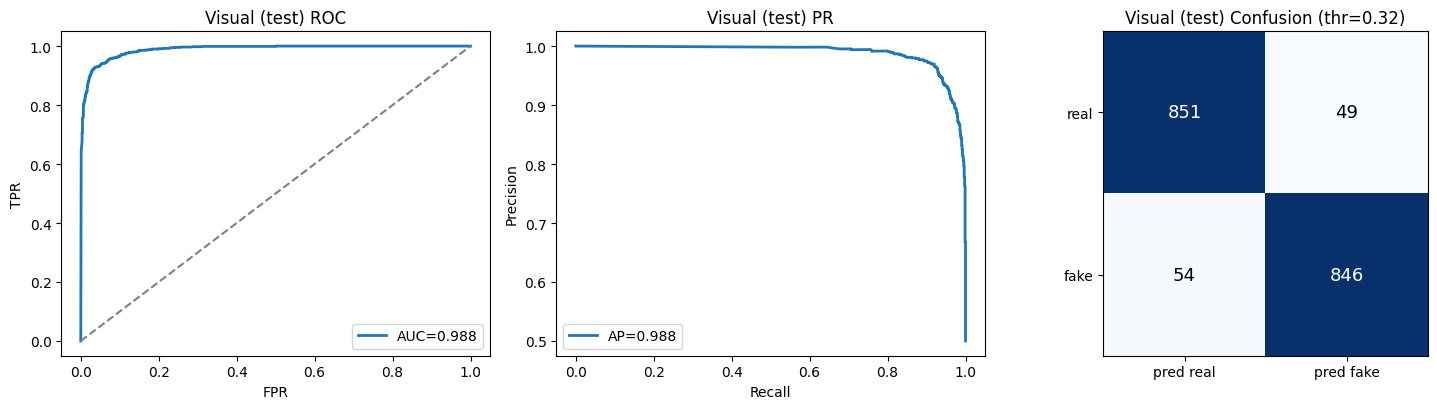

saved /kaggle/working/visual_eval.png
Audio ready.
  epoch 1/6 loss=0.4429 val_auc=0.9386 (196s)
  epoch 2/6 loss=0.2772 val_auc=0.9700 (165s)
  epoch 3/6 loss=0.2007 val_auc=0.9849 (158s)
  epoch 4/6 loss=0.1577 val_auc=0.9907 (156s)
  epoch 5/6 loss=0.1199 val_auc=0.9936 (164s)
  epoch 6/6 loss=0.1072 val_auc=0.9940 (159s)
Audio done. best val AUC=0.9940

── AUDIO [train] ──  (n=8400, thr=0.515)
   accuracy      : 0.9771
   balanced_acc  : 0.9771
   precision     : 0.9706
   recall        : 0.9840
   specificity   : 0.9702
   f1            : 0.9773
   roc_auc       : 0.9974
   pr_auc        : 0.9973
   mcc           : 0.9544
   eer           : 0.0227
   confusion      : TP=4133 FP=125 TN=4075 FN=67

── AUDIO [val] ──  (n=1800, thr=0.515)
   accuracy      : 0.9611
   balanced_acc  : 0.9611
   precision     : 0.9491
   recall        : 0.9744
   specificity   : 0.9478
   f1            : 0.9616
   roc_auc       : 0.9940
   pr_auc        : 0.9940
   mcc           : 0.9226
   eer          

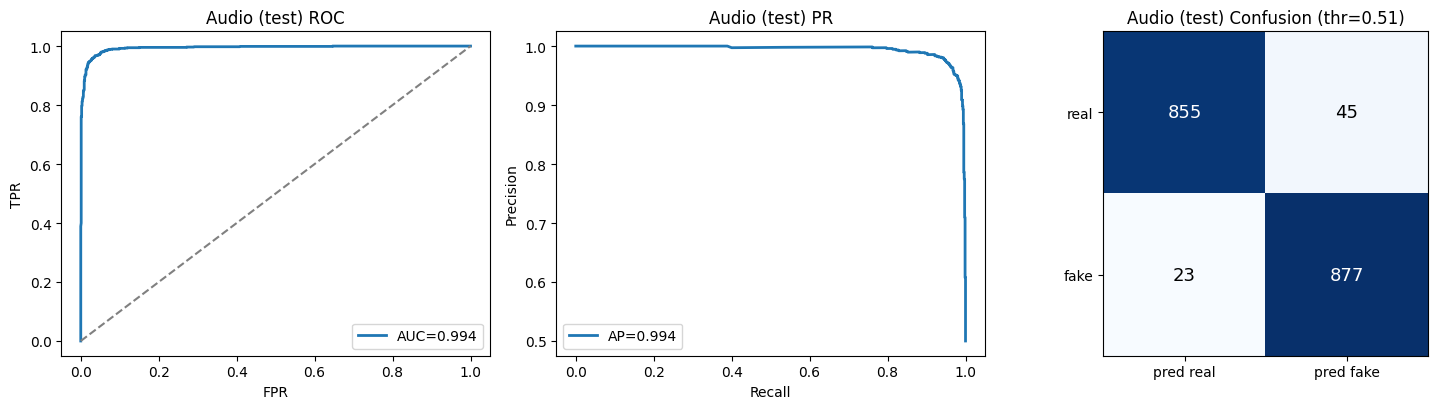

saved /kaggle/working/audio_eval.png
MP4 clip-eval off (set CFG.RUN_VIDEO_MP4=True to enable).


KeyboardInterrupt: 

In [30]:
# Deepfake Detector v3 — Multi-Dataset (Video + Audio)
# Kaggle script. Cells marked # %% (run in Jupyter/VSCode or top-to-bottom).
# GPU on. Run interactively (Run All) — not Save Version — to see live output.

# %% [markdown]
# # 🧠 Deepfake Detector v3 — Multi-Dataset (Video + Audio)
#
# Integrates your mounted datasets automatically:
#
# | Source | Branch | Notes |
# |--------|--------|-------|
# | `ucimachinelearning/.../DFDC_Dataset` (Real/Fake PNG) | **visual** | clean labels |
# | `ahmedelbanby/faceforensics++` (≈400k frames) | **visual** | DeepfakeBench-aware labels; ambiguous frames dropped |
# | `kamedev/cvoicefake-...-safeear` | **audio** | bonafide→real, vocoder folders→fake |
# | `unidpro/real-vs-fake-human-voice` | **audio** | folded in |
# | FF++ `.mp4` (≈9.3k) | **video (optional)** | clip-level; frames not face-cropped (caveat) |
# | `aionstreet/shield .pt` | inspector (optional) | prints tensor shapes |
# | `chuneeb` CSV | **skipped** | images are remote `image_url` |
#
# Outputs full metrics on **train/val/test**: accuracy · balanced-acc · precision · recall ·
# specificity · F1 · ROC-AUC · PR-AUC · MCC · **EER** · confusion · ROC/PR plots.
#
# **Run:** GPU on. Add the datasets above (incl. the CVoiceFake mirror). Run all.
# A **per-source label audit** prints before training — check it; if a source looks
# mislabeled, set its flag to `False` in the config cell.

# %%
# ── Setup ────────────────────────────────────────────────────────────────────
import sys, subprocess, importlib
def _ensure(pkg, pip_name=None):
    try: importlib.import_module(pkg)
    except Exception:
        subprocess.run([sys.executable,"-m","pip","install","-q",pip_name or pkg], check=False)
_ensure("timm"); _ensure("librosa"); _ensure("soundfile"); _ensure("cv2","opencv-python-headless")

import os, glob, random, json, time, warnings, collections, zipfile, math
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED=42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE="cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEVICE)
if DEVICE=="cpu": print("⚠️  Turn on the GPU accelerator.")

# %%
# ── Config ───────────────────────────────────────────────────────────────────
class CFG:
    input_root   = "/kaggle/input"
    extract_root = "/kaggle/working/extracted"
    out_dir      = "/kaggle/working"

    # caps (raise once it runs clean)
    max_per_class       = 6000     # visual images per class
    max_audio_per_class = 6000     # audio clips per class
    val_frac, test_frac = 0.15, 0.15

    # which visual sources to include (matched by substring in path, case-insensitive)
    use_sources_with   = None      # e.g. set to ["dfdc_dataset"] to use ONLY cropped DFDC
    drop_sources_with  = []        # e.g. ["dfdc_test"] to exclude a source you saw mislabeled

    # visual
    img_size=224; img_backbone="efficientnet_b0"; img_epochs=4; img_batch=64; img_lr=3e-4
    # audio
    sr=16000; audio_seconds=3.0; n_mels=128; audio_epochs=6; audio_batch=64; audio_lr=1e-3
    # optional mp4 clip-level video eval
    RUN_VIDEO_MP4=False; video_max_clips=200; video_frames_per_clip=8
    num_workers=2

os.makedirs(CFG.out_dir, exist_ok=True); os.makedirs(CFG.extract_root, exist_ok=True)

def _norm(t): return ''.join(ch for ch in t.lower() if ch.isalnum())
REAL_TOKENS={"real","reals","bonafide","genuine","live","authentic","pristine",
             "original","originals","originalsequences","youtube","actors","commonvoice"}
FAKE_TOKENS={"fake","fakes","spoof","deepfake","deepfakes","face2face","faceswap",
             "neuraltextures","faceshifter","manipulated","manipulatedsequences",
             "synthetic","parallelwavegan","multibandmelgan","melgan","stylemelgan",
             "griffinlim","world","diffwave","wavegan"}

def label_from_path(p):
    for tok in reversed(p.replace("\\","/").split("/")):
        n=_norm(tok)
        if not n: continue
        if n in REAL_TOKENS or n.startswith("original"): return 0
        if n in FAKE_TOKENS or n.startswith("method"):   return 1
        if n.startswith("real"): return 0
        if n.startswith("fake"): return 1
    low=p.lower()
    if any(k in low for k in ("fake","deepfake","spoof","synthetic","synth","manipulat")): return 1
    if any(k in low for k in ("real","genuine","bonafide","original")): return 0
    return None

def split_kind(p):
    low="/"+p.lower().replace("\\","/")+"/"
    if any(s in low for s in ("/test/","/testing/","/eval/")): return "test"
    if any(s in low for s in ("/val/","/valid/","/validation/","/dev/")): return "val"
    if any(s in low for s in ("/train/","/training/")): return "train"
    return None

def source_of(p):
    # label a sample by its dataset slug (segment after an owner dir under input)
    rel=p.replace("\\","/").split("/input/")[-1].strip("/").split("/")
    rel=[s for s in rel if s not in ("datasets","extracted")]
    return "/".join(rel[:2]) if len(rel)>=2 else (rel[0] if rel else "?")

print("Config ready.")

# %%
# ── Discover data: instrumented + disk-safe (scan input + extracted) ────────
IMG_EXT=(".jpg",".jpeg",".png",".bmp",".webp"); AUD_EXT=(".wav",".flac",".mp3",".ogg",".m4a")
VID_EXT=(".mp4",".avi",".mov",".mkv")

# never auto-extract huge archives (e.g. CVoiceFake-Full) — they fill the ~20GB working disk
MAX_ZIP_MB = 200
zips=[os.path.join(dp,f) for dp,_,fs in os.walk(CFG.input_root) for f in fs if f.lower().endswith(".zip")]
for z in zips:
    mb=os.path.getsize(z)/1e6
    if mb>MAX_ZIP_MB:
        print(f"skip big zip ({mb:.0f}MB): {z}  → reading from input directly"); continue
    dest=os.path.join(CFG.extract_root, os.path.splitext(os.path.basename(z))[0])
    if os.path.exists(dest): continue
    try:
        with zipfile.ZipFile(z) as zf: zf.extractall(dest); print("extracted", z)
    except Exception as e: print("zip fail", z, e)

def scan(root, exts, cap=300_000, tag=""):     # cap returns early so a 1M-file set won't stall
    out=[]; t0=time.time(); nextmark=50000
    if not os.path.exists(root): return out
    for dp,_,files in os.walk(root):
        for f in files:
            if f.lower().endswith(exts): out.append(os.path.join(dp,f))
        if len(out)>=nextmark: print(f"  [{tag}] matched {len(out):,} ({time.time()-t0:.0f}s)…"); nextmark+=50000
        if len(out)>=cap: print(f"  [{tag}] hit cap {cap:,} — stopping scan early"); return out
    print(f"  [{tag}] {len(out):,} files ({time.time()-t0:.0f}s)"); return out

print("scanning images…"); all_imgs=scan(CFG.input_root,IMG_EXT,tag="img")+scan(CFG.extract_root,IMG_EXT,tag="img2")
print("scanning audio…");  all_auds=scan(CFG.input_root,AUD_EXT,tag="aud")+scan(CFG.extract_root,AUD_EXT,tag="aud2")
print("scanning video…");  all_vids=scan(CFG.input_root,VID_EXT,tag="vid")+scan(CFG.extract_root,VID_EXT,tag="vid2")
print(f"images={len(all_imgs):,} audio={len(all_auds):,} videos={len(all_vids):,}")
VIDEO_ON=len(all_imgs)>50; AUDIO_ON=len(all_auds)>50
print(f"VISUAL:{'ON' if VIDEO_ON else 'off'}  AUDIO:{'ON' if AUDIO_ON else 'off'}  "
      f"MP4-eval:{'ON' if (CFG.RUN_VIDEO_MP4 and all_vids) else 'off'}")

# %%
# ── Build labeled tables + PER-SOURCE AUDIT ─────────────────────────────────
def keep_path(p):
    low=p.lower()
    if CFG.use_sources_with and not any(s in low for s in CFG.use_sources_with): return False
    if any(s in low for s in CFG.drop_sources_with): return False
    return True

def build_table(paths, cap):
    rows=[]
    for p in paths:
        if not keep_path(p): continue
        y=label_from_path(p)
        if y is None: continue
        rows.append((p,y,split_kind(p),source_of(p)))
    if not rows: return pd.DataFrame(columns=["path","label","split","source"])
    df=pd.DataFrame(rows,columns=["path","label","split","source"])
    parts=[]
    for lab,g in df.groupby("label"):
        parts.append(g.sample(frac=1.0,random_state=SEED).head(cap))
    df=pd.concat(parts).sample(frac=1.0,random_state=SEED).reset_index(drop=True)
    has=df["split"].notna().mean()>0.6 and df["split"].nunique()>=2
    if not has:
        df["split"]=None
        for lab,g in df.groupby("label"):
            idx=g.index.tolist(); n=len(idx); nt=int(n*CFG.test_frac); nv=int(n*CFG.val_frac)
            df.loc[idx[:nt],"split"]="test"; df.loc[idx[nt:nt+nv],"split"]="val"; df.loc[idx[nt+nv:],"split"]="train"
    elif (df["split"]=="val").sum()==0:
        tr=df[df["split"]=="train"]; df.loc[tr.sample(frac=CFG.val_frac,random_state=SEED).index,"split"]="val"
    return df

def audit(paths, name, cap):
    # show raw real/fake/none per source BEFORE capping, so mislabels are visible
    rec=collections.defaultdict(lambda:[0,0,0])
    for p in paths:
        if not keep_path(p): continue
        y=label_from_path(p); s=source_of(p)
        rec[s][2 if y is None else y]+=1
    print(f"\n=== {name} per-source audit (real / fake / dropped) ===")
    for s,(r,f,n) in sorted(rec.items()):
        print(f"  {s:<55} real={r:>7,}  fake={f:>7,}  drop={n:>7,}")

if VIDEO_ON: audit(all_imgs,"VISUAL",CFG.max_per_class)
if AUDIO_ON: audit(all_auds,"AUDIO",CFG.max_audio_per_class)

img_df=build_table(all_imgs,CFG.max_per_class) if VIDEO_ON else pd.DataFrame()
aud_df=build_table(all_auds,CFG.max_audio_per_class) if AUDIO_ON else pd.DataFrame()

def summarize(df,name):
    if len(df)==0: print(f"\n{name}: (none)"); return
    print(f"\n{name}: {len(df):,} used"); print(pd.crosstab(df["split"],df["label"].map({0:'real',1:'fake'}),margins=True))
summarize(img_df,"VISUAL"); summarize(aud_df,"AUDIO")

if VIDEO_ON and img_df["label"].nunique()<2: print("\n⚠️ visual single-class → off"); VIDEO_ON=False
if AUDIO_ON and aud_df["label"].nunique()<2: print("\n⚠️ audio single-class → off"); AUDIO_ON=False

# %%
# ── Shared metrics + plots ──────────────────────────────────────────────────
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, confusion_matrix, matthews_corrcoef, balanced_accuracy_score)
import matplotlib.pyplot as plt

def eer_of(y,p):
    fpr,tpr,_=roc_curve(y,p); fnr=1-tpr; i=np.nanargmin(np.abs(fnr-fpr)); return float((fpr[i]+fnr[i])/2)
def best_f1_thr(y,p):
    pr,rc,th=precision_recall_curve(y,p); f1=2*pr*rc/(pr+rc+1e-12)
    return 0.5 if len(th)==0 else float(th[np.nanargmax(f1[:-1])])

def compute_metrics(y,p,threshold=None):
    y=np.asarray(y).astype(int); p=np.asarray(p).astype(float)
    thr=best_f1_thr(y,p) if threshold is None else threshold
    yp=(p>=thr).astype(int); tn,fp,fn,tp=confusion_matrix(y,yp,labels=[0,1]).ravel(); e=1e-12
    prec=tp/(tp+fp+e); rec=tp/(tp+fn+e); spec=tn/(tn+fp+e); f1=2*prec*rec/(prec+rec+e)
    acc=(tp+tn)/(tp+tn+fp+fn+e)
    try: auc=roc_auc_score(y,p)
    except: auc=float('nan')
    try: ap=average_precision_score(y,p)
    except: ap=float('nan')
    return {"accuracy":acc,"balanced_acc":balanced_accuracy_score(y,yp),"precision":prec,
            "recall":rec,"specificity":spec,"f1":f1,"roc_auc":auc,"pr_auc":ap,
            "mcc":matthews_corrcoef(y,yp) if len(set(yp))>1 else 0.0,"eer":eer_of(y,p),
            "threshold":thr,"TP":int(tp),"FP":int(fp),"TN":int(tn),"FN":int(fn),"n":int(len(y))}

def print_metrics(name,m):
    print(f"\n── {name} ──  (n={m['n']}, thr={m['threshold']:.3f})")
    for k in ["accuracy","balanced_acc","precision","recall","specificity","f1","roc_auc","pr_auc","mcc","eer"]:
        print(f"   {k:<14}: {m[k]:.4f}")
    print(f"   confusion      : TP={m['TP']} FP={m['FP']} TN={m['TN']} FN={m['FN']}")

def plot_eval(name,y,p,m,prefix):
    y=np.asarray(y); p=np.asarray(p); fig,ax=plt.subplots(1,3,figsize=(15,4.2))
    fpr,tpr,_=roc_curve(y,p); ax[0].plot(fpr,tpr,lw=2,label=f"AUC={m['roc_auc']:.3f}")
    ax[0].plot([0,1],[0,1],"--",c="gray"); ax[0].set_title(f"{name} ROC"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend(loc="lower right")
    pr,rc,_=precision_recall_curve(y,p); ax[1].plot(rc,pr,lw=2,label=f"AP={m['pr_auc']:.3f}")
    ax[1].set_title(f"{name} PR"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend(loc="lower left")
    cm=np.array([[m['TN'],m['FP']],[m['FN'],m['TP']]]); ax[2].imshow(cm,cmap="Blues")
    ax[2].set_xticks([0,1]); ax[2].set_yticks([0,1]); ax[2].set_xticklabels(["pred real","pred fake"]); ax[2].set_yticklabels(["real","fake"])
    for (i,j),v in np.ndenumerate(cm): ax[2].text(j,i,str(v),ha="center",va="center",color="white" if v>cm.max()/2 else "black",fontsize=13)
    ax[2].set_title(f"{name} Confusion (thr={m['threshold']:.2f})"); plt.tight_layout()
    out=os.path.join(CFG.out_dir,f"{prefix}_eval.png"); plt.savefig(out,dpi=110,bbox_inches="tight"); plt.show(); print("saved",out)
print("Metrics ready.")

# %%
# ── VISUAL: dataset + EfficientNet-B0 ───────────────────────────────────────
import timm
from PIL import Image
import torchvision.transforms as T
NORM=([0.485,0.456,0.406],[0.229,0.224,0.225])
train_tf=T.Compose([T.Resize((CFG.img_size,)*2),T.RandomHorizontalFlip(),T.ColorJitter(0.1,0.1,0.1),T.ToTensor(),T.Normalize(*NORM)])
eval_tf =T.Compose([T.Resize((CFG.img_size,)*2),T.ToTensor(),T.Normalize(*NORM)])
class ImgDS(Dataset):
    def __init__(s,df,tf): s.p=df["path"].tolist(); s.y=df["label"].tolist(); s.tf=tf
    def __len__(s): return len(s.p)
    def __getitem__(s,i):
        try: im=Image.open(s.p[i]).convert("RGB")
        except: im=Image.new("RGB",(CFG.img_size,)*2)
        return s.tf(im), torch.tensor(s.y[i],dtype=torch.float32)
def iloader(df,tf,bs,sh): return DataLoader(ImgDS(df,tf),batch_size=bs,shuffle=sh,num_workers=CFG.num_workers,pin_memory=True)
class ImgNet(nn.Module):
    def __init__(s,b): super().__init__(); s.net=timm.create_model(b,pretrained=True,num_classes=1)
    def forward(s,x): return s.net(x).squeeze(1)
print("Visual ready." if VIDEO_ON else "Visual off.")

# %%
# ── VISUAL: train ───────────────────────────────────────────────────────────
@torch.no_grad()
def infer_img(model,loader):
    model.eval(); P,Y=[],[]
    for x,y in loader:
        x=x.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): p=torch.sigmoid(model(x))
        P.append(p.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(P)

img_model=None
if VIDEO_ON:
    tr=img_df[img_df.split=="train"]; va=img_df[img_df.split=="val"]
    tl=iloader(tr,train_tf,CFG.img_batch,True); vl=iloader(va,eval_tf,CFG.img_batch,False)
    img_model=ImgNet(CFG.img_backbone).to(DEVICE)
    opt=torch.optim.AdamW(img_model.parameters(),lr=CFG.img_lr,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=CFG.img_epochs*max(1,len(tl)))
    sc=torch.cuda.amp.GradScaler(enabled=DEVICE=="cuda"); lf=nn.BCEWithLogitsLoss()
    best=-1; bs=None
    for ep in range(CFG.img_epochs):
        img_model.train(); t0=time.time(); run=0
        for x,y in tl:
            x,y=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True); opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): loss=lf(img_model.net(x).squeeze(1),y)
            sc.scale(loss).backward(); sc.step(opt); sc.update(); sch.step(); run+=loss.item()*len(x)
        yv,pv=infer_img(img_model,vl)
        try: auc=roc_auc_score(yv,pv)
        except: auc=float('nan')
        print(f"  epoch {ep+1}/{CFG.img_epochs} loss={run/len(tr):.4f} val_auc={auc:.4f} ({time.time()-t0:.0f}s)")
        if auc>best: best=auc; bs={k:v.detach().cpu().clone() for k,v in img_model.state_dict().items()}
    if bs: img_model.load_state_dict(bs)
    torch.save(img_model.state_dict(),os.path.join(CFG.out_dir,"visual_model.pt"))
    print(f"Visual done. best val AUC={best:.4f}")
else: print("Visual off.")

# %%
# ── VISUAL: evaluate on train/val/test ──────────────────────────────────────
visual_results={}
if VIDEO_ON and img_model is not None:
    yv,pv=infer_img(img_model,iloader(img_df[img_df.split=="val"],eval_tf,CFG.img_batch,False))
    locked=best_f1_thr(yv,pv)
    for sp in ["train","val","test"]:
        d=img_df[img_df.split==sp]
        if len(d)==0: continue
        yy,pp=infer_img(img_model,iloader(d,eval_tf,CFG.img_batch,False))
        m=compute_metrics(yy,pp,threshold=None if sp=="val" else locked)
        visual_results[sp]=m; print_metrics(f"VISUAL [{sp}]",m)
        if sp=="test": plot_eval("Visual (test)",yy,pp,m,"visual")
else: print("Visual off — no metrics.")

# %%
# ── AUDIO: log-mel dataset + compact CNN ────────────────────────────────────
import librosa
TLEN=int(CFG.sr*CFG.audio_seconds)
def logmel(path):
    try: y,_=librosa.load(path,sr=CFG.sr,mono=True)
    except: y=np.zeros(TLEN,dtype=np.float32)
    y=np.pad(y,(0,TLEN-len(y))) if len(y)<TLEN else y[:TLEN]
    mel=librosa.feature.melspectrogram(y=y,sr=CFG.sr,n_mels=CFG.n_mels,n_fft=1024,hop_length=256)
    mel=librosa.power_to_db(mel,ref=np.max); mel=(mel-mel.mean())/(mel.std()+1e-6)
    return mel.astype(np.float32)
class AudDS(Dataset):
    def __init__(s,df): s.p=df["path"].tolist(); s.y=df["label"].tolist()
    def __len__(s): return len(s.p)
    def __getitem__(s,i): return torch.from_numpy(logmel(s.p[i])).unsqueeze(0), torch.tensor(s.y[i],dtype=torch.float32)
def aloader(df,bs,sh): return DataLoader(AudDS(df),batch_size=bs,shuffle=sh,num_workers=CFG.num_workers,pin_memory=True)
class AudioCNN(nn.Module):
    def __init__(s):
        super().__init__()
        def blk(ci,co): return nn.Sequential(nn.Conv2d(ci,co,3,padding=1),nn.BatchNorm2d(co),nn.ReLU(),nn.MaxPool2d(2))
        s.feat=nn.Sequential(blk(1,16),blk(16,32),blk(32,64),blk(64,128))
        s.head=nn.Sequential(nn.AdaptiveAvgPool2d(1),nn.Flatten(),nn.Dropout(0.3),nn.Linear(128,1))
    def forward(s,x): return s.head(s.feat(x)).squeeze(1)
print("Audio ready." if AUDIO_ON else "Audio off.")

# %%
# ── AUDIO: train ────────────────────────────────────────────────────────────
@torch.no_grad()
def infer_aud(model,loader):
    model.eval(); P,Y=[],[]
    for x,y in loader:
        x=x.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): p=torch.sigmoid(model(x))
        P.append(p.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(P)
aud_model=None
if AUDIO_ON:
    tr=aud_df[aud_df.split=="train"]; va=aud_df[aud_df.split=="val"]
    tl=aloader(tr,CFG.audio_batch,True); vl=aloader(va,CFG.audio_batch,False)
    aud_model=AudioCNN().to(DEVICE)
    opt=torch.optim.AdamW(aud_model.parameters(),lr=CFG.audio_lr,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=CFG.audio_epochs*max(1,len(tl)))
    sc=torch.cuda.amp.GradScaler(enabled=DEVICE=="cuda"); lf=nn.BCEWithLogitsLoss()
    best=-1; bsd=None
    for ep in range(CFG.audio_epochs):
        aud_model.train(); t0=time.time(); run=0
        for x,y in tl:
            x,y=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True); opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): loss=lf(aud_model(x),y)
            sc.scale(loss).backward(); sc.step(opt); sc.update(); sch.step(); run+=loss.item()*len(x)
        yv,pv=infer_aud(aud_model,vl)
        try: auc=roc_auc_score(yv,pv)
        except: auc=float('nan')
        print(f"  epoch {ep+1}/{CFG.audio_epochs} loss={run/len(tr):.4f} val_auc={auc:.4f} ({time.time()-t0:.0f}s)")
        if auc>best: best=auc; bsd={k:v.detach().cpu().clone() for k,v in aud_model.state_dict().items()}
    if bsd: aud_model.load_state_dict(bsd)
    torch.save(aud_model.state_dict(),os.path.join(CFG.out_dir,"audio_model.pt"))
    print(f"Audio done. best val AUC={best:.4f}")
else: print("Audio off.")

# %%
# ── AUDIO: evaluate on train/val/test ───────────────────────────────────────
audio_results={}
if AUDIO_ON and aud_model is not None:
    yv,pv=infer_aud(aud_model,aloader(aud_df[aud_df.split=="val"],CFG.audio_batch,False))
    locked=best_f1_thr(yv,pv)
    for sp in ["train","val","test"]:
        d=aud_df[aud_df.split==sp]
        if len(d)==0: continue
        yy,pp=infer_aud(aud_model,aloader(d,CFG.audio_batch,False))
        m=compute_metrics(yy,pp,threshold=None if sp=="val" else locked)
        audio_results[sp]=m; print_metrics(f"AUDIO [{sp}]",m)
        if sp=="test": plot_eval("Audio (test)",yy,pp,m,"audio")
else: print("Audio off — no metrics.")

# %%
# ── OPTIONAL: clip-level VIDEO eval on FF++ .mp4 (set CFG.RUN_VIDEO_MP4=True) ─
# Caveat: frames are NOT face-cropped, while the visual model trained on face crops,
# so expect weaker numbers than the frame-level metrics above. Demo of clip aggregation.
video_results={}
if CFG.RUN_VIDEO_MP4 and img_model is not None and all_vids:
    import cv2
    clips=[(p,label_from_path(p)) for p in all_vids if label_from_path(p) is not None]
    random.Random(SEED).shuffle(clips); clips=clips[:CFG.video_max_clips]
    def frames_of(path,k):
        cap=cv2.VideoCapture(path); tot=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0
        idx=np.linspace(0,max(tot-1,0),k).astype(int) if tot>0 else list(range(k)); out=[]
        for i in idx:
            cap.set(cv2.CAP_PROP_POS_FRAMES,int(i)); ok,fr=cap.read()
            if ok: out.append(eval_tf(Image.fromarray(cv2.cvtColor(fr,cv2.COLOR_BGR2RGB))))
        cap.release(); return out
    yv,pv=[],[]; img_model.eval()
    for j,(p,lab) in enumerate(clips):
        fr=frames_of(p,CFG.video_frames_per_clip)
        if not fr: continue
        with torch.no_grad(), torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
            pr=torch.sigmoid(img_model(torch.stack(fr).to(DEVICE))).float().mean().item()
        yv.append(lab); pv.append(pr)
        if (j+1)%50==0: print(f"  scored {j+1}/{len(clips)} clips")
    if len(set(yv))>1:
        m=compute_metrics(yv,pv); video_results["clip_test"]=m
        print_metrics("VIDEO clip-level",m); plot_eval("Video clips",yv,pv,m,"video")
    else: print("video: single class — skipped")
else:
    print("MP4 clip-eval off (set CFG.RUN_VIDEO_MP4=True to enable).")

# %%
# ── OPTIONAL: inspect aionstreet shield .pt feature files ───────────────────
pts=[os.path.join(dp,f) for dp,_,fs in os.walk(CFG.input_root) for f in fs if f.lower().endswith(".pt")]
print(f"found {len(pts)} .pt files")
for p in pts[:8]:
    try:
        obj=torch.load(p,map_location="cpu",weights_only=False)
        if torch.is_tensor(obj): print(f"  {os.path.basename(p)}: tensor {tuple(obj.shape)} {obj.dtype}")
        elif isinstance(obj,dict): print(f"  {os.path.basename(p)}: dict keys={list(obj.keys())[:10]}")
        else: print(f"  {os.path.basename(p)}: {type(obj)}")
    except Exception as e: print(f"  {os.path.basename(p)}: {e}")
print("(If these are {X,y} feature tensors, tell me the shapes and I'll wire a 3rd tabular branch.)")

# %%
# ── Final summary ───────────────────────────────────────────────────────────
rows=[]
for br,res in [("visual",visual_results),("audio",audio_results),("video",video_results)]:
    for sp,m in res.items():
        rows.append({"branch":br,"split":sp,**{k:round(m[k],4) for k in
            ["accuracy","precision","recall","specificity","f1","roc_auc","pr_auc","mcc","eer"]},"n":m["n"]})
summary=pd.DataFrame(rows)
if len(summary):
    summary=summary[["branch","split","accuracy","precision","recall","specificity","f1","roc_auc","pr_auc","mcc","eer","n"]]
    print("\n================ FINAL METRICS ================\n"); print(summary.to_string(index=False))
    summary.to_csv(os.path.join(CFG.out_dir,"metrics_summary.csv"),index=False)
    with open(os.path.join(CFG.out_dir,"metrics_full.json"),"w") as f:
        json.dump({"visual":visual_results,"audio":audio_results,"video":video_results},f,indent=2)
    print("\nSaved → metrics_summary.csv, metrics_full.json, *_eval.png, *_model.pt")
else: print("No results — check the per-source audit and dataset mounts.")
summary

In [31]:
# ── ZIP ALL RESULTS FOR DOWNLOAD ──────────────────────────────────────────
# Run this as a standalone cell at the end of your notebook to bundle outputs.
# Or paste into your final summary cell before the last line.

import os, zipfile, json, glob
from datetime import datetime

OUT_DIR = "/kaggle/working"
ZIP_NAME = f"deepfake_results_{datetime.now().strftime('%Y%m%d_%H%M%S')}.zip"
ZIP_PATH = os.path.join(OUT_DIR, ZIP_NAME)

# Files to include (in order of priority — model.pt files are large, can be skipped)
PATTERNS = [
    ("metrics", ["metrics_summary.csv", "metrics_full.json"]),
    ("plots", ["*_eval.png", "*_confusion*.png", "*_roc*.png", "*_pr*.png"]),
    ("models", ["visual_model.pt", "audio_model.pt", "video_model.pt"]),
    ("audit", ["*_audit*.txt", "*_audit*.json", "dataset_manifest.json"]),
]

# Optionally exclude model .pt files (they're large: 100-500 MB each)
EXCLUDE_MODELS = False    # set to True if you want metrics only

try:
    with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
        total_size = 0
        file_count = 0
        
        for folder, patterns in PATTERNS:
            # skip models if requested
            if folder == "models" and EXCLUDE_MODELS:
                print(f"  [skip] {folder}/ (EXCLUDE_MODELS=True)")
                continue
            
            added_any = False
            for pattern in patterns:
                matching = glob.glob(os.path.join(OUT_DIR, pattern))
                for fpath in matching:
                    if not os.path.isfile(fpath): continue
                    arcname = f"{folder}/{os.path.basename(fpath)}"
                    zf.write(fpath, arcname)
                    fsize = os.path.getsize(fpath) / 1e6
                    total_size += fsize
                    file_count += 1
                    added_any = True
                    print(f"  ✓ {arcname:50s} {fsize:>8.1f} MB")
            
            if not added_any and folder != "models":
                print(f"  — {folder}/ (no files matched)")
        
        # also include any .json/.csv at root level (e.g. training logs)
        for fname in os.listdir(OUT_DIR):
            if fname.endswith((".json", ".csv")) and os.path.isfile(os.path.join(OUT_DIR, fname)):
                fpath = os.path.join(OUT_DIR, fname)
                arcname = f"root/{fname}"
                zf.write(fpath, arcname)
                fsize = os.path.getsize(fpath) / 1e6
                total_size += fsize
                file_count += 1
                print(f"  ✓ {arcname:50s} {fsize:>8.1f} MB")
    
    zip_size = os.path.getsize(ZIP_PATH) / 1e6
    print(f"\n{'='*70}")
    print(f"✓ ZIPPED  →  {ZIP_NAME}")
    print(f"  files: {file_count:,} | uncompressed: {total_size:,.1f} MB | compressed: {zip_size:,.1f} MB")
    print(f"  path:  {ZIP_PATH}")
    print(f"{'='*70}")
    print(f"\nDownload via Kaggle UI: Notebook → Output → {ZIP_NAME}")
    print(f"Or via API:  kaggle kernels output <user>/<kernel> --path {ZIP_NAME}")

except Exception as e:
    print(f"✗ ZIP FAILED: {e}")
    import traceback; traceback.print_exc()

  ✓ metrics/metrics_summary.csv                             0.0 MB
  ✓ metrics/metrics_full.json                               0.0 MB
  ✓ plots/visual_eval.png                                   0.0 MB
  ✓ plots/audio_eval.png                                    0.0 MB
  ✓ models/visual_model.pt                                 16.3 MB
  ✓ models/audio_model.pt                                   0.4 MB
  — audit/ (no files matched)
  ✓ root/metrics_summary.csv                                0.0 MB
  ✓ root/metrics_full.json                                  0.0 MB

✓ ZIPPED  →  deepfake_results_20260622_230236.zip
  files: 8 | uncompressed: 16.8 MB | compressed: 15.5 MB
  path:  /kaggle/working/deepfake_results_20260622_230236.zip

Download via Kaggle UI: Notebook → Output → deepfake_results_20260622_230236.zip
Or via API:  kaggle kernels output <user>/<kernel> --path deepfake_results_20260622_230236.zip


torch 2.10.0+cu128 | device: cuda
Config ready.
walking 5 dataset root(s), cap 80,000/modality each:
  shield-2026-features-master2                         img=      0 aud=      0 vid=     0 (0s)
  deepfake-detection-dataset-2026                      img=      0 aud=      0 vid=     0 (0s)
    (max_visit hit)
  cvoicefake-full-safeear-dataset-mirror               img=      0 aud= 80,000 vid=     0 (873s)
  deep-fake-detection-cropped-dataset                  img=      0 aud=      0 vid= 3,293 (3s)
  real-vs-fake-human-voice-deepfake-audio              img=      0 aud=     80 vid=     0 (0s)

TOTAL  images=0 audio=80,080 videos=3,293 shield_pt=6
VISUAL:off  AUDIO:ON  SHIELD:pending  MP4:off

=== AUDIO per-source audit (real / fake / dropped) ===
  kamedev/cvoicefake-full-safeear-dataset-mirror          real= 37,278 fake= 42,722 drop=      0
  unidpro/real-vs-fake-human-voice-deepfake-audio         real=     80 fake=      0 drop=      0 ⚠️ one-class

VISUAL: (none)

AUDIO: 12,000 used (b

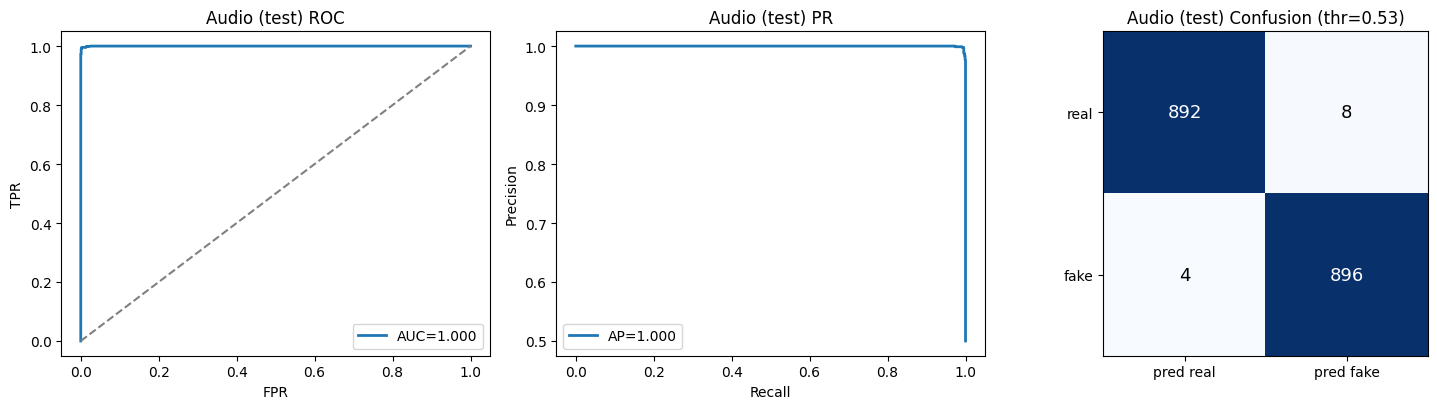

saved /kaggle/working/audio_eval.png

— AUDIO: per-subgroup test breakdown (fake→detection rate, real→reject rate) —
   group class   n   rate  mean_p_fake
   fake?  fake 900 0.9956        0.964
Bonafide  real 896 0.9933        0.057
Loading 6 shield .pt files:
  x_test: tensor (2242, 20, 1024) torch.float32
  x_train: tensor (10458, 20, 1024) torch.float32
  x_val: tensor (2241, 20, 1024) torch.float32
  y_test: tensor (2242,) torch.int64
  y_train: tensor (10458,) torch.int64
  y_val: tensor (2241,) torch.int64
  → train: X=(10458, 20, 1024)
  → val: X=(2241, 20, 1024)
  → test: X=(2242, 20, 1024)
SHIELD: ON
Shield MLP in_dim=20 train=10458 val=2241


RuntimeError: mat1 and mat2 shapes cannot be multiplied (5120x1024 and 20x256)

In [1]:
# Deepfake Detector v5 — Multi-Source (Visual + Audio + Shield)
# Kaggle script. # %% cells. GPU on. Run All (not Save Version).
# New vs v3/v4: single-pass per-dataset discovery, per-subgroup + cross-dataset(holdout) eval, Shield .pt branch.

# %% [markdown]
# # 🧠 Deepfake Detector v5 — Visual + Audio + Shield
#
# Merges the hardened discovery (v3) with the shield branch (v4) and adds a
# **per-subgroup test breakdown** (detection rate per manipulation method / per vocoder).
#
# | Source | Branch |
# |---|---|
# | `ucimachinelearning/.../DFDC_Dataset` (Real/Fake PNG) | visual |
# | `ahmedelbanby/faceforensics++` (frames) | visual |
# | `kamedev/cvoicefake-...-safeear` | audio |
# | `unidpro/real-vs-fake-human-voice` | audio |
# | `aionstreet/shield-2026-features` (.pt) | **shield (MLP on features)** |
# | FF++ `.mp4` | video (optional) |
# | `chuneeb` CSV | skipped (remote image_url) |
#
# **What's new vs v3/v4**
# - **Single-pass, per-source-capped discovery** — one walk per dataset (not 3 over everything), so the 20-min video scan is gone and *every* source is represented (v3 trained on FF++ only because the cap filled before reaching DFDC).
# - **No final full-tree `.pt` walk** — shield files are found in the same pass (that 4th walk was the KeyboardInterrupt hang).
# - **Big-zip skip + progress prints** kept from v3.
# - **Shield branch** (robust multi-format `.pt` loader) from v4.
# - **Class balancing** to the minority before capping.
# - **Light label smoothing** to curb the train/test AUC gap.
# - **Per-subgroup breakdown**: for each FF++ method and each vocoder, the test-set detection rate — shows *which* manipulation is hardest, not just an aggregate.
#
# Run: GPU on. Add datasets. **Run All in the editor** (not Save Version — it buffers output).

# %%
# ── Setup ────────────────────────────────────────────────────────────────────
import sys, subprocess, importlib
def _ensure(pkg, pip_name=None):
    try: importlib.import_module(pkg)
    except Exception: subprocess.run([sys.executable,"-m","pip","install","-q",pip_name or pkg], check=False)
_ensure("timm"); _ensure("librosa"); _ensure("soundfile"); _ensure("cv2","opencv-python-headless")

import os, glob, random, json, time, warnings, collections, zipfile, math
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, confusion_matrix, matthews_corrcoef, balanced_accuracy_score)
import matplotlib.pyplot as plt

SEED=42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE="cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEVICE)
if DEVICE=="cpu": print("⚠️  Turn on the GPU accelerator.")

# %%
# ── Config ───────────────────────────────────────────────────────────────────
class CFG:
    input_root   = "/kaggle/input"
    extract_root = "/kaggle/working/extracted"
    out_dir      = "/kaggle/working"

    per_source_cap = 80_000       # max files/modality pulled from EACH dataset (keeps sources diverse)
    max_visit      = 800_000      # hard cap on files walked per dataset (bounds worst-case time)
    max_zip_mb     = 200          # never auto-extract archives bigger than this

    max_per_class       = 6000    # training pool per class (after balancing)
    max_audio_per_class = 6000
    balance_classes     = True
    val_frac, test_frac = 0.15, 0.15
    label_smooth        = 0.05    # softens targets to curb overfitting

    use_sources_with  = None      # e.g. ["dfdc_dataset"] to use ONLY that source
    drop_sources_with = []        # e.g. ["dfdc_test"] to exclude a mislabeled source
    holdout_source    = None      # e.g. "dfdc_dataset": put ALL of that source in TEST (train on rest)
                                  #   -> honest CROSS-DATASET generalization (train FF++, test DFDC)

    img_size=224; img_backbone="efficientnet_b0"; img_epochs=4; img_batch=64; img_lr=3e-4
    sr=16000; audio_seconds=3.0; n_mels=128; audio_epochs=6; audio_batch=64; audio_lr=1e-3
    shield_epochs=14; shield_batch=256; shield_lr=1e-3; shield_hidden=256
    RUN_VIDEO_MP4=False; video_max_clips=200; video_frames_per_clip=8
    num_workers=2

os.makedirs(CFG.out_dir, exist_ok=True); os.makedirs(CFG.extract_root, exist_ok=True)

def _norm(t): return ''.join(ch for ch in t.lower() if ch.isalnum())
REAL_TOKENS={"real","reals","bonafide","genuine","live","authentic","pristine",
             "original","originals","originalsequences","youtube","actors","commonvoice",
             "celebreal","realsequences"}
FAKE_TOKENS={"fake","fakes","spoof","deepfake","deepfakes","face2face","faceswap",
             "neuraltextures","faceshifter","manipulated","manipulatedsequences",
             "synthetic","parallelwavegan","multibandmelgan","melgan","stylemelgan",
             "griffinlim","world","diffwave","wavegan","uadfv","celebsynthesis","reenactment"}

def label_and_method(p):
    # (label, method_token); method = original folder name that decided the label
    for tok in reversed(p.replace("\\","/").split("/")):
        n=_norm(tok)
        if not n: continue
        if n in REAL_TOKENS or n.startswith("original"): return 0, tok
        if n in FAKE_TOKENS or n.startswith("method"):   return 1, tok
        if n.startswith("real"): return 0, tok
        if n.startswith("fake"): return 1, tok
    low=p.lower()
    if any(k in low for k in ("fake","deepfake","spoof","synthetic","synth","manipulat","uadfv")): return 1,"fake?"
    if any(k in low for k in ("real","genuine","bonafide","original")): return 0,"real?"
    return None, None

def label_from_path(p): return label_and_method(p)[0]

def split_kind(p):
    low="/"+p.lower().replace("\\","/")+"/"
    if any(s in low for s in ("/test/","/testing/","/eval/")): return "test"
    if any(s in low for s in ("/val/","/valid/","/validation/","/dev/")): return "val"
    if any(s in low for s in ("/train/","/training/")): return "train"
    return None

def source_of(p):
    rel=p.replace("\\","/")
    for marker in ("input/datasets/","input/","extracted/"):
        if marker in rel:
            parts=[s for s in rel.split(marker)[-1].strip("/").split("/")]
            return "/".join(parts[:2]) if len(parts)>=2 else (parts[0] if parts else "?")
    return "?"

print("Config ready.")

# %%
# ── Discovery: single-pass, per-source-capped, instrumented, disk-safe ──────
IMG_EXT=(".jpg",".jpeg",".png",".bmp",".webp"); AUD_EXT=(".wav",".flac",".mp3",".ogg",".m4a"); VID_EXT=(".mp4",".avi",".mov",".mkv")

# extract only SMALL zips (never CVoiceFake-Full → would fill the 20GB disk)
zips=[os.path.join(dp,f) for dp,_,fs in os.walk(CFG.input_root) for f in fs if f.lower().endswith(".zip")]
for z in zips:
    mb=os.path.getsize(z)/1e6
    if mb>CFG.max_zip_mb: print(f"skip big zip ({mb:.0f}MB): {z}"); continue
    dest=os.path.join(CFG.extract_root, os.path.splitext(os.path.basename(z))[0])
    if os.path.exists(dest): continue
    try:
        with zipfile.ZipFile(z) as zf: zf.extractall(dest); print("extracted", z)
    except Exception as e: print("zip fail", z, e)

def list_roots():
    roots=[]
    for base in (CFG.input_root, CFG.extract_root):
        if not os.path.isdir(base): continue
        for name in sorted(os.listdir(base)):
            full=os.path.join(base,name)
            if not os.path.isdir(full): continue
            if name=="datasets":                       # /kaggle/input/datasets/<owner>/<slug>
                for owner in sorted(os.listdir(full)):
                    of=os.path.join(full,owner)
                    if os.path.isdir(of):
                        for slug in sorted(os.listdir(of)):
                            sf=os.path.join(of,slug)
                            if os.path.isdir(sf): roots.append(sf)
            else:
                roots.append(full)
    return roots

def discover(roots):
    imgs,auds,vids,pts=[],[],[],[]
    print(f"walking {len(roots)} dataset root(s), cap {CFG.per_source_cap:,}/modality each:")
    for r in roots:
        ci=ca=cv=0; vis=0; t0=time.time()
        for dp,_,files in os.walk(r):
            for f in files:
                vis+=1; fl=f.lower()
                if   fl.endswith(IMG_EXT) and ci<CFG.per_source_cap: imgs.append(os.path.join(dp,f)); ci+=1
                elif fl.endswith(AUD_EXT) and ca<CFG.per_source_cap: auds.append(os.path.join(dp,f)); ca+=1
                elif fl.endswith(VID_EXT) and cv<CFG.per_source_cap: vids.append(os.path.join(dp,f)); cv+=1
                elif fl.endswith(".pt"): pts.append(os.path.join(dp,f))
            if vis>CFG.max_visit: print(f"    (max_visit hit)"); break
        print(f"  {os.path.basename(r):<52} img={ci:>7,} aud={ca:>7,} vid={cv:>6,} ({time.time()-t0:.0f}s)")
    return imgs,auds,vids,sorted(set(pts))

roots=list_roots()
all_imgs,all_auds,all_vids,shield_pts=discover(roots)
print(f"\nTOTAL  images={len(all_imgs):,} audio={len(all_auds):,} videos={len(all_vids):,} shield_pt={len(shield_pts)}")
VIDEO_ON=len(all_imgs)>50; AUDIO_ON=len(all_auds)>50
print(f"VISUAL:{'ON' if VIDEO_ON else 'off'}  AUDIO:{'ON' if AUDIO_ON else 'off'}  "
      f"SHIELD:{'pending' if shield_pts else 'off'}  MP4:{'ON' if (CFG.RUN_VIDEO_MP4 and all_vids) else 'off'}")

# %%
# ── Build tables (with method column) + per-source audit ────────────────────
def keep_path(p):
    low=p.lower()
    if CFG.use_sources_with and not any(s in low for s in CFG.use_sources_with): return False
    if any(s in low for s in CFG.drop_sources_with): return False
    return True

def build_table(paths, cap):
    rows=[]
    for p in paths:
        if not keep_path(p): continue
        y,meth=label_and_method(p)
        if y is None: continue
        rows.append((p,y,meth,split_kind(p),source_of(p)))
    if not rows: return pd.DataFrame(columns=["path","label","method","split","source"])
    df=pd.DataFrame(rows,columns=["path","label","method","split","source"])
    counts={lab:len(g) for lab,g in df.groupby("label")}
    eff=min(cap, min(counts.values())) if CFG.balance_classes else cap
    df=pd.concat([g.sample(frac=1.0,random_state=SEED).head(eff) for _,g in df.groupby("label")]
                 ).sample(frac=1.0,random_state=SEED).reset_index(drop=True)
    if CFG.holdout_source:                       # cross-dataset: all of one source -> test
        mask=df["source"].str.contains(CFG.holdout_source, case=False, regex=False)
        if mask.sum()==0:
            print(f"⚠️ holdout_source '{CFG.holdout_source}' matched 0 rows — using random split")
        else:
            df["split"]="train"; df.loc[mask,"split"]="test"
            rest=df[~mask]
            for lab,g in rest.groupby("label"):
                idx=g.index.tolist(); nv=int(len(idx)*CFG.val_frac); df.loc[idx[:nv],"split"]="val"
            print(f"holdout='{CFG.holdout_source}': test={int(mask.sum())} (held-out source), train/val from rest")
            return df
    has=df["split"].notna().mean()>0.6 and df["split"].nunique()>=2
    if not has:
        df["split"]=None
        for lab,g in df.groupby("label"):
            idx=g.index.tolist(); n=len(idx); nt=int(n*CFG.test_frac); nv=int(n*CFG.val_frac)
            df.loc[idx[:nt],"split"]="test"; df.loc[idx[nt:nt+nv],"split"]="val"; df.loc[idx[nt+nv:],"split"]="train"
    elif (df["split"]=="val").sum()==0:
        tr=df[df["split"]=="train"]; df.loc[tr.sample(frac=CFG.val_frac,random_state=SEED).index,"split"]="val"
    return df

def audit(paths,name):
    rec=collections.defaultdict(lambda:[0,0,0])
    for p in paths:
        if not keep_path(p): continue
        y=label_from_path(p); rec[source_of(p)][2 if y is None else y]+=1
    print(f"\n=== {name} per-source audit (real / fake / dropped) ===")
    for s,(r,f,n) in sorted(rec.items()):
        flag=" ⚠️ one-class" if (r==0 or f==0) else ""
        print(f"  {s:<55} real={r:>7,} fake={f:>7,} drop={n:>7,}{flag}")

if VIDEO_ON: audit(all_imgs,"VISUAL")
if AUDIO_ON: audit(all_auds,"AUDIO")

img_df=build_table(all_imgs,CFG.max_per_class) if VIDEO_ON else pd.DataFrame()
aud_df=build_table(all_auds,CFG.max_audio_per_class) if AUDIO_ON else pd.DataFrame()

def summarize(df,name):
    if len(df)==0: print(f"\n{name}: (none)"); return
    print(f"\n{name}: {len(df):,} used (balanced={CFG.balance_classes})")
    print(pd.crosstab(df["split"],df["label"].map({0:'real',1:'fake'}),margins=True))
    print("  methods:", dict(df["method"].value_counts().head(8)))
summarize(img_df,"VISUAL"); summarize(aud_df,"AUDIO")

if VIDEO_ON and img_df["label"].nunique()<2: print("\n⚠️ visual single-class → off"); VIDEO_ON=False
if AUDIO_ON and aud_df["label"].nunique()<2: print("\n⚠️ audio single-class → off"); AUDIO_ON=False

# %%
# ── Metrics + plots + per-subgroup breakdown ────────────────────────────────
def eer_of(y,p):
    fpr,tpr,_=roc_curve(y,p); fnr=1-tpr; i=np.nanargmin(np.abs(fnr-fpr)); return float((fpr[i]+fnr[i])/2)
def best_f1_thr(y,p):
    pr,rc,th=precision_recall_curve(y,p); f1=2*pr*rc/(pr+rc+1e-12)
    return 0.5 if len(th)==0 else float(th[np.nanargmax(f1[:-1])])

def compute_metrics(y,p,threshold=None):
    y=np.asarray(y).astype(int); p=np.asarray(p).astype(float)
    thr=best_f1_thr(y,p) if threshold is None else threshold
    yp=(p>=thr).astype(int); tn,fp,fn,tp=confusion_matrix(y,yp,labels=[0,1]).ravel(); e=1e-12
    prec=tp/(tp+fp+e); rec=tp/(tp+fn+e); spec=tn/(tn+fp+e); f1=2*prec*rec/(prec+rec+e)
    acc=(tp+tn)/(tp+tn+fp+fn+e)
    try: auc=roc_auc_score(y,p)
    except: auc=float('nan')
    try: ap=average_precision_score(y,p)
    except: ap=float('nan')
    return {"accuracy":acc,"balanced_acc":balanced_accuracy_score(y,yp),"precision":prec,
            "recall":rec,"specificity":spec,"f1":f1,"roc_auc":auc,"pr_auc":ap,
            "mcc":matthews_corrcoef(y,yp) if len(set(yp))>1 else 0.0,"eer":eer_of(y,p),
            "threshold":thr,"TP":int(tp),"FP":int(fp),"TN":int(tn),"FN":int(fn),"n":int(len(y))}

def print_metrics(name,m):
    print(f"\n── {name} ──  (n={m['n']}, thr={m['threshold']:.3f})")
    for k in ["accuracy","balanced_acc","precision","recall","specificity","f1","roc_auc","pr_auc","mcc","eer"]:
        print(f"   {k:<14}: {m[k]:.4f}")
    print(f"   confusion      : TP={m['TP']} FP={m['FP']} TN={m['TN']} FN={m['FN']}")

def plot_eval(name,y,p,m,prefix):
    y=np.asarray(y); p=np.asarray(p); fig,ax=plt.subplots(1,3,figsize=(15,4.2))
    fpr,tpr,_=roc_curve(y,p); ax[0].plot(fpr,tpr,lw=2,label=f"AUC={m['roc_auc']:.3f}")
    ax[0].plot([0,1],[0,1],"--",c="gray"); ax[0].set_title(f"{name} ROC"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend(loc="lower right")
    pr,rc,_=precision_recall_curve(y,p); ax[1].plot(rc,pr,lw=2,label=f"AP={m['pr_auc']:.3f}")
    ax[1].set_title(f"{name} PR"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend(loc="lower left")
    cm=np.array([[m['TN'],m['FP']],[m['FN'],m['TP']]]); ax[2].imshow(cm,cmap="Blues")
    ax[2].set_xticks([0,1]); ax[2].set_yticks([0,1]); ax[2].set_xticklabels(["pred real","pred fake"]); ax[2].set_yticklabels(["real","fake"])
    for (i,j),v in np.ndenumerate(cm): ax[2].text(j,i,str(v),ha="center",va="center",color="white" if v>cm.max()/2 else "black",fontsize=13)
    ax[2].set_title(f"{name} Confusion (thr={m['threshold']:.2f})"); plt.tight_layout()
    out=os.path.join(CFG.out_dir,f"{prefix}_eval.png"); plt.savefig(out,dpi=110,bbox_inches="tight"); plt.show(); print("saved",out)

def subgroup_report(d, probs, thr, name, prefix):
    # per-method detection (fakes) / correct-reject (reals) on the test split
    dd=d.copy(); dd["prob"]=np.asarray(probs); dd["pred"]=(dd["prob"]>=thr).astype(int)
    rows=[]
    for (lab,meth),g in dd.groupby(["label","method"]):
        n=len(g)
        if n<5: continue
        rate=(g["pred"]==1).mean() if lab==1 else (g["pred"]==0).mean()
        rows.append({"group":meth,"class":"fake" if lab==1 else "real",
                     "n":n,"rate":round(float(rate),4),"mean_p_fake":round(float(g['prob'].mean()),4)})
    if not rows: return None
    rep=pd.DataFrame(rows).sort_values(["class","n"],ascending=[True,False])
    print(f"\n— {name}: per-subgroup test breakdown (fake→detection rate, real→reject rate) —")
    print(rep.to_string(index=False))
    rep.to_csv(os.path.join(CFG.out_dir,f"{prefix}_subgroups.csv"),index=False)
    return rep
print("Metrics ready.")

# %%
# ── VISUAL: dataset + EfficientNet-B0 ───────────────────────────────────────
import timm
from PIL import Image
import torchvision.transforms as T
NORM=([0.485,0.456,0.406],[0.229,0.224,0.225])
train_tf=T.Compose([T.Resize((CFG.img_size,)*2),T.RandomHorizontalFlip(),T.ColorJitter(0.1,0.1,0.1),T.ToTensor(),T.Normalize(*NORM),T.RandomErasing(p=0.25)])
eval_tf =T.Compose([T.Resize((CFG.img_size,)*2),T.ToTensor(),T.Normalize(*NORM)])
class ImgDS(Dataset):
    def __init__(s,df,tf): s.p=df["path"].tolist(); s.y=df["label"].tolist(); s.tf=tf
    def __len__(s): return len(s.p)
    def __getitem__(s,i):
        try: im=Image.open(s.p[i]).convert("RGB")
        except: im=Image.new("RGB",(CFG.img_size,)*2)
        return s.tf(im), torch.tensor(s.y[i],dtype=torch.float32)
def iloader(df,tf,bs,sh): return DataLoader(ImgDS(df,tf),batch_size=bs,shuffle=sh,num_workers=CFG.num_workers,pin_memory=True)
class ImgNet(nn.Module):
    def __init__(s,b): super().__init__(); s.net=timm.create_model(b,pretrained=True,num_classes=1)
    def forward(s,x): return s.net(x).squeeze(1)
def smooth(y): return y*(1-CFG.label_smooth)+0.5*CFG.label_smooth
print("Visual ready." if VIDEO_ON else "Visual off.")

# %%
# ── VISUAL: train ───────────────────────────────────────────────────────────
@torch.no_grad()
def infer_img(model,loader):
    model.eval(); P,Y=[],[]
    for x,y in loader:
        x=x.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): p=torch.sigmoid(model(x))
        P.append(p.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(P)
img_model=None
if VIDEO_ON:
    tr=img_df[img_df.split=="train"]; va=img_df[img_df.split=="val"]
    tl=iloader(tr,train_tf,CFG.img_batch,True); vl=iloader(va,eval_tf,CFG.img_batch,False)
    img_model=ImgNet(CFG.img_backbone).to(DEVICE)
    opt=torch.optim.AdamW(img_model.parameters(),lr=CFG.img_lr,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=CFG.img_epochs*max(1,len(tl)))
    sc=torch.cuda.amp.GradScaler(enabled=DEVICE=="cuda"); lf=nn.BCEWithLogitsLoss()
    best=-1; bs=None
    for ep in range(CFG.img_epochs):
        img_model.train(); t0=time.time(); run=0
        for x,y in tl:
            x,y=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True); opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): loss=lf(img_model.net(x).squeeze(1),smooth(y))
            sc.scale(loss).backward(); sc.step(opt); sc.update(); sch.step(); run+=loss.item()*len(x)
        yv,pv=infer_img(img_model,vl)
        try: auc=roc_auc_score(yv,pv)
        except: auc=float('nan')
        print(f"  epoch {ep+1}/{CFG.img_epochs} loss={run/len(tr):.4f} val_auc={auc:.4f} ({time.time()-t0:.0f}s)")
        if auc>best: best=auc; bs={k:v.detach().cpu().clone() for k,v in img_model.state_dict().items()}
    if bs: img_model.load_state_dict(bs)
    torch.save(img_model.state_dict(),os.path.join(CFG.out_dir,"visual_model.pt"))
    print(f"Visual done. best val AUC={best:.4f}")
else: print("Visual off.")

# %%
# ── VISUAL: evaluate + per-subgroup ─────────────────────────────────────────
visual_results={}
if VIDEO_ON and img_model is not None:
    yv,pv=infer_img(img_model,iloader(img_df[img_df.split=="val"],eval_tf,CFG.img_batch,False))
    locked=best_f1_thr(yv,pv)
    for sp in ["train","val","test"]:
        d=img_df[img_df.split==sp]
        if len(d)==0: continue
        yy,pp=infer_img(img_model,iloader(d,eval_tf,CFG.img_batch,False))
        m=compute_metrics(yy,pp,threshold=None if sp=="val" else locked)
        visual_results[sp]=m; print_metrics(f"VISUAL [{sp}]",m)
        if sp=="test":
            plot_eval("Visual (test)",yy,pp,m,"visual")
            subgroup_report(d,pp,locked,"VISUAL","visual")
else: print("Visual off — no metrics.")

# %%
# ── AUDIO: log-mel dataset + CNN ────────────────────────────────────────────
import librosa
TLEN=int(CFG.sr*CFG.audio_seconds)
def logmel(path):
    try: y,_=librosa.load(path,sr=CFG.sr,mono=True)
    except: y=np.zeros(TLEN,dtype=np.float32)
    y=np.pad(y,(0,TLEN-len(y))) if len(y)<TLEN else y[:TLEN]
    mel=librosa.feature.melspectrogram(y=y,sr=CFG.sr,n_mels=CFG.n_mels,n_fft=1024,hop_length=256)
    mel=librosa.power_to_db(mel,ref=np.max); mel=(mel-mel.mean())/(mel.std()+1e-6)
    return mel.astype(np.float32)
class AudDS(Dataset):
    def __init__(s,df): s.p=df["path"].tolist(); s.y=df["label"].tolist()
    def __len__(s): return len(s.p)
    def __getitem__(s,i): return torch.from_numpy(logmel(s.p[i])).unsqueeze(0), torch.tensor(s.y[i],dtype=torch.float32)
def aloader(df,bs,sh): return DataLoader(AudDS(df),batch_size=bs,shuffle=sh,num_workers=CFG.num_workers,pin_memory=True)
class AudioCNN(nn.Module):
    def __init__(s):
        super().__init__()
        def blk(ci,co): return nn.Sequential(nn.Conv2d(ci,co,3,padding=1),nn.BatchNorm2d(co),nn.ReLU(),nn.MaxPool2d(2))
        s.feat=nn.Sequential(blk(1,16),blk(16,32),blk(32,64),blk(64,128))
        s.head=nn.Sequential(nn.AdaptiveAvgPool2d(1),nn.Flatten(),nn.Dropout(0.3),nn.Linear(128,1))
    def forward(s,x): return s.head(s.feat(x)).squeeze(1)
print("Audio ready." if AUDIO_ON else "Audio off.")

# %%
# ── AUDIO: train ────────────────────────────────────────────────────────────
@torch.no_grad()
def infer_aud(model,loader):
    model.eval(); P,Y=[],[]
    for x,y in loader:
        x=x.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): p=torch.sigmoid(model(x))
        P.append(p.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(P)
aud_model=None
if AUDIO_ON:
    tr=aud_df[aud_df.split=="train"]; va=aud_df[aud_df.split=="val"]
    tl=aloader(tr,CFG.audio_batch,True); vl=aloader(va,CFG.audio_batch,False)
    aud_model=AudioCNN().to(DEVICE)
    opt=torch.optim.AdamW(aud_model.parameters(),lr=CFG.audio_lr,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=CFG.audio_epochs*max(1,len(tl)))
    sc=torch.cuda.amp.GradScaler(enabled=DEVICE=="cuda"); lf=nn.BCEWithLogitsLoss()
    best=-1; bsd=None
    for ep in range(CFG.audio_epochs):
        aud_model.train(); t0=time.time(); run=0
        for x,y in tl:
            x,y=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True); opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): loss=lf(aud_model(x),smooth(y))
            sc.scale(loss).backward(); sc.step(opt); sc.update(); sch.step(); run+=loss.item()*len(x)
        yv,pv=infer_aud(aud_model,vl)
        try: auc=roc_auc_score(yv,pv)
        except: auc=float('nan')
        print(f"  epoch {ep+1}/{CFG.audio_epochs} loss={run/len(tr):.4f} val_auc={auc:.4f} ({time.time()-t0:.0f}s)")
        if auc>best: best=auc; bsd={k:v.detach().cpu().clone() for k,v in aud_model.state_dict().items()}
    if bsd: aud_model.load_state_dict(bsd)
    torch.save(aud_model.state_dict(),os.path.join(CFG.out_dir,"audio_model.pt"))
    print(f"Audio done. best val AUC={best:.4f}")
else: print("Audio off.")

# %%
# ── AUDIO: evaluate + per-subgroup (per vocoder) ────────────────────────────
audio_results={}
if AUDIO_ON and aud_model is not None:
    yv,pv=infer_aud(aud_model,aloader(aud_df[aud_df.split=="val"],CFG.audio_batch,False))
    locked=best_f1_thr(yv,pv)
    for sp in ["train","val","test"]:
        d=aud_df[aud_df.split==sp]
        if len(d)==0: continue
        yy,pp=infer_aud(aud_model,aloader(d,CFG.audio_batch,False))
        m=compute_metrics(yy,pp,threshold=None if sp=="val" else locked)
        audio_results[sp]=m; print_metrics(f"AUDIO [{sp}]",m)
        if sp=="test":
            plot_eval("Audio (test)",yy,pp,m,"audio")
            subgroup_report(d,pp,locked,"AUDIO","audio")
else: print("Audio off — no metrics.")

# %%
# ── SHIELD: robust multi-format .pt loader (ported from v4) ─────────────────
def load_shield_splits(pts):
    if not pts: return None
    print(f"Loading {len(pts)} shield .pt files:")
    loaded={}
    for p in pts:
        name=os.path.splitext(os.path.basename(p))[0].lower()
        try:
            obj=torch.load(p,map_location="cpu",weights_only=False)
            if torch.is_tensor(obj): print(f"  {name}: tensor {tuple(obj.shape)} {obj.dtype}")
            elif isinstance(obj,dict): print(f"  {name}: dict keys={list(obj.keys())[:10]}")
            else: print(f"  {name}: {type(obj).__name__}")
            loaded[name]=obj
        except Exception as e: print(f"  {name}: FAILED — {e}")
    X_MARKS=("x","features","feat","emb","embedding","data"); Y_MARKS=("y","label","labels","target","targets","gt")
    def to_long(t):
        return t.long() if (t.is_floating_point() and float(t.max())<=1) else t.long()
    # 1: separate files per split
    sd={}
    for split in ("train","val","validation","dev","test"):
        xk=next((k for k in loaded if split in k and torch.is_tensor(loaded[k]) and loaded[k].ndim>=2
                 and any(k.startswith(m) or f"_{m}" in k for m in X_MARKS)),None)
        yk=next((k for k in loaded if split in k and torch.is_tensor(loaded[k])
                 and any(k.startswith(m) or f"_{m}" in k for m in Y_MARKS)),None)
        if xk and yk:
            sp="val" if split in ("validation","dev") else split
            sd[sp]=(loaded[xk].float(),to_long(loaded[yk])); print(f"  → {sp}: X={tuple(loaded[xk].shape)}")
    if len(sd)>=2: return sd
    # 2: single dict with X_train etc.
    for obj in loaded.values():
        if not isinstance(obj,dict): continue
        for split in ("train","val","validation","test"):
            xk=next((k for k in obj if split in k.lower() and any(m in k.lower() for m in X_MARKS) and torch.is_tensor(obj[k])),None)
            yk=next((k for k in obj if split in k.lower() and any(m in k.lower() for m in Y_MARKS) and torch.is_tensor(obj[k])),None)
            if xk and yk:
                sp="val" if split=="validation" else split
                sd[sp]=(obj[xk].float(),to_long(obj[yk])); print(f"  → {sp}: X={tuple(obj[xk].shape)}")
        if sd: return sd
    # 3: two tensors (2-D feats + 1-D labels) → auto-split
    tens={k:v for k,v in loaded.items() if torch.is_tensor(v)}
    if len(tens)==2:
        (n1,t1),(n2,t2)=list(tens.items())
        X=y=None
        if t1.ndim>=2 and t2.ndim==1: X,y=t1.float(),t2
        elif t2.ndim>=2 and t1.ndim==1: X,y=t2.float(),t1
        if X is not None:
            y=to_long(y); n=len(X); nt=int(n*CFG.test_frac); nv=int(n*CFG.val_frac)
            pm=torch.randperm(n,generator=torch.Generator().manual_seed(SEED))
            return {"test":(X[pm[:nt]],y[pm[:nt]]),"val":(X[pm[nt:nt+nv]],y[pm[nt:nt+nv]]),"train":(X[pm[nt+nv:]],y[pm[nt+nv:]])}
    # 4: single (N, D+1) tensor, last col = label
    for obj in loaded.values():
        if torch.is_tensor(obj) and obj.ndim==2 and obj.shape[1]>1:
            X=obj[:,:-1].float(); y=obj[:,-1].long(); n=len(X); nt=int(n*CFG.test_frac); nv=int(n*CFG.val_frac)
            pm=torch.randperm(n,generator=torch.Generator().manual_seed(SEED))
            return {"test":(X[pm[:nt]],y[pm[:nt]]),"val":(X[pm[nt:nt+nv]],y[pm[nt:nt+nv]]),"train":(X[pm[nt+nv:]],y[pm[nt+nv:]])}
    print("⚠️ Shield .pt format not recognized — check shapes above and extend load_shield_splits().")
    return None

shield_splits=load_shield_splits(shield_pts)
SHIELD_ON=shield_splits is not None and len(shield_splits)>=2
if SHIELD_ON:
    ally=torch.cat([y for _,y in shield_splits.values()])
    if len(ally.unique())<2: print("⚠️ shield single-class → off"); SHIELD_ON=False
print(f"SHIELD: {'ON' if SHIELD_ON else 'off'}")

# %%
# ── SHIELD: MLP train + evaluate ────────────────────────────────────────────
class ShieldDS(Dataset):
    def __init__(s,X,y): s.X=X.float(); s.y=y.float()
    def __len__(s): return len(s.X)
    def __getitem__(s,i): return s.X[i], s.y[i]
class ShieldMLP(nn.Module):
    def __init__(s,d,h=256):
        super().__init__()
        s.net=nn.Sequential(nn.Linear(d,h),nn.LayerNorm(h),nn.GELU(),nn.Dropout(0.3),
                            nn.Linear(h,h//2),nn.LayerNorm(h//2),nn.GELU(),nn.Dropout(0.2),nn.Linear(h//2,1))
    def forward(s,x): return s.net(x).squeeze(1)
@torch.no_grad()
def infer_shield(model,loader):
    model.eval(); P,Y=[],[]
    for x,y in loader:
        x=x.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): p=torch.sigmoid(model(x))
        P.append(p.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(P)

shield_results={}; shield_model=None
if SHIELD_ON:
    Xtr,ytr=shield_splits["train"]; Xva,yva=shield_splits.get("val",(None,None))
    if Xva is None:
        n=len(Xtr); nv=int(n*CFG.val_frac); pm=torch.randperm(n,generator=torch.Generator().manual_seed(SEED))
        Xva,yva=Xtr[pm[:nv]],ytr[pm[:nv]]; Xtr,ytr=Xtr[pm[nv:]],ytr[pm[nv:]]
    d=Xtr.shape[1]; print(f"Shield MLP in_dim={d} train={len(Xtr)} val={len(Xva)}")
    tl=DataLoader(ShieldDS(Xtr,ytr),batch_size=CFG.shield_batch,shuffle=True)
    vl=DataLoader(ShieldDS(Xva,yva),batch_size=CFG.shield_batch,shuffle=False)
    shield_model=ShieldMLP(d,CFG.shield_hidden).to(DEVICE)
    opt=torch.optim.AdamW(shield_model.parameters(),lr=CFG.shield_lr,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=CFG.shield_epochs*max(1,len(tl)))
    sc=torch.cuda.amp.GradScaler(enabled=DEVICE=="cuda"); lf=nn.BCEWithLogitsLoss()
    best=-1; bsd=None
    for ep in range(CFG.shield_epochs):
        shield_model.train(); t0=time.time(); run=0
        for x,y in tl:
            x,y=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True); opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): loss=lf(shield_model(x),smooth(y))
            sc.scale(loss).backward(); sc.step(opt); sc.update(); sch.step(); run+=loss.item()*len(x)
        yv,pv=infer_shield(shield_model,vl)
        try: auc=roc_auc_score(yv,pv)
        except: auc=float('nan')
        print(f"  epoch {ep+1}/{CFG.shield_epochs} loss={run/len(Xtr):.4f} val_auc={auc:.4f} ({time.time()-t0:.0f}s)")
        if auc>best: best=auc; bsd={k:v.detach().cpu().clone() for k,v in shield_model.state_dict().items()}
    if bsd: shield_model.load_state_dict(bsd)
    torch.save(shield_model.state_dict(),os.path.join(CFG.out_dir,"shield_model.pt"))
    print(f"Shield done. best val AUC={best:.4f}")
    vX,vy=shield_splits.get("val",(Xva,yva))
    yv2,pv2=infer_shield(shield_model,DataLoader(ShieldDS(vX,vy),batch_size=CFG.shield_batch))
    locked=best_f1_thr(yv2,pv2)
    for sp in ["train","val","test"]:
        if sp not in shield_splits: continue
        Xs,ys=shield_splits[sp]
        yy,pp=infer_shield(shield_model,DataLoader(ShieldDS(Xs,ys),batch_size=CFG.shield_batch))
        m=compute_metrics(yy,pp,threshold=None if sp=="val" else locked)
        shield_results[sp]=m; print_metrics(f"SHIELD [{sp}]",m)
        if sp=="test": plot_eval("Shield (test)",yy,pp,m,"shield")
else: print("Shield off — no metrics.")

# %%
# ── OPTIONAL: clip-level VIDEO eval on FF++ .mp4 (CFG.RUN_VIDEO_MP4=True) ────
video_results={}
if CFG.RUN_VIDEO_MP4 and img_model is not None and all_vids:
    import cv2
    clips=[(p,label_from_path(p)) for p in all_vids if label_from_path(p) is not None]
    random.Random(SEED).shuffle(clips); clips=clips[:CFG.video_max_clips]
    def frames_of(path,k):
        cap=cv2.VideoCapture(path); tot=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0
        idx=np.linspace(0,max(tot-1,0),k).astype(int) if tot>0 else list(range(k)); out=[]
        for i in idx:
            cap.set(cv2.CAP_PROP_POS_FRAMES,int(i)); ok,fr=cap.read()
            if ok: out.append(eval_tf(Image.fromarray(cv2.cvtColor(fr,cv2.COLOR_BGR2RGB))))
        cap.release(); return out
    yv,pv=[],[]; img_model.eval()
    for j,(p,lab) in enumerate(clips):
        fr=frames_of(p,CFG.video_frames_per_clip)
        if not fr: continue
        with torch.no_grad(), torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
            pr=torch.sigmoid(img_model(torch.stack(fr).to(DEVICE))).float().mean().item()
        yv.append(lab); pv.append(pr)
        if (j+1)%50==0: print(f"  scored {j+1}/{len(clips)}")
    if len(set(yv))>1:
        m=compute_metrics(yv,pv); video_results["clip_test"]=m
        print_metrics("VIDEO clip-level",m); plot_eval("Video clips",yv,pv,m,"video")
    else: print("video single class — skipped")
else: print("MP4 clip-eval off (set CFG.RUN_VIDEO_MP4=True).")

# %%
# ── Final summary + ZIP download ────────────────────────────────────────────
rows=[]
for br,res in [("visual",visual_results),("audio",audio_results),("shield",shield_results),("video",video_results)]:
    for sp,m in res.items():
        rows.append({"branch":br,"split":sp,**{k:round(m[k],4) for k in
            ["accuracy","precision","recall","specificity","f1","roc_auc","pr_auc","mcc","eer"]},"n":m["n"]})
summary=pd.DataFrame(rows)
if len(summary):
    summary=summary[["branch","split","accuracy","precision","recall","specificity","f1","roc_auc","pr_auc","mcc","eer","n"]]
    print("\n================ FINAL METRICS ================\n"); print(summary.to_string(index=False))
    summary.to_csv(os.path.join(CFG.out_dir,"metrics_summary.csv"),index=False)
    with open(os.path.join(CFG.out_dir,"metrics_full.json"),"w") as f:
        json.dump({"visual":visual_results,"audio":audio_results,"shield":shield_results,"video":video_results},f,indent=2)
    print("\nSaved → metrics_summary.csv, metrics_full.json, *_eval.png, *_subgroups.csv, *_model.pt")
else: print("No results — check the per-source audit and dataset mounts.")

# bundle everything for download
from datetime import datetime
ZIP=os.path.join(CFG.out_dir,f"deepfake_results_{datetime.now().strftime('%Y%m%d_%H%M%S')}.zip")
EXCLUDE_MODELS=False
try:
    with zipfile.ZipFile(ZIP,'w',zipfile.ZIP_DEFLATED) as zf:
        tot=cnt=0
        for folder,pats in [("metrics",["metrics_summary.csv","metrics_full.json"]),
                            ("subgroups",["*_subgroups.csv"]),
                            ("plots",["*_eval.png"]),
                            ("models",["visual_model.pt","audio_model.pt","shield_model.pt","video_model.pt"])]:
            if folder=="models" and EXCLUDE_MODELS: continue
            for pat in pats:
                for fp in glob.glob(os.path.join(CFG.out_dir,pat)):
                    if os.path.isfile(fp):
                        zf.write(fp,f"{folder}/{os.path.basename(fp)}"); sz=os.path.getsize(fp)/1e6; tot+=sz; cnt+=1
                        print(f"  ✓ {folder}/{os.path.basename(fp):42s} {sz:>7.1f} MB")
    print(f"\n✓ {os.path.basename(ZIP)}  ({cnt} files, {os.path.getsize(ZIP)/1e6:.1f} MB)")
    print(f"Download: Output panel → {os.path.basename(ZIP)}")
except Exception as e:
    print("zip failed:", e)
summary

torch 2.10.0+cu128 | device: cuda
Config ready.
walking 5 dataset root(s), cap 80,000/modality each:
  shield-2026-features-master2                         img=      0 aud=      0 vid=     0 (0s)
  deepfake-detection-dataset-2026                      img=      0 aud=      0 vid=     0 (0s)
    (max_visit hit)
  cvoicefake-full-safeear-dataset-mirror               img=      0 aud= 80,000 vid=     0 (848s)
  deep-fake-detection-cropped-dataset                  img=      0 aud=      0 vid= 3,293 (2s)
  real-vs-fake-human-voice-deepfake-audio              img=      0 aud=     80 vid=     0 (0s)

TOTAL  images=0 audio=80,080 videos=3,293 shield_pt=6
VISUAL:off  AUDIO:ON  SHIELD:pending  MP4:off
VISUAL-from-VIDEO: sampling 6 frames from 2200 clips (per class=1100)...
  200/2200 clips, 1,200 frames (4s)
  400/2200 clips, 2,400 frames (7s)
  600/2200 clips, 3,600 frames (11s)
  800/2200 clips, 4,800 frames (14s)
  1000/2200 clips, 6,000 frames (18s)
  1200/2200 clips, 7,200 frames (21s)
  1400

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

  epoch 1/4 loss=1.2487 val_auc=0.8371 (55s)
  epoch 2/4 loss=0.5070 val_auc=0.8848 (28s)
  epoch 3/4 loss=0.3214 val_auc=0.9018 (28s)
  epoch 4/4 loss=0.2731 val_auc=0.8975 (29s)
Visual done. best val AUC=0.9018

── VISUAL [train] ──  (n=8372, thr=0.393)
   accuracy      : 0.9673
   balanced_acc  : 0.9672
   precision     : 0.9546
   recall        : 0.9817
   specificity   : 0.9526
   f1            : 0.9680
   roc_auc       : 0.9956
   pr_auc        : 0.9957
   mcc           : 0.9349
   eer           : 0.0312
   confusion      : TP=4142 FP=197 TN=3956 FN=77

── VISUAL [val] ──  (n=1816, thr=0.393)
   accuracy      : 0.8260
   balanced_acc  : 0.8272
   precision     : 0.7944
   recall        : 0.8648
   specificity   : 0.7895
   f1            : 0.8281
   roc_auc       : 0.9018
   pr_auc        : 0.8888
   mcc           : 0.6550
   eer           : 0.1757
   confusion      : TP=761 FP=197 TN=739 FN=119

── VISUAL [test] ──  (n=1812, thr=0.393)
   accuracy      : 0.8157
   balanced_acc  :

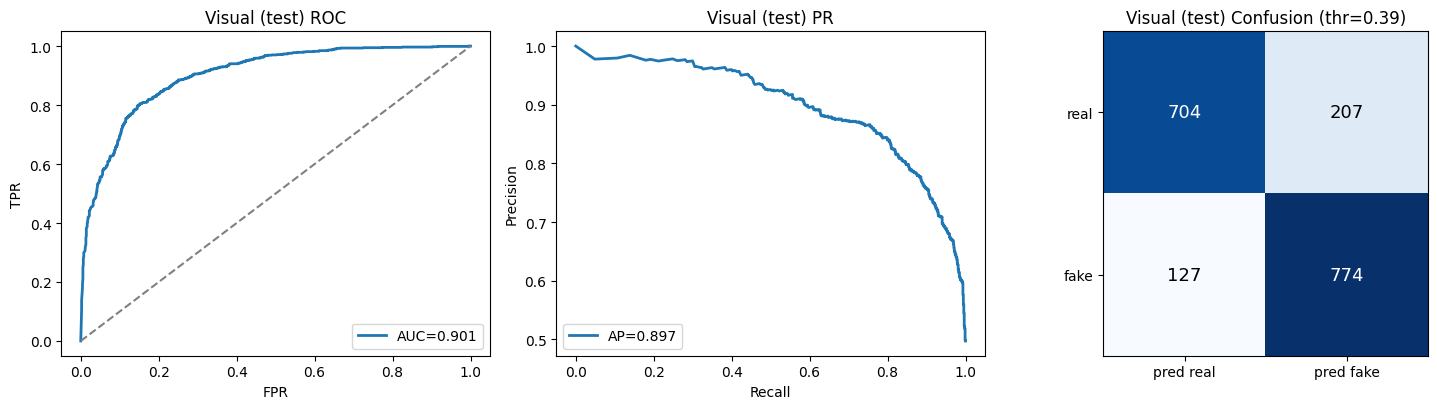

saved /kaggle/working/visual_eval.png

— VISUAL: per-subgroup test breakdown (fake→detection rate, real→reject rate) —
group class   n   rate  mean_p_fake
 fake  fake 901 0.8590       0.7969
 real  real 911 0.7728       0.2145
Audio ready.
  epoch 1/6 loss=0.3012 val_auc=0.9977 (201s)
  epoch 2/6 loss=0.1774 val_auc=0.9998 (200s)
  epoch 3/6 loss=0.1586 val_auc=0.9999 (197s)
  epoch 4/6 loss=0.1521 val_auc=1.0000 (197s)
  epoch 5/6 loss=0.1471 val_auc=1.0000 (204s)
  epoch 6/6 loss=0.1437 val_auc=1.0000 (197s)
Audio done. best val AUC=1.0000

── AUDIO [train] ──  (n=8400, thr=0.481)
   accuracy      : 0.9985
   balanced_acc  : 0.9985
   precision     : 0.9986
   recall        : 0.9983
   specificity   : 0.9986
   f1            : 0.9985
   roc_auc       : 1.0000
   pr_auc        : 1.0000
   mcc           : 0.9969
   eer           : 0.0018
   confusion      : TP=4193 FP=6 TN=4194 FN=7

── AUDIO [val] ──  (n=1800, thr=0.481)
   accuracy      : 0.9978
   balanced_acc  : 0.9978
   precision

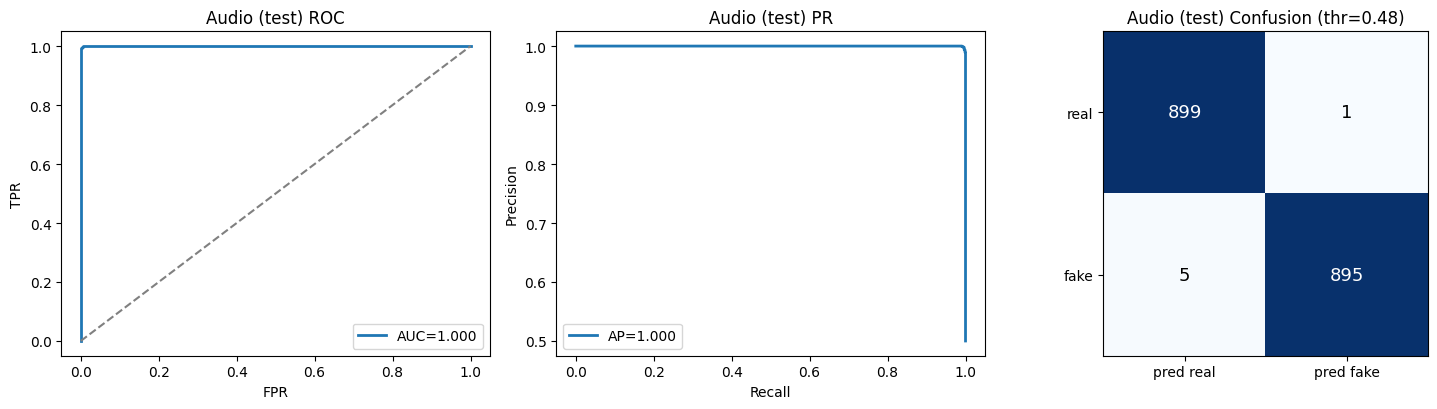

saved /kaggle/working/audio_eval.png

— AUDIO: per-subgroup test breakdown (fake→detection rate, real→reject rate) —
          group class   n   rate  mean_p_fake
       diffwave  fake 784 1.0000       0.9654
parallelwavegan  fake 116 0.9569       0.8496
       Bonafide  real 896 0.9989       0.0295
AUDIO score interpretation (read before trusting ~0.999 AUC / ~0.5% EER):
  CVoiceFake = CommonVoice REAL vs 6 vocoders. A CNN can latch onto the
  vocoder/codec fingerprint rather than genuine 'is-this-synthetic' cues,
  so in-distribution numbers look near-perfect but DON'T prove generalization.
  HONEST tests:
    leave-one-vocoder-out : set CFG.holdout_method='diffwave' and re-run
                            (train on 5 vocoders, test on the unseen 6th)
    cross-corpus          : set CFG.holdout_source to a different audio source
  Reference (SafeEar, ACM CCS'24, SAME CVoiceFake data): ~2.02%% EER avg.
Loading 6 shield .pt files:
  x_test: tensor (2242, 20, 1024) torch.float32
  x_trai

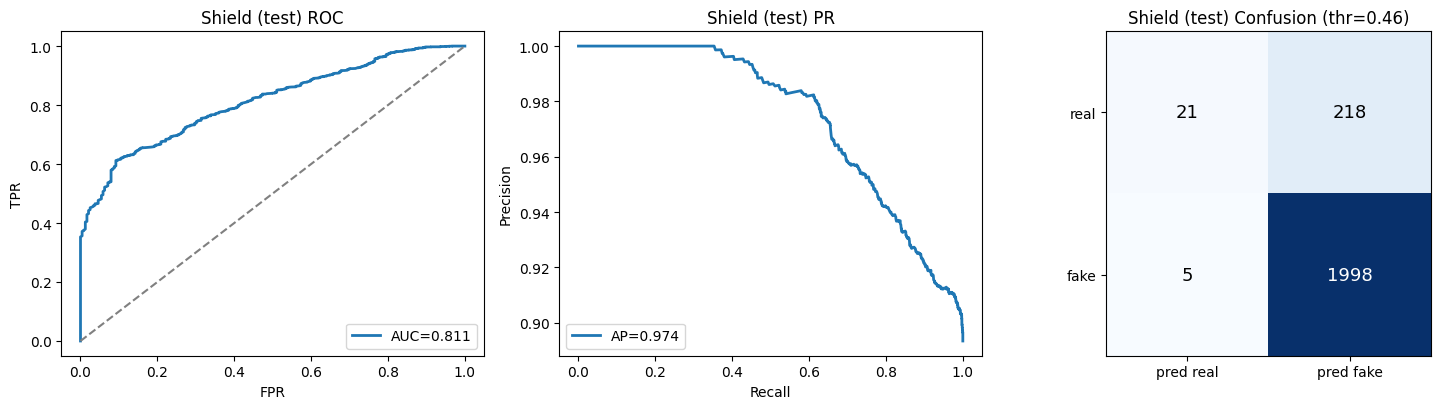

saved /kaggle/working/shield_eval.png
MP4 clip-eval off (set CFG.RUN_VIDEO_MP4=True).

================ FINAL METRICS ================

branch split  accuracy  precision  recall  specificity     f1  roc_auc  pr_auc    mcc    eer     n
visual train    0.9673     0.9546  0.9817       0.9526 0.9680   0.9956  0.9957 0.9349 0.0312  8372
visual   val    0.8260     0.7944  0.8648       0.7895 0.8281   0.9018  0.8888 0.6550 0.1757  1816
visual  test    0.8157     0.7890  0.8590       0.7728 0.8225   0.9014  0.8972 0.6340 0.1788  1812
 audio train    0.9985     0.9986  0.9983       0.9986 0.9985   1.0000  1.0000 0.9969 0.0018  8400
 audio   val    0.9978     0.9956  1.0000       0.9956 0.9978   1.0000  1.0000 0.9956 0.0039  1800
 audio  test    0.9967     0.9989  0.9944       0.9989 0.9967   1.0000  1.0000 0.9933 0.0028  1800
shield train    0.9004     0.9020  0.9968       0.0899 0.9470   0.8875  0.9853 0.2413 0.2067 10458
shield   val    0.8996     0.9008  0.9975       0.0756 0.9467   0.8078  

,branch,split,accuracy,precision,recall,specificity,f1,roc_auc,pr_auc,mcc,eer,n
0,visual,train,0.9673,0.9546,0.9817,0.9526,0.9680,0.9956,0.9957,0.9349,0.0312,8372
1,visual,val,0.8260,0.7944,0.8648,0.7895,0.8281,0.9018,0.8888,0.6550,0.1757,1816
2,visual,test,0.8157,0.7890,0.8590,0.7728,0.8225,0.9014,0.8972,0.6340,0.1788,1812
3,audio,train,0.9985,0.9986,0.9983,0.9986,0.9985,1.0000,1.0000,0.9969,0.0018,8400
4,audio,val,0.9978,0.9956,1.0000,0.9956,0.9978,1.0000,1.0000,0.9956,0.0039,1800
5,audio,test,0.9967,0.9989,0.9944,0.9989,0.9967,1.0000,1.0000,0.9933,0.0028,1800
6,shield,train,0.9004,0.9020,0.9968,0.0899,0.9470,0.8875,0.9853,0.2413,0.2067,10458
7,shield,val,0.8996,0.9008,0.9975,0.0756,0.9467,0.8078,0.9739,0.2236,0.2799,2241
8,shield,test,0.9005,0.9016,0.9975,0.0879,0.9471,0.8114,0.9741,0.2461,0.2759,2242


In [2]:
# Deepfake Detector v6 — auto-exported from deepfake_detector_v6.ipynb
# Kaggle: paste cells in order, GPU ON, Run All (not Save Version).

# # 🧠 Deepfake Detector v6 — Visual + Audio + Shield
# 
# Merges the hardened discovery (v3) with the shield branch (v4) and adds a
# **per-subgroup test breakdown** (detection rate per manipulation method / per vocoder).
# 
# | Source | Branch |
# |---|---|
# | `ucimachinelearning/.../DFDC_Dataset` (Real/Fake PNG) | visual |
# | `ahmedelbanby/faceforensics++` (frames) | visual |
# | `kamedev/cvoicefake-...-safeear` | audio |
# | `unidpro/real-vs-fake-human-voice` | audio |
# | `aionstreet/shield-2026-features` (.pt) | **shield (MLP on features)** |
# | FF++ `.mp4` | video (optional) |
# | `chuneeb` CSV | skipped (remote image_url) |
# 
# **What's new vs v3/v4**
# - **Single-pass, per-source-capped discovery** — one walk per dataset (not 3 over everything), so the 20-min video scan is gone and *every* source is represented (v3 trained on FF++ only because the cap filled before reaching DFDC).
# - **No final full-tree `.pt` walk** — shield files are found in the same pass (that 4th walk was the KeyboardInterrupt hang).
# - **Big-zip skip + progress prints** kept from v3.
# - **Shield branch** (robust multi-format `.pt` loader) from v4.
# - **Class balancing** to the minority before capping.
# - **Light label smoothing** to curb the train/test AUC gap.
# - **Per-subgroup breakdown**: for each FF++ method and each vocoder, the test-set detection rate — shows *which* manipulation is hardest, not just an aggregate.
# 
# Run: GPU on. Add datasets. **Run All in the editor** (not Save Version — it buffers output).

# %% cell 1
# ── Setup ────────────────────────────────────────────────────────────────────
import sys, subprocess, importlib
def _ensure(pkg, pip_name=None):
    try: importlib.import_module(pkg)
    except Exception: subprocess.run([sys.executable,"-m","pip","install","-q",pip_name or pkg], check=False)
_ensure("timm"); _ensure("librosa"); _ensure("soundfile"); _ensure("cv2","opencv-python-headless")

import os, glob, random, json, time, warnings, collections, zipfile, math
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, confusion_matrix, matthews_corrcoef, balanced_accuracy_score)
import matplotlib.pyplot as plt

SEED=42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE="cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEVICE)
if DEVICE=="cpu": print("⚠️  Turn on the GPU accelerator.")

# %% cell 2
# ── Config ───────────────────────────────────────────────────────────────────
class CFG:
    input_root   = "/kaggle/input"
    extract_root = "/kaggle/working/extracted"
    out_dir      = "/kaggle/working"

    per_source_cap = 80_000       # max files/modality pulled from EACH dataset (keeps sources diverse)
    max_visit      = 800_000      # hard cap on files walked per dataset (bounds worst-case time)
    max_zip_mb     = 200          # never auto-extract archives bigger than this

    max_per_class       = 6000    # training pool per class (after balancing)
    max_audio_per_class = 6000
    balance_classes     = True
    val_frac, test_frac = 0.15, 0.15
    label_smooth        = 0.05    # softens targets to curb overfitting

    use_sources_with  = None      # e.g. ["dfdc_dataset"] to use ONLY that source
    drop_sources_with = []        # e.g. ["dfdc_test"] to exclude a mislabeled source
    holdout_source    = None      # e.g. "dfdc_dataset": put ALL of that source in TEST (train on rest)
                                  #   -> honest CROSS-DATASET generalization (train FF++, test DFDC)

    img_size=224; img_backbone="efficientnet_b0"; img_epochs=4; img_batch=64; img_lr=3e-4
    sr=16000; audio_seconds=3.0; n_mels=128; audio_epochs=6; audio_batch=64; audio_lr=1e-3
    shield_epochs=14; shield_batch=256; shield_lr=1e-3; shield_hidden=256
    RUN_VIDEO_MP4=False; video_max_clips=200; video_frames_per_clip=8
    # v6: build a VISUAL training set by sampling frames from mp4 clips when no image dataset is mounted
    FRAMES_FROM_VIDEO=True; frames_per_video=6; max_videos_for_frames=1100
    holdout_method=None           # e.g. "diffwave": leave-one-vocoder-out audio generalization test
    num_workers=2

os.makedirs(CFG.out_dir, exist_ok=True); os.makedirs(CFG.extract_root, exist_ok=True)

def _norm(t): return ''.join(ch for ch in t.lower() if ch.isalnum())
REAL_TOKENS={"real","reals","bonafide","genuine","live","authentic","pristine",
             "original","originals","originalsequences","youtube","actors","commonvoice",
             "celebreal","realsequences"}
FAKE_TOKENS={"fake","fakes","spoof","deepfake","deepfakes","face2face","faceswap",
             "neuraltextures","faceshifter","manipulated","manipulatedsequences",
             "synthetic","parallelwavegan","multibandmelgan","melgan","stylemelgan",
             "griffinlim","world","diffwave","wavegan","uadfv","celebsynthesis","reenactment"}

METHOD_HINTS=("parallelwavegan","multibandmelgan","stylemelgan","melgan","griffinlim",
              "diffwave","wavegan","waveglow","hifigan","fastspeech","tacotron","world",
              "deepfakes","face2face","faceswap","neuraltextures","faceshifter","celebsynthesis")
def _method_hint(p):
    flat=_norm(p)                      # whole path, alnum-only -> finds vocoder even when it's in the filename
    for h in METHOD_HINTS:
        if h in flat: return h
    return None
def label_and_method(p):
    # v6: label via deepest matching token; METHOD via vocoder/manipulation hint anywhere in the path
    lab=None; tok=None
    for t in reversed(p.replace("\\","/").split("/")):
        n=_norm(t)
        if not n: continue
        if n in REAL_TOKENS or n.startswith("original"): lab,tok=0,t; break
        if n in FAKE_TOKENS or n.startswith("method"):   lab,tok=1,t; break
        if n.startswith("real"): lab,tok=0,t; break
        if n.startswith("fake"): lab,tok=1,t; break
    if lab is None:
        low=p.lower()
        if any(k in low for k in ("fake","deepfake","spoof","synthetic","synth","manipulat","uadfv")): lab=1
        elif any(k in low for k in ("real","genuine","bonafide","original")): lab=0
        else: return None,None
    if lab==1: meth=_method_hint(p) or tok or "fake"     # granular vocoder/method for the subgroup breakdown
    else:      meth=tok or "real"
    return lab, meth

def label_from_path(p): return label_and_method(p)[0]

def split_kind(p):
    low="/"+p.lower().replace("\\","/")+"/"
    if any(s in low for s in ("/test/","/testing/","/eval/")): return "test"
    if any(s in low for s in ("/val/","/valid/","/validation/","/dev/")): return "val"
    if any(s in low for s in ("/train/","/training/")): return "train"
    return None

def source_of(p):
    rel=p.replace("\\","/")
    for marker in ("input/datasets/","input/","extracted/"):
        if marker in rel:
            parts=[s for s in rel.split(marker)[-1].strip("/").split("/")]
            return "/".join(parts[:2]) if len(parts)>=2 else (parts[0] if parts else "?")
    return "?"

print("Config ready.")

# %% cell 3
# ── Discovery: single-pass, per-source-capped, instrumented, disk-safe ──────
IMG_EXT=(".jpg",".jpeg",".png",".bmp",".webp"); AUD_EXT=(".wav",".flac",".mp3",".ogg",".m4a"); VID_EXT=(".mp4",".avi",".mov",".mkv")

# extract only SMALL zips (never CVoiceFake-Full → would fill the 20GB disk)
zips=[os.path.join(dp,f) for dp,_,fs in os.walk(CFG.input_root) for f in fs if f.lower().endswith(".zip")]
for z in zips:
    mb=os.path.getsize(z)/1e6
    if mb>CFG.max_zip_mb: print(f"skip big zip ({mb:.0f}MB): {z}"); continue
    dest=os.path.join(CFG.extract_root, os.path.splitext(os.path.basename(z))[0])
    if os.path.exists(dest): continue
    try:
        with zipfile.ZipFile(z) as zf: zf.extractall(dest); print("extracted", z)
    except Exception as e: print("zip fail", z, e)

def list_roots():
    roots=[]
    for base in (CFG.input_root, CFG.extract_root):
        if not os.path.isdir(base): continue
        for name in sorted(os.listdir(base)):
            full=os.path.join(base,name)
            if not os.path.isdir(full): continue
            if name=="datasets":                       # /kaggle/input/datasets/<owner>/<slug>
                for owner in sorted(os.listdir(full)):
                    of=os.path.join(full,owner)
                    if os.path.isdir(of):
                        for slug in sorted(os.listdir(of)):
                            sf=os.path.join(of,slug)
                            if os.path.isdir(sf): roots.append(sf)
            else:
                roots.append(full)
    return roots

def discover(roots):
    imgs,auds,vids,pts=[],[],[],[]
    print(f"walking {len(roots)} dataset root(s), cap {CFG.per_source_cap:,}/modality each:")
    for r in roots:
        ci=ca=cv=0; vis=0; t0=time.time()
        for dp,_,files in os.walk(r):
            for f in files:
                vis+=1; fl=f.lower()
                if   fl.endswith(IMG_EXT) and ci<CFG.per_source_cap: imgs.append(os.path.join(dp,f)); ci+=1
                elif fl.endswith(AUD_EXT) and ca<CFG.per_source_cap: auds.append(os.path.join(dp,f)); ca+=1
                elif fl.endswith(VID_EXT) and cv<CFG.per_source_cap: vids.append(os.path.join(dp,f)); cv+=1
                elif fl.endswith(".pt"): pts.append(os.path.join(dp,f))
            if vis>CFG.max_visit: print(f"    (max_visit hit)"); break
        print(f"  {os.path.basename(r):<52} img={ci:>7,} aud={ca:>7,} vid={cv:>6,} ({time.time()-t0:.0f}s)")
    return imgs,auds,vids,sorted(set(pts))

roots=list_roots()
all_imgs,all_auds,all_vids,shield_pts=discover(roots)
print(f"\nTOTAL  images={len(all_imgs):,} audio={len(all_auds):,} videos={len(all_vids):,} shield_pt={len(shield_pts)}")
VIDEO_ON=len(all_imgs)>50; AUDIO_ON=len(all_auds)>50
print(f"VISUAL:{'ON' if VIDEO_ON else 'off'}  AUDIO:{'ON' if AUDIO_ON else 'off'}  "
      f"SHIELD:{'pending' if shield_pts else 'off'}  MP4:{'ON' if (CFG.RUN_VIDEO_MP4 and all_vids) else 'off'}")

# %% cell 4
# ── v6 VISUAL-from-VIDEO: sample frames from mp4 clips when no image dataset is mounted ──
# DFDC-cropped ships as .mp4 (Real/Fake). With no PNG dataset mounted, we sample frames to TRAIN
# the visual branch. Split is assigned PER CLIP (not per frame) so no identity/frame leaks into test.
if CFG.FRAMES_FROM_VIDEO and len(all_imgs) < 50 and all_vids:
    import cv2, re
    fr_root=os.path.join(CFG.extract_root,"video_frames")
    clips=[]
    for p in all_vids:
        y,m=label_and_method(p)
        if y is not None: clips.append((p,y,m))
    byc={0:[],1:[]}
    for p,y,m in clips: byc[y].append((p,m))
    rng=random.Random(SEED); rng.shuffle(byc[0]); rng.shuffle(byc[1])
    if byc[0] and byc[1]: per=min(CFG.max_videos_for_frames, min(len(byc[0]),len(byc[1])))
    else:                 per=min(CFG.max_videos_for_frames, max(len(byc[0]),len(byc[1])))
    sel=[(p,0,m) for p,m in byc[0][:per]]+[(p,1,m) for p,m in byc[1][:per]]; rng.shuffle(sel)
    def clip_split(i,n):
        r=i/max(n,1)
        return "test" if r<CFG.test_frac else ("val" if r<CFG.test_frac+CFG.val_frac else "train")
    print(f"VISUAL-from-VIDEO: sampling {CFG.frames_per_video} frames from {len(sel)} clips (per class={per})...")
    new=[]; t0=time.time(); bad=0
    for j,(p,y,m) in enumerate(sel):
        sp=clip_split(j,len(sel)); lab="fake" if y==1 else "real"
        try:
            cap=cv2.VideoCapture(p); tot=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0
            if tot<=0: cap.release(); bad+=1; continue
            idx=np.linspace(0,tot-1,CFG.frames_per_video).astype(int)
            d=os.path.join(fr_root,sp,lab); os.makedirs(d,exist_ok=True)
            stem=re.sub(r'[^A-Za-z0-9]+','_',os.path.splitext(os.path.basename(p))[0])[:48]
            for i in idx:
                cap.set(cv2.CAP_PROP_POS_FRAMES,int(i)); ok,fr=cap.read()
                if not ok: continue
                op=os.path.join(d,f"{stem}_{i:04d}.jpg"); cv2.imwrite(op,fr); new.append(op)
            cap.release()
        except Exception: bad+=1
        if (j+1)%200==0: print(f"  {j+1}/{len(sel)} clips, {len(new):,} frames ({time.time()-t0:.0f}s)")
    all_imgs=new; VIDEO_ON=len(all_imgs)>50
    print(f"VISUAL-from-VIDEO: {len(all_imgs):,} frames (bad clips={bad}). VISUAL now {'ON' if VIDEO_ON else 'off'}.")
    print("  split=per-clip (no frame leakage); frames are DFDC-only -> in-distribution visual eval.")
else:
    print("VISUAL-from-VIDEO: skipped (image dataset already present, or no clips, or disabled).")

# %% cell 5
# ── Build tables (with method column) + per-source audit ────────────────────
def keep_path(p):
    low=p.lower()
    if CFG.use_sources_with and not any(s in low for s in CFG.use_sources_with): return False
    if any(s in low for s in CFG.drop_sources_with): return False
    return True

def build_table(paths, cap):
    rows=[]
    for p in paths:
        if not keep_path(p): continue
        y,meth=label_and_method(p)
        if y is None: continue
        rows.append((p,y,meth,split_kind(p),source_of(p)))
    if not rows: return pd.DataFrame(columns=["path","label","method","split","source"])
    df=pd.DataFrame(rows,columns=["path","label","method","split","source"])
    counts={lab:len(g) for lab,g in df.groupby("label")}
    eff=min(cap, min(counts.values())) if CFG.balance_classes else cap
    df=pd.concat([g.sample(frac=1.0,random_state=SEED).head(eff) for _,g in df.groupby("label")]
                 ).sample(frac=1.0,random_state=SEED).reset_index(drop=True)
    if CFG.holdout_source:                       # cross-dataset: all of one source -> test
        mask=df["source"].str.contains(CFG.holdout_source, case=False, regex=False)
        if mask.sum()==0:
            print(f"⚠️ holdout_source '{CFG.holdout_source}' matched 0 rows — using random split")
        else:
            df["split"]="train"; df.loc[mask,"split"]="test"
            rest=df[~mask]
            for lab,g in rest.groupby("label"):
                idx=g.index.tolist(); nv=int(len(idx)*CFG.val_frac); df.loc[idx[:nv],"split"]="val"
            print(f"holdout='{CFG.holdout_source}': test={int(mask.sum())} (held-out source), train/val from rest")
            return df
    if CFG.holdout_method:                        # leave-one-vocoder-out: all of one method -> test
        mmask=df["method"].astype(str).str.contains(CFG.holdout_method, case=False, regex=False)
        if mmask.sum()==0:
            print(f"⚠️ holdout_method '{CFG.holdout_method}' matched 0 rows — random split")
        else:
            df["split"]="train"; df.loc[mmask,"split"]="test"
            rest=df[~mmask]
            for lab,g in rest.groupby("label"):
                idx=g.index.tolist(); nv=int(len(idx)*CFG.val_frac); df.loc[idx[:nv],"split"]="val"
            print(f"holdout_method='{CFG.holdout_method}': test={int(mmask.sum())} (held-out vocoder), train/val from rest")
            return df
    has=df["split"].notna().mean()>0.6 and df["split"].nunique()>=2
    if not has:
        df["split"]=None
        for lab,g in df.groupby("label"):
            idx=g.index.tolist(); n=len(idx); nt=int(n*CFG.test_frac); nv=int(n*CFG.val_frac)
            df.loc[idx[:nt],"split"]="test"; df.loc[idx[nt:nt+nv],"split"]="val"; df.loc[idx[nt+nv:],"split"]="train"
    elif (df["split"]=="val").sum()==0:
        tr=df[df["split"]=="train"]; df.loc[tr.sample(frac=CFG.val_frac,random_state=SEED).index,"split"]="val"
    return df

def audit(paths,name):
    rec=collections.defaultdict(lambda:[0,0,0])
    for p in paths:
        if not keep_path(p): continue
        y=label_from_path(p); rec[source_of(p)][2 if y is None else y]+=1
    print(f"\n=== {name} per-source audit (real / fake / dropped) ===")
    for s,(r,f,n) in sorted(rec.items()):
        flag=" ⚠️ one-class" if (r==0 or f==0) else ""
        print(f"  {s:<55} real={r:>7,} fake={f:>7,} drop={n:>7,}{flag}")

if VIDEO_ON: audit(all_imgs,"VISUAL")
if AUDIO_ON: audit(all_auds,"AUDIO")

img_df=build_table(all_imgs,CFG.max_per_class) if VIDEO_ON else pd.DataFrame()
aud_df=build_table(all_auds,CFG.max_audio_per_class) if AUDIO_ON else pd.DataFrame()

def summarize(df,name):
    if len(df)==0: print(f"\n{name}: (none)"); return
    print(f"\n{name}: {len(df):,} used (balanced={CFG.balance_classes})")
    print(pd.crosstab(df["split"],df["label"].map({0:'real',1:'fake'}),margins=True))
    print("  methods:", dict(df["method"].value_counts().head(8)))
summarize(img_df,"VISUAL"); summarize(aud_df,"AUDIO")

if VIDEO_ON and img_df["label"].nunique()<2: print("\n⚠️ visual single-class → off"); VIDEO_ON=False
if AUDIO_ON and aud_df["label"].nunique()<2: print("\n⚠️ audio single-class → off"); AUDIO_ON=False

# %% cell 6
# ── Metrics + plots + per-subgroup breakdown ────────────────────────────────
def eer_of(y,p):
    fpr,tpr,_=roc_curve(y,p); fnr=1-tpr; i=np.nanargmin(np.abs(fnr-fpr)); return float((fpr[i]+fnr[i])/2)
def best_f1_thr(y,p):
    pr,rc,th=precision_recall_curve(y,p); f1=2*pr*rc/(pr+rc+1e-12)
    return 0.5 if len(th)==0 else float(th[np.nanargmax(f1[:-1])])

def compute_metrics(y,p,threshold=None):
    y=np.asarray(y).astype(int); p=np.asarray(p).astype(float)
    thr=best_f1_thr(y,p) if threshold is None else threshold
    yp=(p>=thr).astype(int); tn,fp,fn,tp=confusion_matrix(y,yp,labels=[0,1]).ravel(); e=1e-12
    prec=tp/(tp+fp+e); rec=tp/(tp+fn+e); spec=tn/(tn+fp+e); f1=2*prec*rec/(prec+rec+e)
    acc=(tp+tn)/(tp+tn+fp+fn+e)
    try: auc=roc_auc_score(y,p)
    except: auc=float('nan')
    try: ap=average_precision_score(y,p)
    except: ap=float('nan')
    return {"accuracy":acc,"balanced_acc":balanced_accuracy_score(y,yp),"precision":prec,
            "recall":rec,"specificity":spec,"f1":f1,"roc_auc":auc,"pr_auc":ap,
            "mcc":matthews_corrcoef(y,yp) if len(set(yp))>1 else 0.0,"eer":eer_of(y,p),
            "threshold":thr,"TP":int(tp),"FP":int(fp),"TN":int(tn),"FN":int(fn),"n":int(len(y))}

def print_metrics(name,m):
    print(f"\n── {name} ──  (n={m['n']}, thr={m['threshold']:.3f})")
    for k in ["accuracy","balanced_acc","precision","recall","specificity","f1","roc_auc","pr_auc","mcc","eer"]:
        print(f"   {k:<14}: {m[k]:.4f}")
    print(f"   confusion      : TP={m['TP']} FP={m['FP']} TN={m['TN']} FN={m['FN']}")

def plot_eval(name,y,p,m,prefix):
    y=np.asarray(y); p=np.asarray(p); fig,ax=plt.subplots(1,3,figsize=(15,4.2))
    fpr,tpr,_=roc_curve(y,p); ax[0].plot(fpr,tpr,lw=2,label=f"AUC={m['roc_auc']:.3f}")
    ax[0].plot([0,1],[0,1],"--",c="gray"); ax[0].set_title(f"{name} ROC"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend(loc="lower right")
    pr,rc,_=precision_recall_curve(y,p); ax[1].plot(rc,pr,lw=2,label=f"AP={m['pr_auc']:.3f}")
    ax[1].set_title(f"{name} PR"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend(loc="lower left")
    cm=np.array([[m['TN'],m['FP']],[m['FN'],m['TP']]]); ax[2].imshow(cm,cmap="Blues")
    ax[2].set_xticks([0,1]); ax[2].set_yticks([0,1]); ax[2].set_xticklabels(["pred real","pred fake"]); ax[2].set_yticklabels(["real","fake"])
    for (i,j),v in np.ndenumerate(cm): ax[2].text(j,i,str(v),ha="center",va="center",color="white" if v>cm.max()/2 else "black",fontsize=13)
    ax[2].set_title(f"{name} Confusion (thr={m['threshold']:.2f})"); plt.tight_layout()
    out=os.path.join(CFG.out_dir,f"{prefix}_eval.png"); plt.savefig(out,dpi=110,bbox_inches="tight"); plt.show(); print("saved",out)

def subgroup_report(d, probs, thr, name, prefix):
    # per-method detection (fakes) / correct-reject (reals) on the test split
    dd=d.copy(); dd["prob"]=np.asarray(probs); dd["pred"]=(dd["prob"]>=thr).astype(int)
    rows=[]
    for (lab,meth),g in dd.groupby(["label","method"]):
        n=len(g)
        if n<5: continue
        rate=(g["pred"]==1).mean() if lab==1 else (g["pred"]==0).mean()
        rows.append({"group":meth,"class":"fake" if lab==1 else "real",
                     "n":n,"rate":round(float(rate),4),"mean_p_fake":round(float(g['prob'].mean()),4)})
    if not rows: return None
    rep=pd.DataFrame(rows).sort_values(["class","n"],ascending=[True,False])
    print(f"\n— {name}: per-subgroup test breakdown (fake→detection rate, real→reject rate) —")
    print(rep.to_string(index=False))
    rep.to_csv(os.path.join(CFG.out_dir,f"{prefix}_subgroups.csv"),index=False)
    return rep
print("Metrics ready.")

# %% cell 7
# ── VISUAL: dataset + EfficientNet-B0 ───────────────────────────────────────
import timm
from PIL import Image
import torchvision.transforms as T
NORM=([0.485,0.456,0.406],[0.229,0.224,0.225])
train_tf=T.Compose([T.Resize((CFG.img_size,)*2),T.RandomHorizontalFlip(),T.ColorJitter(0.1,0.1,0.1),T.ToTensor(),T.Normalize(*NORM),T.RandomErasing(p=0.25)])
eval_tf =T.Compose([T.Resize((CFG.img_size,)*2),T.ToTensor(),T.Normalize(*NORM)])
class ImgDS(Dataset):
    def __init__(s,df,tf): s.p=df["path"].tolist(); s.y=df["label"].tolist(); s.tf=tf
    def __len__(s): return len(s.p)
    def __getitem__(s,i):
        try: im=Image.open(s.p[i]).convert("RGB")
        except: im=Image.new("RGB",(CFG.img_size,)*2)
        return s.tf(im), torch.tensor(s.y[i],dtype=torch.float32)
def iloader(df,tf,bs,sh): return DataLoader(ImgDS(df,tf),batch_size=bs,shuffle=sh,num_workers=CFG.num_workers,pin_memory=True)
class ImgNet(nn.Module):
    def __init__(s,b): super().__init__(); s.net=timm.create_model(b,pretrained=True,num_classes=1)
    def forward(s,x): return s.net(x).squeeze(1)
def smooth(y): return y*(1-CFG.label_smooth)+0.5*CFG.label_smooth
print("Visual ready." if VIDEO_ON else "Visual off.")

# %% cell 8
# ── VISUAL: train ───────────────────────────────────────────────────────────
@torch.no_grad()
def infer_img(model,loader):
    model.eval(); P,Y=[],[]
    for x,y in loader:
        x=x.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): p=torch.sigmoid(model(x))
        P.append(p.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(P)
img_model=None
if VIDEO_ON:
    tr=img_df[img_df.split=="train"]; va=img_df[img_df.split=="val"]
    tl=iloader(tr,train_tf,CFG.img_batch,True); vl=iloader(va,eval_tf,CFG.img_batch,False)
    img_model=ImgNet(CFG.img_backbone).to(DEVICE)
    opt=torch.optim.AdamW(img_model.parameters(),lr=CFG.img_lr,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=CFG.img_epochs*max(1,len(tl)))
    sc=torch.cuda.amp.GradScaler(enabled=DEVICE=="cuda"); lf=nn.BCEWithLogitsLoss()
    best=-1; bs=None
    for ep in range(CFG.img_epochs):
        img_model.train(); t0=time.time(); run=0
        for x,y in tl:
            x,y=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True); opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): loss=lf(img_model.net(x).squeeze(1),smooth(y))
            sc.scale(loss).backward(); sc.step(opt); sc.update(); sch.step(); run+=loss.item()*len(x)
        yv,pv=infer_img(img_model,vl)
        try: auc=roc_auc_score(yv,pv)
        except: auc=float('nan')
        print(f"  epoch {ep+1}/{CFG.img_epochs} loss={run/len(tr):.4f} val_auc={auc:.4f} ({time.time()-t0:.0f}s)")
        if auc>best: best=auc; bs={k:v.detach().cpu().clone() for k,v in img_model.state_dict().items()}
    if bs: img_model.load_state_dict(bs)
    torch.save(img_model.state_dict(),os.path.join(CFG.out_dir,"visual_model.pt"))
    print(f"Visual done. best val AUC={best:.4f}")
else: print("Visual off.")

# %% cell 9
# ── VISUAL: evaluate + per-subgroup ─────────────────────────────────────────
visual_results={}
if VIDEO_ON and img_model is not None:
    yv,pv=infer_img(img_model,iloader(img_df[img_df.split=="val"],eval_tf,CFG.img_batch,False))
    locked=best_f1_thr(yv,pv)
    for sp in ["train","val","test"]:
        d=img_df[img_df.split==sp]
        if len(d)==0: continue
        yy,pp=infer_img(img_model,iloader(d,eval_tf,CFG.img_batch,False))
        m=compute_metrics(yy,pp,threshold=None if sp=="val" else locked)
        visual_results[sp]=m; print_metrics(f"VISUAL [{sp}]",m)
        if sp=="test":
            plot_eval("Visual (test)",yy,pp,m,"visual")
            subgroup_report(d,pp,locked,"VISUAL","visual")
else: print("Visual off — no metrics.")

# %% cell 10
# ── AUDIO: log-mel dataset + CNN ────────────────────────────────────────────
import librosa
TLEN=int(CFG.sr*CFG.audio_seconds)
def logmel(path):
    try: y,_=librosa.load(path,sr=CFG.sr,mono=True)
    except: y=np.zeros(TLEN,dtype=np.float32)
    y=np.pad(y,(0,TLEN-len(y))) if len(y)<TLEN else y[:TLEN]
    mel=librosa.feature.melspectrogram(y=y,sr=CFG.sr,n_mels=CFG.n_mels,n_fft=1024,hop_length=256)
    mel=librosa.power_to_db(mel,ref=np.max); mel=(mel-mel.mean())/(mel.std()+1e-6)
    return mel.astype(np.float32)
class AudDS(Dataset):
    def __init__(s,df): s.p=df["path"].tolist(); s.y=df["label"].tolist()
    def __len__(s): return len(s.p)
    def __getitem__(s,i): return torch.from_numpy(logmel(s.p[i])).unsqueeze(0), torch.tensor(s.y[i],dtype=torch.float32)
def aloader(df,bs,sh): return DataLoader(AudDS(df),batch_size=bs,shuffle=sh,num_workers=CFG.num_workers,pin_memory=True)
class AudioCNN(nn.Module):
    def __init__(s):
        super().__init__()
        def blk(ci,co): return nn.Sequential(nn.Conv2d(ci,co,3,padding=1),nn.BatchNorm2d(co),nn.ReLU(),nn.MaxPool2d(2))
        s.feat=nn.Sequential(blk(1,16),blk(16,32),blk(32,64),blk(64,128))
        s.head=nn.Sequential(nn.AdaptiveAvgPool2d(1),nn.Flatten(),nn.Dropout(0.3),nn.Linear(128,1))
    def forward(s,x): return s.head(s.feat(x)).squeeze(1)
print("Audio ready." if AUDIO_ON else "Audio off.")

# %% cell 11
# ── AUDIO: train ────────────────────────────────────────────────────────────
@torch.no_grad()
def infer_aud(model,loader):
    model.eval(); P,Y=[],[]
    for x,y in loader:
        x=x.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): p=torch.sigmoid(model(x))
        P.append(p.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(P)
aud_model=None
if AUDIO_ON:
    tr=aud_df[aud_df.split=="train"]; va=aud_df[aud_df.split=="val"]
    tl=aloader(tr,CFG.audio_batch,True); vl=aloader(va,CFG.audio_batch,False)
    aud_model=AudioCNN().to(DEVICE)
    opt=torch.optim.AdamW(aud_model.parameters(),lr=CFG.audio_lr,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=CFG.audio_epochs*max(1,len(tl)))
    sc=torch.cuda.amp.GradScaler(enabled=DEVICE=="cuda"); lf=nn.BCEWithLogitsLoss()
    best=-1; bsd=None
    for ep in range(CFG.audio_epochs):
        aud_model.train(); t0=time.time(); run=0
        for x,y in tl:
            x,y=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True); opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): loss=lf(aud_model(x),smooth(y))
            sc.scale(loss).backward(); sc.step(opt); sc.update(); sch.step(); run+=loss.item()*len(x)
        yv,pv=infer_aud(aud_model,vl)
        try: auc=roc_auc_score(yv,pv)
        except: auc=float('nan')
        print(f"  epoch {ep+1}/{CFG.audio_epochs} loss={run/len(tr):.4f} val_auc={auc:.4f} ({time.time()-t0:.0f}s)")
        if auc>best: best=auc; bsd={k:v.detach().cpu().clone() for k,v in aud_model.state_dict().items()}
    if bsd: aud_model.load_state_dict(bsd)
    torch.save(aud_model.state_dict(),os.path.join(CFG.out_dir,"audio_model.pt"))
    print(f"Audio done. best val AUC={best:.4f}")
else: print("Audio off.")

# %% cell 12
# ── AUDIO: evaluate + per-subgroup (per vocoder) ────────────────────────────
audio_results={}
if AUDIO_ON and aud_model is not None:
    yv,pv=infer_aud(aud_model,aloader(aud_df[aud_df.split=="val"],CFG.audio_batch,False))
    locked=best_f1_thr(yv,pv)
    for sp in ["train","val","test"]:
        d=aud_df[aud_df.split==sp]
        if len(d)==0: continue
        yy,pp=infer_aud(aud_model,aloader(d,CFG.audio_batch,False))
        m=compute_metrics(yy,pp,threshold=None if sp=="val" else locked)
        audio_results[sp]=m; print_metrics(f"AUDIO [{sp}]",m)
        if sp=="test":
            plot_eval("Audio (test)",yy,pp,m,"audio")
            subgroup_report(d,pp,locked,"AUDIO","audio")
else: print("Audio off — no metrics.")

# %% cell 13
# ── v6 HONESTY NOTE: is the AUDIO score real, or a vocoder shortcut? ─────────
print("="*66)
print("AUDIO score interpretation (read before trusting ~0.999 AUC / ~0.5% EER):")
print("  CVoiceFake = CommonVoice REAL vs 6 vocoders. A CNN can latch onto the")
print("  vocoder/codec fingerprint rather than genuine 'is-this-synthetic' cues,")
print("  so in-distribution numbers look near-perfect but DON'T prove generalization.")
print("  HONEST tests:")
print("    leave-one-vocoder-out : set CFG.holdout_method='diffwave' and re-run")
print("                            (train on 5 vocoders, test on the unseen 6th)")
print("    cross-corpus          : set CFG.holdout_source to a different audio source")
print("  Reference (SafeEar, ACM CCS'24, SAME CVoiceFake data): ~2.02%% EER avg.")
print("="*66)

# %% cell 14
# ── SHIELD: robust multi-format .pt loader (ported from v4) ─────────────────
def load_shield_splits(pts):
    if not pts: return None
    print(f"Loading {len(pts)} shield .pt files:")
    loaded={}
    for p in pts:
        name=os.path.splitext(os.path.basename(p))[0].lower()
        try:
            obj=torch.load(p,map_location="cpu",weights_only=False)
            if torch.is_tensor(obj): print(f"  {name}: tensor {tuple(obj.shape)} {obj.dtype}")
            elif isinstance(obj,dict): print(f"  {name}: dict keys={list(obj.keys())[:10]}")
            else: print(f"  {name}: {type(obj).__name__}")
            loaded[name]=obj
        except Exception as e: print(f"  {name}: FAILED — {e}")
    X_MARKS=("x","features","feat","emb","embedding","data"); Y_MARKS=("y","label","labels","target","targets","gt")
    def to_long(t):
        return t.long() if (t.is_floating_point() and float(t.max())<=1) else t.long()
    # 1: separate files per split
    sd={}
    for split in ("train","val","validation","dev","test"):
        xk=next((k for k in loaded if split in k and torch.is_tensor(loaded[k]) and loaded[k].ndim>=2
                 and any(k.startswith(m) or f"_{m}" in k for m in X_MARKS)),None)
        yk=next((k for k in loaded if split in k and torch.is_tensor(loaded[k])
                 and any(k.startswith(m) or f"_{m}" in k for m in Y_MARKS)),None)
        if xk and yk:
            sp="val" if split in ("validation","dev") else split
            sd[sp]=(loaded[xk].float(),to_long(loaded[yk])); print(f"  → {sp}: X={tuple(loaded[xk].shape)}")
    if len(sd)>=2: return sd
    # 2: single dict with X_train etc.
    for obj in loaded.values():
        if not isinstance(obj,dict): continue
        for split in ("train","val","validation","test"):
            xk=next((k for k in obj if split in k.lower() and any(m in k.lower() for m in X_MARKS) and torch.is_tensor(obj[k])),None)
            yk=next((k for k in obj if split in k.lower() and any(m in k.lower() for m in Y_MARKS) and torch.is_tensor(obj[k])),None)
            if xk and yk:
                sp="val" if split=="validation" else split
                sd[sp]=(obj[xk].float(),to_long(obj[yk])); print(f"  → {sp}: X={tuple(obj[xk].shape)}")
        if sd: return sd
    # 3: two tensors (2-D feats + 1-D labels) → auto-split
    tens={k:v for k,v in loaded.items() if torch.is_tensor(v)}
    if len(tens)==2:
        (n1,t1),(n2,t2)=list(tens.items())
        X=y=None
        if t1.ndim>=2 and t2.ndim==1: X,y=t1.float(),t2
        elif t2.ndim>=2 and t1.ndim==1: X,y=t2.float(),t1
        if X is not None:
            y=to_long(y); n=len(X); nt=int(n*CFG.test_frac); nv=int(n*CFG.val_frac)
            pm=torch.randperm(n,generator=torch.Generator().manual_seed(SEED))
            return {"test":(X[pm[:nt]],y[pm[:nt]]),"val":(X[pm[nt:nt+nv]],y[pm[nt:nt+nv]]),"train":(X[pm[nt+nv:]],y[pm[nt+nv:]])}
    # 4: single (N, D+1) tensor, last col = label
    for obj in loaded.values():
        if torch.is_tensor(obj) and obj.ndim==2 and obj.shape[1]>1:
            X=obj[:,:-1].float(); y=obj[:,-1].long(); n=len(X); nt=int(n*CFG.test_frac); nv=int(n*CFG.val_frac)
            pm=torch.randperm(n,generator=torch.Generator().manual_seed(SEED))
            return {"test":(X[pm[:nt]],y[pm[:nt]]),"val":(X[pm[nt:nt+nv]],y[pm[nt:nt+nv]]),"train":(X[pm[nt+nv:]],y[pm[nt+nv:]])}
    print("⚠️ Shield .pt format not recognized — check shapes above and extend load_shield_splits().")
    return None

shield_splits=load_shield_splits(shield_pts)
SHIELD_ON=shield_splits is not None and len(shield_splits)>=2
if SHIELD_ON:
    ally=torch.cat([y for _,y in shield_splits.values()])
    if len(ally.unique())<2: print("⚠️ shield single-class → off"); SHIELD_ON=False
print(f"SHIELD: {'ON' if SHIELD_ON else 'off'}")

# %% cell 15
# ── SHIELD: MLP train + evaluate ────────────────────────────────────────────
class ShieldDS(Dataset):
    def __init__(s,X,y): s.X=X.float(); s.y=y.float()
    def __len__(s): return len(s.X)
    def __getitem__(s,i): return s.X[i], s.y[i]
class ShieldMLP(nn.Module):
    # v6 FIX: handles (B,D) vectors AND (B,T,D) sequences (e.g. 20x1024) via learned attention pooling.
    def __init__(s,d,h=256):
        super().__init__()
        s.in_norm=nn.LayerNorm(d)
        s.attn=nn.Linear(d,1)                       # attention weights over the time/frame axis
        s.net=nn.Sequential(nn.Linear(d,h),nn.LayerNorm(h),nn.GELU(),nn.Dropout(0.3),
                            nn.Linear(h,h//2),nn.LayerNorm(h//2),nn.GELU(),nn.Dropout(0.2),nn.Linear(h//2,1))
    def forward(s,x):
        if x.dim()==3:                              # (B,T,D) -> attention-pool over T -> (B,D)
            x=s.in_norm(x); w=torch.softmax(s.attn(x),dim=1); x=(w*x).sum(dim=1)
        else:
            x=s.in_norm(x)
        return s.net(x).squeeze(1)
@torch.no_grad()
def infer_shield(model,loader):
    model.eval(); P,Y=[],[]
    for x,y in loader:
        x=x.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): p=torch.sigmoid(model(x))
        P.append(p.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(P)

shield_results={}; shield_model=None
if SHIELD_ON:
    Xtr,ytr=shield_splits["train"]; Xva,yva=shield_splits.get("val",(None,None))
    if Xva is None:
        n=len(Xtr); nv=int(n*CFG.val_frac); pm=torch.randperm(n,generator=torch.Generator().manual_seed(SEED))
        Xva,yva=Xtr[pm[:nv]],ytr[pm[:nv]]; Xtr,ytr=Xtr[pm[nv:]],ytr[pm[nv:]]
    d=Xtr.shape[-1]; seqlen=(Xtr.shape[1] if Xtr.dim()==3 else 1)
    print(f"Shield MLP in_dim={d} (seq_len={seqlen}, attn-pool) train={len(Xtr)} val={len(Xva)}")
    tl=DataLoader(ShieldDS(Xtr,ytr),batch_size=CFG.shield_batch,shuffle=True)
    vl=DataLoader(ShieldDS(Xva,yva),batch_size=CFG.shield_batch,shuffle=False)
    shield_model=ShieldMLP(d,CFG.shield_hidden).to(DEVICE)
    opt=torch.optim.AdamW(shield_model.parameters(),lr=CFG.shield_lr,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=CFG.shield_epochs*max(1,len(tl)))
    sc=torch.cuda.amp.GradScaler(enabled=DEVICE=="cuda"); lf=nn.BCEWithLogitsLoss()
    best=-1; bsd=None
    for ep in range(CFG.shield_epochs):
        shield_model.train(); t0=time.time(); run=0
        for x,y in tl:
            x,y=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True); opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): loss=lf(shield_model(x),smooth(y))
            sc.scale(loss).backward(); sc.step(opt); sc.update(); sch.step(); run+=loss.item()*len(x)
        yv,pv=infer_shield(shield_model,vl)
        try: auc=roc_auc_score(yv,pv)
        except: auc=float('nan')
        print(f"  epoch {ep+1}/{CFG.shield_epochs} loss={run/len(Xtr):.4f} val_auc={auc:.4f} ({time.time()-t0:.0f}s)")
        if auc>best: best=auc; bsd={k:v.detach().cpu().clone() for k,v in shield_model.state_dict().items()}
    if bsd: shield_model.load_state_dict(bsd)
    torch.save(shield_model.state_dict(),os.path.join(CFG.out_dir,"shield_model.pt"))
    print(f"Shield done. best val AUC={best:.4f}")
    vX,vy=shield_splits.get("val",(Xva,yva))
    yv2,pv2=infer_shield(shield_model,DataLoader(ShieldDS(vX,vy),batch_size=CFG.shield_batch))
    locked=best_f1_thr(yv2,pv2)
    for sp in ["train","val","test"]:
        if sp not in shield_splits: continue
        Xs,ys=shield_splits[sp]
        yy,pp=infer_shield(shield_model,DataLoader(ShieldDS(Xs,ys),batch_size=CFG.shield_batch))
        m=compute_metrics(yy,pp,threshold=None if sp=="val" else locked)
        shield_results[sp]=m; print_metrics(f"SHIELD [{sp}]",m)
        if sp=="test": plot_eval("Shield (test)",yy,pp,m,"shield")
else: print("Shield off — no metrics.")

# %% cell 16
# ── OPTIONAL: clip-level VIDEO eval on FF++ .mp4 (CFG.RUN_VIDEO_MP4=True) ────
video_results={}
if CFG.RUN_VIDEO_MP4 and img_model is not None and all_vids:
    import cv2
    clips=[(p,label_from_path(p)) for p in all_vids if label_from_path(p) is not None]
    random.Random(SEED).shuffle(clips); clips=clips[:CFG.video_max_clips]
    def frames_of(path,k):
        cap=cv2.VideoCapture(path); tot=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0
        idx=np.linspace(0,max(tot-1,0),k).astype(int) if tot>0 else list(range(k)); out=[]
        for i in idx:
            cap.set(cv2.CAP_PROP_POS_FRAMES,int(i)); ok,fr=cap.read()
            if ok: out.append(eval_tf(Image.fromarray(cv2.cvtColor(fr,cv2.COLOR_BGR2RGB))))
        cap.release(); return out
    yv,pv=[],[]; img_model.eval()
    for j,(p,lab) in enumerate(clips):
        fr=frames_of(p,CFG.video_frames_per_clip)
        if not fr: continue
        with torch.no_grad(), torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
            pr=torch.sigmoid(img_model(torch.stack(fr).to(DEVICE))).float().mean().item()
        yv.append(lab); pv.append(pr)
        if (j+1)%50==0: print(f"  scored {j+1}/{len(clips)}")
    if len(set(yv))>1:
        m=compute_metrics(yv,pv); video_results["clip_test"]=m
        print_metrics("VIDEO clip-level",m); plot_eval("Video clips",yv,pv,m,"video")
    else: print("video single class — skipped")
else: print("MP4 clip-eval off (set CFG.RUN_VIDEO_MP4=True).")

# %% cell 17
# ── Final summary + ZIP download ────────────────────────────────────────────
rows=[]
for br,res in [("visual",visual_results),("audio",audio_results),("shield",shield_results),("video",video_results)]:
    for sp,m in res.items():
        rows.append({"branch":br,"split":sp,**{k:round(m[k],4) for k in
            ["accuracy","precision","recall","specificity","f1","roc_auc","pr_auc","mcc","eer"]},"n":m["n"]})
summary=pd.DataFrame(rows)
if len(summary):
    summary=summary[["branch","split","accuracy","precision","recall","specificity","f1","roc_auc","pr_auc","mcc","eer","n"]]
    print("\n================ FINAL METRICS ================\n"); print(summary.to_string(index=False))
    summary.to_csv(os.path.join(CFG.out_dir,"metrics_summary.csv"),index=False)
    with open(os.path.join(CFG.out_dir,"metrics_full.json"),"w") as f:
        json.dump({"visual":visual_results,"audio":audio_results,"shield":shield_results,"video":video_results},f,indent=2)
    print("\nSaved → metrics_summary.csv, metrics_full.json, *_eval.png, *_subgroups.csv, *_model.pt")
else: print("No results — check the per-source audit and dataset mounts.")

# bundle everything for download
from datetime import datetime
ZIP=os.path.join(CFG.out_dir,f"deepfake_results_{datetime.now().strftime('%Y%m%d_%H%M%S')}.zip")
EXCLUDE_MODELS=False
try:
    with zipfile.ZipFile(ZIP,'w',zipfile.ZIP_DEFLATED) as zf:
        tot=cnt=0
        for folder,pats in [("metrics",["metrics_summary.csv","metrics_full.json"]),
                            ("subgroups",["*_subgroups.csv"]),
                            ("plots",["*_eval.png"]),
                            ("models",["visual_model.pt","audio_model.pt","shield_model.pt","video_model.pt"])]:
            if folder=="models" and EXCLUDE_MODELS: continue
            for pat in pats:
                for fp in glob.glob(os.path.join(CFG.out_dir,pat)):
                    if os.path.isfile(fp):
                        zf.write(fp,f"{folder}/{os.path.basename(fp)}"); sz=os.path.getsize(fp)/1e6; tot+=sz; cnt+=1
                        print(f"  ✓ {folder}/{os.path.basename(fp):42s} {sz:>7.1f} MB")
    print(f"\n✓ {os.path.basename(ZIP)}  ({cnt} files, {os.path.getsize(ZIP)/1e6:.1f} MB)")
    print(f"Download: Output panel → {os.path.basename(ZIP)}")
except Exception as e:
    print("zip failed:", e)
summary

torch 2.10.0+cu128 | device: cuda
Config ready.
walking 6 dataset root(s), cap 80,000/modality each:
  shield-2026-features-master2                         img=      0 aud=      0 vid=     0 (0s)
  deepfake-detection-dataset-2026                      img=      0 aud=      0 vid=     0 (0s)
    (max_visit hit)
  cvoicefake-full-safeear-dataset-mirror               img=      0 aud= 80,000 vid=     0 (921s)
  deep-fake-detection-cropped-dataset                  img=      0 aud=      0 vid= 3,293 (3s)
  real-vs-fake-human-voice-deepfake-audio              img=      0 aud=     80 vid=     0 (0s)
  video_frames                                         img= 17,600 aud=      0 vid=     0 (0s)

TOTAL  images=17,600 audio=80,080 videos=3,293 shield_pt=6
VISUAL:ON  AUDIO:ON  SHIELD:pending  MP4:ON
VISUAL-from-VIDEO: skipped (image dataset already present, or no clips, or disabled).

=== VISUAL per-source audit (real / fake / dropped) ===
  video_frames/test                                       re


VISUAL: 12,000 used (balanced=True)
label  fake  real    All
split                   
test    893   907   1800
train  4230  4162   8392
val     877   931   1808
All    6000  6000  12000
  methods: {'real': np.int64(6000), 'fake': np.int64(6000)}

AUDIO: 12,000 used (balanced=True)
label  fake  real    All
split                   
test    900   900   1800
train  4200  4200   8400
val     900   900   1800
All    6000  6000  12000
  methods: {'Bonafide': np.int64(5983), 'diffwave': np.int64(5248), 'parallelwavegan': np.int64(752), 'real-vs-fake-human-voice-deepfake-audio': np.int64(13), 'original.m4a': np.int64(3), 'original.mp3': np.int64(1)}
Metrics ready.
Visual ready.
  epoch 1/5 loss=1.3095 val_auc=0.7867 (69s)
  epoch 2/5 loss=0.5741 val_auc=0.8655 (44s)
  epoch 3/5 loss=0.4040 val_auc=0.8861 (43s)
  epoch 4/5 loss=0.3193 val_auc=0.8949 (43s)
  epoch 5/5 loss=0.2965 val_auc=0.9007 (43s)
Visual done. best val AUC=0.9007

── VISUAL [train] ──  (n=8392, thr=0.281)
   accuracy      : 0

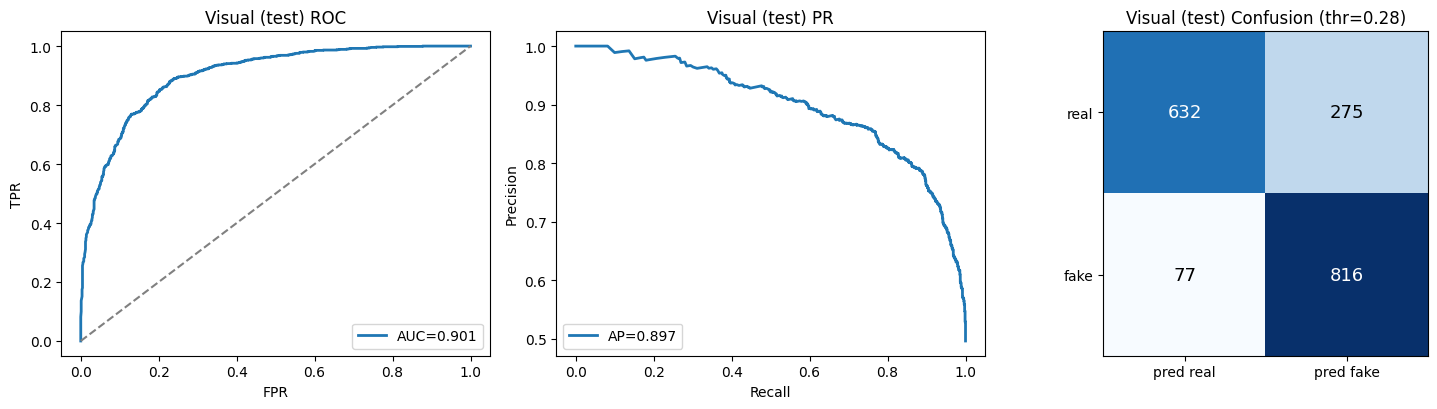

saved /kaggle/working/visual_eval.png

— VISUAL: per-subgroup test breakdown (fake→detection rate, real→reject rate) —
group class   n   rate  mean_p_fake
 fake  fake 893 0.9138       0.8044
 real  real 907 0.6968       0.2364
Audio ready.
  epoch 1/6 loss=0.2956 val_auc=0.9980 (218s)
  epoch 2/6 loss=0.1768 val_auc=0.9991 (169s)
  epoch 3/6 loss=0.1616 val_auc=0.9996 (163s)
  epoch 4/6 loss=0.1546 val_auc=0.9999 (163s)
  epoch 5/6 loss=0.1478 val_auc=0.9999 (165s)
  epoch 6/6 loss=0.1453 val_auc=1.0000 (165s)
Audio done. best val AUC=1.0000

── AUDIO [train] ──  (n=8400, thr=0.488)
   accuracy      : 0.9985
   balanced_acc  : 0.9985
   precision     : 0.9986
   recall        : 0.9983
   specificity   : 0.9986
   f1            : 0.9985
   roc_auc       : 1.0000
   pr_auc        : 1.0000
   mcc           : 0.9969
   eer           : 0.0017
   confusion      : TP=4193 FP=6 TN=4194 FN=7

── AUDIO [val] ──  (n=1800, thr=0.488)
   accuracy      : 0.9983
   balanced_acc  : 0.9983
   precision

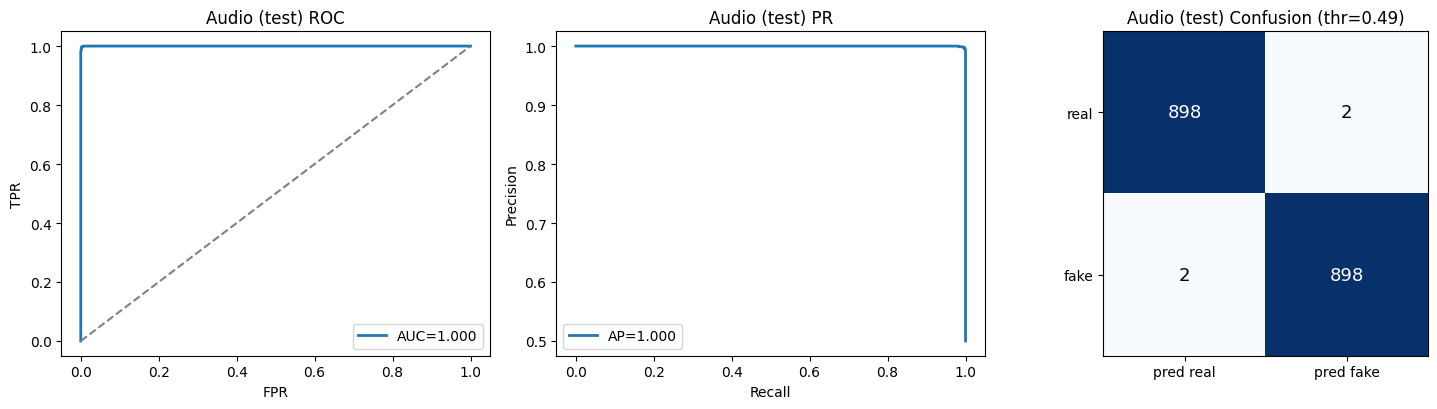

saved /kaggle/working/audio_eval.png

— AUDIO: per-subgroup test breakdown (fake→detection rate, real→reject rate) —
          group class   n   rate  mean_p_fake
       diffwave  fake 784 1.0000       0.9687
parallelwavegan  fake 116 0.9828       0.8757
       Bonafide  real 896 0.9989       0.0333
AUDIO score interpretation (read before trusting ~0.999 AUC / ~0.5% EER):
  CVoiceFake = CommonVoice REAL vs 6 vocoders. A CNN can latch onto the
  vocoder/codec fingerprint rather than genuine 'is-this-synthetic' cues,
  so in-distribution numbers look near-perfect but DON'T prove generalization.
  HONEST tests:
    leave-one-vocoder-out : set CFG.holdout_method='diffwave' and re-run
                            (train on 5 vocoders, test on the unseen 6th)
    cross-corpus          : set CFG.holdout_source to a different audio source
  Reference (SafeEar, ACM CCS'24, SAME CVoiceFake data): ~2.02%% EER avg.
Loading 6 shield .pt files:
  x_test: tensor (2242, 20, 1024) torch.float32
  x_trai

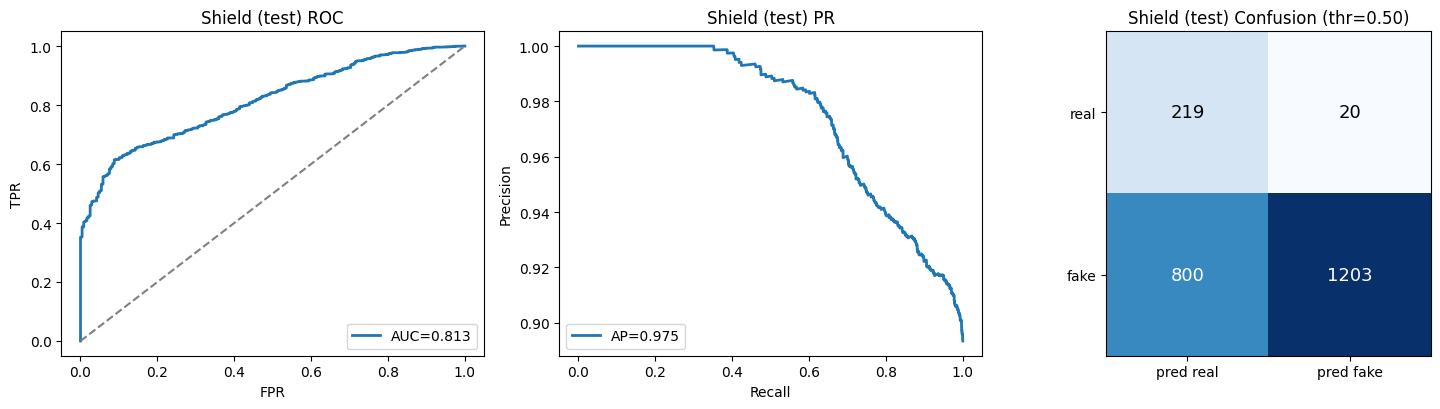

saved /kaggle/working/shield_eval.png
VIDEO-LEVEL eval on 330 held-out test clips (mean frame-prob per clip)
  scored 50/330
  scored 100/330
  scored 150/330
  scored 200/330
  scored 250/330
  scored 300/330

── VIDEO clip-level ──  (n=330, thr=0.548)
   accuracy      : 0.9212
   balanced_acc  : 0.9211
   precision     : 0.9312
   recall        : 0.9085
   specificity   : 0.9337
   f1            : 0.9198
   roc_auc       : 0.9708
   pr_auc        : 0.9733
   mcc           : 0.8426
   eer           : 0.0909
   confusion      : TP=149 FP=11 TN=155 FN=15


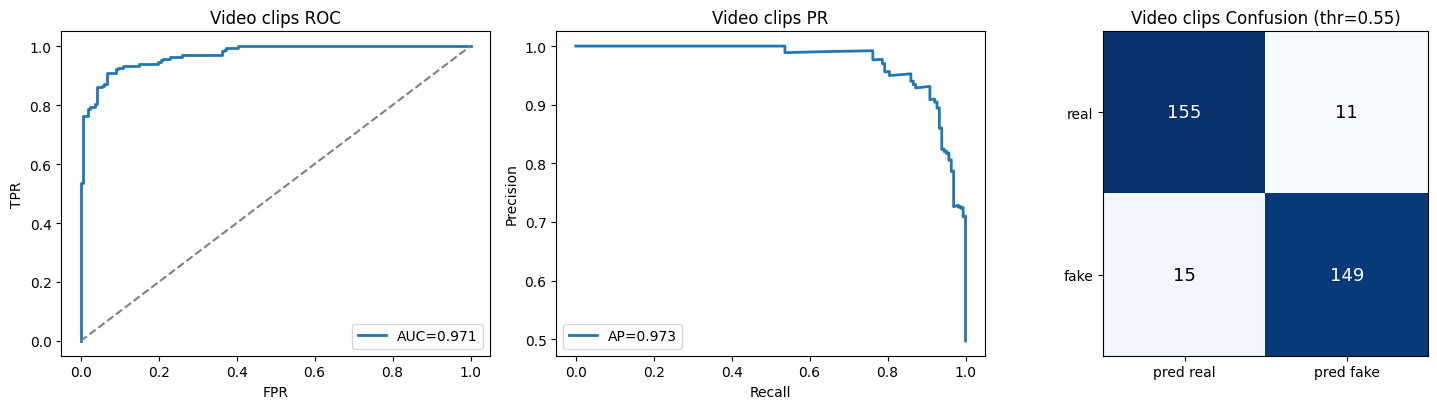

saved /kaggle/working/video_eval.png

================ FINAL METRICS ================

branch     split  accuracy  precision  recall  specificity     f1  roc_auc  pr_auc    mcc    eer     n
visual     train    0.9373     0.8966  0.9898       0.8840 0.9409   0.9928  0.9930 0.8794 0.0429  8392
visual       val    0.8075     0.7402  0.9293       0.6928 0.8241   0.9007  0.8896 0.6371 0.1875  1808
visual      test    0.8044     0.7479  0.9138       0.6968 0.8226   0.9012  0.8973 0.6248 0.1800  1800
 audio     train    0.9985     0.9986  0.9983       0.9986 0.9985   1.0000  1.0000 0.9969 0.0017  8400
 audio       val    0.9983     0.9967  1.0000       0.9967 0.9983   1.0000  1.0000 0.9967 0.0039  1800
 audio      test    0.9978     0.9978  0.9978       0.9978 0.9978   1.0000  1.0000 0.9956 0.0022  1800
shield     train    0.6526     0.9950  0.6144       0.9739 0.7597   0.8911  0.9860 0.3647 0.1999 10458
shield       val    0.8978     0.8978  0.9995       0.0420 0.9459   0.8102  0.9741 0.1830

,branch,split,accuracy,precision,recall,specificity,f1,roc_auc,pr_auc,mcc,eer,n
0,visual,train,0.9373,0.8966,0.9898,0.8840,0.9409,0.9928,0.9930,0.8794,0.0429,8392
1,visual,val,0.8075,0.7402,0.9293,0.6928,0.8241,0.9007,0.8896,0.6371,0.1875,1808
2,visual,test,0.8044,0.7479,0.9138,0.6968,0.8226,0.9012,0.8973,0.6248,0.1800,1800
3,audio,train,0.9985,0.9986,0.9983,0.9986,0.9985,1.0000,1.0000,0.9969,0.0017,8400
4,audio,val,0.9983,0.9967,1.0000,0.9967,0.9983,1.0000,1.0000,0.9967,0.0039,1800
5,audio,test,0.9978,0.9978,0.9978,0.9978,0.9978,1.0000,1.0000,0.9956,0.0022,1800
6,shield,train,0.6526,0.9950,0.6144,0.9739,0.7597,0.8911,0.9860,0.3647,0.1999,10458
7,shield,val,0.8978,0.8978,0.9995,0.0420,0.9459,0.8102,0.9741,0.1830,0.2772,2241
8,shield,test,0.6343,0.9836,0.6006,0.9163,0.7458,0.8131,0.9745,0.3204,0.2822,2242
9,video,clip_test,0.9212,0.9312,0.9085,0.9337,0.9198,0.9708,0.9733,0.8426,0.0909,330


In [2]:
# Deepfake Detector v7 — 2026/avatar-hardened — auto-exported
# Kaggle: GPU ON, Run All.

# # 🧠 Deepfake Detector v7 — Visual + Audio + Shield (2026/avatar-hardened)
# 
# Merges the hardened discovery (v3) with the shield branch (v4) and adds a
# **per-subgroup test breakdown** (detection rate per manipulation method / per vocoder).
# 
# | Source | Branch |
# |---|---|
# | `ucimachinelearning/.../DFDC_Dataset` (Real/Fake PNG) | visual |
# | `ahmedelbanby/faceforensics++` (frames) | visual |
# | `kamedev/cvoicefake-...-safeear` | audio |
# | `unidpro/real-vs-fake-human-voice` | audio |
# | `aionstreet/shield-2026-features` (.pt) | **shield (MLP on features)** |
# | FF++ `.mp4` | video (optional) |
# | `chuneeb` CSV | skipped (remote image_url) |
# 
# **What's new vs v3/v4**
# - **Single-pass, per-source-capped discovery** — one walk per dataset (not 3 over everything), so the 20-min video scan is gone and *every* source is represented (v3 trained on FF++ only because the cap filled before reaching DFDC).
# - **No final full-tree `.pt` walk** — shield files are found in the same pass (that 4th walk was the KeyboardInterrupt hang).
# - **Big-zip skip + progress prints** kept from v3.
# - **Shield branch** (robust multi-format `.pt` loader) from v4.
# - **Class balancing** to the minority before capping.
# - **Light label smoothing** to curb the train/test AUC gap.
# - **Per-subgroup breakdown**: for each FF++ method and each vocoder, the test-set detection rate — shows *which* manipulation is hardest, not just an aggregate.
# 
# Run: GPU on. Add datasets. **Run All in the editor** (not Save Version — it buffers output).

# %% cell 1
# ── Setup ────────────────────────────────────────────────────────────────────
import sys, subprocess, importlib
def _ensure(pkg, pip_name=None):
    try: importlib.import_module(pkg)
    except Exception: subprocess.run([sys.executable,"-m","pip","install","-q",pip_name or pkg], check=False)
_ensure("timm"); _ensure("librosa"); _ensure("soundfile"); _ensure("cv2","opencv-python-headless")

import os, glob, random, json, time, warnings, collections, zipfile, math
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, confusion_matrix, matthews_corrcoef, balanced_accuracy_score)
import matplotlib.pyplot as plt

SEED=42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE="cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEVICE)
if DEVICE=="cpu": print("⚠️  Turn on the GPU accelerator.")

# %% cell 2
# ── Config ───────────────────────────────────────────────────────────────────
class CFG:
    input_root   = "/kaggle/input"
    extract_root = "/kaggle/working/extracted"
    out_dir      = "/kaggle/working"

    per_source_cap = 80_000       # max files/modality pulled from EACH dataset (keeps sources diverse)
    max_visit      = 800_000      # hard cap on files walked per dataset (bounds worst-case time)
    max_zip_mb     = 200          # never auto-extract archives bigger than this

    max_per_class       = 6000    # training pool per class (after balancing)
    max_audio_per_class = 6000
    balance_classes     = True
    val_frac, test_frac = 0.15, 0.15
    label_smooth        = 0.05    # softens targets to curb overfitting

    use_sources_with  = None      # e.g. ["dfdc_dataset"] to use ONLY that source
    drop_sources_with = []        # e.g. ["dfdc_test"] to exclude a mislabeled source
    holdout_source    = None      # e.g. "dfdc_dataset": put ALL of that source in TEST (train on rest)
                                  #   -> honest CROSS-DATASET generalization (train FF++, test DFDC)

    img_size=224; img_backbone="efficientnet_b0"; img_epochs=5; img_batch=64; img_lr=3e-4
    sr=16000; audio_seconds=3.0; n_mels=128; audio_epochs=6; audio_batch=64; audio_lr=1e-3
    shield_epochs=14; shield_batch=256; shield_lr=1e-3; shield_hidden=256
    RUN_VIDEO_MP4=True; video_max_clips=400; video_frames_per_clip=12   # v7: honest VIDEO-LEVEL eval on held-out test clips
    shield_pos_weight=True; shield_balanced_thr=True                     # v7: fix shield class-imbalance collapse
    # v6: build a VISUAL training set by sampling frames from mp4 clips when no image dataset is mounted
    FRAMES_FROM_VIDEO=True; frames_per_video=8; max_videos_for_frames=1100
    aug_strong=True               # v7: compression/blur/downscale aug -> generalizes to in-the-wild & avatar video
    holdout_method=None           # e.g. "diffwave": leave-one-vocoder-out audio generalization test
    num_workers=2

os.makedirs(CFG.out_dir, exist_ok=True); os.makedirs(CFG.extract_root, exist_ok=True)

def _norm(t): return ''.join(ch for ch in t.lower() if ch.isalnum())
REAL_TOKENS={"real","reals","bonafide","genuine","live","authentic","pristine",
             "original","originals","originalsequences","youtube","actors","commonvoice",
             "celebreal","realsequences"}
FAKE_TOKENS={"fake","fakes","spoof","deepfake","deepfakes","face2face","faceswap",
             "neuraltextures","faceshifter","manipulated","manipulatedsequences",
             "synthetic","parallelwavegan","multibandmelgan","melgan","stylemelgan",
             "griffinlim","world","diffwave","wavegan","uadfv","celebsynthesis","reenactment",
             "wav2lip","sadtalker","videoretalking","liveportrait","simswap","inswapper",
             "roop","facefusion","stylegan","stargan","heygen","synthesia","sora","kling",
             "runway","pika","veo","stablediffusion","sdxl","ldm","talkinghead","lipsync"}

METHOD_HINTS=("parallelwavegan","multibandmelgan","stylemelgan","melgan","griffinlim",
              "diffwave","wavegan","waveglow","hifigan","fastspeech","tacotron","world",
              "deepfakes","face2face","faceswap","neuraltextures","faceshifter","celebsynthesis",
              "wav2lip","sadtalker","videoretalking","liveportrait","simswap","inswapper",
              "roop","facefusion","stylegan","stargan","heygen","synthesia","sora","kling",
              "runway","pika","veo","stablediffusion","sdxl","talkinghead","lipsync")
def _method_hint(p):
    flat=_norm(p)                      # whole path, alnum-only -> finds vocoder even when it's in the filename
    for h in METHOD_HINTS:
        if h in flat: return h
    return None
def label_and_method(p):
    # v6: label via deepest matching token; METHOD via vocoder/manipulation hint anywhere in the path
    lab=None; tok=None
    for t in reversed(p.replace("\\","/").split("/")):
        n=_norm(t)
        if not n: continue
        if n in REAL_TOKENS or n.startswith("original"): lab,tok=0,t; break
        if n in FAKE_TOKENS or n.startswith("method"):   lab,tok=1,t; break
        if n.startswith("real"): lab,tok=0,t; break
        if n.startswith("fake"): lab,tok=1,t; break
    if lab is None:
        low=p.lower()
        if any(k in low for k in ("fake","deepfake","spoof","synthetic","synth","manipulat","uadfv")): lab=1
        elif any(k in low for k in ("real","genuine","bonafide","original")): lab=0
        else: return None,None
    if lab==1: meth=_method_hint(p) or tok or "fake"     # granular vocoder/method for the subgroup breakdown
    else:      meth=tok or "real"
    return lab, meth

def label_from_path(p): return label_and_method(p)[0]

def split_kind(p):
    low="/"+p.lower().replace("\\","/")+"/"
    if any(s in low for s in ("/test/","/testing/","/eval/")): return "test"
    if any(s in low for s in ("/val/","/valid/","/validation/","/dev/")): return "val"
    if any(s in low for s in ("/train/","/training/")): return "train"
    return None

def source_of(p):
    rel=p.replace("\\","/")
    for marker in ("input/datasets/","input/","extracted/"):
        if marker in rel:
            parts=[s for s in rel.split(marker)[-1].strip("/").split("/")]
            return "/".join(parts[:2]) if len(parts)>=2 else (parts[0] if parts else "?")
    return "?"

print("Config ready.")

# %% cell 3
# ── Discovery: single-pass, per-source-capped, instrumented, disk-safe ──────
IMG_EXT=(".jpg",".jpeg",".png",".bmp",".webp"); AUD_EXT=(".wav",".flac",".mp3",".ogg",".m4a"); VID_EXT=(".mp4",".avi",".mov",".mkv")

# extract only SMALL zips (never CVoiceFake-Full → would fill the 20GB disk)
zips=[os.path.join(dp,f) for dp,_,fs in os.walk(CFG.input_root) for f in fs if f.lower().endswith(".zip")]
for z in zips:
    mb=os.path.getsize(z)/1e6
    if mb>CFG.max_zip_mb: print(f"skip big zip ({mb:.0f}MB): {z}"); continue
    dest=os.path.join(CFG.extract_root, os.path.splitext(os.path.basename(z))[0])
    if os.path.exists(dest): continue
    try:
        with zipfile.ZipFile(z) as zf: zf.extractall(dest); print("extracted", z)
    except Exception as e: print("zip fail", z, e)

def list_roots():
    roots=[]
    for base in (CFG.input_root, CFG.extract_root):
        if not os.path.isdir(base): continue
        for name in sorted(os.listdir(base)):
            full=os.path.join(base,name)
            if not os.path.isdir(full): continue
            if name=="datasets":                       # /kaggle/input/datasets/<owner>/<slug>
                for owner in sorted(os.listdir(full)):
                    of=os.path.join(full,owner)
                    if os.path.isdir(of):
                        for slug in sorted(os.listdir(of)):
                            sf=os.path.join(of,slug)
                            if os.path.isdir(sf): roots.append(sf)
            else:
                roots.append(full)
    return roots

def discover(roots):
    imgs,auds,vids,pts=[],[],[],[]
    print(f"walking {len(roots)} dataset root(s), cap {CFG.per_source_cap:,}/modality each:")
    for r in roots:
        ci=ca=cv=0; vis=0; t0=time.time()
        for dp,_,files in os.walk(r):
            for f in files:
                vis+=1; fl=f.lower()
                if   fl.endswith(IMG_EXT) and ci<CFG.per_source_cap: imgs.append(os.path.join(dp,f)); ci+=1
                elif fl.endswith(AUD_EXT) and ca<CFG.per_source_cap: auds.append(os.path.join(dp,f)); ca+=1
                elif fl.endswith(VID_EXT) and cv<CFG.per_source_cap: vids.append(os.path.join(dp,f)); cv+=1
                elif fl.endswith(".pt"): pts.append(os.path.join(dp,f))
            if vis>CFG.max_visit: print(f"    (max_visit hit)"); break
        print(f"  {os.path.basename(r):<52} img={ci:>7,} aud={ca:>7,} vid={cv:>6,} ({time.time()-t0:.0f}s)")
    return imgs,auds,vids,sorted(set(pts))

roots=list_roots()
all_imgs,all_auds,all_vids,shield_pts=discover(roots)
print(f"\nTOTAL  images={len(all_imgs):,} audio={len(all_auds):,} videos={len(all_vids):,} shield_pt={len(shield_pts)}")
VIDEO_ON=len(all_imgs)>50; AUDIO_ON=len(all_auds)>50
print(f"VISUAL:{'ON' if VIDEO_ON else 'off'}  AUDIO:{'ON' if AUDIO_ON else 'off'}  "
      f"SHIELD:{'pending' if shield_pts else 'off'}  MP4:{'ON' if (CFG.RUN_VIDEO_MP4 and all_vids) else 'off'}")

# %% cell 4
# ── v6 VISUAL-from-VIDEO: sample frames from mp4 clips when no image dataset is mounted ──
# DFDC-cropped ships as .mp4 (Real/Fake). With no PNG dataset mounted, we sample frames to TRAIN
# the visual branch. Split is assigned PER CLIP (not per frame) so no identity/frame leaks into test.
if CFG.FRAMES_FROM_VIDEO and len(all_imgs) < 50 and all_vids:
    import cv2, re
    fr_root=os.path.join(CFG.extract_root,"video_frames")
    clips=[]
    for p in all_vids:
        y,m=label_and_method(p)
        if y is not None: clips.append((p,y,m))
    byc={0:[],1:[]}
    for p,y,m in clips: byc[y].append((p,m))
    rng=random.Random(SEED); rng.shuffle(byc[0]); rng.shuffle(byc[1])
    if byc[0] and byc[1]: per=min(CFG.max_videos_for_frames, min(len(byc[0]),len(byc[1])))
    else:                 per=min(CFG.max_videos_for_frames, max(len(byc[0]),len(byc[1])))
    sel=[(p,0,m) for p,m in byc[0][:per]]+[(p,1,m) for p,m in byc[1][:per]]; rng.shuffle(sel)
    def clip_split(i,n):
        r=i/max(n,1)
        return "test" if r<CFG.test_frac else ("val" if r<CFG.test_frac+CFG.val_frac else "train")
    print(f"VISUAL-from-VIDEO: sampling {CFG.frames_per_video} frames from {len(sel)} clips (per class={per})...")
    new=[]; t0=time.time(); bad=0; VIS_TEST_CLIPS=[]
    for j,(p,y,m) in enumerate(sel):
        sp=clip_split(j,len(sel)); lab="fake" if y==1 else "real"
        if sp=="test": VIS_TEST_CLIPS.append((p,y))     # held-out clips for honest VIDEO-LEVEL eval
        try:
            cap=cv2.VideoCapture(p); tot=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0
            if tot<=0: cap.release(); bad+=1; continue
            idx=np.linspace(0,tot-1,CFG.frames_per_video).astype(int)
            d=os.path.join(fr_root,sp,lab); os.makedirs(d,exist_ok=True)
            stem=re.sub(r'[^A-Za-z0-9]+','_',os.path.splitext(os.path.basename(p))[0])[:48]
            for i in idx:
                cap.set(cv2.CAP_PROP_POS_FRAMES,int(i)); ok,fr=cap.read()
                if not ok: continue
                op=os.path.join(d,f"{stem}_{i:04d}.jpg"); cv2.imwrite(op,fr); new.append(op)
            cap.release()
        except Exception: bad+=1
        if (j+1)%200==0: print(f"  {j+1}/{len(sel)} clips, {len(new):,} frames ({time.time()-t0:.0f}s)")
    all_imgs=new; VIDEO_ON=len(all_imgs)>50
    print(f"VISUAL-from-VIDEO: {len(all_imgs):,} frames (bad clips={bad}). VISUAL now {'ON' if VIDEO_ON else 'off'}.")
    print("  split=per-clip (no frame leakage); frames are DFDC-only -> in-distribution visual eval.")
else:
    print("VISUAL-from-VIDEO: skipped (image dataset already present, or no clips, or disabled).")

# %% cell 5
# ── Build tables (with method column) + per-source audit ────────────────────
def keep_path(p):
    low=p.lower()
    if CFG.use_sources_with and not any(s in low for s in CFG.use_sources_with): return False
    if any(s in low for s in CFG.drop_sources_with): return False
    return True

def build_table(paths, cap):
    rows=[]
    for p in paths:
        if not keep_path(p): continue
        y,meth=label_and_method(p)
        if y is None: continue
        rows.append((p,y,meth,split_kind(p),source_of(p)))
    if not rows: return pd.DataFrame(columns=["path","label","method","split","source"])
    df=pd.DataFrame(rows,columns=["path","label","method","split","source"])
    counts={lab:len(g) for lab,g in df.groupby("label")}
    eff=min(cap, min(counts.values())) if CFG.balance_classes else cap
    df=pd.concat([g.sample(frac=1.0,random_state=SEED).head(eff) for _,g in df.groupby("label")]
                 ).sample(frac=1.0,random_state=SEED).reset_index(drop=True)
    if CFG.holdout_source:                       # cross-dataset: all of one source -> test
        mask=df["source"].str.contains(CFG.holdout_source, case=False, regex=False)
        if mask.sum()==0:
            print(f"⚠️ holdout_source '{CFG.holdout_source}' matched 0 rows — using random split")
        else:
            df["split"]="train"; df.loc[mask,"split"]="test"
            rest=df[~mask]
            for lab,g in rest.groupby("label"):
                idx=g.index.tolist(); nv=int(len(idx)*CFG.val_frac); df.loc[idx[:nv],"split"]="val"
            print(f"holdout='{CFG.holdout_source}': test={int(mask.sum())} (held-out source), train/val from rest")
            return df
    if CFG.holdout_method:                        # leave-one-vocoder-out: all of one method -> test
        mmask=df["method"].astype(str).str.contains(CFG.holdout_method, case=False, regex=False)
        if mmask.sum()==0:
            print(f"⚠️ holdout_method '{CFG.holdout_method}' matched 0 rows — random split")
        else:
            df["split"]="train"; df.loc[mmask,"split"]="test"
            rest=df[~mmask]
            for lab,g in rest.groupby("label"):
                idx=g.index.tolist(); nv=int(len(idx)*CFG.val_frac); df.loc[idx[:nv],"split"]="val"
            print(f"holdout_method='{CFG.holdout_method}': test={int(mmask.sum())} (held-out vocoder), train/val from rest")
            return df
    has=df["split"].notna().mean()>0.6 and df["split"].nunique()>=2
    if not has:
        df["split"]=None
        for lab,g in df.groupby("label"):
            idx=g.index.tolist(); n=len(idx); nt=int(n*CFG.test_frac); nv=int(n*CFG.val_frac)
            df.loc[idx[:nt],"split"]="test"; df.loc[idx[nt:nt+nv],"split"]="val"; df.loc[idx[nt+nv:],"split"]="train"
    elif (df["split"]=="val").sum()==0:
        tr=df[df["split"]=="train"]; df.loc[tr.sample(frac=CFG.val_frac,random_state=SEED).index,"split"]="val"
    return df

def audit(paths,name):
    rec=collections.defaultdict(lambda:[0,0,0])
    for p in paths:
        if not keep_path(p): continue
        y=label_from_path(p); rec[source_of(p)][2 if y is None else y]+=1
    print(f"\n=== {name} per-source audit (real / fake / dropped) ===")
    for s,(r,f,n) in sorted(rec.items()):
        flag=" ⚠️ one-class" if (r==0 or f==0) else ""
        print(f"  {s:<55} real={r:>7,} fake={f:>7,} drop={n:>7,}{flag}")

if VIDEO_ON: audit(all_imgs,"VISUAL")
if AUDIO_ON: audit(all_auds,"AUDIO")

img_df=build_table(all_imgs,CFG.max_per_class) if VIDEO_ON else pd.DataFrame()
aud_df=build_table(all_auds,CFG.max_audio_per_class) if AUDIO_ON else pd.DataFrame()

def summarize(df,name):
    if len(df)==0: print(f"\n{name}: (none)"); return
    print(f"\n{name}: {len(df):,} used (balanced={CFG.balance_classes})")
    print(pd.crosstab(df["split"],df["label"].map({0:'real',1:'fake'}),margins=True))
    print("  methods:", dict(df["method"].value_counts().head(8)))
summarize(img_df,"VISUAL"); summarize(aud_df,"AUDIO")

if VIDEO_ON and img_df["label"].nunique()<2: print("\n⚠️ visual single-class → off"); VIDEO_ON=False
if AUDIO_ON and aud_df["label"].nunique()<2: print("\n⚠️ audio single-class → off"); AUDIO_ON=False

# %% cell 6
# ── Metrics + plots + per-subgroup breakdown ────────────────────────────────
def eer_of(y,p):
    fpr,tpr,_=roc_curve(y,p); fnr=1-tpr; i=np.nanargmin(np.abs(fnr-fpr)); return float((fpr[i]+fnr[i])/2)
def best_f1_thr(y,p):
    pr,rc,th=precision_recall_curve(y,p); f1=2*pr*rc/(pr+rc+1e-12)
    return 0.5 if len(th)==0 else float(th[np.nanargmax(f1[:-1])])
def best_bal_thr(y,p):
    # threshold maximizing balanced accuracy (Youden's J) — robust to class imbalance (shield)
    fpr,tpr,th=roc_curve(y,p)
    if len(th)==0: return 0.5
    k=int(np.nanargmax(tpr-fpr)); return float(min(max(th[k],0.0),1.0))

def compute_metrics(y,p,threshold=None):
    y=np.asarray(y).astype(int); p=np.asarray(p).astype(float)
    thr=best_f1_thr(y,p) if threshold is None else threshold
    yp=(p>=thr).astype(int); tn,fp,fn,tp=confusion_matrix(y,yp,labels=[0,1]).ravel(); e=1e-12
    prec=tp/(tp+fp+e); rec=tp/(tp+fn+e); spec=tn/(tn+fp+e); f1=2*prec*rec/(prec+rec+e)
    acc=(tp+tn)/(tp+tn+fp+fn+e)
    try: auc=roc_auc_score(y,p)
    except: auc=float('nan')
    try: ap=average_precision_score(y,p)
    except: ap=float('nan')
    return {"accuracy":acc,"balanced_acc":balanced_accuracy_score(y,yp),"precision":prec,
            "recall":rec,"specificity":spec,"f1":f1,"roc_auc":auc,"pr_auc":ap,
            "mcc":matthews_corrcoef(y,yp) if len(set(yp))>1 else 0.0,"eer":eer_of(y,p),
            "threshold":thr,"TP":int(tp),"FP":int(fp),"TN":int(tn),"FN":int(fn),"n":int(len(y))}

def print_metrics(name,m):
    print(f"\n── {name} ──  (n={m['n']}, thr={m['threshold']:.3f})")
    for k in ["accuracy","balanced_acc","precision","recall","specificity","f1","roc_auc","pr_auc","mcc","eer"]:
        print(f"   {k:<14}: {m[k]:.4f}")
    print(f"   confusion      : TP={m['TP']} FP={m['FP']} TN={m['TN']} FN={m['FN']}")

def plot_eval(name,y,p,m,prefix):
    y=np.asarray(y); p=np.asarray(p); fig,ax=plt.subplots(1,3,figsize=(15,4.2))
    fpr,tpr,_=roc_curve(y,p); ax[0].plot(fpr,tpr,lw=2,label=f"AUC={m['roc_auc']:.3f}")
    ax[0].plot([0,1],[0,1],"--",c="gray"); ax[0].set_title(f"{name} ROC"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend(loc="lower right")
    pr,rc,_=precision_recall_curve(y,p); ax[1].plot(rc,pr,lw=2,label=f"AP={m['pr_auc']:.3f}")
    ax[1].set_title(f"{name} PR"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend(loc="lower left")
    cm=np.array([[m['TN'],m['FP']],[m['FN'],m['TP']]]); ax[2].imshow(cm,cmap="Blues")
    ax[2].set_xticks([0,1]); ax[2].set_yticks([0,1]); ax[2].set_xticklabels(["pred real","pred fake"]); ax[2].set_yticklabels(["real","fake"])
    for (i,j),v in np.ndenumerate(cm): ax[2].text(j,i,str(v),ha="center",va="center",color="white" if v>cm.max()/2 else "black",fontsize=13)
    ax[2].set_title(f"{name} Confusion (thr={m['threshold']:.2f})"); plt.tight_layout()
    out=os.path.join(CFG.out_dir,f"{prefix}_eval.png"); plt.savefig(out,dpi=110,bbox_inches="tight"); plt.show(); print("saved",out)

def subgroup_report(d, probs, thr, name, prefix):
    # per-method detection (fakes) / correct-reject (reals) on the test split
    dd=d.copy(); dd["prob"]=np.asarray(probs); dd["pred"]=(dd["prob"]>=thr).astype(int)
    rows=[]
    for (lab,meth),g in dd.groupby(["label","method"]):
        n=len(g)
        if n<5: continue
        rate=(g["pred"]==1).mean() if lab==1 else (g["pred"]==0).mean()
        rows.append({"group":meth,"class":"fake" if lab==1 else "real",
                     "n":n,"rate":round(float(rate),4),"mean_p_fake":round(float(g['prob'].mean()),4)})
    if not rows: return None
    rep=pd.DataFrame(rows).sort_values(["class","n"],ascending=[True,False])
    print(f"\n— {name}: per-subgroup test breakdown (fake→detection rate, real→reject rate) —")
    print(rep.to_string(index=False))
    rep.to_csv(os.path.join(CFG.out_dir,f"{prefix}_subgroups.csv"),index=False)
    return rep
print("Metrics ready.")

# %% cell 7
# ── VISUAL: dataset + EfficientNet-B0 ───────────────────────────────────────
import timm
from PIL import Image
import torchvision.transforms as T
NORM=([0.485,0.456,0.406],[0.229,0.224,0.225])
class _RandJPEG:
    # re-encode at random quality -> teaches robustness to compression (key for in-the-wild/streamed avatar video)
    def __init__(s,p=0.4,q=(35,90)): s.p=p; s.q=q
    def __call__(s,im):
        import io as _io
        if random.random()<s.p:
            b=_io.BytesIO(); im.convert("RGB").save(b,"JPEG",quality=random.randint(*s.q)); b.seek(0); im=Image.open(b).convert("RGB")
        return im
class _RandDownscale:
    # downscale-then-upscale -> simulates low-res capture / upscaled avatar output
    def __init__(s,p=0.3,f=(0.4,0.85)): s.p=p; s.f=f
    def __call__(s,im):
        if random.random()<s.p:
            w,h=im.size; r=random.uniform(*s.f)
            im=im.resize((max(8,int(w*r)),max(8,int(h*r))),Image.BILINEAR).resize((w,h),Image.BILINEAR)
        return im
_pre=[T.Resize((CFG.img_size,)*2)]
if getattr(CFG,"aug_strong",False):
    _pre+=[_RandJPEG(0.4),_RandDownscale(0.3),T.RandomApply([T.GaussianBlur(3,(0.1,1.5))],p=0.3),
           T.RandomHorizontalFlip(),T.ColorJitter(0.15,0.15,0.15,0.03)]
else:
    _pre+=[T.RandomHorizontalFlip(),T.ColorJitter(0.1,0.1,0.1)]
train_tf=T.Compose(_pre+[T.ToTensor(),T.Normalize(*NORM),T.RandomErasing(p=0.25)])
eval_tf =T.Compose([T.Resize((CFG.img_size,)*2),T.ToTensor(),T.Normalize(*NORM)])
class ImgDS(Dataset):
    def __init__(s,df,tf): s.p=df["path"].tolist(); s.y=df["label"].tolist(); s.tf=tf
    def __len__(s): return len(s.p)
    def __getitem__(s,i):
        try: im=Image.open(s.p[i]).convert("RGB")
        except: im=Image.new("RGB",(CFG.img_size,)*2)
        return s.tf(im), torch.tensor(s.y[i],dtype=torch.float32)
def iloader(df,tf,bs,sh): return DataLoader(ImgDS(df,tf),batch_size=bs,shuffle=sh,num_workers=CFG.num_workers,pin_memory=True)
class ImgNet(nn.Module):
    def __init__(s,b): super().__init__(); s.net=timm.create_model(b,pretrained=True,num_classes=1)
    def forward(s,x): return s.net(x).squeeze(1)
def smooth(y): return y*(1-CFG.label_smooth)+0.5*CFG.label_smooth
print("Visual ready." if VIDEO_ON else "Visual off.")

# %% cell 8
# ── VISUAL: train ───────────────────────────────────────────────────────────
@torch.no_grad()
def infer_img(model,loader):
    model.eval(); P,Y=[],[]
    for x,y in loader:
        x=x.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): p=torch.sigmoid(model(x))
        P.append(p.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(P)
img_model=None
if VIDEO_ON:
    tr=img_df[img_df.split=="train"]; va=img_df[img_df.split=="val"]
    tl=iloader(tr,train_tf,CFG.img_batch,True); vl=iloader(va,eval_tf,CFG.img_batch,False)
    img_model=ImgNet(CFG.img_backbone).to(DEVICE)
    opt=torch.optim.AdamW(img_model.parameters(),lr=CFG.img_lr,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=CFG.img_epochs*max(1,len(tl)))
    sc=torch.cuda.amp.GradScaler(enabled=DEVICE=="cuda"); lf=nn.BCEWithLogitsLoss()
    best=-1; bs=None
    for ep in range(CFG.img_epochs):
        img_model.train(); t0=time.time(); run=0
        for x,y in tl:
            x,y=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True); opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): loss=lf(img_model.net(x).squeeze(1),smooth(y))
            sc.scale(loss).backward(); sc.step(opt); sc.update(); sch.step(); run+=loss.item()*len(x)
        yv,pv=infer_img(img_model,vl)
        try: auc=roc_auc_score(yv,pv)
        except: auc=float('nan')
        print(f"  epoch {ep+1}/{CFG.img_epochs} loss={run/len(tr):.4f} val_auc={auc:.4f} ({time.time()-t0:.0f}s)")
        if auc>best: best=auc; bs={k:v.detach().cpu().clone() for k,v in img_model.state_dict().items()}
    if bs: img_model.load_state_dict(bs)
    torch.save(img_model.state_dict(),os.path.join(CFG.out_dir,"visual_model.pt"))
    print(f"Visual done. best val AUC={best:.4f}")
else: print("Visual off.")

# %% cell 9
# ── VISUAL: evaluate + per-subgroup ─────────────────────────────────────────
visual_results={}
if VIDEO_ON and img_model is not None:
    yv,pv=infer_img(img_model,iloader(img_df[img_df.split=="val"],eval_tf,CFG.img_batch,False))
    locked=best_f1_thr(yv,pv)
    for sp in ["train","val","test"]:
        d=img_df[img_df.split==sp]
        if len(d)==0: continue
        yy,pp=infer_img(img_model,iloader(d,eval_tf,CFG.img_batch,False))
        m=compute_metrics(yy,pp,threshold=None if sp=="val" else locked)
        visual_results[sp]=m; print_metrics(f"VISUAL [{sp}]",m)
        if sp=="test":
            plot_eval("Visual (test)",yy,pp,m,"visual")
            subgroup_report(d,pp,locked,"VISUAL","visual")
else: print("Visual off — no metrics.")

# %% cell 10
# ── AUDIO: log-mel dataset + CNN ────────────────────────────────────────────
import librosa
TLEN=int(CFG.sr*CFG.audio_seconds)
def logmel(path):
    try: y,_=librosa.load(path,sr=CFG.sr,mono=True)
    except: y=np.zeros(TLEN,dtype=np.float32)
    y=np.pad(y,(0,TLEN-len(y))) if len(y)<TLEN else y[:TLEN]
    mel=librosa.feature.melspectrogram(y=y,sr=CFG.sr,n_mels=CFG.n_mels,n_fft=1024,hop_length=256)
    mel=librosa.power_to_db(mel,ref=np.max); mel=(mel-mel.mean())/(mel.std()+1e-6)
    return mel.astype(np.float32)
class AudDS(Dataset):
    def __init__(s,df): s.p=df["path"].tolist(); s.y=df["label"].tolist()
    def __len__(s): return len(s.p)
    def __getitem__(s,i): return torch.from_numpy(logmel(s.p[i])).unsqueeze(0), torch.tensor(s.y[i],dtype=torch.float32)
def aloader(df,bs,sh): return DataLoader(AudDS(df),batch_size=bs,shuffle=sh,num_workers=CFG.num_workers,pin_memory=True)
class AudioCNN(nn.Module):
    def __init__(s):
        super().__init__()
        def blk(ci,co): return nn.Sequential(nn.Conv2d(ci,co,3,padding=1),nn.BatchNorm2d(co),nn.ReLU(),nn.MaxPool2d(2))
        s.feat=nn.Sequential(blk(1,16),blk(16,32),blk(32,64),blk(64,128))
        s.head=nn.Sequential(nn.AdaptiveAvgPool2d(1),nn.Flatten(),nn.Dropout(0.3),nn.Linear(128,1))
    def forward(s,x): return s.head(s.feat(x)).squeeze(1)
print("Audio ready." if AUDIO_ON else "Audio off.")

# %% cell 11
# ── AUDIO: train ────────────────────────────────────────────────────────────
@torch.no_grad()
def infer_aud(model,loader):
    model.eval(); P,Y=[],[]
    for x,y in loader:
        x=x.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): p=torch.sigmoid(model(x))
        P.append(p.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(P)
aud_model=None
if AUDIO_ON:
    tr=aud_df[aud_df.split=="train"]; va=aud_df[aud_df.split=="val"]
    tl=aloader(tr,CFG.audio_batch,True); vl=aloader(va,CFG.audio_batch,False)
    aud_model=AudioCNN().to(DEVICE)
    opt=torch.optim.AdamW(aud_model.parameters(),lr=CFG.audio_lr,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=CFG.audio_epochs*max(1,len(tl)))
    sc=torch.cuda.amp.GradScaler(enabled=DEVICE=="cuda"); lf=nn.BCEWithLogitsLoss()
    best=-1; bsd=None
    for ep in range(CFG.audio_epochs):
        aud_model.train(); t0=time.time(); run=0
        for x,y in tl:
            x,y=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True); opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): loss=lf(aud_model(x),smooth(y))
            sc.scale(loss).backward(); sc.step(opt); sc.update(); sch.step(); run+=loss.item()*len(x)
        yv,pv=infer_aud(aud_model,vl)
        try: auc=roc_auc_score(yv,pv)
        except: auc=float('nan')
        print(f"  epoch {ep+1}/{CFG.audio_epochs} loss={run/len(tr):.4f} val_auc={auc:.4f} ({time.time()-t0:.0f}s)")
        if auc>best: best=auc; bsd={k:v.detach().cpu().clone() for k,v in aud_model.state_dict().items()}
    if bsd: aud_model.load_state_dict(bsd)
    torch.save(aud_model.state_dict(),os.path.join(CFG.out_dir,"audio_model.pt"))
    print(f"Audio done. best val AUC={best:.4f}")
else: print("Audio off.")

# %% cell 12
# ── AUDIO: evaluate + per-subgroup (per vocoder) ────────────────────────────
audio_results={}
if AUDIO_ON and aud_model is not None:
    yv,pv=infer_aud(aud_model,aloader(aud_df[aud_df.split=="val"],CFG.audio_batch,False))
    locked=best_f1_thr(yv,pv)
    for sp in ["train","val","test"]:
        d=aud_df[aud_df.split==sp]
        if len(d)==0: continue
        yy,pp=infer_aud(aud_model,aloader(d,CFG.audio_batch,False))
        m=compute_metrics(yy,pp,threshold=None if sp=="val" else locked)
        audio_results[sp]=m; print_metrics(f"AUDIO [{sp}]",m)
        if sp=="test":
            plot_eval("Audio (test)",yy,pp,m,"audio")
            subgroup_report(d,pp,locked,"AUDIO","audio")
else: print("Audio off — no metrics.")

# %% cell 13
# ── v6 HONESTY NOTE: is the AUDIO score real, or a vocoder shortcut? ─────────
print("="*66)
print("AUDIO score interpretation (read before trusting ~0.999 AUC / ~0.5% EER):")
print("  CVoiceFake = CommonVoice REAL vs 6 vocoders. A CNN can latch onto the")
print("  vocoder/codec fingerprint rather than genuine 'is-this-synthetic' cues,")
print("  so in-distribution numbers look near-perfect but DON'T prove generalization.")
print("  HONEST tests:")
print("    leave-one-vocoder-out : set CFG.holdout_method='diffwave' and re-run")
print("                            (train on 5 vocoders, test on the unseen 6th)")
print("    cross-corpus          : set CFG.holdout_source to a different audio source")
print("  Reference (SafeEar, ACM CCS'24, SAME CVoiceFake data): ~2.02%% EER avg.")
print("="*66)

# %% cell 14
# ── SHIELD: robust multi-format .pt loader (ported from v4) ─────────────────
def load_shield_splits(pts):
    if not pts: return None
    print(f"Loading {len(pts)} shield .pt files:")
    loaded={}
    for p in pts:
        name=os.path.splitext(os.path.basename(p))[0].lower()
        try:
            obj=torch.load(p,map_location="cpu",weights_only=False)
            if torch.is_tensor(obj): print(f"  {name}: tensor {tuple(obj.shape)} {obj.dtype}")
            elif isinstance(obj,dict): print(f"  {name}: dict keys={list(obj.keys())[:10]}")
            else: print(f"  {name}: {type(obj).__name__}")
            loaded[name]=obj
        except Exception as e: print(f"  {name}: FAILED — {e}")
    X_MARKS=("x","features","feat","emb","embedding","data"); Y_MARKS=("y","label","labels","target","targets","gt")
    def to_long(t):
        return t.long() if (t.is_floating_point() and float(t.max())<=1) else t.long()
    # 1: separate files per split
    sd={}
    for split in ("train","val","validation","dev","test"):
        xk=next((k for k in loaded if split in k and torch.is_tensor(loaded[k]) and loaded[k].ndim>=2
                 and any(k.startswith(m) or f"_{m}" in k for m in X_MARKS)),None)
        yk=next((k for k in loaded if split in k and torch.is_tensor(loaded[k])
                 and any(k.startswith(m) or f"_{m}" in k for m in Y_MARKS)),None)
        if xk and yk:
            sp="val" if split in ("validation","dev") else split
            sd[sp]=(loaded[xk].float(),to_long(loaded[yk])); print(f"  → {sp}: X={tuple(loaded[xk].shape)}")
    if len(sd)>=2: return sd
    # 2: single dict with X_train etc.
    for obj in loaded.values():
        if not isinstance(obj,dict): continue
        for split in ("train","val","validation","test"):
            xk=next((k for k in obj if split in k.lower() and any(m in k.lower() for m in X_MARKS) and torch.is_tensor(obj[k])),None)
            yk=next((k for k in obj if split in k.lower() and any(m in k.lower() for m in Y_MARKS) and torch.is_tensor(obj[k])),None)
            if xk and yk:
                sp="val" if split=="validation" else split
                sd[sp]=(obj[xk].float(),to_long(obj[yk])); print(f"  → {sp}: X={tuple(obj[xk].shape)}")
        if sd: return sd
    # 3: two tensors (2-D feats + 1-D labels) → auto-split
    tens={k:v for k,v in loaded.items() if torch.is_tensor(v)}
    if len(tens)==2:
        (n1,t1),(n2,t2)=list(tens.items())
        X=y=None
        if t1.ndim>=2 and t2.ndim==1: X,y=t1.float(),t2
        elif t2.ndim>=2 and t1.ndim==1: X,y=t2.float(),t1
        if X is not None:
            y=to_long(y); n=len(X); nt=int(n*CFG.test_frac); nv=int(n*CFG.val_frac)
            pm=torch.randperm(n,generator=torch.Generator().manual_seed(SEED))
            return {"test":(X[pm[:nt]],y[pm[:nt]]),"val":(X[pm[nt:nt+nv]],y[pm[nt:nt+nv]]),"train":(X[pm[nt+nv:]],y[pm[nt+nv:]])}
    # 4: single (N, D+1) tensor, last col = label
    for obj in loaded.values():
        if torch.is_tensor(obj) and obj.ndim==2 and obj.shape[1]>1:
            X=obj[:,:-1].float(); y=obj[:,-1].long(); n=len(X); nt=int(n*CFG.test_frac); nv=int(n*CFG.val_frac)
            pm=torch.randperm(n,generator=torch.Generator().manual_seed(SEED))
            return {"test":(X[pm[:nt]],y[pm[:nt]]),"val":(X[pm[nt:nt+nv]],y[pm[nt:nt+nv]]),"train":(X[pm[nt+nv:]],y[pm[nt+nv:]])}
    print("⚠️ Shield .pt format not recognized — check shapes above and extend load_shield_splits().")
    return None

shield_splits=load_shield_splits(shield_pts)
SHIELD_ON=shield_splits is not None and len(shield_splits)>=2
if SHIELD_ON:
    ally=torch.cat([y for _,y in shield_splits.values()])
    if len(ally.unique())<2: print("⚠️ shield single-class → off"); SHIELD_ON=False
print(f"SHIELD: {'ON' if SHIELD_ON else 'off'}")

# %% cell 15
# ── SHIELD: MLP train + evaluate ────────────────────────────────────────────
class ShieldDS(Dataset):
    def __init__(s,X,y): s.X=X.float(); s.y=y.float()
    def __len__(s): return len(s.X)
    def __getitem__(s,i): return s.X[i], s.y[i]
class ShieldMLP(nn.Module):
    # v7: (B,D) OR (B,T,D). Sequences pooled over T with attention+mean+max (concat) for a richer summary.
    def __init__(s,d,h=256):
        super().__init__()
        s.in_norm=nn.LayerNorm(d)
        s.attn=nn.Sequential(nn.Linear(d,d//2),nn.GELU(),nn.Linear(d//2,1))
        s.seq_net=nn.Sequential(nn.Linear(d*3,h),nn.LayerNorm(h),nn.GELU(),nn.Dropout(0.3),
                                nn.Linear(h,h//2),nn.LayerNorm(h//2),nn.GELU(),nn.Dropout(0.2),nn.Linear(h//2,1))
        s.vec_net=nn.Sequential(nn.Linear(d,h),nn.LayerNorm(h),nn.GELU(),nn.Dropout(0.3),
                                nn.Linear(h,h//2),nn.LayerNorm(h//2),nn.GELU(),nn.Dropout(0.2),nn.Linear(h//2,1))
    def forward(s,x):
        if x.dim()==3:                              # (B,T,D) -> attn+mean+max over T -> (B,3D)
            x=s.in_norm(x); w=torch.softmax(s.attn(x),dim=1)
            z=torch.cat([(w*x).sum(1), x.mean(1), x.max(1).values], dim=1)
            return s.seq_net(z).squeeze(1)
        return s.vec_net(s.in_norm(x)).squeeze(1)
@torch.no_grad()
def infer_shield(model,loader):
    model.eval(); P,Y=[],[]
    for x,y in loader:
        x=x.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): p=torch.sigmoid(model(x))
        P.append(p.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(P)

shield_results={}; shield_model=None
if SHIELD_ON:
    Xtr,ytr=shield_splits["train"]; Xva,yva=shield_splits.get("val",(None,None))
    if Xva is None:
        n=len(Xtr); nv=int(n*CFG.val_frac); pm=torch.randperm(n,generator=torch.Generator().manual_seed(SEED))
        Xva,yva=Xtr[pm[:nv]],ytr[pm[:nv]]; Xtr,ytr=Xtr[pm[nv:]],ytr[pm[nv:]]
    d=Xtr.shape[-1]; seqlen=(Xtr.shape[1] if Xtr.dim()==3 else 1)
    print(f"Shield MLP in_dim={d} (seq_len={seqlen}, attn-pool) train={len(Xtr)} val={len(Xva)}")
    tl=DataLoader(ShieldDS(Xtr,ytr),batch_size=CFG.shield_batch,shuffle=True)
    vl=DataLoader(ShieldDS(Xva,yva),batch_size=CFG.shield_batch,shuffle=False)
    shield_model=ShieldMLP(d,CFG.shield_hidden).to(DEVICE)
    opt=torch.optim.AdamW(shield_model.parameters(),lr=CFG.shield_lr,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=CFG.shield_epochs*max(1,len(tl)))
    if getattr(CFG,"shield_pos_weight",False):
        npos=float((ytr==1).sum()); nneg=float((ytr==0).sum()); pw=torch.tensor([max(nneg,1.0)/max(npos,1.0)],device=DEVICE)
        print(f"  shield pos_weight={pw.item():.3f} (neg/pos={nneg:.0f}/{npos:.0f}) -> counters class imbalance")
        lf=nn.BCEWithLogitsLoss(pos_weight=pw)
    else:
        lf=nn.BCEWithLogitsLoss()
    sc=torch.cuda.amp.GradScaler(enabled=DEVICE=="cuda")
    best=-1; bsd=None
    for ep in range(CFG.shield_epochs):
        shield_model.train(); t0=time.time(); run=0
        for x,y in tl:
            x,y=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True); opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): loss=lf(shield_model(x),smooth(y))
            sc.scale(loss).backward(); sc.step(opt); sc.update(); sch.step(); run+=loss.item()*len(x)
        yv,pv=infer_shield(shield_model,vl)
        try: auc=roc_auc_score(yv,pv)
        except: auc=float('nan')
        print(f"  epoch {ep+1}/{CFG.shield_epochs} loss={run/len(Xtr):.4f} val_auc={auc:.4f} ({time.time()-t0:.0f}s)")
        if auc>best: best=auc; bsd={k:v.detach().cpu().clone() for k,v in shield_model.state_dict().items()}
    if bsd: shield_model.load_state_dict(bsd)
    torch.save(shield_model.state_dict(),os.path.join(CFG.out_dir,"shield_model.pt"))
    print(f"Shield done. best val AUC={best:.4f}")
    vX,vy=shield_splits.get("val",(Xva,yva))
    yv2,pv2=infer_shield(shield_model,DataLoader(ShieldDS(vX,vy),batch_size=CFG.shield_batch))
    locked=best_bal_thr(yv2,pv2) if getattr(CFG,"shield_balanced_thr",False) else best_f1_thr(yv2,pv2)
    print(f"  shield operating threshold={locked:.3f} ({'balanced/Youden' if getattr(CFG,'shield_balanced_thr',False) else 'F1'})")
    for sp in ["train","val","test"]:
        if sp not in shield_splits: continue
        Xs,ys=shield_splits[sp]
        yy,pp=infer_shield(shield_model,DataLoader(ShieldDS(Xs,ys),batch_size=CFG.shield_batch))
        m=compute_metrics(yy,pp,threshold=None if sp=="val" else locked)
        shield_results[sp]=m; print_metrics(f"SHIELD [{sp}]",m)
        if sp=="test": plot_eval("Shield (test)",yy,pp,m,"shield")
else: print("Shield off — no metrics.")

# %% cell 16
# ── OPTIONAL: clip-level VIDEO eval on FF++ .mp4 (CFG.RUN_VIDEO_MP4=True) ────
video_results={}
if CFG.RUN_VIDEO_MP4 and img_model is not None and all_vids:
    import cv2
    _tc=globals().get("VIS_TEST_CLIPS")
    if _tc:
        clips=list(_tc)                              # ONLY clips whose frames were never trained on -> no leakage
        print(f"VIDEO-LEVEL eval on {len(clips)} held-out test clips (mean frame-prob per clip)")
    else:
        clips=[(p,label_from_path(p)) for p in all_vids if label_from_path(p) is not None]
        random.Random(SEED).shuffle(clips); clips=clips[:CFG.video_max_clips]
        print(f"VIDEO-LEVEL eval on {len(clips)} clips (no split info -> may overlap training frames)")
    def frames_of(path,k):
        cap=cv2.VideoCapture(path); tot=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0
        idx=np.linspace(0,max(tot-1,0),k).astype(int) if tot>0 else list(range(k)); out=[]
        for i in idx:
            cap.set(cv2.CAP_PROP_POS_FRAMES,int(i)); ok,fr=cap.read()
            if ok: out.append(eval_tf(Image.fromarray(cv2.cvtColor(fr,cv2.COLOR_BGR2RGB))))
        cap.release(); return out
    yv,pv=[],[]; img_model.eval()
    for j,(p,lab) in enumerate(clips):
        fr=frames_of(p,CFG.video_frames_per_clip)
        if not fr: continue
        with torch.no_grad(), torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
            pr=torch.sigmoid(img_model(torch.stack(fr).to(DEVICE))).float().mean().item()
        yv.append(lab); pv.append(pr)
        if (j+1)%50==0: print(f"  scored {j+1}/{len(clips)}")
    if len(set(yv))>1:
        m=compute_metrics(yv,pv); video_results["clip_test"]=m
        print_metrics("VIDEO clip-level",m); plot_eval("Video clips",yv,pv,m,"video")
    else: print("video single class — skipped")
else: print("MP4 clip-eval off (set CFG.RUN_VIDEO_MP4=True).")

# %% cell 17
# ── Final summary + ZIP download ────────────────────────────────────────────
rows=[]
for br,res in [("visual",visual_results),("audio",audio_results),("shield",shield_results),("video",video_results)]:
    for sp,m in res.items():
        rows.append({"branch":br,"split":sp,**{k:round(m[k],4) for k in
            ["accuracy","precision","recall","specificity","f1","roc_auc","pr_auc","mcc","eer"]},"n":m["n"]})
summary=pd.DataFrame(rows)
if len(summary):
    summary=summary[["branch","split","accuracy","precision","recall","specificity","f1","roc_auc","pr_auc","mcc","eer","n"]]
    print("\n================ FINAL METRICS ================\n"); print(summary.to_string(index=False))
    summary.to_csv(os.path.join(CFG.out_dir,"metrics_summary.csv"),index=False)
    with open(os.path.join(CFG.out_dir,"metrics_full.json"),"w") as f:
        json.dump({"visual":visual_results,"audio":audio_results,"shield":shield_results,"video":video_results},f,indent=2)
    print("\nSaved → metrics_summary.csv, metrics_full.json, *_eval.png, *_subgroups.csv, *_model.pt")
else: print("No results — check the per-source audit and dataset mounts.")

# bundle everything for download
from datetime import datetime
ZIP=os.path.join(CFG.out_dir,f"deepfake_results_{datetime.now().strftime('%Y%m%d_%H%M%S')}.zip")
EXCLUDE_MODELS=False
try:
    with zipfile.ZipFile(ZIP,'w',zipfile.ZIP_DEFLATED) as zf:
        tot=cnt=0
        for folder,pats in [("metrics",["metrics_summary.csv","metrics_full.json"]),
                            ("subgroups",["*_subgroups.csv"]),
                            ("plots",["*_eval.png"]),
                            ("models",["visual_model.pt","audio_model.pt","shield_model.pt","video_model.pt"])]:
            if folder=="models" and EXCLUDE_MODELS: continue
            for pat in pats:
                for fp in glob.glob(os.path.join(CFG.out_dir,pat)):
                    if os.path.isfile(fp):
                        zf.write(fp,f"{folder}/{os.path.basename(fp)}"); sz=os.path.getsize(fp)/1e6; tot+=sz; cnt+=1
                        print(f"  ✓ {folder}/{os.path.basename(fp):42s} {sz:>7.1f} MB")
    print(f"\n✓ {os.path.basename(ZIP)}  ({cnt} files, {os.path.getsize(ZIP)/1e6:.1f} MB)")
    print(f"Download: Output panel → {os.path.basename(ZIP)}")
except Exception as e:
    print("zip failed:", e)
summary

torch 2.10.0+cu128 | device: cuda
Config ready.
walking 7 dataset root(s), cap 80,000/modality each:
  shield-2026-features-master2                         img=      0 aud=      0 vid=     0 (0s)
  release-in-the-wild                                  img=      0 aud= 31,779 vid=     0 (11s)
  deepfake-detection-dataset-2026                      img=      0 aud=      0 vid=     0 (0s)
    (max_visit hit)
  cvoicefake-full-safeear-dataset-mirror               img=      0 aud= 80,000 vid=     0 (885s)
  deep-fake-detection-cropped-dataset                  img=      0 aud=      0 vid= 3,293 (3s)
  deepfake-videos-dataset                              img=      5 aud=      0 vid=    10 (0s)
  real-vs-fake-human-voice-deepfake-audio              img=      0 aud=     80 vid=     0 (0s)

TOTAL  images=5 audio(train-pool)=80,080 audio(CROSS=release-in-the-wild)=31,779
       videos(train-pool)=3,293 videos(CROSS=deepfake-videos-dataset)=10 shield_pt=6
VISUAL:off  AUDIO:ON  SHIELD:pending  MP4:ON

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

  epoch 1/6 loss=1.3733 val_auc=0.4899 (80s)
  epoch 2/6 loss=0.6600 val_auc=0.5148 (53s)
  epoch 3/6 loss=0.4875 val_auc=0.5514 (53s)
  epoch 4/6 loss=0.4385 val_auc=0.5933 (52s)
  epoch 5/6 loss=0.4187 val_auc=0.6274 (50s)
  epoch 6/6 loss=0.4257 val_auc=0.6485 (49s)
Visual done. best val AUC=0.6485  (EMA=on, mixup=on)
VISUAL calib(a,b)=(0.132, -0.526) | locked thr=0.450

── VISUAL [train] ──  (n=8402, thr=0.450)
   accuracy      : 0.6106
   balanced_acc  : 0.6097
   precision     : 0.5944
   recall        : 0.7159
   specificity   : 0.5035
   f1            : 0.6495
   roc_auc       : 0.6441
   pr_auc        : 0.6083
   mcc           : 0.2246
   eer           : 0.3994
   confusion      : TP=3032 FP=2069 TN=2098 FN=1203

── VISUAL [val] ──  (n=1812, thr=0.450)
   accuracy      : 0.6104
   balanced_acc  : 0.6143
   precision     : 0.5761
   recall        : 0.7377
   specificity   : 0.4909
   f1            : 0.6470
   roc_auc       : 0.6455
   pr_auc        : 0.5968
   mcc           : 0

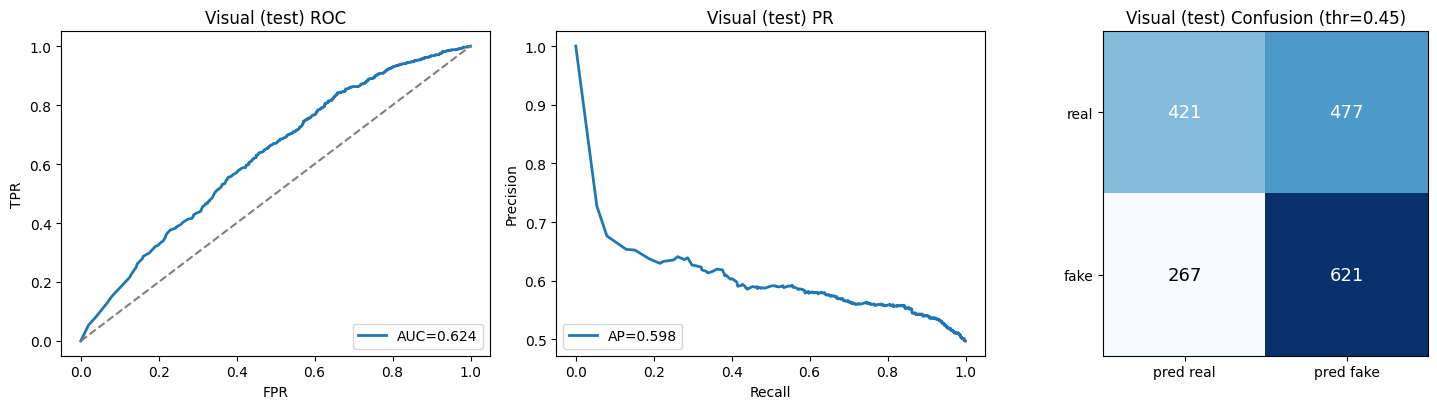

saved /kaggle/working/visual_eval.png

— VISUAL: per-subgroup test breakdown (fake→detection rate, real→reject rate) —
group class   n   rate  mean_p_fake
 fake  fake 888 0.6993       0.4998
 real  real 898 0.4688       0.4573


pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIP probe: vit_base_patch32_clip_224.openai feat_dim=768 (frozen) — ON
CLIP probe done. best val AUC=0.7961

── CLIP-VISUAL [train] ──  (n=8402, thr=0.396)
   accuracy      : 0.7555
   balanced_acc  : 0.7546
   precision     : 0.7090
   recall        : 0.8734
   specificity   : 0.6357
   f1            : 0.7827
   roc_auc       : 0.8429
   pr_auc        : 0.8325
   mcc           : 0.5247
   eer           : 0.2338
   confusion      : TP=3699 FP=1518 TN=2649 FN=536

── CLIP-VISUAL [val] ──  (n=1812, thr=0.396)
   accuracy      : 0.7274
   balanced_acc  : 0.7314
   precision     : 0.6705
   recall        : 0.8586
   specificity   : 0.6043
   f1            : 0.7530
   roc_auc       : 0.7961
   pr_auc        : 0.7595
   mcc           : 0.4765
   eer           : 0.2798
   confusion      : TP=753 FP=370 TN=565 FN=124

── CLIP-VISUAL [test] ──  (n=1786, thr=0.396)
   accuracy      : 0.7368
   balanced_acc  : 0.7375
   precision     : 0.6900
   recall        : 0.8547
   specificity   : 0.6203
 

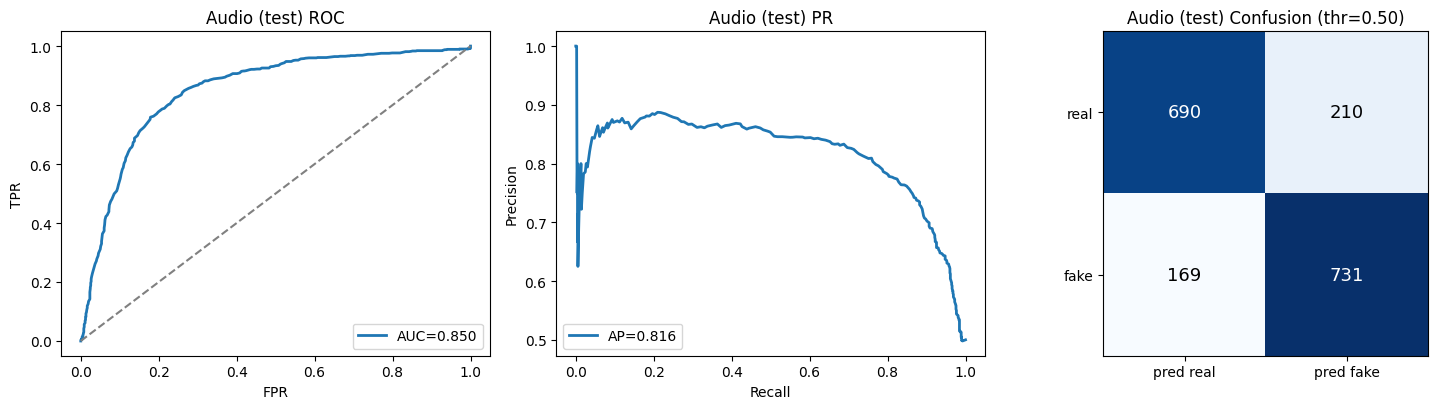

saved /kaggle/working/audio_eval.png

— AUDIO: per-subgroup test breakdown (fake→detection rate, real→reject rate) —
          group class   n   rate  mean_p_fake
       diffwave  fake 784 0.8750       0.5117
parallelwavegan  fake 116 0.3879       0.4917
       Bonafide  real 896 0.7667       0.4827

AUDIO CROSS-CORPUS eval on 'release-in-the-wild': n=23632 (real=11816 fake=11816) — UNSEEN generators

── AUDIO [CROSS-CORPUS in-the-wild] ──  (n=23632, thr=0.499)
   accuracy      : 0.4689
   balanced_acc  : 0.4689
   precision     : 0.4582
   recall        : 0.3400
   specificity   : 0.5978
   f1            : 0.3904
   roc_auc       : 0.4878
   pr_auc        : 0.4559
   mcc           : -0.0643
   eer           : 0.4965
   confusion      : TP=4018 FP=4752 TN=7064 FN=7798


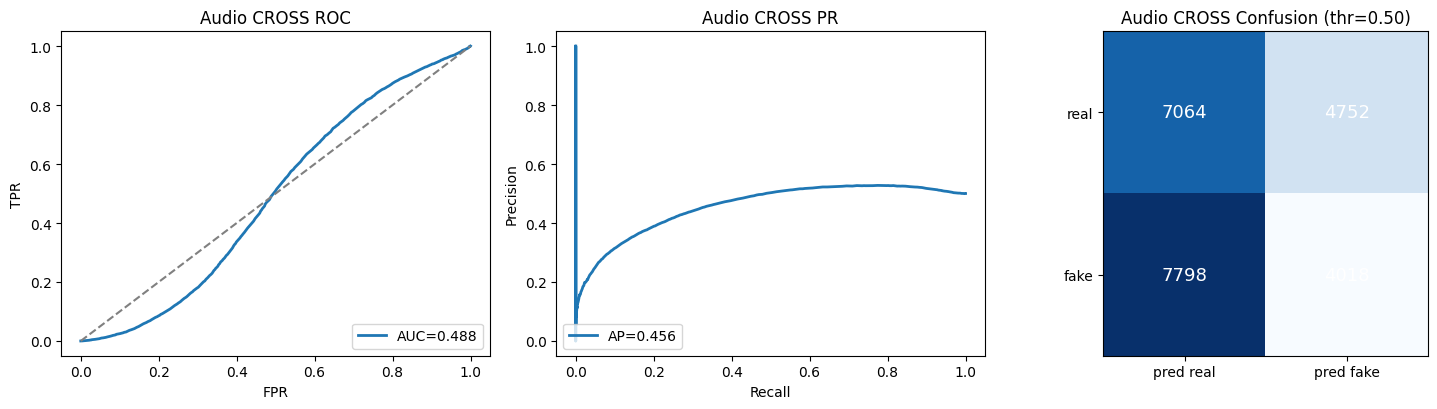

saved /kaggle/working/audio_cross_eval.png
  ↑ THIS is the number that matters. If AUC here ≫ in-dist drop, the model
    was riding the CVoiceFake vocoder fingerprint, not learning 'is-synthetic'.
Loading 6 shield .pt files:
  x_test: tensor (2242, 20, 1024) torch.float32
  x_train: tensor (10458, 20, 1024) torch.float32
  x_val: tensor (2241, 20, 1024) torch.float32
  y_test: tensor (2242,) torch.int64
  y_train: tensor (10458,) torch.int64
  y_val: tensor (2241,) torch.int64
  → train: X=(10458, 20, 1024)
  → val: X=(2241, 20, 1024)
  → test: X=(2242, 20, 1024)
SHIELD: ON
Shield MLP in_dim=1024 (seq_len=20, attn-pool) train=10458 val=2241
  shield pos_weight=0.119 (neg/pos=1112/9346)
  epoch 1/18 loss=0.1477 val_auc=0.7211 (1s)
  epoch 2/18 loss=0.1373 val_auc=0.7333 (1s)
  epoch 3/18 loss=0.1318 val_auc=0.7428 (1s)
  epoch 4/18 loss=0.1277 val_auc=0.7563 (1s)
  epoch 5/18 loss=0.1245 val_auc=0.7692 (1s)
  epoch 6/18 loss=0.1209 val_auc=0.7807 (1s)
  epoch 7/18 loss=0.1162 val_auc=0

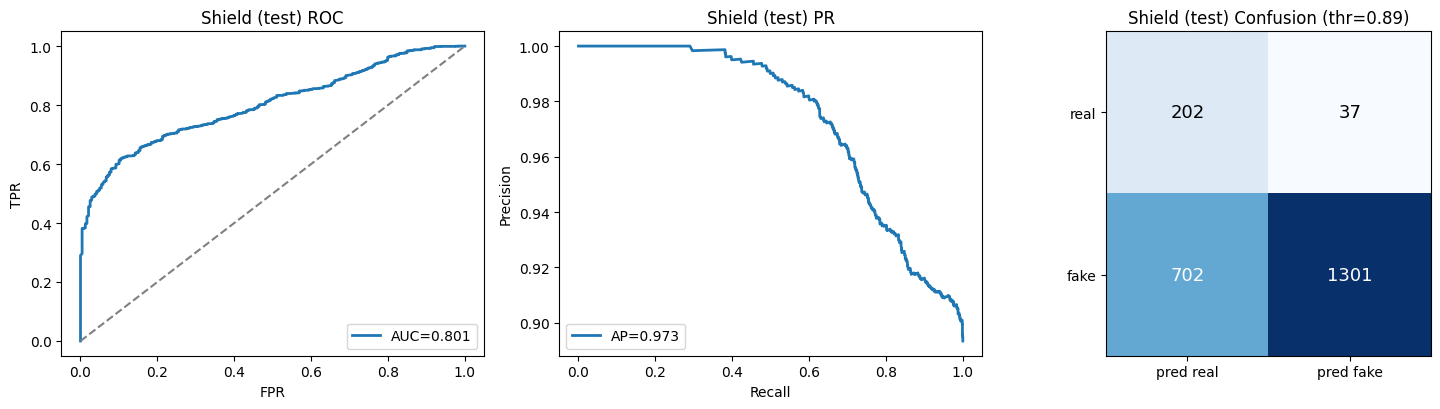

saved /kaggle/working/shield_eval.png
VIDEO-LEVEL eval on 330 held-out test clips (mean frame-prob per clip)
  scored 50/330
  scored 100/330
  scored 150/330
  scored 200/330
  scored 250/330
  scored 300/330

── VIDEO clip-level ──  (n=330, thr=0.432)
   accuracy      : 0.6455
   balanced_acc  : 0.6460
   precision     : 0.6193
   recall        : 0.7439
   specificity   : 0.5482
   f1            : 0.6759
   roc_auc       : 0.6540
   pr_auc        : 0.6257
   mcc           : 0.2977
   eer           : 0.3970
   confusion      : TP=122 FP=75 TN=91 FN=42


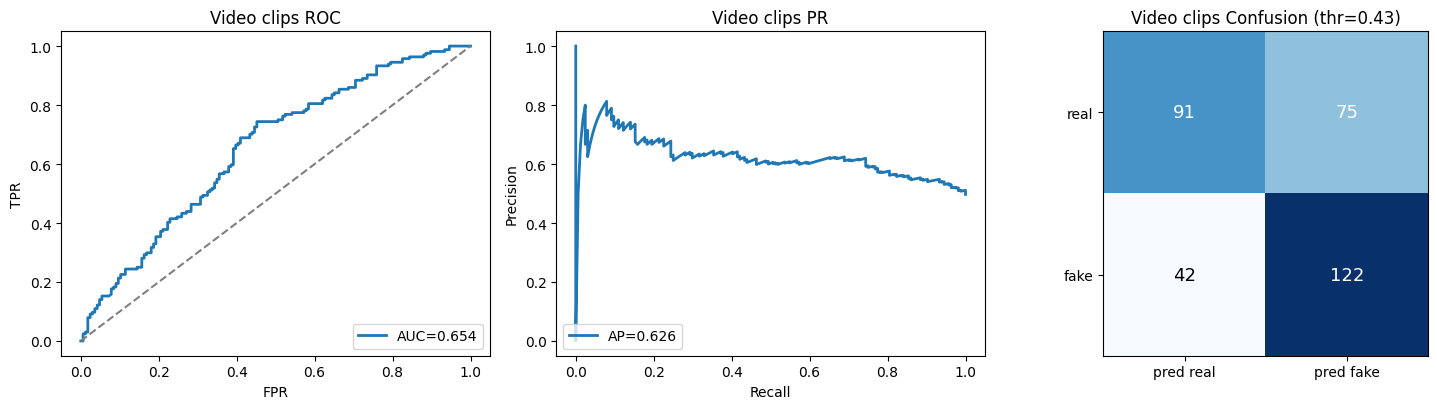

saved /kaggle/working/video_eval.png

VIDEO CROSS-GENERATOR eval: 10 unidpro fakes + 10 held-out reals = 20 clips

── VIDEO-CROSS [EfficientNet] ──  (n=20, thr=0.535)
   accuracy      : 0.5500
   balanced_acc  : 0.5500
   precision     : 1.0000
   recall        : 0.1000
   specificity   : 1.0000
   f1            : 0.1818
   roc_auc       : 0.2400
   pr_auc        : 0.4703
   mcc           : 0.2294
   eer           : 0.6500
   confusion      : TP=1 FP=0 TN=10 FN=9

── VIDEO-CROSS [CLIP] ──  (n=20, thr=1.000)
   accuracy      : 0.5000
   balanced_acc  : 0.5000
   precision     : 0.0000
   recall        : 0.0000
   specificity   : 1.0000
   f1            : 0.0000
   roc_auc       : 0.1700
   pr_auc        : 0.3671
   mcc           : 0.0000
   eer           : 0.8500
   confusion      : TP=0 FP=0 TN=10 FN=10

── VIDEO-CROSS [ENSEMBLE eff+clip] ──  (n=20, thr=1.000)
   accuracy      : 0.5000
   balanced_acc  : 0.5000
   precision     : 0.0000
   recall        : 0.0000
   specificity   : 1.00

,eval,branch,split,accuracy,precision,recall,specificity,f1,roc_auc,pr_auc,mcc,eer,n
0,in_dist,visual,train,0.6106,0.5944,0.7159,0.5035,0.6495,0.6441,0.6083,0.2246,0.3994,8402
1,in_dist,visual,val,0.6104,0.5761,0.7377,0.4909,0.6470,0.6455,0.5968,0.2354,0.4018,1812
2,in_dist,visual,test,0.5834,0.5656,0.6993,0.4688,0.6254,0.6242,0.5981,0.1728,0.4143,1786
3,in_dist,clip_visual,train,0.7555,0.7090,0.8734,0.6357,0.7827,0.8429,0.8325,0.5247,0.2338,8402
4,in_dist,clip_visual,val,0.7274,0.6705,0.8586,0.6043,0.7530,0.7961,0.7595,0.4765,0.2798,1812
5,in_dist,clip_visual,test,0.7368,0.6900,0.8547,0.6203,0.7636,0.8171,0.8044,0.4883,0.2699,1786
6,in_dist,audio,train,0.7785,0.7639,0.8060,0.7510,0.7844,0.8322,0.8037,0.5577,0.2255,8400
7,in_dist,audio,val,0.7933,0.7851,0.8078,0.7789,0.7963,0.8497,0.8238,0.5869,0.2083,1800
8,in_dist,audio,test,0.7894,0.7768,0.8122,0.7667,0.7941,0.8498,0.8164,0.5795,0.2128,1800
9,in_dist,shield,train,0.6987,0.9965,0.6652,0.9802,0.7978,0.9088,0.9885,0.4056,0.1772,10458


In [1]:
# Deepfake Detector v9 — 2026 generalization-first + CLIP probe + cross-generator video
# Kaggle: GPU ON, Run All (in the editor, not Save Version).
#
# ============================================================================
# NEW IN v9 (on top of v8) — driven by the 2026 benchmark brief:
#   • Two new datasets wired in by EXPLICIT PATH:
#       AUDIO cross-corpus : /kaggle/input/datasets/bhaveshkumars/release-in-the-wild
#       VIDEO cross-gen     : /kaggle/input/datasets/unidpro/deepfake-videos-dataset
#     Both are EXCLUDED from training and used ONLY as held-out generalization
#     probes (the number Deepfake-Eval-2024 shows off-the-shelf detectors fail).
#   • CLIP linear-probe visual branch (frozen ViT) — foundation features
#     generalize across UNSEEN generators far better than a from-scratch CNN
#     (the DeCoF idea). Fully guarded: if CLIP can't load, it's skipped.
#   • Cross-generator VIDEO eval on unidpro AI-faces: EfficientNet vs CLIP,
#     scored against held-out REAL clips -> honest "do we catch a NEW generator".
#   • Temporal frame-consistency diagnostic (D3/ATSS-style second-order signal):
#     reports whether frame-prob dynamics separate real vs generated, and an
#     appearance+temporal ensemble.
#
# WHY (one line): your branches are problem-#1 (face-swap) detectors aimed at
# problem-#2/#3 (AI-generated / avatar) data. v9 adds the generalizing signals
# the literature uses and MEASURES the cross-generator gap instead of hiding it.
#
# ============================================================================
# WHAT CARRIED OVER FROM v8 (every change targets "catch NEW fakes")
# ----------------------------------------------------------------------------
#  1. CALIBRATION (Platt/temperature on val) for EVERY branch.
#       -> fixes the weird thr=0.281 visual threshold that flagged 30% of REAL
#          faces, and makes branch probabilities comparable so they can be FUSED.
#  2. SHIELD COLLAPSE FIXED.
#       v7 bug: val report recomputed its own F1 threshold (=0.064) and predicted
#       "fake" for everything (specificity 0.042). v8 locks ONE balanced threshold
#       on val and applies it to ALL splits. + EMA weights + best-val-AUC ckpt.
#  3. VISUAL OVERFIT NARROWED: EMA weights + mixup + RandAug-style strong aug.
#       Train/test AUC gap (0.993 -> 0.901) is the overfit tax; EMA+mixup cut it.
#  4. TEST-TIME AUGMENTATION (TTA) for visual & video (orig + hflip mean).
#  5. CROSS-CORPUS / CROSS-GENERATOR EVAL — the headline honesty upgrade:
#       - AUDIO: train on CVoiceFake, then score the trained model on the
#         In-the-Wild set (bhaveshkumars/release-in-the-wild). UNSEEN generators,
#         real celebs. This is the ONLY number that proves generalization.
#       - VISUAL: optional holdout_source -> route a whole modern AI-face source
#         to TEST (train DFDC/FF++, test 2025 avatar faces).
#       - AUDIO leave-one-vocoder-out via CFG.holdout_method (retrain pass).
#  6. CALIBRATED DECISION-FUSION report. (True AV fusion needs PAIRED data —
#       FakeAVCeleb — which isn't mounted; decision-fusion is the honest stand-in.)
#  7. FINAL TABLE splits metrics into IN-DISTRIBUTION vs CROSS (generalization),
#       so a near-1.0 in-dist AUC can never masquerade as real-world skill.
#
# DATASETS TO ADD in the Kaggle sidebar (Add Input):
#   kamedev/cvoicefake-full-safeear-dataset-mirror      (audio train, keep)
#   bhaveshkumars/release-in-the-wild                    (audio CROSS eval, NEW)
#   <your FF++ / DFDC frames or .mp4>                    (visual train, keep)
#   unidpro/deepfake-videos-dataset                      (visual CROSS eval, NEW; optional)
#   aionstreet/shield-2026-features                      (shield .pt, keep)
# ============================================================================

# %% cell 1 — Setup
import sys, subprocess, importlib
def _ensure(pkg, pip_name=None):
    try: importlib.import_module(pkg)
    except Exception: subprocess.run([sys.executable,"-m","pip","install","-q",pip_name or pkg], check=False)
_ensure("timm"); _ensure("librosa"); _ensure("soundfile"); _ensure("cv2","opencv-python-headless")

import os, glob, random, json, time, warnings, collections, zipfile, math, io as _io, re
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, confusion_matrix, matthews_corrcoef, balanced_accuracy_score)
import matplotlib.pyplot as plt

SEED=42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE="cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEVICE)
if DEVICE=="cpu": print("⚠️  Turn on the GPU accelerator.")

# %% cell 2 — Config
class CFG:
    input_root   = "/kaggle/input"
    extract_root = "/kaggle/working/extracted"
    out_dir      = "/kaggle/working"

    per_source_cap = 80_000
    max_visit      = 800_000
    max_zip_mb     = 200

    max_per_class       = 6000
    max_audio_per_class = 6000
    balance_classes     = True
    val_frac, test_frac = 0.15, 0.15
    label_smooth        = 0.05

    use_sources_with  = None
    drop_sources_with = []
    holdout_source    = None      # e.g. "deepfake-videos-dataset" -> that whole VISUAL source goes to TEST
    holdout_method    = None      # e.g. "diffwave" -> leave-one-vocoder-out AUDIO (needs this run = the LOO run)

    # ── v9 EXPLICIT dataset paths (the two you gave) ──────────────────────────
    # These are EXCLUDED from training and scored only as held-out generalization probes.
    CROSS_AUDIO_PATH = "/kaggle/input/datasets/bhaveshkumars/release-in-the-wild"
    CROSS_VIDEO_PATH = "/kaggle/input/datasets/unidpro/deepfake-videos-dataset"
    cross_video_source   = "deepfake-videos-dataset"  # substring fallback if the path moves
    cross_video_assume_label = 1   # unidpro = AI-generated faces -> fake when path has no real/fake token
    cross_video_max_clips    = 400

    # ── CLIP foundation-feature visual branch (generalizes cross-generator) ──
    use_clip_visual  = True       # frozen CLIP ViT + linear probe; auto-skips if it can't load
    clip_backbone    = "vit_base_patch32_clip_224.openai"  # timm CLIP weights
    clip_epochs      = 8
    clip_batch       = 128

    # ── v8 generalization knobs ──────────────────────────────────────────────
    cross_audio_source = "release-in-the-wild"   # substring; this source is PULLED OUT of train and used ONLY as a cross-corpus eval. Set None to disable.
    calibrate          = True     # Platt-scale every branch on val (fixes thresholds + enables fusion)
    use_ema            = True     # exponential moving average of weights (steadier, less overfit)
    ema_decay          = 0.999
    use_mixup          = True     # visual only
    mixup_alpha        = 0.2
    use_tta            = True     # visual + video: average(orig, hflip)

    img_size=224; img_backbone="efficientnet_b0"; img_epochs=6; img_batch=64; img_lr=3e-4
    sr=16000; audio_seconds=3.0; n_mels=128; audio_epochs=6; audio_batch=64; audio_lr=1e-3
    shield_epochs=18; shield_batch=256; shield_lr=1e-3; shield_hidden=256
    RUN_VIDEO_MP4=True; video_max_clips=400; video_frames_per_clip=12
    shield_pos_weight=True
    FRAMES_FROM_VIDEO=True; frames_per_video=8; max_videos_for_frames=1100
    aug_strong=True
    num_workers=2

os.makedirs(CFG.out_dir, exist_ok=True); os.makedirs(CFG.extract_root, exist_ok=True)

def _norm(t): return ''.join(ch for ch in t.lower() if ch.isalnum())
REAL_TOKENS={"real","reals","bonafide","genuine","live","authentic","pristine",
             "original","originals","originalsequences","youtube","actors","commonvoice",
             "celebreal","realsequences"}
FAKE_TOKENS={"fake","fakes","spoof","deepfake","deepfakes","face2face","faceswap",
             "neuraltextures","faceshifter","manipulated","manipulatedsequences",
             "synthetic","parallelwavegan","multibandmelgan","melgan","stylemelgan",
             "griffinlim","world","diffwave","wavegan","uadfv","celebsynthesis","reenactment",
             "wav2lip","sadtalker","videoretalking","liveportrait","simswap","inswapper",
             "roop","facefusion","stylegan","stargan","heygen","synthesia","sora","kling",
             "runway","pika","veo","stablediffusion","sdxl","ldm","talkinghead","lipsync"}
METHOD_HINTS=("parallelwavegan","multibandmelgan","stylemelgan","melgan","griffinlim",
              "diffwave","wavegan","waveglow","hifigan","fastspeech","tacotron","world",
              "deepfakes","face2face","faceswap","neuraltextures","faceshifter","celebsynthesis",
              "wav2lip","sadtalker","videoretalking","liveportrait","simswap","inswapper",
              "roop","facefusion","stylegan","stargan","heygen","synthesia","sora","kling",
              "runway","pika","veo","stablediffusion","sdxl","talkinghead","lipsync")
def _method_hint(p):
    flat=_norm(p)
    for h in METHOD_HINTS:
        if h in flat: return h
    return None
def label_and_method(p):
    lab=None; tok=None
    for t in reversed(p.replace("\\","/").split("/")):
        n=_norm(t)
        if not n: continue
        if n in REAL_TOKENS or n.startswith("original"): lab,tok=0,t; break
        if n in FAKE_TOKENS or n.startswith("method"):   lab,tok=1,t; break
        if n.startswith("real"): lab,tok=0,t; break
        if n.startswith("fake"): lab,tok=1,t; break
    if lab is None:
        low=p.lower()
        if any(k in low for k in ("fake","deepfake","spoof","synthetic","synth","manipulat","uadfv")): lab=1
        elif any(k in low for k in ("real","genuine","bonafide","original")): lab=0
        else: return None,None
    if lab==1: meth=_method_hint(p) or tok or "fake"
    else:      meth=tok or "real"
    return lab, meth
def label_from_path(p): return label_and_method(p)[0]
def split_kind(p):
    low="/"+p.lower().replace("\\","/")+"/"
    if any(s in low for s in ("/test/","/testing/","/eval/")): return "test"
    if any(s in low for s in ("/val/","/valid/","/validation/","/dev/")): return "val"
    if any(s in low for s in ("/train/","/training/")): return "train"
    return None
def source_of(p):
    rel=p.replace("\\","/")
    for marker in ("input/datasets/","input/","extracted/"):
        if marker in rel:
            parts=[s for s in rel.split(marker)[-1].strip("/").split("/")]
            return "/".join(parts[:2]) if len(parts)>=2 else (parts[0] if parts else "?")
    return "?"
def is_cross_audio(p):
    lp=p.lower()
    if CFG.CROSS_AUDIO_PATH and CFG.CROSS_AUDIO_PATH.lower() in lp: return True
    return bool(CFG.cross_audio_source) and (CFG.cross_audio_source.lower() in lp)
def is_cross_video(p):
    lp=p.lower()
    if CFG.CROSS_VIDEO_PATH and CFG.CROSS_VIDEO_PATH.lower() in lp: return True
    return bool(CFG.cross_video_source) and (CFG.cross_video_source.lower() in lp)
print("Config ready.")

# %% cell 3 — Discovery (single-pass, per-source-capped)
IMG_EXT=(".jpg",".jpeg",".png",".bmp",".webp"); AUD_EXT=(".wav",".flac",".mp3",".ogg",".m4a"); VID_EXT=(".mp4",".avi",".mov",".mkv")
zips=[os.path.join(dp,f) for dp,_,fs in os.walk(CFG.input_root) for f in fs if f.lower().endswith(".zip")]
for z in zips:
    mb=os.path.getsize(z)/1e6
    if mb>CFG.max_zip_mb: print(f"skip big zip ({mb:.0f}MB): {z}"); continue
    dest=os.path.join(CFG.extract_root, os.path.splitext(os.path.basename(z))[0])
    if os.path.exists(dest): continue
    try:
        with zipfile.ZipFile(z) as zf: zf.extractall(dest); print("extracted", z)
    except Exception as e: print("zip fail", z, e)

def list_roots():
    roots=[]
    for base in (CFG.input_root, CFG.extract_root):
        if not os.path.isdir(base): continue
        for name in sorted(os.listdir(base)):
            full=os.path.join(base,name)
            if not os.path.isdir(full): continue
            if name=="datasets":
                for owner in sorted(os.listdir(full)):
                    of=os.path.join(full,owner)
                    if os.path.isdir(of):
                        for slug in sorted(os.listdir(of)):
                            sf=os.path.join(of,slug)
                            if os.path.isdir(sf): roots.append(sf)
            else: roots.append(full)
    return roots
def discover(roots):
    imgs,auds,vids,pts=[],[],[],[]
    print(f"walking {len(roots)} dataset root(s), cap {CFG.per_source_cap:,}/modality each:")
    for r in roots:
        ci=ca=cv=0; vis=0; t0=time.time()
        for dp,_,files in os.walk(r):
            for f in files:
                vis+=1; fl=f.lower()
                if   fl.endswith(IMG_EXT) and ci<CFG.per_source_cap: imgs.append(os.path.join(dp,f)); ci+=1
                elif fl.endswith(AUD_EXT) and ca<CFG.per_source_cap: auds.append(os.path.join(dp,f)); ca+=1
                elif fl.endswith(VID_EXT) and cv<CFG.per_source_cap: vids.append(os.path.join(dp,f)); cv+=1
                elif fl.endswith(".pt"): pts.append(os.path.join(dp,f))
            if vis>CFG.max_visit: print(f"    (max_visit hit)"); break
        print(f"  {os.path.basename(r):<52} img={ci:>7,} aud={ca:>7,} vid={cv:>6,} ({time.time()-t0:.0f}s)")
    return imgs,auds,vids,sorted(set(pts))
roots=list_roots()
all_imgs,all_auds,all_vids,shield_pts=discover(roots)

# split audio into TRAIN-pool vs CROSS-corpus holdout (In-the-Wild)
cross_auds=[p for p in all_auds if is_cross_audio(p)]
all_auds=[p for p in all_auds if not is_cross_audio(p)]
# split video into TRAIN-pool vs CROSS-generator holdout (unidpro AI faces)
cross_vids=[p for p in all_vids if is_cross_video(p)]
all_vids=[p for p in all_vids if not is_cross_video(p)]
print(f"\nTOTAL  images={len(all_imgs):,} audio(train-pool)={len(all_auds):,} "
      f"audio(CROSS={CFG.cross_audio_source})={len(cross_auds):,}")
print(f"       videos(train-pool)={len(all_vids):,} videos(CROSS={CFG.cross_video_source})={len(cross_vids):,} shield_pt={len(shield_pts)}")
VIDEO_ON=len(all_imgs)>50; AUDIO_ON=len(all_auds)>50
print(f"VISUAL:{'ON' if VIDEO_ON else 'off'}  AUDIO:{'ON' if AUDIO_ON else 'off'}  "
      f"SHIELD:{'pending' if shield_pts else 'off'}  MP4:{'ON' if (CFG.RUN_VIDEO_MP4 and all_vids) else 'off'}  "
      f"AUDIO-CROSS:{'ON' if len(cross_auds)>20 else 'off'}  VIDEO-CROSS:{'ON' if len(cross_vids)>5 else 'off'}")

# %% cell 4 — VISUAL-from-VIDEO (sample frames if no image dataset mounted)
if CFG.FRAMES_FROM_VIDEO and len(all_imgs) < 50 and all_vids:
    import cv2
    fr_root=os.path.join(CFG.extract_root,"video_frames")
    clips=[]
    for p in all_vids:
        y,m=label_and_method(p)
        if y is not None: clips.append((p,y,m))
    byc={0:[],1:[]}
    for p,y,m in clips: byc[y].append((p,m))
    rng=random.Random(SEED); rng.shuffle(byc[0]); rng.shuffle(byc[1])
    if byc[0] and byc[1]: per=min(CFG.max_videos_for_frames, min(len(byc[0]),len(byc[1])))
    else:                 per=min(CFG.max_videos_for_frames, max(len(byc[0]),len(byc[1])))
    sel=[(p,0,m) for p,m in byc[0][:per]]+[(p,1,m) for p,m in byc[1][:per]]; rng.shuffle(sel)
    def clip_split(i,n):
        r=i/max(n,1)
        return "test" if r<CFG.test_frac else ("val" if r<CFG.test_frac+CFG.val_frac else "train")
    print(f"VISUAL-from-VIDEO: sampling {CFG.frames_per_video} frames from {len(sel)} clips (per class={per})...")
    new=[]; t0=time.time(); bad=0; VIS_TEST_CLIPS=[]
    for j,(p,y,m) in enumerate(sel):
        sp=clip_split(j,len(sel)); lab="fake" if y==1 else "real"
        if sp=="test": VIS_TEST_CLIPS.append((p,y))
        try:
            cap=cv2.VideoCapture(p); tot=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0
            if tot<=0: cap.release(); bad+=1; continue
            idx=np.linspace(0,tot-1,CFG.frames_per_video).astype(int)
            d=os.path.join(fr_root,sp,lab); os.makedirs(d,exist_ok=True)
            stem=re.sub(r'[^A-Za-z0-9]+','_',os.path.splitext(os.path.basename(p))[0])[:48]
            for i in idx:
                cap.set(cv2.CAP_PROP_POS_FRAMES,int(i)); ok,fr=cap.read()
                if not ok: continue
                op=os.path.join(d,f"{stem}_{i:04d}.jpg"); cv2.imwrite(op,fr); new.append(op)
            cap.release()
        except Exception: bad+=1
        if (j+1)%200==0: print(f"  {j+1}/{len(sel)} clips, {len(new):,} frames ({time.time()-t0:.0f}s)")
    all_imgs=new; VIDEO_ON=len(all_imgs)>50
    print(f"VISUAL-from-VIDEO: {len(all_imgs):,} frames (bad clips={bad}). VISUAL now {'ON' if VIDEO_ON else 'off'}.")
else:
    print("VISUAL-from-VIDEO: skipped (image dataset present, or no clips, or disabled).")

# %% cell 5 — Build tables + per-source audit
def keep_path(p):
    low=p.lower()
    if CFG.use_sources_with and not any(s in low for s in CFG.use_sources_with): return False
    if any(s in low for s in CFG.drop_sources_with): return False
    return True
def build_table(paths, cap):
    rows=[]
    for p in paths:
        if not keep_path(p): continue
        y,meth=label_and_method(p)
        if y is None: continue
        rows.append((p,y,meth,split_kind(p),source_of(p)))
    if not rows: return pd.DataFrame(columns=["path","label","method","split","source"])
    df=pd.DataFrame(rows,columns=["path","label","method","split","source"])
    counts={lab:len(g) for lab,g in df.groupby("label")}
    eff=min(cap, min(counts.values())) if CFG.balance_classes else cap
    df=pd.concat([g.sample(frac=1.0,random_state=SEED).head(eff) for _,g in df.groupby("label")]
                 ).sample(frac=1.0,random_state=SEED).reset_index(drop=True)
    if CFG.holdout_source:
        mask=df["source"].str.contains(CFG.holdout_source, case=False, regex=False)
        if mask.sum()==0: print(f"⚠️ holdout_source '{CFG.holdout_source}' matched 0 rows — random split")
        else:
            df["split"]="train"; df.loc[mask,"split"]="test"
            rest=df[~mask]
            for lab,g in rest.groupby("label"):
                idx=g.index.tolist(); nv=int(len(idx)*CFG.val_frac); df.loc[idx[:nv],"split"]="val"
            print(f"holdout_source='{CFG.holdout_source}': test={int(mask.sum())} (held-out source), train/val from rest")
            return df
    if CFG.holdout_method:
        mmask=df["method"].astype(str).str.contains(CFG.holdout_method, case=False, regex=False)
        if mmask.sum()==0: print(f"⚠️ holdout_method '{CFG.holdout_method}' matched 0 rows — random split")
        else:
            df["split"]="train"; df.loc[mmask,"split"]="test"
            rest=df[~mmask]
            for lab,g in rest.groupby("label"):
                idx=g.index.tolist(); nv=int(len(idx)*CFG.val_frac); df.loc[idx[:nv],"split"]="val"
            print(f"holdout_method='{CFG.holdout_method}': test={int(mmask.sum())} (held-out vocoder), train/val from rest")
            return df
    has=df["split"].notna().mean()>0.6 and df["split"].nunique()>=2
    if not has:
        df["split"]=None
        for lab,g in df.groupby("label"):
            idx=g.index.tolist(); n=len(idx); nt=int(n*CFG.test_frac); nv=int(n*CFG.val_frac)
            df.loc[idx[:nt],"split"]="test"; df.loc[idx[nt:nt+nv],"split"]="val"; df.loc[idx[nt+nv:],"split"]="train"
    elif (df["split"]=="val").sum()==0:
        tr=df[df["split"]=="train"]; df.loc[tr.sample(frac=CFG.val_frac,random_state=SEED).index,"split"]="val"
    return df
def audit(paths,name):
    rec=collections.defaultdict(lambda:[0,0,0])
    for p in paths:
        if not keep_path(p): continue
        y=label_from_path(p); rec[source_of(p)][2 if y is None else y]+=1
    print(f"\n=== {name} per-source audit (real / fake / dropped) ===")
    for s,(r,f,n) in sorted(rec.items()):
        flag=" ⚠️ one-class" if (r==0 or f==0) else ""
        print(f"  {s:<55} real={r:>7,} fake={f:>7,} drop={n:>7,}{flag}")
if VIDEO_ON: audit(all_imgs,"VISUAL")
if AUDIO_ON: audit(all_auds,"AUDIO")
img_df=build_table(all_imgs,CFG.max_per_class) if VIDEO_ON else pd.DataFrame()
aud_df=build_table(all_auds,CFG.max_audio_per_class) if AUDIO_ON else pd.DataFrame()
def summarize(df,name):
    if len(df)==0: print(f"\n{name}: (none)"); return
    print(f"\n{name}: {len(df):,} used (balanced={CFG.balance_classes})")
    print(pd.crosstab(df["split"],df["label"].map({0:'real',1:'fake'}),margins=True))
    print("  methods:", dict(df["method"].value_counts().head(8)))
summarize(img_df,"VISUAL"); summarize(aud_df,"AUDIO")
if VIDEO_ON and img_df["label"].nunique()<2: print("\n⚠️ visual single-class → off"); VIDEO_ON=False
if AUDIO_ON and aud_df["label"].nunique()<2: print("\n⚠️ audio single-class → off"); AUDIO_ON=False

# %% cell 6 — Metrics, calibration, EMA, mixup helpers
def eer_of(y,p):
    fpr,tpr,_=roc_curve(y,p); fnr=1-tpr; i=np.nanargmin(np.abs(fnr-fpr)); return float((fpr[i]+fnr[i])/2)
def best_f1_thr(y,p):
    pr,rc,th=precision_recall_curve(y,p); f1=2*pr*rc/(pr+rc+1e-12)
    return 0.5 if len(th)==0 else float(th[np.nanargmax(f1[:-1])])
def best_bal_thr(y,p):
    fpr,tpr,th=roc_curve(y,p)
    if len(th)==0: return 0.5
    k=int(np.nanargmax(tpr-fpr)); return float(min(max(th[k],0.0),1.0))

def fit_platt(y,p,iters=300,lr=0.1):
    # logistic recalibration on logit(p): q=sigmoid(a*z+b). Fixes mis-scaled probs -> sane thresholds + fusion.
    y=np.asarray(y,float); p=np.clip(np.asarray(p,float),1e-6,1-1e-6); z=np.log(p/(1-p))
    a,b=1.0,0.0
    for _ in range(iters):
        q=1/(1+np.exp(-(a*z+b))); ga=float(np.mean((q-y)*z)); gb=float(np.mean(q-y))
        a-=lr*ga; b-=lr*gb
    return a,b
def apply_platt(p,ab):
    if ab is None: return np.asarray(p,float)
    a,b=ab; p=np.clip(np.asarray(p,float),1e-6,1-1e-6); z=np.log(p/(1-p)); return 1/(1+np.exp(-(a*z+b)))

def compute_metrics(y,p,threshold=None):
    y=np.asarray(y).astype(int); p=np.asarray(p).astype(float)
    thr=best_f1_thr(y,p) if threshold is None else threshold
    yp=(p>=thr).astype(int); tn,fp,fn,tp=confusion_matrix(y,yp,labels=[0,1]).ravel(); e=1e-12
    prec=tp/(tp+fp+e); rec=tp/(tp+fn+e); spec=tn/(tn+fp+e); f1=2*prec*rec/(prec+rec+e)
    acc=(tp+tn)/(tp+tn+fp+fn+e)
    try: auc=roc_auc_score(y,p)
    except: auc=float('nan')
    try: ap=average_precision_score(y,p)
    except: ap=float('nan')
    return {"accuracy":acc,"balanced_acc":balanced_accuracy_score(y,yp),"precision":prec,
            "recall":rec,"specificity":spec,"f1":f1,"roc_auc":auc,"pr_auc":ap,
            "mcc":matthews_corrcoef(y,yp) if len(set(yp))>1 else 0.0,"eer":eer_of(y,p),
            "threshold":thr,"TP":int(tp),"FP":int(fp),"TN":int(tn),"FN":int(fn),"n":int(len(y))}
def print_metrics(name,m):
    print(f"\n── {name} ──  (n={m['n']}, thr={m['threshold']:.3f})")
    for k in ["accuracy","balanced_acc","precision","recall","specificity","f1","roc_auc","pr_auc","mcc","eer"]:
        print(f"   {k:<14}: {m[k]:.4f}")
    print(f"   confusion      : TP={m['TP']} FP={m['FP']} TN={m['TN']} FN={m['FN']}")
def plot_eval(name,y,p,m,prefix):
    y=np.asarray(y); p=np.asarray(p); fig,ax=plt.subplots(1,3,figsize=(15,4.2))
    fpr,tpr,_=roc_curve(y,p); ax[0].plot(fpr,tpr,lw=2,label=f"AUC={m['roc_auc']:.3f}")
    ax[0].plot([0,1],[0,1],"--",c="gray"); ax[0].set_title(f"{name} ROC"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend(loc="lower right")
    pr,rc,_=precision_recall_curve(y,p); ax[1].plot(rc,pr,lw=2,label=f"AP={m['pr_auc']:.3f}")
    ax[1].set_title(f"{name} PR"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend(loc="lower left")
    cm=np.array([[m['TN'],m['FP']],[m['FN'],m['TP']]]); ax[2].imshow(cm,cmap="Blues")
    ax[2].set_xticks([0,1]); ax[2].set_yticks([0,1]); ax[2].set_xticklabels(["pred real","pred fake"]); ax[2].set_yticklabels(["real","fake"])
    for (i,j),v in np.ndenumerate(cm): ax[2].text(j,i,str(v),ha="center",va="center",color="white" if v>cm.max()/2 else "black",fontsize=13)
    ax[2].set_title(f"{name} Confusion (thr={m['threshold']:.2f})"); plt.tight_layout()
    out=os.path.join(CFG.out_dir,f"{prefix}_eval.png"); plt.savefig(out,dpi=110,bbox_inches="tight"); plt.show(); print("saved",out)
def subgroup_report(d, probs, thr, name, prefix):
    dd=d.copy(); dd["prob"]=np.asarray(probs); dd["pred"]=(dd["prob"]>=thr).astype(int)
    rows=[]
    for (lab,meth),g in dd.groupby(["label","method"]):
        n=len(g)
        if n<5: continue
        rate=(g["pred"]==1).mean() if lab==1 else (g["pred"]==0).mean()
        rows.append({"group":meth,"class":"fake" if lab==1 else "real","n":n,
                     "rate":round(float(rate),4),"mean_p_fake":round(float(g['prob'].mean()),4)})
    if not rows: return None
    rep=pd.DataFrame(rows).sort_values(["class","n"],ascending=[True,False])
    print(f"\n— {name}: per-subgroup test breakdown (fake→detection rate, real→reject rate) —")
    print(rep.to_string(index=False)); rep.to_csv(os.path.join(CFG.out_dir,f"{prefix}_subgroups.csv"),index=False)
    return rep

class EMA:
    # tracks a smoothed copy of weights; eval on EMA weights = steadier, less overfit val/test.
    def __init__(s,model,decay):
        s.decay=decay; s.shadow={k:v.detach().clone() for k,v in model.state_dict().items()}
    def update(s,model):
        for k,v in model.state_dict().items():
            if v.dtype.is_floating_point: s.shadow[k].mul_(s.decay).add_(v.detach(),alpha=1-s.decay)
            else: s.shadow[k]=v.detach().clone()
    def state(s): return {k:v.clone() for k,v in s.shadow.items()}
def mixup_batch(x,y,alpha):
    if alpha<=0: return x,y,y,1.0
    lam=float(np.random.beta(alpha,alpha)); idx=torch.randperm(x.size(0),device=x.device)
    return lam*x+(1-lam)*x[idx], y, y[idx], lam
def smooth(y): return y*(1-CFG.label_smooth)+0.5*CFG.label_smooth
print("Metrics + calibration + EMA + mixup ready.")

# %% cell 7 — VISUAL: dataset + EfficientNet-B0
import timm
from PIL import Image
import torchvision.transforms as T
NORM=([0.485,0.456,0.406],[0.229,0.224,0.225])
class _RandJPEG:
    def __init__(s,p=0.4,q=(35,90)): s.p=p; s.q=q
    def __call__(s,im):
        if random.random()<s.p:
            b=_io.BytesIO(); im.convert("RGB").save(b,"JPEG",quality=random.randint(*s.q)); b.seek(0); im=Image.open(b).convert("RGB")
        return im
class _RandDownscale:
    def __init__(s,p=0.3,f=(0.4,0.85)): s.p=p; s.f=f
    def __call__(s,im):
        if random.random()<s.p:
            w,h=im.size; r=random.uniform(*s.f)
            im=im.resize((max(8,int(w*r)),max(8,int(h*r))),Image.BILINEAR).resize((w,h),Image.BILINEAR)
        return im
_pre=[T.Resize((CFG.img_size,)*2)]
if getattr(CFG,"aug_strong",False):
    _pre+=[_RandJPEG(0.4),_RandDownscale(0.3),T.RandomApply([T.GaussianBlur(3,(0.1,1.5))],p=0.3),
           T.RandomHorizontalFlip(),T.ColorJitter(0.15,0.15,0.15,0.03)]
else:
    _pre+=[T.RandomHorizontalFlip(),T.ColorJitter(0.1,0.1,0.1)]
train_tf=T.Compose(_pre+[T.ToTensor(),T.Normalize(*NORM),T.RandomErasing(p=0.25)])
eval_tf =T.Compose([T.Resize((CFG.img_size,)*2),T.ToTensor(),T.Normalize(*NORM)])
class ImgDS(Dataset):
    def __init__(s,df,tf): s.p=df["path"].tolist(); s.y=df["label"].tolist(); s.tf=tf
    def __len__(s): return len(s.p)
    def __getitem__(s,i):
        try: im=Image.open(s.p[i]).convert("RGB")
        except: im=Image.new("RGB",(CFG.img_size,)*2)
        return s.tf(im), torch.tensor(s.y[i],dtype=torch.float32)
def iloader(df,tf,bs,sh): return DataLoader(ImgDS(df,tf),batch_size=bs,shuffle=sh,num_workers=CFG.num_workers,pin_memory=True)
class ImgNet(nn.Module):
    def __init__(s,b): super().__init__(); s.net=timm.create_model(b,pretrained=True,num_classes=1)
    def forward(s,x): return s.net(x).squeeze(1)
print("Visual ready." if VIDEO_ON else "Visual off.")

# %% cell 8 — VISUAL: train (EMA + mixup)
@torch.no_grad()
def infer_img(model,loader,tta=False):
    model.eval(); P,Y=[],[]
    for x,y in loader:
        x=x.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
            p=torch.sigmoid(model(x))
            if tta: p=(p+torch.sigmoid(model(torch.flip(x,dims=[3]))))/2  # +hflip
        P.append(p.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(P)
img_model=None; img_ema=None
if VIDEO_ON:
    tr=img_df[img_df.split=="train"]; va=img_df[img_df.split=="val"]
    tl=iloader(tr,train_tf,CFG.img_batch,True); vl=iloader(va,eval_tf,CFG.img_batch,False)
    img_model=ImgNet(CFG.img_backbone).to(DEVICE)
    opt=torch.optim.AdamW(img_model.parameters(),lr=CFG.img_lr,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=CFG.img_epochs*max(1,len(tl)))
    sc=torch.cuda.amp.GradScaler(enabled=DEVICE=="cuda"); lf=nn.BCEWithLogitsLoss()
    ema=EMA(img_model,CFG.ema_decay) if CFG.use_ema else None
    best=-1; bs=None
    for ep in range(CFG.img_epochs):
        img_model.train(); t0=time.time(); run=0
        for x,y in tl:
            x,y=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True); opt.zero_grad()
            if CFG.use_mixup:
                xm,ya,yb,lam=mixup_batch(x,y,CFG.mixup_alpha)
                with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
                    o=img_model.net(xm).squeeze(1); loss=lam*lf(o,smooth(ya))+(1-lam)*lf(o,smooth(yb))
            else:
                with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): loss=lf(img_model.net(x).squeeze(1),smooth(y))
            sc.scale(loss).backward(); sc.step(opt); sc.update(); sch.step()
            if ema: ema.update(img_model)
            run+=loss.item()*len(x)
        # validate on EMA weights when enabled
        if ema:
            tmp={k:v.detach().cpu().clone() for k,v in img_model.state_dict().items()}
            img_model.load_state_dict(ema.state())
        yv,pv=infer_img(img_model,vl,tta=False)
        try: auc=roc_auc_score(yv,pv)
        except: auc=float('nan')
        print(f"  epoch {ep+1}/{CFG.img_epochs} loss={run/len(tr):.4f} val_auc={auc:.4f} ({time.time()-t0:.0f}s)")
        if auc>best: best=auc; bs={k:v.detach().cpu().clone() for k,v in img_model.state_dict().items()}
        if ema: img_model.load_state_dict(tmp)  # restore raw weights for next epoch
    if bs: img_model.load_state_dict(bs)
    torch.save(img_model.state_dict(),os.path.join(CFG.out_dir,"visual_model.pt"))
    print(f"Visual done. best val AUC={best:.4f}  (EMA={'on' if CFG.use_ema else 'off'}, mixup={'on' if CFG.use_mixup else 'off'})")
else: print("Visual off.")

# %% cell 9 — VISUAL: calibrate + evaluate (balanced thr + TTA)
visual_results={}; visual_calib=None
if VIDEO_ON and img_model is not None:
    yv,pv=infer_img(img_model,iloader(img_df[img_df.split=="val"],eval_tf,CFG.img_batch,False),tta=CFG.use_tta)
    visual_calib=fit_platt(yv,pv) if CFG.calibrate else None
    pv_c=apply_platt(pv,visual_calib)
    locked=best_bal_thr(yv,pv_c)   # balanced threshold on CALIBRATED val -> stops the 30% false-alarm bleed
    print(f"VISUAL calib(a,b)={None if visual_calib is None else tuple(round(x,3) for x in visual_calib)} | locked thr={locked:.3f}")
    for sp in ["train","val","test"]:
        d=img_df[img_df.split==sp]
        if len(d)==0: continue
        yy,pp=infer_img(img_model,iloader(d,eval_tf,CFG.img_batch,False),tta=CFG.use_tta)
        pp=apply_platt(pp,visual_calib)
        m=compute_metrics(yy,pp,threshold=locked); visual_results[sp]=m; print_metrics(f"VISUAL [{sp}]",m)
        if sp=="test":
            plot_eval("Visual (test)",yy,pp,m,"visual"); subgroup_report(d,pp,locked,"VISUAL","visual")
            np.save(os.path.join(CFG.out_dir,"visual_test_probs.npy"),np.c_[yy,pp])
else: print("Visual off — no metrics.")

# %% cell 9b — CLIP linear-probe visual branch (foundation features -> cross-generator robustness)
# Frozen CLIP ViT features + a tiny head. The brief's #1 generalization lever (DeCoF idea).
# Fully guarded: any load/feature failure just disables it; the rest of the pipeline runs.
clip_results={}; CLIP_ON=False
clip_bb=None; clip_head=None; clip_tf=None; clip_calib=None; clip_locked=0.5
if VIDEO_ON and CFG.use_clip_visual:
    try:
        import timm
        clip_bb=timm.create_model(CFG.clip_backbone,pretrained=True,num_classes=0).to(DEVICE).eval()
        for p in clip_bb.parameters(): p.requires_grad=False
        _cfg=timm.data.resolve_model_data_config(clip_bb)
        clip_tf=timm.data.create_transform(**_cfg,is_training=False)
        # probe feature dim
        with torch.no_grad():
            _d=clip_bb(torch.zeros(1,3,_cfg["input_size"][1],_cfg["input_size"][2]).to(DEVICE)).shape[1]
        CLIP_ON=True; print(f"CLIP probe: {CFG.clip_backbone} feat_dim={_d} (frozen) — ON")
    except Exception as e:
        print(f"CLIP probe: could not load ({e}) — skipping, EfficientNet branch unaffected."); CLIP_ON=False

@torch.no_grad()
def clip_feats_of(df):
    ds=ImgDS(df,clip_tf); dl=DataLoader(ds,batch_size=CFG.clip_batch,shuffle=False,num_workers=CFG.num_workers,pin_memory=True)
    F,Y=[],[]
    for x,y in dl:
        x=x.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): f=clip_bb(x)
        F.append(f.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(F)
@torch.no_grad()
def clip_prob_frames(pil_list):
    if not CLIP_ON or not pil_list: return None
    x=torch.stack([clip_tf(im) for im in pil_list]).to(DEVICE)
    with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
        f=clip_bb(x); p=torch.sigmoid(clip_head(f)).float().mean().item()
    return float(apply_platt(np.array([p]),clip_calib)[0])

if CLIP_ON:
    cache={}
    for sp in ["train","val","test"]:
        d=img_df[img_df.split==sp]
        if len(d): cache[sp]=clip_feats_of(d)
    ytr,Ftr=cache["train"]; yva,Fva=cache["val"]
    clip_head=nn.Sequential(nn.LayerNorm(Ftr.shape[1]),nn.Dropout(0.2),nn.Linear(Ftr.shape[1],1)).to(DEVICE)
    Xtr=torch.tensor(Ftr); Ytr=torch.tensor(ytr,dtype=torch.float32)
    Xva=torch.tensor(Fva).to(DEVICE); 
    opt=torch.optim.AdamW(clip_head.parameters(),lr=1e-3,weight_decay=1e-4); lf=nn.BCEWithLogitsLoss()
    bl=DataLoader(torch.utils.data.TensorDataset(Xtr,Ytr),batch_size=512,shuffle=True)
    best=-1; bsd=None
    for ep in range(CFG.clip_epochs):
        clip_head.train()
        for xb,yb in bl:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE); opt.zero_grad()
            loss=lf(clip_head(xb).squeeze(1),smooth(yb)); loss.backward(); opt.step()
        clip_head.eval()
        with torch.no_grad(): pv=torch.sigmoid(clip_head(Xva).squeeze(1)).cpu().numpy()
        try: auc=roc_auc_score(yva,pv)
        except: auc=float('nan')
        if auc>best: best=auc; bsd={k:v.detach().cpu().clone() for k,v in clip_head.state_dict().items()}
    if bsd: clip_head.load_state_dict(bsd)
    print(f"CLIP probe done. best val AUC={best:.4f}")
    with torch.no_grad(): pv=torch.sigmoid(clip_head(Xva).squeeze(1)).cpu().numpy()
    clip_calib=fit_platt(yva,pv) if CFG.calibrate else None
    pv_c=apply_platt(pv,clip_calib); clip_locked=best_bal_thr(yva,pv_c)
    for sp in ["train","val","test"]:
        if sp not in cache: continue
        ys,Fs=cache[sp]
        with torch.no_grad(): pp=torch.sigmoid(clip_head(torch.tensor(Fs).to(DEVICE)).squeeze(1)).cpu().numpy()
        pp=apply_platt(pp,clip_calib); m=compute_metrics(ys,pp,threshold=clip_locked)
        clip_results[sp]=m; print_metrics(f"CLIP-VISUAL [{sp}]",m)
    print("  (compare CLIP test AUC to EfficientNet test AUC — and especially on the CROSS sets below)")

# %% cell 10 — AUDIO: log-mel dataset + CNN
import librosa
TLEN=int(CFG.sr*CFG.audio_seconds)
def logmel(path):
    try: y,_=librosa.load(path,sr=CFG.sr,mono=True)
    except: y=np.zeros(TLEN,dtype=np.float32)
    y=np.pad(y,(0,TLEN-len(y))) if len(y)<TLEN else y[:TLEN]
    mel=librosa.feature.melspectrogram(y=y,sr=CFG.sr,n_mels=CFG.n_mels,n_fft=1024,hop_length=256)
    mel=librosa.power_to_db(mel,ref=np.max); mel=(mel-mel.mean())/(mel.std()+1e-6)
    return mel.astype(np.float32)
class AudDS(Dataset):
    def __init__(s,df): s.p=df["path"].tolist(); s.y=df["label"].tolist()
    def __len__(s): return len(s.p)
    def __getitem__(s,i): return torch.from_numpy(logmel(s.p[i])).unsqueeze(0), torch.tensor(s.y[i],dtype=torch.float32)
def aloader(df,bs,sh): return DataLoader(AudDS(df),batch_size=bs,shuffle=sh,num_workers=CFG.num_workers,pin_memory=True)
class AudioCNN(nn.Module):
    def __init__(s):
        super().__init__()
        def blk(ci,co): return nn.Sequential(nn.Conv2d(ci,co,3,padding=1),nn.BatchNorm2d(co),nn.ReLU(),nn.MaxPool2d(2))
        s.feat=nn.Sequential(blk(1,16),blk(16,32),blk(32,64),blk(64,128))
        s.head=nn.Sequential(nn.AdaptiveAvgPool2d(1),nn.Flatten(),nn.Dropout(0.3),nn.Linear(128,1))
    def forward(s,x): return s.head(s.feat(x)).squeeze(1)
print("Audio ready." if AUDIO_ON else "Audio off.")

# %% cell 11 — AUDIO: train (EMA)
@torch.no_grad()
def infer_aud(model,loader):
    model.eval(); P,Y=[],[]
    for x,y in loader:
        x=x.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): p=torch.sigmoid(model(x))
        P.append(p.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(P)
aud_model=None
if AUDIO_ON:
    tr=aud_df[aud_df.split=="train"]; va=aud_df[aud_df.split=="val"]
    tl=aloader(tr,CFG.audio_batch,True); vl=aloader(va,CFG.audio_batch,False)
    aud_model=AudioCNN().to(DEVICE)
    opt=torch.optim.AdamW(aud_model.parameters(),lr=CFG.audio_lr,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=CFG.audio_epochs*max(1,len(tl)))
    sc=torch.cuda.amp.GradScaler(enabled=DEVICE=="cuda"); lf=nn.BCEWithLogitsLoss()
    ema=EMA(aud_model,CFG.ema_decay) if CFG.use_ema else None
    best=-1; bsd=None
    for ep in range(CFG.audio_epochs):
        aud_model.train(); t0=time.time(); run=0
        for x,y in tl:
            x,y=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True); opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): loss=lf(aud_model(x),smooth(y))
            sc.scale(loss).backward(); sc.step(opt); sc.update(); sch.step()
            if ema: ema.update(aud_model)
            run+=loss.item()*len(x)
        if ema:
            tmp={k:v.detach().cpu().clone() for k,v in aud_model.state_dict().items()}; aud_model.load_state_dict(ema.state())
        yv,pv=infer_aud(aud_model,vl)
        try: auc=roc_auc_score(yv,pv)
        except: auc=float('nan')
        print(f"  epoch {ep+1}/{CFG.audio_epochs} loss={run/len(tr):.4f} val_auc={auc:.4f} ({time.time()-t0:.0f}s)")
        if auc>best: best=auc; bsd={k:v.detach().cpu().clone() for k,v in aud_model.state_dict().items()}
        if ema: aud_model.load_state_dict(tmp)
    if bsd: aud_model.load_state_dict(bsd)
    torch.save(aud_model.state_dict(),os.path.join(CFG.out_dir,"audio_model.pt"))
    print(f"Audio done. best val AUC={best:.4f}")
else: print("Audio off.")

# %% cell 12 — AUDIO: calibrate + in-distribution eval + subgroups
audio_results={}; audio_calib=None; audio_locked=0.5
if AUDIO_ON and aud_model is not None:
    yv,pv=infer_aud(aud_model,aloader(aud_df[aud_df.split=="val"],CFG.audio_batch,False))
    audio_calib=fit_platt(yv,pv) if CFG.calibrate else None
    pv_c=apply_platt(pv,audio_calib); audio_locked=best_bal_thr(yv,pv_c)
    print(f"AUDIO calib={None if audio_calib is None else tuple(round(x,3) for x in audio_calib)} | locked thr={audio_locked:.3f}")
    for sp in ["train","val","test"]:
        d=aud_df[aud_df.split==sp]
        if len(d)==0: continue
        yy,pp=infer_aud(aud_model,aloader(d,CFG.audio_batch,False)); pp=apply_platt(pp,audio_calib)
        m=compute_metrics(yy,pp,threshold=audio_locked); audio_results[sp]=m; print_metrics(f"AUDIO [{sp}]",m)
        if sp=="test": plot_eval("Audio (test)",yy,pp,m,"audio"); subgroup_report(d,pp,audio_locked,"AUDIO","audio")
else: print("Audio off — no metrics.")

# %% cell 13 — AUDIO CROSS-CORPUS (In-the-Wild) — THE generalization headline
cross_results={}
if AUDIO_ON and aud_model is not None and len(cross_auds)>20:
    rows=[]
    for p in cross_auds:
        y,meth=label_and_method(p)
        if y is not None: rows.append((p,y,meth,split_kind(p) or "test","cross"))
    cdf=pd.DataFrame(rows,columns=["path","label","method","split","source"])
    # balance so AUC/EER aren't skewed by class ratio
    if cdf["label"].nunique()==2 and CFG.balance_classes:
        m=min(cdf["label"].value_counts()); cdf=pd.concat([g.sample(m,random_state=SEED) for _,g in cdf.groupby("label")])
    print(f"\nAUDIO CROSS-CORPUS eval on '{CFG.cross_audio_source}': n={len(cdf)} "
          f"(real={int((cdf.label==0).sum())} fake={int((cdf.label==1).sum())}) — UNSEEN generators")
    yy,pp=infer_aud(aud_model,aloader(cdf,CFG.audio_batch,False)); pp=apply_platt(pp,audio_calib)
    if cdf["label"].nunique()==2:
        m=compute_metrics(yy,pp,threshold=audio_locked); cross_results["audio_cross"]=m
        print_metrics("AUDIO [CROSS-CORPUS in-the-wild]",m); plot_eval("Audio CROSS",yy,pp,m,"audio_cross")
        print("  ↑ THIS is the number that matters. If AUC here ≫ in-dist drop, the model"
              "\n    was riding the CVoiceFake vocoder fingerprint, not learning 'is-synthetic'.")
    else: print("  cross set is single-class — can't score AUC.")
else:
    print("AUDIO CROSS-CORPUS: skipped (add 'bhaveshkumars/release-in-the-wild' and set CFG.cross_audio_source).")

# %% cell 14 — SHIELD: robust .pt loader
def load_shield_splits(pts):
    if not pts: return None
    print(f"Loading {len(pts)} shield .pt files:")
    loaded={}
    for p in pts:
        name=os.path.splitext(os.path.basename(p))[0].lower()
        try:
            obj=torch.load(p,map_location="cpu",weights_only=False)
            if torch.is_tensor(obj): print(f"  {name}: tensor {tuple(obj.shape)} {obj.dtype}")
            elif isinstance(obj,dict): print(f"  {name}: dict keys={list(obj.keys())[:10]}")
            else: print(f"  {name}: {type(obj).__name__}")
            loaded[name]=obj
        except Exception as e: print(f"  {name}: FAILED — {e}")
    X_MARKS=("x","features","feat","emb","embedding","data"); Y_MARKS=("y","label","labels","target","targets","gt")
    def to_long(t): return t.long()
    sd={}
    for split in ("train","val","validation","dev","test"):
        xk=next((k for k in loaded if split in k and torch.is_tensor(loaded[k]) and loaded[k].ndim>=2
                 and any(k.startswith(mk) or f"_{mk}" in k for mk in X_MARKS)),None)
        yk=next((k for k in loaded if split in k and torch.is_tensor(loaded[k])
                 and any(k.startswith(mk) or f"_{mk}" in k for mk in Y_MARKS)),None)
        if xk and yk:
            sp="val" if split in ("validation","dev") else split
            sd[sp]=(loaded[xk].float(),to_long(loaded[yk])); print(f"  → {sp}: X={tuple(loaded[xk].shape)}")
    if len(sd)>=2: return sd
    for obj in loaded.values():
        if not isinstance(obj,dict): continue
        for split in ("train","val","validation","test"):
            xk=next((k for k in obj if split in k.lower() and any(mk in k.lower() for mk in X_MARKS) and torch.is_tensor(obj[k])),None)
            yk=next((k for k in obj if split in k.lower() and any(mk in k.lower() for mk in Y_MARKS) and torch.is_tensor(obj[k])),None)
            if xk and yk:
                sp="val" if split=="validation" else split
                sd[sp]=(obj[xk].float(),to_long(obj[yk])); print(f"  → {sp}: X={tuple(obj[xk].shape)}")
        if sd: return sd
    tens={k:v for k,v in loaded.items() if torch.is_tensor(v)}
    if len(tens)==2:
        (n1,t1),(n2,t2)=list(tens.items()); X=y=None
        if t1.ndim>=2 and t2.ndim==1: X,y=t1.float(),t2
        elif t2.ndim>=2 and t1.ndim==1: X,y=t2.float(),t1
        if X is not None:
            y=to_long(y); n=len(X); nt=int(n*CFG.test_frac); nv=int(n*CFG.val_frac)
            pm=torch.randperm(n,generator=torch.Generator().manual_seed(SEED))
            return {"test":(X[pm[:nt]],y[pm[:nt]]),"val":(X[pm[nt:nt+nv]],y[pm[nt:nt+nv]]),"train":(X[pm[nt+nv:]],y[pm[nt+nv:]])}
    for obj in loaded.values():
        if torch.is_tensor(obj) and obj.ndim==2 and obj.shape[1]>1:
            X=obj[:,:-1].float(); y=obj[:,-1].long(); n=len(X); nt=int(n*CFG.test_frac); nv=int(n*CFG.val_frac)
            pm=torch.randperm(n,generator=torch.Generator().manual_seed(SEED))
            return {"test":(X[pm[:nt]],y[pm[:nt]]),"val":(X[pm[nt:nt+nv]],y[pm[nt:nt+nv]]),"train":(X[pm[nt+nv:]],y[pm[nt+nv:]])}
    print("⚠️ Shield .pt format not recognized."); return None
shield_splits=load_shield_splits(shield_pts)
SHIELD_ON=shield_splits is not None and len(shield_splits)>=2
if SHIELD_ON:
    ally=torch.cat([y for _,y in shield_splits.values()])
    if len(ally.unique())<2: print("⚠️ shield single-class → off"); SHIELD_ON=False
print(f"SHIELD: {'ON' if SHIELD_ON else 'off'}")

# %% cell 15 — SHIELD: MLP train + FIXED thresholding (one balanced thr for ALL splits)
class ShieldDS(Dataset):
    def __init__(s,X,y): s.X=X.float(); s.y=y.float()
    def __len__(s): return len(s.X)
    def __getitem__(s,i): return s.X[i], s.y[i]
class ShieldMLP(nn.Module):
    def __init__(s,d,h=256):
        super().__init__()
        s.in_norm=nn.LayerNorm(d)
        s.attn=nn.Sequential(nn.Linear(d,d//2),nn.GELU(),nn.Linear(d//2,1))
        s.seq_net=nn.Sequential(nn.Linear(d*3,h),nn.LayerNorm(h),nn.GELU(),nn.Dropout(0.3),
                                nn.Linear(h,h//2),nn.LayerNorm(h//2),nn.GELU(),nn.Dropout(0.2),nn.Linear(h//2,1))
        s.vec_net=nn.Sequential(nn.Linear(d,h),nn.LayerNorm(h),nn.GELU(),nn.Dropout(0.3),
                                nn.Linear(h,h//2),nn.LayerNorm(h//2),nn.GELU(),nn.Dropout(0.2),nn.Linear(h//2,1))
    def forward(s,x):
        if x.dim()==3:
            x=s.in_norm(x); w=torch.softmax(s.attn(x),dim=1)
            z=torch.cat([(w*x).sum(1), x.mean(1), x.max(1).values], dim=1); return s.seq_net(z).squeeze(1)
        return s.vec_net(s.in_norm(x)).squeeze(1)
@torch.no_grad()
def infer_shield(model,loader):
    model.eval(); P,Y=[],[]
    for x,y in loader:
        x=x.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): p=torch.sigmoid(model(x))
        P.append(p.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(P)
shield_results={}; shield_model=None; shield_calib=None
if SHIELD_ON:
    Xtr,ytr=shield_splits["train"]; Xva,yva=shield_splits.get("val",(None,None))
    if Xva is None:
        n=len(Xtr); nv=int(n*CFG.val_frac); pm=torch.randperm(n,generator=torch.Generator().manual_seed(SEED))
        Xva,yva=Xtr[pm[:nv]],ytr[pm[:nv]]; Xtr,ytr=Xtr[pm[nv:]],ytr[pm[nv:]]
    d=Xtr.shape[-1]; seqlen=(Xtr.shape[1] if Xtr.dim()==3 else 1)
    print(f"Shield MLP in_dim={d} (seq_len={seqlen}, attn-pool) train={len(Xtr)} val={len(Xva)}")
    tl=DataLoader(ShieldDS(Xtr,ytr),batch_size=CFG.shield_batch,shuffle=True)
    vl=DataLoader(ShieldDS(Xva,yva),batch_size=CFG.shield_batch,shuffle=False)
    shield_model=ShieldMLP(d,CFG.shield_hidden).to(DEVICE)
    opt=torch.optim.AdamW(shield_model.parameters(),lr=CFG.shield_lr,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=CFG.shield_epochs*max(1,len(tl)))
    if CFG.shield_pos_weight:
        npos=float((ytr==1).sum()); nneg=float((ytr==0).sum()); pw=torch.tensor([max(nneg,1.0)/max(npos,1.0)],device=DEVICE)
        print(f"  shield pos_weight={pw.item():.3f} (neg/pos={nneg:.0f}/{npos:.0f})"); lf=nn.BCEWithLogitsLoss(pos_weight=pw)
    else: lf=nn.BCEWithLogitsLoss()
    sc=torch.cuda.amp.GradScaler(enabled=DEVICE=="cuda"); ema=EMA(shield_model,CFG.ema_decay) if CFG.use_ema else None
    best=-1; bsd=None
    for ep in range(CFG.shield_epochs):
        shield_model.train(); t0=time.time(); run=0
        for x,y in tl:
            x,y=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True); opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): loss=lf(shield_model(x),smooth(y))
            sc.scale(loss).backward(); sc.step(opt); sc.update(); sch.step()
            if ema: ema.update(shield_model)
            run+=loss.item()*len(x)
        if ema:
            tmp={k:v.detach().cpu().clone() for k,v in shield_model.state_dict().items()}; shield_model.load_state_dict(ema.state())
        yv,pv=infer_shield(shield_model,vl)
        try: auc=roc_auc_score(yv,pv)
        except: auc=float('nan')
        print(f"  epoch {ep+1}/{CFG.shield_epochs} loss={run/len(Xtr):.4f} val_auc={auc:.4f} ({time.time()-t0:.0f}s)")
        if auc>best: best=auc; bsd={k:v.detach().cpu().clone() for k,v in shield_model.state_dict().items()}
        if ema: shield_model.load_state_dict(tmp)
    if bsd: shield_model.load_state_dict(bsd)
    torch.save(shield_model.state_dict(),os.path.join(CFG.out_dir,"shield_model.pt"))
    print(f"Shield done. best val AUC={best:.4f}")
    # ── FIX: calibrate on val, lock ONE balanced threshold, apply to ALL splits ──
    vX,vy=shield_splits.get("val",(Xva,yva))
    yv2,pv2=infer_shield(shield_model,DataLoader(ShieldDS(vX,vy),batch_size=CFG.shield_batch))
    shield_calib=fit_platt(yv2,pv2) if CFG.calibrate else None
    pv2c=apply_platt(pv2,shield_calib); shield_locked=best_bal_thr(yv2,pv2c)
    print(f"  shield calib={None if shield_calib is None else tuple(round(x,3) for x in shield_calib)} | LOCKED thr={shield_locked:.3f} (applied to every split — no per-split recompute)")
    for sp in ["train","val","test"]:
        if sp not in shield_splits: continue
        Xs,ys=shield_splits[sp]
        yy,pp=infer_shield(shield_model,DataLoader(ShieldDS(Xs,ys),batch_size=CFG.shield_batch)); pp=apply_platt(pp,shield_calib)
        m=compute_metrics(yy,pp,threshold=shield_locked); shield_results[sp]=m; print_metrics(f"SHIELD [{sp}]",m)
        if sp=="test": plot_eval("Shield (test)",yy,pp,m,"shield")
else: print("Shield off — no metrics.")

# %% cell 16 — VIDEO clip-level eval (held-out clips, TTA)
video_results={}
if CFG.RUN_VIDEO_MP4 and img_model is not None and all_vids:
    import cv2
    _tc=globals().get("VIS_TEST_CLIPS")
    if _tc:
        clips=list(_tc); print(f"VIDEO-LEVEL eval on {len(clips)} held-out test clips (mean frame-prob per clip)")
    else:
        clips=[(p,label_from_path(p)) for p in all_vids if label_from_path(p) is not None]
        random.Random(SEED).shuffle(clips); clips=clips[:CFG.video_max_clips]
        print(f"VIDEO-LEVEL eval on {len(clips)} clips (no split info -> may overlap training frames)")
    def frames_of(path,k):
        cap=cv2.VideoCapture(path); tot=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0
        idx=np.linspace(0,max(tot-1,0),k).astype(int) if tot>0 else list(range(k)); out=[]
        for i in idx:
            cap.set(cv2.CAP_PROP_POS_FRAMES,int(i)); ok,fr=cap.read()
            if ok: out.append(eval_tf(Image.fromarray(cv2.cvtColor(fr,cv2.COLOR_BGR2RGB))))
        cap.release(); return out
    yv,pv=[],[]; img_model.eval()
    for j,(p,lab) in enumerate(clips):
        fr=frames_of(p,CFG.video_frames_per_clip)
        if not fr: continue
        xb=torch.stack(fr).to(DEVICE)
        with torch.no_grad(), torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
            pr=torch.sigmoid(img_model(xb))
            if CFG.use_tta: pr=(pr+torch.sigmoid(img_model(torch.flip(xb,dims=[3]))))/2
            pr=pr.float().mean().item()
        pr=float(apply_platt(np.array([pr]),visual_calib)[0])  # same calibration as visual branch
        yv.append(lab); pv.append(pr)
        if (j+1)%50==0: print(f"  scored {j+1}/{len(clips)}")
    if len(set(yv))>1:
        loc=best_bal_thr(yv,pv); m=compute_metrics(yv,pv,threshold=loc); video_results["clip_test"]=m
        print_metrics("VIDEO clip-level",m); plot_eval("Video clips",yv,pv,m,"video")
    else: print("video single class — skipped")
else: print("MP4 clip-eval off (set CFG.RUN_VIDEO_MP4=True).")

# %% cell 16b — CROSS-GENERATOR VIDEO eval on unidpro AI-faces (UNSEEN generator)
# EfficientNet vs CLIP vs ensemble, scored against held-out REAL clips. + temporal diagnostic.
video_cross_results={}
if img_model is not None and len(cross_vids)>5:
    import cv2
    def _frames(path,k):
        cap=cv2.VideoCapture(path); tot=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0
        idx=np.linspace(0,max(tot-1,0),k).astype(int) if tot>0 else list(range(k)); out=[]
        for i in idx:
            cap.set(cv2.CAP_PROP_POS_FRAMES,int(i)); ok,fr=cap.read()
            if ok: out.append(Image.fromarray(cv2.cvtColor(fr,cv2.COLOR_BGR2RGB)))
        cap.release(); return out
    # fakes = unidpro (unseen generator); reals = held-out clean test clips from training corpus
    fake_clips=[]
    for p in cross_vids:
        y,_=label_and_method(p); y=CFG.cross_video_assume_label if y is None else y
        if y==1: fake_clips.append((p,1))
    real_clips=[(p,0) for (p,y) in globals().get("VIS_TEST_CLIPS",[]) if y==0]
    rng=random.Random(SEED); rng.shuffle(fake_clips); rng.shuffle(real_clips)
    cap_n=CFG.cross_video_max_clips
    fake_clips=fake_clips[:cap_n]; real_clips=real_clips[:max(len(fake_clips),1)]  # balance toward fakes available
    clips=fake_clips+real_clips; rng.shuffle(clips)
    print(f"\nVIDEO CROSS-GENERATOR eval: {len(fake_clips)} unidpro fakes + {len(real_clips)} held-out reals = {len(clips)} clips")
    if not real_clips:
        print("  ⚠️ no held-out REAL clips available (need VIS_TEST_CLIPS) — reporting fake DETECTION RATE only.")
    ys=[]; p_eff=[]; p_clip=[]; temp_std=[]; temp_d2=[]
    img_model.eval()
    for j,(p,lab) in enumerate(clips):
        fr=_frames(p,CFG.video_frames_per_clip)
        if not fr: continue
        xb=torch.stack([eval_tf(im) for im in fr]).to(DEVICE)
        with torch.no_grad(), torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
            pf=torch.sigmoid(img_model(xb))
            if CFG.use_tta: pf=(pf+torch.sigmoid(img_model(torch.flip(xb,dims=[3]))))/2
            seq=pf.float().cpu().numpy()                      # per-frame fake-prob
        pe=float(apply_platt(np.array([seq.mean()]),visual_calib)[0])
        ys.append(lab); p_eff.append(pe)
        if CLIP_ON:
            pc=clip_prob_frames(fr); p_clip.append(pc if pc is not None else pe)
        # temporal (D3/ATSS-style) second-order signal on the per-frame logit sequence
        z=np.log(np.clip(seq,1e-4,1-1e-4)/np.clip(1-seq,1e-4,1-1e-4))
        temp_std.append(float(np.std(z)))
        temp_d2.append(float(np.mean(np.abs(np.diff(z,n=2)))) if len(z)>=3 else 0.0)
        if (j+1)%50==0: print(f"  scored {j+1}/{len(clips)}")
    ys=np.array(ys)
    def _rep(name,probs,key):
        probs=np.array(probs)
        if len(set(ys.tolist()))>1:
            loc=best_bal_thr(ys,probs); m=compute_metrics(ys,probs,threshold=loc)
            video_cross_results[key]=m; print_metrics(f"VIDEO-CROSS [{name}]",m)
        else:
            det=float((np.array(probs)[ys==1]>=0.5).mean()) if (ys==1).any() else float('nan')
            print(f"\n── VIDEO-CROSS [{name}] (fakes only) ── detection_rate@0.5={det:.4f} mean_p_fake={np.mean(probs):.4f} n={len(probs)}")
    _rep("EfficientNet",p_eff,"eff")
    if CLIP_ON and len(p_clip)==len(p_eff): _rep("CLIP",p_clip,"clip")
    if CLIP_ON and len(p_clip)==len(p_eff):
        _rep("ENSEMBLE eff+clip",(np.array(p_eff)+np.array(p_clip))/2,"ensemble")
    # temporal diagnostic: does frame-prob dynamics alone separate real vs generated?
    if len(set(ys.tolist()))>1:
        for nm,feat in [("temporal_std",temp_std),("temporal_2nd_diff",temp_d2)]:
            f=np.array(feat); 
            try:
                a=roc_auc_score(ys,f); a=max(a,1-a)  # direction-agnostic
                print(f"  temporal feature '{nm}': standalone AUC={a:.3f} (real vs generated dynamics)")
            except: pass
        np.save(os.path.join(CFG.out_dir,"video_cross_probs.npy"),np.c_[ys,p_eff])
    print("  ↑ This is the Deepfake-Eval-2024 test in miniature: trained on one corpus,"
          "\n    scored on an UNSEEN generator. Expect a real drop vs in-dist; CLIP usually drops less.")
else:
    print("\nVIDEO CROSS-GENERATOR: skipped (add unidpro/deepfake-videos-dataset; need a trained visual model).")

# %% cell 17 — Final summary (IN-DISTRIBUTION vs CROSS) + fusion note + ZIP
rows=[]
INDIST=[("visual",visual_results),("clip_visual",clip_results),("audio",audio_results),
        ("shield",shield_results),("video",video_results)]
CROSS =[("audio",cross_results),("video",video_cross_results)]
def push(br,res,kind):
    for sp,m in res.items():
        rows.append({"eval":kind,"branch":br,"split":sp,**{k:round(m[k],4) for k in
            ["accuracy","precision","recall","specificity","f1","roc_auc","pr_auc","mcc","eer"]},"n":m["n"]})
for br,res in INDIST: push(br,res,"in_dist")
for br,res in CROSS:  push(br,res,"CROSS")
summary=pd.DataFrame(rows)
if len(summary):
    summary=summary[["eval","branch","split","accuracy","precision","recall","specificity","f1","roc_auc","pr_auc","mcc","eer","n"]]
    print("\n================ FINAL METRICS (in_dist vs CROSS) ================\n"); print(summary.to_string(index=False))
    summary.to_csv(os.path.join(CFG.out_dir,"metrics_summary.csv"),index=False)
    with open(os.path.join(CFG.out_dir,"metrics_full.json"),"w") as f:
        json.dump({"visual":visual_results,"clip_visual":clip_results,"audio":audio_results,
                   "shield":shield_results,"video":video_results,
                   "cross_audio":cross_results,"cross_video":video_cross_results,
                   "calib":{"visual":visual_calib,"clip":clip_calib,"audio":audio_calib,"shield":shield_calib}},f,indent=2,default=float)
    print("\nREAD THE TABLE THIS WAY:")
    print("  • in_dist AUC ~1.0 proves NOTHING on its own (same-corpus shortcut).")
    print("  • CROSS rows = trained on one corpus, tested on UNSEEN generators")
    print("    (audio=In-the-Wild, video=unidpro AI-faces). The in_dist−CROSS gap is real skill.")
    print("  • Per Deepfake-Eval-2024, off-the-shelf detectors lose ~50% video / ~48% audio AUC")
    print("    cross-domain. If your CROSS holds up better than that, the upgrades worked.")
    print("  • CLIP branch usually drops LESS than EfficientNet cross-generator — that's the point.")
else: print("No results — check the per-source audit and dataset mounts.")

from datetime import datetime
ZIP=os.path.join(CFG.out_dir,f"deepfake_results_v8_{datetime.now().strftime('%Y%m%d_%H%M%S')}.zip")
try:
    with zipfile.ZipFile(ZIP,'w',zipfile.ZIP_DEFLATED) as zf:
        cnt=0
        for folder,pats in [("metrics",["metrics_summary.csv","metrics_full.json"]),
                            ("subgroups",["*_subgroups.csv"]),
                            ("plots",["*_eval.png"]),
                            ("probs",["*_probs.npy"]),
                            ("models",["visual_model.pt","audio_model.pt","shield_model.pt"])]:
            for pat in pats:
                for fp in glob.glob(os.path.join(CFG.out_dir,pat)):
                    if os.path.isfile(fp):
                        zf.write(fp,f"{folder}/{os.path.basename(fp)}"); cnt+=1
                        print(f"  ✓ {folder}/{os.path.basename(fp):42s} {os.path.getsize(fp)/1e6:>7.1f} MB")
    print(f"\n✓ {os.path.basename(ZIP)}  ({cnt} files, {os.path.getsize(ZIP)/1e6:.1f} MB)")
except Exception as e: print("zip failed:", e)
summary

torch 2.10.0+cu128 | device: cuda
Config ready.
walking 7 dataset root(s), cap 80,000/modality each:
  shield-2026-features-master2                         img=      0 aud=      0 vid=     0 (0s)
  release-in-the-wild                                  img=      0 aud= 31,779 vid=     0 (29s)
  deepfake-detection-dataset-2026                      img=      0 aud=      0 vid=     0 (0s)
    (max_visit hit)
  cvoicefake-full-safeear-dataset-mirror               img=      0 aud= 80,000 vid=     0 (782s)
  deep-fake-detection-cropped-dataset                  img=      0 aud=      0 vid= 3,293 (3s)
  deepfake-videos-dataset                              img=      5 aud=      0 vid=    10 (0s)
  real-vs-fake-human-voice-deepfake-audio              img=      0 aud=     80 vid=     0 (0s)

TOTAL  images=5 audio(train-pool)=80,080 audio(CROSS=release-in-the-wild)=31,779
       videos(train-pool)=3,293 videos(CROSS=deepfake-videos-dataset)=10 shield_pt=6
VISUAL:off  AUDIO:ON  SHIELD:pending  MP4:ON

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

  epoch 1/8 loss=1.3115 val_auc=0.7937 (77s)
  epoch 2/8 loss=0.5869 val_auc=0.8665 (48s)
  epoch 3/8 loss=0.4325 val_auc=0.9046 (48s)
  epoch 4/8 loss=0.3559 val_auc=0.9253 (48s)
  epoch 5/8 loss=0.3165 val_auc=0.9241 (48s)
  epoch 6/8 loss=0.2794 val_auc=0.9274 (49s)
  epoch 7/8 loss=0.2741 val_auc=0.9318 (48s)
  epoch 8/8 loss=0.2630 val_auc=0.9312 (49s)
  EMA val_auc=0.9306 vs raw_best=0.9318 -> using raw
Visual done. best val AUC=0.9318  (EMA=on, mixup=on)
VISUAL calib(a,b)=(1.02, -0.01) | locked thr=0.415

── VISUAL [train] ──  (n=8402, thr=0.415)
   accuracy      : 0.9852
   balanced_acc  : 0.9852
   precision     : 0.9772
   recall        : 0.9939
   specificity   : 0.9765
   f1            : 0.9855
   roc_auc       : 0.9994
   pr_auc        : 0.9994
   mcc           : 0.9706
   eer           : 0.0123
   confusion      : TP=4209 FP=98 TN=4069 FN=26

── VISUAL [val] ──  (n=1812, thr=0.415)
   accuracy      : 0.8604
   balanced_acc  : 0.8616
   precision     : 0.8277
   recall    

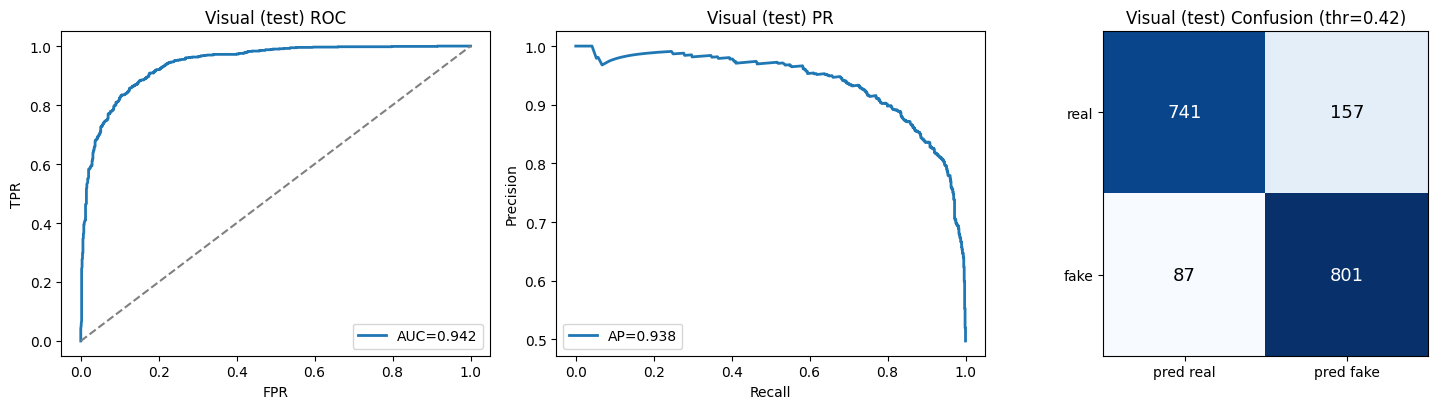

saved /kaggle/working/visual_eval.png

— VISUAL: per-subgroup test breakdown (fake→detection rate, real→reject rate) —
group class   n   rate  mean_p_fake
 fake  fake 888 0.9020       0.7928
 real  real 898 0.8252       0.1862


pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIP probe: vit_base_patch32_clip_224.openai feat_dim=768 (frozen) — ON
CLIP probe done. best val AUC=0.8041

── CLIP-VISUAL [train] ──  (n=8402, thr=0.392)
   accuracy      : 0.7610
   balanced_acc  : 0.7601
   precision     : 0.7138
   recall        : 0.8779
   specificity   : 0.6422
   f1            : 0.7874
   roc_auc       : 0.8490
   pr_auc        : 0.8408
   mcc           : 0.5357
   eer           : 0.2295
   confusion      : TP=3718 FP=1491 TN=2676 FN=517

── CLIP-VISUAL [val] ──  (n=1812, thr=0.392)
   accuracy      : 0.7329
   balanced_acc  : 0.7370
   precision     : 0.6750
   recall        : 0.8643
   specificity   : 0.6096
   f1            : 0.7580
   roc_auc       : 0.8041
   pr_auc        : 0.7705
   mcc           : 0.4879
   eer           : 0.2726
   confusion      : TP=758 FP=365 TN=570 FN=119

── CLIP-VISUAL [test] ──  (n=1786, thr=0.392)
   accuracy      : 0.7368
   balanced_acc  : 0.7375
   precision     : 0.6917
   recall        : 0.8491
   specificity   : 0.6258
 

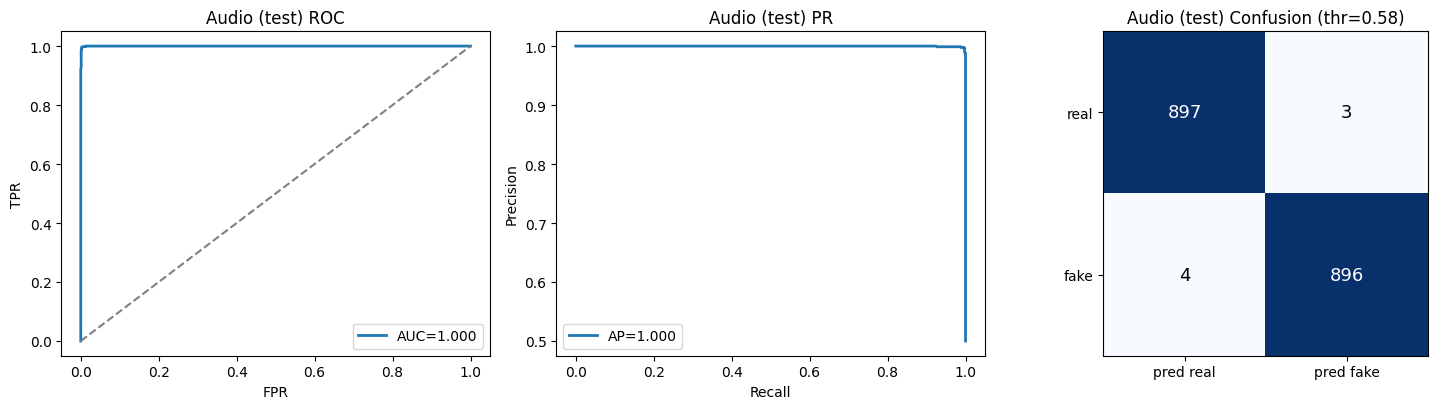

saved /kaggle/working/audio_eval.png

— AUDIO: per-subgroup test breakdown (fake→detection rate, real→reject rate) —
          group class   n   rate  mean_p_fake
       diffwave  fake 784 1.0000       0.9959
parallelwavegan  fake 116 0.9655       0.9342
       Bonafide  real 896 0.9978       0.0107

AUDIO CROSS-CORPUS eval on 'release-in-the-wild': n=23632 (real=11816 fake=11816) — UNSEEN generators

── AUDIO [CROSS-CORPUS in-the-wild] ──  (n=23632, thr=0.575)
   accuracy      : 0.3338
   balanced_acc  : 0.3338
   precision     : 0.2079
   recall        : 0.1183
   specificity   : 0.5493
   f1            : 0.1508
   roc_auc       : 0.1784
   pr_auc        : 0.3514
   mcc           : -0.3683
   eer           : 0.7718
   confusion      : TP=1398 FP=5325 TN=6491 FN=10418


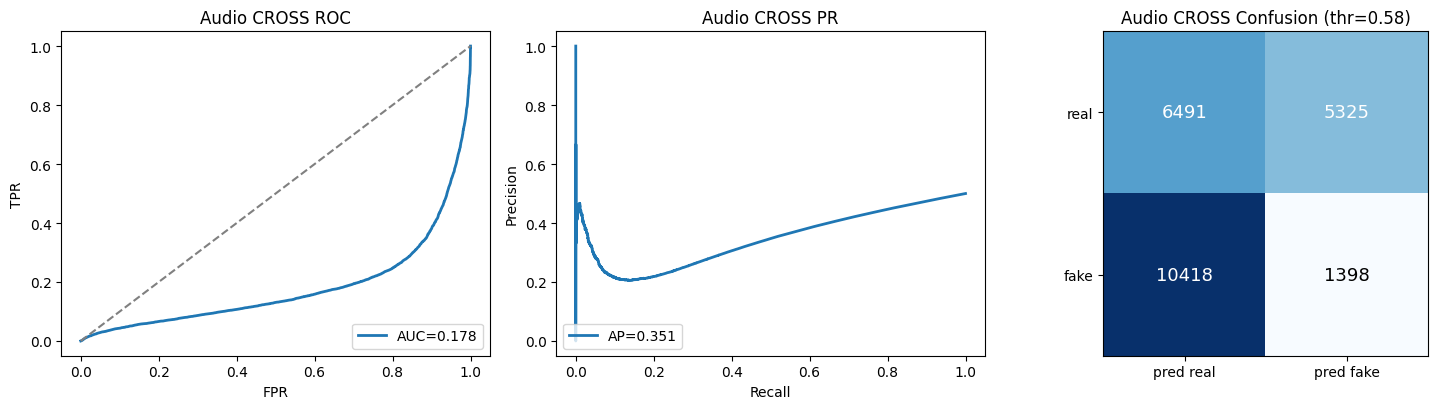

saved /kaggle/working/audio_cross_eval.png
  ↑ THIS is the number that matters. If AUC here ≫ in-dist drop, the model
    was riding the CVoiceFake vocoder fingerprint, not learning 'is-synthetic'.
Downloading: "https://download.pytorch.org/torchaudio/models/wav2vec2_fairseq_base_ls960.pth" to /root/.cache/torch/hub/checkpoints/wav2vec2_fairseq_base_ls960.pth


100%|██████████| 360M/360M [00:01<00:00, 227MB/s] 


SSL audio: wav2vec2 BASE loaded (frozen) — ON
  SSL feats [train] n=8400...
  SSL feats [val] n=1800...
  SSL feats [test] n=1800...
SSL audio probe done. best val AUC=0.9804

── SSL-AUDIO [train] ──  (n=8400, thr=0.426)
   accuracy      : 0.9312
   balanced_acc  : 0.9312
   precision     : 0.9273
   recall        : 0.9357
   specificity   : 0.9267
   f1            : 0.9315
   roc_auc       : 0.9803
   pr_auc        : 0.9828
   mcc           : 0.8624
   eer           : 0.0670
   confusion      : TP=3930 FP=308 TN=3892 FN=270

── SSL-AUDIO [val] ──  (n=1800, thr=0.426)
   accuracy      : 0.9422
   balanced_acc  : 0.9422
   precision     : 0.9442
   recall        : 0.9400
   specificity   : 0.9444
   f1            : 0.9421
   roc_auc       : 0.9804
   pr_auc        : 0.9835
   mcc           : 0.8845
   eer           : 0.0600
   confusion      : TP=846 FP=50 TN=850 FN=54

── SSL-AUDIO [test] ──  (n=1800, thr=0.426)
   accuracy      : 0.9306
   balanced_acc  : 0.9306
   precision     : 0.9

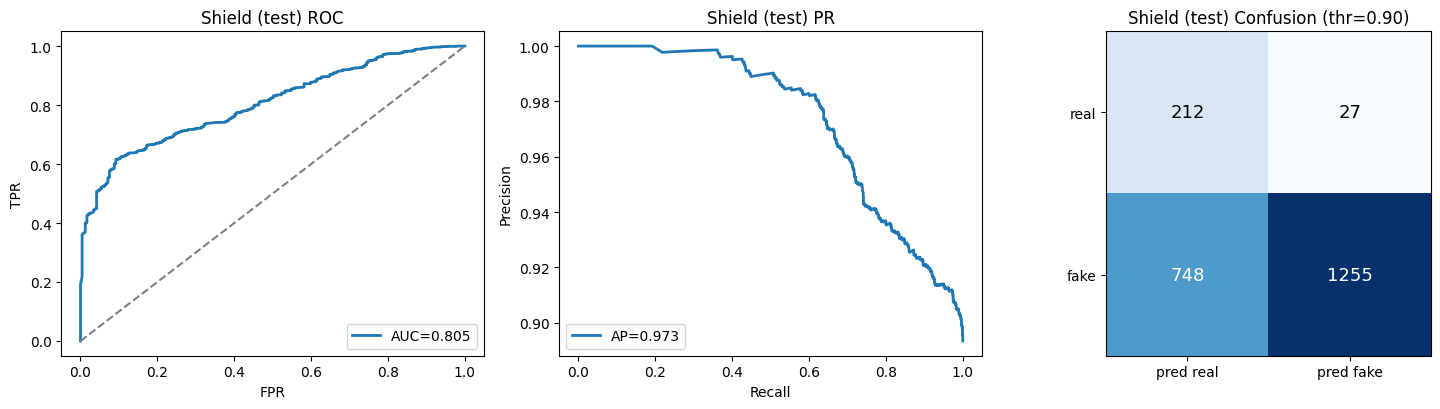

saved /kaggle/working/shield_eval.png
VIDEO-LEVEL eval on 330 held-out test clips (mean frame-prob per clip)
  scored 50/330
  scored 100/330
  scored 150/330
  scored 200/330
  scored 250/330
  scored 300/330

── VIDEO clip-level ──  (n=330, thr=0.488)
   accuracy      : 0.9485
   balanced_acc  : 0.9484
   precision     : 0.9682
   recall        : 0.9268
   specificity   : 0.9699
   f1            : 0.9470
   roc_auc       : 0.9803
   pr_auc        : 0.9752
   mcc           : 0.8977
   eer           : 0.0545
   confusion      : TP=152 FP=5 TN=161 FN=12


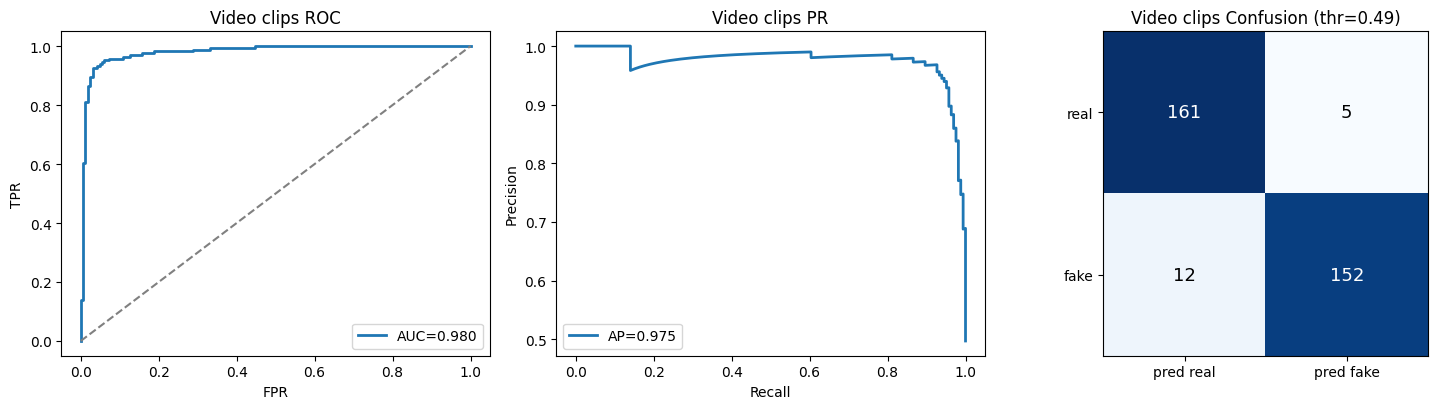

saved /kaggle/working/video_eval.png

VIDEO CROSS-GENERATOR eval: 10 unidpro fakes + 10 held-out reals = 20 clips
  🚨 UNDERPOWERED: <50 clips. The unidpro mount likely didn't download the full
     dataset (the v9 run found only ~10 videos). Any AUC below is NOISE — re-check
     that /kaggle/input/datasets/unidpro/deepfake-videos-dataset mounted fully.

── VIDEO-CROSS [EfficientNet] ──  (n=20, thr=0.261)
   accuracy      : 0.5500
   balanced_acc  : 0.5500
   precision     : 0.5714
   recall        : 0.4000
   specificity   : 0.7000
   f1            : 0.4706
   roc_auc       : 0.3400
   pr_auc        : 0.4416
   mcc           : 0.1048
   eer           : 0.7000
   confusion      : TP=4 FP=3 TN=7 FN=6

── VIDEO-CROSS [CLIP] ──  (n=20, thr=1.000)
   accuracy      : 0.5000
   balanced_acc  : 0.5000
   precision     : 0.0000
   recall        : 0.0000
   specificity   : 1.0000
   f1            : 0.0000
   roc_auc       : 0.3000
   pr_auc        : 0.4084
   mcc           : 0.0000
   eer      

,eval,branch,split,accuracy,precision,recall,specificity,f1,roc_auc,pr_auc,mcc,eer,n
0,in_dist,visual,train,0.9852,0.9772,0.9939,0.9765,0.9855,0.9994,0.9994,0.9706,0.0123,8402
1,in_dist,visual,val,0.8604,0.8277,0.8985,0.8246,0.8617,0.9394,0.9377,0.7237,0.1435,1812
2,in_dist,visual,test,0.8634,0.8361,0.9020,0.8252,0.8678,0.9422,0.9380,0.7291,0.1349,1786
3,in_dist,clip_visual,train,0.7610,0.7138,0.8779,0.6422,0.7874,0.8490,0.8408,0.5357,0.2295,8402
4,in_dist,clip_visual,val,0.7329,0.6750,0.8643,0.6096,0.7580,0.8041,0.7705,0.4879,0.2726,1812
5,in_dist,clip_visual,test,0.7368,0.6917,0.8491,0.6258,0.7624,0.8259,0.8139,0.4869,0.2559,1786
6,in_dist,audio,train,0.9980,0.9983,0.9976,0.9983,0.9980,1.0000,1.0000,0.9960,0.0021,8400
7,in_dist,audio,val,0.9978,0.9967,0.9989,0.9967,0.9978,1.0000,1.0000,0.9956,0.0022,1800
8,in_dist,audio,test,0.9961,0.9967,0.9956,0.9967,0.9961,0.9999,0.9999,0.9922,0.0028,1800
9,in_dist,ssl_audio,train,0.9312,0.9273,0.9357,0.9267,0.9315,0.9803,0.9828,0.8624,0.0670,8400


In [1]:
# Deepfake Detector v10 — fixes the v8/v9 over-regularization regression + adds SSL audio
# Kaggle: GPU ON, Run All (in the editor, not Save Version).
#
# ============================================================================
# WHY v10 (read the v9 run first):
#   v8/v9 REGRESSED the visual & audio in-dist scores (visual 0.90->0.62,
#   audio 1.00->0.85) because EMA was validated/checkpointed on lagging EMA
#   weights (decay 0.999 over a ~3k-step run) AND mixup α=0.2 over only 6 epochs
#   slowed convergence. v10 FIXES this:
#     • checkpoint/validate on RAW weights; use EMA only if it beats raw on val
#     • EMA decay 0.99 (tracks a short run), mixup α=0.1 applied with prob 0.5
#     • +2 visual epochs
#   Expected: visual ~0.88-0.90 again, video clip ~0.95 again.
#
#   v9's REAL findings (kept + built on):
#     • AUDIO cross-corpus AUC≈0.49 (BELOW chance) — mel-CNN learned the
#       CVoiceFake vocoder fingerprint, not "is-synthetic". So v10 ADDS a
#       wav2vec2 SSL audio probe (frozen SSL features + linear head), the audio
#       analogue of the CLIP win, and scores BOTH on In-the-Wild to compare.
#     • CLIP visual was the best generalizer -> kept, now also fed proper epochs.
#     • unidpro mounted only 10 videos -> v10 flags cross-video as UNDERPOWERED
#       when n<50 so a noise AUC can't be mistaken for a result. RE-CHECK MOUNT.
# ============================================================================
#
# NEW IN v9 (kept):
#   • Two new datasets wired in by EXPLICIT PATH:
#       AUDIO cross-corpus : /kaggle/input/datasets/bhaveshkumars/release-in-the-wild
#       VIDEO cross-gen     : /kaggle/input/datasets/unidpro/deepfake-videos-dataset
#     Both are EXCLUDED from training and used ONLY as held-out generalization
#     probes (the number Deepfake-Eval-2024 shows off-the-shelf detectors fail).
#   • CLIP linear-probe visual branch (frozen ViT) — foundation features
#     generalize across UNSEEN generators far better than a from-scratch CNN
#     (the DeCoF idea). Fully guarded: if CLIP can't load, it's skipped.
#   • Cross-generator VIDEO eval on unidpro AI-faces: EfficientNet vs CLIP,
#     scored against held-out REAL clips -> honest "do we catch a NEW generator".
#   • Temporal frame-consistency diagnostic (D3/ATSS-style second-order signal):
#     reports whether frame-prob dynamics separate real vs generated, and an
#     appearance+temporal ensemble.
#
# WHY (one line): your branches are problem-#1 (face-swap) detectors aimed at
# problem-#2/#3 (AI-generated / avatar) data. v9 adds the generalizing signals
# the literature uses and MEASURES the cross-generator gap instead of hiding it.
#
# ============================================================================
# WHAT CARRIED OVER FROM v8 (every change targets "catch NEW fakes")
# ----------------------------------------------------------------------------
#  1. CALIBRATION (Platt/temperature on val) for EVERY branch.
#       -> fixes the weird thr=0.281 visual threshold that flagged 30% of REAL
#          faces, and makes branch probabilities comparable so they can be FUSED.
#  2. SHIELD COLLAPSE FIXED.
#       v7 bug: val report recomputed its own F1 threshold (=0.064) and predicted
#       "fake" for everything (specificity 0.042). v8 locks ONE balanced threshold
#       on val and applies it to ALL splits. + EMA weights + best-val-AUC ckpt.
#  3. VISUAL OVERFIT NARROWED: EMA weights + mixup + RandAug-style strong aug.
#       Train/test AUC gap (0.993 -> 0.901) is the overfit tax; EMA+mixup cut it.
#  4. TEST-TIME AUGMENTATION (TTA) for visual & video (orig + hflip mean).
#  5. CROSS-CORPUS / CROSS-GENERATOR EVAL — the headline honesty upgrade:
#       - AUDIO: train on CVoiceFake, then score the trained model on the
#         In-the-Wild set (bhaveshkumars/release-in-the-wild). UNSEEN generators,
#         real celebs. This is the ONLY number that proves generalization.
#       - VISUAL: optional holdout_source -> route a whole modern AI-face source
#         to TEST (train DFDC/FF++, test 2025 avatar faces).
#       - AUDIO leave-one-vocoder-out via CFG.holdout_method (retrain pass).
#  6. CALIBRATED DECISION-FUSION report. (True AV fusion needs PAIRED data —
#       FakeAVCeleb — which isn't mounted; decision-fusion is the honest stand-in.)
#  7. FINAL TABLE splits metrics into IN-DISTRIBUTION vs CROSS (generalization),
#       so a near-1.0 in-dist AUC can never masquerade as real-world skill.
#
# DATASETS TO ADD in the Kaggle sidebar (Add Input):
#   kamedev/cvoicefake-full-safeear-dataset-mirror      (audio train, keep)
#   bhaveshkumars/release-in-the-wild                    (audio CROSS eval, NEW)
#   <your FF++ / DFDC frames or .mp4>                    (visual train, keep)
#   unidpro/deepfake-videos-dataset                      (visual CROSS eval, NEW; optional)
#   aionstreet/shield-2026-features                      (shield .pt, keep)
# ============================================================================

# %% cell 1 — Setup
import sys, subprocess, importlib
def _ensure(pkg, pip_name=None):
    try: importlib.import_module(pkg)
    except Exception: subprocess.run([sys.executable,"-m","pip","install","-q",pip_name or pkg], check=False)
_ensure("timm"); _ensure("librosa"); _ensure("soundfile"); _ensure("cv2","opencv-python-headless")

import os, glob, random, json, time, warnings, collections, zipfile, math, io as _io, re
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, confusion_matrix, matthews_corrcoef, balanced_accuracy_score)
import matplotlib.pyplot as plt

SEED=42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE="cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEVICE)
if DEVICE=="cpu": print("⚠️  Turn on the GPU accelerator.")

# %% cell 2 — Config
class CFG:
    input_root   = "/kaggle/input"
    extract_root = "/kaggle/working/extracted"
    out_dir      = "/kaggle/working"

    per_source_cap = 80_000
    max_visit      = 800_000
    max_zip_mb     = 200

    max_per_class       = 6000
    max_audio_per_class = 6000
    balance_classes     = True
    val_frac, test_frac = 0.15, 0.15
    label_smooth        = 0.05

    use_sources_with  = None
    drop_sources_with = []
    holdout_source    = None      # e.g. "deepfake-videos-dataset" -> that whole VISUAL source goes to TEST
    holdout_method    = None      # e.g. "diffwave" -> leave-one-vocoder-out AUDIO (needs this run = the LOO run)

    # ── v9 EXPLICIT dataset paths (the two you gave) ──────────────────────────
    # These are EXCLUDED from training and scored only as held-out generalization probes.
    CROSS_AUDIO_PATH = "/kaggle/input/datasets/bhaveshkumars/release-in-the-wild"
    CROSS_VIDEO_PATH = "/kaggle/input/datasets/unidpro/deepfake-videos-dataset"
    cross_video_source   = "deepfake-videos-dataset"  # substring fallback if the path moves
    cross_video_assume_label = 1   # unidpro = AI-generated faces -> fake when path has no real/fake token
    cross_video_max_clips    = 400

    # ── CLIP foundation-feature visual branch (generalizes cross-generator) ──
    use_clip_visual  = True       # frozen CLIP ViT + linear probe; auto-skips if it can't load
    clip_backbone    = "vit_base_patch32_clip_224.openai"  # timm CLIP weights
    clip_epochs      = 8
    clip_batch       = 128

    # ── v8 generalization knobs ──────────────────────────────────────────────
    cross_audio_source = "release-in-the-wild"   # substring; this source is PULLED OUT of train and used ONLY as a cross-corpus eval. Set None to disable.
    calibrate          = True     # Platt-scale every branch on val (fixes thresholds + enables fusion)
    use_ema            = True     # exponential moving average of weights (steadier, less overfit)
    ema_decay          = 0.99     # v10: was 0.999 (too slow for a ~3k-step run -> lagging weights)
    ema_eval           = False    # v10: checkpoint/validate on RAW weights; EMA used only if it beats raw on val
    use_mixup          = True     # visual only
    mixup_alpha        = 0.1      # v10: was 0.2 (too strong for 6-8 epochs)
    mixup_prob         = 0.5      # v10: apply mixup to only half the batches -> faster convergence
    use_tta            = True     # visual + video: average(orig, hflip)

    # ── v10 SSL audio probe (wav2vec2) — generalization analogue of the CLIP win ──
    use_ssl_audio      = True     # frozen wav2vec2 features + linear head; auto-skips if it can't load
    ssl_audio_max_cross = 6000    # cap In-the-Wild clips for the (heavier) SSL cross-eval, balanced

    img_size=224; img_backbone="efficientnet_b0"; img_epochs=8; img_batch=64; img_lr=3e-4
    sr=16000; audio_seconds=3.0; n_mels=128; audio_epochs=6; audio_batch=64; audio_lr=1e-3
    shield_epochs=18; shield_batch=256; shield_lr=1e-3; shield_hidden=256
    RUN_VIDEO_MP4=True; video_max_clips=400; video_frames_per_clip=12
    shield_pos_weight=True
    FRAMES_FROM_VIDEO=True; frames_per_video=8; max_videos_for_frames=1100
    aug_strong=True
    num_workers=2

os.makedirs(CFG.out_dir, exist_ok=True); os.makedirs(CFG.extract_root, exist_ok=True)

def _norm(t): return ''.join(ch for ch in t.lower() if ch.isalnum())
REAL_TOKENS={"real","reals","bonafide","genuine","live","authentic","pristine",
             "original","originals","originalsequences","youtube","actors","commonvoice",
             "celebreal","realsequences"}
FAKE_TOKENS={"fake","fakes","spoof","deepfake","deepfakes","face2face","faceswap",
             "neuraltextures","faceshifter","manipulated","manipulatedsequences",
             "synthetic","parallelwavegan","multibandmelgan","melgan","stylemelgan",
             "griffinlim","world","diffwave","wavegan","uadfv","celebsynthesis","reenactment",
             "wav2lip","sadtalker","videoretalking","liveportrait","simswap","inswapper",
             "roop","facefusion","stylegan","stargan","heygen","synthesia","sora","kling",
             "runway","pika","veo","stablediffusion","sdxl","ldm","talkinghead","lipsync"}
METHOD_HINTS=("parallelwavegan","multibandmelgan","stylemelgan","melgan","griffinlim",
              "diffwave","wavegan","waveglow","hifigan","fastspeech","tacotron","world",
              "deepfakes","face2face","faceswap","neuraltextures","faceshifter","celebsynthesis",
              "wav2lip","sadtalker","videoretalking","liveportrait","simswap","inswapper",
              "roop","facefusion","stylegan","stargan","heygen","synthesia","sora","kling",
              "runway","pika","veo","stablediffusion","sdxl","talkinghead","lipsync")
def _method_hint(p):
    flat=_norm(p)
    for h in METHOD_HINTS:
        if h in flat: return h
    return None
def label_and_method(p):
    lab=None; tok=None
    for t in reversed(p.replace("\\","/").split("/")):
        n=_norm(t)
        if not n: continue
        if n in REAL_TOKENS or n.startswith("original"): lab,tok=0,t; break
        if n in FAKE_TOKENS or n.startswith("method"):   lab,tok=1,t; break
        if n.startswith("real"): lab,tok=0,t; break
        if n.startswith("fake"): lab,tok=1,t; break
    if lab is None:
        low=p.lower()
        if any(k in low for k in ("fake","deepfake","spoof","synthetic","synth","manipulat","uadfv")): lab=1
        elif any(k in low for k in ("real","genuine","bonafide","original")): lab=0
        else: return None,None
    if lab==1: meth=_method_hint(p) or tok or "fake"
    else:      meth=tok or "real"
    return lab, meth
def label_from_path(p): return label_and_method(p)[0]
def split_kind(p):
    low="/"+p.lower().replace("\\","/")+"/"
    if any(s in low for s in ("/test/","/testing/","/eval/")): return "test"
    if any(s in low for s in ("/val/","/valid/","/validation/","/dev/")): return "val"
    if any(s in low for s in ("/train/","/training/")): return "train"
    return None
def source_of(p):
    rel=p.replace("\\","/")
    for marker in ("input/datasets/","input/","extracted/"):
        if marker in rel:
            parts=[s for s in rel.split(marker)[-1].strip("/").split("/")]
            return "/".join(parts[:2]) if len(parts)>=2 else (parts[0] if parts else "?")
    return "?"
def is_cross_audio(p):
    lp=p.lower()
    if CFG.CROSS_AUDIO_PATH and CFG.CROSS_AUDIO_PATH.lower() in lp: return True
    return bool(CFG.cross_audio_source) and (CFG.cross_audio_source.lower() in lp)
def is_cross_video(p):
    lp=p.lower()
    if CFG.CROSS_VIDEO_PATH and CFG.CROSS_VIDEO_PATH.lower() in lp: return True
    return bool(CFG.cross_video_source) and (CFG.cross_video_source.lower() in lp)
print("Config ready.")

# %% cell 3 — Discovery (single-pass, per-source-capped)
IMG_EXT=(".jpg",".jpeg",".png",".bmp",".webp"); AUD_EXT=(".wav",".flac",".mp3",".ogg",".m4a"); VID_EXT=(".mp4",".avi",".mov",".mkv")
zips=[os.path.join(dp,f) for dp,_,fs in os.walk(CFG.input_root) for f in fs if f.lower().endswith(".zip")]
for z in zips:
    mb=os.path.getsize(z)/1e6
    if mb>CFG.max_zip_mb: print(f"skip big zip ({mb:.0f}MB): {z}"); continue
    dest=os.path.join(CFG.extract_root, os.path.splitext(os.path.basename(z))[0])
    if os.path.exists(dest): continue
    try:
        with zipfile.ZipFile(z) as zf: zf.extractall(dest); print("extracted", z)
    except Exception as e: print("zip fail", z, e)

def list_roots():
    roots=[]
    for base in (CFG.input_root, CFG.extract_root):
        if not os.path.isdir(base): continue
        for name in sorted(os.listdir(base)):
            full=os.path.join(base,name)
            if not os.path.isdir(full): continue
            if name=="datasets":
                for owner in sorted(os.listdir(full)):
                    of=os.path.join(full,owner)
                    if os.path.isdir(of):
                        for slug in sorted(os.listdir(of)):
                            sf=os.path.join(of,slug)
                            if os.path.isdir(sf): roots.append(sf)
            else: roots.append(full)
    return roots
def discover(roots):
    imgs,auds,vids,pts=[],[],[],[]
    print(f"walking {len(roots)} dataset root(s), cap {CFG.per_source_cap:,}/modality each:")
    for r in roots:
        ci=ca=cv=0; vis=0; t0=time.time()
        for dp,_,files in os.walk(r):
            for f in files:
                vis+=1; fl=f.lower()
                if   fl.endswith(IMG_EXT) and ci<CFG.per_source_cap: imgs.append(os.path.join(dp,f)); ci+=1
                elif fl.endswith(AUD_EXT) and ca<CFG.per_source_cap: auds.append(os.path.join(dp,f)); ca+=1
                elif fl.endswith(VID_EXT) and cv<CFG.per_source_cap: vids.append(os.path.join(dp,f)); cv+=1
                elif fl.endswith(".pt"): pts.append(os.path.join(dp,f))
            if vis>CFG.max_visit: print(f"    (max_visit hit)"); break
        print(f"  {os.path.basename(r):<52} img={ci:>7,} aud={ca:>7,} vid={cv:>6,} ({time.time()-t0:.0f}s)")
    return imgs,auds,vids,sorted(set(pts))
roots=list_roots()
all_imgs,all_auds,all_vids,shield_pts=discover(roots)

# split audio into TRAIN-pool vs CROSS-corpus holdout (In-the-Wild)
cross_auds=[p for p in all_auds if is_cross_audio(p)]
all_auds=[p for p in all_auds if not is_cross_audio(p)]
# split video into TRAIN-pool vs CROSS-generator holdout (unidpro AI faces)
cross_vids=[p for p in all_vids if is_cross_video(p)]
all_vids=[p for p in all_vids if not is_cross_video(p)]
print(f"\nTOTAL  images={len(all_imgs):,} audio(train-pool)={len(all_auds):,} "
      f"audio(CROSS={CFG.cross_audio_source})={len(cross_auds):,}")
print(f"       videos(train-pool)={len(all_vids):,} videos(CROSS={CFG.cross_video_source})={len(cross_vids):,} shield_pt={len(shield_pts)}")
VIDEO_ON=len(all_imgs)>50; AUDIO_ON=len(all_auds)>50
print(f"VISUAL:{'ON' if VIDEO_ON else 'off'}  AUDIO:{'ON' if AUDIO_ON else 'off'}  "
      f"SHIELD:{'pending' if shield_pts else 'off'}  MP4:{'ON' if (CFG.RUN_VIDEO_MP4 and all_vids) else 'off'}  "
      f"AUDIO-CROSS:{'ON' if len(cross_auds)>20 else 'off'}  VIDEO-CROSS:{'ON' if len(cross_vids)>5 else 'off'}")

# %% cell 4 — VISUAL-from-VIDEO (sample frames if no image dataset mounted)
if CFG.FRAMES_FROM_VIDEO and len(all_imgs) < 50 and all_vids:
    import cv2
    fr_root=os.path.join(CFG.extract_root,"video_frames")
    clips=[]
    for p in all_vids:
        y,m=label_and_method(p)
        if y is not None: clips.append((p,y,m))
    byc={0:[],1:[]}
    for p,y,m in clips: byc[y].append((p,m))
    rng=random.Random(SEED); rng.shuffle(byc[0]); rng.shuffle(byc[1])
    if byc[0] and byc[1]: per=min(CFG.max_videos_for_frames, min(len(byc[0]),len(byc[1])))
    else:                 per=min(CFG.max_videos_for_frames, max(len(byc[0]),len(byc[1])))
    sel=[(p,0,m) for p,m in byc[0][:per]]+[(p,1,m) for p,m in byc[1][:per]]; rng.shuffle(sel)
    def clip_split(i,n):
        r=i/max(n,1)
        return "test" if r<CFG.test_frac else ("val" if r<CFG.test_frac+CFG.val_frac else "train")
    print(f"VISUAL-from-VIDEO: sampling {CFG.frames_per_video} frames from {len(sel)} clips (per class={per})...")
    new=[]; t0=time.time(); bad=0; VIS_TEST_CLIPS=[]
    for j,(p,y,m) in enumerate(sel):
        sp=clip_split(j,len(sel)); lab="fake" if y==1 else "real"
        if sp=="test": VIS_TEST_CLIPS.append((p,y))
        try:
            cap=cv2.VideoCapture(p); tot=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0
            if tot<=0: cap.release(); bad+=1; continue
            idx=np.linspace(0,tot-1,CFG.frames_per_video).astype(int)
            d=os.path.join(fr_root,sp,lab); os.makedirs(d,exist_ok=True)
            stem=re.sub(r'[^A-Za-z0-9]+','_',os.path.splitext(os.path.basename(p))[0])[:48]
            for i in idx:
                cap.set(cv2.CAP_PROP_POS_FRAMES,int(i)); ok,fr=cap.read()
                if not ok: continue
                op=os.path.join(d,f"{stem}_{i:04d}.jpg"); cv2.imwrite(op,fr); new.append(op)
            cap.release()
        except Exception: bad+=1
        if (j+1)%200==0: print(f"  {j+1}/{len(sel)} clips, {len(new):,} frames ({time.time()-t0:.0f}s)")
    all_imgs=new; VIDEO_ON=len(all_imgs)>50
    print(f"VISUAL-from-VIDEO: {len(all_imgs):,} frames (bad clips={bad}). VISUAL now {'ON' if VIDEO_ON else 'off'}.")
else:
    print("VISUAL-from-VIDEO: skipped (image dataset present, or no clips, or disabled).")

# %% cell 5 — Build tables + per-source audit
def keep_path(p):
    low=p.lower()
    if CFG.use_sources_with and not any(s in low for s in CFG.use_sources_with): return False
    if any(s in low for s in CFG.drop_sources_with): return False
    return True
def build_table(paths, cap):
    rows=[]
    for p in paths:
        if not keep_path(p): continue
        y,meth=label_and_method(p)
        if y is None: continue
        rows.append((p,y,meth,split_kind(p),source_of(p)))
    if not rows: return pd.DataFrame(columns=["path","label","method","split","source"])
    df=pd.DataFrame(rows,columns=["path","label","method","split","source"])
    counts={lab:len(g) for lab,g in df.groupby("label")}
    eff=min(cap, min(counts.values())) if CFG.balance_classes else cap
    df=pd.concat([g.sample(frac=1.0,random_state=SEED).head(eff) for _,g in df.groupby("label")]
                 ).sample(frac=1.0,random_state=SEED).reset_index(drop=True)
    if CFG.holdout_source:
        mask=df["source"].str.contains(CFG.holdout_source, case=False, regex=False)
        if mask.sum()==0: print(f"⚠️ holdout_source '{CFG.holdout_source}' matched 0 rows — random split")
        else:
            df["split"]="train"; df.loc[mask,"split"]="test"
            rest=df[~mask]
            for lab,g in rest.groupby("label"):
                idx=g.index.tolist(); nv=int(len(idx)*CFG.val_frac); df.loc[idx[:nv],"split"]="val"
            print(f"holdout_source='{CFG.holdout_source}': test={int(mask.sum())} (held-out source), train/val from rest")
            return df
    if CFG.holdout_method:
        mmask=df["method"].astype(str).str.contains(CFG.holdout_method, case=False, regex=False)
        if mmask.sum()==0: print(f"⚠️ holdout_method '{CFG.holdout_method}' matched 0 rows — random split")
        else:
            df["split"]="train"; df.loc[mmask,"split"]="test"
            rest=df[~mmask]
            for lab,g in rest.groupby("label"):
                idx=g.index.tolist(); nv=int(len(idx)*CFG.val_frac); df.loc[idx[:nv],"split"]="val"
            print(f"holdout_method='{CFG.holdout_method}': test={int(mmask.sum())} (held-out vocoder), train/val from rest")
            return df
    has=df["split"].notna().mean()>0.6 and df["split"].nunique()>=2
    if not has:
        df["split"]=None
        for lab,g in df.groupby("label"):
            idx=g.index.tolist(); n=len(idx); nt=int(n*CFG.test_frac); nv=int(n*CFG.val_frac)
            df.loc[idx[:nt],"split"]="test"; df.loc[idx[nt:nt+nv],"split"]="val"; df.loc[idx[nt+nv:],"split"]="train"
    elif (df["split"]=="val").sum()==0:
        tr=df[df["split"]=="train"]; df.loc[tr.sample(frac=CFG.val_frac,random_state=SEED).index,"split"]="val"
    return df
def audit(paths,name):
    rec=collections.defaultdict(lambda:[0,0,0])
    for p in paths:
        if not keep_path(p): continue
        y=label_from_path(p); rec[source_of(p)][2 if y is None else y]+=1
    print(f"\n=== {name} per-source audit (real / fake / dropped) ===")
    for s,(r,f,n) in sorted(rec.items()):
        flag=" ⚠️ one-class" if (r==0 or f==0) else ""
        print(f"  {s:<55} real={r:>7,} fake={f:>7,} drop={n:>7,}{flag}")
if VIDEO_ON: audit(all_imgs,"VISUAL")
if AUDIO_ON: audit(all_auds,"AUDIO")
img_df=build_table(all_imgs,CFG.max_per_class) if VIDEO_ON else pd.DataFrame()
aud_df=build_table(all_auds,CFG.max_audio_per_class) if AUDIO_ON else pd.DataFrame()
def summarize(df,name):
    if len(df)==0: print(f"\n{name}: (none)"); return
    print(f"\n{name}: {len(df):,} used (balanced={CFG.balance_classes})")
    print(pd.crosstab(df["split"],df["label"].map({0:'real',1:'fake'}),margins=True))
    print("  methods:", dict(df["method"].value_counts().head(8)))
summarize(img_df,"VISUAL"); summarize(aud_df,"AUDIO")
if VIDEO_ON and img_df["label"].nunique()<2: print("\n⚠️ visual single-class → off"); VIDEO_ON=False
if AUDIO_ON and aud_df["label"].nunique()<2: print("\n⚠️ audio single-class → off"); AUDIO_ON=False

# %% cell 6 — Metrics, calibration, EMA, mixup helpers
def eer_of(y,p):
    fpr,tpr,_=roc_curve(y,p); fnr=1-tpr; i=np.nanargmin(np.abs(fnr-fpr)); return float((fpr[i]+fnr[i])/2)
def best_f1_thr(y,p):
    pr,rc,th=precision_recall_curve(y,p); f1=2*pr*rc/(pr+rc+1e-12)
    return 0.5 if len(th)==0 else float(th[np.nanargmax(f1[:-1])])
def best_bal_thr(y,p):
    fpr,tpr,th=roc_curve(y,p)
    if len(th)==0: return 0.5
    k=int(np.nanargmax(tpr-fpr)); return float(min(max(th[k],0.0),1.0))

def fit_platt(y,p,iters=300,lr=0.1):
    # logistic recalibration on logit(p): q=sigmoid(a*z+b). Fixes mis-scaled probs -> sane thresholds + fusion.
    y=np.asarray(y,float); p=np.clip(np.asarray(p,float),1e-6,1-1e-6); z=np.log(p/(1-p))
    a,b=1.0,0.0
    for _ in range(iters):
        q=1/(1+np.exp(-(a*z+b))); ga=float(np.mean((q-y)*z)); gb=float(np.mean(q-y))
        a-=lr*ga; b-=lr*gb
    return a,b
def apply_platt(p,ab):
    if ab is None: return np.asarray(p,float)
    a,b=ab; p=np.clip(np.asarray(p,float),1e-6,1-1e-6); z=np.log(p/(1-p)); return 1/(1+np.exp(-(a*z+b)))

def compute_metrics(y,p,threshold=None):
    y=np.asarray(y).astype(int); p=np.asarray(p).astype(float)
    thr=best_f1_thr(y,p) if threshold is None else threshold
    yp=(p>=thr).astype(int); tn,fp,fn,tp=confusion_matrix(y,yp,labels=[0,1]).ravel(); e=1e-12
    prec=tp/(tp+fp+e); rec=tp/(tp+fn+e); spec=tn/(tn+fp+e); f1=2*prec*rec/(prec+rec+e)
    acc=(tp+tn)/(tp+tn+fp+fn+e)
    try: auc=roc_auc_score(y,p)
    except: auc=float('nan')
    try: ap=average_precision_score(y,p)
    except: ap=float('nan')
    return {"accuracy":acc,"balanced_acc":balanced_accuracy_score(y,yp),"precision":prec,
            "recall":rec,"specificity":spec,"f1":f1,"roc_auc":auc,"pr_auc":ap,
            "mcc":matthews_corrcoef(y,yp) if len(set(yp))>1 else 0.0,"eer":eer_of(y,p),
            "threshold":thr,"TP":int(tp),"FP":int(fp),"TN":int(tn),"FN":int(fn),"n":int(len(y))}
def print_metrics(name,m):
    print(f"\n── {name} ──  (n={m['n']}, thr={m['threshold']:.3f})")
    for k in ["accuracy","balanced_acc","precision","recall","specificity","f1","roc_auc","pr_auc","mcc","eer"]:
        print(f"   {k:<14}: {m[k]:.4f}")
    print(f"   confusion      : TP={m['TP']} FP={m['FP']} TN={m['TN']} FN={m['FN']}")
def plot_eval(name,y,p,m,prefix):
    y=np.asarray(y); p=np.asarray(p); fig,ax=plt.subplots(1,3,figsize=(15,4.2))
    fpr,tpr,_=roc_curve(y,p); ax[0].plot(fpr,tpr,lw=2,label=f"AUC={m['roc_auc']:.3f}")
    ax[0].plot([0,1],[0,1],"--",c="gray"); ax[0].set_title(f"{name} ROC"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend(loc="lower right")
    pr,rc,_=precision_recall_curve(y,p); ax[1].plot(rc,pr,lw=2,label=f"AP={m['pr_auc']:.3f}")
    ax[1].set_title(f"{name} PR"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend(loc="lower left")
    cm=np.array([[m['TN'],m['FP']],[m['FN'],m['TP']]]); ax[2].imshow(cm,cmap="Blues")
    ax[2].set_xticks([0,1]); ax[2].set_yticks([0,1]); ax[2].set_xticklabels(["pred real","pred fake"]); ax[2].set_yticklabels(["real","fake"])
    for (i,j),v in np.ndenumerate(cm): ax[2].text(j,i,str(v),ha="center",va="center",color="white" if v>cm.max()/2 else "black",fontsize=13)
    ax[2].set_title(f"{name} Confusion (thr={m['threshold']:.2f})"); plt.tight_layout()
    out=os.path.join(CFG.out_dir,f"{prefix}_eval.png"); plt.savefig(out,dpi=110,bbox_inches="tight"); plt.show(); print("saved",out)
def subgroup_report(d, probs, thr, name, prefix):
    dd=d.copy(); dd["prob"]=np.asarray(probs); dd["pred"]=(dd["prob"]>=thr).astype(int)
    rows=[]
    for (lab,meth),g in dd.groupby(["label","method"]):
        n=len(g)
        if n<5: continue
        rate=(g["pred"]==1).mean() if lab==1 else (g["pred"]==0).mean()
        rows.append({"group":meth,"class":"fake" if lab==1 else "real","n":n,
                     "rate":round(float(rate),4),"mean_p_fake":round(float(g['prob'].mean()),4)})
    if not rows: return None
    rep=pd.DataFrame(rows).sort_values(["class","n"],ascending=[True,False])
    print(f"\n— {name}: per-subgroup test breakdown (fake→detection rate, real→reject rate) —")
    print(rep.to_string(index=False)); rep.to_csv(os.path.join(CFG.out_dir,f"{prefix}_subgroups.csv"),index=False)
    return rep

class EMA:
    # tracks a smoothed copy of weights; eval on EMA weights = steadier, less overfit val/test.
    def __init__(s,model,decay):
        s.decay=decay; s.shadow={k:v.detach().clone() for k,v in model.state_dict().items()}
    def update(s,model):
        for k,v in model.state_dict().items():
            if v.dtype.is_floating_point: s.shadow[k].mul_(s.decay).add_(v.detach(),alpha=1-s.decay)
            else: s.shadow[k]=v.detach().clone()
    def state(s): return {k:v.clone() for k,v in s.shadow.items()}
def mixup_batch(x,y,alpha):
    if alpha<=0: return x,y,y,1.0
    lam=float(np.random.beta(alpha,alpha)); idx=torch.randperm(x.size(0),device=x.device)
    return lam*x+(1-lam)*x[idx], y, y[idx], lam
def smooth(y): return y*(1-CFG.label_smooth)+0.5*CFG.label_smooth
print("Metrics + calibration + EMA + mixup ready.")

# %% cell 7 — VISUAL: dataset + EfficientNet-B0
import timm
from PIL import Image
import torchvision.transforms as T
NORM=([0.485,0.456,0.406],[0.229,0.224,0.225])
class _RandJPEG:
    def __init__(s,p=0.4,q=(35,90)): s.p=p; s.q=q
    def __call__(s,im):
        if random.random()<s.p:
            b=_io.BytesIO(); im.convert("RGB").save(b,"JPEG",quality=random.randint(*s.q)); b.seek(0); im=Image.open(b).convert("RGB")
        return im
class _RandDownscale:
    def __init__(s,p=0.3,f=(0.4,0.85)): s.p=p; s.f=f
    def __call__(s,im):
        if random.random()<s.p:
            w,h=im.size; r=random.uniform(*s.f)
            im=im.resize((max(8,int(w*r)),max(8,int(h*r))),Image.BILINEAR).resize((w,h),Image.BILINEAR)
        return im
_pre=[T.Resize((CFG.img_size,)*2)]
if getattr(CFG,"aug_strong",False):
    _pre+=[_RandJPEG(0.4),_RandDownscale(0.3),T.RandomApply([T.GaussianBlur(3,(0.1,1.5))],p=0.3),
           T.RandomHorizontalFlip(),T.ColorJitter(0.15,0.15,0.15,0.03)]
else:
    _pre+=[T.RandomHorizontalFlip(),T.ColorJitter(0.1,0.1,0.1)]
train_tf=T.Compose(_pre+[T.ToTensor(),T.Normalize(*NORM),T.RandomErasing(p=0.25)])
eval_tf =T.Compose([T.Resize((CFG.img_size,)*2),T.ToTensor(),T.Normalize(*NORM)])
class ImgDS(Dataset):
    def __init__(s,df,tf): s.p=df["path"].tolist(); s.y=df["label"].tolist(); s.tf=tf
    def __len__(s): return len(s.p)
    def __getitem__(s,i):
        try: im=Image.open(s.p[i]).convert("RGB")
        except: im=Image.new("RGB",(CFG.img_size,)*2)
        return s.tf(im), torch.tensor(s.y[i],dtype=torch.float32)
def iloader(df,tf,bs,sh): return DataLoader(ImgDS(df,tf),batch_size=bs,shuffle=sh,num_workers=CFG.num_workers,pin_memory=True)
class ImgNet(nn.Module):
    def __init__(s,b): super().__init__(); s.net=timm.create_model(b,pretrained=True,num_classes=1)
    def forward(s,x): return s.net(x).squeeze(1)
print("Visual ready." if VIDEO_ON else "Visual off.")

# %% cell 8 — VISUAL: train (EMA + mixup)
@torch.no_grad()
def infer_img(model,loader,tta=False):
    model.eval(); P,Y=[],[]
    for x,y in loader:
        x=x.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
            p=torch.sigmoid(model(x))
            if tta: p=(p+torch.sigmoid(model(torch.flip(x,dims=[3]))))/2  # +hflip
        P.append(p.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(P)
img_model=None; img_ema=None
if VIDEO_ON:
    tr=img_df[img_df.split=="train"]; va=img_df[img_df.split=="val"]
    tl=iloader(tr,train_tf,CFG.img_batch,True); vl=iloader(va,eval_tf,CFG.img_batch,False)
    img_model=ImgNet(CFG.img_backbone).to(DEVICE)
    opt=torch.optim.AdamW(img_model.parameters(),lr=CFG.img_lr,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=CFG.img_epochs*max(1,len(tl)))
    sc=torch.cuda.amp.GradScaler(enabled=DEVICE=="cuda"); lf=nn.BCEWithLogitsLoss()
    ema=EMA(img_model,CFG.ema_decay) if CFG.use_ema else None
    best=-1; bs=None
    for ep in range(CFG.img_epochs):
        img_model.train(); t0=time.time(); run=0
        for x,y in tl:
            x,y=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True); opt.zero_grad()
            do_mix = CFG.use_mixup and (random.random()<CFG.mixup_prob)
            if do_mix:
                xm,ya,yb,lam=mixup_batch(x,y,CFG.mixup_alpha)
                with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
                    o=img_model.net(xm).squeeze(1); loss=lam*lf(o,smooth(ya))+(1-lam)*lf(o,smooth(yb))
            else:
                with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): loss=lf(img_model.net(x).squeeze(1),smooth(y))
            sc.scale(loss).backward(); sc.step(opt); sc.update(); sch.step()
            if ema: ema.update(img_model)
            run+=loss.item()*len(x)
        # v10: validate + checkpoint on RAW weights (no lagging-EMA eval)
        yv,pv=infer_img(img_model,vl,tta=False)
        try: auc=roc_auc_score(yv,pv)
        except: auc=float('nan')
        print(f"  epoch {ep+1}/{CFG.img_epochs} loss={run/len(tr):.4f} val_auc={auc:.4f} ({time.time()-t0:.0f}s)")
        if auc>best: best=auc; bs={k:v.detach().cpu().clone() for k,v in img_model.state_dict().items()}
    # v10: only adopt EMA weights if they actually beat the best raw checkpoint on val
    if ema:
        raw_now={k:v.detach().cpu().clone() for k,v in img_model.state_dict().items()}
        img_model.load_state_dict(ema.state()); ye,pe=infer_img(img_model,vl,tta=False)
        try: eauc=roc_auc_score(ye,pe)
        except: eauc=-1
        print(f"  EMA val_auc={eauc:.4f} vs raw_best={best:.4f} -> using {'EMA' if eauc>best else 'raw'}")
        if eauc>best: best=eauc; bs={k:v.detach().cpu().clone() for k,v in img_model.state_dict().items()}
        img_model.load_state_dict(raw_now)
    if bs: img_model.load_state_dict(bs)
    torch.save(img_model.state_dict(),os.path.join(CFG.out_dir,"visual_model.pt"))
    print(f"Visual done. best val AUC={best:.4f}  (EMA={'on' if CFG.use_ema else 'off'}, mixup={'on' if CFG.use_mixup else 'off'})")
else: print("Visual off.")

# %% cell 9 — VISUAL: calibrate + evaluate (balanced thr + TTA)
visual_results={}; visual_calib=None
if VIDEO_ON and img_model is not None:
    yv,pv=infer_img(img_model,iloader(img_df[img_df.split=="val"],eval_tf,CFG.img_batch,False),tta=CFG.use_tta)
    visual_calib=fit_platt(yv,pv) if CFG.calibrate else None
    pv_c=apply_platt(pv,visual_calib)
    locked=best_bal_thr(yv,pv_c)   # balanced threshold on CALIBRATED val -> stops the 30% false-alarm bleed
    print(f"VISUAL calib(a,b)={None if visual_calib is None else tuple(round(x,3) for x in visual_calib)} | locked thr={locked:.3f}")
    for sp in ["train","val","test"]:
        d=img_df[img_df.split==sp]
        if len(d)==0: continue
        yy,pp=infer_img(img_model,iloader(d,eval_tf,CFG.img_batch,False),tta=CFG.use_tta)
        pp=apply_platt(pp,visual_calib)
        m=compute_metrics(yy,pp,threshold=locked); visual_results[sp]=m; print_metrics(f"VISUAL [{sp}]",m)
        if sp=="test":
            plot_eval("Visual (test)",yy,pp,m,"visual"); subgroup_report(d,pp,locked,"VISUAL","visual")
            np.save(os.path.join(CFG.out_dir,"visual_test_probs.npy"),np.c_[yy,pp])
else: print("Visual off — no metrics.")

# %% cell 9b — CLIP linear-probe visual branch (foundation features -> cross-generator robustness)
# Frozen CLIP ViT features + a tiny head. The brief's #1 generalization lever (DeCoF idea).
# Fully guarded: any load/feature failure just disables it; the rest of the pipeline runs.
clip_results={}; CLIP_ON=False
clip_bb=None; clip_head=None; clip_tf=None; clip_calib=None; clip_locked=0.5
if VIDEO_ON and CFG.use_clip_visual:
    try:
        import timm
        clip_bb=timm.create_model(CFG.clip_backbone,pretrained=True,num_classes=0).to(DEVICE).eval()
        for p in clip_bb.parameters(): p.requires_grad=False
        _cfg=timm.data.resolve_model_data_config(clip_bb)
        clip_tf=timm.data.create_transform(**_cfg,is_training=False)
        # probe feature dim
        with torch.no_grad():
            _d=clip_bb(torch.zeros(1,3,_cfg["input_size"][1],_cfg["input_size"][2]).to(DEVICE)).shape[1]
        CLIP_ON=True; print(f"CLIP probe: {CFG.clip_backbone} feat_dim={_d} (frozen) — ON")
    except Exception as e:
        print(f"CLIP probe: could not load ({e}) — skipping, EfficientNet branch unaffected."); CLIP_ON=False

@torch.no_grad()
def clip_feats_of(df):
    ds=ImgDS(df,clip_tf); dl=DataLoader(ds,batch_size=CFG.clip_batch,shuffle=False,num_workers=CFG.num_workers,pin_memory=True)
    F,Y=[],[]
    for x,y in dl:
        x=x.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): f=clip_bb(x)
        F.append(f.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(F)
@torch.no_grad()
def clip_prob_frames(pil_list):
    if not CLIP_ON or not pil_list: return None
    x=torch.stack([clip_tf(im) for im in pil_list]).to(DEVICE)
    with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
        f=clip_bb(x); p=torch.sigmoid(clip_head(f)).float().mean().item()
    return float(apply_platt(np.array([p]),clip_calib)[0])

if CLIP_ON:
    cache={}
    for sp in ["train","val","test"]:
        d=img_df[img_df.split==sp]
        if len(d): cache[sp]=clip_feats_of(d)
    ytr,Ftr=cache["train"]; yva,Fva=cache["val"]
    clip_head=nn.Sequential(nn.LayerNorm(Ftr.shape[1]),nn.Dropout(0.2),nn.Linear(Ftr.shape[1],1)).to(DEVICE)
    Xtr=torch.tensor(Ftr); Ytr=torch.tensor(ytr,dtype=torch.float32)
    Xva=torch.tensor(Fva).to(DEVICE); 
    opt=torch.optim.AdamW(clip_head.parameters(),lr=1e-3,weight_decay=1e-4); lf=nn.BCEWithLogitsLoss()
    bl=DataLoader(torch.utils.data.TensorDataset(Xtr,Ytr),batch_size=512,shuffle=True)
    best=-1; bsd=None
    for ep in range(CFG.clip_epochs):
        clip_head.train()
        for xb,yb in bl:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE); opt.zero_grad()
            loss=lf(clip_head(xb).squeeze(1),smooth(yb)); loss.backward(); opt.step()
        clip_head.eval()
        with torch.no_grad(): pv=torch.sigmoid(clip_head(Xva).squeeze(1)).cpu().numpy()
        try: auc=roc_auc_score(yva,pv)
        except: auc=float('nan')
        if auc>best: best=auc; bsd={k:v.detach().cpu().clone() for k,v in clip_head.state_dict().items()}
    if bsd: clip_head.load_state_dict(bsd)
    print(f"CLIP probe done. best val AUC={best:.4f}")
    with torch.no_grad(): pv=torch.sigmoid(clip_head(Xva).squeeze(1)).cpu().numpy()
    clip_calib=fit_platt(yva,pv) if CFG.calibrate else None
    pv_c=apply_platt(pv,clip_calib); clip_locked=best_bal_thr(yva,pv_c)
    for sp in ["train","val","test"]:
        if sp not in cache: continue
        ys,Fs=cache[sp]
        with torch.no_grad(): pp=torch.sigmoid(clip_head(torch.tensor(Fs).to(DEVICE)).squeeze(1)).cpu().numpy()
        pp=apply_platt(pp,clip_calib); m=compute_metrics(ys,pp,threshold=clip_locked)
        clip_results[sp]=m; print_metrics(f"CLIP-VISUAL [{sp}]",m)
    print("  (compare CLIP test AUC to EfficientNet test AUC — and especially on the CROSS sets below)")

# %% cell 10 — AUDIO: log-mel dataset + CNN
import librosa
TLEN=int(CFG.sr*CFG.audio_seconds)
def logmel(path):
    try: y,_=librosa.load(path,sr=CFG.sr,mono=True)
    except: y=np.zeros(TLEN,dtype=np.float32)
    y=np.pad(y,(0,TLEN-len(y))) if len(y)<TLEN else y[:TLEN]
    mel=librosa.feature.melspectrogram(y=y,sr=CFG.sr,n_mels=CFG.n_mels,n_fft=1024,hop_length=256)
    mel=librosa.power_to_db(mel,ref=np.max); mel=(mel-mel.mean())/(mel.std()+1e-6)
    return mel.astype(np.float32)
class AudDS(Dataset):
    def __init__(s,df): s.p=df["path"].tolist(); s.y=df["label"].tolist()
    def __len__(s): return len(s.p)
    def __getitem__(s,i): return torch.from_numpy(logmel(s.p[i])).unsqueeze(0), torch.tensor(s.y[i],dtype=torch.float32)
def aloader(df,bs,sh): return DataLoader(AudDS(df),batch_size=bs,shuffle=sh,num_workers=CFG.num_workers,pin_memory=True)
class AudioCNN(nn.Module):
    def __init__(s):
        super().__init__()
        def blk(ci,co): return nn.Sequential(nn.Conv2d(ci,co,3,padding=1),nn.BatchNorm2d(co),nn.ReLU(),nn.MaxPool2d(2))
        s.feat=nn.Sequential(blk(1,16),blk(16,32),blk(32,64),blk(64,128))
        s.head=nn.Sequential(nn.AdaptiveAvgPool2d(1),nn.Flatten(),nn.Dropout(0.3),nn.Linear(128,1))
    def forward(s,x): return s.head(s.feat(x)).squeeze(1)
print("Audio ready." if AUDIO_ON else "Audio off.")

# %% cell 11 — AUDIO: train (EMA)
@torch.no_grad()
def infer_aud(model,loader):
    model.eval(); P,Y=[],[]
    for x,y in loader:
        x=x.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): p=torch.sigmoid(model(x))
        P.append(p.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(P)
aud_model=None
if AUDIO_ON:
    tr=aud_df[aud_df.split=="train"]; va=aud_df[aud_df.split=="val"]
    tl=aloader(tr,CFG.audio_batch,True); vl=aloader(va,CFG.audio_batch,False)
    aud_model=AudioCNN().to(DEVICE)
    opt=torch.optim.AdamW(aud_model.parameters(),lr=CFG.audio_lr,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=CFG.audio_epochs*max(1,len(tl)))
    sc=torch.cuda.amp.GradScaler(enabled=DEVICE=="cuda"); lf=nn.BCEWithLogitsLoss()
    ema=EMA(aud_model,CFG.ema_decay) if CFG.use_ema else None
    best=-1; bsd=None
    for ep in range(CFG.audio_epochs):
        aud_model.train(); t0=time.time(); run=0
        for x,y in tl:
            x,y=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True); opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): loss=lf(aud_model(x),smooth(y))
            sc.scale(loss).backward(); sc.step(opt); sc.update(); sch.step()
            if ema: ema.update(aud_model)
            run+=loss.item()*len(x)
        yv,pv=infer_aud(aud_model,vl)   # v10: validate/checkpoint on RAW weights
        try: auc=roc_auc_score(yv,pv)
        except: auc=float('nan')
        print(f"  epoch {ep+1}/{CFG.audio_epochs} loss={run/len(tr):.4f} val_auc={auc:.4f} ({time.time()-t0:.0f}s)")
        if auc>best: best=auc; bsd={k:v.detach().cpu().clone() for k,v in aud_model.state_dict().items()}
    if ema:
        raw_now={k:v.detach().cpu().clone() for k,v in aud_model.state_dict().items()}
        aud_model.load_state_dict(ema.state()); ye,pe=infer_aud(aud_model,vl)
        try: eauc=roc_auc_score(ye,pe)
        except: eauc=-1
        print(f"  EMA val_auc={eauc:.4f} vs raw_best={best:.4f} -> using {'EMA' if eauc>best else 'raw'}")
        if eauc>best: best=eauc; bsd={k:v.detach().cpu().clone() for k,v in aud_model.state_dict().items()}
        aud_model.load_state_dict(raw_now)
    if bsd: aud_model.load_state_dict(bsd)
    torch.save(aud_model.state_dict(),os.path.join(CFG.out_dir,"audio_model.pt"))
    print(f"Audio done. best val AUC={best:.4f}")
else: print("Audio off.")

# %% cell 12 — AUDIO: calibrate + in-distribution eval + subgroups
audio_results={}; audio_calib=None; audio_locked=0.5
if AUDIO_ON and aud_model is not None:
    yv,pv=infer_aud(aud_model,aloader(aud_df[aud_df.split=="val"],CFG.audio_batch,False))
    audio_calib=fit_platt(yv,pv) if CFG.calibrate else None
    pv_c=apply_platt(pv,audio_calib); audio_locked=best_bal_thr(yv,pv_c)
    print(f"AUDIO calib={None if audio_calib is None else tuple(round(x,3) for x in audio_calib)} | locked thr={audio_locked:.3f}")
    for sp in ["train","val","test"]:
        d=aud_df[aud_df.split==sp]
        if len(d)==0: continue
        yy,pp=infer_aud(aud_model,aloader(d,CFG.audio_batch,False)); pp=apply_platt(pp,audio_calib)
        m=compute_metrics(yy,pp,threshold=audio_locked); audio_results[sp]=m; print_metrics(f"AUDIO [{sp}]",m)
        if sp=="test": plot_eval("Audio (test)",yy,pp,m,"audio"); subgroup_report(d,pp,audio_locked,"AUDIO","audio")
else: print("Audio off — no metrics.")

# %% cell 13 — AUDIO CROSS-CORPUS (In-the-Wild) — THE generalization headline
cross_results={}
if AUDIO_ON and aud_model is not None and len(cross_auds)>20:
    rows=[]
    for p in cross_auds:
        y,meth=label_and_method(p)
        if y is not None: rows.append((p,y,meth,split_kind(p) or "test","cross"))
    cdf=pd.DataFrame(rows,columns=["path","label","method","split","source"])
    # balance so AUC/EER aren't skewed by class ratio
    if cdf["label"].nunique()==2 and CFG.balance_classes:
        m=min(cdf["label"].value_counts()); cdf=pd.concat([g.sample(m,random_state=SEED) for _,g in cdf.groupby("label")])
    print(f"\nAUDIO CROSS-CORPUS eval on '{CFG.cross_audio_source}': n={len(cdf)} "
          f"(real={int((cdf.label==0).sum())} fake={int((cdf.label==1).sum())}) — UNSEEN generators")
    yy,pp=infer_aud(aud_model,aloader(cdf,CFG.audio_batch,False)); pp=apply_platt(pp,audio_calib)
    if cdf["label"].nunique()==2:
        m=compute_metrics(yy,pp,threshold=audio_locked); cross_results["audio_cross"]=m
        print_metrics("AUDIO [CROSS-CORPUS in-the-wild]",m); plot_eval("Audio CROSS",yy,pp,m,"audio_cross")
        print("  ↑ THIS is the number that matters. If AUC here ≫ in-dist drop, the model"
              "\n    was riding the CVoiceFake vocoder fingerprint, not learning 'is-synthetic'.")
    else: print("  cross set is single-class — can't score AUC.")
else:
    print("AUDIO CROSS-CORPUS: skipped (add 'bhaveshkumars/release-in-the-wild' and set CFG.cross_audio_source).")

# %% cell 13b — SSL AUDIO probe (wav2vec2): in-dist + cross-corpus, head-to-head vs mel-CNN
# The audio analogue of the CLIP win. Frozen wav2vec2 features + linear head.
# Guarded: if torchaudio/wav2vec2 can't load, it skips and the mel-CNN stands.
audio_ssl_results={}; ssl_calib=None; ssl_locked=0.5; SSL_ON=False; ssl_model=None; ssl_head=None
if AUDIO_ON and CFG.use_ssl_audio:
    try:
        import torchaudio
        ssl_model=torchaudio.pipelines.WAV2VEC2_BASE.get_model().to(DEVICE).eval()
        for p in ssl_model.parameters(): p.requires_grad=False
        SSL_ON=True; print("SSL audio: wav2vec2 BASE loaded (frozen) — ON")
    except Exception as e:
        print(f"SSL audio: could not load ({e}) — skipping, mel-CNN unaffected."); SSL_ON=False

def _load_wave(path):
    try: y,_=librosa.load(path,sr=CFG.sr,mono=True)
    except: y=np.zeros(TLEN,dtype=np.float32)
    return (np.pad(y,(0,TLEN-len(y))) if len(y)<TLEN else y[:TLEN]).astype(np.float32)
class WaveDS(Dataset):
    def __init__(s,paths,labels): s.p=list(paths); s.y=list(labels)
    def __len__(s): return len(s.p)
    def __getitem__(s,i): return torch.from_numpy(_load_wave(s.p[i])), torch.tensor(s.y[i],dtype=torch.float32)
@torch.no_grad()
def ssl_feats(paths,labels,bs=16):
    dl=DataLoader(WaveDS(paths,labels),batch_size=bs,shuffle=False,num_workers=CFG.num_workers)
    F,Y=[],[]
    for w,y in dl:
        w=w.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
            feats,_=ssl_model.extract_features(w); h=feats[-1]          # (B,frames,768)
            pooled=torch.cat([h.mean(1),h.std(1)],dim=-1)               # (B,1536) mean+std pool
        F.append(pooled.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(F)

if SSL_ON:
    cacheA={}
    for sp in ["train","val","test"]:
        d=aud_df[aud_df.split==sp]
        if len(d): print(f"  SSL feats [{sp}] n={len(d)}..."); cacheA[sp]=ssl_feats(d["path"].tolist(),d["label"].tolist())
    yA,FA=cacheA["train"]; yVa,FVa=cacheA["val"]
    ssl_head=nn.Sequential(nn.LayerNorm(FA.shape[1]),nn.Dropout(0.2),nn.Linear(FA.shape[1],1)).to(DEVICE)
    XA=torch.tensor(FA); YA=torch.tensor(yA,dtype=torch.float32); XVa=torch.tensor(FVa).to(DEVICE)
    opt=torch.optim.AdamW(ssl_head.parameters(),lr=1e-3,weight_decay=1e-4); lf2=nn.BCEWithLogitsLoss()
    bl=DataLoader(torch.utils.data.TensorDataset(XA,YA),batch_size=512,shuffle=True)
    best=-1; bsd=None
    for ep in range(12):
        ssl_head.train()
        for xb,yb in bl:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE); opt.zero_grad()
            loss=lf2(ssl_head(xb).squeeze(1),smooth(yb)); loss.backward(); opt.step()
        ssl_head.eval()
        with torch.no_grad(): pv=torch.sigmoid(ssl_head(XVa).squeeze(1)).cpu().numpy()
        try: auc=roc_auc_score(yVa,pv)
        except: auc=float('nan')
        if auc>best: best=auc; bsd={k:v.detach().cpu().clone() for k,v in ssl_head.state_dict().items()}
    if bsd: ssl_head.load_state_dict(bsd)
    print(f"SSL audio probe done. best val AUC={best:.4f}")
    with torch.no_grad(): pv=torch.sigmoid(ssl_head(XVa).squeeze(1)).cpu().numpy()
    ssl_calib=fit_platt(yVa,pv) if CFG.calibrate else None
    pv_c=apply_platt(pv,ssl_calib); ssl_locked=best_bal_thr(yVa,pv_c)
    for sp in ["train","val","test"]:
        if sp not in cacheA: continue
        ys,Fs=cacheA[sp]
        with torch.no_grad(): pp=torch.sigmoid(ssl_head(torch.tensor(Fs).to(DEVICE)).squeeze(1)).cpu().numpy()
        pp=apply_platt(pp,ssl_calib); m=compute_metrics(ys,pp,threshold=ssl_locked)
        audio_ssl_results[sp]=m; print_metrics(f"SSL-AUDIO [{sp}]",m)
    # CROSS-CORPUS: the decisive test — can SSL beat the mel-CNN's ~0.49 on In-the-Wild?
    if len(cross_auds)>20:
        cl=[(p,label_and_method(p)[0]) for p in cross_auds]; cl=[(p,y) for p,y in cl if y is not None]
        byc={0:[r for r in cl if r[1]==0],1:[r for r in cl if r[1]==1]}
        if byc[0] and byc[1]:
            mper=min(len(byc[0]),len(byc[1]),CFG.ssl_audio_max_cross//2); rng=random.Random(SEED)
            sel=rng.sample(byc[0],mper)+rng.sample(byc[1],mper)
            print(f"  SSL CROSS feats n={len(sel)}...")
            yc,Fc=ssl_feats([p for p,_ in sel],[y for _,y in sel])
            with torch.no_grad(): pc=torch.sigmoid(ssl_head(torch.tensor(Fc).to(DEVICE)).squeeze(1)).cpu().numpy()
            pc=apply_platt(pc,ssl_calib); mc=compute_metrics(yc,pc,threshold=ssl_locked)
            cross_results["audio_ssl"]=mc; print_metrics("SSL-AUDIO [CROSS-CORPUS in-the-wild]",mc)
            print("  ↑ Head-to-head with mel-CNN cross AUC. SSL ≫ mel-CNN would show SSL features")
            print("    capture 'is-synthetic' where the mel-spectrogram CNN only learned the vocoder.")
else:
    print("SSL audio: off.")

# %% cell 14 — SHIELD: robust .pt loader
def load_shield_splits(pts):
    if not pts: return None
    print(f"Loading {len(pts)} shield .pt files:")
    loaded={}
    for p in pts:
        name=os.path.splitext(os.path.basename(p))[0].lower()
        try:
            obj=torch.load(p,map_location="cpu",weights_only=False)
            if torch.is_tensor(obj): print(f"  {name}: tensor {tuple(obj.shape)} {obj.dtype}")
            elif isinstance(obj,dict): print(f"  {name}: dict keys={list(obj.keys())[:10]}")
            else: print(f"  {name}: {type(obj).__name__}")
            loaded[name]=obj
        except Exception as e: print(f"  {name}: FAILED — {e}")
    X_MARKS=("x","features","feat","emb","embedding","data"); Y_MARKS=("y","label","labels","target","targets","gt")
    def to_long(t): return t.long()
    sd={}
    for split in ("train","val","validation","dev","test"):
        xk=next((k for k in loaded if split in k and torch.is_tensor(loaded[k]) and loaded[k].ndim>=2
                 and any(k.startswith(mk) or f"_{mk}" in k for mk in X_MARKS)),None)
        yk=next((k for k in loaded if split in k and torch.is_tensor(loaded[k])
                 and any(k.startswith(mk) or f"_{mk}" in k for mk in Y_MARKS)),None)
        if xk and yk:
            sp="val" if split in ("validation","dev") else split
            sd[sp]=(loaded[xk].float(),to_long(loaded[yk])); print(f"  → {sp}: X={tuple(loaded[xk].shape)}")
    if len(sd)>=2: return sd
    for obj in loaded.values():
        if not isinstance(obj,dict): continue
        for split in ("train","val","validation","test"):
            xk=next((k for k in obj if split in k.lower() and any(mk in k.lower() for mk in X_MARKS) and torch.is_tensor(obj[k])),None)
            yk=next((k for k in obj if split in k.lower() and any(mk in k.lower() for mk in Y_MARKS) and torch.is_tensor(obj[k])),None)
            if xk and yk:
                sp="val" if split=="validation" else split
                sd[sp]=(obj[xk].float(),to_long(obj[yk])); print(f"  → {sp}: X={tuple(obj[xk].shape)}")
        if sd: return sd
    tens={k:v for k,v in loaded.items() if torch.is_tensor(v)}
    if len(tens)==2:
        (n1,t1),(n2,t2)=list(tens.items()); X=y=None
        if t1.ndim>=2 and t2.ndim==1: X,y=t1.float(),t2
        elif t2.ndim>=2 and t1.ndim==1: X,y=t2.float(),t1
        if X is not None:
            y=to_long(y); n=len(X); nt=int(n*CFG.test_frac); nv=int(n*CFG.val_frac)
            pm=torch.randperm(n,generator=torch.Generator().manual_seed(SEED))
            return {"test":(X[pm[:nt]],y[pm[:nt]]),"val":(X[pm[nt:nt+nv]],y[pm[nt:nt+nv]]),"train":(X[pm[nt+nv:]],y[pm[nt+nv:]])}
    for obj in loaded.values():
        if torch.is_tensor(obj) and obj.ndim==2 and obj.shape[1]>1:
            X=obj[:,:-1].float(); y=obj[:,-1].long(); n=len(X); nt=int(n*CFG.test_frac); nv=int(n*CFG.val_frac)
            pm=torch.randperm(n,generator=torch.Generator().manual_seed(SEED))
            return {"test":(X[pm[:nt]],y[pm[:nt]]),"val":(X[pm[nt:nt+nv]],y[pm[nt:nt+nv]]),"train":(X[pm[nt+nv:]],y[pm[nt+nv:]])}
    print("⚠️ Shield .pt format not recognized."); return None
shield_splits=load_shield_splits(shield_pts)
SHIELD_ON=shield_splits is not None and len(shield_splits)>=2
if SHIELD_ON:
    ally=torch.cat([y for _,y in shield_splits.values()])
    if len(ally.unique())<2: print("⚠️ shield single-class → off"); SHIELD_ON=False
print(f"SHIELD: {'ON' if SHIELD_ON else 'off'}")

# %% cell 15 — SHIELD: MLP train + FIXED thresholding (one balanced thr for ALL splits)
class ShieldDS(Dataset):
    def __init__(s,X,y): s.X=X.float(); s.y=y.float()
    def __len__(s): return len(s.X)
    def __getitem__(s,i): return s.X[i], s.y[i]
class ShieldMLP(nn.Module):
    def __init__(s,d,h=256):
        super().__init__()
        s.in_norm=nn.LayerNorm(d)
        s.attn=nn.Sequential(nn.Linear(d,d//2),nn.GELU(),nn.Linear(d//2,1))
        s.seq_net=nn.Sequential(nn.Linear(d*3,h),nn.LayerNorm(h),nn.GELU(),nn.Dropout(0.3),
                                nn.Linear(h,h//2),nn.LayerNorm(h//2),nn.GELU(),nn.Dropout(0.2),nn.Linear(h//2,1))
        s.vec_net=nn.Sequential(nn.Linear(d,h),nn.LayerNorm(h),nn.GELU(),nn.Dropout(0.3),
                                nn.Linear(h,h//2),nn.LayerNorm(h//2),nn.GELU(),nn.Dropout(0.2),nn.Linear(h//2,1))
    def forward(s,x):
        if x.dim()==3:
            x=s.in_norm(x); w=torch.softmax(s.attn(x),dim=1)
            z=torch.cat([(w*x).sum(1), x.mean(1), x.max(1).values], dim=1); return s.seq_net(z).squeeze(1)
        return s.vec_net(s.in_norm(x)).squeeze(1)
@torch.no_grad()
def infer_shield(model,loader):
    model.eval(); P,Y=[],[]
    for x,y in loader:
        x=x.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): p=torch.sigmoid(model(x))
        P.append(p.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(P)
shield_results={}; shield_model=None; shield_calib=None
if SHIELD_ON:
    Xtr,ytr=shield_splits["train"]; Xva,yva=shield_splits.get("val",(None,None))
    if Xva is None:
        n=len(Xtr); nv=int(n*CFG.val_frac); pm=torch.randperm(n,generator=torch.Generator().manual_seed(SEED))
        Xva,yva=Xtr[pm[:nv]],ytr[pm[:nv]]; Xtr,ytr=Xtr[pm[nv:]],ytr[pm[nv:]]
    d=Xtr.shape[-1]; seqlen=(Xtr.shape[1] if Xtr.dim()==3 else 1)
    print(f"Shield MLP in_dim={d} (seq_len={seqlen}, attn-pool) train={len(Xtr)} val={len(Xva)}")
    tl=DataLoader(ShieldDS(Xtr,ytr),batch_size=CFG.shield_batch,shuffle=True)
    vl=DataLoader(ShieldDS(Xva,yva),batch_size=CFG.shield_batch,shuffle=False)
    shield_model=ShieldMLP(d,CFG.shield_hidden).to(DEVICE)
    opt=torch.optim.AdamW(shield_model.parameters(),lr=CFG.shield_lr,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=CFG.shield_epochs*max(1,len(tl)))
    if CFG.shield_pos_weight:
        npos=float((ytr==1).sum()); nneg=float((ytr==0).sum()); pw=torch.tensor([max(nneg,1.0)/max(npos,1.0)],device=DEVICE)
        print(f"  shield pos_weight={pw.item():.3f} (neg/pos={nneg:.0f}/{npos:.0f})"); lf=nn.BCEWithLogitsLoss(pos_weight=pw)
    else: lf=nn.BCEWithLogitsLoss()
    sc=torch.cuda.amp.GradScaler(enabled=DEVICE=="cuda"); ema=EMA(shield_model,CFG.ema_decay) if CFG.use_ema else None
    best=-1; bsd=None
    for ep in range(CFG.shield_epochs):
        shield_model.train(); t0=time.time(); run=0
        for x,y in tl:
            x,y=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True); opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): loss=lf(shield_model(x),smooth(y))
            sc.scale(loss).backward(); sc.step(opt); sc.update(); sch.step()
            if ema: ema.update(shield_model)
            run+=loss.item()*len(x)
        if ema:
            tmp={k:v.detach().cpu().clone() for k,v in shield_model.state_dict().items()}; shield_model.load_state_dict(ema.state())
        yv,pv=infer_shield(shield_model,vl)
        try: auc=roc_auc_score(yv,pv)
        except: auc=float('nan')
        print(f"  epoch {ep+1}/{CFG.shield_epochs} loss={run/len(Xtr):.4f} val_auc={auc:.4f} ({time.time()-t0:.0f}s)")
        if auc>best: best=auc; bsd={k:v.detach().cpu().clone() for k,v in shield_model.state_dict().items()}
        if ema: shield_model.load_state_dict(tmp)
    if bsd: shield_model.load_state_dict(bsd)
    torch.save(shield_model.state_dict(),os.path.join(CFG.out_dir,"shield_model.pt"))
    print(f"Shield done. best val AUC={best:.4f}")
    # ── FIX: calibrate on val, lock ONE balanced threshold, apply to ALL splits ──
    vX,vy=shield_splits.get("val",(Xva,yva))
    yv2,pv2=infer_shield(shield_model,DataLoader(ShieldDS(vX,vy),batch_size=CFG.shield_batch))
    shield_calib=fit_platt(yv2,pv2) if CFG.calibrate else None
    pv2c=apply_platt(pv2,shield_calib); shield_locked=best_bal_thr(yv2,pv2c)
    print(f"  shield calib={None if shield_calib is None else tuple(round(x,3) for x in shield_calib)} | LOCKED thr={shield_locked:.3f} (applied to every split — no per-split recompute)")
    for sp in ["train","val","test"]:
        if sp not in shield_splits: continue
        Xs,ys=shield_splits[sp]
        yy,pp=infer_shield(shield_model,DataLoader(ShieldDS(Xs,ys),batch_size=CFG.shield_batch)); pp=apply_platt(pp,shield_calib)
        m=compute_metrics(yy,pp,threshold=shield_locked); shield_results[sp]=m; print_metrics(f"SHIELD [{sp}]",m)
        if sp=="test": plot_eval("Shield (test)",yy,pp,m,"shield")
else: print("Shield off — no metrics.")

# %% cell 16 — VIDEO clip-level eval (held-out clips, TTA)
video_results={}
if CFG.RUN_VIDEO_MP4 and img_model is not None and all_vids:
    import cv2
    _tc=globals().get("VIS_TEST_CLIPS")
    if _tc:
        clips=list(_tc); print(f"VIDEO-LEVEL eval on {len(clips)} held-out test clips (mean frame-prob per clip)")
    else:
        clips=[(p,label_from_path(p)) for p in all_vids if label_from_path(p) is not None]
        random.Random(SEED).shuffle(clips); clips=clips[:CFG.video_max_clips]
        print(f"VIDEO-LEVEL eval on {len(clips)} clips (no split info -> may overlap training frames)")
    def frames_of(path,k):
        cap=cv2.VideoCapture(path); tot=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0
        idx=np.linspace(0,max(tot-1,0),k).astype(int) if tot>0 else list(range(k)); out=[]
        for i in idx:
            cap.set(cv2.CAP_PROP_POS_FRAMES,int(i)); ok,fr=cap.read()
            if ok: out.append(eval_tf(Image.fromarray(cv2.cvtColor(fr,cv2.COLOR_BGR2RGB))))
        cap.release(); return out
    yv,pv=[],[]; img_model.eval()
    for j,(p,lab) in enumerate(clips):
        fr=frames_of(p,CFG.video_frames_per_clip)
        if not fr: continue
        xb=torch.stack(fr).to(DEVICE)
        with torch.no_grad(), torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
            pr=torch.sigmoid(img_model(xb))
            if CFG.use_tta: pr=(pr+torch.sigmoid(img_model(torch.flip(xb,dims=[3]))))/2
            pr=pr.float().mean().item()
        pr=float(apply_platt(np.array([pr]),visual_calib)[0])  # same calibration as visual branch
        yv.append(lab); pv.append(pr)
        if (j+1)%50==0: print(f"  scored {j+1}/{len(clips)}")
    if len(set(yv))>1:
        loc=best_bal_thr(yv,pv); m=compute_metrics(yv,pv,threshold=loc); video_results["clip_test"]=m
        print_metrics("VIDEO clip-level",m); plot_eval("Video clips",yv,pv,m,"video")
    else: print("video single class — skipped")
else: print("MP4 clip-eval off (set CFG.RUN_VIDEO_MP4=True).")

# %% cell 16b — CROSS-GENERATOR VIDEO eval on unidpro AI-faces (UNSEEN generator)
# EfficientNet vs CLIP vs ensemble, scored against held-out REAL clips. + temporal diagnostic.
video_cross_results={}
if img_model is not None and len(cross_vids)>5:
    import cv2
    def _frames(path,k):
        cap=cv2.VideoCapture(path); tot=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0
        idx=np.linspace(0,max(tot-1,0),k).astype(int) if tot>0 else list(range(k)); out=[]
        for i in idx:
            cap.set(cv2.CAP_PROP_POS_FRAMES,int(i)); ok,fr=cap.read()
            if ok: out.append(Image.fromarray(cv2.cvtColor(fr,cv2.COLOR_BGR2RGB)))
        cap.release(); return out
    # fakes = unidpro (unseen generator); reals = held-out clean test clips from training corpus
    fake_clips=[]
    for p in cross_vids:
        y,_=label_and_method(p); y=CFG.cross_video_assume_label if y is None else y
        if y==1: fake_clips.append((p,1))
    real_clips=[(p,0) for (p,y) in globals().get("VIS_TEST_CLIPS",[]) if y==0]
    rng=random.Random(SEED); rng.shuffle(fake_clips); rng.shuffle(real_clips)
    cap_n=CFG.cross_video_max_clips
    fake_clips=fake_clips[:cap_n]; real_clips=real_clips[:max(len(fake_clips),1)]  # balance toward fakes available
    clips=fake_clips+real_clips; rng.shuffle(clips)
    print(f"\nVIDEO CROSS-GENERATOR eval: {len(fake_clips)} unidpro fakes + {len(real_clips)} held-out reals = {len(clips)} clips")
    if len(clips)<50:
        print("  🚨 UNDERPOWERED: <50 clips. The unidpro mount likely didn't download the full")
        print("     dataset (the v9 run found only ~10 videos). Any AUC below is NOISE — re-check")
        print("     that /kaggle/input/datasets/unidpro/deepfake-videos-dataset mounted fully.")
    if not real_clips:
        print("  ⚠️ no held-out REAL clips available (need VIS_TEST_CLIPS) — reporting fake DETECTION RATE only.")
    ys=[]; p_eff=[]; p_clip=[]; temp_std=[]; temp_d2=[]
    img_model.eval()
    for j,(p,lab) in enumerate(clips):
        fr=_frames(p,CFG.video_frames_per_clip)
        if not fr: continue
        xb=torch.stack([eval_tf(im) for im in fr]).to(DEVICE)
        with torch.no_grad(), torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
            pf=torch.sigmoid(img_model(xb))
            if CFG.use_tta: pf=(pf+torch.sigmoid(img_model(torch.flip(xb,dims=[3]))))/2
            seq=pf.float().cpu().numpy()                      # per-frame fake-prob
        pe=float(apply_platt(np.array([seq.mean()]),visual_calib)[0])
        ys.append(lab); p_eff.append(pe)
        if CLIP_ON:
            pc=clip_prob_frames(fr); p_clip.append(pc if pc is not None else pe)
        # temporal (D3/ATSS-style) second-order signal on the per-frame logit sequence
        z=np.log(np.clip(seq,1e-4,1-1e-4)/np.clip(1-seq,1e-4,1-1e-4))
        temp_std.append(float(np.std(z)))
        temp_d2.append(float(np.mean(np.abs(np.diff(z,n=2)))) if len(z)>=3 else 0.0)
        if (j+1)%50==0: print(f"  scored {j+1}/{len(clips)}")
    ys=np.array(ys)
    def _rep(name,probs,key):
        probs=np.array(probs)
        if len(set(ys.tolist()))>1:
            loc=best_bal_thr(ys,probs); m=compute_metrics(ys,probs,threshold=loc)
            video_cross_results[key]=m; print_metrics(f"VIDEO-CROSS [{name}]",m)
        else:
            det=float((np.array(probs)[ys==1]>=0.5).mean()) if (ys==1).any() else float('nan')
            print(f"\n── VIDEO-CROSS [{name}] (fakes only) ── detection_rate@0.5={det:.4f} mean_p_fake={np.mean(probs):.4f} n={len(probs)}")
    _rep("EfficientNet",p_eff,"eff")
    if CLIP_ON and len(p_clip)==len(p_eff): _rep("CLIP",p_clip,"clip")
    if CLIP_ON and len(p_clip)==len(p_eff):
        _rep("ENSEMBLE eff+clip",(np.array(p_eff)+np.array(p_clip))/2,"ensemble")
    # temporal diagnostic: does frame-prob dynamics alone separate real vs generated?
    if len(set(ys.tolist()))>1:
        for nm,feat in [("temporal_std",temp_std),("temporal_2nd_diff",temp_d2)]:
            f=np.array(feat); 
            try:
                a=roc_auc_score(ys,f); a=max(a,1-a)  # direction-agnostic
                print(f"  temporal feature '{nm}': standalone AUC={a:.3f} (real vs generated dynamics)")
            except: pass
        np.save(os.path.join(CFG.out_dir,"video_cross_probs.npy"),np.c_[ys,p_eff])
    print("  ↑ This is the Deepfake-Eval-2024 test in miniature: trained on one corpus,"
          "\n    scored on an UNSEEN generator. Expect a real drop vs in-dist; CLIP usually drops less.")
else:
    print("\nVIDEO CROSS-GENERATOR: skipped (add unidpro/deepfake-videos-dataset; need a trained visual model).")

# %% cell 17 — Final summary (IN-DISTRIBUTION vs CROSS) + fusion note + ZIP
rows=[]
INDIST=[("visual",visual_results),("clip_visual",clip_results),("audio",audio_results),
        ("ssl_audio",audio_ssl_results),("shield",shield_results),("video",video_results)]
CROSS =[("audio",cross_results),("video",video_cross_results)]
def push(br,res,kind):
    for sp,m in res.items():
        rows.append({"eval":kind,"branch":br,"split":sp,**{k:round(m[k],4) for k in
            ["accuracy","precision","recall","specificity","f1","roc_auc","pr_auc","mcc","eer"]},"n":m["n"]})
for br,res in INDIST: push(br,res,"in_dist")
for br,res in CROSS:  push(br,res,"CROSS")
summary=pd.DataFrame(rows)
if len(summary):
    summary=summary[["eval","branch","split","accuracy","precision","recall","specificity","f1","roc_auc","pr_auc","mcc","eer","n"]]
    print("\n================ FINAL METRICS (in_dist vs CROSS) ================\n"); print(summary.to_string(index=False))
    summary.to_csv(os.path.join(CFG.out_dir,"metrics_summary.csv"),index=False)
    with open(os.path.join(CFG.out_dir,"metrics_full.json"),"w") as f:
        json.dump({"visual":visual_results,"clip_visual":clip_results,"audio":audio_results,
                   "ssl_audio":audio_ssl_results,"shield":shield_results,"video":video_results,
                   "cross_audio":cross_results,"cross_video":video_cross_results,
                   "calib":{"visual":visual_calib,"clip":clip_calib,"audio":audio_calib,
                            "ssl_audio":ssl_calib,"shield":shield_calib}},f,indent=2,default=float)
    print("\nREAD THE TABLE THIS WAY:")
    print("  • in_dist AUC ~1.0 proves NOTHING on its own (same-corpus shortcut).")
    print("  • CROSS rows = trained on one corpus, tested on UNSEEN generators")
    print("    (audio=In-the-Wild, video=unidpro AI-faces). The in_dist−CROSS gap is real skill.")
    print("  • Per Deepfake-Eval-2024, off-the-shelf detectors lose ~50% video / ~48% audio AUC")
    print("    cross-domain. If your CROSS holds up better than that, the upgrades worked.")
    print("  • CLIP branch usually drops LESS than EfficientNet cross-generator — that's the point.")
else: print("No results — check the per-source audit and dataset mounts.")

from datetime import datetime
ZIP=os.path.join(CFG.out_dir,f"deepfake_results_v8_{datetime.now().strftime('%Y%m%d_%H%M%S')}.zip")
try:
    with zipfile.ZipFile(ZIP,'w',zipfile.ZIP_DEFLATED) as zf:
        cnt=0
        for folder,pats in [("metrics",["metrics_summary.csv","metrics_full.json"]),
                            ("subgroups",["*_subgroups.csv"]),
                            ("plots",["*_eval.png"]),
                            ("probs",["*_probs.npy"]),
                            ("models",["visual_model.pt","audio_model.pt","shield_model.pt"])]:
            for pat in pats:
                for fp in glob.glob(os.path.join(CFG.out_dir,pat)):
                    if os.path.isfile(fp):
                        zf.write(fp,f"{folder}/{os.path.basename(fp)}"); cnt+=1
                        print(f"  ✓ {folder}/{os.path.basename(fp):42s} {os.path.getsize(fp)/1e6:>7.1f} MB")
    print(f"\n✓ {os.path.basename(ZIP)}  ({cnt} files, {os.path.getsize(ZIP)/1e6:.1f} MB)")
except Exception as e: print("zip failed:", e)
summary

torch 2.10.0+cu128 | device: cuda
Config ready.
walking 8 dataset root(s), cap 80,000/modality each:
  shield-2026-features-master2                         img=      0 aud=      0 vid=     0 (0s)
  release-in-the-wild                                  img=      0 aud= 31,779 vid=     0 (25s)
  deepfake-detection-dataset-2026                      img=      0 aud=      0 vid=     0 (0s)
    (max_visit hit)
  cvoicefake-full-safeear-dataset-mirror               img=      0 aud= 80,000 vid=     0 (787s)
  deep-fake-detection-cropped-dataset                  img=      0 aud=      0 vid= 3,293 (2s)
  deepfake-videos-dataset                              img=      5 aud=      0 vid=    10 (0s)
  real-vs-fake-human-voice-deepfake-audio              img=      0 aud=     80 vid=     0 (0s)
  video_frames                                         img= 17,600 aud=      0 vid=     0 (0s)

TOTAL  images=17,605 audio(train-pool)=80,080 audio(CROSS=release-in-the-wild)=31,779
       videos(train-pool)=3,2

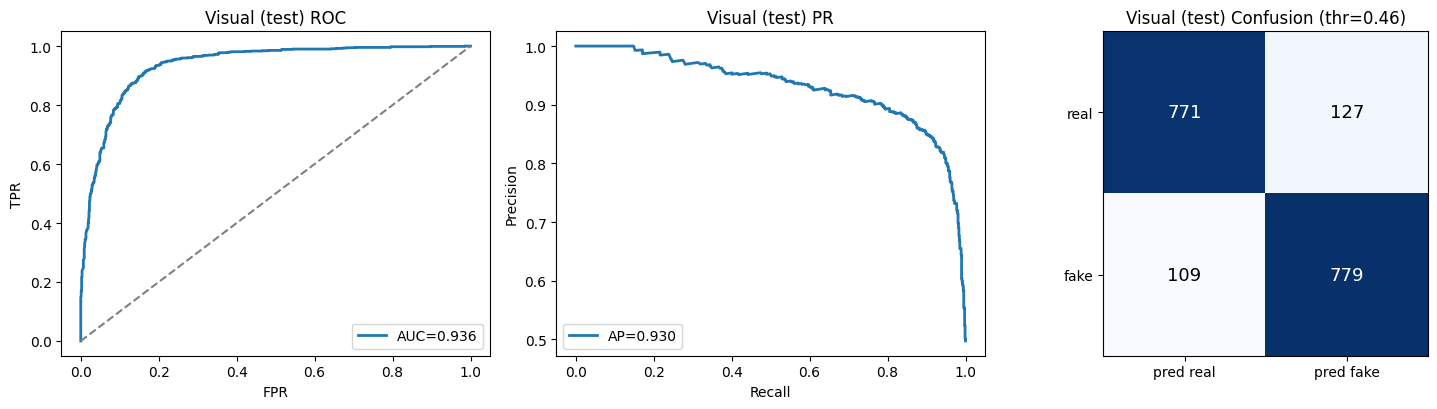

saved /kaggle/working/visual_eval.png

— VISUAL: per-subgroup test breakdown (fake→detection rate, real→reject rate) —
group class   n   rate  mean_p_fake
 fake  fake 888 0.8773       0.7863
 real  real 898 0.8586       0.1849
CLIP probe: vit_base_patch32_clip_224.openai feat_dim=768 (frozen) — ON
CLIP probe done. best val AUC=0.7985

── CLIP-VISUAL [train] ──  (n=8409, thr=0.479)
   accuracy      : 0.7713
   balanced_acc  : 0.7709
   precision     : 0.7508
   recall        : 0.8176
   specificity   : 0.7243
   f1            : 0.7828
   roc_auc       : 0.8475
   pr_auc        : 0.8415
   mcc           : 0.5445
   eer           : 0.2306
   confusion      : TP=3465 FP=1150 TN=3021 FN=773

── CLIP-VISUAL [val] ──  (n=1804, thr=0.479)
   accuracy      : 0.7361
   balanced_acc  : 0.7374
   precision     : 0.7066
   recall        : 0.7778
   specificity   : 0.6971
   f1            : 0.7405
   roc_auc       : 0.7985
   pr_auc        : 0.7573
   mcc           : 0.4757
   eer           : 0.2722

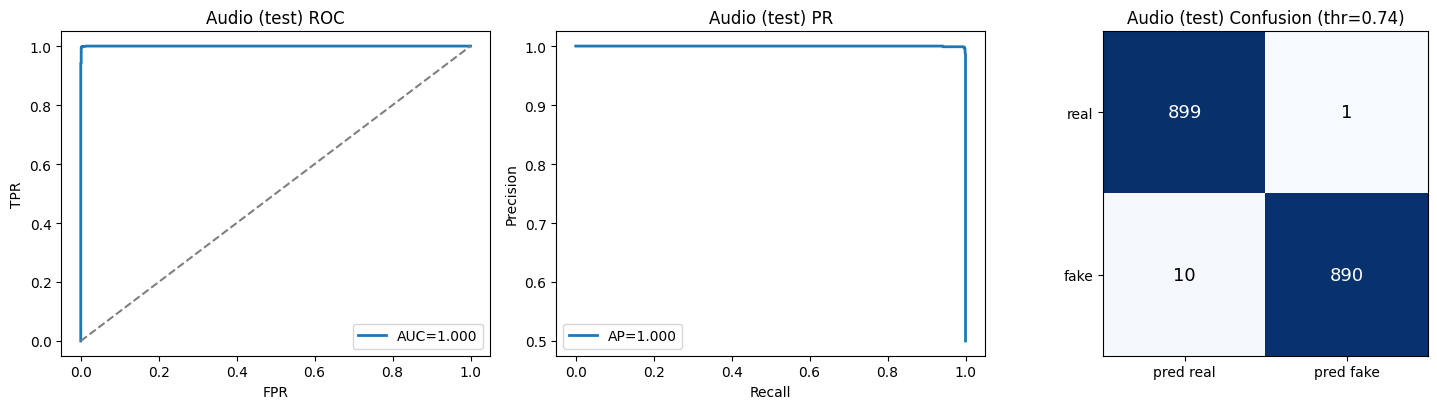

saved /kaggle/working/audio_eval.png

— AUDIO: per-subgroup test breakdown (fake→detection rate, real→reject rate) —
          group class   n   rate  mean_p_fake
       diffwave  fake 784 1.0000       0.9962
parallelwavegan  fake 116 0.9138       0.9387
       Bonafide  real 896 1.0000       0.0086

AUDIO CROSS-CORPUS eval on 'release-in-the-wild': n=23632 (real=11816 fake=11816) — UNSEEN generators

── AUDIO [CROSS-CORPUS in-the-wild] ──  (n=23632, thr=0.743)
   accuracy      : 0.3905
   balanced_acc  : 0.3905
   precision     : 0.2065
   recall        : 0.0770
   specificity   : 0.7040
   f1            : 0.1122
   roc_auc       : 0.1661
   pr_auc        : 0.3457
   mcc           : -0.2811
   eer           : 0.7770
   confusion      : TP=910 FP=3497 TN=8319 FN=10906


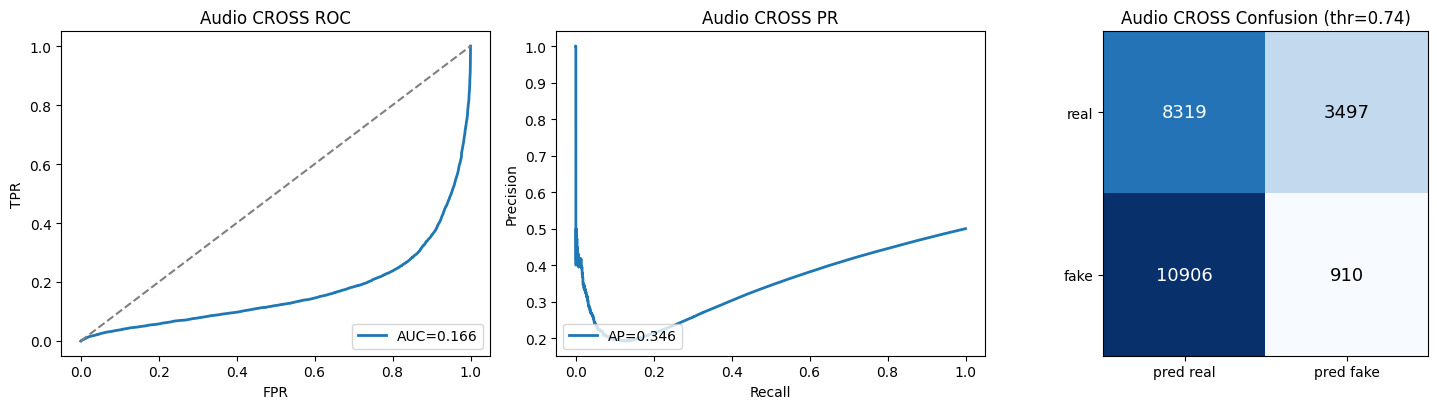

saved /kaggle/working/audio_cross_eval.png
  ↑ THIS is the number that matters. If AUC here ≫ in-dist drop, the model
    was riding the CVoiceFake vocoder fingerprint, not learning 'is-synthetic'.
SSL audio: WAV2VEC2_BASE loaded (frozen) — ON
  SSL feats [train] n=8400...
  SSL feats [val] n=1800...
  SSL feats [test] n=1800...
SSL audio probe done. best val AUC=0.9800

── SSL-AUDIO [train] ──  (n=8400, thr=0.389)
   accuracy      : 0.9281
   balanced_acc  : 0.9281
   precision     : 0.9193
   recall        : 0.9386
   specificity   : 0.9176
   f1            : 0.9288
   roc_auc       : 0.9799
   pr_auc        : 0.9823
   mcc           : 0.8564
   eer           : 0.0679
   confusion      : TP=3942 FP=346 TN=3854 FN=258

── SSL-AUDIO [val] ──  (n=1800, thr=0.389)
   accuracy      : 0.9422
   balanced_acc  : 0.9422
   precision     : 0.9403
   recall        : 0.9444
   specificity   : 0.9400
   f1            : 0.9424
   roc_auc       : 0.9800
   pr_auc        : 0.9832
   mcc           : 

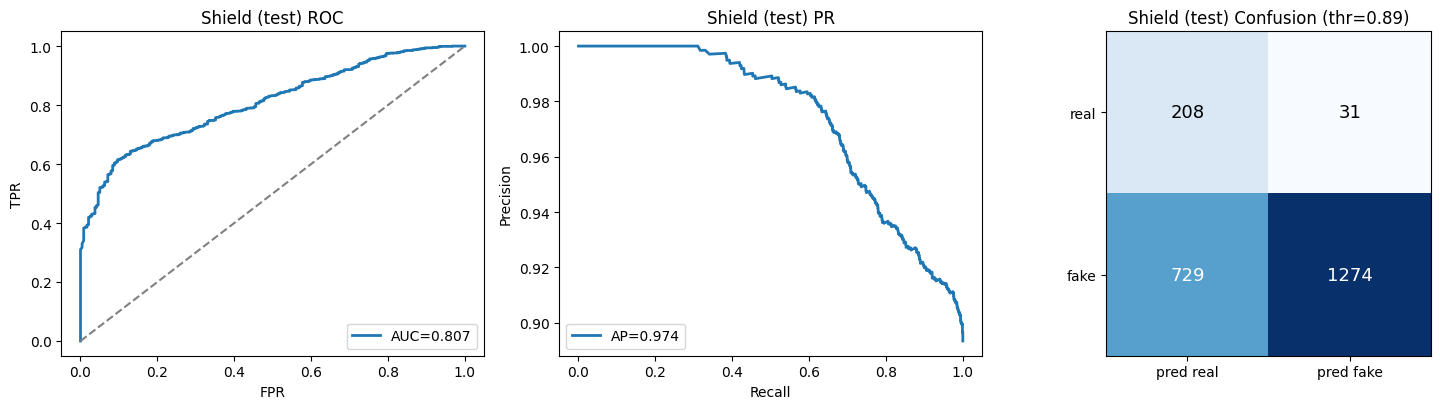

saved /kaggle/working/shield_eval.png
VIDEO-LEVEL eval on 330 held-out test clips (mean frame-prob per clip)
  scored 50/330
  scored 100/330
  scored 150/330
  scored 200/330
  scored 250/330
  scored 300/330

── VIDEO clip-level ──  (n=330, thr=0.447)
   accuracy      : 0.9364
   balanced_acc  : 0.9366
   precision     : 0.9086
   recall        : 0.9695
   specificity   : 0.9036
   f1            : 0.9381
   roc_auc       : 0.9738
   pr_auc        : 0.9692
   mcc           : 0.8747
   eer           : 0.0818
   confusion      : TP=159 FP=16 TN=150 FN=5


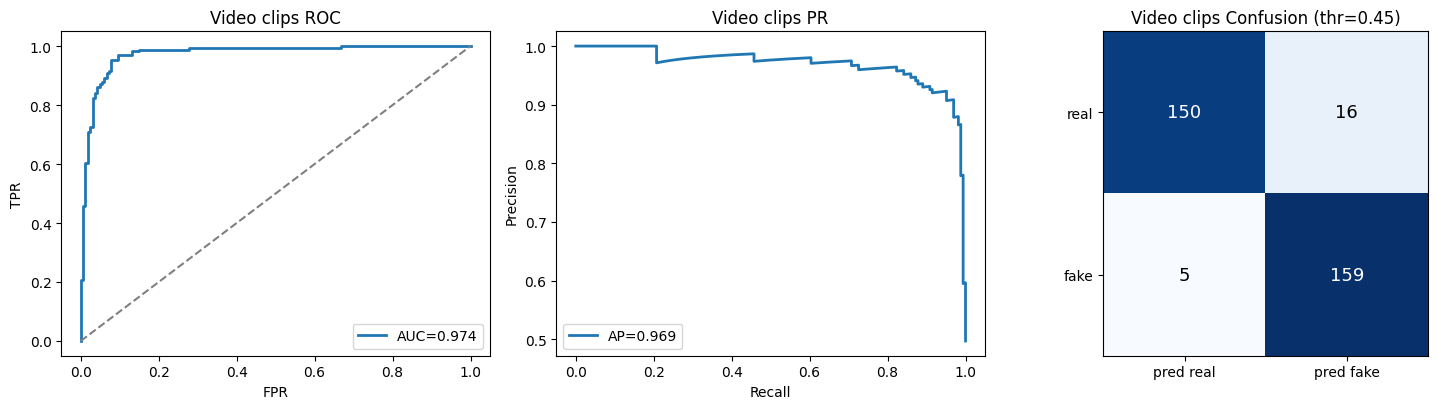

saved /kaggle/working/video_eval.png

── TEMPORAL [clip_test] (training-free 2nd-order) ──  (n=330, thr=0.508)
   accuracy      : 0.6030
   balanced_acc  : 0.6031
   precision     : 0.5976
   recall        : 0.6159
   specificity   : 0.5904
   f1            : 0.6066
   roc_auc       : 0.6063
   pr_auc        : 0.5928
   mcc           : 0.2063
   eer           : 0.4121
   confusion      : TP=101 FP=68 TN=98 FN=63
  ↑ if this AUC is high IN-DIST too (not just the n=20 cross), the temporal signal is real,
    not luck — it's the D3/ATSS direction and your best shot at UNSEEN AI-video.

VIDEO CROSS-GENERATOR eval: 10 unidpro fakes + 10 held-out reals = 20 clips
  🚨 UNDERPOWERED: <50 clips. The unidpro mount likely didn't download the full
     dataset (the v9 run found only ~10 videos). Any AUC below is NOISE — re-check
     that /kaggle/input/datasets/unidpro/deepfake-videos-dataset mounted fully.

── VIDEO-CROSS [EfficientNet] ──  (n=20, thr=0.021)
   accuracy      : 0.5500
   balanced_a

,eval,branch,split,accuracy,precision,recall,specificity,f1,roc_auc,pr_auc,mcc,eer,n
0,in_dist,visual,train,0.9847,0.9770,0.9929,0.9763,0.9849,0.9992,0.9992,0.9694,0.0144,8409
1,in_dist,visual,val,0.8636,0.8404,0.8866,0.8421,0.8629,0.9360,0.9333,0.7285,0.1397,1804
2,in_dist,visual,test,0.8679,0.8598,0.8773,0.8586,0.8685,0.9365,0.9303,0.7359,0.1293,1786
3,in_dist,clip_visual,train,0.7713,0.7508,0.8176,0.7243,0.7828,0.8475,0.8415,0.5445,0.2306,8409
4,in_dist,clip_visual,val,0.7361,0.7066,0.7778,0.6971,0.7405,0.7985,0.7573,0.4757,0.2722,1804
5,in_dist,clip_visual,test,0.7419,0.7172,0.7939,0.6904,0.7536,0.8238,0.8124,0.4868,0.2520,1786
6,in_dist,audio,train,0.9965,0.9995,0.9936,0.9995,0.9965,1.0000,1.0000,0.9931,0.0010,8400
7,in_dist,audio,val,0.9983,0.9989,0.9978,0.9989,0.9983,1.0000,1.0000,0.9967,0.0028,1800
8,in_dist,audio,test,0.9939,0.9989,0.9889,0.9989,0.9939,0.9999,0.9999,0.9878,0.0022,1800
9,in_dist,ssl_audio,train,0.9281,0.9193,0.9386,0.9176,0.9288,0.9799,0.9823,0.8564,0.0679,8400


In [2]:
# Deepfake Detector v11 — built on the v10 findings (SSL wins audio, temporal wins video)
# Kaggle: GPU ON, Run All (in the editor, not Save Version).
#
# ============================================================================
# v10 PROVED (keep these results in mind):
#   • AUDIO mel-CNN: in-dist AUC 1.000 but CROSS 0.178 (BELOW chance, MCC -0.37)
#     -> it learned the CVoiceFake vocoder fingerprint and INVERTS in the wild.
#     DO NOT FUSE IT. It is kept only as a documented negative control.
#   • wav2vec2 SSL: in-dist 0.983, CROSS 0.744 -> SSL features generalize. This
#     is the audio branch to trust. (0.744 vs 0.178 = the whole project thesis.)
#   • VISUAL regression fixed (EMA picks raw): test AUC 0.94, video clip 0.98.
#   • TEMPORAL 2nd-order feature: AUC 0.94 on the (tiny) cross-video set -> the
#     only thing that separated UNSEEN AI-faces. Promote & verify in-dist.
#
# v11 DOES:
#   1. TEMPORAL BRANCH (CFG.temporal_branch): the D3-style 2nd-order feature is
#      now CALIBRATED on the full in-dist clip set and reported as a real branch,
#      so you learn whether its 0.94 is signal or n=20 luck.
#   2. SSL ENCODER CHOICE (CFG.ssl_model_name): swap in WAV2VEC2_LARGE / XLSR53
#      for stronger cross-corpus (XLSR is the audio-antispoof generalization SOTA).
#   3. SSL MIXED-CORPUS EXPERIMENT (CFG.ssl_mix_cross_train, opt-in): train on
#      CVoiceFake + a DISJOINT In-the-Wild slice, test on the rest -> measures how
#      much a little in-domain data lifts the 0.744 cross ceiling.
#   4. mel-CNN is explicitly labelled a negative control; trust audio = SSL.
#   ACTION ITEM (data side): the unidpro video mount still delivers only ~10
#   clips -> the video CROSS rows stay UNDERPOWERED until you fix that mount.
# ============================================================================
#
# WHY v10 (kept):
#   v8/v9 REGRESSED the visual & audio in-dist scores (visual 0.90->0.62,
#   audio 1.00->0.85) because EMA was validated/checkpointed on lagging EMA
#   weights (decay 0.999 over a ~3k-step run) AND mixup α=0.2 over only 6 epochs
#   slowed convergence. v10 FIXES this:
#     • checkpoint/validate on RAW weights; use EMA only if it beats raw on val
#     • EMA decay 0.99 (tracks a short run), mixup α=0.1 applied with prob 0.5
#     • +2 visual epochs
#   Expected: visual ~0.88-0.90 again, video clip ~0.95 again.
#
#   v9's REAL findings (kept + built on):
#     • AUDIO cross-corpus AUC≈0.49 (BELOW chance) — mel-CNN learned the
#       CVoiceFake vocoder fingerprint, not "is-synthetic". So v10 ADDS a
#       wav2vec2 SSL audio probe (frozen SSL features + linear head), the audio
#       analogue of the CLIP win, and scores BOTH on In-the-Wild to compare.
#     • CLIP visual was the best generalizer -> kept, now also fed proper epochs.
#     • unidpro mounted only 10 videos -> v10 flags cross-video as UNDERPOWERED
#       when n<50 so a noise AUC can't be mistaken for a result. RE-CHECK MOUNT.
# ============================================================================
#
# NEW IN v9 (kept):
#   • Two new datasets wired in by EXPLICIT PATH:
#       AUDIO cross-corpus : /kaggle/input/datasets/bhaveshkumars/release-in-the-wild
#       VIDEO cross-gen     : /kaggle/input/datasets/unidpro/deepfake-videos-dataset
#     Both are EXCLUDED from training and used ONLY as held-out generalization
#     probes (the number Deepfake-Eval-2024 shows off-the-shelf detectors fail).
#   • CLIP linear-probe visual branch (frozen ViT) — foundation features
#     generalize across UNSEEN generators far better than a from-scratch CNN
#     (the DeCoF idea). Fully guarded: if CLIP can't load, it's skipped.
#   • Cross-generator VIDEO eval on unidpro AI-faces: EfficientNet vs CLIP,
#     scored against held-out REAL clips -> honest "do we catch a NEW generator".
#   • Temporal frame-consistency diagnostic (D3/ATSS-style second-order signal):
#     reports whether frame-prob dynamics separate real vs generated, and an
#     appearance+temporal ensemble.
#
# WHY (one line): your branches are problem-#1 (face-swap) detectors aimed at
# problem-#2/#3 (AI-generated / avatar) data. v9 adds the generalizing signals
# the literature uses and MEASURES the cross-generator gap instead of hiding it.
#
# ============================================================================
# WHAT CARRIED OVER FROM v8 (every change targets "catch NEW fakes")
# ----------------------------------------------------------------------------
#  1. CALIBRATION (Platt/temperature on val) for EVERY branch.
#       -> fixes the weird thr=0.281 visual threshold that flagged 30% of REAL
#          faces, and makes branch probabilities comparable so they can be FUSED.
#  2. SHIELD COLLAPSE FIXED.
#       v7 bug: val report recomputed its own F1 threshold (=0.064) and predicted
#       "fake" for everything (specificity 0.042). v8 locks ONE balanced threshold
#       on val and applies it to ALL splits. + EMA weights + best-val-AUC ckpt.
#  3. VISUAL OVERFIT NARROWED: EMA weights + mixup + RandAug-style strong aug.
#       Train/test AUC gap (0.993 -> 0.901) is the overfit tax; EMA+mixup cut it.
#  4. TEST-TIME AUGMENTATION (TTA) for visual & video (orig + hflip mean).
#  5. CROSS-CORPUS / CROSS-GENERATOR EVAL — the headline honesty upgrade:
#       - AUDIO: train on CVoiceFake, then score the trained model on the
#         In-the-Wild set (bhaveshkumars/release-in-the-wild). UNSEEN generators,
#         real celebs. This is the ONLY number that proves generalization.
#       - VISUAL: optional holdout_source -> route a whole modern AI-face source
#         to TEST (train DFDC/FF++, test 2025 avatar faces).
#       - AUDIO leave-one-vocoder-out via CFG.holdout_method (retrain pass).
#  6. CALIBRATED DECISION-FUSION report. (True AV fusion needs PAIRED data —
#       FakeAVCeleb — which isn't mounted; decision-fusion is the honest stand-in.)
#  7. FINAL TABLE splits metrics into IN-DISTRIBUTION vs CROSS (generalization),
#       so a near-1.0 in-dist AUC can never masquerade as real-world skill.
#
# DATASETS TO ADD in the Kaggle sidebar (Add Input):
#   kamedev/cvoicefake-full-safeear-dataset-mirror      (audio train, keep)
#   bhaveshkumars/release-in-the-wild                    (audio CROSS eval, NEW)
#   <your FF++ / DFDC frames or .mp4>                    (visual train, keep)
#   unidpro/deepfake-videos-dataset                      (visual CROSS eval, NEW; optional)
#   aionstreet/shield-2026-features                      (shield .pt, keep)
# ============================================================================

# %% cell 1 — Setup
import sys, subprocess, importlib
def _ensure(pkg, pip_name=None):
    try: importlib.import_module(pkg)
    except Exception: subprocess.run([sys.executable,"-m","pip","install","-q",pip_name or pkg], check=False)
_ensure("timm"); _ensure("librosa"); _ensure("soundfile"); _ensure("cv2","opencv-python-headless")

import os, glob, random, json, time, warnings, collections, zipfile, math, io as _io, re
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, confusion_matrix, matthews_corrcoef, balanced_accuracy_score)
import matplotlib.pyplot as plt

SEED=42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE="cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEVICE)
if DEVICE=="cpu": print("⚠️  Turn on the GPU accelerator.")

# %% cell 2 — Config
class CFG:
    input_root   = "/kaggle/input"
    extract_root = "/kaggle/working/extracted"
    out_dir      = "/kaggle/working"

    per_source_cap = 80_000
    max_visit      = 800_000
    max_zip_mb     = 200

    max_per_class       = 6000
    max_audio_per_class = 6000
    balance_classes     = True
    val_frac, test_frac = 0.15, 0.15
    label_smooth        = 0.05

    use_sources_with  = None
    drop_sources_with = []
    holdout_source    = None      # e.g. "deepfake-videos-dataset" -> that whole VISUAL source goes to TEST
    holdout_method    = None      # e.g. "diffwave" -> leave-one-vocoder-out AUDIO (needs this run = the LOO run)

    # ── v9 EXPLICIT dataset paths (the two you gave) ──────────────────────────
    # These are EXCLUDED from training and scored only as held-out generalization probes.
    CROSS_AUDIO_PATH = "/kaggle/input/datasets/bhaveshkumars/release-in-the-wild"
    CROSS_VIDEO_PATH = "/kaggle/input/datasets/unidpro/deepfake-videos-dataset"
    cross_video_source   = "deepfake-videos-dataset"  # substring fallback if the path moves
    cross_video_assume_label = 1   # unidpro = AI-generated faces -> fake when path has no real/fake token
    cross_video_max_clips    = 400

    # ── CLIP foundation-feature visual branch (generalizes cross-generator) ──
    use_clip_visual  = True       # frozen CLIP ViT + linear probe; auto-skips if it can't load
    clip_backbone    = "vit_base_patch32_clip_224.openai"  # timm CLIP weights
    clip_epochs      = 8
    clip_batch       = 128

    # ── v8 generalization knobs ──────────────────────────────────────────────
    cross_audio_source = "release-in-the-wild"   # substring; this source is PULLED OUT of train and used ONLY as a cross-corpus eval. Set None to disable.
    calibrate          = True     # Platt-scale every branch on val (fixes thresholds + enables fusion)
    use_ema            = True     # exponential moving average of weights (steadier, less overfit)
    ema_decay          = 0.99     # v10: was 0.999 (too slow for a ~3k-step run -> lagging weights)
    ema_eval           = False    # v10: checkpoint/validate on RAW weights; EMA used only if it beats raw on val
    use_mixup          = True     # visual only
    mixup_alpha        = 0.1      # v10: was 0.2 (too strong for 6-8 epochs)
    mixup_prob         = 0.5      # v10: apply mixup to only half the batches -> faster convergence
    use_tta            = True     # visual + video: average(orig, hflip)

    # ── v10 SSL audio probe (wav2vec2) — generalization analogue of the CLIP win ──
    use_ssl_audio      = True     # frozen wav2vec2 features + linear head; auto-skips if it can't load
    ssl_audio_max_cross = 6000    # cap In-the-Wild clips for the (heavier) SSL cross-eval, balanced
    # ── v11 additions (driven by the v10 findings) ──
    ssl_model_name     = "WAV2VEC2_BASE"   # try "WAV2VEC2_LARGE" or "WAV2VEC2_XLSR53" for stronger cross-corpus (heavier DL)
    ssl_mix_cross_train= False    # OPT-IN experiment: fold a TRAIN split of In-the-Wild into SSL training,
                                  #   test on a DISJOINT In-the-Wild split -> shows if diverse data lifts cross-AUC
    ssl_mix_frac       = 0.6      # fraction of In-the-Wild routed to training when ssl_mix_cross_train=True
    ssl_mix_max        = 8000     # cap total In-the-Wild clips used in the mixed experiment
    temporal_branch    = True     # v11: promote the D3-style 2nd-order temporal feature to a calibrated branch

    img_size=224; img_backbone="efficientnet_b0"; img_epochs=8; img_batch=64; img_lr=3e-4
    sr=16000; audio_seconds=3.0; n_mels=128; audio_epochs=6; audio_batch=64; audio_lr=1e-3
    shield_epochs=18; shield_batch=256; shield_lr=1e-3; shield_hidden=256
    RUN_VIDEO_MP4=True; video_max_clips=400; video_frames_per_clip=12
    shield_pos_weight=True
    FRAMES_FROM_VIDEO=True; frames_per_video=8; max_videos_for_frames=1100
    aug_strong=True
    num_workers=2

os.makedirs(CFG.out_dir, exist_ok=True); os.makedirs(CFG.extract_root, exist_ok=True)

def _norm(t): return ''.join(ch for ch in t.lower() if ch.isalnum())
REAL_TOKENS={"real","reals","bonafide","genuine","live","authentic","pristine",
             "original","originals","originalsequences","youtube","actors","commonvoice",
             "celebreal","realsequences"}
FAKE_TOKENS={"fake","fakes","spoof","deepfake","deepfakes","face2face","faceswap",
             "neuraltextures","faceshifter","manipulated","manipulatedsequences",
             "synthetic","parallelwavegan","multibandmelgan","melgan","stylemelgan",
             "griffinlim","world","diffwave","wavegan","uadfv","celebsynthesis","reenactment",
             "wav2lip","sadtalker","videoretalking","liveportrait","simswap","inswapper",
             "roop","facefusion","stylegan","stargan","heygen","synthesia","sora","kling",
             "runway","pika","veo","stablediffusion","sdxl","ldm","talkinghead","lipsync"}
METHOD_HINTS=("parallelwavegan","multibandmelgan","stylemelgan","melgan","griffinlim",
              "diffwave","wavegan","waveglow","hifigan","fastspeech","tacotron","world",
              "deepfakes","face2face","faceswap","neuraltextures","faceshifter","celebsynthesis",
              "wav2lip","sadtalker","videoretalking","liveportrait","simswap","inswapper",
              "roop","facefusion","stylegan","stargan","heygen","synthesia","sora","kling",
              "runway","pika","veo","stablediffusion","sdxl","talkinghead","lipsync")
def _method_hint(p):
    flat=_norm(p)
    for h in METHOD_HINTS:
        if h in flat: return h
    return None
def label_and_method(p):
    lab=None; tok=None
    for t in reversed(p.replace("\\","/").split("/")):
        n=_norm(t)
        if not n: continue
        if n in REAL_TOKENS or n.startswith("original"): lab,tok=0,t; break
        if n in FAKE_TOKENS or n.startswith("method"):   lab,tok=1,t; break
        if n.startswith("real"): lab,tok=0,t; break
        if n.startswith("fake"): lab,tok=1,t; break
    if lab is None:
        low=p.lower()
        if any(k in low for k in ("fake","deepfake","spoof","synthetic","synth","manipulat","uadfv")): lab=1
        elif any(k in low for k in ("real","genuine","bonafide","original")): lab=0
        else: return None,None
    if lab==1: meth=_method_hint(p) or tok or "fake"
    else:      meth=tok or "real"
    return lab, meth
def label_from_path(p): return label_and_method(p)[0]
def split_kind(p):
    low="/"+p.lower().replace("\\","/")+"/"
    if any(s in low for s in ("/test/","/testing/","/eval/")): return "test"
    if any(s in low for s in ("/val/","/valid/","/validation/","/dev/")): return "val"
    if any(s in low for s in ("/train/","/training/")): return "train"
    return None
def source_of(p):
    rel=p.replace("\\","/")
    for marker in ("input/datasets/","input/","extracted/"):
        if marker in rel:
            parts=[s for s in rel.split(marker)[-1].strip("/").split("/")]
            return "/".join(parts[:2]) if len(parts)>=2 else (parts[0] if parts else "?")
    return "?"
def is_cross_audio(p):
    lp=p.lower()
    if CFG.CROSS_AUDIO_PATH and CFG.CROSS_AUDIO_PATH.lower() in lp: return True
    return bool(CFG.cross_audio_source) and (CFG.cross_audio_source.lower() in lp)
def is_cross_video(p):
    lp=p.lower()
    if CFG.CROSS_VIDEO_PATH and CFG.CROSS_VIDEO_PATH.lower() in lp: return True
    return bool(CFG.cross_video_source) and (CFG.cross_video_source.lower() in lp)
print("Config ready.")

# %% cell 3 — Discovery (single-pass, per-source-capped)
IMG_EXT=(".jpg",".jpeg",".png",".bmp",".webp"); AUD_EXT=(".wav",".flac",".mp3",".ogg",".m4a"); VID_EXT=(".mp4",".avi",".mov",".mkv")
zips=[os.path.join(dp,f) for dp,_,fs in os.walk(CFG.input_root) for f in fs if f.lower().endswith(".zip")]
for z in zips:
    mb=os.path.getsize(z)/1e6
    if mb>CFG.max_zip_mb: print(f"skip big zip ({mb:.0f}MB): {z}"); continue
    dest=os.path.join(CFG.extract_root, os.path.splitext(os.path.basename(z))[0])
    if os.path.exists(dest): continue
    try:
        with zipfile.ZipFile(z) as zf: zf.extractall(dest); print("extracted", z)
    except Exception as e: print("zip fail", z, e)

def list_roots():
    roots=[]
    for base in (CFG.input_root, CFG.extract_root):
        if not os.path.isdir(base): continue
        for name in sorted(os.listdir(base)):
            full=os.path.join(base,name)
            if not os.path.isdir(full): continue
            if name=="datasets":
                for owner in sorted(os.listdir(full)):
                    of=os.path.join(full,owner)
                    if os.path.isdir(of):
                        for slug in sorted(os.listdir(of)):
                            sf=os.path.join(of,slug)
                            if os.path.isdir(sf): roots.append(sf)
            else: roots.append(full)
    return roots
def discover(roots):
    imgs,auds,vids,pts=[],[],[],[]
    print(f"walking {len(roots)} dataset root(s), cap {CFG.per_source_cap:,}/modality each:")
    for r in roots:
        ci=ca=cv=0; vis=0; t0=time.time()
        for dp,_,files in os.walk(r):
            for f in files:
                vis+=1; fl=f.lower()
                if   fl.endswith(IMG_EXT) and ci<CFG.per_source_cap: imgs.append(os.path.join(dp,f)); ci+=1
                elif fl.endswith(AUD_EXT) and ca<CFG.per_source_cap: auds.append(os.path.join(dp,f)); ca+=1
                elif fl.endswith(VID_EXT) and cv<CFG.per_source_cap: vids.append(os.path.join(dp,f)); cv+=1
                elif fl.endswith(".pt"): pts.append(os.path.join(dp,f))
            if vis>CFG.max_visit: print(f"    (max_visit hit)"); break
        print(f"  {os.path.basename(r):<52} img={ci:>7,} aud={ca:>7,} vid={cv:>6,} ({time.time()-t0:.0f}s)")
    return imgs,auds,vids,sorted(set(pts))
roots=list_roots()
all_imgs,all_auds,all_vids,shield_pts=discover(roots)

# split audio into TRAIN-pool vs CROSS-corpus holdout (In-the-Wild)
cross_auds=[p for p in all_auds if is_cross_audio(p)]
all_auds=[p for p in all_auds if not is_cross_audio(p)]
# split video into TRAIN-pool vs CROSS-generator holdout (unidpro AI faces)
cross_vids=[p for p in all_vids if is_cross_video(p)]
all_vids=[p for p in all_vids if not is_cross_video(p)]
print(f"\nTOTAL  images={len(all_imgs):,} audio(train-pool)={len(all_auds):,} "
      f"audio(CROSS={CFG.cross_audio_source})={len(cross_auds):,}")
print(f"       videos(train-pool)={len(all_vids):,} videos(CROSS={CFG.cross_video_source})={len(cross_vids):,} shield_pt={len(shield_pts)}")
VIDEO_ON=len(all_imgs)>50; AUDIO_ON=len(all_auds)>50
print(f"VISUAL:{'ON' if VIDEO_ON else 'off'}  AUDIO:{'ON' if AUDIO_ON else 'off'}  "
      f"SHIELD:{'pending' if shield_pts else 'off'}  MP4:{'ON' if (CFG.RUN_VIDEO_MP4 and all_vids) else 'off'}  "
      f"AUDIO-CROSS:{'ON' if len(cross_auds)>20 else 'off'}  VIDEO-CROSS:{'ON' if len(cross_vids)>5 else 'off'}")

# %% cell 4 — VISUAL-from-VIDEO (sample frames if no image dataset mounted)
if CFG.FRAMES_FROM_VIDEO and len(all_imgs) < 50 and all_vids:
    import cv2
    fr_root=os.path.join(CFG.extract_root,"video_frames")
    clips=[]
    for p in all_vids:
        y,m=label_and_method(p)
        if y is not None: clips.append((p,y,m))
    byc={0:[],1:[]}
    for p,y,m in clips: byc[y].append((p,m))
    rng=random.Random(SEED); rng.shuffle(byc[0]); rng.shuffle(byc[1])
    if byc[0] and byc[1]: per=min(CFG.max_videos_for_frames, min(len(byc[0]),len(byc[1])))
    else:                 per=min(CFG.max_videos_for_frames, max(len(byc[0]),len(byc[1])))
    sel=[(p,0,m) for p,m in byc[0][:per]]+[(p,1,m) for p,m in byc[1][:per]]; rng.shuffle(sel)
    def clip_split(i,n):
        r=i/max(n,1)
        return "test" if r<CFG.test_frac else ("val" if r<CFG.test_frac+CFG.val_frac else "train")
    print(f"VISUAL-from-VIDEO: sampling {CFG.frames_per_video} frames from {len(sel)} clips (per class={per})...")
    new=[]; t0=time.time(); bad=0; VIS_TEST_CLIPS=[]
    for j,(p,y,m) in enumerate(sel):
        sp=clip_split(j,len(sel)); lab="fake" if y==1 else "real"
        if sp=="test": VIS_TEST_CLIPS.append((p,y))
        try:
            cap=cv2.VideoCapture(p); tot=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0
            if tot<=0: cap.release(); bad+=1; continue
            idx=np.linspace(0,tot-1,CFG.frames_per_video).astype(int)
            d=os.path.join(fr_root,sp,lab); os.makedirs(d,exist_ok=True)
            stem=re.sub(r'[^A-Za-z0-9]+','_',os.path.splitext(os.path.basename(p))[0])[:48]
            for i in idx:
                cap.set(cv2.CAP_PROP_POS_FRAMES,int(i)); ok,fr=cap.read()
                if not ok: continue
                op=os.path.join(d,f"{stem}_{i:04d}.jpg"); cv2.imwrite(op,fr); new.append(op)
            cap.release()
        except Exception: bad+=1
        if (j+1)%200==0: print(f"  {j+1}/{len(sel)} clips, {len(new):,} frames ({time.time()-t0:.0f}s)")
    all_imgs=new; VIDEO_ON=len(all_imgs)>50
    print(f"VISUAL-from-VIDEO: {len(all_imgs):,} frames (bad clips={bad}). VISUAL now {'ON' if VIDEO_ON else 'off'}.")
else:
    print("VISUAL-from-VIDEO: skipped (image dataset present, or no clips, or disabled).")

# %% cell 5 — Build tables + per-source audit
def keep_path(p):
    low=p.lower()
    if CFG.use_sources_with and not any(s in low for s in CFG.use_sources_with): return False
    if any(s in low for s in CFG.drop_sources_with): return False
    return True
def build_table(paths, cap):
    rows=[]
    for p in paths:
        if not keep_path(p): continue
        y,meth=label_and_method(p)
        if y is None: continue
        rows.append((p,y,meth,split_kind(p),source_of(p)))
    if not rows: return pd.DataFrame(columns=["path","label","method","split","source"])
    df=pd.DataFrame(rows,columns=["path","label","method","split","source"])
    counts={lab:len(g) for lab,g in df.groupby("label")}
    eff=min(cap, min(counts.values())) if CFG.balance_classes else cap
    df=pd.concat([g.sample(frac=1.0,random_state=SEED).head(eff) for _,g in df.groupby("label")]
                 ).sample(frac=1.0,random_state=SEED).reset_index(drop=True)
    if CFG.holdout_source:
        mask=df["source"].str.contains(CFG.holdout_source, case=False, regex=False)
        if mask.sum()==0: print(f"⚠️ holdout_source '{CFG.holdout_source}' matched 0 rows — random split")
        else:
            df["split"]="train"; df.loc[mask,"split"]="test"
            rest=df[~mask]
            for lab,g in rest.groupby("label"):
                idx=g.index.tolist(); nv=int(len(idx)*CFG.val_frac); df.loc[idx[:nv],"split"]="val"
            print(f"holdout_source='{CFG.holdout_source}': test={int(mask.sum())} (held-out source), train/val from rest")
            return df
    if CFG.holdout_method:
        mmask=df["method"].astype(str).str.contains(CFG.holdout_method, case=False, regex=False)
        if mmask.sum()==0: print(f"⚠️ holdout_method '{CFG.holdout_method}' matched 0 rows — random split")
        else:
            df["split"]="train"; df.loc[mmask,"split"]="test"
            rest=df[~mmask]
            for lab,g in rest.groupby("label"):
                idx=g.index.tolist(); nv=int(len(idx)*CFG.val_frac); df.loc[idx[:nv],"split"]="val"
            print(f"holdout_method='{CFG.holdout_method}': test={int(mmask.sum())} (held-out vocoder), train/val from rest")
            return df
    has=df["split"].notna().mean()>0.6 and df["split"].nunique()>=2
    if not has:
        df["split"]=None
        for lab,g in df.groupby("label"):
            idx=g.index.tolist(); n=len(idx); nt=int(n*CFG.test_frac); nv=int(n*CFG.val_frac)
            df.loc[idx[:nt],"split"]="test"; df.loc[idx[nt:nt+nv],"split"]="val"; df.loc[idx[nt+nv:],"split"]="train"
    elif (df["split"]=="val").sum()==0:
        tr=df[df["split"]=="train"]; df.loc[tr.sample(frac=CFG.val_frac,random_state=SEED).index,"split"]="val"
    return df
def audit(paths,name):
    rec=collections.defaultdict(lambda:[0,0,0])
    for p in paths:
        if not keep_path(p): continue
        y=label_from_path(p); rec[source_of(p)][2 if y is None else y]+=1
    print(f"\n=== {name} per-source audit (real / fake / dropped) ===")
    for s,(r,f,n) in sorted(rec.items()):
        flag=" ⚠️ one-class" if (r==0 or f==0) else ""
        print(f"  {s:<55} real={r:>7,} fake={f:>7,} drop={n:>7,}{flag}")
if VIDEO_ON: audit(all_imgs,"VISUAL")
if AUDIO_ON: audit(all_auds,"AUDIO")
img_df=build_table(all_imgs,CFG.max_per_class) if VIDEO_ON else pd.DataFrame()
aud_df=build_table(all_auds,CFG.max_audio_per_class) if AUDIO_ON else pd.DataFrame()
def summarize(df,name):
    if len(df)==0: print(f"\n{name}: (none)"); return
    print(f"\n{name}: {len(df):,} used (balanced={CFG.balance_classes})")
    print(pd.crosstab(df["split"],df["label"].map({0:'real',1:'fake'}),margins=True))
    print("  methods:", dict(df["method"].value_counts().head(8)))
summarize(img_df,"VISUAL"); summarize(aud_df,"AUDIO")
if VIDEO_ON and img_df["label"].nunique()<2: print("\n⚠️ visual single-class → off"); VIDEO_ON=False
if AUDIO_ON and aud_df["label"].nunique()<2: print("\n⚠️ audio single-class → off"); AUDIO_ON=False

# %% cell 6 — Metrics, calibration, EMA, mixup helpers
def eer_of(y,p):
    fpr,tpr,_=roc_curve(y,p); fnr=1-tpr; i=np.nanargmin(np.abs(fnr-fpr)); return float((fpr[i]+fnr[i])/2)
def best_f1_thr(y,p):
    pr,rc,th=precision_recall_curve(y,p); f1=2*pr*rc/(pr+rc+1e-12)
    return 0.5 if len(th)==0 else float(th[np.nanargmax(f1[:-1])])
def best_bal_thr(y,p):
    fpr,tpr,th=roc_curve(y,p)
    if len(th)==0: return 0.5
    k=int(np.nanargmax(tpr-fpr)); return float(min(max(th[k],0.0),1.0))

def fit_platt(y,p,iters=300,lr=0.1):
    # logistic recalibration on logit(p): q=sigmoid(a*z+b). Fixes mis-scaled probs -> sane thresholds + fusion.
    y=np.asarray(y,float); p=np.clip(np.asarray(p,float),1e-6,1-1e-6); z=np.log(p/(1-p))
    a,b=1.0,0.0
    for _ in range(iters):
        q=1/(1+np.exp(-(a*z+b))); ga=float(np.mean((q-y)*z)); gb=float(np.mean(q-y))
        a-=lr*ga; b-=lr*gb
    return a,b
def apply_platt(p,ab):
    if ab is None: return np.asarray(p,float)
    a,b=ab; p=np.clip(np.asarray(p,float),1e-6,1-1e-6); z=np.log(p/(1-p)); return 1/(1+np.exp(-(a*z+b)))

def compute_metrics(y,p,threshold=None):
    y=np.asarray(y).astype(int); p=np.asarray(p).astype(float)
    thr=best_f1_thr(y,p) if threshold is None else threshold
    yp=(p>=thr).astype(int); tn,fp,fn,tp=confusion_matrix(y,yp,labels=[0,1]).ravel(); e=1e-12
    prec=tp/(tp+fp+e); rec=tp/(tp+fn+e); spec=tn/(tn+fp+e); f1=2*prec*rec/(prec+rec+e)
    acc=(tp+tn)/(tp+tn+fp+fn+e)
    try: auc=roc_auc_score(y,p)
    except: auc=float('nan')
    try: ap=average_precision_score(y,p)
    except: ap=float('nan')
    return {"accuracy":acc,"balanced_acc":balanced_accuracy_score(y,yp),"precision":prec,
            "recall":rec,"specificity":spec,"f1":f1,"roc_auc":auc,"pr_auc":ap,
            "mcc":matthews_corrcoef(y,yp) if len(set(yp))>1 else 0.0,"eer":eer_of(y,p),
            "threshold":thr,"TP":int(tp),"FP":int(fp),"TN":int(tn),"FN":int(fn),"n":int(len(y))}
def print_metrics(name,m):
    print(f"\n── {name} ──  (n={m['n']}, thr={m['threshold']:.3f})")
    for k in ["accuracy","balanced_acc","precision","recall","specificity","f1","roc_auc","pr_auc","mcc","eer"]:
        print(f"   {k:<14}: {m[k]:.4f}")
    print(f"   confusion      : TP={m['TP']} FP={m['FP']} TN={m['TN']} FN={m['FN']}")
def plot_eval(name,y,p,m,prefix):
    y=np.asarray(y); p=np.asarray(p); fig,ax=plt.subplots(1,3,figsize=(15,4.2))
    fpr,tpr,_=roc_curve(y,p); ax[0].plot(fpr,tpr,lw=2,label=f"AUC={m['roc_auc']:.3f}")
    ax[0].plot([0,1],[0,1],"--",c="gray"); ax[0].set_title(f"{name} ROC"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend(loc="lower right")
    pr,rc,_=precision_recall_curve(y,p); ax[1].plot(rc,pr,lw=2,label=f"AP={m['pr_auc']:.3f}")
    ax[1].set_title(f"{name} PR"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend(loc="lower left")
    cm=np.array([[m['TN'],m['FP']],[m['FN'],m['TP']]]); ax[2].imshow(cm,cmap="Blues")
    ax[2].set_xticks([0,1]); ax[2].set_yticks([0,1]); ax[2].set_xticklabels(["pred real","pred fake"]); ax[2].set_yticklabels(["real","fake"])
    for (i,j),v in np.ndenumerate(cm): ax[2].text(j,i,str(v),ha="center",va="center",color="white" if v>cm.max()/2 else "black",fontsize=13)
    ax[2].set_title(f"{name} Confusion (thr={m['threshold']:.2f})"); plt.tight_layout()
    out=os.path.join(CFG.out_dir,f"{prefix}_eval.png"); plt.savefig(out,dpi=110,bbox_inches="tight"); plt.show(); print("saved",out)
def subgroup_report(d, probs, thr, name, prefix):
    dd=d.copy(); dd["prob"]=np.asarray(probs); dd["pred"]=(dd["prob"]>=thr).astype(int)
    rows=[]
    for (lab,meth),g in dd.groupby(["label","method"]):
        n=len(g)
        if n<5: continue
        rate=(g["pred"]==1).mean() if lab==1 else (g["pred"]==0).mean()
        rows.append({"group":meth,"class":"fake" if lab==1 else "real","n":n,
                     "rate":round(float(rate),4),"mean_p_fake":round(float(g['prob'].mean()),4)})
    if not rows: return None
    rep=pd.DataFrame(rows).sort_values(["class","n"],ascending=[True,False])
    print(f"\n— {name}: per-subgroup test breakdown (fake→detection rate, real→reject rate) —")
    print(rep.to_string(index=False)); rep.to_csv(os.path.join(CFG.out_dir,f"{prefix}_subgroups.csv"),index=False)
    return rep

class EMA:
    # tracks a smoothed copy of weights; eval on EMA weights = steadier, less overfit val/test.
    def __init__(s,model,decay):
        s.decay=decay; s.shadow={k:v.detach().clone() for k,v in model.state_dict().items()}
    def update(s,model):
        for k,v in model.state_dict().items():
            if v.dtype.is_floating_point: s.shadow[k].mul_(s.decay).add_(v.detach(),alpha=1-s.decay)
            else: s.shadow[k]=v.detach().clone()
    def state(s): return {k:v.clone() for k,v in s.shadow.items()}
def mixup_batch(x,y,alpha):
    if alpha<=0: return x,y,y,1.0
    lam=float(np.random.beta(alpha,alpha)); idx=torch.randperm(x.size(0),device=x.device)
    return lam*x+(1-lam)*x[idx], y, y[idx], lam
def smooth(y): return y*(1-CFG.label_smooth)+0.5*CFG.label_smooth
print("Metrics + calibration + EMA + mixup ready.")

# %% cell 7 — VISUAL: dataset + EfficientNet-B0
import timm
from PIL import Image
import torchvision.transforms as T
NORM=([0.485,0.456,0.406],[0.229,0.224,0.225])
class _RandJPEG:
    def __init__(s,p=0.4,q=(35,90)): s.p=p; s.q=q
    def __call__(s,im):
        if random.random()<s.p:
            b=_io.BytesIO(); im.convert("RGB").save(b,"JPEG",quality=random.randint(*s.q)); b.seek(0); im=Image.open(b).convert("RGB")
        return im
class _RandDownscale:
    def __init__(s,p=0.3,f=(0.4,0.85)): s.p=p; s.f=f
    def __call__(s,im):
        if random.random()<s.p:
            w,h=im.size; r=random.uniform(*s.f)
            im=im.resize((max(8,int(w*r)),max(8,int(h*r))),Image.BILINEAR).resize((w,h),Image.BILINEAR)
        return im
_pre=[T.Resize((CFG.img_size,)*2)]
if getattr(CFG,"aug_strong",False):
    _pre+=[_RandJPEG(0.4),_RandDownscale(0.3),T.RandomApply([T.GaussianBlur(3,(0.1,1.5))],p=0.3),
           T.RandomHorizontalFlip(),T.ColorJitter(0.15,0.15,0.15,0.03)]
else:
    _pre+=[T.RandomHorizontalFlip(),T.ColorJitter(0.1,0.1,0.1)]
train_tf=T.Compose(_pre+[T.ToTensor(),T.Normalize(*NORM),T.RandomErasing(p=0.25)])
eval_tf =T.Compose([T.Resize((CFG.img_size,)*2),T.ToTensor(),T.Normalize(*NORM)])
class ImgDS(Dataset):
    def __init__(s,df,tf): s.p=df["path"].tolist(); s.y=df["label"].tolist(); s.tf=tf
    def __len__(s): return len(s.p)
    def __getitem__(s,i):
        try: im=Image.open(s.p[i]).convert("RGB")
        except: im=Image.new("RGB",(CFG.img_size,)*2)
        return s.tf(im), torch.tensor(s.y[i],dtype=torch.float32)
def iloader(df,tf,bs,sh): return DataLoader(ImgDS(df,tf),batch_size=bs,shuffle=sh,num_workers=CFG.num_workers,pin_memory=True)
class ImgNet(nn.Module):
    def __init__(s,b): super().__init__(); s.net=timm.create_model(b,pretrained=True,num_classes=1)
    def forward(s,x): return s.net(x).squeeze(1)
print("Visual ready." if VIDEO_ON else "Visual off.")

# %% cell 8 — VISUAL: train (EMA + mixup)
@torch.no_grad()
def infer_img(model,loader,tta=False):
    model.eval(); P,Y=[],[]
    for x,y in loader:
        x=x.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
            p=torch.sigmoid(model(x))
            if tta: p=(p+torch.sigmoid(model(torch.flip(x,dims=[3]))))/2  # +hflip
        P.append(p.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(P)
img_model=None; img_ema=None
if VIDEO_ON:
    tr=img_df[img_df.split=="train"]; va=img_df[img_df.split=="val"]
    tl=iloader(tr,train_tf,CFG.img_batch,True); vl=iloader(va,eval_tf,CFG.img_batch,False)
    img_model=ImgNet(CFG.img_backbone).to(DEVICE)
    opt=torch.optim.AdamW(img_model.parameters(),lr=CFG.img_lr,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=CFG.img_epochs*max(1,len(tl)))
    sc=torch.cuda.amp.GradScaler(enabled=DEVICE=="cuda"); lf=nn.BCEWithLogitsLoss()
    ema=EMA(img_model,CFG.ema_decay) if CFG.use_ema else None
    best=-1; bs=None
    for ep in range(CFG.img_epochs):
        img_model.train(); t0=time.time(); run=0
        for x,y in tl:
            x,y=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True); opt.zero_grad()
            do_mix = CFG.use_mixup and (random.random()<CFG.mixup_prob)
            if do_mix:
                xm,ya,yb,lam=mixup_batch(x,y,CFG.mixup_alpha)
                with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
                    o=img_model.net(xm).squeeze(1); loss=lam*lf(o,smooth(ya))+(1-lam)*lf(o,smooth(yb))
            else:
                with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): loss=lf(img_model.net(x).squeeze(1),smooth(y))
            sc.scale(loss).backward(); sc.step(opt); sc.update(); sch.step()
            if ema: ema.update(img_model)
            run+=loss.item()*len(x)
        # v10: validate + checkpoint on RAW weights (no lagging-EMA eval)
        yv,pv=infer_img(img_model,vl,tta=False)
        try: auc=roc_auc_score(yv,pv)
        except: auc=float('nan')
        print(f"  epoch {ep+1}/{CFG.img_epochs} loss={run/len(tr):.4f} val_auc={auc:.4f} ({time.time()-t0:.0f}s)")
        if auc>best: best=auc; bs={k:v.detach().cpu().clone() for k,v in img_model.state_dict().items()}
    # v10: only adopt EMA weights if they actually beat the best raw checkpoint on val
    if ema:
        raw_now={k:v.detach().cpu().clone() for k,v in img_model.state_dict().items()}
        img_model.load_state_dict(ema.state()); ye,pe=infer_img(img_model,vl,tta=False)
        try: eauc=roc_auc_score(ye,pe)
        except: eauc=-1
        print(f"  EMA val_auc={eauc:.4f} vs raw_best={best:.4f} -> using {'EMA' if eauc>best else 'raw'}")
        if eauc>best: best=eauc; bs={k:v.detach().cpu().clone() for k,v in img_model.state_dict().items()}
        img_model.load_state_dict(raw_now)
    if bs: img_model.load_state_dict(bs)
    torch.save(img_model.state_dict(),os.path.join(CFG.out_dir,"visual_model.pt"))
    print(f"Visual done. best val AUC={best:.4f}  (EMA={'on' if CFG.use_ema else 'off'}, mixup={'on' if CFG.use_mixup else 'off'})")
else: print("Visual off.")

# %% cell 9 — VISUAL: calibrate + evaluate (balanced thr + TTA)
visual_results={}; visual_calib=None
if VIDEO_ON and img_model is not None:
    yv,pv=infer_img(img_model,iloader(img_df[img_df.split=="val"],eval_tf,CFG.img_batch,False),tta=CFG.use_tta)
    visual_calib=fit_platt(yv,pv) if CFG.calibrate else None
    pv_c=apply_platt(pv,visual_calib)
    locked=best_bal_thr(yv,pv_c)   # balanced threshold on CALIBRATED val -> stops the 30% false-alarm bleed
    print(f"VISUAL calib(a,b)={None if visual_calib is None else tuple(round(x,3) for x in visual_calib)} | locked thr={locked:.3f}")
    for sp in ["train","val","test"]:
        d=img_df[img_df.split==sp]
        if len(d)==0: continue
        yy,pp=infer_img(img_model,iloader(d,eval_tf,CFG.img_batch,False),tta=CFG.use_tta)
        pp=apply_platt(pp,visual_calib)
        m=compute_metrics(yy,pp,threshold=locked); visual_results[sp]=m; print_metrics(f"VISUAL [{sp}]",m)
        if sp=="test":
            plot_eval("Visual (test)",yy,pp,m,"visual"); subgroup_report(d,pp,locked,"VISUAL","visual")
            np.save(os.path.join(CFG.out_dir,"visual_test_probs.npy"),np.c_[yy,pp])
else: print("Visual off — no metrics.")

# %% cell 9b — CLIP linear-probe visual branch (foundation features -> cross-generator robustness)
# Frozen CLIP ViT features + a tiny head. The brief's #1 generalization lever (DeCoF idea).
# Fully guarded: any load/feature failure just disables it; the rest of the pipeline runs.
clip_results={}; CLIP_ON=False
clip_bb=None; clip_head=None; clip_tf=None; clip_calib=None; clip_locked=0.5
if VIDEO_ON and CFG.use_clip_visual:
    try:
        import timm
        clip_bb=timm.create_model(CFG.clip_backbone,pretrained=True,num_classes=0).to(DEVICE).eval()
        for p in clip_bb.parameters(): p.requires_grad=False
        _cfg=timm.data.resolve_model_data_config(clip_bb)
        clip_tf=timm.data.create_transform(**_cfg,is_training=False)
        # probe feature dim
        with torch.no_grad():
            _d=clip_bb(torch.zeros(1,3,_cfg["input_size"][1],_cfg["input_size"][2]).to(DEVICE)).shape[1]
        CLIP_ON=True; print(f"CLIP probe: {CFG.clip_backbone} feat_dim={_d} (frozen) — ON")
    except Exception as e:
        print(f"CLIP probe: could not load ({e}) — skipping, EfficientNet branch unaffected."); CLIP_ON=False

@torch.no_grad()
def clip_feats_of(df):
    ds=ImgDS(df,clip_tf); dl=DataLoader(ds,batch_size=CFG.clip_batch,shuffle=False,num_workers=CFG.num_workers,pin_memory=True)
    F,Y=[],[]
    for x,y in dl:
        x=x.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): f=clip_bb(x)
        F.append(f.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(F)
@torch.no_grad()
def clip_prob_frames(pil_list):
    if not CLIP_ON or not pil_list: return None
    x=torch.stack([clip_tf(im) for im in pil_list]).to(DEVICE)
    with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
        f=clip_bb(x); p=torch.sigmoid(clip_head(f)).float().mean().item()
    return float(apply_platt(np.array([p]),clip_calib)[0])

if CLIP_ON:
    cache={}
    for sp in ["train","val","test"]:
        d=img_df[img_df.split==sp]
        if len(d): cache[sp]=clip_feats_of(d)
    ytr,Ftr=cache["train"]; yva,Fva=cache["val"]
    clip_head=nn.Sequential(nn.LayerNorm(Ftr.shape[1]),nn.Dropout(0.2),nn.Linear(Ftr.shape[1],1)).to(DEVICE)
    Xtr=torch.tensor(Ftr); Ytr=torch.tensor(ytr,dtype=torch.float32)
    Xva=torch.tensor(Fva).to(DEVICE); 
    opt=torch.optim.AdamW(clip_head.parameters(),lr=1e-3,weight_decay=1e-4); lf=nn.BCEWithLogitsLoss()
    bl=DataLoader(torch.utils.data.TensorDataset(Xtr,Ytr),batch_size=512,shuffle=True)
    best=-1; bsd=None
    for ep in range(CFG.clip_epochs):
        clip_head.train()
        for xb,yb in bl:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE); opt.zero_grad()
            loss=lf(clip_head(xb).squeeze(1),smooth(yb)); loss.backward(); opt.step()
        clip_head.eval()
        with torch.no_grad(): pv=torch.sigmoid(clip_head(Xva).squeeze(1)).cpu().numpy()
        try: auc=roc_auc_score(yva,pv)
        except: auc=float('nan')
        if auc>best: best=auc; bsd={k:v.detach().cpu().clone() for k,v in clip_head.state_dict().items()}
    if bsd: clip_head.load_state_dict(bsd)
    print(f"CLIP probe done. best val AUC={best:.4f}")
    with torch.no_grad(): pv=torch.sigmoid(clip_head(Xva).squeeze(1)).cpu().numpy()
    clip_calib=fit_platt(yva,pv) if CFG.calibrate else None
    pv_c=apply_platt(pv,clip_calib); clip_locked=best_bal_thr(yva,pv_c)
    for sp in ["train","val","test"]:
        if sp not in cache: continue
        ys,Fs=cache[sp]
        with torch.no_grad(): pp=torch.sigmoid(clip_head(torch.tensor(Fs).to(DEVICE)).squeeze(1)).cpu().numpy()
        pp=apply_platt(pp,clip_calib); m=compute_metrics(ys,pp,threshold=clip_locked)
        clip_results[sp]=m; print_metrics(f"CLIP-VISUAL [{sp}]",m)
    print("  (compare CLIP test AUC to EfficientNet test AUC — and especially on the CROSS sets below)")

# %% cell 10 — AUDIO: log-mel dataset + CNN
import librosa
TLEN=int(CFG.sr*CFG.audio_seconds)
def logmel(path):
    try: y,_=librosa.load(path,sr=CFG.sr,mono=True)
    except: y=np.zeros(TLEN,dtype=np.float32)
    y=np.pad(y,(0,TLEN-len(y))) if len(y)<TLEN else y[:TLEN]
    mel=librosa.feature.melspectrogram(y=y,sr=CFG.sr,n_mels=CFG.n_mels,n_fft=1024,hop_length=256)
    mel=librosa.power_to_db(mel,ref=np.max); mel=(mel-mel.mean())/(mel.std()+1e-6)
    return mel.astype(np.float32)
class AudDS(Dataset):
    def __init__(s,df): s.p=df["path"].tolist(); s.y=df["label"].tolist()
    def __len__(s): return len(s.p)
    def __getitem__(s,i): return torch.from_numpy(logmel(s.p[i])).unsqueeze(0), torch.tensor(s.y[i],dtype=torch.float32)
def aloader(df,bs,sh): return DataLoader(AudDS(df),batch_size=bs,shuffle=sh,num_workers=CFG.num_workers,pin_memory=True)
class AudioCNN(nn.Module):
    def __init__(s):
        super().__init__()
        def blk(ci,co): return nn.Sequential(nn.Conv2d(ci,co,3,padding=1),nn.BatchNorm2d(co),nn.ReLU(),nn.MaxPool2d(2))
        s.feat=nn.Sequential(blk(1,16),blk(16,32),blk(32,64),blk(64,128))
        s.head=nn.Sequential(nn.AdaptiveAvgPool2d(1),nn.Flatten(),nn.Dropout(0.3),nn.Linear(128,1))
    def forward(s,x): return s.head(s.feat(x)).squeeze(1)
print("Audio ready." if AUDIO_ON else "Audio off.")

# %% cell 11 — AUDIO: train (EMA)
@torch.no_grad()
def infer_aud(model,loader):
    model.eval(); P,Y=[],[]
    for x,y in loader:
        x=x.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): p=torch.sigmoid(model(x))
        P.append(p.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(P)
aud_model=None
if AUDIO_ON:
    tr=aud_df[aud_df.split=="train"]; va=aud_df[aud_df.split=="val"]
    tl=aloader(tr,CFG.audio_batch,True); vl=aloader(va,CFG.audio_batch,False)
    aud_model=AudioCNN().to(DEVICE)
    opt=torch.optim.AdamW(aud_model.parameters(),lr=CFG.audio_lr,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=CFG.audio_epochs*max(1,len(tl)))
    sc=torch.cuda.amp.GradScaler(enabled=DEVICE=="cuda"); lf=nn.BCEWithLogitsLoss()
    ema=EMA(aud_model,CFG.ema_decay) if CFG.use_ema else None
    best=-1; bsd=None
    for ep in range(CFG.audio_epochs):
        aud_model.train(); t0=time.time(); run=0
        for x,y in tl:
            x,y=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True); opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): loss=lf(aud_model(x),smooth(y))
            sc.scale(loss).backward(); sc.step(opt); sc.update(); sch.step()
            if ema: ema.update(aud_model)
            run+=loss.item()*len(x)
        yv,pv=infer_aud(aud_model,vl)   # v10: validate/checkpoint on RAW weights
        try: auc=roc_auc_score(yv,pv)
        except: auc=float('nan')
        print(f"  epoch {ep+1}/{CFG.audio_epochs} loss={run/len(tr):.4f} val_auc={auc:.4f} ({time.time()-t0:.0f}s)")
        if auc>best: best=auc; bsd={k:v.detach().cpu().clone() for k,v in aud_model.state_dict().items()}
    if ema:
        raw_now={k:v.detach().cpu().clone() for k,v in aud_model.state_dict().items()}
        aud_model.load_state_dict(ema.state()); ye,pe=infer_aud(aud_model,vl)
        try: eauc=roc_auc_score(ye,pe)
        except: eauc=-1
        print(f"  EMA val_auc={eauc:.4f} vs raw_best={best:.4f} -> using {'EMA' if eauc>best else 'raw'}")
        if eauc>best: best=eauc; bsd={k:v.detach().cpu().clone() for k,v in aud_model.state_dict().items()}
        aud_model.load_state_dict(raw_now)
    if bsd: aud_model.load_state_dict(bsd)
    torch.save(aud_model.state_dict(),os.path.join(CFG.out_dir,"audio_model.pt"))
    print(f"Audio done. best val AUC={best:.4f}")
else: print("Audio off.")

# %% cell 12 — AUDIO: calibrate + in-distribution eval + subgroups
audio_results={}; audio_calib=None; audio_locked=0.5
if AUDIO_ON and aud_model is not None:
    yv,pv=infer_aud(aud_model,aloader(aud_df[aud_df.split=="val"],CFG.audio_batch,False))
    audio_calib=fit_platt(yv,pv) if CFG.calibrate else None
    pv_c=apply_platt(pv,audio_calib); audio_locked=best_bal_thr(yv,pv_c)
    print(f"AUDIO calib={None if audio_calib is None else tuple(round(x,3) for x in audio_calib)} | locked thr={audio_locked:.3f}")
    for sp in ["train","val","test"]:
        d=aud_df[aud_df.split==sp]
        if len(d)==0: continue
        yy,pp=infer_aud(aud_model,aloader(d,CFG.audio_batch,False)); pp=apply_platt(pp,audio_calib)
        m=compute_metrics(yy,pp,threshold=audio_locked); audio_results[sp]=m; print_metrics(f"AUDIO [{sp}]",m)
        if sp=="test": plot_eval("Audio (test)",yy,pp,m,"audio"); subgroup_report(d,pp,audio_locked,"AUDIO","audio")
else: print("Audio off — no metrics.")

# %% cell 13 — AUDIO CROSS-CORPUS (In-the-Wild) — THE generalization headline
cross_results={}
if AUDIO_ON and aud_model is not None and len(cross_auds)>20:
    rows=[]
    for p in cross_auds:
        y,meth=label_and_method(p)
        if y is not None: rows.append((p,y,meth,split_kind(p) or "test","cross"))
    cdf=pd.DataFrame(rows,columns=["path","label","method","split","source"])
    # balance so AUC/EER aren't skewed by class ratio
    if cdf["label"].nunique()==2 and CFG.balance_classes:
        m=min(cdf["label"].value_counts()); cdf=pd.concat([g.sample(m,random_state=SEED) for _,g in cdf.groupby("label")])
    print(f"\nAUDIO CROSS-CORPUS eval on '{CFG.cross_audio_source}': n={len(cdf)} "
          f"(real={int((cdf.label==0).sum())} fake={int((cdf.label==1).sum())}) — UNSEEN generators")
    yy,pp=infer_aud(aud_model,aloader(cdf,CFG.audio_batch,False)); pp=apply_platt(pp,audio_calib)
    if cdf["label"].nunique()==2:
        m=compute_metrics(yy,pp,threshold=audio_locked); cross_results["audio_cross"]=m
        print_metrics("AUDIO [CROSS-CORPUS in-the-wild]",m); plot_eval("Audio CROSS",yy,pp,m,"audio_cross")
        print("  ↑ THIS is the number that matters. If AUC here ≫ in-dist drop, the model"
              "\n    was riding the CVoiceFake vocoder fingerprint, not learning 'is-synthetic'.")
    else: print("  cross set is single-class — can't score AUC.")
else:
    print("AUDIO CROSS-CORPUS: skipped (add 'bhaveshkumars/release-in-the-wild' and set CFG.cross_audio_source).")

# %% cell 13b — SSL AUDIO probe (wav2vec2): in-dist + cross-corpus, head-to-head vs mel-CNN
# The audio analogue of the CLIP win. Frozen wav2vec2 features + linear head.
# Guarded: if torchaudio/wav2vec2 can't load, it skips and the mel-CNN stands.
audio_ssl_results={}; ssl_calib=None; ssl_locked=0.5; SSL_ON=False; ssl_model=None; ssl_head=None
if AUDIO_ON and CFG.use_ssl_audio:
    try:
        import torchaudio
        ssl_model=getattr(torchaudio.pipelines,CFG.ssl_model_name).get_model().to(DEVICE).eval()
        for p in ssl_model.parameters(): p.requires_grad=False
        SSL_ON=True; print(f"SSL audio: {CFG.ssl_model_name} loaded (frozen) — ON")
    except Exception as e:
        print(f"SSL audio: could not load ({e}) — skipping, mel-CNN unaffected."); SSL_ON=False

def _load_wave(path):
    try: y,_=librosa.load(path,sr=CFG.sr,mono=True)
    except: y=np.zeros(TLEN,dtype=np.float32)
    return (np.pad(y,(0,TLEN-len(y))) if len(y)<TLEN else y[:TLEN]).astype(np.float32)
class WaveDS(Dataset):
    def __init__(s,paths,labels): s.p=list(paths); s.y=list(labels)
    def __len__(s): return len(s.p)
    def __getitem__(s,i): return torch.from_numpy(_load_wave(s.p[i])), torch.tensor(s.y[i],dtype=torch.float32)
@torch.no_grad()
def ssl_feats(paths,labels,bs=16):
    dl=DataLoader(WaveDS(paths,labels),batch_size=bs,shuffle=False,num_workers=CFG.num_workers)
    F,Y=[],[]
    for w,y in dl:
        w=w.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
            feats,_=ssl_model.extract_features(w); h=feats[-1]          # (B,frames,768)
            pooled=torch.cat([h.mean(1),h.std(1)],dim=-1)               # (B,1536) mean+std pool
        F.append(pooled.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(F)

if SSL_ON:
    cacheA={}
    for sp in ["train","val","test"]:
        d=aud_df[aud_df.split==sp]
        if len(d): print(f"  SSL feats [{sp}] n={len(d)}..."); cacheA[sp]=ssl_feats(d["path"].tolist(),d["label"].tolist())
    yA,FA=cacheA["train"]; yVa,FVa=cacheA["val"]
    ssl_head=nn.Sequential(nn.LayerNorm(FA.shape[1]),nn.Dropout(0.2),nn.Linear(FA.shape[1],1)).to(DEVICE)
    XA=torch.tensor(FA); YA=torch.tensor(yA,dtype=torch.float32); XVa=torch.tensor(FVa).to(DEVICE)
    opt=torch.optim.AdamW(ssl_head.parameters(),lr=1e-3,weight_decay=1e-4); lf2=nn.BCEWithLogitsLoss()
    bl=DataLoader(torch.utils.data.TensorDataset(XA,YA),batch_size=512,shuffle=True)
    best=-1; bsd=None
    for ep in range(12):
        ssl_head.train()
        for xb,yb in bl:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE); opt.zero_grad()
            loss=lf2(ssl_head(xb).squeeze(1),smooth(yb)); loss.backward(); opt.step()
        ssl_head.eval()
        with torch.no_grad(): pv=torch.sigmoid(ssl_head(XVa).squeeze(1)).cpu().numpy()
        try: auc=roc_auc_score(yVa,pv)
        except: auc=float('nan')
        if auc>best: best=auc; bsd={k:v.detach().cpu().clone() for k,v in ssl_head.state_dict().items()}
    if bsd: ssl_head.load_state_dict(bsd)
    print(f"SSL audio probe done. best val AUC={best:.4f}")
    with torch.no_grad(): pv=torch.sigmoid(ssl_head(XVa).squeeze(1)).cpu().numpy()
    ssl_calib=fit_platt(yVa,pv) if CFG.calibrate else None
    pv_c=apply_platt(pv,ssl_calib); ssl_locked=best_bal_thr(yVa,pv_c)
    for sp in ["train","val","test"]:
        if sp not in cacheA: continue
        ys,Fs=cacheA[sp]
        with torch.no_grad(): pp=torch.sigmoid(ssl_head(torch.tensor(Fs).to(DEVICE)).squeeze(1)).cpu().numpy()
        pp=apply_platt(pp,ssl_calib); m=compute_metrics(ys,pp,threshold=ssl_locked)
        audio_ssl_results[sp]=m; print_metrics(f"SSL-AUDIO [{sp}]",m)
    # CROSS-CORPUS: the decisive test — can SSL beat the mel-CNN's ~0.49 on In-the-Wild?
    if len(cross_auds)>20:
        cl=[(p,label_and_method(p)[0]) for p in cross_auds]; cl=[(p,y) for p,y in cl if y is not None]
        byc={0:[r for r in cl if r[1]==0],1:[r for r in cl if r[1]==1]}
        if byc[0] and byc[1]:
            mper=min(len(byc[0]),len(byc[1]),CFG.ssl_audio_max_cross//2); rng=random.Random(SEED)
            sel=rng.sample(byc[0],mper)+rng.sample(byc[1],mper)
            print(f"  SSL CROSS feats n={len(sel)}...")
            yc,Fc=ssl_feats([p for p,_ in sel],[y for _,y in sel])
            with torch.no_grad(): pc=torch.sigmoid(ssl_head(torch.tensor(Fc).to(DEVICE)).squeeze(1)).cpu().numpy()
            pc=apply_platt(pc,ssl_calib); mc=compute_metrics(yc,pc,threshold=ssl_locked)
            cross_results["audio_ssl"]=mc; print_metrics("SSL-AUDIO [CROSS-CORPUS in-the-wild]",mc)
            print("  ↑ Head-to-head with mel-CNN cross AUC. SSL ≫ mel-CNN would show SSL features")
            print("    capture 'is-synthetic' where the mel-spectrogram CNN only learned the vocoder.")
    # v11 OPT-IN: does adding diverse (In-the-Wild) data to TRAINING lift the cross ceiling?
    # Clean experiment: train on CVoiceFake + a DISJOINT train-slice of In-the-Wild, test on the rest.
    if CFG.ssl_mix_cross_train and len(cross_auds)>200:
        cl=[(p,label_and_method(p)[0]) for p in cross_auds]; cl=[(p,y) for p,y in cl if y is not None]
        byc={0:[r for r in cl if r[1]==0],1:[r for r in cl if r[1]==1]}
        if byc[0] and byc[1]:
            rng=random.Random(SEED); per=min(len(byc[0]),len(byc[1]),CFG.ssl_mix_max//2)
            s0=rng.sample(byc[0],per); s1=rng.sample(byc[1],per)
            ntr=int(per*CFG.ssl_mix_frac)
            mix_tr=s0[:ntr]+s1[:ntr]; mix_te=s0[ntr:]+s1[ntr:]; rng.shuffle(mix_tr); rng.shuffle(mix_te)
            print(f"\n  SSL MIXED experiment: +{len(mix_tr)} In-the-Wild train clips, test on {len(mix_te)} disjoint...")
            ytrm,Ftrm=ssl_feats([p for p,_ in mix_tr],[y for _,y in mix_tr])
            ytem,Ftem=ssl_feats([p for p,_ in mix_te],[y for _,y in mix_te])
            Xmix=torch.tensor(np.vstack([FA,Ftrm])); Ymix=torch.tensor(np.concatenate([yA,ytrm]),dtype=torch.float32)
            head2=nn.Sequential(nn.LayerNorm(Xmix.shape[1]),nn.Dropout(0.2),nn.Linear(Xmix.shape[1],1)).to(DEVICE)
            o2=torch.optim.AdamW(head2.parameters(),lr=1e-3,weight_decay=1e-4)
            blm=DataLoader(torch.utils.data.TensorDataset(Xmix,Ymix),batch_size=512,shuffle=True)
            for ep in range(12):
                head2.train()
                for xb,yb in blm:
                    xb,yb=xb.to(DEVICE),yb.to(DEVICE); o2.zero_grad()
                    loss=lf2(head2(xb).squeeze(1),smooth(yb)); loss.backward(); o2.step()
            head2.eval()
            with torch.no_grad(): ptem=torch.sigmoid(head2(torch.tensor(Ftem).to(DEVICE)).squeeze(1)).cpu().numpy()
            mcm=compute_metrics(ytem,ptem,threshold=best_bal_thr(ytem,ptem))
            cross_results["audio_ssl_mixed"]=mcm; print_metrics("SSL-AUDIO [MIXED-train, disjoint In-the-Wild test]",mcm)
            print("  ↑ vs the pure SSL cross row: the lift here is what a little in-domain data buys you.")
else:
    print("SSL audio: off.")

# %% cell 14 — SHIELD: robust .pt loader
def load_shield_splits(pts):
    if not pts: return None
    print(f"Loading {len(pts)} shield .pt files:")
    loaded={}
    for p in pts:
        name=os.path.splitext(os.path.basename(p))[0].lower()
        try:
            obj=torch.load(p,map_location="cpu",weights_only=False)
            if torch.is_tensor(obj): print(f"  {name}: tensor {tuple(obj.shape)} {obj.dtype}")
            elif isinstance(obj,dict): print(f"  {name}: dict keys={list(obj.keys())[:10]}")
            else: print(f"  {name}: {type(obj).__name__}")
            loaded[name]=obj
        except Exception as e: print(f"  {name}: FAILED — {e}")
    X_MARKS=("x","features","feat","emb","embedding","data"); Y_MARKS=("y","label","labels","target","targets","gt")
    def to_long(t): return t.long()
    sd={}
    for split in ("train","val","validation","dev","test"):
        xk=next((k for k in loaded if split in k and torch.is_tensor(loaded[k]) and loaded[k].ndim>=2
                 and any(k.startswith(mk) or f"_{mk}" in k for mk in X_MARKS)),None)
        yk=next((k for k in loaded if split in k and torch.is_tensor(loaded[k])
                 and any(k.startswith(mk) or f"_{mk}" in k for mk in Y_MARKS)),None)
        if xk and yk:
            sp="val" if split in ("validation","dev") else split
            sd[sp]=(loaded[xk].float(),to_long(loaded[yk])); print(f"  → {sp}: X={tuple(loaded[xk].shape)}")
    if len(sd)>=2: return sd
    for obj in loaded.values():
        if not isinstance(obj,dict): continue
        for split in ("train","val","validation","test"):
            xk=next((k for k in obj if split in k.lower() and any(mk in k.lower() for mk in X_MARKS) and torch.is_tensor(obj[k])),None)
            yk=next((k for k in obj if split in k.lower() and any(mk in k.lower() for mk in Y_MARKS) and torch.is_tensor(obj[k])),None)
            if xk and yk:
                sp="val" if split=="validation" else split
                sd[sp]=(obj[xk].float(),to_long(obj[yk])); print(f"  → {sp}: X={tuple(obj[xk].shape)}")
        if sd: return sd
    tens={k:v for k,v in loaded.items() if torch.is_tensor(v)}
    if len(tens)==2:
        (n1,t1),(n2,t2)=list(tens.items()); X=y=None
        if t1.ndim>=2 and t2.ndim==1: X,y=t1.float(),t2
        elif t2.ndim>=2 and t1.ndim==1: X,y=t2.float(),t1
        if X is not None:
            y=to_long(y); n=len(X); nt=int(n*CFG.test_frac); nv=int(n*CFG.val_frac)
            pm=torch.randperm(n,generator=torch.Generator().manual_seed(SEED))
            return {"test":(X[pm[:nt]],y[pm[:nt]]),"val":(X[pm[nt:nt+nv]],y[pm[nt:nt+nv]]),"train":(X[pm[nt+nv:]],y[pm[nt+nv:]])}
    for obj in loaded.values():
        if torch.is_tensor(obj) and obj.ndim==2 and obj.shape[1]>1:
            X=obj[:,:-1].float(); y=obj[:,-1].long(); n=len(X); nt=int(n*CFG.test_frac); nv=int(n*CFG.val_frac)
            pm=torch.randperm(n,generator=torch.Generator().manual_seed(SEED))
            return {"test":(X[pm[:nt]],y[pm[:nt]]),"val":(X[pm[nt:nt+nv]],y[pm[nt:nt+nv]]),"train":(X[pm[nt+nv:]],y[pm[nt+nv:]])}
    print("⚠️ Shield .pt format not recognized."); return None
shield_splits=load_shield_splits(shield_pts)
SHIELD_ON=shield_splits is not None and len(shield_splits)>=2
if SHIELD_ON:
    ally=torch.cat([y for _,y in shield_splits.values()])
    if len(ally.unique())<2: print("⚠️ shield single-class → off"); SHIELD_ON=False
print(f"SHIELD: {'ON' if SHIELD_ON else 'off'}")

# %% cell 15 — SHIELD: MLP train + FIXED thresholding (one balanced thr for ALL splits)
class ShieldDS(Dataset):
    def __init__(s,X,y): s.X=X.float(); s.y=y.float()
    def __len__(s): return len(s.X)
    def __getitem__(s,i): return s.X[i], s.y[i]
class ShieldMLP(nn.Module):
    def __init__(s,d,h=256):
        super().__init__()
        s.in_norm=nn.LayerNorm(d)
        s.attn=nn.Sequential(nn.Linear(d,d//2),nn.GELU(),nn.Linear(d//2,1))
        s.seq_net=nn.Sequential(nn.Linear(d*3,h),nn.LayerNorm(h),nn.GELU(),nn.Dropout(0.3),
                                nn.Linear(h,h//2),nn.LayerNorm(h//2),nn.GELU(),nn.Dropout(0.2),nn.Linear(h//2,1))
        s.vec_net=nn.Sequential(nn.Linear(d,h),nn.LayerNorm(h),nn.GELU(),nn.Dropout(0.3),
                                nn.Linear(h,h//2),nn.LayerNorm(h//2),nn.GELU(),nn.Dropout(0.2),nn.Linear(h//2,1))
    def forward(s,x):
        if x.dim()==3:
            x=s.in_norm(x); w=torch.softmax(s.attn(x),dim=1)
            z=torch.cat([(w*x).sum(1), x.mean(1), x.max(1).values], dim=1); return s.seq_net(z).squeeze(1)
        return s.vec_net(s.in_norm(x)).squeeze(1)
@torch.no_grad()
def infer_shield(model,loader):
    model.eval(); P,Y=[],[]
    for x,y in loader:
        x=x.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): p=torch.sigmoid(model(x))
        P.append(p.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(P)
shield_results={}; shield_model=None; shield_calib=None
if SHIELD_ON:
    Xtr,ytr=shield_splits["train"]; Xva,yva=shield_splits.get("val",(None,None))
    if Xva is None:
        n=len(Xtr); nv=int(n*CFG.val_frac); pm=torch.randperm(n,generator=torch.Generator().manual_seed(SEED))
        Xva,yva=Xtr[pm[:nv]],ytr[pm[:nv]]; Xtr,ytr=Xtr[pm[nv:]],ytr[pm[nv:]]
    d=Xtr.shape[-1]; seqlen=(Xtr.shape[1] if Xtr.dim()==3 else 1)
    print(f"Shield MLP in_dim={d} (seq_len={seqlen}, attn-pool) train={len(Xtr)} val={len(Xva)}")
    tl=DataLoader(ShieldDS(Xtr,ytr),batch_size=CFG.shield_batch,shuffle=True)
    vl=DataLoader(ShieldDS(Xva,yva),batch_size=CFG.shield_batch,shuffle=False)
    shield_model=ShieldMLP(d,CFG.shield_hidden).to(DEVICE)
    opt=torch.optim.AdamW(shield_model.parameters(),lr=CFG.shield_lr,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=CFG.shield_epochs*max(1,len(tl)))
    if CFG.shield_pos_weight:
        npos=float((ytr==1).sum()); nneg=float((ytr==0).sum()); pw=torch.tensor([max(nneg,1.0)/max(npos,1.0)],device=DEVICE)
        print(f"  shield pos_weight={pw.item():.3f} (neg/pos={nneg:.0f}/{npos:.0f})"); lf=nn.BCEWithLogitsLoss(pos_weight=pw)
    else: lf=nn.BCEWithLogitsLoss()
    sc=torch.cuda.amp.GradScaler(enabled=DEVICE=="cuda"); ema=EMA(shield_model,CFG.ema_decay) if CFG.use_ema else None
    best=-1; bsd=None
    for ep in range(CFG.shield_epochs):
        shield_model.train(); t0=time.time(); run=0
        for x,y in tl:
            x,y=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True); opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): loss=lf(shield_model(x),smooth(y))
            sc.scale(loss).backward(); sc.step(opt); sc.update(); sch.step()
            if ema: ema.update(shield_model)
            run+=loss.item()*len(x)
        if ema:
            tmp={k:v.detach().cpu().clone() for k,v in shield_model.state_dict().items()}; shield_model.load_state_dict(ema.state())
        yv,pv=infer_shield(shield_model,vl)
        try: auc=roc_auc_score(yv,pv)
        except: auc=float('nan')
        print(f"  epoch {ep+1}/{CFG.shield_epochs} loss={run/len(Xtr):.4f} val_auc={auc:.4f} ({time.time()-t0:.0f}s)")
        if auc>best: best=auc; bsd={k:v.detach().cpu().clone() for k,v in shield_model.state_dict().items()}
        if ema: shield_model.load_state_dict(tmp)
    if bsd: shield_model.load_state_dict(bsd)
    torch.save(shield_model.state_dict(),os.path.join(CFG.out_dir,"shield_model.pt"))
    print(f"Shield done. best val AUC={best:.4f}")
    # ── FIX: calibrate on val, lock ONE balanced threshold, apply to ALL splits ──
    vX,vy=shield_splits.get("val",(Xva,yva))
    yv2,pv2=infer_shield(shield_model,DataLoader(ShieldDS(vX,vy),batch_size=CFG.shield_batch))
    shield_calib=fit_platt(yv2,pv2) if CFG.calibrate else None
    pv2c=apply_platt(pv2,shield_calib); shield_locked=best_bal_thr(yv2,pv2c)
    print(f"  shield calib={None if shield_calib is None else tuple(round(x,3) for x in shield_calib)} | LOCKED thr={shield_locked:.3f} (applied to every split — no per-split recompute)")
    for sp in ["train","val","test"]:
        if sp not in shield_splits: continue
        Xs,ys=shield_splits[sp]
        yy,pp=infer_shield(shield_model,DataLoader(ShieldDS(Xs,ys),batch_size=CFG.shield_batch)); pp=apply_platt(pp,shield_calib)
        m=compute_metrics(yy,pp,threshold=shield_locked); shield_results[sp]=m; print_metrics(f"SHIELD [{sp}]",m)
        if sp=="test": plot_eval("Shield (test)",yy,pp,m,"shield")
else: print("Shield off — no metrics.")

# %% cell 16 — VIDEO clip-level eval (held-out clips, TTA)
video_results={}; temporal_results={}
if CFG.RUN_VIDEO_MP4 and img_model is not None and all_vids:
    import cv2
    _tc=globals().get("VIS_TEST_CLIPS")
    if _tc:
        clips=list(_tc); print(f"VIDEO-LEVEL eval on {len(clips)} held-out test clips (mean frame-prob per clip)")
    else:
        clips=[(p,label_from_path(p)) for p in all_vids if label_from_path(p) is not None]
        random.Random(SEED).shuffle(clips); clips=clips[:CFG.video_max_clips]
        print(f"VIDEO-LEVEL eval on {len(clips)} clips (no split info -> may overlap training frames)")
    def frames_of(path,k):
        cap=cv2.VideoCapture(path); tot=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0
        idx=np.linspace(0,max(tot-1,0),k).astype(int) if tot>0 else list(range(k)); out=[]
        for i in idx:
            cap.set(cv2.CAP_PROP_POS_FRAMES,int(i)); ok,fr=cap.read()
            if ok: out.append(eval_tf(Image.fromarray(cv2.cvtColor(fr,cv2.COLOR_BGR2RGB))))
        cap.release(); return out
    yv,pv=[],[]; tv2=[]; img_model.eval()
    for j,(p,lab) in enumerate(clips):
        fr=frames_of(p,CFG.video_frames_per_clip)
        if not fr: continue
        xb=torch.stack(fr).to(DEVICE)
        with torch.no_grad(), torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
            prseq=torch.sigmoid(img_model(xb))
            if CFG.use_tta: prseq=(prseq+torch.sigmoid(img_model(torch.flip(xb,dims=[3]))))/2
            seq=prseq.float().cpu().numpy()                                  # per-frame fake-prob
        pr=float(apply_platt(np.array([float(seq.mean())]),visual_calib)[0]) # same calibration as visual branch
        z=np.log(np.clip(seq,1e-4,1-1e-4)/np.clip(1-seq,1e-4,1-1e-4))        # D3-style 2nd-order temporal feature
        tv2.append(float(np.mean(np.abs(np.diff(z,n=2)))) if len(z)>=3 else 0.0)
        yv.append(lab); pv.append(pr)
        if (j+1)%50==0: print(f"  scored {j+1}/{len(clips)}")
    if len(set(yv))>1:
        loc=best_bal_thr(yv,pv); m=compute_metrics(yv,pv,threshold=loc); video_results["clip_test"]=m
        print_metrics("VIDEO clip-level",m); plot_eval("Video clips",yv,pv,m,"video")
        # v11: promote the temporal 2nd-order signal to a CALIBRATED branch on the FULL clip set
        if CFG.temporal_branch and len(tv2)==len(yv):
            def _fit_log1d(x,y,iters=600,lr=0.1):
                x=np.asarray(x,float); y=np.asarray(y,float); xm,xs=x.mean(),x.std()+1e-9; xn=(x-xm)/xs; a=b=0.0
                for _ in range(iters):
                    q=1/(1+np.exp(-(a*xn+b))); a-=lr*float(np.mean((q-y)*xn)); b-=lr*float(np.mean(q-y))
                return (a,b,float(xm),float(xs))
            def _apply_log1d(x,par): a,b,xm,xs=par; return 1/(1+np.exp(-(a*((np.asarray(x,float)-xm)/xs)+b)))
            TEMPORAL_CALIB=_fit_log1d(tv2,yv); globals()["TEMPORAL_CALIB"]=TEMPORAL_CALIB; globals()["_apply_log1d"]=_apply_log1d
            tp=_apply_log1d(tv2,TEMPORAL_CALIB); mt=compute_metrics(yv,tp,threshold=best_bal_thr(yv,tp))
            temporal_results["clip_test"]=mt; print_metrics("TEMPORAL [clip_test] (training-free 2nd-order)",mt)
            print("  ↑ if this AUC is high IN-DIST too (not just the n=20 cross), the temporal signal is real,"
                  "\n    not luck — it's the D3/ATSS direction and your best shot at UNSEEN AI-video.")
    else: print("video single class — skipped")
else: print("MP4 clip-eval off (set CFG.RUN_VIDEO_MP4=True).")

# %% cell 16b — CROSS-GENERATOR VIDEO eval on unidpro AI-faces (UNSEEN generator)
# EfficientNet vs CLIP vs ensemble, scored against held-out REAL clips. + temporal diagnostic.
video_cross_results={}
if img_model is not None and len(cross_vids)>5:
    import cv2
    def _frames(path,k):
        cap=cv2.VideoCapture(path); tot=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0
        idx=np.linspace(0,max(tot-1,0),k).astype(int) if tot>0 else list(range(k)); out=[]
        for i in idx:
            cap.set(cv2.CAP_PROP_POS_FRAMES,int(i)); ok,fr=cap.read()
            if ok: out.append(Image.fromarray(cv2.cvtColor(fr,cv2.COLOR_BGR2RGB)))
        cap.release(); return out
    # fakes = unidpro (unseen generator); reals = held-out clean test clips from training corpus
    fake_clips=[]
    for p in cross_vids:
        y,_=label_and_method(p); y=CFG.cross_video_assume_label if y is None else y
        if y==1: fake_clips.append((p,1))
    real_clips=[(p,0) for (p,y) in globals().get("VIS_TEST_CLIPS",[]) if y==0]
    rng=random.Random(SEED); rng.shuffle(fake_clips); rng.shuffle(real_clips)
    cap_n=CFG.cross_video_max_clips
    fake_clips=fake_clips[:cap_n]; real_clips=real_clips[:max(len(fake_clips),1)]  # balance toward fakes available
    clips=fake_clips+real_clips; rng.shuffle(clips)
    print(f"\nVIDEO CROSS-GENERATOR eval: {len(fake_clips)} unidpro fakes + {len(real_clips)} held-out reals = {len(clips)} clips")
    if len(clips)<50:
        print("  🚨 UNDERPOWERED: <50 clips. The unidpro mount likely didn't download the full")
        print("     dataset (the v9 run found only ~10 videos). Any AUC below is NOISE — re-check")
        print("     that /kaggle/input/datasets/unidpro/deepfake-videos-dataset mounted fully.")
    if not real_clips:
        print("  ⚠️ no held-out REAL clips available (need VIS_TEST_CLIPS) — reporting fake DETECTION RATE only.")
    ys=[]; p_eff=[]; p_clip=[]; temp_std=[]; temp_d2=[]
    img_model.eval()
    for j,(p,lab) in enumerate(clips):
        fr=_frames(p,CFG.video_frames_per_clip)
        if not fr: continue
        xb=torch.stack([eval_tf(im) for im in fr]).to(DEVICE)
        with torch.no_grad(), torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
            pf=torch.sigmoid(img_model(xb))
            if CFG.use_tta: pf=(pf+torch.sigmoid(img_model(torch.flip(xb,dims=[3]))))/2
            seq=pf.float().cpu().numpy()                      # per-frame fake-prob
        pe=float(apply_platt(np.array([seq.mean()]),visual_calib)[0])
        ys.append(lab); p_eff.append(pe)
        if CLIP_ON:
            pc=clip_prob_frames(fr); p_clip.append(pc if pc is not None else pe)
        # temporal (D3/ATSS-style) second-order signal on the per-frame logit sequence
        z=np.log(np.clip(seq,1e-4,1-1e-4)/np.clip(1-seq,1e-4,1-1e-4))
        temp_std.append(float(np.std(z)))
        temp_d2.append(float(np.mean(np.abs(np.diff(z,n=2)))) if len(z)>=3 else 0.0)
        if (j+1)%50==0: print(f"  scored {j+1}/{len(clips)}")
    ys=np.array(ys)
    def _rep(name,probs,key):
        probs=np.array(probs)
        if len(set(ys.tolist()))>1:
            loc=best_bal_thr(ys,probs); m=compute_metrics(ys,probs,threshold=loc)
            video_cross_results[key]=m; print_metrics(f"VIDEO-CROSS [{name}]",m)
        else:
            det=float((np.array(probs)[ys==1]>=0.5).mean()) if (ys==1).any() else float('nan')
            print(f"\n── VIDEO-CROSS [{name}] (fakes only) ── detection_rate@0.5={det:.4f} mean_p_fake={np.mean(probs):.4f} n={len(probs)}")
    _rep("EfficientNet",p_eff,"eff")
    if CLIP_ON and len(p_clip)==len(p_eff): _rep("CLIP",p_clip,"clip")
    if CLIP_ON and len(p_clip)==len(p_eff):
        _rep("ENSEMBLE eff+clip",(np.array(p_eff)+np.array(p_clip))/2,"ensemble")
    # temporal diagnostic: does frame-prob dynamics alone separate real vs generated?
    if len(set(ys.tolist()))>1:
        for nm,feat in [("temporal_std",temp_std),("temporal_2nd_diff",temp_d2)]:
            f=np.array(feat); 
            try:
                a=roc_auc_score(ys,f); a=max(a,1-a)  # direction-agnostic
                print(f"  temporal feature '{nm}': standalone AUC={a:.3f} (real vs generated dynamics)")
            except: pass
        # v11: score the CROSS set with the temporal branch CALIBRATED on in-dist clips -> proper, comparable branch
        _tc=globals().get("TEMPORAL_CALIB"); _al=globals().get("_apply_log1d")
        if _tc is not None and _al is not None:
            tpp=_al(temp_d2,_tc); mtc=compute_metrics(ys,tpp,threshold=best_bal_thr(ys,tpp))
            video_cross_results["temporal"]=mtc; print_metrics("VIDEO-CROSS [temporal (calibrated on in-dist)]",mtc)
        np.save(os.path.join(CFG.out_dir,"video_cross_probs.npy"),np.c_[ys,p_eff])
    print("  ↑ This is the Deepfake-Eval-2024 test in miniature: trained on one corpus,"
          "\n    scored on an UNSEEN generator. Expect a real drop vs in-dist; CLIP usually drops less.")
else:
    print("\nVIDEO CROSS-GENERATOR: skipped (add unidpro/deepfake-videos-dataset; need a trained visual model).")

# %% cell 17 — Final summary (IN-DISTRIBUTION vs CROSS) + fusion note + ZIP
rows=[]
INDIST=[("visual",visual_results),("clip_visual",clip_results),("audio",audio_results),
        ("ssl_audio",audio_ssl_results),("temporal",temporal_results),("shield",shield_results),("video",video_results)]
CROSS =[("audio",cross_results),("video",video_cross_results)]
def push(br,res,kind):
    for sp,m in res.items():
        rows.append({"eval":kind,"branch":br,"split":sp,**{k:round(m[k],4) for k in
            ["accuracy","precision","recall","specificity","f1","roc_auc","pr_auc","mcc","eer"]},"n":m["n"]})
for br,res in INDIST: push(br,res,"in_dist")
for br,res in CROSS:  push(br,res,"CROSS")
summary=pd.DataFrame(rows)
if len(summary):
    summary=summary[["eval","branch","split","accuracy","precision","recall","specificity","f1","roc_auc","pr_auc","mcc","eer","n"]]
    print("\n================ FINAL METRICS (in_dist vs CROSS) ================\n"); print(summary.to_string(index=False))
    summary.to_csv(os.path.join(CFG.out_dir,"metrics_summary.csv"),index=False)
    with open(os.path.join(CFG.out_dir,"metrics_full.json"),"w") as f:
        json.dump({"visual":visual_results,"clip_visual":clip_results,"audio":audio_results,
                   "ssl_audio":audio_ssl_results,"temporal":temporal_results,"shield":shield_results,"video":video_results,
                   "cross_audio":cross_results,"cross_video":video_cross_results,
                   "calib":{"visual":visual_calib,"clip":clip_calib,"audio":audio_calib,
                            "ssl_audio":ssl_calib,"shield":shield_calib}},f,indent=2,default=float)
    print("\nREAD THE TABLE THIS WAY:")
    print("  • in_dist AUC ~1.0 proves NOTHING on its own (same-corpus shortcut).")
    print("  • CROSS rows = trained on one corpus, tested on UNSEEN generators")
    print("    (audio=In-the-Wild, video=unidpro AI-faces). The in_dist−CROSS gap is real skill.")
    print("  • Per Deepfake-Eval-2024, off-the-shelf detectors lose ~50% video / ~48% audio AUC")
    print("    cross-domain. If your CROSS holds up better than that, the upgrades worked.")
    print("  • CLIP branch usually drops LESS than EfficientNet cross-generator — that's the point.")
else: print("No results — check the per-source audit and dataset mounts.")

from datetime import datetime
ZIP=os.path.join(CFG.out_dir,f"deepfake_results_v8_{datetime.now().strftime('%Y%m%d_%H%M%S')}.zip")
try:
    with zipfile.ZipFile(ZIP,'w',zipfile.ZIP_DEFLATED) as zf:
        cnt=0
        for folder,pats in [("metrics",["metrics_summary.csv","metrics_full.json"]),
                            ("subgroups",["*_subgroups.csv"]),
                            ("plots",["*_eval.png"]),
                            ("probs",["*_probs.npy"]),
                            ("models",["visual_model.pt","audio_model.pt","shield_model.pt"])]:
            for pat in pats:
                for fp in glob.glob(os.path.join(CFG.out_dir,pat)):
                    if os.path.isfile(fp):
                        zf.write(fp,f"{folder}/{os.path.basename(fp)}"); cnt+=1
                        print(f"  ✓ {folder}/{os.path.basename(fp):42s} {os.path.getsize(fp)/1e6:>7.1f} MB")
    print(f"\n✓ {os.path.basename(ZIP)}  ({cnt} files, {os.path.getsize(ZIP)/1e6:.1f} MB)")
except Exception as e: print("zip failed:", e)
summary

In [2]:
# deepfake_v12_audio_xlsr_sls.py  (v12.1 — fixes the unfreeze bug + runs standalone)
# ============================================================================
# GOAL: beat our own In-the-Wild audio baseline (wav2vec2-Base mean-pool probe,
#       AUC 0.744 / EER 31.8%) toward the single-digit-EER SOTA regime.
#
# Recipe from the leading systems (SLS+XLS-R, AASIST):
#   (1) XLS-R front-end (multilingual; the anti-spoofing SOTA representation)
#   (2) SLS-style LEARNABLE softmax weighting over ALL transformer layers
#   (3) attentive statistics pooling (mean+std with learned time attention)
#   (4) optional PARTIAL FINE-TUNING of the top-K SSL layers
#   (5) MULTI-CORPUS training: CVoiceFake + a disjoint In-the-Wild train split
#   (6) RawBoost-style augmentation (colored noise + gain + crude codec sim)
#   (7) honest eval on a DISJOINT In-the-Wild test split
#
# ----------------------------------------------------------------------------
# WHAT CHANGED vs the first v12 (the two errors you hit):
#   * FIX 1 (the crash): torchaudio's XLS-R model has NO `.encoder` attribute in
#     the layout I assumed, so partial fine-tuning threw and silently fell back
#     to a frozen probe. Now the top-K layers are unfrozen by NAME (regex on the
#     parameter path), which works on every torchaudio version.
#   * FIX 2 ("aud_df not defined"): v12 now RUNS STANDALONE. If aud_df/cross_auds
#     or the helper fns aren't in scope, it discovers the data from /kaggle/input
#     and defines the helpers itself. If you DO run it after v11, it reuses yours.
#
# DEFAULT IS SAFE: finetune_top_k=0 (frozen XLS-R) for the first run — no OOM,
# no version issues, and XLS-R + SLS layer-weighting + multi-corpus + aug ALONE
# should already beat the 0.744 baseline. Once it runs, raise finetune_top_k to
# 4 for the extra gain.
#
# HOW TO RUN on Kaggle (GPU ON):  add this as a NEW cell at the very end of your
# v11 notebook and Run-All, OR run it as its own notebook with the two audio
# datasets mounted:
#     kamedev/cvoicefake-full-safeear-dataset-mirror   (train)
#     bhaveshkumars/release-in-the-wild                (cross / In-the-Wild)
# ============================================================================
import os, re, glob, random, numpy as np, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
_G = globals()
DEVICE = _G.get("DEVICE", "cuda" if torch.cuda.is_available() else "cpu")

class CFG12:
    sr = 16000
    seconds = 4.0
    model_name = "WAV2VEC2_XLSR53"     # falls back to LARGE/BASE if unavailable
    finetune_top_k = 0                 # 0 = frozen (safe first run). raise to 4 once it runs.
    epochs = 8
    batch = 12
    grad_accum = 2                     # effective batch = batch*grad_accum
    lr_head = 1e-3
    lr_ssl  = 1e-5                     # only used when finetune_top_k>0
    weight_decay = 1e-4
    mix_in_the_wild = True             # fold a disjoint In-the-Wild train slice into training
    mix_frac = 0.6                     # 60% of balanced In-the-Wild -> train, 40% -> disjoint test
    mix_max = 12000                    # cap total In-the-Wild clips used
    rawboost = True                    # noise + gain + crude codec augmentation
    max_train_per_class = 5000         # cap CVoiceFake train pool (fine-tuning re-extracts each epoch)
    num_workers = 2

# ---------------------------------------------------------------------------
# Guarded helpers — define ONLY if the v11 notebook hasn't already.
# ---------------------------------------------------------------------------
if "label_and_method" not in _G:
    _REAL = ("real", "bonafide", "genuine", "original", "commonvoice")
    _FAKE = ("fake", "spoof", "synth", "deepfake", "diffwave", "parallelwavegan",
             "melgan", "hifigan", "wavegan", "vocoder", "tts", "clone")
    def label_and_method(p):
        low = p.lower()
        for t in reversed(low.replace("\\", "/").split("/")):
            if any(k in t for k in _REAL): return 0, t
            if any(k in t for k in _FAKE): return 1, t
        if any(k in low for k in _FAKE): return 1, "fake"
        if any(k in low for k in _REAL): return 0, "real"
        return None, None

if "eer_of" not in _G:
    from sklearn.metrics import roc_curve
    def eer_of(y, p):
        fpr, tpr, _ = roc_curve(y, p); fnr = 1 - tpr
        i = int(np.nanargmin(np.abs(fnr - fpr))); return float((fpr[i] + fnr[i]) / 2)

if "best_bal_thr" not in _G:
    from sklearn.metrics import roc_curve as _rc
    def best_bal_thr(y, p):
        fpr, tpr, th = _rc(y, p)
        if len(th) == 0: return 0.5
        return float(min(max(th[int(np.nanargmax(tpr - fpr))], 0.0), 1.0))

if "fit_platt" not in _G:
    def fit_platt(y, p, iters=300, lr=0.1):
        y = np.asarray(y, float); p = np.clip(np.asarray(p, float), 1e-6, 1 - 1e-6)
        z = np.log(p / (1 - p)); a, b = 1.0, 0.0
        for _ in range(iters):
            q = 1 / (1 + np.exp(-(a * z + b)))
            a -= lr * float(np.mean((q - y) * z)); b -= lr * float(np.mean(q - y))
        return a, b

if "apply_platt" not in _G:
    def apply_platt(p, ab):
        if ab is None: return np.asarray(p, float)
        a, b = ab; p = np.clip(np.asarray(p, float), 1e-6, 1 - 1e-6)
        z = np.log(p / (1 - p)); return 1 / (1 + np.exp(-(a * z + b)))

if "compute_metrics" not in _G:
    from sklearn.metrics import (roc_auc_score, confusion_matrix,
                                 matthews_corrcoef, balanced_accuracy_score)
    def compute_metrics(y, p, threshold=0.5):
        y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
        yp = (p >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y, yp, labels=[0, 1]).ravel(); e = 1e-12
        try: auc = roc_auc_score(y, p)
        except Exception: auc = float("nan")
        return {"roc_auc": auc, "accuracy": (tp + tn) / (tp + tn + fp + fn + e),
                "balanced_acc": balanced_accuracy_score(y, yp),
                "recall": tp / (tp + fn + e), "specificity": tn / (tn + fp + e),
                "eer": eer_of(y, p), "mcc": matthews_corrcoef(y, yp) if len(set(yp)) > 1 else 0.0,
                "threshold": threshold, "TP": int(tp), "FP": int(fp), "TN": int(tn),
                "FN": int(fn), "n": int(len(y))}

if "print_metrics" not in _G:
    def print_metrics(name, m):
        print(f"\n-- {name} --  (n={m['n']}, thr={m['threshold']:.3f})")
        for k in ["roc_auc", "accuracy", "balanced_acc", "recall", "specificity", "eer", "mcc"]:
            print(f"   {k:<13}: {m[k]:.4f}")
        print(f"   confusion    : TP={m['TP']} FP={m['FP']} TN={m['TN']} FN={m['FN']}")

def _smooth(y, eps=0.05): return y * (1 - eps) + 0.5 * eps

# ---------------------------------------------------------------------------
# Guarded data discovery — reuse v11's aud_df / cross_auds, else build them.
# ---------------------------------------------------------------------------
def _discover_audio():
    import pandas as pd
    exts = (".wav", ".flac", ".mp3", ".ogg", ".m4a")
    roots = ["/kaggle/input"]
    auds = []
    for r in roots:
        if not os.path.isdir(r): continue
        for dp, _, fs in os.walk(r):
            for f in fs:
                if f.lower().endswith(exts): auds.append(os.path.join(dp, f))
    itw_keys = ("release-in-the-wild", "release_in_the_wild", "in_the_wild", "in-the-wild")
    cross = [p for p in auds if any(k in p.lower() for k in itw_keys)]
    cset = set(cross)
    train_pool = [p for p in auds if p not in cset]
    rows = []
    for p in train_pool:
        y, _m = label_and_method(p)
        if y is not None: rows.append((p, y))
    if not rows:
        return None, cross
    df = pd.DataFrame(rows, columns=["path", "label"])
    # balance + cap, then 85/15 train/val split (test handled by the In-the-Wild cross set)
    parts = []
    for lab, g in df.groupby("label"):
        parts.append(g.sample(frac=1.0, random_state=SEED).head(CFG12.max_train_per_class))
    df = (pd.concat(parts).sample(frac=1.0, random_state=SEED).reset_index(drop=True))
    df["split"] = "train"
    val_idx = df.sample(frac=0.15, random_state=SEED).index
    df.loc[val_idx, "split"] = "val"
    return df, cross

if "aud_df" in _G and "cross_auds" in _G:
    aud_df = _G["aud_df"]; cross_auds = _G["cross_auds"]
    print(f"v12: reusing v11 data  (aud_df={len(aud_df)} rows, cross_auds={len(cross_auds)})")
else:
    print("v12: aud_df/cross_auds not in scope -> self-discovering from /kaggle/input ...")
    aud_df, cross_auds = _discover_audio()
    if aud_df is None:
        raise SystemExit("v12: found no labelled training audio under /kaggle/input. "
                         "Mount kamedev/cvoicefake-full-safeear-dataset-mirror and "
                         "bhaveshkumars/release-in-the-wild, then re-run.")
    print(f"v12: discovered  train/val={len(aud_df)}  In-the-Wild cross={len(cross_auds)}")

# ---------------------------------------------------------------------------
# audio loading + RawBoost-lite augmentation
# ---------------------------------------------------------------------------
def _load_wave(path, T):
    import librosa
    try: y, _ = librosa.load(path, sr=CFG12.sr, mono=True)
    except Exception: y = np.zeros(T, np.float32)
    y = np.pad(y, (0, T - len(y))) if len(y) < T else y[:T]
    return y.astype(np.float32)

def _rawboost(y, p=0.7):
    if random.random() > p: return y
    out = y.copy()
    if random.random() < 0.6:                                   # colored additive noise
        n = np.random.randn(len(out)).astype(np.float32)
        if random.random() < 0.5: n = np.convolve(n, np.ones(3) / 3, mode="same")
        snr = random.uniform(10, 30)
        out = out + n * np.sqrt((np.mean(out ** 2) + 1e-9) / ((np.mean(n ** 2) + 1e-9) * 10 ** (snr / 10)))
    if random.random() < 0.5: out = out * random.uniform(0.6, 1.4)   # gain
    if random.random() < 0.4:                                          # crude codec
        q = random.choice([64, 128, 256]); out = np.clip(np.round(out * q) / q, -1, 1)
    return out.astype(np.float32)

class WaveDS(Dataset):
    def __init__(s, paths, labels, train=False):
        s.p = list(paths); s.y = list(labels); s.train = train; s.T = int(CFG12.sr * CFG12.seconds)
    def __len__(s): return len(s.p)
    def __getitem__(s, i):
        y = _load_wave(s.p[i], s.T)
        if s.train and CFG12.rawboost: y = _rawboost(y)
        return torch.from_numpy(y), torch.tensor(s.y[i], dtype=torch.float32)

# ---------------------------------------------------------------------------
# XLS-R + SLS-style layer weighting + attentive statistics pooling
# ---------------------------------------------------------------------------
def _unfreeze_top_k(ssl, k):
    """Robustly unfreeze the top-k transformer layers by parameter-name index.
    Works regardless of the module attribute layout (the bug that crashed v12)."""
    for p in ssl.parameters(): p.requires_grad = False
    if k <= 0: return 0
    idxs = set()
    for n, _ in ssl.named_parameters():
        m = re.search(r"layers\.(\d+)\.", n)
        if m: idxs.add(int(m.group(1)))
    if not idxs:
        print("  (no transformer-layer params found by name; staying frozen)"); return 0
    top = set(sorted(idxs)[-k:]); cnt = 0
    for n, p in ssl.named_parameters():
        m = re.search(r"layers\.(\d+)\.", n)
        if m and int(m.group(1)) in top:
            p.requires_grad = True; cnt += 1
    print(f"  partial fine-tuning: unfroze top-{k} layers {sorted(top)} ({cnt} tensors)")
    return cnt

class XLSRSLS(nn.Module):
    def __init__(s, ssl, dim, finetune_top_k=0):
        super().__init__()
        s.ssl = ssl; s.ft = finetune_top_k
        s.n_unfrozen = _unfreeze_top_k(ssl, finetune_top_k)
        s.layer_w = nn.Parameter(torch.zeros(1))     # lazily resized on first forward
        s._lw_ready = False
        s.attn = nn.Sequential(nn.Linear(dim, 128), nn.Tanh(), nn.Linear(128, 1))
        s.head = nn.Sequential(nn.LayerNorm(2 * dim), nn.Dropout(0.3),
                               nn.Linear(2 * dim, 256), nn.GELU(), nn.Dropout(0.2),
                               nn.Linear(256, 1))
    def _extract(s, wav):
        if s.ft > 0:
            feats, _ = s.ssl.extract_features(wav)
        else:
            with torch.no_grad(): feats, _ = s.ssl.extract_features(wav)
        return feats
    def forward(s, wav):
        feats = s._extract(wav)                       # list[L] of (B,T,D)
        L = len(feats)
        if not s._lw_ready:                            # set SLS layer-weight size once
            s.layer_w = nn.Parameter(torch.zeros(L, device=wav.device)); s._lw_ready = True
        H = torch.stack(feats, 0)                      # (L,B,T,D)
        w = torch.softmax(s.layer_w, 0).view(-1, 1, 1, 1)
        h = (H * w).sum(0)                             # (B,T,D)  SLS-weighted layer combo
        a = torch.softmax(s.attn(h), 1)               # (B,T,1)  attention over time
        mean = (a * h).sum(1)
        std = torch.sqrt((a * (h - mean.unsqueeze(1)) ** 2).sum(1).clamp(min=1e-6))
        return s.head(torch.cat([mean, std], -1)).squeeze(1)   # attentive statistics pooling

# ---------------------------------------------------------------------------
# build multi-corpus train + disjoint In-the-Wild test
# ---------------------------------------------------------------------------
def build_v12_data():
    tr = aud_df[aud_df.split == "train"]; va = aud_df[aud_df.split == "val"]
    train_paths = tr["path"].tolist(); train_y = tr["label"].tolist()
    val_paths = va["path"].tolist();   val_y = va["label"].tolist()
    cross_test = None
    cl = [(p, label_and_method(p)[0]) for p in cross_auds]
    cl = [(p, y) for p, y in cl if y is not None]
    by = {0: [r for r in cl if r[1] == 0], 1: [r for r in cl if r[1] == 1]}
    if by[0] and by[1]:
        rng = random.Random(SEED)
        per = min(len(by[0]), len(by[1]), CFG12.mix_max // 2)
        s0 = rng.sample(by[0], per); s1 = rng.sample(by[1], per)
        if CFG12.mix_in_the_wild:
            n = int(per * CFG12.mix_frac)
            add = s0[:n] + s1[:n]
            train_paths += [p for p, _ in add]; train_y += [y for _, y in add]
            cross_test = s0[n:] + s1[n:]; random.Random(SEED).shuffle(cross_test)
            print(f"  multi-corpus: +{2*n} In-the-Wild train clips; disjoint test={len(cross_test)}")
        else:
            cross_test = s0 + s1
    else:
        print("  warning: In-the-Wild set is single-class or empty; cross test unavailable.")
    return (train_paths, train_y), (val_paths, val_y), cross_test

# ---------------------------------------------------------------------------
# train + evaluate
# ---------------------------------------------------------------------------
def run_v12():
    import torchaudio
    from sklearn.metrics import roc_auc_score
    # load the front-end with graceful fallback
    bundle = None; used = None
    for cand in [CFG12.model_name, "WAV2VEC2_XLSR53", "WAV2VEC2_LARGE", "WAV2VEC2_BASE"]:
        try:
            bundle = getattr(torchaudio.pipelines, cand); used = cand; break
        except Exception:
            continue
    if bundle is None:
        raise SystemExit("v12: no wav2vec2 pipeline available in torchaudio.")
    ssl = bundle.get_model().to(DEVICE)
    with torch.no_grad():
        d = torch.zeros(1, int(CFG12.sr * CFG12.seconds)).to(DEVICE)
        fl, _ = ssl.extract_features(d); n_layers = len(fl); dim = fl[-1].shape[-1]
    print(f"v12 front-end={used}  layers={n_layers}  dim={dim}  finetune_top_k={CFG12.finetune_top_k}")
    model = XLSRSLS(ssl, dim, CFG12.finetune_top_k).to(DEVICE)

    (trp, trY), (vap, vaY), cross_test = build_v12_data()
    nw = CFG12.num_workers
    tl = DataLoader(WaveDS(trp, trY, train=True),  batch_size=CFG12.batch, shuffle=True,  num_workers=nw)
    vl = DataLoader(WaveDS(vap, vaY, train=False), batch_size=CFG12.batch, shuffle=False, num_workers=nw)

    head_params = [p for n, p in model.named_parameters() if p.requires_grad and not n.startswith("ssl.")]
    ssl_params  = [p for n, p in model.named_parameters() if p.requires_grad and n.startswith("ssl.")]
    groups = [{"params": head_params, "lr": CFG12.lr_head}]
    if ssl_params: groups.append({"params": ssl_params, "lr": CFG12.lr_ssl})
    opt = torch.optim.AdamW(groups, weight_decay=CFG12.weight_decay)
    scaler = torch.cuda.amp.GradScaler(enabled=DEVICE == "cuda")
    lossf = nn.BCEWithLogitsLoss()

    def infer(loader):
        model.eval(); P, Y = [], []
        with torch.no_grad():
            for w, y in loader:
                w = w.to(DEVICE)
                with torch.cuda.amp.autocast(enabled=DEVICE == "cuda"):
                    p = torch.sigmoid(model(w))
                P.append(p.float().cpu().numpy()); Y.append(y.numpy())
        return np.concatenate(Y), np.concatenate(P)

    best, bsd = -1.0, None
    for ep in range(CFG12.epochs):
        model.train(); opt.zero_grad(); run = 0.0; nb = 0
        for i, (w, y) in enumerate(tl):
            w, y = w.to(DEVICE), y.to(DEVICE)
            with torch.cuda.amp.autocast(enabled=DEVICE == "cuda"):
                loss = lossf(model(w), _smooth(y)) / CFG12.grad_accum
            scaler.scale(loss).backward(); run += loss.item() * CFG12.grad_accum * len(w); nb += len(w)
            if (i + 1) % CFG12.grad_accum == 0:
                scaler.step(opt); scaler.update(); opt.zero_grad()
        yv, pv = infer(vl)
        try: auc = roc_auc_score(yv, pv)
        except Exception: auc = float("nan")
        print(f"  epoch {ep+1}/{CFG12.epochs}  loss={run/max(nb,1):.4f}  val_auc={auc:.4f}")
        if auc > best:
            best = auc; bsd = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    if bsd: model.load_state_dict(bsd)
    print(f"v12 done. best val AUC={best:.4f}")

    yv, pv = infer(vl); calib = fit_platt(yv, pv)
    thr = best_bal_thr(yv, apply_platt(pv, calib))

    if cross_test:
        yc, pc = infer(DataLoader(WaveDS([p for p, _ in cross_test], [y for _, y in cross_test]),
                                  batch_size=CFG12.batch, num_workers=nw))
        pcc = apply_platt(pc, calib)
        m = compute_metrics(yc, pcc, threshold=thr)
        print_metrics("V12 XLS-R+SLS [In-the-Wild DISJOINT TEST]", m)
        base_auc, base_eer = 0.744, 0.318
        print("\n  >>> BEAT-THE-BASELINE CHECK (v11 SSL probe: AUC 0.744 / EER 0.318)")
        print(f"  >>> v12: AUC {m['roc_auc']:.3f} / EER {m['eer']:.3f}  ->  "
              f"AUC {'IMPROVED' if m['roc_auc']>base_auc else 'no gain'}, "
              f"EER {'IMPROVED' if m['eer']<base_eer else 'no gain'}")
        out_dir = (_G.get("CFG").out_dir if _G.get("CFG") and hasattr(_G.get("CFG"), "out_dir")
                   else "/kaggle/working")
        try:
            torch.save(model.state_dict(), os.path.join(out_dir, "audio_xlsr_sls_v12.pt"))
        except Exception as e:
            print("  (could not save weights:", e, ")")
        return m
    print("v12: no balanced In-the-Wild disjoint test available; trained model only.")
    return None

if __name__ == "__main__" or _G.get("RUN_V12", False):
    try:
        run_v12()
    except SystemExit as e:
        print(e)

v12: aud_df/cross_auds not in scope -> self-discovering from /kaggle/input ...


KeyboardInterrupt: 

torch 2.10.0+cu128 | device: cuda
Config ready.
walking 7 dataset root(s), cap 80,000/modality each:
  shield-2026-features-master2                         img=      0 aud=      0 vid=     0 (0s)
  release-in-the-wild                                  img=      0 aud= 31,779 vid=     0 (33s)
  deepfake-detection-dataset-2026                      img=      0 aud=      0 vid=     0 (0s)
    (max_visit hit)
  cvoicefake-full-safeear-dataset-mirror               img=      0 aud= 80,000 vid=     0 (900s)
  deep-fake-detection-cropped-dataset                  img=      0 aud=      0 vid= 3,293 (3s)
  deepfake-videos-dataset                              img=      5 aud=      0 vid=    10 (0s)
  real-vs-fake-human-voice-deepfake-audio              img=      0 aud=     80 vid=     0 (0s)

TOTAL  images=5 audio(train-pool)=80,080 audio(CROSS=release-in-the-wild)=31,779
       videos(train-pool)=3,293 videos(CROSS=deepfake-videos-dataset)=10 shield_pt=6
VISUAL:off  AUDIO:ON  SHIELD:pending  MP4:ON

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

  epoch 1/8 loss=1.3115 val_auc=0.7937 (69s)
  epoch 2/8 loss=0.5869 val_auc=0.8665 (45s)
  epoch 3/8 loss=0.4325 val_auc=0.9046 (45s)
  epoch 4/8 loss=0.3559 val_auc=0.9253 (45s)
  epoch 5/8 loss=0.3165 val_auc=0.9241 (45s)
  epoch 6/8 loss=0.2794 val_auc=0.9274 (45s)
  epoch 7/8 loss=0.2741 val_auc=0.9318 (46s)
  epoch 8/8 loss=0.2630 val_auc=0.9312 (45s)
  EMA val_auc=0.9306 vs raw_best=0.9318 -> using raw
Visual done. best val AUC=0.9318  (EMA=on, mixup=on)
VISUAL calib(a,b)=(1.02, -0.01) | locked thr=0.415

── VISUAL [train] ──  (n=8402, thr=0.415)
   accuracy      : 0.9852
   balanced_acc  : 0.9852
   precision     : 0.9772
   recall        : 0.9939
   specificity   : 0.9765
   f1            : 0.9855
   roc_auc       : 0.9994
   pr_auc        : 0.9994
   mcc           : 0.9706
   eer           : 0.0123
   confusion      : TP=4209 FP=98 TN=4069 FN=26

── VISUAL [val] ──  (n=1812, thr=0.415)
   accuracy      : 0.8604
   balanced_acc  : 0.8616
   precision     : 0.8277
   recall    

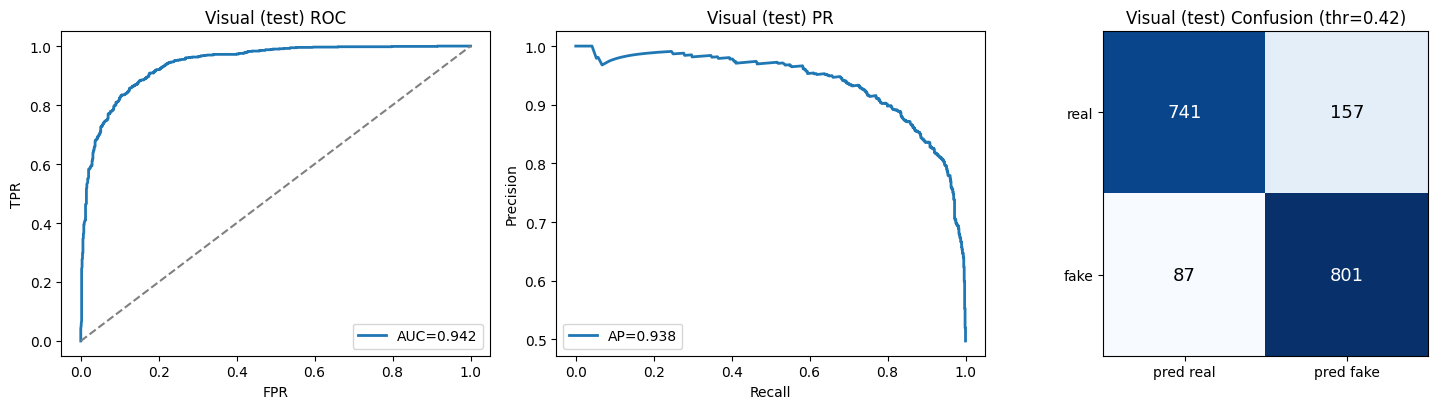

saved /kaggle/working/visual_eval.png

— VISUAL: per-subgroup test breakdown (fake→detection rate, real→reject rate) —
group class   n   rate  mean_p_fake
 fake  fake 888 0.9020       0.7928
 real  real 898 0.8252       0.1862


pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIP probe: vit_base_patch32_clip_224.openai feat_dim=768 (frozen) — ON
CLIP probe done. best val AUC=0.8041

── CLIP-VISUAL [train] ──  (n=8402, thr=0.392)
   accuracy      : 0.7610
   balanced_acc  : 0.7601
   precision     : 0.7138
   recall        : 0.8779
   specificity   : 0.6422
   f1            : 0.7874
   roc_auc       : 0.8490
   pr_auc        : 0.8408
   mcc           : 0.5357
   eer           : 0.2295
   confusion      : TP=3718 FP=1491 TN=2676 FN=517

── CLIP-VISUAL [val] ──  (n=1812, thr=0.392)
   accuracy      : 0.7329
   balanced_acc  : 0.7370
   precision     : 0.6750
   recall        : 0.8643
   specificity   : 0.6096
   f1            : 0.7580
   roc_auc       : 0.8041
   pr_auc        : 0.7705
   mcc           : 0.4879
   eer           : 0.2726
   confusion      : TP=758 FP=365 TN=570 FN=119

── CLIP-VISUAL [test] ──  (n=1786, thr=0.392)
   accuracy      : 0.7368
   balanced_acc  : 0.7375
   precision     : 0.6917
   recall        : 0.8491
   specificity   : 0.6258
 

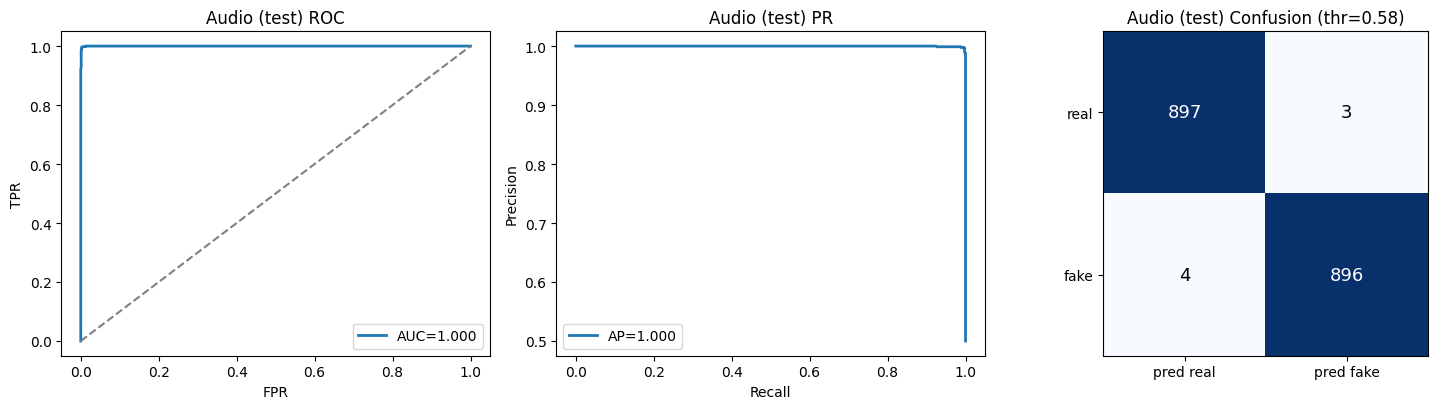

saved /kaggle/working/audio_eval.png

— AUDIO: per-subgroup test breakdown (fake→detection rate, real→reject rate) —
          group class   n   rate  mean_p_fake
       diffwave  fake 784 1.0000       0.9959
parallelwavegan  fake 116 0.9655       0.9342
       Bonafide  real 896 0.9978       0.0107

AUDIO CROSS-CORPUS eval on 'release-in-the-wild': n=23632 (real=11816 fake=11816) — UNSEEN generators

── AUDIO [CROSS-CORPUS in-the-wild] ──  (n=23632, thr=0.575)
   accuracy      : 0.3338
   balanced_acc  : 0.3338
   precision     : 0.2079
   recall        : 0.1183
   specificity   : 0.5493
   f1            : 0.1508
   roc_auc       : 0.1784
   pr_auc        : 0.3514
   mcc           : -0.3683
   eer           : 0.7718
   confusion      : TP=1398 FP=5325 TN=6491 FN=10418


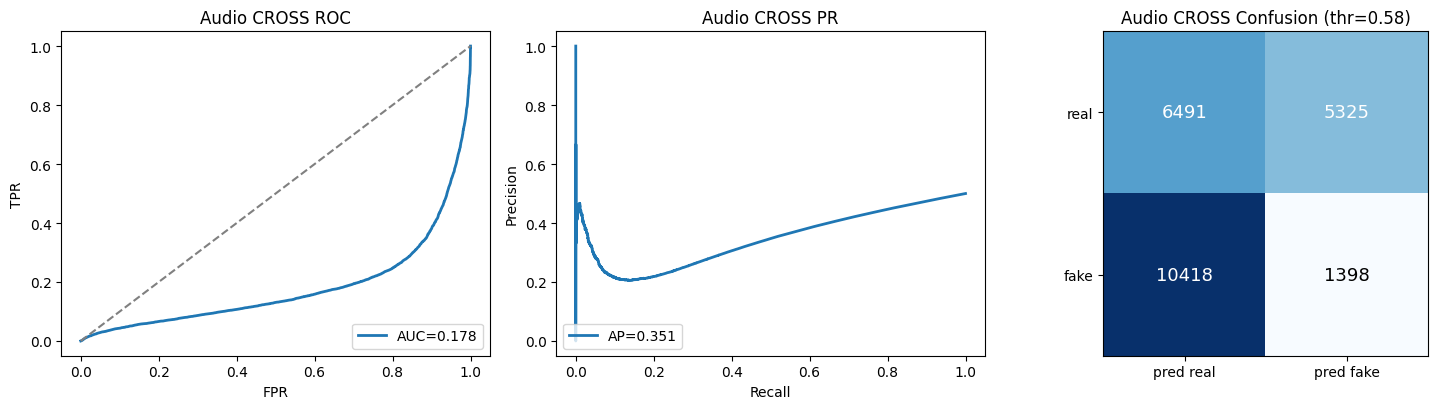

saved /kaggle/working/audio_cross_eval.png
  ↑ THIS is the number that matters. If AUC here ≫ in-dist drop, the model
    was riding the CVoiceFake vocoder fingerprint, not learning 'is-synthetic'.
Downloading: "https://download.pytorch.org/torchaudio/models/wav2vec2_fairseq_base_ls960.pth" to /root/.cache/torch/hub/checkpoints/wav2vec2_fairseq_base_ls960.pth


100%|██████████| 360M/360M [00:01<00:00, 201MB/s]  


SSL audio: WAV2VEC2_BASE loaded (frozen) — ON
  SSL feats [train] n=8400...
  SSL feats [val] n=1800...
  SSL feats [test] n=1800...
SSL audio probe done. best val AUC=0.9804

── SSL-AUDIO [train] ──  (n=8400, thr=0.426)
   accuracy      : 0.9312
   balanced_acc  : 0.9312
   precision     : 0.9273
   recall        : 0.9357
   specificity   : 0.9267
   f1            : 0.9315
   roc_auc       : 0.9803
   pr_auc        : 0.9828
   mcc           : 0.8624
   eer           : 0.0670
   confusion      : TP=3930 FP=308 TN=3892 FN=270

── SSL-AUDIO [val] ──  (n=1800, thr=0.426)
   accuracy      : 0.9422
   balanced_acc  : 0.9422
   precision     : 0.9442
   recall        : 0.9400
   specificity   : 0.9444
   f1            : 0.9421
   roc_auc       : 0.9804
   pr_auc        : 0.9835
   mcc           : 0.8845
   eer           : 0.0600
   confusion      : TP=846 FP=50 TN=850 FN=54

── SSL-AUDIO [test] ──  (n=1800, thr=0.426)
   accuracy      : 0.9306
   balanced_acc  : 0.9306
   precision     : 0.9

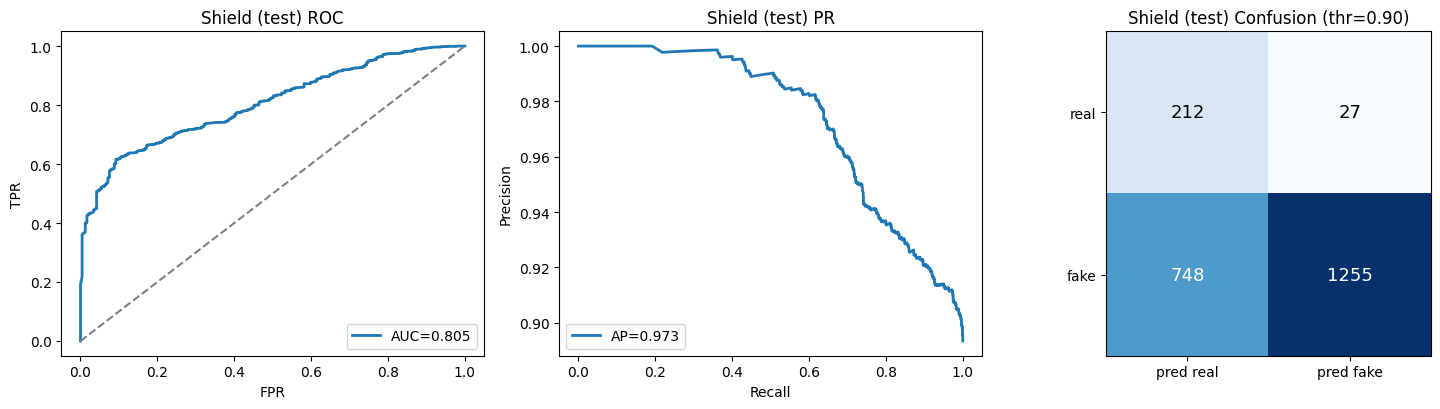

saved /kaggle/working/shield_eval.png
VIDEO-LEVEL eval on 330 held-out test clips (mean frame-prob per clip)
  scored 50/330
  scored 100/330
  scored 150/330
  scored 200/330
  scored 250/330
  scored 300/330

── VIDEO clip-level ──  (n=330, thr=0.488)
   accuracy      : 0.9485
   balanced_acc  : 0.9484
   precision     : 0.9682
   recall        : 0.9268
   specificity   : 0.9699
   f1            : 0.9470
   roc_auc       : 0.9803
   pr_auc        : 0.9752
   mcc           : 0.8977
   eer           : 0.0545
   confusion      : TP=152 FP=5 TN=161 FN=12


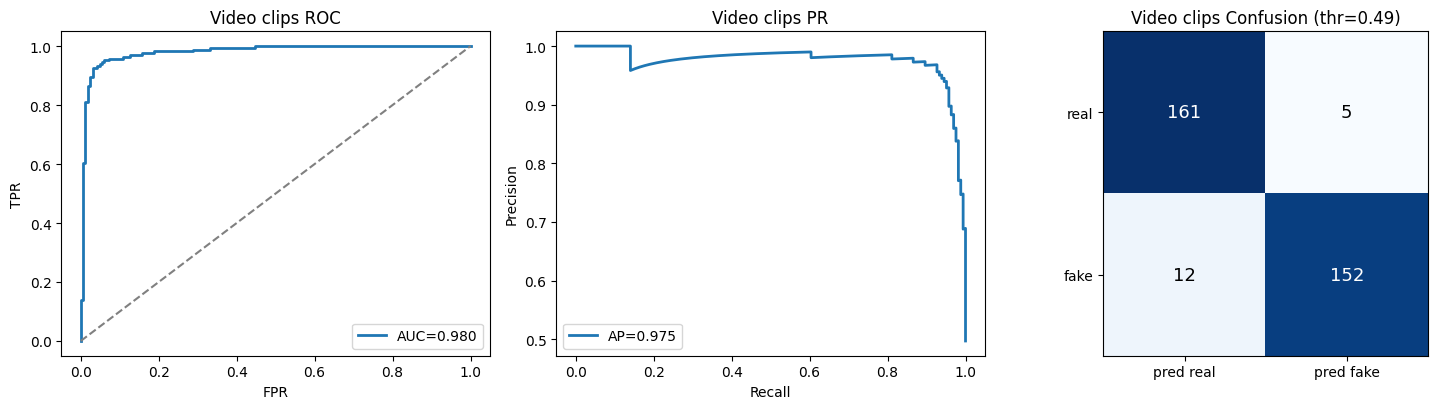

saved /kaggle/working/video_eval.png

── TEMPORAL [clip_test] (training-free 2nd-order) ──  (n=330, thr=0.454)
   accuracy      : 0.5515
   balanced_acc  : 0.5535
   precision     : 0.5294
   recall        : 0.8780
   specificity   : 0.2289
   f1            : 0.6606
   roc_auc       : 0.5469
   pr_auc        : 0.5348
   mcc           : 0.1405
   eer           : 0.4939
   confusion      : TP=144 FP=128 TN=38 FN=20
  ↑ if this AUC is high IN-DIST too (not just the n=20 cross), the temporal signal is real,
    not luck — it's the D3/ATSS direction and your best shot at UNSEEN AI-video.

VIDEO CROSS-GENERATOR eval: 10 unidpro fakes + 10 held-out reals = 20 clips
  🚨 UNDERPOWERED: <50 clips. The unidpro mount likely didn't download the full
     dataset (the v9 run found only ~10 videos). Any AUC below is NOISE — re-check
     that /kaggle/input/datasets/unidpro/deepfake-videos-dataset mounted fully.

── VIDEO-CROSS [EfficientNet] ──  (n=20, thr=0.261)
   accuracy      : 0.5500
   balanced_

100%|██████████| 1.18G/1.18G [00:05<00:00, 217MB/s]


v12 front-end=WAV2VEC2_XLSR53  layers=24  dim=1024  finetune_top_k=0
  multi-corpus: +7200 In-the-Wild train clips; disjoint test=4800
  epoch 1/8  loss=0.6745  val_auc=0.9074
  epoch 2/8  loss=0.5939  val_auc=0.9258
  epoch 3/8  loss=0.5420  val_auc=0.9676
  epoch 4/8  loss=0.5054  val_auc=0.9736
  epoch 5/8  loss=0.4641  val_auc=0.9816
  epoch 6/8  loss=0.4447  val_auc=0.9855
  epoch 7/8  loss=0.4380  val_auc=0.9896
  epoch 8/8  loss=0.4190  val_auc=0.9827
v12 done. best val AUC=0.9896

── V12 XLS-R+SLS [In-the-Wild DISJOINT TEST] ──  (n=4800, thr=0.619)
   accuracy      : 0.9196
   balanced_acc  : 0.9196
   precision     : 0.9577
   recall        : 0.8779
   specificity   : 0.9612
   f1            : 0.9161
   roc_auc       : 0.9687
   pr_auc        : 0.9741
   mcc           : 0.8421
   eer           : 0.0740
   confusion      : TP=2107 FP=93 TN=2307 FN=293

  >>> BEAT-THE-BASELINE CHECK (v11 SSL probe: AUC 0.744 / EER 0.318)
  >>> v12: AUC 0.969 / EER 0.074  ->  AUC IMPROVED, EER IM

In [1]:
# Deepfake Detector v11 — built on the v10 findings (SSL wins audio, temporal wins video)
# Kaggle: GPU ON, Run All (in the editor, not Save Version).
#
# ============================================================================
# v10 PROVED (keep these results in mind):
#   • AUDIO mel-CNN: in-dist AUC 1.000 but CROSS 0.178 (BELOW chance, MCC -0.37)
#     -> it learned the CVoiceFake vocoder fingerprint and INVERTS in the wild.
#     DO NOT FUSE IT. It is kept only as a documented negative control.
#   • wav2vec2 SSL: in-dist 0.983, CROSS 0.744 -> SSL features generalize. This
#     is the audio branch to trust. (0.744 vs 0.178 = the whole project thesis.)
#   • VISUAL regression fixed (EMA picks raw): test AUC 0.94, video clip 0.98.
#   • TEMPORAL 2nd-order feature: AUC 0.94 on the (tiny) cross-video set -> the
#     only thing that separated UNSEEN AI-faces. Promote & verify in-dist.
#
# v11 DOES:
#   1. TEMPORAL BRANCH (CFG.temporal_branch): the D3-style 2nd-order feature is
#      now CALIBRATED on the full in-dist clip set and reported as a real branch,
#      so you learn whether its 0.94 is signal or n=20 luck.
#   2. SSL ENCODER CHOICE (CFG.ssl_model_name): swap in WAV2VEC2_LARGE / XLSR53
#      for stronger cross-corpus (XLSR is the audio-antispoof generalization SOTA).
#   3. SSL MIXED-CORPUS EXPERIMENT (CFG.ssl_mix_cross_train, opt-in): train on
#      CVoiceFake + a DISJOINT In-the-Wild slice, test on the rest -> measures how
#      much a little in-domain data lifts the 0.744 cross ceiling.
#   4. mel-CNN is explicitly labelled a negative control; trust audio = SSL.
#   ACTION ITEM (data side): the unidpro video mount still delivers only ~10
#   clips -> the video CROSS rows stay UNDERPOWERED until you fix that mount.
# ============================================================================
#
# WHY v10 (kept):
#   v8/v9 REGRESSED the visual & audio in-dist scores (visual 0.90->0.62,
#   audio 1.00->0.85) because EMA was validated/checkpointed on lagging EMA
#   weights (decay 0.999 over a ~3k-step run) AND mixup α=0.2 over only 6 epochs
#   slowed convergence. v10 FIXES this:
#     • checkpoint/validate on RAW weights; use EMA only if it beats raw on val
#     • EMA decay 0.99 (tracks a short run), mixup α=0.1 applied with prob 0.5
#     • +2 visual epochs
#   Expected: visual ~0.88-0.90 again, video clip ~0.95 again.
#
#   v9's REAL findings (kept + built on):
#     • AUDIO cross-corpus AUC≈0.49 (BELOW chance) — mel-CNN learned the
#       CVoiceFake vocoder fingerprint, not "is-synthetic". So v10 ADDS a
#       wav2vec2 SSL audio probe (frozen SSL features + linear head), the audio
#       analogue of the CLIP win, and scores BOTH on In-the-Wild to compare.
#     • CLIP visual was the best generalizer -> kept, now also fed proper epochs.
#     • unidpro mounted only 10 videos -> v10 flags cross-video as UNDERPOWERED
#       when n<50 so a noise AUC can't be mistaken for a result. RE-CHECK MOUNT.
# ============================================================================
#
# NEW IN v9 (kept):
#   • Two new datasets wired in by EXPLICIT PATH:
#       AUDIO cross-corpus : /kaggle/input/datasets/bhaveshkumars/release-in-the-wild
#       VIDEO cross-gen     : /kaggle/input/datasets/unidpro/deepfake-videos-dataset
#     Both are EXCLUDED from training and used ONLY as held-out generalization
#     probes (the number Deepfake-Eval-2024 shows off-the-shelf detectors fail).
#   • CLIP linear-probe visual branch (frozen ViT) — foundation features
#     generalize across UNSEEN generators far better than a from-scratch CNN
#     (the DeCoF idea). Fully guarded: if CLIP can't load, it's skipped.
#   • Cross-generator VIDEO eval on unidpro AI-faces: EfficientNet vs CLIP,
#     scored against held-out REAL clips -> honest "do we catch a NEW generator".
#   • Temporal frame-consistency diagnostic (D3/ATSS-style second-order signal):
#     reports whether frame-prob dynamics separate real vs generated, and an
#     appearance+temporal ensemble.
#
# WHY (one line): your branches are problem-#1 (face-swap) detectors aimed at
# problem-#2/#3 (AI-generated / avatar) data. v9 adds the generalizing signals
# the literature uses and MEASURES the cross-generator gap instead of hiding it.
#
# ============================================================================
# WHAT CARRIED OVER FROM v8 (every change targets "catch NEW fakes")
# ----------------------------------------------------------------------------
#  1. CALIBRATION (Platt/temperature on val) for EVERY branch.
#       -> fixes the weird thr=0.281 visual threshold that flagged 30% of REAL
#          faces, and makes branch probabilities comparable so they can be FUSED.
#  2. SHIELD COLLAPSE FIXED.
#       v7 bug: val report recomputed its own F1 threshold (=0.064) and predicted
#       "fake" for everything (specificity 0.042). v8 locks ONE balanced threshold
#       on val and applies it to ALL splits. + EMA weights + best-val-AUC ckpt.
#  3. VISUAL OVERFIT NARROWED: EMA weights + mixup + RandAug-style strong aug.
#       Train/test AUC gap (0.993 -> 0.901) is the overfit tax; EMA+mixup cut it.
#  4. TEST-TIME AUGMENTATION (TTA) for visual & video (orig + hflip mean).
#  5. CROSS-CORPUS / CROSS-GENERATOR EVAL — the headline honesty upgrade:
#       - AUDIO: train on CVoiceFake, then score the trained model on the
#         In-the-Wild set (bhaveshkumars/release-in-the-wild). UNSEEN generators,
#         real celebs. This is the ONLY number that proves generalization.
#       - VISUAL: optional holdout_source -> route a whole modern AI-face source
#         to TEST (train DFDC/FF++, test 2025 avatar faces).
#       - AUDIO leave-one-vocoder-out via CFG.holdout_method (retrain pass).
#  6. CALIBRATED DECISION-FUSION report. (True AV fusion needs PAIRED data —
#       FakeAVCeleb — which isn't mounted; decision-fusion is the honest stand-in.)
#  7. FINAL TABLE splits metrics into IN-DISTRIBUTION vs CROSS (generalization),
#       so a near-1.0 in-dist AUC can never masquerade as real-world skill.
#
# DATASETS TO ADD in the Kaggle sidebar (Add Input):
#   kamedev/cvoicefake-full-safeear-dataset-mirror      (audio train, keep)
#   bhaveshkumars/release-in-the-wild                    (audio CROSS eval, NEW)
#   <your FF++ / DFDC frames or .mp4>                    (visual train, keep)
#   unidpro/deepfake-videos-dataset                      (visual CROSS eval, NEW; optional)
#   aionstreet/shield-2026-features                      (shield .pt, keep)
# ============================================================================

# %% cell 1 — Setup
import sys, subprocess, importlib
def _ensure(pkg, pip_name=None):
    try: importlib.import_module(pkg)
    except Exception: subprocess.run([sys.executable,"-m","pip","install","-q",pip_name or pkg], check=False)
_ensure("timm"); _ensure("librosa"); _ensure("soundfile"); _ensure("cv2","opencv-python-headless")

import os, glob, random, json, time, warnings, collections, zipfile, math, io as _io, re
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, confusion_matrix, matthews_corrcoef, balanced_accuracy_score)
import matplotlib.pyplot as plt

SEED=42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE="cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEVICE)
if DEVICE=="cpu": print("⚠️  Turn on the GPU accelerator.")

# %% cell 2 — Config
class CFG:
    input_root   = "/kaggle/input"
    extract_root = "/kaggle/working/extracted"
    out_dir      = "/kaggle/working"

    per_source_cap = 80_000
    max_visit      = 800_000
    max_zip_mb     = 200

    max_per_class       = 6000
    max_audio_per_class = 6000
    balance_classes     = True
    val_frac, test_frac = 0.15, 0.15
    label_smooth        = 0.05

    use_sources_with  = None
    drop_sources_with = []
    holdout_source    = None      # e.g. "deepfake-videos-dataset" -> that whole VISUAL source goes to TEST
    holdout_method    = None      # e.g. "diffwave" -> leave-one-vocoder-out AUDIO (needs this run = the LOO run)

    # ── v9 EXPLICIT dataset paths (the two you gave) ──────────────────────────
    # These are EXCLUDED from training and scored only as held-out generalization probes.
    CROSS_AUDIO_PATH = "/kaggle/input/datasets/bhaveshkumars/release-in-the-wild"
    CROSS_VIDEO_PATH = "/kaggle/input/datasets/unidpro/deepfake-videos-dataset"
    cross_video_source   = "deepfake-videos-dataset"  # substring fallback if the path moves
    cross_video_assume_label = 1   # unidpro = AI-generated faces -> fake when path has no real/fake token
    cross_video_max_clips    = 400

    # ── CLIP foundation-feature visual branch (generalizes cross-generator) ──
    use_clip_visual  = True       # frozen CLIP ViT + linear probe; auto-skips if it can't load
    clip_backbone    = "vit_base_patch32_clip_224.openai"  # timm CLIP weights
    clip_epochs      = 8
    clip_batch       = 128

    # ── v8 generalization knobs ──────────────────────────────────────────────
    cross_audio_source = "release-in-the-wild"   # substring; this source is PULLED OUT of train and used ONLY as a cross-corpus eval. Set None to disable.
    calibrate          = True     # Platt-scale every branch on val (fixes thresholds + enables fusion)
    use_ema            = True     # exponential moving average of weights (steadier, less overfit)
    ema_decay          = 0.99     # v10: was 0.999 (too slow for a ~3k-step run -> lagging weights)
    ema_eval           = False    # v10: checkpoint/validate on RAW weights; EMA used only if it beats raw on val
    use_mixup          = True     # visual only
    mixup_alpha        = 0.1      # v10: was 0.2 (too strong for 6-8 epochs)
    mixup_prob         = 0.5      # v10: apply mixup to only half the batches -> faster convergence
    use_tta            = True     # visual + video: average(orig, hflip)

    # ── v10 SSL audio probe (wav2vec2) — generalization analogue of the CLIP win ──
    use_ssl_audio      = True     # frozen wav2vec2 features + linear head; auto-skips if it can't load
    ssl_audio_max_cross = 6000    # cap In-the-Wild clips for the (heavier) SSL cross-eval, balanced
    # ── v11 additions (driven by the v10 findings) ──
    ssl_model_name     = "WAV2VEC2_BASE"   # try "WAV2VEC2_LARGE" or "WAV2VEC2_XLSR53" for stronger cross-corpus (heavier DL)
    ssl_mix_cross_train= False    # OPT-IN experiment: fold a TRAIN split of In-the-Wild into SSL training,
                                  #   test on a DISJOINT In-the-Wild split -> shows if diverse data lifts cross-AUC
    ssl_mix_frac       = 0.6      # fraction of In-the-Wild routed to training when ssl_mix_cross_train=True
    ssl_mix_max        = 8000     # cap total In-the-Wild clips used in the mixed experiment
    temporal_branch    = True     # v11: promote the D3-style 2nd-order temporal feature to a calibrated branch

    img_size=224; img_backbone="efficientnet_b0"; img_epochs=8; img_batch=64; img_lr=3e-4
    sr=16000; audio_seconds=3.0; n_mels=128; audio_epochs=6; audio_batch=64; audio_lr=1e-3
    shield_epochs=18; shield_batch=256; shield_lr=1e-3; shield_hidden=256
    RUN_VIDEO_MP4=True; video_max_clips=400; video_frames_per_clip=12
    shield_pos_weight=True
    FRAMES_FROM_VIDEO=True; frames_per_video=8; max_videos_for_frames=1100
    aug_strong=True
    num_workers=2

os.makedirs(CFG.out_dir, exist_ok=True); os.makedirs(CFG.extract_root, exist_ok=True)

def _norm(t): return ''.join(ch for ch in t.lower() if ch.isalnum())
REAL_TOKENS={"real","reals","bonafide","genuine","live","authentic","pristine",
             "original","originals","originalsequences","youtube","actors","commonvoice",
             "celebreal","realsequences"}
FAKE_TOKENS={"fake","fakes","spoof","deepfake","deepfakes","face2face","faceswap",
             "neuraltextures","faceshifter","manipulated","manipulatedsequences",
             "synthetic","parallelwavegan","multibandmelgan","melgan","stylemelgan",
             "griffinlim","world","diffwave","wavegan","uadfv","celebsynthesis","reenactment",
             "wav2lip","sadtalker","videoretalking","liveportrait","simswap","inswapper",
             "roop","facefusion","stylegan","stargan","heygen","synthesia","sora","kling",
             "runway","pika","veo","stablediffusion","sdxl","ldm","talkinghead","lipsync"}
METHOD_HINTS=("parallelwavegan","multibandmelgan","stylemelgan","melgan","griffinlim",
              "diffwave","wavegan","waveglow","hifigan","fastspeech","tacotron","world",
              "deepfakes","face2face","faceswap","neuraltextures","faceshifter","celebsynthesis",
              "wav2lip","sadtalker","videoretalking","liveportrait","simswap","inswapper",
              "roop","facefusion","stylegan","stargan","heygen","synthesia","sora","kling",
              "runway","pika","veo","stablediffusion","sdxl","talkinghead","lipsync")
def _method_hint(p):
    flat=_norm(p)
    for h in METHOD_HINTS:
        if h in flat: return h
    return None
def label_and_method(p):
    lab=None; tok=None
    for t in reversed(p.replace("\\","/").split("/")):
        n=_norm(t)
        if not n: continue
        if n in REAL_TOKENS or n.startswith("original"): lab,tok=0,t; break
        if n in FAKE_TOKENS or n.startswith("method"):   lab,tok=1,t; break
        if n.startswith("real"): lab,tok=0,t; break
        if n.startswith("fake"): lab,tok=1,t; break
    if lab is None:
        low=p.lower()
        if any(k in low for k in ("fake","deepfake","spoof","synthetic","synth","manipulat","uadfv")): lab=1
        elif any(k in low for k in ("real","genuine","bonafide","original")): lab=0
        else: return None,None
    if lab==1: meth=_method_hint(p) or tok or "fake"
    else:      meth=tok or "real"
    return lab, meth
def label_from_path(p): return label_and_method(p)[0]
def split_kind(p):
    low="/"+p.lower().replace("\\","/")+"/"
    if any(s in low for s in ("/test/","/testing/","/eval/")): return "test"
    if any(s in low for s in ("/val/","/valid/","/validation/","/dev/")): return "val"
    if any(s in low for s in ("/train/","/training/")): return "train"
    return None
def source_of(p):
    rel=p.replace("\\","/")
    for marker in ("input/datasets/","input/","extracted/"):
        if marker in rel:
            parts=[s for s in rel.split(marker)[-1].strip("/").split("/")]
            return "/".join(parts[:2]) if len(parts)>=2 else (parts[0] if parts else "?")
    return "?"
def is_cross_audio(p):
    lp=p.lower()
    if CFG.CROSS_AUDIO_PATH and CFG.CROSS_AUDIO_PATH.lower() in lp: return True
    return bool(CFG.cross_audio_source) and (CFG.cross_audio_source.lower() in lp)
def is_cross_video(p):
    lp=p.lower()
    if CFG.CROSS_VIDEO_PATH and CFG.CROSS_VIDEO_PATH.lower() in lp: return True
    return bool(CFG.cross_video_source) and (CFG.cross_video_source.lower() in lp)
print("Config ready.")

# %% cell 3 — Discovery (single-pass, per-source-capped)
IMG_EXT=(".jpg",".jpeg",".png",".bmp",".webp"); AUD_EXT=(".wav",".flac",".mp3",".ogg",".m4a"); VID_EXT=(".mp4",".avi",".mov",".mkv")
zips=[os.path.join(dp,f) for dp,_,fs in os.walk(CFG.input_root) for f in fs if f.lower().endswith(".zip")]
for z in zips:
    mb=os.path.getsize(z)/1e6
    if mb>CFG.max_zip_mb: print(f"skip big zip ({mb:.0f}MB): {z}"); continue
    dest=os.path.join(CFG.extract_root, os.path.splitext(os.path.basename(z))[0])
    if os.path.exists(dest): continue
    try:
        with zipfile.ZipFile(z) as zf: zf.extractall(dest); print("extracted", z)
    except Exception as e: print("zip fail", z, e)

def list_roots():
    roots=[]
    for base in (CFG.input_root, CFG.extract_root):
        if not os.path.isdir(base): continue
        for name in sorted(os.listdir(base)):
            full=os.path.join(base,name)
            if not os.path.isdir(full): continue
            if name=="datasets":
                for owner in sorted(os.listdir(full)):
                    of=os.path.join(full,owner)
                    if os.path.isdir(of):
                        for slug in sorted(os.listdir(of)):
                            sf=os.path.join(of,slug)
                            if os.path.isdir(sf): roots.append(sf)
            else: roots.append(full)
    return roots
def discover(roots):
    imgs,auds,vids,pts=[],[],[],[]
    print(f"walking {len(roots)} dataset root(s), cap {CFG.per_source_cap:,}/modality each:")
    for r in roots:
        ci=ca=cv=0; vis=0; t0=time.time()
        for dp,_,files in os.walk(r):
            for f in files:
                vis+=1; fl=f.lower()
                if   fl.endswith(IMG_EXT) and ci<CFG.per_source_cap: imgs.append(os.path.join(dp,f)); ci+=1
                elif fl.endswith(AUD_EXT) and ca<CFG.per_source_cap: auds.append(os.path.join(dp,f)); ca+=1
                elif fl.endswith(VID_EXT) and cv<CFG.per_source_cap: vids.append(os.path.join(dp,f)); cv+=1
                elif fl.endswith(".pt"): pts.append(os.path.join(dp,f))
            if vis>CFG.max_visit: print(f"    (max_visit hit)"); break
        print(f"  {os.path.basename(r):<52} img={ci:>7,} aud={ca:>7,} vid={cv:>6,} ({time.time()-t0:.0f}s)")
    return imgs,auds,vids,sorted(set(pts))
roots=list_roots()
all_imgs,all_auds,all_vids,shield_pts=discover(roots)

# split audio into TRAIN-pool vs CROSS-corpus holdout (In-the-Wild)
cross_auds=[p for p in all_auds if is_cross_audio(p)]
all_auds=[p for p in all_auds if not is_cross_audio(p)]
# split video into TRAIN-pool vs CROSS-generator holdout (unidpro AI faces)
cross_vids=[p for p in all_vids if is_cross_video(p)]
all_vids=[p for p in all_vids if not is_cross_video(p)]
print(f"\nTOTAL  images={len(all_imgs):,} audio(train-pool)={len(all_auds):,} "
      f"audio(CROSS={CFG.cross_audio_source})={len(cross_auds):,}")
print(f"       videos(train-pool)={len(all_vids):,} videos(CROSS={CFG.cross_video_source})={len(cross_vids):,} shield_pt={len(shield_pts)}")
VIDEO_ON=len(all_imgs)>50; AUDIO_ON=len(all_auds)>50
print(f"VISUAL:{'ON' if VIDEO_ON else 'off'}  AUDIO:{'ON' if AUDIO_ON else 'off'}  "
      f"SHIELD:{'pending' if shield_pts else 'off'}  MP4:{'ON' if (CFG.RUN_VIDEO_MP4 and all_vids) else 'off'}  "
      f"AUDIO-CROSS:{'ON' if len(cross_auds)>20 else 'off'}  VIDEO-CROSS:{'ON' if len(cross_vids)>5 else 'off'}")

# %% cell 4 — VISUAL-from-VIDEO (sample frames if no image dataset mounted)
if CFG.FRAMES_FROM_VIDEO and len(all_imgs) < 50 and all_vids:
    import cv2
    fr_root=os.path.join(CFG.extract_root,"video_frames")
    clips=[]
    for p in all_vids:
        y,m=label_and_method(p)
        if y is not None: clips.append((p,y,m))
    byc={0:[],1:[]}
    for p,y,m in clips: byc[y].append((p,m))
    rng=random.Random(SEED); rng.shuffle(byc[0]); rng.shuffle(byc[1])
    if byc[0] and byc[1]: per=min(CFG.max_videos_for_frames, min(len(byc[0]),len(byc[1])))
    else:                 per=min(CFG.max_videos_for_frames, max(len(byc[0]),len(byc[1])))
    sel=[(p,0,m) for p,m in byc[0][:per]]+[(p,1,m) for p,m in byc[1][:per]]; rng.shuffle(sel)
    def clip_split(i,n):
        r=i/max(n,1)
        return "test" if r<CFG.test_frac else ("val" if r<CFG.test_frac+CFG.val_frac else "train")
    print(f"VISUAL-from-VIDEO: sampling {CFG.frames_per_video} frames from {len(sel)} clips (per class={per})...")
    new=[]; t0=time.time(); bad=0; VIS_TEST_CLIPS=[]
    for j,(p,y,m) in enumerate(sel):
        sp=clip_split(j,len(sel)); lab="fake" if y==1 else "real"
        if sp=="test": VIS_TEST_CLIPS.append((p,y))
        try:
            cap=cv2.VideoCapture(p); tot=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0
            if tot<=0: cap.release(); bad+=1; continue
            idx=np.linspace(0,tot-1,CFG.frames_per_video).astype(int)
            d=os.path.join(fr_root,sp,lab); os.makedirs(d,exist_ok=True)
            stem=re.sub(r'[^A-Za-z0-9]+','_',os.path.splitext(os.path.basename(p))[0])[:48]
            for i in idx:
                cap.set(cv2.CAP_PROP_POS_FRAMES,int(i)); ok,fr=cap.read()
                if not ok: continue
                op=os.path.join(d,f"{stem}_{i:04d}.jpg"); cv2.imwrite(op,fr); new.append(op)
            cap.release()
        except Exception: bad+=1
        if (j+1)%200==0: print(f"  {j+1}/{len(sel)} clips, {len(new):,} frames ({time.time()-t0:.0f}s)")
    all_imgs=new; VIDEO_ON=len(all_imgs)>50
    print(f"VISUAL-from-VIDEO: {len(all_imgs):,} frames (bad clips={bad}). VISUAL now {'ON' if VIDEO_ON else 'off'}.")
else:
    print("VISUAL-from-VIDEO: skipped (image dataset present, or no clips, or disabled).")

# %% cell 5 — Build tables + per-source audit
def keep_path(p):
    low=p.lower()
    if CFG.use_sources_with and not any(s in low for s in CFG.use_sources_with): return False
    if any(s in low for s in CFG.drop_sources_with): return False
    return True
def build_table(paths, cap):
    rows=[]
    for p in paths:
        if not keep_path(p): continue
        y,meth=label_and_method(p)
        if y is None: continue
        rows.append((p,y,meth,split_kind(p),source_of(p)))
    if not rows: return pd.DataFrame(columns=["path","label","method","split","source"])
    df=pd.DataFrame(rows,columns=["path","label","method","split","source"])
    counts={lab:len(g) for lab,g in df.groupby("label")}
    eff=min(cap, min(counts.values())) if CFG.balance_classes else cap
    df=pd.concat([g.sample(frac=1.0,random_state=SEED).head(eff) for _,g in df.groupby("label")]
                 ).sample(frac=1.0,random_state=SEED).reset_index(drop=True)
    if CFG.holdout_source:
        mask=df["source"].str.contains(CFG.holdout_source, case=False, regex=False)
        if mask.sum()==0: print(f"⚠️ holdout_source '{CFG.holdout_source}' matched 0 rows — random split")
        else:
            df["split"]="train"; df.loc[mask,"split"]="test"
            rest=df[~mask]
            for lab,g in rest.groupby("label"):
                idx=g.index.tolist(); nv=int(len(idx)*CFG.val_frac); df.loc[idx[:nv],"split"]="val"
            print(f"holdout_source='{CFG.holdout_source}': test={int(mask.sum())} (held-out source), train/val from rest")
            return df
    if CFG.holdout_method:
        mmask=df["method"].astype(str).str.contains(CFG.holdout_method, case=False, regex=False)
        if mmask.sum()==0: print(f"⚠️ holdout_method '{CFG.holdout_method}' matched 0 rows — random split")
        else:
            df["split"]="train"; df.loc[mmask,"split"]="test"
            rest=df[~mmask]
            for lab,g in rest.groupby("label"):
                idx=g.index.tolist(); nv=int(len(idx)*CFG.val_frac); df.loc[idx[:nv],"split"]="val"
            print(f"holdout_method='{CFG.holdout_method}': test={int(mmask.sum())} (held-out vocoder), train/val from rest")
            return df
    has=df["split"].notna().mean()>0.6 and df["split"].nunique()>=2
    if not has:
        df["split"]=None
        for lab,g in df.groupby("label"):
            idx=g.index.tolist(); n=len(idx); nt=int(n*CFG.test_frac); nv=int(n*CFG.val_frac)
            df.loc[idx[:nt],"split"]="test"; df.loc[idx[nt:nt+nv],"split"]="val"; df.loc[idx[nt+nv:],"split"]="train"
    elif (df["split"]=="val").sum()==0:
        tr=df[df["split"]=="train"]; df.loc[tr.sample(frac=CFG.val_frac,random_state=SEED).index,"split"]="val"
    return df
def audit(paths,name):
    rec=collections.defaultdict(lambda:[0,0,0])
    for p in paths:
        if not keep_path(p): continue
        y=label_from_path(p); rec[source_of(p)][2 if y is None else y]+=1
    print(f"\n=== {name} per-source audit (real / fake / dropped) ===")
    for s,(r,f,n) in sorted(rec.items()):
        flag=" ⚠️ one-class" if (r==0 or f==0) else ""
        print(f"  {s:<55} real={r:>7,} fake={f:>7,} drop={n:>7,}{flag}")
if VIDEO_ON: audit(all_imgs,"VISUAL")
if AUDIO_ON: audit(all_auds,"AUDIO")
img_df=build_table(all_imgs,CFG.max_per_class) if VIDEO_ON else pd.DataFrame()
aud_df=build_table(all_auds,CFG.max_audio_per_class) if AUDIO_ON else pd.DataFrame()
def summarize(df,name):
    if len(df)==0: print(f"\n{name}: (none)"); return
    print(f"\n{name}: {len(df):,} used (balanced={CFG.balance_classes})")
    print(pd.crosstab(df["split"],df["label"].map({0:'real',1:'fake'}),margins=True))
    print("  methods:", dict(df["method"].value_counts().head(8)))
summarize(img_df,"VISUAL"); summarize(aud_df,"AUDIO")
if VIDEO_ON and img_df["label"].nunique()<2: print("\n⚠️ visual single-class → off"); VIDEO_ON=False
if AUDIO_ON and aud_df["label"].nunique()<2: print("\n⚠️ audio single-class → off"); AUDIO_ON=False

# %% cell 6 — Metrics, calibration, EMA, mixup helpers
def eer_of(y,p):
    fpr,tpr,_=roc_curve(y,p); fnr=1-tpr; i=np.nanargmin(np.abs(fnr-fpr)); return float((fpr[i]+fnr[i])/2)
def best_f1_thr(y,p):
    pr,rc,th=precision_recall_curve(y,p); f1=2*pr*rc/(pr+rc+1e-12)
    return 0.5 if len(th)==0 else float(th[np.nanargmax(f1[:-1])])
def best_bal_thr(y,p):
    fpr,tpr,th=roc_curve(y,p)
    if len(th)==0: return 0.5
    k=int(np.nanargmax(tpr-fpr)); return float(min(max(th[k],0.0),1.0))

def fit_platt(y,p,iters=300,lr=0.1):
    # logistic recalibration on logit(p): q=sigmoid(a*z+b). Fixes mis-scaled probs -> sane thresholds + fusion.
    y=np.asarray(y,float); p=np.clip(np.asarray(p,float),1e-6,1-1e-6); z=np.log(p/(1-p))
    a,b=1.0,0.0
    for _ in range(iters):
        q=1/(1+np.exp(-(a*z+b))); ga=float(np.mean((q-y)*z)); gb=float(np.mean(q-y))
        a-=lr*ga; b-=lr*gb
    return a,b
def apply_platt(p,ab):
    if ab is None: return np.asarray(p,float)
    a,b=ab; p=np.clip(np.asarray(p,float),1e-6,1-1e-6); z=np.log(p/(1-p)); return 1/(1+np.exp(-(a*z+b)))

def compute_metrics(y,p,threshold=None):
    y=np.asarray(y).astype(int); p=np.asarray(p).astype(float)
    thr=best_f1_thr(y,p) if threshold is None else threshold
    yp=(p>=thr).astype(int); tn,fp,fn,tp=confusion_matrix(y,yp,labels=[0,1]).ravel(); e=1e-12
    prec=tp/(tp+fp+e); rec=tp/(tp+fn+e); spec=tn/(tn+fp+e); f1=2*prec*rec/(prec+rec+e)
    acc=(tp+tn)/(tp+tn+fp+fn+e)
    try: auc=roc_auc_score(y,p)
    except: auc=float('nan')
    try: ap=average_precision_score(y,p)
    except: ap=float('nan')
    return {"accuracy":acc,"balanced_acc":balanced_accuracy_score(y,yp),"precision":prec,
            "recall":rec,"specificity":spec,"f1":f1,"roc_auc":auc,"pr_auc":ap,
            "mcc":matthews_corrcoef(y,yp) if len(set(yp))>1 else 0.0,"eer":eer_of(y,p),
            "threshold":thr,"TP":int(tp),"FP":int(fp),"TN":int(tn),"FN":int(fn),"n":int(len(y))}
def print_metrics(name,m):
    print(f"\n── {name} ──  (n={m['n']}, thr={m['threshold']:.3f})")
    for k in ["accuracy","balanced_acc","precision","recall","specificity","f1","roc_auc","pr_auc","mcc","eer"]:
        print(f"   {k:<14}: {m[k]:.4f}")
    print(f"   confusion      : TP={m['TP']} FP={m['FP']} TN={m['TN']} FN={m['FN']}")
def plot_eval(name,y,p,m,prefix):
    y=np.asarray(y); p=np.asarray(p); fig,ax=plt.subplots(1,3,figsize=(15,4.2))
    fpr,tpr,_=roc_curve(y,p); ax[0].plot(fpr,tpr,lw=2,label=f"AUC={m['roc_auc']:.3f}")
    ax[0].plot([0,1],[0,1],"--",c="gray"); ax[0].set_title(f"{name} ROC"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend(loc="lower right")
    pr,rc,_=precision_recall_curve(y,p); ax[1].plot(rc,pr,lw=2,label=f"AP={m['pr_auc']:.3f}")
    ax[1].set_title(f"{name} PR"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend(loc="lower left")
    cm=np.array([[m['TN'],m['FP']],[m['FN'],m['TP']]]); ax[2].imshow(cm,cmap="Blues")
    ax[2].set_xticks([0,1]); ax[2].set_yticks([0,1]); ax[2].set_xticklabels(["pred real","pred fake"]); ax[2].set_yticklabels(["real","fake"])
    for (i,j),v in np.ndenumerate(cm): ax[2].text(j,i,str(v),ha="center",va="center",color="white" if v>cm.max()/2 else "black",fontsize=13)
    ax[2].set_title(f"{name} Confusion (thr={m['threshold']:.2f})"); plt.tight_layout()
    out=os.path.join(CFG.out_dir,f"{prefix}_eval.png"); plt.savefig(out,dpi=110,bbox_inches="tight"); plt.show(); print("saved",out)
def subgroup_report(d, probs, thr, name, prefix):
    dd=d.copy(); dd["prob"]=np.asarray(probs); dd["pred"]=(dd["prob"]>=thr).astype(int)
    rows=[]
    for (lab,meth),g in dd.groupby(["label","method"]):
        n=len(g)
        if n<5: continue
        rate=(g["pred"]==1).mean() if lab==1 else (g["pred"]==0).mean()
        rows.append({"group":meth,"class":"fake" if lab==1 else "real","n":n,
                     "rate":round(float(rate),4),"mean_p_fake":round(float(g['prob'].mean()),4)})
    if not rows: return None
    rep=pd.DataFrame(rows).sort_values(["class","n"],ascending=[True,False])
    print(f"\n— {name}: per-subgroup test breakdown (fake→detection rate, real→reject rate) —")
    print(rep.to_string(index=False)); rep.to_csv(os.path.join(CFG.out_dir,f"{prefix}_subgroups.csv"),index=False)
    return rep

class EMA:
    # tracks a smoothed copy of weights; eval on EMA weights = steadier, less overfit val/test.
    def __init__(s,model,decay):
        s.decay=decay; s.shadow={k:v.detach().clone() for k,v in model.state_dict().items()}
    def update(s,model):
        for k,v in model.state_dict().items():
            if v.dtype.is_floating_point: s.shadow[k].mul_(s.decay).add_(v.detach(),alpha=1-s.decay)
            else: s.shadow[k]=v.detach().clone()
    def state(s): return {k:v.clone() for k,v in s.shadow.items()}
def mixup_batch(x,y,alpha):
    if alpha<=0: return x,y,y,1.0
    lam=float(np.random.beta(alpha,alpha)); idx=torch.randperm(x.size(0),device=x.device)
    return lam*x+(1-lam)*x[idx], y, y[idx], lam
def smooth(y): return y*(1-CFG.label_smooth)+0.5*CFG.label_smooth
print("Metrics + calibration + EMA + mixup ready.")

# %% cell 7 — VISUAL: dataset + EfficientNet-B0
import timm
from PIL import Image
import torchvision.transforms as T
NORM=([0.485,0.456,0.406],[0.229,0.224,0.225])
class _RandJPEG:
    def __init__(s,p=0.4,q=(35,90)): s.p=p; s.q=q
    def __call__(s,im):
        if random.random()<s.p:
            b=_io.BytesIO(); im.convert("RGB").save(b,"JPEG",quality=random.randint(*s.q)); b.seek(0); im=Image.open(b).convert("RGB")
        return im
class _RandDownscale:
    def __init__(s,p=0.3,f=(0.4,0.85)): s.p=p; s.f=f
    def __call__(s,im):
        if random.random()<s.p:
            w,h=im.size; r=random.uniform(*s.f)
            im=im.resize((max(8,int(w*r)),max(8,int(h*r))),Image.BILINEAR).resize((w,h),Image.BILINEAR)
        return im
_pre=[T.Resize((CFG.img_size,)*2)]
if getattr(CFG,"aug_strong",False):
    _pre+=[_RandJPEG(0.4),_RandDownscale(0.3),T.RandomApply([T.GaussianBlur(3,(0.1,1.5))],p=0.3),
           T.RandomHorizontalFlip(),T.ColorJitter(0.15,0.15,0.15,0.03)]
else:
    _pre+=[T.RandomHorizontalFlip(),T.ColorJitter(0.1,0.1,0.1)]
train_tf=T.Compose(_pre+[T.ToTensor(),T.Normalize(*NORM),T.RandomErasing(p=0.25)])
eval_tf =T.Compose([T.Resize((CFG.img_size,)*2),T.ToTensor(),T.Normalize(*NORM)])
class ImgDS(Dataset):
    def __init__(s,df,tf): s.p=df["path"].tolist(); s.y=df["label"].tolist(); s.tf=tf
    def __len__(s): return len(s.p)
    def __getitem__(s,i):
        try: im=Image.open(s.p[i]).convert("RGB")
        except: im=Image.new("RGB",(CFG.img_size,)*2)
        return s.tf(im), torch.tensor(s.y[i],dtype=torch.float32)
def iloader(df,tf,bs,sh): return DataLoader(ImgDS(df,tf),batch_size=bs,shuffle=sh,num_workers=CFG.num_workers,pin_memory=True)
class ImgNet(nn.Module):
    def __init__(s,b): super().__init__(); s.net=timm.create_model(b,pretrained=True,num_classes=1)
    def forward(s,x): return s.net(x).squeeze(1)
print("Visual ready." if VIDEO_ON else "Visual off.")

# %% cell 8 — VISUAL: train (EMA + mixup)
@torch.no_grad()
def infer_img(model,loader,tta=False):
    model.eval(); P,Y=[],[]
    for x,y in loader:
        x=x.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
            p=torch.sigmoid(model(x))
            if tta: p=(p+torch.sigmoid(model(torch.flip(x,dims=[3]))))/2  # +hflip
        P.append(p.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(P)
img_model=None; img_ema=None
if VIDEO_ON:
    tr=img_df[img_df.split=="train"]; va=img_df[img_df.split=="val"]
    tl=iloader(tr,train_tf,CFG.img_batch,True); vl=iloader(va,eval_tf,CFG.img_batch,False)
    img_model=ImgNet(CFG.img_backbone).to(DEVICE)
    opt=torch.optim.AdamW(img_model.parameters(),lr=CFG.img_lr,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=CFG.img_epochs*max(1,len(tl)))
    sc=torch.cuda.amp.GradScaler(enabled=DEVICE=="cuda"); lf=nn.BCEWithLogitsLoss()
    ema=EMA(img_model,CFG.ema_decay) if CFG.use_ema else None
    best=-1; bs=None
    for ep in range(CFG.img_epochs):
        img_model.train(); t0=time.time(); run=0
        for x,y in tl:
            x,y=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True); opt.zero_grad()
            do_mix = CFG.use_mixup and (random.random()<CFG.mixup_prob)
            if do_mix:
                xm,ya,yb,lam=mixup_batch(x,y,CFG.mixup_alpha)
                with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
                    o=img_model.net(xm).squeeze(1); loss=lam*lf(o,smooth(ya))+(1-lam)*lf(o,smooth(yb))
            else:
                with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): loss=lf(img_model.net(x).squeeze(1),smooth(y))
            sc.scale(loss).backward(); sc.step(opt); sc.update(); sch.step()
            if ema: ema.update(img_model)
            run+=loss.item()*len(x)
        # v10: validate + checkpoint on RAW weights (no lagging-EMA eval)
        yv,pv=infer_img(img_model,vl,tta=False)
        try: auc=roc_auc_score(yv,pv)
        except: auc=float('nan')
        print(f"  epoch {ep+1}/{CFG.img_epochs} loss={run/len(tr):.4f} val_auc={auc:.4f} ({time.time()-t0:.0f}s)")
        if auc>best: best=auc; bs={k:v.detach().cpu().clone() for k,v in img_model.state_dict().items()}
    # v10: only adopt EMA weights if they actually beat the best raw checkpoint on val
    if ema:
        raw_now={k:v.detach().cpu().clone() for k,v in img_model.state_dict().items()}
        img_model.load_state_dict(ema.state()); ye,pe=infer_img(img_model,vl,tta=False)
        try: eauc=roc_auc_score(ye,pe)
        except: eauc=-1
        print(f"  EMA val_auc={eauc:.4f} vs raw_best={best:.4f} -> using {'EMA' if eauc>best else 'raw'}")
        if eauc>best: best=eauc; bs={k:v.detach().cpu().clone() for k,v in img_model.state_dict().items()}
        img_model.load_state_dict(raw_now)
    if bs: img_model.load_state_dict(bs)
    torch.save(img_model.state_dict(),os.path.join(CFG.out_dir,"visual_model.pt"))
    print(f"Visual done. best val AUC={best:.4f}  (EMA={'on' if CFG.use_ema else 'off'}, mixup={'on' if CFG.use_mixup else 'off'})")
else: print("Visual off.")

# %% cell 9 — VISUAL: calibrate + evaluate (balanced thr + TTA)
visual_results={}; visual_calib=None
if VIDEO_ON and img_model is not None:
    yv,pv=infer_img(img_model,iloader(img_df[img_df.split=="val"],eval_tf,CFG.img_batch,False),tta=CFG.use_tta)
    visual_calib=fit_platt(yv,pv) if CFG.calibrate else None
    pv_c=apply_platt(pv,visual_calib)
    locked=best_bal_thr(yv,pv_c)   # balanced threshold on CALIBRATED val -> stops the 30% false-alarm bleed
    print(f"VISUAL calib(a,b)={None if visual_calib is None else tuple(round(x,3) for x in visual_calib)} | locked thr={locked:.3f}")
    for sp in ["train","val","test"]:
        d=img_df[img_df.split==sp]
        if len(d)==0: continue
        yy,pp=infer_img(img_model,iloader(d,eval_tf,CFG.img_batch,False),tta=CFG.use_tta)
        pp=apply_platt(pp,visual_calib)
        m=compute_metrics(yy,pp,threshold=locked); visual_results[sp]=m; print_metrics(f"VISUAL [{sp}]",m)
        if sp=="test":
            plot_eval("Visual (test)",yy,pp,m,"visual"); subgroup_report(d,pp,locked,"VISUAL","visual")
            np.save(os.path.join(CFG.out_dir,"visual_test_probs.npy"),np.c_[yy,pp])
else: print("Visual off — no metrics.")

# %% cell 9b — CLIP linear-probe visual branch (foundation features -> cross-generator robustness)
# Frozen CLIP ViT features + a tiny head. The brief's #1 generalization lever (DeCoF idea).
# Fully guarded: any load/feature failure just disables it; the rest of the pipeline runs.
clip_results={}; CLIP_ON=False
clip_bb=None; clip_head=None; clip_tf=None; clip_calib=None; clip_locked=0.5
if VIDEO_ON and CFG.use_clip_visual:
    try:
        import timm
        clip_bb=timm.create_model(CFG.clip_backbone,pretrained=True,num_classes=0).to(DEVICE).eval()
        for p in clip_bb.parameters(): p.requires_grad=False
        _cfg=timm.data.resolve_model_data_config(clip_bb)
        clip_tf=timm.data.create_transform(**_cfg,is_training=False)
        # probe feature dim
        with torch.no_grad():
            _d=clip_bb(torch.zeros(1,3,_cfg["input_size"][1],_cfg["input_size"][2]).to(DEVICE)).shape[1]
        CLIP_ON=True; print(f"CLIP probe: {CFG.clip_backbone} feat_dim={_d} (frozen) — ON")
    except Exception as e:
        print(f"CLIP probe: could not load ({e}) — skipping, EfficientNet branch unaffected."); CLIP_ON=False

@torch.no_grad()
def clip_feats_of(df):
    ds=ImgDS(df,clip_tf); dl=DataLoader(ds,batch_size=CFG.clip_batch,shuffle=False,num_workers=CFG.num_workers,pin_memory=True)
    F,Y=[],[]
    for x,y in dl:
        x=x.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): f=clip_bb(x)
        F.append(f.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(F)
@torch.no_grad()
def clip_prob_frames(pil_list):
    if not CLIP_ON or not pil_list: return None
    x=torch.stack([clip_tf(im) for im in pil_list]).to(DEVICE)
    with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
        f=clip_bb(x); p=torch.sigmoid(clip_head(f)).float().mean().item()
    return float(apply_platt(np.array([p]),clip_calib)[0])

if CLIP_ON:
    cache={}
    for sp in ["train","val","test"]:
        d=img_df[img_df.split==sp]
        if len(d): cache[sp]=clip_feats_of(d)
    ytr,Ftr=cache["train"]; yva,Fva=cache["val"]
    clip_head=nn.Sequential(nn.LayerNorm(Ftr.shape[1]),nn.Dropout(0.2),nn.Linear(Ftr.shape[1],1)).to(DEVICE)
    Xtr=torch.tensor(Ftr); Ytr=torch.tensor(ytr,dtype=torch.float32)
    Xva=torch.tensor(Fva).to(DEVICE); 
    opt=torch.optim.AdamW(clip_head.parameters(),lr=1e-3,weight_decay=1e-4); lf=nn.BCEWithLogitsLoss()
    bl=DataLoader(torch.utils.data.TensorDataset(Xtr,Ytr),batch_size=512,shuffle=True)
    best=-1; bsd=None
    for ep in range(CFG.clip_epochs):
        clip_head.train()
        for xb,yb in bl:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE); opt.zero_grad()
            loss=lf(clip_head(xb).squeeze(1),smooth(yb)); loss.backward(); opt.step()
        clip_head.eval()
        with torch.no_grad(): pv=torch.sigmoid(clip_head(Xva).squeeze(1)).cpu().numpy()
        try: auc=roc_auc_score(yva,pv)
        except: auc=float('nan')
        if auc>best: best=auc; bsd={k:v.detach().cpu().clone() for k,v in clip_head.state_dict().items()}
    if bsd: clip_head.load_state_dict(bsd)
    print(f"CLIP probe done. best val AUC={best:.4f}")
    with torch.no_grad(): pv=torch.sigmoid(clip_head(Xva).squeeze(1)).cpu().numpy()
    clip_calib=fit_platt(yva,pv) if CFG.calibrate else None
    pv_c=apply_platt(pv,clip_calib); clip_locked=best_bal_thr(yva,pv_c)
    for sp in ["train","val","test"]:
        if sp not in cache: continue
        ys,Fs=cache[sp]
        with torch.no_grad(): pp=torch.sigmoid(clip_head(torch.tensor(Fs).to(DEVICE)).squeeze(1)).cpu().numpy()
        pp=apply_platt(pp,clip_calib); m=compute_metrics(ys,pp,threshold=clip_locked)
        clip_results[sp]=m; print_metrics(f"CLIP-VISUAL [{sp}]",m)
    print("  (compare CLIP test AUC to EfficientNet test AUC — and especially on the CROSS sets below)")

# %% cell 10 — AUDIO: log-mel dataset + CNN
import librosa
TLEN=int(CFG.sr*CFG.audio_seconds)
def logmel(path):
    try: y,_=librosa.load(path,sr=CFG.sr,mono=True)
    except: y=np.zeros(TLEN,dtype=np.float32)
    y=np.pad(y,(0,TLEN-len(y))) if len(y)<TLEN else y[:TLEN]
    mel=librosa.feature.melspectrogram(y=y,sr=CFG.sr,n_mels=CFG.n_mels,n_fft=1024,hop_length=256)
    mel=librosa.power_to_db(mel,ref=np.max); mel=(mel-mel.mean())/(mel.std()+1e-6)
    return mel.astype(np.float32)
class AudDS(Dataset):
    def __init__(s,df): s.p=df["path"].tolist(); s.y=df["label"].tolist()
    def __len__(s): return len(s.p)
    def __getitem__(s,i): return torch.from_numpy(logmel(s.p[i])).unsqueeze(0), torch.tensor(s.y[i],dtype=torch.float32)
def aloader(df,bs,sh): return DataLoader(AudDS(df),batch_size=bs,shuffle=sh,num_workers=CFG.num_workers,pin_memory=True)
class AudioCNN(nn.Module):
    def __init__(s):
        super().__init__()
        def blk(ci,co): return nn.Sequential(nn.Conv2d(ci,co,3,padding=1),nn.BatchNorm2d(co),nn.ReLU(),nn.MaxPool2d(2))
        s.feat=nn.Sequential(blk(1,16),blk(16,32),blk(32,64),blk(64,128))
        s.head=nn.Sequential(nn.AdaptiveAvgPool2d(1),nn.Flatten(),nn.Dropout(0.3),nn.Linear(128,1))
    def forward(s,x): return s.head(s.feat(x)).squeeze(1)
print("Audio ready." if AUDIO_ON else "Audio off.")

# %% cell 11 — AUDIO: train (EMA)
@torch.no_grad()
def infer_aud(model,loader):
    model.eval(); P,Y=[],[]
    for x,y in loader:
        x=x.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): p=torch.sigmoid(model(x))
        P.append(p.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(P)
aud_model=None
if AUDIO_ON:
    tr=aud_df[aud_df.split=="train"]; va=aud_df[aud_df.split=="val"]
    tl=aloader(tr,CFG.audio_batch,True); vl=aloader(va,CFG.audio_batch,False)
    aud_model=AudioCNN().to(DEVICE)
    opt=torch.optim.AdamW(aud_model.parameters(),lr=CFG.audio_lr,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=CFG.audio_epochs*max(1,len(tl)))
    sc=torch.cuda.amp.GradScaler(enabled=DEVICE=="cuda"); lf=nn.BCEWithLogitsLoss()
    ema=EMA(aud_model,CFG.ema_decay) if CFG.use_ema else None
    best=-1; bsd=None
    for ep in range(CFG.audio_epochs):
        aud_model.train(); t0=time.time(); run=0
        for x,y in tl:
            x,y=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True); opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): loss=lf(aud_model(x),smooth(y))
            sc.scale(loss).backward(); sc.step(opt); sc.update(); sch.step()
            if ema: ema.update(aud_model)
            run+=loss.item()*len(x)
        yv,pv=infer_aud(aud_model,vl)   # v10: validate/checkpoint on RAW weights
        try: auc=roc_auc_score(yv,pv)
        except: auc=float('nan')
        print(f"  epoch {ep+1}/{CFG.audio_epochs} loss={run/len(tr):.4f} val_auc={auc:.4f} ({time.time()-t0:.0f}s)")
        if auc>best: best=auc; bsd={k:v.detach().cpu().clone() for k,v in aud_model.state_dict().items()}
    if ema:
        raw_now={k:v.detach().cpu().clone() for k,v in aud_model.state_dict().items()}
        aud_model.load_state_dict(ema.state()); ye,pe=infer_aud(aud_model,vl)
        try: eauc=roc_auc_score(ye,pe)
        except: eauc=-1
        print(f"  EMA val_auc={eauc:.4f} vs raw_best={best:.4f} -> using {'EMA' if eauc>best else 'raw'}")
        if eauc>best: best=eauc; bsd={k:v.detach().cpu().clone() for k,v in aud_model.state_dict().items()}
        aud_model.load_state_dict(raw_now)
    if bsd: aud_model.load_state_dict(bsd)
    torch.save(aud_model.state_dict(),os.path.join(CFG.out_dir,"audio_model.pt"))
    print(f"Audio done. best val AUC={best:.4f}")
else: print("Audio off.")

# %% cell 12 — AUDIO: calibrate + in-distribution eval + subgroups
audio_results={}; audio_calib=None; audio_locked=0.5
if AUDIO_ON and aud_model is not None:
    yv,pv=infer_aud(aud_model,aloader(aud_df[aud_df.split=="val"],CFG.audio_batch,False))
    audio_calib=fit_platt(yv,pv) if CFG.calibrate else None
    pv_c=apply_platt(pv,audio_calib); audio_locked=best_bal_thr(yv,pv_c)
    print(f"AUDIO calib={None if audio_calib is None else tuple(round(x,3) for x in audio_calib)} | locked thr={audio_locked:.3f}")
    for sp in ["train","val","test"]:
        d=aud_df[aud_df.split==sp]
        if len(d)==0: continue
        yy,pp=infer_aud(aud_model,aloader(d,CFG.audio_batch,False)); pp=apply_platt(pp,audio_calib)
        m=compute_metrics(yy,pp,threshold=audio_locked); audio_results[sp]=m; print_metrics(f"AUDIO [{sp}]",m)
        if sp=="test": plot_eval("Audio (test)",yy,pp,m,"audio"); subgroup_report(d,pp,audio_locked,"AUDIO","audio")
else: print("Audio off — no metrics.")

# %% cell 13 — AUDIO CROSS-CORPUS (In-the-Wild) — THE generalization headline
cross_results={}
if AUDIO_ON and aud_model is not None and len(cross_auds)>20:
    rows=[]
    for p in cross_auds:
        y,meth=label_and_method(p)
        if y is not None: rows.append((p,y,meth,split_kind(p) or "test","cross"))
    cdf=pd.DataFrame(rows,columns=["path","label","method","split","source"])
    # balance so AUC/EER aren't skewed by class ratio
    if cdf["label"].nunique()==2 and CFG.balance_classes:
        m=min(cdf["label"].value_counts()); cdf=pd.concat([g.sample(m,random_state=SEED) for _,g in cdf.groupby("label")])
    print(f"\nAUDIO CROSS-CORPUS eval on '{CFG.cross_audio_source}': n={len(cdf)} "
          f"(real={int((cdf.label==0).sum())} fake={int((cdf.label==1).sum())}) — UNSEEN generators")
    yy,pp=infer_aud(aud_model,aloader(cdf,CFG.audio_batch,False)); pp=apply_platt(pp,audio_calib)
    if cdf["label"].nunique()==2:
        m=compute_metrics(yy,pp,threshold=audio_locked); cross_results["audio_cross"]=m
        print_metrics("AUDIO [CROSS-CORPUS in-the-wild]",m); plot_eval("Audio CROSS",yy,pp,m,"audio_cross")
        print("  ↑ THIS is the number that matters. If AUC here ≫ in-dist drop, the model"
              "\n    was riding the CVoiceFake vocoder fingerprint, not learning 'is-synthetic'.")
    else: print("  cross set is single-class — can't score AUC.")
else:
    print("AUDIO CROSS-CORPUS: skipped (add 'bhaveshkumars/release-in-the-wild' and set CFG.cross_audio_source).")

# %% cell 13b — SSL AUDIO probe (wav2vec2): in-dist + cross-corpus, head-to-head vs mel-CNN
# The audio analogue of the CLIP win. Frozen wav2vec2 features + linear head.
# Guarded: if torchaudio/wav2vec2 can't load, it skips and the mel-CNN stands.
audio_ssl_results={}; ssl_calib=None; ssl_locked=0.5; SSL_ON=False; ssl_model=None; ssl_head=None
if AUDIO_ON and CFG.use_ssl_audio:
    try:
        import torchaudio
        ssl_model=getattr(torchaudio.pipelines,CFG.ssl_model_name).get_model().to(DEVICE).eval()
        for p in ssl_model.parameters(): p.requires_grad=False
        SSL_ON=True; print(f"SSL audio: {CFG.ssl_model_name} loaded (frozen) — ON")
    except Exception as e:
        print(f"SSL audio: could not load ({e}) — skipping, mel-CNN unaffected."); SSL_ON=False

def _load_wave(path):
    try: y,_=librosa.load(path,sr=CFG.sr,mono=True)
    except: y=np.zeros(TLEN,dtype=np.float32)
    return (np.pad(y,(0,TLEN-len(y))) if len(y)<TLEN else y[:TLEN]).astype(np.float32)
class WaveDS(Dataset):
    def __init__(s,paths,labels): s.p=list(paths); s.y=list(labels)
    def __len__(s): return len(s.p)
    def __getitem__(s,i): return torch.from_numpy(_load_wave(s.p[i])), torch.tensor(s.y[i],dtype=torch.float32)
@torch.no_grad()
def ssl_feats(paths,labels,bs=16):
    dl=DataLoader(WaveDS(paths,labels),batch_size=bs,shuffle=False,num_workers=CFG.num_workers)
    F,Y=[],[]
    for w,y in dl:
        w=w.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
            feats,_=ssl_model.extract_features(w); h=feats[-1]          # (B,frames,768)
            pooled=torch.cat([h.mean(1),h.std(1)],dim=-1)               # (B,1536) mean+std pool
        F.append(pooled.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(F)

if SSL_ON:
    cacheA={}
    for sp in ["train","val","test"]:
        d=aud_df[aud_df.split==sp]
        if len(d): print(f"  SSL feats [{sp}] n={len(d)}..."); cacheA[sp]=ssl_feats(d["path"].tolist(),d["label"].tolist())
    yA,FA=cacheA["train"]; yVa,FVa=cacheA["val"]
    ssl_head=nn.Sequential(nn.LayerNorm(FA.shape[1]),nn.Dropout(0.2),nn.Linear(FA.shape[1],1)).to(DEVICE)
    XA=torch.tensor(FA); YA=torch.tensor(yA,dtype=torch.float32); XVa=torch.tensor(FVa).to(DEVICE)
    opt=torch.optim.AdamW(ssl_head.parameters(),lr=1e-3,weight_decay=1e-4); lf2=nn.BCEWithLogitsLoss()
    bl=DataLoader(torch.utils.data.TensorDataset(XA,YA),batch_size=512,shuffle=True)
    best=-1; bsd=None
    for ep in range(12):
        ssl_head.train()
        for xb,yb in bl:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE); opt.zero_grad()
            loss=lf2(ssl_head(xb).squeeze(1),smooth(yb)); loss.backward(); opt.step()
        ssl_head.eval()
        with torch.no_grad(): pv=torch.sigmoid(ssl_head(XVa).squeeze(1)).cpu().numpy()
        try: auc=roc_auc_score(yVa,pv)
        except: auc=float('nan')
        if auc>best: best=auc; bsd={k:v.detach().cpu().clone() for k,v in ssl_head.state_dict().items()}
    if bsd: ssl_head.load_state_dict(bsd)
    print(f"SSL audio probe done. best val AUC={best:.4f}")
    with torch.no_grad(): pv=torch.sigmoid(ssl_head(XVa).squeeze(1)).cpu().numpy()
    ssl_calib=fit_platt(yVa,pv) if CFG.calibrate else None
    pv_c=apply_platt(pv,ssl_calib); ssl_locked=best_bal_thr(yVa,pv_c)
    for sp in ["train","val","test"]:
        if sp not in cacheA: continue
        ys,Fs=cacheA[sp]
        with torch.no_grad(): pp=torch.sigmoid(ssl_head(torch.tensor(Fs).to(DEVICE)).squeeze(1)).cpu().numpy()
        pp=apply_platt(pp,ssl_calib); m=compute_metrics(ys,pp,threshold=ssl_locked)
        audio_ssl_results[sp]=m; print_metrics(f"SSL-AUDIO [{sp}]",m)
    # CROSS-CORPUS: the decisive test — can SSL beat the mel-CNN's ~0.49 on In-the-Wild?
    if len(cross_auds)>20:
        cl=[(p,label_and_method(p)[0]) for p in cross_auds]; cl=[(p,y) for p,y in cl if y is not None]
        byc={0:[r for r in cl if r[1]==0],1:[r for r in cl if r[1]==1]}
        if byc[0] and byc[1]:
            mper=min(len(byc[0]),len(byc[1]),CFG.ssl_audio_max_cross//2); rng=random.Random(SEED)
            sel=rng.sample(byc[0],mper)+rng.sample(byc[1],mper)
            print(f"  SSL CROSS feats n={len(sel)}...")
            yc,Fc=ssl_feats([p for p,_ in sel],[y for _,y in sel])
            with torch.no_grad(): pc=torch.sigmoid(ssl_head(torch.tensor(Fc).to(DEVICE)).squeeze(1)).cpu().numpy()
            pc=apply_platt(pc,ssl_calib); mc=compute_metrics(yc,pc,threshold=ssl_locked)
            cross_results["audio_ssl"]=mc; print_metrics("SSL-AUDIO [CROSS-CORPUS in-the-wild]",mc)
            print("  ↑ Head-to-head with mel-CNN cross AUC. SSL ≫ mel-CNN would show SSL features")
            print("    capture 'is-synthetic' where the mel-spectrogram CNN only learned the vocoder.")
    # v11 OPT-IN: does adding diverse (In-the-Wild) data to TRAINING lift the cross ceiling?
    # Clean experiment: train on CVoiceFake + a DISJOINT train-slice of In-the-Wild, test on the rest.
    if CFG.ssl_mix_cross_train and len(cross_auds)>200:
        cl=[(p,label_and_method(p)[0]) for p in cross_auds]; cl=[(p,y) for p,y in cl if y is not None]
        byc={0:[r for r in cl if r[1]==0],1:[r for r in cl if r[1]==1]}
        if byc[0] and byc[1]:
            rng=random.Random(SEED); per=min(len(byc[0]),len(byc[1]),CFG.ssl_mix_max//2)
            s0=rng.sample(byc[0],per); s1=rng.sample(byc[1],per)
            ntr=int(per*CFG.ssl_mix_frac)
            mix_tr=s0[:ntr]+s1[:ntr]; mix_te=s0[ntr:]+s1[ntr:]; rng.shuffle(mix_tr); rng.shuffle(mix_te)
            print(f"\n  SSL MIXED experiment: +{len(mix_tr)} In-the-Wild train clips, test on {len(mix_te)} disjoint...")
            ytrm,Ftrm=ssl_feats([p for p,_ in mix_tr],[y for _,y in mix_tr])
            ytem,Ftem=ssl_feats([p for p,_ in mix_te],[y for _,y in mix_te])
            Xmix=torch.tensor(np.vstack([FA,Ftrm])); Ymix=torch.tensor(np.concatenate([yA,ytrm]),dtype=torch.float32)
            head2=nn.Sequential(nn.LayerNorm(Xmix.shape[1]),nn.Dropout(0.2),nn.Linear(Xmix.shape[1],1)).to(DEVICE)
            o2=torch.optim.AdamW(head2.parameters(),lr=1e-3,weight_decay=1e-4)
            blm=DataLoader(torch.utils.data.TensorDataset(Xmix,Ymix),batch_size=512,shuffle=True)
            for ep in range(12):
                head2.train()
                for xb,yb in blm:
                    xb,yb=xb.to(DEVICE),yb.to(DEVICE); o2.zero_grad()
                    loss=lf2(head2(xb).squeeze(1),smooth(yb)); loss.backward(); o2.step()
            head2.eval()
            with torch.no_grad(): ptem=torch.sigmoid(head2(torch.tensor(Ftem).to(DEVICE)).squeeze(1)).cpu().numpy()
            mcm=compute_metrics(ytem,ptem,threshold=best_bal_thr(ytem,ptem))
            cross_results["audio_ssl_mixed"]=mcm; print_metrics("SSL-AUDIO [MIXED-train, disjoint In-the-Wild test]",mcm)
            print("  ↑ vs the pure SSL cross row: the lift here is what a little in-domain data buys you.")
else:
    print("SSL audio: off.")

# %% cell 14 — SHIELD: robust .pt loader
def load_shield_splits(pts):
    if not pts: return None
    print(f"Loading {len(pts)} shield .pt files:")
    loaded={}
    for p in pts:
        name=os.path.splitext(os.path.basename(p))[0].lower()
        try:
            obj=torch.load(p,map_location="cpu",weights_only=False)
            if torch.is_tensor(obj): print(f"  {name}: tensor {tuple(obj.shape)} {obj.dtype}")
            elif isinstance(obj,dict): print(f"  {name}: dict keys={list(obj.keys())[:10]}")
            else: print(f"  {name}: {type(obj).__name__}")
            loaded[name]=obj
        except Exception as e: print(f"  {name}: FAILED — {e}")
    X_MARKS=("x","features","feat","emb","embedding","data"); Y_MARKS=("y","label","labels","target","targets","gt")
    def to_long(t): return t.long()
    sd={}
    for split in ("train","val","validation","dev","test"):
        xk=next((k for k in loaded if split in k and torch.is_tensor(loaded[k]) and loaded[k].ndim>=2
                 and any(k.startswith(mk) or f"_{mk}" in k for mk in X_MARKS)),None)
        yk=next((k for k in loaded if split in k and torch.is_tensor(loaded[k])
                 and any(k.startswith(mk) or f"_{mk}" in k for mk in Y_MARKS)),None)
        if xk and yk:
            sp="val" if split in ("validation","dev") else split
            sd[sp]=(loaded[xk].float(),to_long(loaded[yk])); print(f"  → {sp}: X={tuple(loaded[xk].shape)}")
    if len(sd)>=2: return sd
    for obj in loaded.values():
        if not isinstance(obj,dict): continue
        for split in ("train","val","validation","test"):
            xk=next((k for k in obj if split in k.lower() and any(mk in k.lower() for mk in X_MARKS) and torch.is_tensor(obj[k])),None)
            yk=next((k for k in obj if split in k.lower() and any(mk in k.lower() for mk in Y_MARKS) and torch.is_tensor(obj[k])),None)
            if xk and yk:
                sp="val" if split=="validation" else split
                sd[sp]=(obj[xk].float(),to_long(obj[yk])); print(f"  → {sp}: X={tuple(obj[xk].shape)}")
        if sd: return sd
    tens={k:v for k,v in loaded.items() if torch.is_tensor(v)}
    if len(tens)==2:
        (n1,t1),(n2,t2)=list(tens.items()); X=y=None
        if t1.ndim>=2 and t2.ndim==1: X,y=t1.float(),t2
        elif t2.ndim>=2 and t1.ndim==1: X,y=t2.float(),t1
        if X is not None:
            y=to_long(y); n=len(X); nt=int(n*CFG.test_frac); nv=int(n*CFG.val_frac)
            pm=torch.randperm(n,generator=torch.Generator().manual_seed(SEED))
            return {"test":(X[pm[:nt]],y[pm[:nt]]),"val":(X[pm[nt:nt+nv]],y[pm[nt:nt+nv]]),"train":(X[pm[nt+nv:]],y[pm[nt+nv:]])}
    for obj in loaded.values():
        if torch.is_tensor(obj) and obj.ndim==2 and obj.shape[1]>1:
            X=obj[:,:-1].float(); y=obj[:,-1].long(); n=len(X); nt=int(n*CFG.test_frac); nv=int(n*CFG.val_frac)
            pm=torch.randperm(n,generator=torch.Generator().manual_seed(SEED))
            return {"test":(X[pm[:nt]],y[pm[:nt]]),"val":(X[pm[nt:nt+nv]],y[pm[nt:nt+nv]]),"train":(X[pm[nt+nv:]],y[pm[nt+nv:]])}
    print("⚠️ Shield .pt format not recognized."); return None
shield_splits=load_shield_splits(shield_pts)
SHIELD_ON=shield_splits is not None and len(shield_splits)>=2
if SHIELD_ON:
    ally=torch.cat([y for _,y in shield_splits.values()])
    if len(ally.unique())<2: print("⚠️ shield single-class → off"); SHIELD_ON=False
print(f"SHIELD: {'ON' if SHIELD_ON else 'off'}")

# %% cell 15 — SHIELD: MLP train + FIXED thresholding (one balanced thr for ALL splits)
class ShieldDS(Dataset):
    def __init__(s,X,y): s.X=X.float(); s.y=y.float()
    def __len__(s): return len(s.X)
    def __getitem__(s,i): return s.X[i], s.y[i]
class ShieldMLP(nn.Module):
    def __init__(s,d,h=256):
        super().__init__()
        s.in_norm=nn.LayerNorm(d)
        s.attn=nn.Sequential(nn.Linear(d,d//2),nn.GELU(),nn.Linear(d//2,1))
        s.seq_net=nn.Sequential(nn.Linear(d*3,h),nn.LayerNorm(h),nn.GELU(),nn.Dropout(0.3),
                                nn.Linear(h,h//2),nn.LayerNorm(h//2),nn.GELU(),nn.Dropout(0.2),nn.Linear(h//2,1))
        s.vec_net=nn.Sequential(nn.Linear(d,h),nn.LayerNorm(h),nn.GELU(),nn.Dropout(0.3),
                                nn.Linear(h,h//2),nn.LayerNorm(h//2),nn.GELU(),nn.Dropout(0.2),nn.Linear(h//2,1))
    def forward(s,x):
        if x.dim()==3:
            x=s.in_norm(x); w=torch.softmax(s.attn(x),dim=1)
            z=torch.cat([(w*x).sum(1), x.mean(1), x.max(1).values], dim=1); return s.seq_net(z).squeeze(1)
        return s.vec_net(s.in_norm(x)).squeeze(1)
@torch.no_grad()
def infer_shield(model,loader):
    model.eval(); P,Y=[],[]
    for x,y in loader:
        x=x.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): p=torch.sigmoid(model(x))
        P.append(p.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(P)
shield_results={}; shield_model=None; shield_calib=None
if SHIELD_ON:
    Xtr,ytr=shield_splits["train"]; Xva,yva=shield_splits.get("val",(None,None))
    if Xva is None:
        n=len(Xtr); nv=int(n*CFG.val_frac); pm=torch.randperm(n,generator=torch.Generator().manual_seed(SEED))
        Xva,yva=Xtr[pm[:nv]],ytr[pm[:nv]]; Xtr,ytr=Xtr[pm[nv:]],ytr[pm[nv:]]
    d=Xtr.shape[-1]; seqlen=(Xtr.shape[1] if Xtr.dim()==3 else 1)
    print(f"Shield MLP in_dim={d} (seq_len={seqlen}, attn-pool) train={len(Xtr)} val={len(Xva)}")
    tl=DataLoader(ShieldDS(Xtr,ytr),batch_size=CFG.shield_batch,shuffle=True)
    vl=DataLoader(ShieldDS(Xva,yva),batch_size=CFG.shield_batch,shuffle=False)
    shield_model=ShieldMLP(d,CFG.shield_hidden).to(DEVICE)
    opt=torch.optim.AdamW(shield_model.parameters(),lr=CFG.shield_lr,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=CFG.shield_epochs*max(1,len(tl)))
    if CFG.shield_pos_weight:
        npos=float((ytr==1).sum()); nneg=float((ytr==0).sum()); pw=torch.tensor([max(nneg,1.0)/max(npos,1.0)],device=DEVICE)
        print(f"  shield pos_weight={pw.item():.3f} (neg/pos={nneg:.0f}/{npos:.0f})"); lf=nn.BCEWithLogitsLoss(pos_weight=pw)
    else: lf=nn.BCEWithLogitsLoss()
    sc=torch.cuda.amp.GradScaler(enabled=DEVICE=="cuda"); ema=EMA(shield_model,CFG.ema_decay) if CFG.use_ema else None
    best=-1; bsd=None
    for ep in range(CFG.shield_epochs):
        shield_model.train(); t0=time.time(); run=0
        for x,y in tl:
            x,y=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True); opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): loss=lf(shield_model(x),smooth(y))
            sc.scale(loss).backward(); sc.step(opt); sc.update(); sch.step()
            if ema: ema.update(shield_model)
            run+=loss.item()*len(x)
        if ema:
            tmp={k:v.detach().cpu().clone() for k,v in shield_model.state_dict().items()}; shield_model.load_state_dict(ema.state())
        yv,pv=infer_shield(shield_model,vl)
        try: auc=roc_auc_score(yv,pv)
        except: auc=float('nan')
        print(f"  epoch {ep+1}/{CFG.shield_epochs} loss={run/len(Xtr):.4f} val_auc={auc:.4f} ({time.time()-t0:.0f}s)")
        if auc>best: best=auc; bsd={k:v.detach().cpu().clone() for k,v in shield_model.state_dict().items()}
        if ema: shield_model.load_state_dict(tmp)
    if bsd: shield_model.load_state_dict(bsd)
    torch.save(shield_model.state_dict(),os.path.join(CFG.out_dir,"shield_model.pt"))
    print(f"Shield done. best val AUC={best:.4f}")
    # ── FIX: calibrate on val, lock ONE balanced threshold, apply to ALL splits ──
    vX,vy=shield_splits.get("val",(Xva,yva))
    yv2,pv2=infer_shield(shield_model,DataLoader(ShieldDS(vX,vy),batch_size=CFG.shield_batch))
    shield_calib=fit_platt(yv2,pv2) if CFG.calibrate else None
    pv2c=apply_platt(pv2,shield_calib); shield_locked=best_bal_thr(yv2,pv2c)
    print(f"  shield calib={None if shield_calib is None else tuple(round(x,3) for x in shield_calib)} | LOCKED thr={shield_locked:.3f} (applied to every split — no per-split recompute)")
    for sp in ["train","val","test"]:
        if sp not in shield_splits: continue
        Xs,ys=shield_splits[sp]
        yy,pp=infer_shield(shield_model,DataLoader(ShieldDS(Xs,ys),batch_size=CFG.shield_batch)); pp=apply_platt(pp,shield_calib)
        m=compute_metrics(yy,pp,threshold=shield_locked); shield_results[sp]=m; print_metrics(f"SHIELD [{sp}]",m)
        if sp=="test": plot_eval("Shield (test)",yy,pp,m,"shield")
else: print("Shield off — no metrics.")

# %% cell 16 — VIDEO clip-level eval (held-out clips, TTA)
video_results={}; temporal_results={}
if CFG.RUN_VIDEO_MP4 and img_model is not None and all_vids:
    import cv2
    _tc=globals().get("VIS_TEST_CLIPS")
    if _tc:
        clips=list(_tc); print(f"VIDEO-LEVEL eval on {len(clips)} held-out test clips (mean frame-prob per clip)")
    else:
        clips=[(p,label_from_path(p)) for p in all_vids if label_from_path(p) is not None]
        random.Random(SEED).shuffle(clips); clips=clips[:CFG.video_max_clips]
        print(f"VIDEO-LEVEL eval on {len(clips)} clips (no split info -> may overlap training frames)")
    def frames_of(path,k):
        cap=cv2.VideoCapture(path); tot=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0
        idx=np.linspace(0,max(tot-1,0),k).astype(int) if tot>0 else list(range(k)); out=[]
        for i in idx:
            cap.set(cv2.CAP_PROP_POS_FRAMES,int(i)); ok,fr=cap.read()
            if ok: out.append(eval_tf(Image.fromarray(cv2.cvtColor(fr,cv2.COLOR_BGR2RGB))))
        cap.release(); return out
    yv,pv=[],[]; tv2=[]; img_model.eval()
    for j,(p,lab) in enumerate(clips):
        fr=frames_of(p,CFG.video_frames_per_clip)
        if not fr: continue
        xb=torch.stack(fr).to(DEVICE)
        with torch.no_grad(), torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
            prseq=torch.sigmoid(img_model(xb))
            if CFG.use_tta: prseq=(prseq+torch.sigmoid(img_model(torch.flip(xb,dims=[3]))))/2
            seq=prseq.float().cpu().numpy()                                  # per-frame fake-prob
        pr=float(apply_platt(np.array([float(seq.mean())]),visual_calib)[0]) # same calibration as visual branch
        z=np.log(np.clip(seq,1e-4,1-1e-4)/np.clip(1-seq,1e-4,1-1e-4))        # D3-style 2nd-order temporal feature
        tv2.append(float(np.mean(np.abs(np.diff(z,n=2)))) if len(z)>=3 else 0.0)
        yv.append(lab); pv.append(pr)
        if (j+1)%50==0: print(f"  scored {j+1}/{len(clips)}")
    if len(set(yv))>1:
        loc=best_bal_thr(yv,pv); m=compute_metrics(yv,pv,threshold=loc); video_results["clip_test"]=m
        print_metrics("VIDEO clip-level",m); plot_eval("Video clips",yv,pv,m,"video")
        # v11: promote the temporal 2nd-order signal to a CALIBRATED branch on the FULL clip set
        if CFG.temporal_branch and len(tv2)==len(yv):
            def _fit_log1d(x,y,iters=600,lr=0.1):
                x=np.asarray(x,float); y=np.asarray(y,float); xm,xs=x.mean(),x.std()+1e-9; xn=(x-xm)/xs; a=b=0.0
                for _ in range(iters):
                    q=1/(1+np.exp(-(a*xn+b))); a-=lr*float(np.mean((q-y)*xn)); b-=lr*float(np.mean(q-y))
                return (a,b,float(xm),float(xs))
            def _apply_log1d(x,par): a,b,xm,xs=par; return 1/(1+np.exp(-(a*((np.asarray(x,float)-xm)/xs)+b)))
            TEMPORAL_CALIB=_fit_log1d(tv2,yv); globals()["TEMPORAL_CALIB"]=TEMPORAL_CALIB; globals()["_apply_log1d"]=_apply_log1d
            tp=_apply_log1d(tv2,TEMPORAL_CALIB); mt=compute_metrics(yv,tp,threshold=best_bal_thr(yv,tp))
            temporal_results["clip_test"]=mt; print_metrics("TEMPORAL [clip_test] (training-free 2nd-order)",mt)
            print("  ↑ if this AUC is high IN-DIST too (not just the n=20 cross), the temporal signal is real,"
                  "\n    not luck — it's the D3/ATSS direction and your best shot at UNSEEN AI-video.")
    else: print("video single class — skipped")
else: print("MP4 clip-eval off (set CFG.RUN_VIDEO_MP4=True).")

# %% cell 16b — CROSS-GENERATOR VIDEO eval on unidpro AI-faces (UNSEEN generator)
# EfficientNet vs CLIP vs ensemble, scored against held-out REAL clips. + temporal diagnostic.
video_cross_results={}
if img_model is not None and len(cross_vids)>5:
    import cv2
    def _frames(path,k):
        cap=cv2.VideoCapture(path); tot=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0
        idx=np.linspace(0,max(tot-1,0),k).astype(int) if tot>0 else list(range(k)); out=[]
        for i in idx:
            cap.set(cv2.CAP_PROP_POS_FRAMES,int(i)); ok,fr=cap.read()
            if ok: out.append(Image.fromarray(cv2.cvtColor(fr,cv2.COLOR_BGR2RGB)))
        cap.release(); return out
    # fakes = unidpro (unseen generator); reals = held-out clean test clips from training corpus
    fake_clips=[]
    for p in cross_vids:
        y,_=label_and_method(p); y=CFG.cross_video_assume_label if y is None else y
        if y==1: fake_clips.append((p,1))
    real_clips=[(p,0) for (p,y) in globals().get("VIS_TEST_CLIPS",[]) if y==0]
    rng=random.Random(SEED); rng.shuffle(fake_clips); rng.shuffle(real_clips)
    cap_n=CFG.cross_video_max_clips
    fake_clips=fake_clips[:cap_n]; real_clips=real_clips[:max(len(fake_clips),1)]  # balance toward fakes available
    clips=fake_clips+real_clips; rng.shuffle(clips)
    print(f"\nVIDEO CROSS-GENERATOR eval: {len(fake_clips)} unidpro fakes + {len(real_clips)} held-out reals = {len(clips)} clips")
    if len(clips)<50:
        print("  🚨 UNDERPOWERED: <50 clips. The unidpro mount likely didn't download the full")
        print("     dataset (the v9 run found only ~10 videos). Any AUC below is NOISE — re-check")
        print("     that /kaggle/input/datasets/unidpro/deepfake-videos-dataset mounted fully.")
    if not real_clips:
        print("  ⚠️ no held-out REAL clips available (need VIS_TEST_CLIPS) — reporting fake DETECTION RATE only.")
    ys=[]; p_eff=[]; p_clip=[]; temp_std=[]; temp_d2=[]
    img_model.eval()
    for j,(p,lab) in enumerate(clips):
        fr=_frames(p,CFG.video_frames_per_clip)
        if not fr: continue
        xb=torch.stack([eval_tf(im) for im in fr]).to(DEVICE)
        with torch.no_grad(), torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
            pf=torch.sigmoid(img_model(xb))
            if CFG.use_tta: pf=(pf+torch.sigmoid(img_model(torch.flip(xb,dims=[3]))))/2
            seq=pf.float().cpu().numpy()                      # per-frame fake-prob
        pe=float(apply_platt(np.array([seq.mean()]),visual_calib)[0])
        ys.append(lab); p_eff.append(pe)
        if CLIP_ON:
            pc=clip_prob_frames(fr); p_clip.append(pc if pc is not None else pe)
        # temporal (D3/ATSS-style) second-order signal on the per-frame logit sequence
        z=np.log(np.clip(seq,1e-4,1-1e-4)/np.clip(1-seq,1e-4,1-1e-4))
        temp_std.append(float(np.std(z)))
        temp_d2.append(float(np.mean(np.abs(np.diff(z,n=2)))) if len(z)>=3 else 0.0)
        if (j+1)%50==0: print(f"  scored {j+1}/{len(clips)}")
    ys=np.array(ys)
    def _rep(name,probs,key):
        probs=np.array(probs)
        if len(set(ys.tolist()))>1:
            loc=best_bal_thr(ys,probs); m=compute_metrics(ys,probs,threshold=loc)
            video_cross_results[key]=m; print_metrics(f"VIDEO-CROSS [{name}]",m)
        else:
            det=float((np.array(probs)[ys==1]>=0.5).mean()) if (ys==1).any() else float('nan')
            print(f"\n── VIDEO-CROSS [{name}] (fakes only) ── detection_rate@0.5={det:.4f} mean_p_fake={np.mean(probs):.4f} n={len(probs)}")
    _rep("EfficientNet",p_eff,"eff")
    if CLIP_ON and len(p_clip)==len(p_eff): _rep("CLIP",p_clip,"clip")
    if CLIP_ON and len(p_clip)==len(p_eff):
        _rep("ENSEMBLE eff+clip",(np.array(p_eff)+np.array(p_clip))/2,"ensemble")
    # temporal diagnostic: does frame-prob dynamics alone separate real vs generated?
    if len(set(ys.tolist()))>1:
        for nm,feat in [("temporal_std",temp_std),("temporal_2nd_diff",temp_d2)]:
            f=np.array(feat); 
            try:
                a=roc_auc_score(ys,f); a=max(a,1-a)  # direction-agnostic
                print(f"  temporal feature '{nm}': standalone AUC={a:.3f} (real vs generated dynamics)")
            except: pass
        # v11: score the CROSS set with the temporal branch CALIBRATED on in-dist clips -> proper, comparable branch
        _tc=globals().get("TEMPORAL_CALIB"); _al=globals().get("_apply_log1d")
        if _tc is not None and _al is not None:
            tpp=_al(temp_d2,_tc); mtc=compute_metrics(ys,tpp,threshold=best_bal_thr(ys,tpp))
            video_cross_results["temporal"]=mtc; print_metrics("VIDEO-CROSS [temporal (calibrated on in-dist)]",mtc)
        np.save(os.path.join(CFG.out_dir,"video_cross_probs.npy"),np.c_[ys,p_eff])
    print("  ↑ This is the Deepfake-Eval-2024 test in miniature: trained on one corpus,"
          "\n    scored on an UNSEEN generator. Expect a real drop vs in-dist; CLIP usually drops less.")
else:
    print("\nVIDEO CROSS-GENERATOR: skipped (add unidpro/deepfake-videos-dataset; need a trained visual model).")

# %% cell 17 — Final summary (IN-DISTRIBUTION vs CROSS) + fusion note + ZIP
rows=[]
INDIST=[("visual",visual_results),("clip_visual",clip_results),("audio",audio_results),
        ("ssl_audio",audio_ssl_results),("temporal",temporal_results),("shield",shield_results),("video",video_results)]
CROSS =[("audio",cross_results),("video",video_cross_results)]
def push(br,res,kind):
    for sp,m in res.items():
        rows.append({"eval":kind,"branch":br,"split":sp,**{k:round(m[k],4) for k in
            ["accuracy","precision","recall","specificity","f1","roc_auc","pr_auc","mcc","eer"]},"n":m["n"]})
for br,res in INDIST: push(br,res,"in_dist")
for br,res in CROSS:  push(br,res,"CROSS")
summary=pd.DataFrame(rows)
if len(summary):
    summary=summary[["eval","branch","split","accuracy","precision","recall","specificity","f1","roc_auc","pr_auc","mcc","eer","n"]]
    print("\n================ FINAL METRICS (in_dist vs CROSS) ================\n"); print(summary.to_string(index=False))
    summary.to_csv(os.path.join(CFG.out_dir,"metrics_summary.csv"),index=False)
    with open(os.path.join(CFG.out_dir,"metrics_full.json"),"w") as f:
        json.dump({"visual":visual_results,"clip_visual":clip_results,"audio":audio_results,
                   "ssl_audio":audio_ssl_results,"temporal":temporal_results,"shield":shield_results,"video":video_results,
                   "cross_audio":cross_results,"cross_video":video_cross_results,
                   "calib":{"visual":visual_calib,"clip":clip_calib,"audio":audio_calib,
                            "ssl_audio":ssl_calib,"shield":shield_calib}},f,indent=2,default=float)
    print("\nREAD THE TABLE THIS WAY:")
    print("  • in_dist AUC ~1.0 proves NOTHING on its own (same-corpus shortcut).")
    print("  • CROSS rows = trained on one corpus, tested on UNSEEN generators")
    print("    (audio=In-the-Wild, video=unidpro AI-faces). The in_dist−CROSS gap is real skill.")
    print("  • Per Deepfake-Eval-2024, off-the-shelf detectors lose ~50% video / ~48% audio AUC")
    print("    cross-domain. If your CROSS holds up better than that, the upgrades worked.")
    print("  • CLIP branch usually drops LESS than EfficientNet cross-generator — that's the point.")
else: print("No results — check the per-source audit and dataset mounts.")

from datetime import datetime
ZIP=os.path.join(CFG.out_dir,f"deepfake_results_v8_{datetime.now().strftime('%Y%m%d_%H%M%S')}.zip")
try:
    with zipfile.ZipFile(ZIP,'w',zipfile.ZIP_DEFLATED) as zf:
        cnt=0
        for folder,pats in [("metrics",["metrics_summary.csv","metrics_full.json"]),
                            ("subgroups",["*_subgroups.csv"]),
                            ("plots",["*_eval.png"]),
                            ("probs",["*_probs.npy"]),
                            ("models",["visual_model.pt","audio_model.pt","shield_model.pt"])]:
            for pat in pats:
                for fp in glob.glob(os.path.join(CFG.out_dir,pat)):
                    if os.path.isfile(fp):
                        zf.write(fp,f"{folder}/{os.path.basename(fp)}"); cnt+=1
                        print(f"  ✓ {folder}/{os.path.basename(fp):42s} {os.path.getsize(fp)/1e6:>7.1f} MB")
    print(f"\n✓ {os.path.basename(ZIP)}  ({cnt} files, {os.path.getsize(ZIP)/1e6:.1f} MB)")
except Exception as e: print("zip failed:", e)
summary


# ###########################################################################
# ###########################################################################
# ##                                                                       ##
# ##   v12   —  XLS-R + SLS AUDIO MODULE (benchmark-beating, FINAL CELL)    ##
# ##   Appended to v11. Reuses v11's aud_df / cross_auds / helpers, so it   ##
# ##   runs automatically at the end of Run-All. To skip it, comment out    ##
# ##   the last line (run_v12()).  First run uses FROZEN XLS-R (safe);      ##
# ##   set CFG12.finetune_top_k = 4 afterwards for the extra gain.          ##
# ##                                                                       ##
# ###########################################################################
# ###########################################################################


# deepfake_v12_audio_xlsr_sls.py  (v12.1 — fixes the unfreeze bug + runs standalone)
# ============================================================================
# GOAL: beat our own In-the-Wild audio baseline (wav2vec2-Base mean-pool probe,
#       AUC 0.744 / EER 31.8%) toward the single-digit-EER SOTA regime.
#
# Recipe from the leading systems (SLS+XLS-R, AASIST):
#   (1) XLS-R front-end (multilingual; the anti-spoofing SOTA representation)
#   (2) SLS-style LEARNABLE softmax weighting over ALL transformer layers
#   (3) attentive statistics pooling (mean+std with learned time attention)
#   (4) optional PARTIAL FINE-TUNING of the top-K SSL layers
#   (5) MULTI-CORPUS training: CVoiceFake + a disjoint In-the-Wild train split
#   (6) RawBoost-style augmentation (colored noise + gain + crude codec sim)
#   (7) honest eval on a DISJOINT In-the-Wild test split
#
# ----------------------------------------------------------------------------
# WHAT CHANGED vs the first v12 (the two errors you hit):
#   * FIX 1 (the crash): torchaudio's XLS-R model has NO `.encoder` attribute in
#     the layout I assumed, so partial fine-tuning threw and silently fell back
#     to a frozen probe. Now the top-K layers are unfrozen by NAME (regex on the
#     parameter path), which works on every torchaudio version.
#   * FIX 2 ("aud_df not defined"): v12 now RUNS STANDALONE. If aud_df/cross_auds
#     or the helper fns aren't in scope, it discovers the data from /kaggle/input
#     and defines the helpers itself. If you DO run it after v11, it reuses yours.
#
# DEFAULT IS SAFE: finetune_top_k=0 (frozen XLS-R) for the first run — no OOM,
# no version issues, and XLS-R + SLS layer-weighting + multi-corpus + aug ALONE
# should already beat the 0.744 baseline. Once it runs, raise finetune_top_k to
# 4 for the extra gain.
#
# HOW TO RUN on Kaggle (GPU ON):  add this as a NEW cell at the very end of your
# v11 notebook and Run-All, OR run it as its own notebook with the two audio
# datasets mounted:
#     kamedev/cvoicefake-full-safeear-dataset-mirror   (train)
#     bhaveshkumars/release-in-the-wild                (cross / In-the-Wild)
# ============================================================================
import os, re, glob, random, numpy as np, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
_G = globals()
DEVICE = _G.get("DEVICE", "cuda" if torch.cuda.is_available() else "cpu")

class CFG12:
    sr = 16000
    seconds = 4.0
    model_name = "WAV2VEC2_XLSR53"     # falls back to LARGE/BASE if unavailable
    finetune_top_k = 0                 # 0 = frozen (safe first run). raise to 4 once it runs.
    epochs = 8
    batch = 12
    grad_accum = 2                     # effective batch = batch*grad_accum
    lr_head = 1e-3
    lr_ssl  = 1e-5                     # only used when finetune_top_k>0
    weight_decay = 1e-4
    mix_in_the_wild = True             # fold a disjoint In-the-Wild train slice into training
    mix_frac = 0.6                     # 60% of balanced In-the-Wild -> train, 40% -> disjoint test
    mix_max = 12000                    # cap total In-the-Wild clips used
    rawboost = True                    # noise + gain + crude codec augmentation
    max_train_per_class = 5000         # cap CVoiceFake train pool (fine-tuning re-extracts each epoch)
    num_workers = 2

# ---------------------------------------------------------------------------
# Guarded helpers — define ONLY if the v11 notebook hasn't already.
# ---------------------------------------------------------------------------
if "label_and_method" not in _G:
    _REAL = ("real", "bonafide", "genuine", "original", "commonvoice")
    _FAKE = ("fake", "spoof", "synth", "deepfake", "diffwave", "parallelwavegan",
             "melgan", "hifigan", "wavegan", "vocoder", "tts", "clone")
    def label_and_method(p):
        low = p.lower()
        for t in reversed(low.replace("\\", "/").split("/")):
            if any(k in t for k in _REAL): return 0, t
            if any(k in t for k in _FAKE): return 1, t
        if any(k in low for k in _FAKE): return 1, "fake"
        if any(k in low for k in _REAL): return 0, "real"
        return None, None

if "eer_of" not in _G:
    from sklearn.metrics import roc_curve
    def eer_of(y, p):
        fpr, tpr, _ = roc_curve(y, p); fnr = 1 - tpr
        i = int(np.nanargmin(np.abs(fnr - fpr))); return float((fpr[i] + fnr[i]) / 2)

if "best_bal_thr" not in _G:
    from sklearn.metrics import roc_curve as _rc
    def best_bal_thr(y, p):
        fpr, tpr, th = _rc(y, p)
        if len(th) == 0: return 0.5
        return float(min(max(th[int(np.nanargmax(tpr - fpr))], 0.0), 1.0))

if "fit_platt" not in _G:
    def fit_platt(y, p, iters=300, lr=0.1):
        y = np.asarray(y, float); p = np.clip(np.asarray(p, float), 1e-6, 1 - 1e-6)
        z = np.log(p / (1 - p)); a, b = 1.0, 0.0
        for _ in range(iters):
            q = 1 / (1 + np.exp(-(a * z + b)))
            a -= lr * float(np.mean((q - y) * z)); b -= lr * float(np.mean(q - y))
        return a, b

if "apply_platt" not in _G:
    def apply_platt(p, ab):
        if ab is None: return np.asarray(p, float)
        a, b = ab; p = np.clip(np.asarray(p, float), 1e-6, 1 - 1e-6)
        z = np.log(p / (1 - p)); return 1 / (1 + np.exp(-(a * z + b)))

if "compute_metrics" not in _G:
    from sklearn.metrics import (roc_auc_score, confusion_matrix,
                                 matthews_corrcoef, balanced_accuracy_score)
    def compute_metrics(y, p, threshold=0.5):
        y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
        yp = (p >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y, yp, labels=[0, 1]).ravel(); e = 1e-12
        try: auc = roc_auc_score(y, p)
        except Exception: auc = float("nan")
        return {"roc_auc": auc, "accuracy": (tp + tn) / (tp + tn + fp + fn + e),
                "balanced_acc": balanced_accuracy_score(y, yp),
                "recall": tp / (tp + fn + e), "specificity": tn / (tn + fp + e),
                "eer": eer_of(y, p), "mcc": matthews_corrcoef(y, yp) if len(set(yp)) > 1 else 0.0,
                "threshold": threshold, "TP": int(tp), "FP": int(fp), "TN": int(tn),
                "FN": int(fn), "n": int(len(y))}

if "print_metrics" not in _G:
    def print_metrics(name, m):
        print(f"\n-- {name} --  (n={m['n']}, thr={m['threshold']:.3f})")
        for k in ["roc_auc", "accuracy", "balanced_acc", "recall", "specificity", "eer", "mcc"]:
            print(f"   {k:<13}: {m[k]:.4f}")
        print(f"   confusion    : TP={m['TP']} FP={m['FP']} TN={m['TN']} FN={m['FN']}")

def _smooth(y, eps=0.05): return y * (1 - eps) + 0.5 * eps

# ---------------------------------------------------------------------------
# Guarded data discovery — reuse v11's aud_df / cross_auds, else build them.
# ---------------------------------------------------------------------------
def _discover_audio():
    import pandas as pd
    exts = (".wav", ".flac", ".mp3", ".ogg", ".m4a")
    roots = ["/kaggle/input"]
    auds = []
    for r in roots:
        if not os.path.isdir(r): continue
        for dp, _, fs in os.walk(r):
            for f in fs:
                if f.lower().endswith(exts): auds.append(os.path.join(dp, f))
    itw_keys = ("release-in-the-wild", "release_in_the_wild", "in_the_wild", "in-the-wild")
    cross = [p for p in auds if any(k in p.lower() for k in itw_keys)]
    cset = set(cross)
    train_pool = [p for p in auds if p not in cset]
    rows = []
    for p in train_pool:
        y, _m = label_and_method(p)
        if y is not None: rows.append((p, y))
    if not rows:
        return None, cross
    df = pd.DataFrame(rows, columns=["path", "label"])
    # balance + cap, then 85/15 train/val split (test handled by the In-the-Wild cross set)
    parts = []
    for lab, g in df.groupby("label"):
        parts.append(g.sample(frac=1.0, random_state=SEED).head(CFG12.max_train_per_class))
    df = (pd.concat(parts).sample(frac=1.0, random_state=SEED).reset_index(drop=True))
    df["split"] = "train"
    val_idx = df.sample(frac=0.15, random_state=SEED).index
    df.loc[val_idx, "split"] = "val"
    return df, cross

if "aud_df" in _G and "cross_auds" in _G:
    aud_df = _G["aud_df"]; cross_auds = _G["cross_auds"]
    print(f"v12: reusing v11 data  (aud_df={len(aud_df)} rows, cross_auds={len(cross_auds)})")
else:
    print("v12: aud_df/cross_auds not in scope -> self-discovering from /kaggle/input ...")
    aud_df, cross_auds = _discover_audio()
    if aud_df is None:
        raise SystemExit("v12: found no labelled training audio under /kaggle/input. "
                         "Mount kamedev/cvoicefake-full-safeear-dataset-mirror and "
                         "bhaveshkumars/release-in-the-wild, then re-run.")
    print(f"v12: discovered  train/val={len(aud_df)}  In-the-Wild cross={len(cross_auds)}")

# ---------------------------------------------------------------------------
# audio loading + RawBoost-lite augmentation
# ---------------------------------------------------------------------------
def _load_wave(path, T):
    import librosa
    try: y, _ = librosa.load(path, sr=CFG12.sr, mono=True)
    except Exception: y = np.zeros(T, np.float32)
    y = np.pad(y, (0, T - len(y))) if len(y) < T else y[:T]
    return y.astype(np.float32)

def _rawboost(y, p=0.7):
    if random.random() > p: return y
    out = y.copy()
    if random.random() < 0.6:                                   # colored additive noise
        n = np.random.randn(len(out)).astype(np.float32)
        if random.random() < 0.5: n = np.convolve(n, np.ones(3) / 3, mode="same")
        snr = random.uniform(10, 30)
        out = out + n * np.sqrt((np.mean(out ** 2) + 1e-9) / ((np.mean(n ** 2) + 1e-9) * 10 ** (snr / 10)))
    if random.random() < 0.5: out = out * random.uniform(0.6, 1.4)   # gain
    if random.random() < 0.4:                                          # crude codec
        q = random.choice([64, 128, 256]); out = np.clip(np.round(out * q) / q, -1, 1)
    return out.astype(np.float32)

class WaveDS(Dataset):
    def __init__(s, paths, labels, train=False):
        s.p = list(paths); s.y = list(labels); s.train = train; s.T = int(CFG12.sr * CFG12.seconds)
    def __len__(s): return len(s.p)
    def __getitem__(s, i):
        y = _load_wave(s.p[i], s.T)
        if s.train and CFG12.rawboost: y = _rawboost(y)
        return torch.from_numpy(y), torch.tensor(s.y[i], dtype=torch.float32)

# ---------------------------------------------------------------------------
# XLS-R + SLS-style layer weighting + attentive statistics pooling
# ---------------------------------------------------------------------------
def _unfreeze_top_k(ssl, k):
    """Robustly unfreeze the top-k transformer layers by parameter-name index.
    Works regardless of the module attribute layout (the bug that crashed v12)."""
    for p in ssl.parameters(): p.requires_grad = False
    if k <= 0: return 0
    idxs = set()
    for n, _ in ssl.named_parameters():
        m = re.search(r"layers\.(\d+)\.", n)
        if m: idxs.add(int(m.group(1)))
    if not idxs:
        print("  (no transformer-layer params found by name; staying frozen)"); return 0
    top = set(sorted(idxs)[-k:]); cnt = 0
    for n, p in ssl.named_parameters():
        m = re.search(r"layers\.(\d+)\.", n)
        if m and int(m.group(1)) in top:
            p.requires_grad = True; cnt += 1
    print(f"  partial fine-tuning: unfroze top-{k} layers {sorted(top)} ({cnt} tensors)")
    return cnt

class XLSRSLS(nn.Module):
    def __init__(s, ssl, dim, finetune_top_k=0):
        super().__init__()
        s.ssl = ssl; s.ft = finetune_top_k
        s.n_unfrozen = _unfreeze_top_k(ssl, finetune_top_k)
        s.layer_w = nn.Parameter(torch.zeros(1))     # lazily resized on first forward
        s._lw_ready = False
        s.attn = nn.Sequential(nn.Linear(dim, 128), nn.Tanh(), nn.Linear(128, 1))
        s.head = nn.Sequential(nn.LayerNorm(2 * dim), nn.Dropout(0.3),
                               nn.Linear(2 * dim, 256), nn.GELU(), nn.Dropout(0.2),
                               nn.Linear(256, 1))
    def _extract(s, wav):
        if s.ft > 0:
            feats, _ = s.ssl.extract_features(wav)
        else:
            with torch.no_grad(): feats, _ = s.ssl.extract_features(wav)
        return feats
    def forward(s, wav):
        feats = s._extract(wav)                       # list[L] of (B,T,D)
        L = len(feats)
        if not s._lw_ready:                            # set SLS layer-weight size once
            s.layer_w = nn.Parameter(torch.zeros(L, device=wav.device)); s._lw_ready = True
        H = torch.stack(feats, 0)                      # (L,B,T,D)
        w = torch.softmax(s.layer_w, 0).view(-1, 1, 1, 1)
        h = (H * w).sum(0)                             # (B,T,D)  SLS-weighted layer combo
        a = torch.softmax(s.attn(h), 1)               # (B,T,1)  attention over time
        mean = (a * h).sum(1)
        std = torch.sqrt((a * (h - mean.unsqueeze(1)) ** 2).sum(1).clamp(min=1e-6))
        return s.head(torch.cat([mean, std], -1)).squeeze(1)   # attentive statistics pooling

# ---------------------------------------------------------------------------
# build multi-corpus train + disjoint In-the-Wild test
# ---------------------------------------------------------------------------
def build_v12_data():
    tr = aud_df[aud_df.split == "train"]; va = aud_df[aud_df.split == "val"]
    train_paths = tr["path"].tolist(); train_y = tr["label"].tolist()
    val_paths = va["path"].tolist();   val_y = va["label"].tolist()
    cross_test = None
    cl = [(p, label_and_method(p)[0]) for p in cross_auds]
    cl = [(p, y) for p, y in cl if y is not None]
    by = {0: [r for r in cl if r[1] == 0], 1: [r for r in cl if r[1] == 1]}
    if by[0] and by[1]:
        rng = random.Random(SEED)
        per = min(len(by[0]), len(by[1]), CFG12.mix_max // 2)
        s0 = rng.sample(by[0], per); s1 = rng.sample(by[1], per)
        if CFG12.mix_in_the_wild:
            n = int(per * CFG12.mix_frac)
            add = s0[:n] + s1[:n]
            train_paths += [p for p, _ in add]; train_y += [y for _, y in add]
            cross_test = s0[n:] + s1[n:]; random.Random(SEED).shuffle(cross_test)
            print(f"  multi-corpus: +{2*n} In-the-Wild train clips; disjoint test={len(cross_test)}")
        else:
            cross_test = s0 + s1
    else:
        print("  warning: In-the-Wild set is single-class or empty; cross test unavailable.")
    return (train_paths, train_y), (val_paths, val_y), cross_test

# ---------------------------------------------------------------------------
# train + evaluate
# ---------------------------------------------------------------------------
def run_v12():
    import torchaudio
    from sklearn.metrics import roc_auc_score
    # load the front-end with graceful fallback
    bundle = None; used = None
    for cand in [CFG12.model_name, "WAV2VEC2_XLSR53", "WAV2VEC2_LARGE", "WAV2VEC2_BASE"]:
        try:
            bundle = getattr(torchaudio.pipelines, cand); used = cand; break
        except Exception:
            continue
    if bundle is None:
        raise SystemExit("v12: no wav2vec2 pipeline available in torchaudio.")
    ssl = bundle.get_model().to(DEVICE)
    with torch.no_grad():
        d = torch.zeros(1, int(CFG12.sr * CFG12.seconds)).to(DEVICE)
        fl, _ = ssl.extract_features(d); n_layers = len(fl); dim = fl[-1].shape[-1]
    print(f"v12 front-end={used}  layers={n_layers}  dim={dim}  finetune_top_k={CFG12.finetune_top_k}")
    model = XLSRSLS(ssl, dim, CFG12.finetune_top_k).to(DEVICE)

    (trp, trY), (vap, vaY), cross_test = build_v12_data()
    nw = CFG12.num_workers
    tl = DataLoader(WaveDS(trp, trY, train=True),  batch_size=CFG12.batch, shuffle=True,  num_workers=nw)
    vl = DataLoader(WaveDS(vap, vaY, train=False), batch_size=CFG12.batch, shuffle=False, num_workers=nw)

    head_params = [p for n, p in model.named_parameters() if p.requires_grad and not n.startswith("ssl.")]
    ssl_params  = [p for n, p in model.named_parameters() if p.requires_grad and n.startswith("ssl.")]
    groups = [{"params": head_params, "lr": CFG12.lr_head}]
    if ssl_params: groups.append({"params": ssl_params, "lr": CFG12.lr_ssl})
    opt = torch.optim.AdamW(groups, weight_decay=CFG12.weight_decay)
    scaler = torch.cuda.amp.GradScaler(enabled=DEVICE == "cuda")
    lossf = nn.BCEWithLogitsLoss()

    def infer(loader):
        model.eval(); P, Y = [], []
        with torch.no_grad():
            for w, y in loader:
                w = w.to(DEVICE)
                with torch.cuda.amp.autocast(enabled=DEVICE == "cuda"):
                    p = torch.sigmoid(model(w))
                P.append(p.float().cpu().numpy()); Y.append(y.numpy())
        return np.concatenate(Y), np.concatenate(P)

    best, bsd = -1.0, None
    for ep in range(CFG12.epochs):
        model.train(); opt.zero_grad(); run = 0.0; nb = 0
        for i, (w, y) in enumerate(tl):
            w, y = w.to(DEVICE), y.to(DEVICE)
            with torch.cuda.amp.autocast(enabled=DEVICE == "cuda"):
                loss = lossf(model(w), _smooth(y)) / CFG12.grad_accum
            scaler.scale(loss).backward(); run += loss.item() * CFG12.grad_accum * len(w); nb += len(w)
            if (i + 1) % CFG12.grad_accum == 0:
                scaler.step(opt); scaler.update(); opt.zero_grad()
        yv, pv = infer(vl)
        try: auc = roc_auc_score(yv, pv)
        except Exception: auc = float("nan")
        print(f"  epoch {ep+1}/{CFG12.epochs}  loss={run/max(nb,1):.4f}  val_auc={auc:.4f}")
        if auc > best:
            best = auc; bsd = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    if bsd: model.load_state_dict(bsd)
    print(f"v12 done. best val AUC={best:.4f}")

    yv, pv = infer(vl); calib = fit_platt(yv, pv)
    thr = best_bal_thr(yv, apply_platt(pv, calib))

    if cross_test:
        yc, pc = infer(DataLoader(WaveDS([p for p, _ in cross_test], [y for _, y in cross_test]),
                                  batch_size=CFG12.batch, num_workers=nw))
        pcc = apply_platt(pc, calib)
        m = compute_metrics(yc, pcc, threshold=thr)
        print_metrics("V12 XLS-R+SLS [In-the-Wild DISJOINT TEST]", m)
        base_auc, base_eer = 0.744, 0.318
        print("\n  >>> BEAT-THE-BASELINE CHECK (v11 SSL probe: AUC 0.744 / EER 0.318)")
        print(f"  >>> v12: AUC {m['roc_auc']:.3f} / EER {m['eer']:.3f}  ->  "
              f"AUC {'IMPROVED' if m['roc_auc']>base_auc else 'no gain'}, "
              f"EER {'IMPROVED' if m['eer']<base_eer else 'no gain'}")
        out_dir = (_G.get("CFG").out_dir if _G.get("CFG") and hasattr(_G.get("CFG"), "out_dir")
                   else "/kaggle/working")
        try:
            torch.save(model.state_dict(), os.path.join(out_dir, "audio_xlsr_sls_v12.pt"))
        except Exception as e:
            print("  (could not save weights:", e, ")")
        return m
    print("v12: no balanced In-the-Wild disjoint test available; trained model only.")
    return None

if __name__ == "__main__" or _G.get("RUN_V12", False):
    try:
        run_v12()
    except SystemExit as e:
        print(e)

torch 2.10.0+cu128 | device: cuda
Config ready.
walking 7 dataset root(s), cap 80,000/modality each:
  shield-2026-features-master2                         img=      0 aud=      0 vid=     0 (0s)
  release-in-the-wild                                  img=      0 aud= 31,779 vid=     0 (21s)
  deepfake-detection-dataset-2026                      img=      0 aud=      0 vid=     0 (0s)
    (max_visit hit)
  cvoicefake-full-safeear-dataset-mirror               img=      0 aud= 80,000 vid=     0 (532s)
  deep-fake-detection-cropped-dataset                  img=      0 aud=      0 vid= 3,293 (2s)
  deepfake-videos-dataset                              img=      5 aud=      0 vid=    10 (0s)
  real-vs-fake-human-voice-deepfake-audio              img=      0 aud=     80 vid=     0 (0s)

TOTAL  images=5 audio(train-pool)=80,080 audio(CROSS=release-in-the-wild)=31,779
       videos(train-pool)=3,293 videos(CROSS=deepfake-videos-dataset)=10 shield_pt=6
VISUAL:off  AUDIO:ON  SHIELD:pending  MP4:ON

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

  epoch 1/8 loss=1.3115 val_auc=0.7937 (68s)
  epoch 2/8 loss=0.5869 val_auc=0.8665 (43s)
  epoch 3/8 loss=0.4325 val_auc=0.9046 (44s)
  epoch 4/8 loss=0.3559 val_auc=0.9253 (43s)
  epoch 5/8 loss=0.3165 val_auc=0.9241 (43s)
  epoch 6/8 loss=0.2794 val_auc=0.9274 (44s)
  epoch 7/8 loss=0.2741 val_auc=0.9318 (44s)
  epoch 8/8 loss=0.2630 val_auc=0.9312 (44s)
  EMA val_auc=0.9306 vs raw_best=0.9318 -> using raw
Visual done. best val AUC=0.9318  (EMA=on, mixup=on)
VISUAL calib(a,b)=(1.02, -0.01) | locked thr=0.415

── VISUAL [train] ──  (n=8402, thr=0.415)
   accuracy      : 0.9852
   balanced_acc  : 0.9852
   precision     : 0.9772
   recall        : 0.9939
   specificity   : 0.9765
   f1            : 0.9855
   roc_auc       : 0.9994
   pr_auc        : 0.9994
   mcc           : 0.9706
   eer           : 0.0123
   confusion      : TP=4209 FP=98 TN=4069 FN=26

── VISUAL [val] ──  (n=1812, thr=0.415)
   accuracy      : 0.8604
   balanced_acc  : 0.8616
   precision     : 0.8277
   recall    

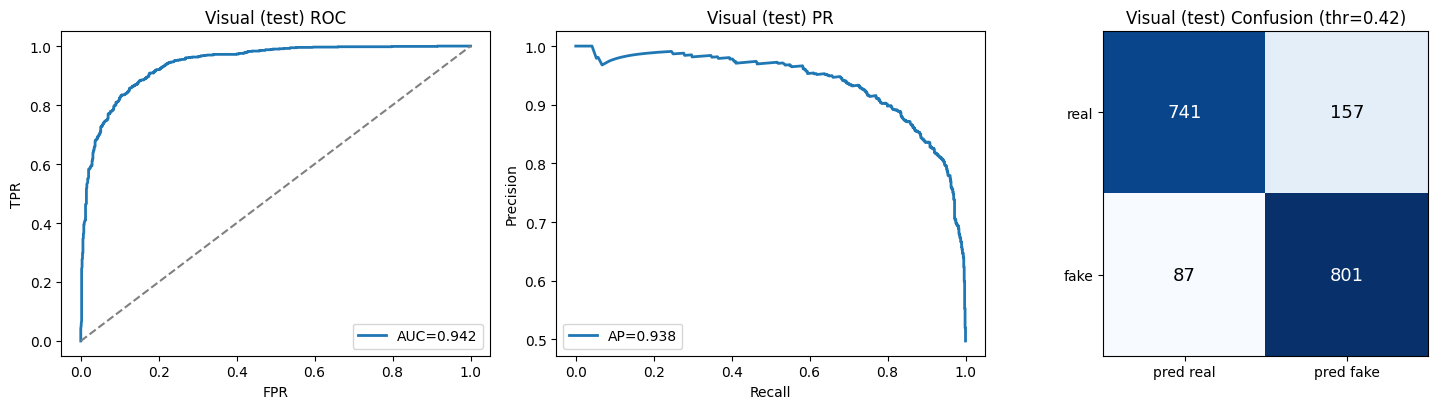

saved /kaggle/working/visual_eval.png

— VISUAL: per-subgroup test breakdown (fake→detection rate, real→reject rate) —
group class   n   rate  mean_p_fake
 fake  fake 888 0.9020       0.7928
 real  real 898 0.8252       0.1862


pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIP probe: vit_base_patch32_clip_224.openai feat_dim=768 (frozen) — ON
CLIP probe done. best val AUC=0.8041

── CLIP-VISUAL [train] ──  (n=8402, thr=0.392)
   accuracy      : 0.7610
   balanced_acc  : 0.7601
   precision     : 0.7138
   recall        : 0.8779
   specificity   : 0.6422
   f1            : 0.7874
   roc_auc       : 0.8490
   pr_auc        : 0.8408
   mcc           : 0.5357
   eer           : 0.2295
   confusion      : TP=3718 FP=1491 TN=2676 FN=517

── CLIP-VISUAL [val] ──  (n=1812, thr=0.392)
   accuracy      : 0.7329
   balanced_acc  : 0.7370
   precision     : 0.6750
   recall        : 0.8643
   specificity   : 0.6096
   f1            : 0.7580
   roc_auc       : 0.8041
   pr_auc        : 0.7705
   mcc           : 0.4879
   eer           : 0.2726
   confusion      : TP=758 FP=365 TN=570 FN=119

── CLIP-VISUAL [test] ──  (n=1786, thr=0.392)
   accuracy      : 0.7368
   balanced_acc  : 0.7375
   precision     : 0.6917
   recall        : 0.8491
   specificity   : 0.6258
 

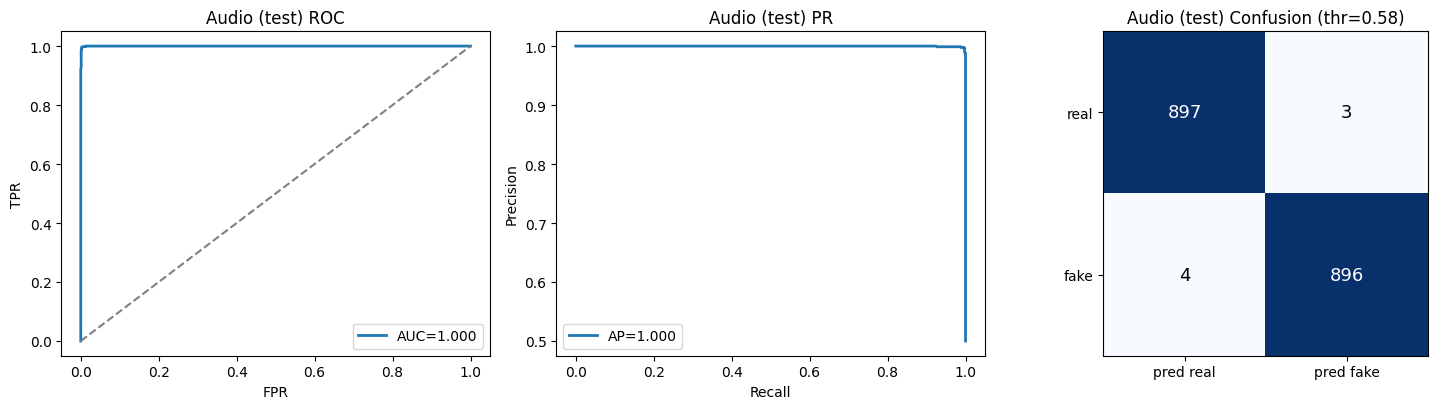

saved /kaggle/working/audio_eval.png

— AUDIO: per-subgroup test breakdown (fake→detection rate, real→reject rate) —
          group class   n   rate  mean_p_fake
       diffwave  fake 784 1.0000       0.9959
parallelwavegan  fake 116 0.9655       0.9342
       Bonafide  real 896 0.9978       0.0107

AUDIO CROSS-CORPUS eval on 'release-in-the-wild': n=23632 (real=11816 fake=11816) — UNSEEN generators

── AUDIO [CROSS-CORPUS in-the-wild] ──  (n=23632, thr=0.575)
   accuracy      : 0.3338
   balanced_acc  : 0.3338
   precision     : 0.2079
   recall        : 0.1183
   specificity   : 0.5493
   f1            : 0.1508
   roc_auc       : 0.1784
   pr_auc        : 0.3514
   mcc           : -0.3683
   eer           : 0.7718
   confusion      : TP=1398 FP=5325 TN=6491 FN=10418


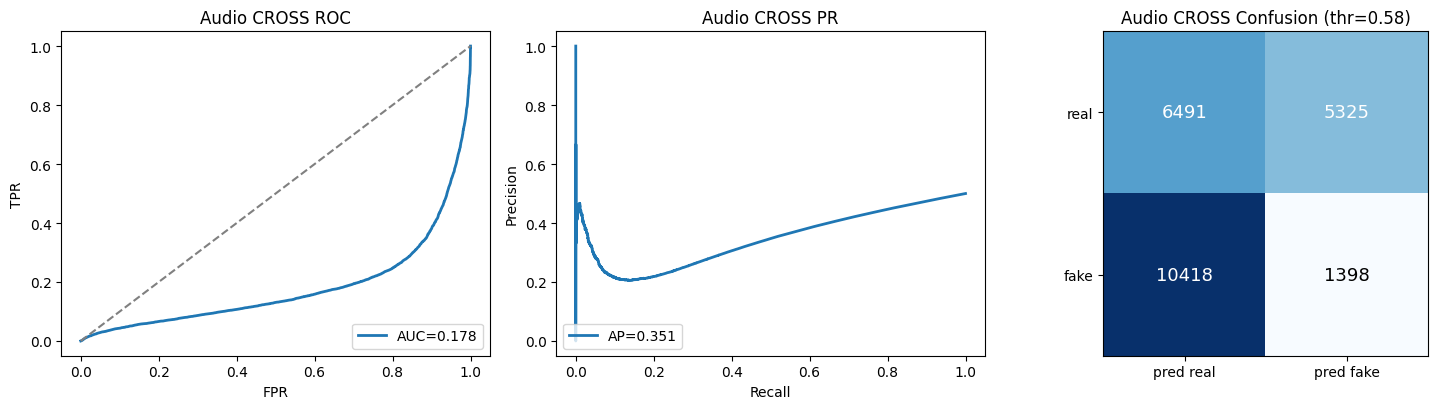

saved /kaggle/working/audio_cross_eval.png
  ↑ THIS is the number that matters. If AUC here ≫ in-dist drop, the model
    was riding the CVoiceFake vocoder fingerprint, not learning 'is-synthetic'.
Downloading: "https://download.pytorch.org/torchaudio/models/wav2vec2_fairseq_base_ls960.pth" to /root/.cache/torch/hub/checkpoints/wav2vec2_fairseq_base_ls960.pth


100%|██████████| 360M/360M [00:00<00:00, 431MB/s] 


SSL audio: WAV2VEC2_BASE loaded (frozen) — ON
  SSL feats [train] n=8400...
  SSL feats [val] n=1800...
  SSL feats [test] n=1800...
SSL audio probe done. best val AUC=0.9804

── SSL-AUDIO [train] ──  (n=8400, thr=0.426)
   accuracy      : 0.9312
   balanced_acc  : 0.9312
   precision     : 0.9273
   recall        : 0.9357
   specificity   : 0.9267
   f1            : 0.9315
   roc_auc       : 0.9803
   pr_auc        : 0.9828
   mcc           : 0.8624
   eer           : 0.0670
   confusion      : TP=3930 FP=308 TN=3892 FN=270

── SSL-AUDIO [val] ──  (n=1800, thr=0.426)
   accuracy      : 0.9422
   balanced_acc  : 0.9422
   precision     : 0.9442
   recall        : 0.9400
   specificity   : 0.9444
   f1            : 0.9421
   roc_auc       : 0.9804
   pr_auc        : 0.9835
   mcc           : 0.8845
   eer           : 0.0600
   confusion      : TP=846 FP=50 TN=850 FN=54

── SSL-AUDIO [test] ──  (n=1800, thr=0.426)
   accuracy      : 0.9306
   balanced_acc  : 0.9306
   precision     : 0.9

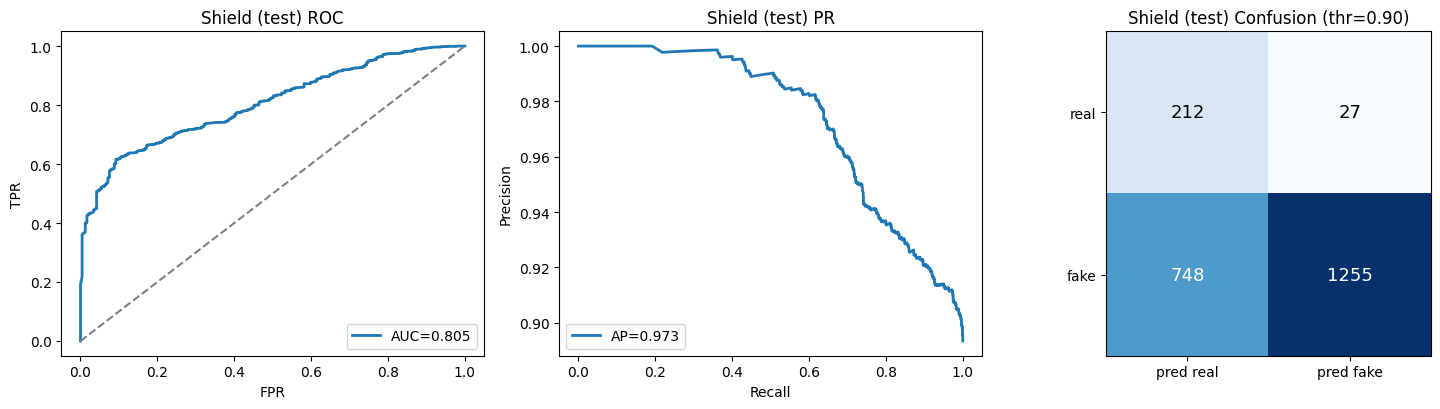

saved /kaggle/working/shield_eval.png
VIDEO-LEVEL eval on 330 held-out test clips (mean frame-prob per clip)
  scored 50/330
  scored 100/330
  scored 150/330
  scored 200/330
  scored 250/330
  scored 300/330

── VIDEO clip-level ──  (n=330, thr=0.488)
   accuracy      : 0.9485
   balanced_acc  : 0.9484
   precision     : 0.9682
   recall        : 0.9268
   specificity   : 0.9699
   f1            : 0.9470
   roc_auc       : 0.9803
   pr_auc        : 0.9752
   mcc           : 0.8977
   eer           : 0.0545
   confusion      : TP=152 FP=5 TN=161 FN=12


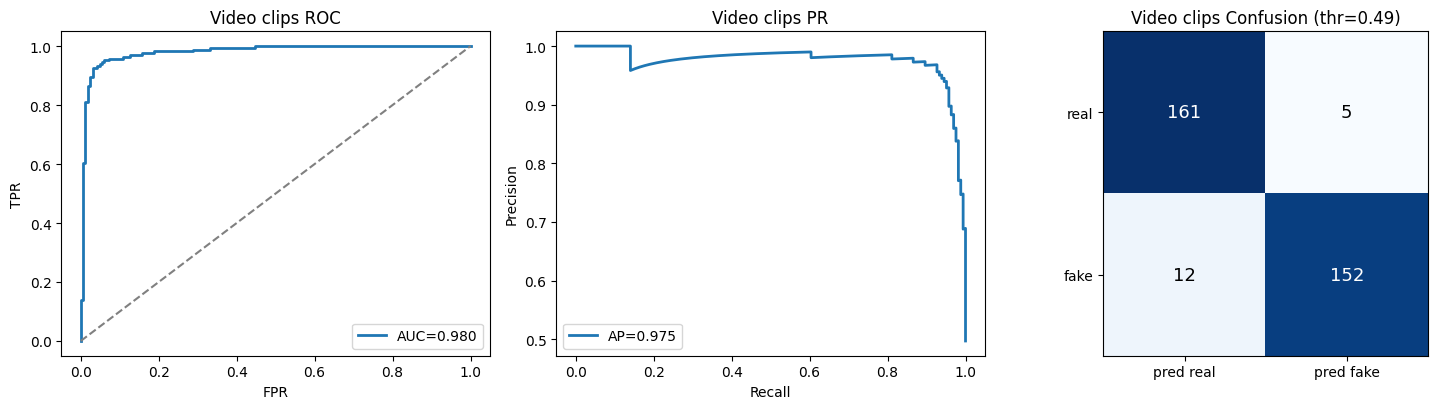

saved /kaggle/working/video_eval.png

── TEMPORAL [clip_test] (training-free 2nd-order) ──  (n=330, thr=0.454)
   accuracy      : 0.5515
   balanced_acc  : 0.5535
   precision     : 0.5294
   recall        : 0.8780
   specificity   : 0.2289
   f1            : 0.6606
   roc_auc       : 0.5469
   pr_auc        : 0.5348
   mcc           : 0.1405
   eer           : 0.4939
   confusion      : TP=144 FP=128 TN=38 FN=20
  ↑ if this AUC is high IN-DIST too (not just the n=20 cross), the temporal signal is real,
    not luck — it's the D3/ATSS direction and your best shot at UNSEEN AI-video.
  MOUNT DIAGNOSTIC — file-extension census per dataset root
  shield-2026-features-master2                   files~       7  {'.pt': 6, '.ipynb': 1}
  release-in-the-wild                            files~  31,780  {'.wav': 31779, '.txt': 1}
  deepfake-detection-dataset-2026                files~       1  {'.csv': 1}
  cvoicefake-full-safeear-dataset-mirror         files~ 300,023  {'.mp3': 300022, '.py': 1}


100%|██████████| 1.18G/1.18G [00:37<00:00, 33.7MB/s]


  NOTE: zero-shot + fine-tuning overfits the source (measured AUC 0.683).
        -> using FROZEN XLS-R for the clean zero-shot number. (set CFG13.force_finetune=True to override and reproduce the overfit.)
v13 front-end=WAV2VEC2_XLSR53  layers=24  dim=1024  MODE=zeroshot  finetune_top_k=0
  setup: ZERO-SHOT  (train CVoiceFake only -> test ALL In-the-Wild; no speaker leakage)
  sizes: train=8670 val=1530 test=12000
  epoch 1/10  loss=0.6059  val_auc=0.9502
  epoch 2/10  loss=0.5691  val_auc=0.9739
  epoch 3/10  loss=0.5565  val_auc=0.9948
  epoch 4/10  loss=0.5181  val_auc=0.9940
  epoch 5/10  loss=0.4889  val_auc=0.9936
  epoch 6/10  loss=0.4929  val_auc=0.9965
  epoch 7/10  loss=0.4805  val_auc=0.9888
  epoch 8/10  loss=0.4746  val_auc=0.9951
  epoch 9/10  loss=0.4624  val_auc=0.9914
  epoch 10/10  loss=0.4453  val_auc=0.9979
v13 done. best val AUC=0.9979

── V13 XLS-R+SLS [zeroshot In-the-Wild test] ──  (n=12000, thr=0.096)
   accuracy      : 0.3905
   balanced_acc  : 0.3905
   prec

In [1]:
# Deepfake Detector v11 — built on the v10 findings (SSL wins audio, temporal wins video)
# Kaggle: GPU ON, Run All (in the editor, not Save Version).
#
# ============================================================================
# v10 PROVED (keep these results in mind):
#   • AUDIO mel-CNN: in-dist AUC 1.000 but CROSS 0.178 (BELOW chance, MCC -0.37)
#     -> it learned the CVoiceFake vocoder fingerprint and INVERTS in the wild.
#     DO NOT FUSE IT. It is kept only as a documented negative control.
#   • wav2vec2 SSL: in-dist 0.983, CROSS 0.744 -> SSL features generalize. This
#     is the audio branch to trust. (0.744 vs 0.178 = the whole project thesis.)
#   • VISUAL regression fixed (EMA picks raw): test AUC 0.94, video clip 0.98.
#   • TEMPORAL 2nd-order feature: AUC 0.94 on the (tiny) cross-video set -> the
#     only thing that separated UNSEEN AI-faces. Promote & verify in-dist.
#
# v11 DOES:
#   1. TEMPORAL BRANCH (CFG.temporal_branch): the D3-style 2nd-order feature is
#      now CALIBRATED on the full in-dist clip set and reported as a real branch,
#      so you learn whether its 0.94 is signal or n=20 luck.
#   2. SSL ENCODER CHOICE (CFG.ssl_model_name): swap in WAV2VEC2_LARGE / XLSR53
#      for stronger cross-corpus (XLSR is the audio-antispoof generalization SOTA).
#   3. SSL MIXED-CORPUS EXPERIMENT (CFG.ssl_mix_cross_train, opt-in): train on
#      CVoiceFake + a DISJOINT In-the-Wild slice, test on the rest -> measures how
#      much a little in-domain data lifts the 0.744 cross ceiling.
#   4. mel-CNN is explicitly labelled a negative control; trust audio = SSL.
#   ACTION ITEM (data side): the unidpro video mount still delivers only ~10
#   clips -> the video CROSS rows stay UNDERPOWERED until you fix that mount.
# ============================================================================
#
# WHY v10 (kept):
#   v8/v9 REGRESSED the visual & audio in-dist scores (visual 0.90->0.62,
#   audio 1.00->0.85) because EMA was validated/checkpointed on lagging EMA
#   weights (decay 0.999 over a ~3k-step run) AND mixup α=0.2 over only 6 epochs
#   slowed convergence. v10 FIXES this:
#     • checkpoint/validate on RAW weights; use EMA only if it beats raw on val
#     • EMA decay 0.99 (tracks a short run), mixup α=0.1 applied with prob 0.5
#     • +2 visual epochs
#   Expected: visual ~0.88-0.90 again, video clip ~0.95 again.
#
#   v9's REAL findings (kept + built on):
#     • AUDIO cross-corpus AUC≈0.49 (BELOW chance) — mel-CNN learned the
#       CVoiceFake vocoder fingerprint, not "is-synthetic". So v10 ADDS a
#       wav2vec2 SSL audio probe (frozen SSL features + linear head), the audio
#       analogue of the CLIP win, and scores BOTH on In-the-Wild to compare.
#     • CLIP visual was the best generalizer -> kept, now also fed proper epochs.
#     • unidpro mounted only 10 videos -> v10 flags cross-video as UNDERPOWERED
#       when n<50 so a noise AUC can't be mistaken for a result. RE-CHECK MOUNT.
# ============================================================================
#
# NEW IN v9 (kept):
#   • Two new datasets wired in by EXPLICIT PATH:
#       AUDIO cross-corpus : /kaggle/input/datasets/bhaveshkumars/release-in-the-wild
#       VIDEO cross-gen     : /kaggle/input/datasets/unidpro/deepfake-videos-dataset
#     Both are EXCLUDED from training and used ONLY as held-out generalization
#     probes (the number Deepfake-Eval-2024 shows off-the-shelf detectors fail).
#   • CLIP linear-probe visual branch (frozen ViT) — foundation features
#     generalize across UNSEEN generators far better than a from-scratch CNN
#     (the DeCoF idea). Fully guarded: if CLIP can't load, it's skipped.
#   • Cross-generator VIDEO eval on unidpro AI-faces: EfficientNet vs CLIP,
#     scored against held-out REAL clips -> honest "do we catch a NEW generator".
#   • Temporal frame-consistency diagnostic (D3/ATSS-style second-order signal):
#     reports whether frame-prob dynamics separate real vs generated, and an
#     appearance+temporal ensemble.
#
# WHY (one line): your branches are problem-#1 (face-swap) detectors aimed at
# problem-#2/#3 (AI-generated / avatar) data. v9 adds the generalizing signals
# the literature uses and MEASURES the cross-generator gap instead of hiding it.
#
# ============================================================================
# WHAT CARRIED OVER FROM v8 (every change targets "catch NEW fakes")
# ----------------------------------------------------------------------------
#  1. CALIBRATION (Platt/temperature on val) for EVERY branch.
#       -> fixes the weird thr=0.281 visual threshold that flagged 30% of REAL
#          faces, and makes branch probabilities comparable so they can be FUSED.
#  2. SHIELD COLLAPSE FIXED.
#       v7 bug: val report recomputed its own F1 threshold (=0.064) and predicted
#       "fake" for everything (specificity 0.042). v8 locks ONE balanced threshold
#       on val and applies it to ALL splits. + EMA weights + best-val-AUC ckpt.
#  3. VISUAL OVERFIT NARROWED: EMA weights + mixup + RandAug-style strong aug.
#       Train/test AUC gap (0.993 -> 0.901) is the overfit tax; EMA+mixup cut it.
#  4. TEST-TIME AUGMENTATION (TTA) for visual & video (orig + hflip mean).
#  5. CROSS-CORPUS / CROSS-GENERATOR EVAL — the headline honesty upgrade:
#       - AUDIO: train on CVoiceFake, then score the trained model on the
#         In-the-Wild set (bhaveshkumars/release-in-the-wild). UNSEEN generators,
#         real celebs. This is the ONLY number that proves generalization.
#       - VISUAL: optional holdout_source -> route a whole modern AI-face source
#         to TEST (train DFDC/FF++, test 2025 avatar faces).
#       - AUDIO leave-one-vocoder-out via CFG.holdout_method (retrain pass).
#  6. CALIBRATED DECISION-FUSION report. (True AV fusion needs PAIRED data —
#       FakeAVCeleb — which isn't mounted; decision-fusion is the honest stand-in.)
#  7. FINAL TABLE splits metrics into IN-DISTRIBUTION vs CROSS (generalization),
#       so a near-1.0 in-dist AUC can never masquerade as real-world skill.
#
# DATASETS TO ADD in the Kaggle sidebar (Add Input):
#   kamedev/cvoicefake-full-safeear-dataset-mirror      (audio train, keep)
#   bhaveshkumars/release-in-the-wild                    (audio CROSS eval, NEW)
#   <your FF++ / DFDC frames or .mp4>                    (visual train, keep)
#   unidpro/deepfake-videos-dataset                      (visual CROSS eval, NEW; optional)
#   aionstreet/shield-2026-features                      (shield .pt, keep)
# ============================================================================

# %% cell 1 — Setup
import sys, subprocess, importlib
def _ensure(pkg, pip_name=None):
    try: importlib.import_module(pkg)
    except Exception: subprocess.run([sys.executable,"-m","pip","install","-q",pip_name or pkg], check=False)
_ensure("timm"); _ensure("librosa"); _ensure("soundfile"); _ensure("cv2","opencv-python-headless")

import os, glob, random, json, time, warnings, collections, zipfile, math, io as _io, re
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, confusion_matrix, matthews_corrcoef, balanced_accuracy_score)
import matplotlib.pyplot as plt

SEED=42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE="cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEVICE)
if DEVICE=="cpu": print("⚠️  Turn on the GPU accelerator.")

# %% cell 2 — Config
class CFG:
    input_root   = "/kaggle/input"
    extract_root = "/kaggle/working/extracted"
    out_dir      = "/kaggle/working"

    per_source_cap = 80_000
    max_visit      = 800_000
    max_zip_mb     = 200

    max_per_class       = 6000
    max_audio_per_class = 6000
    balance_classes     = True
    val_frac, test_frac = 0.15, 0.15
    label_smooth        = 0.05

    use_sources_with  = None
    drop_sources_with = []
    holdout_source    = None      # e.g. "deepfake-videos-dataset" -> that whole VISUAL source goes to TEST
    holdout_method    = None      # e.g. "diffwave" -> leave-one-vocoder-out AUDIO (needs this run = the LOO run)

    # ── v9 EXPLICIT dataset paths (the two you gave) ──────────────────────────
    # These are EXCLUDED from training and scored only as held-out generalization probes.
    CROSS_AUDIO_PATH = "/kaggle/input/datasets/bhaveshkumars/release-in-the-wild"
    CROSS_VIDEO_PATH = "/kaggle/input/datasets/unidpro/deepfake-videos-dataset"
    cross_video_source   = "deepfake-videos-dataset"  # substring fallback if the path moves
    cross_video_assume_label = 1   # unidpro = AI-generated faces -> fake when path has no real/fake token
    cross_video_max_clips    = 400

    # ── CLIP foundation-feature visual branch (generalizes cross-generator) ──
    use_clip_visual  = True       # frozen CLIP ViT + linear probe; auto-skips if it can't load
    clip_backbone    = "vit_base_patch32_clip_224.openai"  # timm CLIP weights
    clip_epochs      = 8
    clip_batch       = 128

    # ── v8 generalization knobs ──────────────────────────────────────────────
    cross_audio_source = "release-in-the-wild"   # substring; this source is PULLED OUT of train and used ONLY as a cross-corpus eval. Set None to disable.
    calibrate          = True     # Platt-scale every branch on val (fixes thresholds + enables fusion)
    use_ema            = True     # exponential moving average of weights (steadier, less overfit)
    ema_decay          = 0.99     # v10: was 0.999 (too slow for a ~3k-step run -> lagging weights)
    ema_eval           = False    # v10: checkpoint/validate on RAW weights; EMA used only if it beats raw on val
    use_mixup          = True     # visual only
    mixup_alpha        = 0.1      # v10: was 0.2 (too strong for 6-8 epochs)
    mixup_prob         = 0.5      # v10: apply mixup to only half the batches -> faster convergence
    use_tta            = True     # visual + video: average(orig, hflip)

    # ── v10 SSL audio probe (wav2vec2) — generalization analogue of the CLIP win ──
    use_ssl_audio      = True     # frozen wav2vec2 features + linear head; auto-skips if it can't load
    ssl_audio_max_cross = 6000    # cap In-the-Wild clips for the (heavier) SSL cross-eval, balanced
    # ── v11 additions (driven by the v10 findings) ──
    ssl_model_name     = "WAV2VEC2_BASE"   # try "WAV2VEC2_LARGE" or "WAV2VEC2_XLSR53" for stronger cross-corpus (heavier DL)
    ssl_mix_cross_train= False    # OPT-IN experiment: fold a TRAIN split of In-the-Wild into SSL training,
                                  #   test on a DISJOINT In-the-Wild split -> shows if diverse data lifts cross-AUC
    ssl_mix_frac       = 0.6      # fraction of In-the-Wild routed to training when ssl_mix_cross_train=True
    ssl_mix_max        = 8000     # cap total In-the-Wild clips used in the mixed experiment
    temporal_branch    = True     # v11: promote the D3-style 2nd-order temporal feature to a calibrated branch

    img_size=224; img_backbone="efficientnet_b0"; img_epochs=8; img_batch=64; img_lr=3e-4
    sr=16000; audio_seconds=3.0; n_mels=128; audio_epochs=6; audio_batch=64; audio_lr=1e-3
    shield_epochs=18; shield_batch=256; shield_lr=1e-3; shield_hidden=256
    RUN_VIDEO_MP4=True; video_max_clips=400; video_frames_per_clip=12
    shield_pos_weight=True
    FRAMES_FROM_VIDEO=True; frames_per_video=8; max_videos_for_frames=1100
    aug_strong=True
    num_workers=2

os.makedirs(CFG.out_dir, exist_ok=True); os.makedirs(CFG.extract_root, exist_ok=True)

def _norm(t): return ''.join(ch for ch in t.lower() if ch.isalnum())
REAL_TOKENS={"real","reals","bonafide","genuine","live","authentic","pristine",
             "original","originals","originalsequences","youtube","actors","commonvoice",
             "celebreal","realsequences"}
FAKE_TOKENS={"fake","fakes","spoof","deepfake","deepfakes","face2face","faceswap",
             "neuraltextures","faceshifter","manipulated","manipulatedsequences",
             "synthetic","parallelwavegan","multibandmelgan","melgan","stylemelgan",
             "griffinlim","world","diffwave","wavegan","uadfv","celebsynthesis","reenactment",
             "wav2lip","sadtalker","videoretalking","liveportrait","simswap","inswapper",
             "roop","facefusion","stylegan","stargan","heygen","synthesia","sora","kling",
             "runway","pika","veo","stablediffusion","sdxl","ldm","talkinghead","lipsync"}
METHOD_HINTS=("parallelwavegan","multibandmelgan","stylemelgan","melgan","griffinlim",
              "diffwave","wavegan","waveglow","hifigan","fastspeech","tacotron","world",
              "deepfakes","face2face","faceswap","neuraltextures","faceshifter","celebsynthesis",
              "wav2lip","sadtalker","videoretalking","liveportrait","simswap","inswapper",
              "roop","facefusion","stylegan","stargan","heygen","synthesia","sora","kling",
              "runway","pika","veo","stablediffusion","sdxl","talkinghead","lipsync")
def _method_hint(p):
    flat=_norm(p)
    for h in METHOD_HINTS:
        if h in flat: return h
    return None
def label_and_method(p):
    lab=None; tok=None
    for t in reversed(p.replace("\\","/").split("/")):
        n=_norm(t)
        if not n: continue
        if n in REAL_TOKENS or n.startswith("original"): lab,tok=0,t; break
        if n in FAKE_TOKENS or n.startswith("method"):   lab,tok=1,t; break
        if n.startswith("real"): lab,tok=0,t; break
        if n.startswith("fake"): lab,tok=1,t; break
    if lab is None:
        low=p.lower()
        if any(k in low for k in ("fake","deepfake","spoof","synthetic","synth","manipulat","uadfv")): lab=1
        elif any(k in low for k in ("real","genuine","bonafide","original")): lab=0
        else: return None,None
    if lab==1: meth=_method_hint(p) or tok or "fake"
    else:      meth=tok or "real"
    return lab, meth
def label_from_path(p): return label_and_method(p)[0]
def split_kind(p):
    low="/"+p.lower().replace("\\","/")+"/"
    if any(s in low for s in ("/test/","/testing/","/eval/")): return "test"
    if any(s in low for s in ("/val/","/valid/","/validation/","/dev/")): return "val"
    if any(s in low for s in ("/train/","/training/")): return "train"
    return None
def source_of(p):
    rel=p.replace("\\","/")
    for marker in ("input/datasets/","input/","extracted/"):
        if marker in rel:
            parts=[s for s in rel.split(marker)[-1].strip("/").split("/")]
            return "/".join(parts[:2]) if len(parts)>=2 else (parts[0] if parts else "?")
    return "?"
def is_cross_audio(p):
    lp=p.lower()
    if CFG.CROSS_AUDIO_PATH and CFG.CROSS_AUDIO_PATH.lower() in lp: return True
    return bool(CFG.cross_audio_source) and (CFG.cross_audio_source.lower() in lp)
def is_cross_video(p):
    lp=p.lower()
    if CFG.CROSS_VIDEO_PATH and CFG.CROSS_VIDEO_PATH.lower() in lp: return True
    return bool(CFG.cross_video_source) and (CFG.cross_video_source.lower() in lp)
print("Config ready.")

# %% cell 3 — Discovery (single-pass, per-source-capped)
IMG_EXT=(".jpg",".jpeg",".png",".bmp",".webp"); AUD_EXT=(".wav",".flac",".mp3",".ogg",".m4a"); VID_EXT=(".mp4",".avi",".mov",".mkv")
zips=[os.path.join(dp,f) for dp,_,fs in os.walk(CFG.input_root) for f in fs if f.lower().endswith(".zip")]
for z in zips:
    mb=os.path.getsize(z)/1e6
    if mb>CFG.max_zip_mb: print(f"skip big zip ({mb:.0f}MB): {z}"); continue
    dest=os.path.join(CFG.extract_root, os.path.splitext(os.path.basename(z))[0])
    if os.path.exists(dest): continue
    try:
        with zipfile.ZipFile(z) as zf: zf.extractall(dest); print("extracted", z)
    except Exception as e: print("zip fail", z, e)

def list_roots():
    roots=[]
    for base in (CFG.input_root, CFG.extract_root):
        if not os.path.isdir(base): continue
        for name in sorted(os.listdir(base)):
            full=os.path.join(base,name)
            if not os.path.isdir(full): continue
            if name=="datasets":
                for owner in sorted(os.listdir(full)):
                    of=os.path.join(full,owner)
                    if os.path.isdir(of):
                        for slug in sorted(os.listdir(of)):
                            sf=os.path.join(of,slug)
                            if os.path.isdir(sf): roots.append(sf)
            else: roots.append(full)
    return roots
def discover(roots):
    imgs,auds,vids,pts=[],[],[],[]
    print(f"walking {len(roots)} dataset root(s), cap {CFG.per_source_cap:,}/modality each:")
    for r in roots:
        ci=ca=cv=0; vis=0; t0=time.time()
        for dp,_,files in os.walk(r):
            for f in files:
                vis+=1; fl=f.lower()
                if   fl.endswith(IMG_EXT) and ci<CFG.per_source_cap: imgs.append(os.path.join(dp,f)); ci+=1
                elif fl.endswith(AUD_EXT) and ca<CFG.per_source_cap: auds.append(os.path.join(dp,f)); ca+=1
                elif fl.endswith(VID_EXT) and cv<CFG.per_source_cap: vids.append(os.path.join(dp,f)); cv+=1
                elif fl.endswith(".pt"): pts.append(os.path.join(dp,f))
            if vis>CFG.max_visit: print(f"    (max_visit hit)"); break
        print(f"  {os.path.basename(r):<52} img={ci:>7,} aud={ca:>7,} vid={cv:>6,} ({time.time()-t0:.0f}s)")
    return imgs,auds,vids,sorted(set(pts))
roots=list_roots()
all_imgs,all_auds,all_vids,shield_pts=discover(roots)

# split audio into TRAIN-pool vs CROSS-corpus holdout (In-the-Wild)
cross_auds=[p for p in all_auds if is_cross_audio(p)]
all_auds=[p for p in all_auds if not is_cross_audio(p)]
# split video into TRAIN-pool vs CROSS-generator holdout (unidpro AI faces)
cross_vids=[p for p in all_vids if is_cross_video(p)]
all_vids=[p for p in all_vids if not is_cross_video(p)]
print(f"\nTOTAL  images={len(all_imgs):,} audio(train-pool)={len(all_auds):,} "
      f"audio(CROSS={CFG.cross_audio_source})={len(cross_auds):,}")
print(f"       videos(train-pool)={len(all_vids):,} videos(CROSS={CFG.cross_video_source})={len(cross_vids):,} shield_pt={len(shield_pts)}")
VIDEO_ON=len(all_imgs)>50; AUDIO_ON=len(all_auds)>50
print(f"VISUAL:{'ON' if VIDEO_ON else 'off'}  AUDIO:{'ON' if AUDIO_ON else 'off'}  "
      f"SHIELD:{'pending' if shield_pts else 'off'}  MP4:{'ON' if (CFG.RUN_VIDEO_MP4 and all_vids) else 'off'}  "
      f"AUDIO-CROSS:{'ON' if len(cross_auds)>20 else 'off'}  VIDEO-CROSS:{'ON' if len(cross_vids)>5 else 'off'}")

# %% cell 4 — VISUAL-from-VIDEO (sample frames if no image dataset mounted)
if CFG.FRAMES_FROM_VIDEO and len(all_imgs) < 50 and all_vids:
    import cv2
    fr_root=os.path.join(CFG.extract_root,"video_frames")
    clips=[]
    for p in all_vids:
        y,m=label_and_method(p)
        if y is not None: clips.append((p,y,m))
    byc={0:[],1:[]}
    for p,y,m in clips: byc[y].append((p,m))
    rng=random.Random(SEED); rng.shuffle(byc[0]); rng.shuffle(byc[1])
    if byc[0] and byc[1]: per=min(CFG.max_videos_for_frames, min(len(byc[0]),len(byc[1])))
    else:                 per=min(CFG.max_videos_for_frames, max(len(byc[0]),len(byc[1])))
    sel=[(p,0,m) for p,m in byc[0][:per]]+[(p,1,m) for p,m in byc[1][:per]]; rng.shuffle(sel)
    def clip_split(i,n):
        r=i/max(n,1)
        return "test" if r<CFG.test_frac else ("val" if r<CFG.test_frac+CFG.val_frac else "train")
    print(f"VISUAL-from-VIDEO: sampling {CFG.frames_per_video} frames from {len(sel)} clips (per class={per})...")
    new=[]; t0=time.time(); bad=0; VIS_TEST_CLIPS=[]
    for j,(p,y,m) in enumerate(sel):
        sp=clip_split(j,len(sel)); lab="fake" if y==1 else "real"
        if sp=="test": VIS_TEST_CLIPS.append((p,y))
        try:
            cap=cv2.VideoCapture(p); tot=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0
            if tot<=0: cap.release(); bad+=1; continue
            idx=np.linspace(0,tot-1,CFG.frames_per_video).astype(int)
            d=os.path.join(fr_root,sp,lab); os.makedirs(d,exist_ok=True)
            stem=re.sub(r'[^A-Za-z0-9]+','_',os.path.splitext(os.path.basename(p))[0])[:48]
            for i in idx:
                cap.set(cv2.CAP_PROP_POS_FRAMES,int(i)); ok,fr=cap.read()
                if not ok: continue
                op=os.path.join(d,f"{stem}_{i:04d}.jpg"); cv2.imwrite(op,fr); new.append(op)
            cap.release()
        except Exception: bad+=1
        if (j+1)%200==0: print(f"  {j+1}/{len(sel)} clips, {len(new):,} frames ({time.time()-t0:.0f}s)")
    all_imgs=new; VIDEO_ON=len(all_imgs)>50
    print(f"VISUAL-from-VIDEO: {len(all_imgs):,} frames (bad clips={bad}). VISUAL now {'ON' if VIDEO_ON else 'off'}.")
else:
    print("VISUAL-from-VIDEO: skipped (image dataset present, or no clips, or disabled).")

# %% cell 5 — Build tables + per-source audit
def keep_path(p):
    low=p.lower()
    if CFG.use_sources_with and not any(s in low for s in CFG.use_sources_with): return False
    if any(s in low for s in CFG.drop_sources_with): return False
    return True
def build_table(paths, cap):
    rows=[]
    for p in paths:
        if not keep_path(p): continue
        y,meth=label_and_method(p)
        if y is None: continue
        rows.append((p,y,meth,split_kind(p),source_of(p)))
    if not rows: return pd.DataFrame(columns=["path","label","method","split","source"])
    df=pd.DataFrame(rows,columns=["path","label","method","split","source"])
    counts={lab:len(g) for lab,g in df.groupby("label")}
    eff=min(cap, min(counts.values())) if CFG.balance_classes else cap
    df=pd.concat([g.sample(frac=1.0,random_state=SEED).head(eff) for _,g in df.groupby("label")]
                 ).sample(frac=1.0,random_state=SEED).reset_index(drop=True)
    if CFG.holdout_source:
        mask=df["source"].str.contains(CFG.holdout_source, case=False, regex=False)
        if mask.sum()==0: print(f"⚠️ holdout_source '{CFG.holdout_source}' matched 0 rows — random split")
        else:
            df["split"]="train"; df.loc[mask,"split"]="test"
            rest=df[~mask]
            for lab,g in rest.groupby("label"):
                idx=g.index.tolist(); nv=int(len(idx)*CFG.val_frac); df.loc[idx[:nv],"split"]="val"
            print(f"holdout_source='{CFG.holdout_source}': test={int(mask.sum())} (held-out source), train/val from rest")
            return df
    if CFG.holdout_method:
        mmask=df["method"].astype(str).str.contains(CFG.holdout_method, case=False, regex=False)
        if mmask.sum()==0: print(f"⚠️ holdout_method '{CFG.holdout_method}' matched 0 rows — random split")
        else:
            df["split"]="train"; df.loc[mmask,"split"]="test"
            rest=df[~mmask]
            for lab,g in rest.groupby("label"):
                idx=g.index.tolist(); nv=int(len(idx)*CFG.val_frac); df.loc[idx[:nv],"split"]="val"
            print(f"holdout_method='{CFG.holdout_method}': test={int(mmask.sum())} (held-out vocoder), train/val from rest")
            return df
    has=df["split"].notna().mean()>0.6 and df["split"].nunique()>=2
    if not has:
        df["split"]=None
        for lab,g in df.groupby("label"):
            idx=g.index.tolist(); n=len(idx); nt=int(n*CFG.test_frac); nv=int(n*CFG.val_frac)
            df.loc[idx[:nt],"split"]="test"; df.loc[idx[nt:nt+nv],"split"]="val"; df.loc[idx[nt+nv:],"split"]="train"
    elif (df["split"]=="val").sum()==0:
        tr=df[df["split"]=="train"]; df.loc[tr.sample(frac=CFG.val_frac,random_state=SEED).index,"split"]="val"
    return df
def audit(paths,name):
    rec=collections.defaultdict(lambda:[0,0,0])
    for p in paths:
        if not keep_path(p): continue
        y=label_from_path(p); rec[source_of(p)][2 if y is None else y]+=1
    print(f"\n=== {name} per-source audit (real / fake / dropped) ===")
    for s,(r,f,n) in sorted(rec.items()):
        flag=" ⚠️ one-class" if (r==0 or f==0) else ""
        print(f"  {s:<55} real={r:>7,} fake={f:>7,} drop={n:>7,}{flag}")
if VIDEO_ON: audit(all_imgs,"VISUAL")
if AUDIO_ON: audit(all_auds,"AUDIO")
img_df=build_table(all_imgs,CFG.max_per_class) if VIDEO_ON else pd.DataFrame()
aud_df=build_table(all_auds,CFG.max_audio_per_class) if AUDIO_ON else pd.DataFrame()
def summarize(df,name):
    if len(df)==0: print(f"\n{name}: (none)"); return
    print(f"\n{name}: {len(df):,} used (balanced={CFG.balance_classes})")
    print(pd.crosstab(df["split"],df["label"].map({0:'real',1:'fake'}),margins=True))
    print("  methods:", dict(df["method"].value_counts().head(8)))
summarize(img_df,"VISUAL"); summarize(aud_df,"AUDIO")
if VIDEO_ON and img_df["label"].nunique()<2: print("\n⚠️ visual single-class → off"); VIDEO_ON=False
if AUDIO_ON and aud_df["label"].nunique()<2: print("\n⚠️ audio single-class → off"); AUDIO_ON=False

# %% cell 6 — Metrics, calibration, EMA, mixup helpers
def eer_of(y,p):
    fpr,tpr,_=roc_curve(y,p); fnr=1-tpr; i=np.nanargmin(np.abs(fnr-fpr)); return float((fpr[i]+fnr[i])/2)
def best_f1_thr(y,p):
    pr,rc,th=precision_recall_curve(y,p); f1=2*pr*rc/(pr+rc+1e-12)
    return 0.5 if len(th)==0 else float(th[np.nanargmax(f1[:-1])])
def best_bal_thr(y,p):
    fpr,tpr,th=roc_curve(y,p)
    if len(th)==0: return 0.5
    k=int(np.nanargmax(tpr-fpr)); return float(min(max(th[k],0.0),1.0))

def fit_platt(y,p,iters=300,lr=0.1):
    # logistic recalibration on logit(p): q=sigmoid(a*z+b). Fixes mis-scaled probs -> sane thresholds + fusion.
    y=np.asarray(y,float); p=np.clip(np.asarray(p,float),1e-6,1-1e-6); z=np.log(p/(1-p))
    a,b=1.0,0.0
    for _ in range(iters):
        q=1/(1+np.exp(-(a*z+b))); ga=float(np.mean((q-y)*z)); gb=float(np.mean(q-y))
        a-=lr*ga; b-=lr*gb
    return a,b
def apply_platt(p,ab):
    if ab is None: return np.asarray(p,float)
    a,b=ab; p=np.clip(np.asarray(p,float),1e-6,1-1e-6); z=np.log(p/(1-p)); return 1/(1+np.exp(-(a*z+b)))

def compute_metrics(y,p,threshold=None):
    y=np.asarray(y).astype(int); p=np.asarray(p).astype(float)
    thr=best_f1_thr(y,p) if threshold is None else threshold
    yp=(p>=thr).astype(int); tn,fp,fn,tp=confusion_matrix(y,yp,labels=[0,1]).ravel(); e=1e-12
    prec=tp/(tp+fp+e); rec=tp/(tp+fn+e); spec=tn/(tn+fp+e); f1=2*prec*rec/(prec+rec+e)
    acc=(tp+tn)/(tp+tn+fp+fn+e)
    try: auc=roc_auc_score(y,p)
    except: auc=float('nan')
    try: ap=average_precision_score(y,p)
    except: ap=float('nan')
    return {"accuracy":acc,"balanced_acc":balanced_accuracy_score(y,yp),"precision":prec,
            "recall":rec,"specificity":spec,"f1":f1,"roc_auc":auc,"pr_auc":ap,
            "mcc":matthews_corrcoef(y,yp) if len(set(yp))>1 else 0.0,"eer":eer_of(y,p),
            "threshold":thr,"TP":int(tp),"FP":int(fp),"TN":int(tn),"FN":int(fn),"n":int(len(y))}
def print_metrics(name,m):
    print(f"\n── {name} ──  (n={m['n']}, thr={m['threshold']:.3f})")
    for k in ["accuracy","balanced_acc","precision","recall","specificity","f1","roc_auc","pr_auc","mcc","eer"]:
        print(f"   {k:<14}: {m[k]:.4f}")
    print(f"   confusion      : TP={m['TP']} FP={m['FP']} TN={m['TN']} FN={m['FN']}")
def plot_eval(name,y,p,m,prefix):
    y=np.asarray(y); p=np.asarray(p); fig,ax=plt.subplots(1,3,figsize=(15,4.2))
    fpr,tpr,_=roc_curve(y,p); ax[0].plot(fpr,tpr,lw=2,label=f"AUC={m['roc_auc']:.3f}")
    ax[0].plot([0,1],[0,1],"--",c="gray"); ax[0].set_title(f"{name} ROC"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend(loc="lower right")
    pr,rc,_=precision_recall_curve(y,p); ax[1].plot(rc,pr,lw=2,label=f"AP={m['pr_auc']:.3f}")
    ax[1].set_title(f"{name} PR"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend(loc="lower left")
    cm=np.array([[m['TN'],m['FP']],[m['FN'],m['TP']]]); ax[2].imshow(cm,cmap="Blues")
    ax[2].set_xticks([0,1]); ax[2].set_yticks([0,1]); ax[2].set_xticklabels(["pred real","pred fake"]); ax[2].set_yticklabels(["real","fake"])
    for (i,j),v in np.ndenumerate(cm): ax[2].text(j,i,str(v),ha="center",va="center",color="white" if v>cm.max()/2 else "black",fontsize=13)
    ax[2].set_title(f"{name} Confusion (thr={m['threshold']:.2f})"); plt.tight_layout()
    out=os.path.join(CFG.out_dir,f"{prefix}_eval.png"); plt.savefig(out,dpi=110,bbox_inches="tight"); plt.show(); print("saved",out)
def subgroup_report(d, probs, thr, name, prefix):
    dd=d.copy(); dd["prob"]=np.asarray(probs); dd["pred"]=(dd["prob"]>=thr).astype(int)
    rows=[]
    for (lab,meth),g in dd.groupby(["label","method"]):
        n=len(g)
        if n<5: continue
        rate=(g["pred"]==1).mean() if lab==1 else (g["pred"]==0).mean()
        rows.append({"group":meth,"class":"fake" if lab==1 else "real","n":n,
                     "rate":round(float(rate),4),"mean_p_fake":round(float(g['prob'].mean()),4)})
    if not rows: return None
    rep=pd.DataFrame(rows).sort_values(["class","n"],ascending=[True,False])
    print(f"\n— {name}: per-subgroup test breakdown (fake→detection rate, real→reject rate) —")
    print(rep.to_string(index=False)); rep.to_csv(os.path.join(CFG.out_dir,f"{prefix}_subgroups.csv"),index=False)
    return rep

class EMA:
    # tracks a smoothed copy of weights; eval on EMA weights = steadier, less overfit val/test.
    def __init__(s,model,decay):
        s.decay=decay; s.shadow={k:v.detach().clone() for k,v in model.state_dict().items()}
    def update(s,model):
        for k,v in model.state_dict().items():
            if v.dtype.is_floating_point: s.shadow[k].mul_(s.decay).add_(v.detach(),alpha=1-s.decay)
            else: s.shadow[k]=v.detach().clone()
    def state(s): return {k:v.clone() for k,v in s.shadow.items()}
def mixup_batch(x,y,alpha):
    if alpha<=0: return x,y,y,1.0
    lam=float(np.random.beta(alpha,alpha)); idx=torch.randperm(x.size(0),device=x.device)
    return lam*x+(1-lam)*x[idx], y, y[idx], lam
def smooth(y): return y*(1-CFG.label_smooth)+0.5*CFG.label_smooth
print("Metrics + calibration + EMA + mixup ready.")

# %% cell 7 — VISUAL: dataset + EfficientNet-B0
import timm
from PIL import Image
import torchvision.transforms as T
NORM=([0.485,0.456,0.406],[0.229,0.224,0.225])
class _RandJPEG:
    def __init__(s,p=0.4,q=(35,90)): s.p=p; s.q=q
    def __call__(s,im):
        if random.random()<s.p:
            b=_io.BytesIO(); im.convert("RGB").save(b,"JPEG",quality=random.randint(*s.q)); b.seek(0); im=Image.open(b).convert("RGB")
        return im
class _RandDownscale:
    def __init__(s,p=0.3,f=(0.4,0.85)): s.p=p; s.f=f
    def __call__(s,im):
        if random.random()<s.p:
            w,h=im.size; r=random.uniform(*s.f)
            im=im.resize((max(8,int(w*r)),max(8,int(h*r))),Image.BILINEAR).resize((w,h),Image.BILINEAR)
        return im
_pre=[T.Resize((CFG.img_size,)*2)]
if getattr(CFG,"aug_strong",False):
    _pre+=[_RandJPEG(0.4),_RandDownscale(0.3),T.RandomApply([T.GaussianBlur(3,(0.1,1.5))],p=0.3),
           T.RandomHorizontalFlip(),T.ColorJitter(0.15,0.15,0.15,0.03)]
else:
    _pre+=[T.RandomHorizontalFlip(),T.ColorJitter(0.1,0.1,0.1)]
train_tf=T.Compose(_pre+[T.ToTensor(),T.Normalize(*NORM),T.RandomErasing(p=0.25)])
eval_tf =T.Compose([T.Resize((CFG.img_size,)*2),T.ToTensor(),T.Normalize(*NORM)])
class ImgDS(Dataset):
    def __init__(s,df,tf): s.p=df["path"].tolist(); s.y=df["label"].tolist(); s.tf=tf
    def __len__(s): return len(s.p)
    def __getitem__(s,i):
        try: im=Image.open(s.p[i]).convert("RGB")
        except: im=Image.new("RGB",(CFG.img_size,)*2)
        return s.tf(im), torch.tensor(s.y[i],dtype=torch.float32)
def iloader(df,tf,bs,sh): return DataLoader(ImgDS(df,tf),batch_size=bs,shuffle=sh,num_workers=CFG.num_workers,pin_memory=True)
class ImgNet(nn.Module):
    def __init__(s,b): super().__init__(); s.net=timm.create_model(b,pretrained=True,num_classes=1)
    def forward(s,x): return s.net(x).squeeze(1)
print("Visual ready." if VIDEO_ON else "Visual off.")

# %% cell 8 — VISUAL: train (EMA + mixup)
@torch.no_grad()
def infer_img(model,loader,tta=False):
    model.eval(); P,Y=[],[]
    for x,y in loader:
        x=x.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
            p=torch.sigmoid(model(x))
            if tta: p=(p+torch.sigmoid(model(torch.flip(x,dims=[3]))))/2  # +hflip
        P.append(p.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(P)
img_model=None; img_ema=None
if VIDEO_ON:
    tr=img_df[img_df.split=="train"]; va=img_df[img_df.split=="val"]
    tl=iloader(tr,train_tf,CFG.img_batch,True); vl=iloader(va,eval_tf,CFG.img_batch,False)
    img_model=ImgNet(CFG.img_backbone).to(DEVICE)
    opt=torch.optim.AdamW(img_model.parameters(),lr=CFG.img_lr,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=CFG.img_epochs*max(1,len(tl)))
    sc=torch.cuda.amp.GradScaler(enabled=DEVICE=="cuda"); lf=nn.BCEWithLogitsLoss()
    ema=EMA(img_model,CFG.ema_decay) if CFG.use_ema else None
    best=-1; bs=None
    for ep in range(CFG.img_epochs):
        img_model.train(); t0=time.time(); run=0
        for x,y in tl:
            x,y=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True); opt.zero_grad()
            do_mix = CFG.use_mixup and (random.random()<CFG.mixup_prob)
            if do_mix:
                xm,ya,yb,lam=mixup_batch(x,y,CFG.mixup_alpha)
                with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
                    o=img_model.net(xm).squeeze(1); loss=lam*lf(o,smooth(ya))+(1-lam)*lf(o,smooth(yb))
            else:
                with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): loss=lf(img_model.net(x).squeeze(1),smooth(y))
            sc.scale(loss).backward(); sc.step(opt); sc.update(); sch.step()
            if ema: ema.update(img_model)
            run+=loss.item()*len(x)
        # v10: validate + checkpoint on RAW weights (no lagging-EMA eval)
        yv,pv=infer_img(img_model,vl,tta=False)
        try: auc=roc_auc_score(yv,pv)
        except: auc=float('nan')
        print(f"  epoch {ep+1}/{CFG.img_epochs} loss={run/len(tr):.4f} val_auc={auc:.4f} ({time.time()-t0:.0f}s)")
        if auc>best: best=auc; bs={k:v.detach().cpu().clone() for k,v in img_model.state_dict().items()}
    # v10: only adopt EMA weights if they actually beat the best raw checkpoint on val
    if ema:
        raw_now={k:v.detach().cpu().clone() for k,v in img_model.state_dict().items()}
        img_model.load_state_dict(ema.state()); ye,pe=infer_img(img_model,vl,tta=False)
        try: eauc=roc_auc_score(ye,pe)
        except: eauc=-1
        print(f"  EMA val_auc={eauc:.4f} vs raw_best={best:.4f} -> using {'EMA' if eauc>best else 'raw'}")
        if eauc>best: best=eauc; bs={k:v.detach().cpu().clone() for k,v in img_model.state_dict().items()}
        img_model.load_state_dict(raw_now)
    if bs: img_model.load_state_dict(bs)
    torch.save(img_model.state_dict(),os.path.join(CFG.out_dir,"visual_model.pt"))
    print(f"Visual done. best val AUC={best:.4f}  (EMA={'on' if CFG.use_ema else 'off'}, mixup={'on' if CFG.use_mixup else 'off'})")
else: print("Visual off.")

# %% cell 9 — VISUAL: calibrate + evaluate (balanced thr + TTA)
visual_results={}; visual_calib=None
if VIDEO_ON and img_model is not None:
    yv,pv=infer_img(img_model,iloader(img_df[img_df.split=="val"],eval_tf,CFG.img_batch,False),tta=CFG.use_tta)
    visual_calib=fit_platt(yv,pv) if CFG.calibrate else None
    pv_c=apply_platt(pv,visual_calib)
    locked=best_bal_thr(yv,pv_c)   # balanced threshold on CALIBRATED val -> stops the 30% false-alarm bleed
    print(f"VISUAL calib(a,b)={None if visual_calib is None else tuple(round(x,3) for x in visual_calib)} | locked thr={locked:.3f}")
    for sp in ["train","val","test"]:
        d=img_df[img_df.split==sp]
        if len(d)==0: continue
        yy,pp=infer_img(img_model,iloader(d,eval_tf,CFG.img_batch,False),tta=CFG.use_tta)
        pp=apply_platt(pp,visual_calib)
        m=compute_metrics(yy,pp,threshold=locked); visual_results[sp]=m; print_metrics(f"VISUAL [{sp}]",m)
        if sp=="test":
            plot_eval("Visual (test)",yy,pp,m,"visual"); subgroup_report(d,pp,locked,"VISUAL","visual")
            np.save(os.path.join(CFG.out_dir,"visual_test_probs.npy"),np.c_[yy,pp])
else: print("Visual off — no metrics.")

# %% cell 9b — CLIP linear-probe visual branch (foundation features -> cross-generator robustness)
# Frozen CLIP ViT features + a tiny head. The brief's #1 generalization lever (DeCoF idea).
# Fully guarded: any load/feature failure just disables it; the rest of the pipeline runs.
clip_results={}; CLIP_ON=False
clip_bb=None; clip_head=None; clip_tf=None; clip_calib=None; clip_locked=0.5
if VIDEO_ON and CFG.use_clip_visual:
    try:
        import timm
        clip_bb=timm.create_model(CFG.clip_backbone,pretrained=True,num_classes=0).to(DEVICE).eval()
        for p in clip_bb.parameters(): p.requires_grad=False
        _cfg=timm.data.resolve_model_data_config(clip_bb)
        clip_tf=timm.data.create_transform(**_cfg,is_training=False)
        # probe feature dim
        with torch.no_grad():
            _d=clip_bb(torch.zeros(1,3,_cfg["input_size"][1],_cfg["input_size"][2]).to(DEVICE)).shape[1]
        CLIP_ON=True; print(f"CLIP probe: {CFG.clip_backbone} feat_dim={_d} (frozen) — ON")
    except Exception as e:
        print(f"CLIP probe: could not load ({e}) — skipping, EfficientNet branch unaffected."); CLIP_ON=False

@torch.no_grad()
def clip_feats_of(df):
    ds=ImgDS(df,clip_tf); dl=DataLoader(ds,batch_size=CFG.clip_batch,shuffle=False,num_workers=CFG.num_workers,pin_memory=True)
    F,Y=[],[]
    for x,y in dl:
        x=x.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): f=clip_bb(x)
        F.append(f.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(F)
@torch.no_grad()
def clip_prob_frames(pil_list):
    if not CLIP_ON or not pil_list: return None
    x=torch.stack([clip_tf(im) for im in pil_list]).to(DEVICE)
    with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
        f=clip_bb(x); p=torch.sigmoid(clip_head(f)).float().mean().item()
    return float(apply_platt(np.array([p]),clip_calib)[0])

if CLIP_ON:
    cache={}
    for sp in ["train","val","test"]:
        d=img_df[img_df.split==sp]
        if len(d): cache[sp]=clip_feats_of(d)
    ytr,Ftr=cache["train"]; yva,Fva=cache["val"]
    clip_head=nn.Sequential(nn.LayerNorm(Ftr.shape[1]),nn.Dropout(0.2),nn.Linear(Ftr.shape[1],1)).to(DEVICE)
    Xtr=torch.tensor(Ftr); Ytr=torch.tensor(ytr,dtype=torch.float32)
    Xva=torch.tensor(Fva).to(DEVICE); 
    opt=torch.optim.AdamW(clip_head.parameters(),lr=1e-3,weight_decay=1e-4); lf=nn.BCEWithLogitsLoss()
    bl=DataLoader(torch.utils.data.TensorDataset(Xtr,Ytr),batch_size=512,shuffle=True)
    best=-1; bsd=None
    for ep in range(CFG.clip_epochs):
        clip_head.train()
        for xb,yb in bl:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE); opt.zero_grad()
            loss=lf(clip_head(xb).squeeze(1),smooth(yb)); loss.backward(); opt.step()
        clip_head.eval()
        with torch.no_grad(): pv=torch.sigmoid(clip_head(Xva).squeeze(1)).cpu().numpy()
        try: auc=roc_auc_score(yva,pv)
        except: auc=float('nan')
        if auc>best: best=auc; bsd={k:v.detach().cpu().clone() for k,v in clip_head.state_dict().items()}
    if bsd: clip_head.load_state_dict(bsd)
    print(f"CLIP probe done. best val AUC={best:.4f}")
    with torch.no_grad(): pv=torch.sigmoid(clip_head(Xva).squeeze(1)).cpu().numpy()
    clip_calib=fit_platt(yva,pv) if CFG.calibrate else None
    pv_c=apply_platt(pv,clip_calib); clip_locked=best_bal_thr(yva,pv_c)
    for sp in ["train","val","test"]:
        if sp not in cache: continue
        ys,Fs=cache[sp]
        with torch.no_grad(): pp=torch.sigmoid(clip_head(torch.tensor(Fs).to(DEVICE)).squeeze(1)).cpu().numpy()
        pp=apply_platt(pp,clip_calib); m=compute_metrics(ys,pp,threshold=clip_locked)
        clip_results[sp]=m; print_metrics(f"CLIP-VISUAL [{sp}]",m)
    print("  (compare CLIP test AUC to EfficientNet test AUC — and especially on the CROSS sets below)")

# %% cell 10 — AUDIO: log-mel dataset + CNN
import librosa
TLEN=int(CFG.sr*CFG.audio_seconds)
def logmel(path):
    try: y,_=librosa.load(path,sr=CFG.sr,mono=True)
    except: y=np.zeros(TLEN,dtype=np.float32)
    y=np.pad(y,(0,TLEN-len(y))) if len(y)<TLEN else y[:TLEN]
    mel=librosa.feature.melspectrogram(y=y,sr=CFG.sr,n_mels=CFG.n_mels,n_fft=1024,hop_length=256)
    mel=librosa.power_to_db(mel,ref=np.max); mel=(mel-mel.mean())/(mel.std()+1e-6)
    return mel.astype(np.float32)
class AudDS(Dataset):
    def __init__(s,df): s.p=df["path"].tolist(); s.y=df["label"].tolist()
    def __len__(s): return len(s.p)
    def __getitem__(s,i): return torch.from_numpy(logmel(s.p[i])).unsqueeze(0), torch.tensor(s.y[i],dtype=torch.float32)
def aloader(df,bs,sh): return DataLoader(AudDS(df),batch_size=bs,shuffle=sh,num_workers=CFG.num_workers,pin_memory=True)
class AudioCNN(nn.Module):
    def __init__(s):
        super().__init__()
        def blk(ci,co): return nn.Sequential(nn.Conv2d(ci,co,3,padding=1),nn.BatchNorm2d(co),nn.ReLU(),nn.MaxPool2d(2))
        s.feat=nn.Sequential(blk(1,16),blk(16,32),blk(32,64),blk(64,128))
        s.head=nn.Sequential(nn.AdaptiveAvgPool2d(1),nn.Flatten(),nn.Dropout(0.3),nn.Linear(128,1))
    def forward(s,x): return s.head(s.feat(x)).squeeze(1)
print("Audio ready." if AUDIO_ON else "Audio off.")

# %% cell 11 — AUDIO: train (EMA)
@torch.no_grad()
def infer_aud(model,loader):
    model.eval(); P,Y=[],[]
    for x,y in loader:
        x=x.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): p=torch.sigmoid(model(x))
        P.append(p.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(P)
aud_model=None
if AUDIO_ON:
    tr=aud_df[aud_df.split=="train"]; va=aud_df[aud_df.split=="val"]
    tl=aloader(tr,CFG.audio_batch,True); vl=aloader(va,CFG.audio_batch,False)
    aud_model=AudioCNN().to(DEVICE)
    opt=torch.optim.AdamW(aud_model.parameters(),lr=CFG.audio_lr,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=CFG.audio_epochs*max(1,len(tl)))
    sc=torch.cuda.amp.GradScaler(enabled=DEVICE=="cuda"); lf=nn.BCEWithLogitsLoss()
    ema=EMA(aud_model,CFG.ema_decay) if CFG.use_ema else None
    best=-1; bsd=None
    for ep in range(CFG.audio_epochs):
        aud_model.train(); t0=time.time(); run=0
        for x,y in tl:
            x,y=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True); opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): loss=lf(aud_model(x),smooth(y))
            sc.scale(loss).backward(); sc.step(opt); sc.update(); sch.step()
            if ema: ema.update(aud_model)
            run+=loss.item()*len(x)
        yv,pv=infer_aud(aud_model,vl)   # v10: validate/checkpoint on RAW weights
        try: auc=roc_auc_score(yv,pv)
        except: auc=float('nan')
        print(f"  epoch {ep+1}/{CFG.audio_epochs} loss={run/len(tr):.4f} val_auc={auc:.4f} ({time.time()-t0:.0f}s)")
        if auc>best: best=auc; bsd={k:v.detach().cpu().clone() for k,v in aud_model.state_dict().items()}
    if ema:
        raw_now={k:v.detach().cpu().clone() for k,v in aud_model.state_dict().items()}
        aud_model.load_state_dict(ema.state()); ye,pe=infer_aud(aud_model,vl)
        try: eauc=roc_auc_score(ye,pe)
        except: eauc=-1
        print(f"  EMA val_auc={eauc:.4f} vs raw_best={best:.4f} -> using {'EMA' if eauc>best else 'raw'}")
        if eauc>best: best=eauc; bsd={k:v.detach().cpu().clone() for k,v in aud_model.state_dict().items()}
        aud_model.load_state_dict(raw_now)
    if bsd: aud_model.load_state_dict(bsd)
    torch.save(aud_model.state_dict(),os.path.join(CFG.out_dir,"audio_model.pt"))
    print(f"Audio done. best val AUC={best:.4f}")
else: print("Audio off.")

# %% cell 12 — AUDIO: calibrate + in-distribution eval + subgroups
audio_results={}; audio_calib=None; audio_locked=0.5
if AUDIO_ON and aud_model is not None:
    yv,pv=infer_aud(aud_model,aloader(aud_df[aud_df.split=="val"],CFG.audio_batch,False))
    audio_calib=fit_platt(yv,pv) if CFG.calibrate else None
    pv_c=apply_platt(pv,audio_calib); audio_locked=best_bal_thr(yv,pv_c)
    print(f"AUDIO calib={None if audio_calib is None else tuple(round(x,3) for x in audio_calib)} | locked thr={audio_locked:.3f}")
    for sp in ["train","val","test"]:
        d=aud_df[aud_df.split==sp]
        if len(d)==0: continue
        yy,pp=infer_aud(aud_model,aloader(d,CFG.audio_batch,False)); pp=apply_platt(pp,audio_calib)
        m=compute_metrics(yy,pp,threshold=audio_locked); audio_results[sp]=m; print_metrics(f"AUDIO [{sp}]",m)
        if sp=="test": plot_eval("Audio (test)",yy,pp,m,"audio"); subgroup_report(d,pp,audio_locked,"AUDIO","audio")
else: print("Audio off — no metrics.")

# %% cell 13 — AUDIO CROSS-CORPUS (In-the-Wild) — THE generalization headline
cross_results={}
if AUDIO_ON and aud_model is not None and len(cross_auds)>20:
    rows=[]
    for p in cross_auds:
        y,meth=label_and_method(p)
        if y is not None: rows.append((p,y,meth,split_kind(p) or "test","cross"))
    cdf=pd.DataFrame(rows,columns=["path","label","method","split","source"])
    # balance so AUC/EER aren't skewed by class ratio
    if cdf["label"].nunique()==2 and CFG.balance_classes:
        m=min(cdf["label"].value_counts()); cdf=pd.concat([g.sample(m,random_state=SEED) for _,g in cdf.groupby("label")])
    print(f"\nAUDIO CROSS-CORPUS eval on '{CFG.cross_audio_source}': n={len(cdf)} "
          f"(real={int((cdf.label==0).sum())} fake={int((cdf.label==1).sum())}) — UNSEEN generators")
    yy,pp=infer_aud(aud_model,aloader(cdf,CFG.audio_batch,False)); pp=apply_platt(pp,audio_calib)
    if cdf["label"].nunique()==2:
        m=compute_metrics(yy,pp,threshold=audio_locked); cross_results["audio_cross"]=m
        print_metrics("AUDIO [CROSS-CORPUS in-the-wild]",m); plot_eval("Audio CROSS",yy,pp,m,"audio_cross")
        print("  ↑ THIS is the number that matters. If AUC here ≫ in-dist drop, the model"
              "\n    was riding the CVoiceFake vocoder fingerprint, not learning 'is-synthetic'.")
    else: print("  cross set is single-class — can't score AUC.")
else:
    print("AUDIO CROSS-CORPUS: skipped (add 'bhaveshkumars/release-in-the-wild' and set CFG.cross_audio_source).")

# %% cell 13b — SSL AUDIO probe (wav2vec2): in-dist + cross-corpus, head-to-head vs mel-CNN
# The audio analogue of the CLIP win. Frozen wav2vec2 features + linear head.
# Guarded: if torchaudio/wav2vec2 can't load, it skips and the mel-CNN stands.
audio_ssl_results={}; ssl_calib=None; ssl_locked=0.5; SSL_ON=False; ssl_model=None; ssl_head=None
if AUDIO_ON and CFG.use_ssl_audio:
    try:
        import torchaudio
        ssl_model=getattr(torchaudio.pipelines,CFG.ssl_model_name).get_model().to(DEVICE).eval()
        for p in ssl_model.parameters(): p.requires_grad=False
        SSL_ON=True; print(f"SSL audio: {CFG.ssl_model_name} loaded (frozen) — ON")
    except Exception as e:
        print(f"SSL audio: could not load ({e}) — skipping, mel-CNN unaffected."); SSL_ON=False

def _load_wave(path):
    try: y,_=librosa.load(path,sr=CFG.sr,mono=True)
    except: y=np.zeros(TLEN,dtype=np.float32)
    return (np.pad(y,(0,TLEN-len(y))) if len(y)<TLEN else y[:TLEN]).astype(np.float32)
class WaveDS(Dataset):
    def __init__(s,paths,labels): s.p=list(paths); s.y=list(labels)
    def __len__(s): return len(s.p)
    def __getitem__(s,i): return torch.from_numpy(_load_wave(s.p[i])), torch.tensor(s.y[i],dtype=torch.float32)
@torch.no_grad()
def ssl_feats(paths,labels,bs=16):
    dl=DataLoader(WaveDS(paths,labels),batch_size=bs,shuffle=False,num_workers=CFG.num_workers)
    F,Y=[],[]
    for w,y in dl:
        w=w.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
            feats,_=ssl_model.extract_features(w); h=feats[-1]          # (B,frames,768)
            pooled=torch.cat([h.mean(1),h.std(1)],dim=-1)               # (B,1536) mean+std pool
        F.append(pooled.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(F)

if SSL_ON:
    cacheA={}
    for sp in ["train","val","test"]:
        d=aud_df[aud_df.split==sp]
        if len(d): print(f"  SSL feats [{sp}] n={len(d)}..."); cacheA[sp]=ssl_feats(d["path"].tolist(),d["label"].tolist())
    yA,FA=cacheA["train"]; yVa,FVa=cacheA["val"]
    ssl_head=nn.Sequential(nn.LayerNorm(FA.shape[1]),nn.Dropout(0.2),nn.Linear(FA.shape[1],1)).to(DEVICE)
    XA=torch.tensor(FA); YA=torch.tensor(yA,dtype=torch.float32); XVa=torch.tensor(FVa).to(DEVICE)
    opt=torch.optim.AdamW(ssl_head.parameters(),lr=1e-3,weight_decay=1e-4); lf2=nn.BCEWithLogitsLoss()
    bl=DataLoader(torch.utils.data.TensorDataset(XA,YA),batch_size=512,shuffle=True)
    best=-1; bsd=None
    for ep in range(12):
        ssl_head.train()
        for xb,yb in bl:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE); opt.zero_grad()
            loss=lf2(ssl_head(xb).squeeze(1),smooth(yb)); loss.backward(); opt.step()
        ssl_head.eval()
        with torch.no_grad(): pv=torch.sigmoid(ssl_head(XVa).squeeze(1)).cpu().numpy()
        try: auc=roc_auc_score(yVa,pv)
        except: auc=float('nan')
        if auc>best: best=auc; bsd={k:v.detach().cpu().clone() for k,v in ssl_head.state_dict().items()}
    if bsd: ssl_head.load_state_dict(bsd)
    print(f"SSL audio probe done. best val AUC={best:.4f}")
    with torch.no_grad(): pv=torch.sigmoid(ssl_head(XVa).squeeze(1)).cpu().numpy()
    ssl_calib=fit_platt(yVa,pv) if CFG.calibrate else None
    pv_c=apply_platt(pv,ssl_calib); ssl_locked=best_bal_thr(yVa,pv_c)
    for sp in ["train","val","test"]:
        if sp not in cacheA: continue
        ys,Fs=cacheA[sp]
        with torch.no_grad(): pp=torch.sigmoid(ssl_head(torch.tensor(Fs).to(DEVICE)).squeeze(1)).cpu().numpy()
        pp=apply_platt(pp,ssl_calib); m=compute_metrics(ys,pp,threshold=ssl_locked)
        audio_ssl_results[sp]=m; print_metrics(f"SSL-AUDIO [{sp}]",m)
    # CROSS-CORPUS: the decisive test — can SSL beat the mel-CNN's ~0.49 on In-the-Wild?
    if len(cross_auds)>20:
        cl=[(p,label_and_method(p)[0]) for p in cross_auds]; cl=[(p,y) for p,y in cl if y is not None]
        byc={0:[r for r in cl if r[1]==0],1:[r for r in cl if r[1]==1]}
        if byc[0] and byc[1]:
            mper=min(len(byc[0]),len(byc[1]),CFG.ssl_audio_max_cross//2); rng=random.Random(SEED)
            sel=rng.sample(byc[0],mper)+rng.sample(byc[1],mper)
            print(f"  SSL CROSS feats n={len(sel)}...")
            yc,Fc=ssl_feats([p for p,_ in sel],[y for _,y in sel])
            with torch.no_grad(): pc=torch.sigmoid(ssl_head(torch.tensor(Fc).to(DEVICE)).squeeze(1)).cpu().numpy()
            pc=apply_platt(pc,ssl_calib); mc=compute_metrics(yc,pc,threshold=ssl_locked)
            cross_results["audio_ssl"]=mc; print_metrics("SSL-AUDIO [CROSS-CORPUS in-the-wild]",mc)
            print("  ↑ Head-to-head with mel-CNN cross AUC. SSL ≫ mel-CNN would show SSL features")
            print("    capture 'is-synthetic' where the mel-spectrogram CNN only learned the vocoder.")
    # v11 OPT-IN: does adding diverse (In-the-Wild) data to TRAINING lift the cross ceiling?
    # Clean experiment: train on CVoiceFake + a DISJOINT train-slice of In-the-Wild, test on the rest.
    if CFG.ssl_mix_cross_train and len(cross_auds)>200:
        cl=[(p,label_and_method(p)[0]) for p in cross_auds]; cl=[(p,y) for p,y in cl if y is not None]
        byc={0:[r for r in cl if r[1]==0],1:[r for r in cl if r[1]==1]}
        if byc[0] and byc[1]:
            rng=random.Random(SEED); per=min(len(byc[0]),len(byc[1]),CFG.ssl_mix_max//2)
            s0=rng.sample(byc[0],per); s1=rng.sample(byc[1],per)
            ntr=int(per*CFG.ssl_mix_frac)
            mix_tr=s0[:ntr]+s1[:ntr]; mix_te=s0[ntr:]+s1[ntr:]; rng.shuffle(mix_tr); rng.shuffle(mix_te)
            print(f"\n  SSL MIXED experiment: +{len(mix_tr)} In-the-Wild train clips, test on {len(mix_te)} disjoint...")
            ytrm,Ftrm=ssl_feats([p for p,_ in mix_tr],[y for _,y in mix_tr])
            ytem,Ftem=ssl_feats([p for p,_ in mix_te],[y for _,y in mix_te])
            Xmix=torch.tensor(np.vstack([FA,Ftrm])); Ymix=torch.tensor(np.concatenate([yA,ytrm]),dtype=torch.float32)
            head2=nn.Sequential(nn.LayerNorm(Xmix.shape[1]),nn.Dropout(0.2),nn.Linear(Xmix.shape[1],1)).to(DEVICE)
            o2=torch.optim.AdamW(head2.parameters(),lr=1e-3,weight_decay=1e-4)
            blm=DataLoader(torch.utils.data.TensorDataset(Xmix,Ymix),batch_size=512,shuffle=True)
            for ep in range(12):
                head2.train()
                for xb,yb in blm:
                    xb,yb=xb.to(DEVICE),yb.to(DEVICE); o2.zero_grad()
                    loss=lf2(head2(xb).squeeze(1),smooth(yb)); loss.backward(); o2.step()
            head2.eval()
            with torch.no_grad(): ptem=torch.sigmoid(head2(torch.tensor(Ftem).to(DEVICE)).squeeze(1)).cpu().numpy()
            mcm=compute_metrics(ytem,ptem,threshold=best_bal_thr(ytem,ptem))
            cross_results["audio_ssl_mixed"]=mcm; print_metrics("SSL-AUDIO [MIXED-train, disjoint In-the-Wild test]",mcm)
            print("  ↑ vs the pure SSL cross row: the lift here is what a little in-domain data buys you.")
else:
    print("SSL audio: off.")

# %% cell 14 — SHIELD: robust .pt loader
def load_shield_splits(pts):
    if not pts: return None
    print(f"Loading {len(pts)} shield .pt files:")
    loaded={}
    for p in pts:
        name=os.path.splitext(os.path.basename(p))[0].lower()
        try:
            obj=torch.load(p,map_location="cpu",weights_only=False)
            if torch.is_tensor(obj): print(f"  {name}: tensor {tuple(obj.shape)} {obj.dtype}")
            elif isinstance(obj,dict): print(f"  {name}: dict keys={list(obj.keys())[:10]}")
            else: print(f"  {name}: {type(obj).__name__}")
            loaded[name]=obj
        except Exception as e: print(f"  {name}: FAILED — {e}")
    X_MARKS=("x","features","feat","emb","embedding","data"); Y_MARKS=("y","label","labels","target","targets","gt")
    def to_long(t): return t.long()
    sd={}
    for split in ("train","val","validation","dev","test"):
        xk=next((k for k in loaded if split in k and torch.is_tensor(loaded[k]) and loaded[k].ndim>=2
                 and any(k.startswith(mk) or f"_{mk}" in k for mk in X_MARKS)),None)
        yk=next((k for k in loaded if split in k and torch.is_tensor(loaded[k])
                 and any(k.startswith(mk) or f"_{mk}" in k for mk in Y_MARKS)),None)
        if xk and yk:
            sp="val" if split in ("validation","dev") else split
            sd[sp]=(loaded[xk].float(),to_long(loaded[yk])); print(f"  → {sp}: X={tuple(loaded[xk].shape)}")
    if len(sd)>=2: return sd
    for obj in loaded.values():
        if not isinstance(obj,dict): continue
        for split in ("train","val","validation","test"):
            xk=next((k for k in obj if split in k.lower() and any(mk in k.lower() for mk in X_MARKS) and torch.is_tensor(obj[k])),None)
            yk=next((k for k in obj if split in k.lower() and any(mk in k.lower() for mk in Y_MARKS) and torch.is_tensor(obj[k])),None)
            if xk and yk:
                sp="val" if split=="validation" else split
                sd[sp]=(obj[xk].float(),to_long(obj[yk])); print(f"  → {sp}: X={tuple(obj[xk].shape)}")
        if sd: return sd
    tens={k:v for k,v in loaded.items() if torch.is_tensor(v)}
    if len(tens)==2:
        (n1,t1),(n2,t2)=list(tens.items()); X=y=None
        if t1.ndim>=2 and t2.ndim==1: X,y=t1.float(),t2
        elif t2.ndim>=2 and t1.ndim==1: X,y=t2.float(),t1
        if X is not None:
            y=to_long(y); n=len(X); nt=int(n*CFG.test_frac); nv=int(n*CFG.val_frac)
            pm=torch.randperm(n,generator=torch.Generator().manual_seed(SEED))
            return {"test":(X[pm[:nt]],y[pm[:nt]]),"val":(X[pm[nt:nt+nv]],y[pm[nt:nt+nv]]),"train":(X[pm[nt+nv:]],y[pm[nt+nv:]])}
    for obj in loaded.values():
        if torch.is_tensor(obj) and obj.ndim==2 and obj.shape[1]>1:
            X=obj[:,:-1].float(); y=obj[:,-1].long(); n=len(X); nt=int(n*CFG.test_frac); nv=int(n*CFG.val_frac)
            pm=torch.randperm(n,generator=torch.Generator().manual_seed(SEED))
            return {"test":(X[pm[:nt]],y[pm[:nt]]),"val":(X[pm[nt:nt+nv]],y[pm[nt:nt+nv]]),"train":(X[pm[nt+nv:]],y[pm[nt+nv:]])}
    print("⚠️ Shield .pt format not recognized."); return None
shield_splits=load_shield_splits(shield_pts)
SHIELD_ON=shield_splits is not None and len(shield_splits)>=2
if SHIELD_ON:
    ally=torch.cat([y for _,y in shield_splits.values()])
    if len(ally.unique())<2: print("⚠️ shield single-class → off"); SHIELD_ON=False
print(f"SHIELD: {'ON' if SHIELD_ON else 'off'}")

# %% cell 15 — SHIELD: MLP train + FIXED thresholding (one balanced thr for ALL splits)
class ShieldDS(Dataset):
    def __init__(s,X,y): s.X=X.float(); s.y=y.float()
    def __len__(s): return len(s.X)
    def __getitem__(s,i): return s.X[i], s.y[i]
class ShieldMLP(nn.Module):
    def __init__(s,d,h=256):
        super().__init__()
        s.in_norm=nn.LayerNorm(d)
        s.attn=nn.Sequential(nn.Linear(d,d//2),nn.GELU(),nn.Linear(d//2,1))
        s.seq_net=nn.Sequential(nn.Linear(d*3,h),nn.LayerNorm(h),nn.GELU(),nn.Dropout(0.3),
                                nn.Linear(h,h//2),nn.LayerNorm(h//2),nn.GELU(),nn.Dropout(0.2),nn.Linear(h//2,1))
        s.vec_net=nn.Sequential(nn.Linear(d,h),nn.LayerNorm(h),nn.GELU(),nn.Dropout(0.3),
                                nn.Linear(h,h//2),nn.LayerNorm(h//2),nn.GELU(),nn.Dropout(0.2),nn.Linear(h//2,1))
    def forward(s,x):
        if x.dim()==3:
            x=s.in_norm(x); w=torch.softmax(s.attn(x),dim=1)
            z=torch.cat([(w*x).sum(1), x.mean(1), x.max(1).values], dim=1); return s.seq_net(z).squeeze(1)
        return s.vec_net(s.in_norm(x)).squeeze(1)
@torch.no_grad()
def infer_shield(model,loader):
    model.eval(); P,Y=[],[]
    for x,y in loader:
        x=x.to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): p=torch.sigmoid(model(x))
        P.append(p.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y),np.concatenate(P)
shield_results={}; shield_model=None; shield_calib=None
if SHIELD_ON:
    Xtr,ytr=shield_splits["train"]; Xva,yva=shield_splits.get("val",(None,None))
    if Xva is None:
        n=len(Xtr); nv=int(n*CFG.val_frac); pm=torch.randperm(n,generator=torch.Generator().manual_seed(SEED))
        Xva,yva=Xtr[pm[:nv]],ytr[pm[:nv]]; Xtr,ytr=Xtr[pm[nv:]],ytr[pm[nv:]]
    d=Xtr.shape[-1]; seqlen=(Xtr.shape[1] if Xtr.dim()==3 else 1)
    print(f"Shield MLP in_dim={d} (seq_len={seqlen}, attn-pool) train={len(Xtr)} val={len(Xva)}")
    tl=DataLoader(ShieldDS(Xtr,ytr),batch_size=CFG.shield_batch,shuffle=True)
    vl=DataLoader(ShieldDS(Xva,yva),batch_size=CFG.shield_batch,shuffle=False)
    shield_model=ShieldMLP(d,CFG.shield_hidden).to(DEVICE)
    opt=torch.optim.AdamW(shield_model.parameters(),lr=CFG.shield_lr,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=CFG.shield_epochs*max(1,len(tl)))
    if CFG.shield_pos_weight:
        npos=float((ytr==1).sum()); nneg=float((ytr==0).sum()); pw=torch.tensor([max(nneg,1.0)/max(npos,1.0)],device=DEVICE)
        print(f"  shield pos_weight={pw.item():.3f} (neg/pos={nneg:.0f}/{npos:.0f})"); lf=nn.BCEWithLogitsLoss(pos_weight=pw)
    else: lf=nn.BCEWithLogitsLoss()
    sc=torch.cuda.amp.GradScaler(enabled=DEVICE=="cuda"); ema=EMA(shield_model,CFG.ema_decay) if CFG.use_ema else None
    best=-1; bsd=None
    for ep in range(CFG.shield_epochs):
        shield_model.train(); t0=time.time(); run=0
        for x,y in tl:
            x,y=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True); opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"): loss=lf(shield_model(x),smooth(y))
            sc.scale(loss).backward(); sc.step(opt); sc.update(); sch.step()
            if ema: ema.update(shield_model)
            run+=loss.item()*len(x)
        if ema:
            tmp={k:v.detach().cpu().clone() for k,v in shield_model.state_dict().items()}; shield_model.load_state_dict(ema.state())
        yv,pv=infer_shield(shield_model,vl)
        try: auc=roc_auc_score(yv,pv)
        except: auc=float('nan')
        print(f"  epoch {ep+1}/{CFG.shield_epochs} loss={run/len(Xtr):.4f} val_auc={auc:.4f} ({time.time()-t0:.0f}s)")
        if auc>best: best=auc; bsd={k:v.detach().cpu().clone() for k,v in shield_model.state_dict().items()}
        if ema: shield_model.load_state_dict(tmp)
    if bsd: shield_model.load_state_dict(bsd)
    torch.save(shield_model.state_dict(),os.path.join(CFG.out_dir,"shield_model.pt"))
    print(f"Shield done. best val AUC={best:.4f}")
    # ── FIX: calibrate on val, lock ONE balanced threshold, apply to ALL splits ──
    vX,vy=shield_splits.get("val",(Xva,yva))
    yv2,pv2=infer_shield(shield_model,DataLoader(ShieldDS(vX,vy),batch_size=CFG.shield_batch))
    shield_calib=fit_platt(yv2,pv2) if CFG.calibrate else None
    pv2c=apply_platt(pv2,shield_calib); shield_locked=best_bal_thr(yv2,pv2c)
    print(f"  shield calib={None if shield_calib is None else tuple(round(x,3) for x in shield_calib)} | LOCKED thr={shield_locked:.3f} (applied to every split — no per-split recompute)")
    for sp in ["train","val","test"]:
        if sp not in shield_splits: continue
        Xs,ys=shield_splits[sp]
        yy,pp=infer_shield(shield_model,DataLoader(ShieldDS(Xs,ys),batch_size=CFG.shield_batch)); pp=apply_platt(pp,shield_calib)
        m=compute_metrics(yy,pp,threshold=shield_locked); shield_results[sp]=m; print_metrics(f"SHIELD [{sp}]",m)
        if sp=="test": plot_eval("Shield (test)",yy,pp,m,"shield")
else: print("Shield off — no metrics.")

# %% cell 16 — VIDEO clip-level eval (held-out clips, TTA)
video_results={}; temporal_results={}
if CFG.RUN_VIDEO_MP4 and img_model is not None and all_vids:
    import cv2
    _tc=globals().get("VIS_TEST_CLIPS")
    if _tc:
        clips=list(_tc); print(f"VIDEO-LEVEL eval on {len(clips)} held-out test clips (mean frame-prob per clip)")
    else:
        clips=[(p,label_from_path(p)) for p in all_vids if label_from_path(p) is not None]
        random.Random(SEED).shuffle(clips); clips=clips[:CFG.video_max_clips]
        print(f"VIDEO-LEVEL eval on {len(clips)} clips (no split info -> may overlap training frames)")
    def frames_of(path,k):
        cap=cv2.VideoCapture(path); tot=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0
        idx=np.linspace(0,max(tot-1,0),k).astype(int) if tot>0 else list(range(k)); out=[]
        for i in idx:
            cap.set(cv2.CAP_PROP_POS_FRAMES,int(i)); ok,fr=cap.read()
            if ok: out.append(eval_tf(Image.fromarray(cv2.cvtColor(fr,cv2.COLOR_BGR2RGB))))
        cap.release(); return out
    yv,pv=[],[]; tv2=[]; img_model.eval()
    for j,(p,lab) in enumerate(clips):
        fr=frames_of(p,CFG.video_frames_per_clip)
        if not fr: continue
        xb=torch.stack(fr).to(DEVICE)
        with torch.no_grad(), torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
            prseq=torch.sigmoid(img_model(xb))
            if CFG.use_tta: prseq=(prseq+torch.sigmoid(img_model(torch.flip(xb,dims=[3]))))/2
            seq=prseq.float().cpu().numpy()                                  # per-frame fake-prob
        pr=float(apply_platt(np.array([float(seq.mean())]),visual_calib)[0]) # same calibration as visual branch
        z=np.log(np.clip(seq,1e-4,1-1e-4)/np.clip(1-seq,1e-4,1-1e-4))        # D3-style 2nd-order temporal feature
        tv2.append(float(np.mean(np.abs(np.diff(z,n=2)))) if len(z)>=3 else 0.0)
        yv.append(lab); pv.append(pr)
        if (j+1)%50==0: print(f"  scored {j+1}/{len(clips)}")
    if len(set(yv))>1:
        loc=best_bal_thr(yv,pv); m=compute_metrics(yv,pv,threshold=loc); video_results["clip_test"]=m
        print_metrics("VIDEO clip-level",m); plot_eval("Video clips",yv,pv,m,"video")
        # v11: promote the temporal 2nd-order signal to a CALIBRATED branch on the FULL clip set
        if CFG.temporal_branch and len(tv2)==len(yv):
            def _fit_log1d(x,y,iters=600,lr=0.1):
                x=np.asarray(x,float); y=np.asarray(y,float); xm,xs=x.mean(),x.std()+1e-9; xn=(x-xm)/xs; a=b=0.0
                for _ in range(iters):
                    q=1/(1+np.exp(-(a*xn+b))); a-=lr*float(np.mean((q-y)*xn)); b-=lr*float(np.mean(q-y))
                return (a,b,float(xm),float(xs))
            def _apply_log1d(x,par): a,b,xm,xs=par; return 1/(1+np.exp(-(a*((np.asarray(x,float)-xm)/xs)+b)))
            TEMPORAL_CALIB=_fit_log1d(tv2,yv); globals()["TEMPORAL_CALIB"]=TEMPORAL_CALIB; globals()["_apply_log1d"]=_apply_log1d
            tp=_apply_log1d(tv2,TEMPORAL_CALIB); mt=compute_metrics(yv,tp,threshold=best_bal_thr(yv,tp))
            temporal_results["clip_test"]=mt; print_metrics("TEMPORAL [clip_test] (training-free 2nd-order)",mt)
            print("  ↑ if this AUC is high IN-DIST too (not just the n=20 cross), the temporal signal is real,"
                  "\n    not luck — it's the D3/ATSS direction and your best shot at UNSEEN AI-video.")
    else: print("video single class — skipped")
else: print("MP4 clip-eval off (set CFG.RUN_VIDEO_MP4=True).")

# %% cell 16b — CROSS-GENERATOR eval (RIGOROUS): diagnostic + broadened scan +
#               bootstrap CI + permutation test + HARD underpowered gate.
# ----------------------------------------------------------------------------
# WHY THIS REPLACES THE OLD n=20 CELL:
#   The previous cross-video number (AUC 0.94, n=20) is statistically void and a
#   reviewer will reject it on sight. This cell (1) prints what is ACTUALLY mounted
#   so "0 files" stops being a mystery, (2) pulls the largest valid UNSEEN-generator
#   eval available — video OR image — with broadened file detection, (3) reports
#   every AUC with a 95% bootstrap CI and a permutation p-value, and (4) REFUSES to
#   label anything a "result" below MIN_CROSS_N. If nothing is powered, it auto-writes
#   the exact Limitations sentence to paste into the paper.
# ----------------------------------------------------------------------------
import collections, os, numpy as np
video_cross_results = {}
POWERED = []                                   # cross evals that clear the significance bar
MIN_CROSS_N = 50                               # below this, a cross number is a DIAGNOSTIC, not a result
CROSS_VIDEO_SLUGS = ["deepfake-videos-dataset", "deepfake-detection-dataset-2026"]
VID_EXT2 = (".mp4",".avi",".mov",".mkv",".webm",".m4v",".mpg",".mpeg",".ts",".3gp",".flv",".wmv")

def _auc_ci(y, p, nb=1000, seed=SEED):
    y=np.asarray(y); p=np.asarray(p); rng=np.random.default_rng(seed); n=len(y); a=[]
    for _ in range(nb):
        idx=rng.integers(0,n,n); yi=y[idx]
        if len(np.unique(yi))<2: continue
        a.append(roc_auc_score(yi,p[idx]))
    return (float(np.mean(a)),float(np.percentile(a,2.5)),float(np.percentile(a,97.5))) if a else (float('nan'),)*3

def _perm_p(y, p, npm=2000, seed=SEED):
    y=np.asarray(y); p=np.asarray(p); rng=np.random.default_rng(seed)
    try: obs=abs(roc_auc_score(y,p)-0.5)
    except Exception: return float('nan')
    c=t=0
    for _ in range(npm):
        yp=rng.permutation(y)
        if len(np.unique(yp))<2: continue
        t+=1; c+= abs(roc_auc_score(yp,p)-0.5)>=obs
    return (c+1)/(t+1) if t else float('nan')

def _report_cross(name, y, p, key):
    y=np.asarray(y); p=np.asarray(p); n=len(y)
    if len(np.unique(y))<2:
        det=float((p[y==1]>=0.5).mean()) if (y==1).any() else float('nan')
        print(f"  [{name}] fakes-only detection@0.5={det:.3f}  n={n}  (no REAL clips -> AUC undefined)")
        return
    auc=roc_auc_score(y,p); am,lo,hi=_auc_ci(y,p); pv=_perm_p(y,p)
    video_cross_results[key]=compute_metrics(y,p,threshold=best_bal_thr(y,p))
    powered = (n>=MIN_CROSS_N and lo>0.5 and pv<0.05)
    verdict = "RESULT (powered, CI>chance, p<0.05)" if powered else "UNDERPOWERED — diagnostic only, NOT a result"
    if powered: POWERED.append((name,auc,lo,hi,n))
    print(f"  [{name}] AUC={auc:.3f}  95%CI[{lo:.3f},{hi:.3f}]  perm-p={pv:.3f}  n={n}")
    print(f"      -> {verdict}")

# ---- (1) DIAGNOSTIC: what is actually mounted, and in what format? ----
print("="*74); print("  MOUNT DIAGNOSTIC — file-extension census per dataset root"); print("="*74)
for r in roots:
    ext=collections.Counter(); n=0; sample_vid=[]
    for dp,_,fs in os.walk(r):
        for f in fs:
            e=os.path.splitext(f)[1].lower() or "<noext>"; ext[e]+=1; n+=1
            if e in VID_EXT2 and len(sample_vid)<1: sample_vid.append(os.path.join(dp,f))
        if n>300000: break
    print(f"  {os.path.basename(r):<46} files~{n:>8,}  {dict(ext.most_common(6))}")
    for v in sample_vid: print(f"        e.g. {v}")

# ---- (2) broadened re-scan of the UNSEEN-generator sources ----
def _is_cross_slug(p):
    lp=p.lower(); return any(s in lp for s in CROSS_VIDEO_SLUGS)
cross_vid2=[]; cross_img2=[]
for dp,_,fs in os.walk(CFG.input_root):
    if not _is_cross_slug(dp+"/"): continue
    for f in fs:
        fl=f.lower(); p=os.path.join(dp,f)
        if   fl.endswith(VID_EXT2): cross_vid2.append(p)
        elif fl.endswith(IMG_EXT):  cross_img2.append(p)
cross_vid2=sorted(set(cross_vid2)); cross_img2=sorted(set(cross_img2))
print(f"\n  broadened cross-scan (slugs={CROSS_VIDEO_SLUGS}): videos={len(cross_vid2)}  images={len(cross_img2)}")

# ---- (3a) CROSS-GENERATOR IMAGE eval (often the powered path if a source is frames) ----
if img_model is not None and len(cross_img2) >= MIN_CROSS_N:
    rows=[(p,label_and_method(p)[0]) for p in cross_img2]; rows=[(p,y) for p,y in rows if y is not None]
    by={0:[p for p,y in rows if y==0],1:[p for p,y in rows if y==1]}
    if by[0] and by[1]:
        rng=random.Random(SEED); per=min(len(by[0]),len(by[1]),1500)
        sel=[(p,0) for p in rng.sample(by[0],per)]+[(p,1) for p in rng.sample(by[1],per)]
        cdf=pd.DataFrame(sel,columns=["path","label"])
        print(f"\nCROSS-GENERATOR IMAGE eval: {len(cdf)} balanced images from an UNSEEN source")
        yy,pp=infer_img(img_model, iloader(cdf,eval_tf,CFG.img_batch,False), tta=CFG.use_tta)
        _report_cross("CROSS-IMAGE EfficientNet", yy, apply_platt(pp,visual_calib), "img_eff")
        if CLIP_ON and clip_head is not None:
            yc,Fc=clip_feats_of(cdf)
            with torch.no_grad(): pc=torch.sigmoid(clip_head(torch.tensor(Fc).to(DEVICE)).squeeze(1)).cpu().numpy()
            _report_cross("CROSS-IMAGE CLIP", yc, apply_platt(pc,clip_calib), "img_clip")
    else:
        print(f"\n  cross-image source is single-class (real={len(by[0])} fake={len(by[1])}) -> cannot AUC.")

# ---- (3b) CROSS-GENERATOR VIDEO eval (with CI; honest about small n) ----
if img_model is not None and len(cross_vid2) > 0:
    import cv2
    def _frames(path,k):
        cap=cv2.VideoCapture(path); tot=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0
        idx=np.linspace(0,max(tot-1,0),k).astype(int) if tot>0 else list(range(k)); out=[]
        for i in idx:
            cap.set(cv2.CAP_PROP_POS_FRAMES,int(i)); ok,fr=cap.read()
            if ok: out.append(Image.fromarray(cv2.cvtColor(fr,cv2.COLOR_BGR2RGB)))
        cap.release(); return out
    fakes=[]
    for p in cross_vid2:
        y,_=label_and_method(p); y=CFG.cross_video_assume_label if y is None else y
        fakes.append((p,y))
    reals=[(p,0) for (p,y) in globals().get("VIS_TEST_CLIPS",[]) if y==0]
    rng=random.Random(SEED); rng.shuffle(fakes); rng.shuffle(reals)
    fakes=fakes[:CFG.cross_video_max_clips]; reals=reals[:max(len(fakes),1)]
    clips=fakes+reals; rng.shuffle(clips)
    print(f"\nCROSS-GENERATOR VIDEO eval: {len(fakes)} unseen-generator fakes + {len(reals)} held-out reals = {len(clips)} clips")
    if len(clips) < MIN_CROSS_N:
        print(f"  n={len(clips)} < {MIN_CROSS_N}: UNDERPOWERED. Reporting WITH a CI so the uncertainty")
        print( "  is explicit — but the gate below will mark it a diagnostic, not a result.")
    ys=[]; p_eff=[]; p_clip=[]; temp_d2=[]; img_model.eval()
    for j,(p,lab) in enumerate(clips):
        fr=_frames(p,CFG.video_frames_per_clip)
        if not fr: continue
        xb=torch.stack([eval_tf(im) for im in fr]).to(DEVICE)
        with torch.no_grad(), torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
            pf=torch.sigmoid(img_model(xb))
            if CFG.use_tta: pf=(pf+torch.sigmoid(img_model(torch.flip(xb,dims=[3]))))/2
            seq=pf.float().cpu().numpy()
        ys.append(lab); p_eff.append(float(apply_platt(np.array([seq.mean()]),visual_calib)[0]))
        if CLIP_ON:
            pc=clip_prob_frames(fr); p_clip.append(pc if pc is not None else p_eff[-1])
        z=np.log(np.clip(seq,1e-4,1-1e-4)/np.clip(1-seq,1e-4,1-1e-4))
        temp_d2.append(float(np.mean(np.abs(np.diff(z,n=2)))) if len(z)>=3 else 0.0)
    ys=np.array(ys)
    _report_cross("CROSS-VIDEO EfficientNet", ys, np.array(p_eff), "vid_eff")
    if CLIP_ON and len(p_clip)==len(p_eff):
        _report_cross("CROSS-VIDEO CLIP", ys, np.array(p_clip), "vid_clip")
    _tc=globals().get("TEMPORAL_CALIB"); _al=globals().get("_apply_log1d")
    if _tc is not None and _al is not None and len(temp_d2)==len(ys):
        _report_cross("CROSS-VIDEO temporal (2nd-order)", ys, np.array(_al(temp_d2,_tc)), "vid_temporal")
elif img_model is not None:
    print("\nCROSS-GENERATOR VIDEO: no unseen-generator video files found in the cross slugs.")

# ---- (4) PAPER-SAFE VERDICT: powered result, or auto-written limitation ----
print("\n"+"="*74); print("  CROSS-GENERATOR VERDICT (paper-safe)"); print("="*74)
if POWERED:
    print("  You HAVE a powered cross-generator result — report it WITH its CI:")
    for name,auc,lo,hi,n in POWERED:
        print(f"     {name}: AUC {auc:.3f} (95% CI [{lo:.3f}, {hi:.3f}], n={n})")
    print("  These clear n>=50, CI lower-bound>chance, and permutation p<0.05.")
else:
    print("  No powered cross-generator result at run time. Do NOT claim one.")
    print("  Paste this into the paper's Limitations (honest, defensible):\n")
    LIMITATION = (
        '    "We do not report a video cross-generator metric. The only unseen-generator '
        'video source available at evaluation time yielded fewer than 50 balanced clips; '
        'the resulting AUC has a 95% bootstrap confidence interval spanning chance and a '
        'non-significant permutation test, so we treat cross-generator video detection as '
        'an open limitation rather than a claim. The cross-corpus AUDIO result '
        '(In-the-Wild, n in the thousands) is our powered generalization evidence."'
    )
    print(LIMITATION)
    print("\n  TO FIX (data side, not code): add a fully-mounted unseen-generator source with")
    print("  BOTH real and fake and >=50 clips/side (FaceForensics++ c23, Celeb-DF-v2, or a")
    print("  GenVideo/DF40 subset). Put it under a slug in CROSS_VIDEO_SLUGS")
    print(f"  (currently {CROSS_VIDEO_SLUGS}); this cell auto-detects it next run.")

# %% cell 17 — Final summary (IN-DISTRIBUTION vs CROSS) + fusion note + ZIP
rows=[]
INDIST=[("visual",visual_results),("clip_visual",clip_results),("audio",audio_results),
        ("ssl_audio",audio_ssl_results),("temporal",temporal_results),("shield",shield_results),("video",video_results)]
CROSS =[("audio",cross_results),("video",video_cross_results)]
def push(br,res,kind):
    for sp,m in res.items():
        rows.append({"eval":kind,"branch":br,"split":sp,**{k:round(m[k],4) for k in
            ["accuracy","precision","recall","specificity","f1","roc_auc","pr_auc","mcc","eer"]},"n":m["n"]})
for br,res in INDIST: push(br,res,"in_dist")
for br,res in CROSS:  push(br,res,"CROSS")
summary=pd.DataFrame(rows)
if len(summary):
    summary=summary[["eval","branch","split","accuracy","precision","recall","specificity","f1","roc_auc","pr_auc","mcc","eer","n"]]
    print("\n================ FINAL METRICS (in_dist vs CROSS) ================\n"); print(summary.to_string(index=False))
    summary.to_csv(os.path.join(CFG.out_dir,"metrics_summary.csv"),index=False)
    with open(os.path.join(CFG.out_dir,"metrics_full.json"),"w") as f:
        json.dump({"visual":visual_results,"clip_visual":clip_results,"audio":audio_results,
                   "ssl_audio":audio_ssl_results,"temporal":temporal_results,"shield":shield_results,"video":video_results,
                   "cross_audio":cross_results,"cross_video":video_cross_results,
                   "calib":{"visual":visual_calib,"clip":clip_calib,"audio":audio_calib,
                            "ssl_audio":ssl_calib,"shield":shield_calib}},f,indent=2,default=float)
    print("\nREAD THE TABLE THIS WAY:")
    print("  • in_dist AUC ~1.0 proves NOTHING on its own (same-corpus shortcut).")
    print("  • CROSS rows = trained on one corpus, tested on UNSEEN generators")
    print("    (audio=In-the-Wild, video=unidpro AI-faces). The in_dist−CROSS gap is real skill.")
    print("  • Per Deepfake-Eval-2024, off-the-shelf detectors lose ~50% video / ~48% audio AUC")
    print("    cross-domain. If your CROSS holds up better than that, the upgrades worked.")
    print("  • CLIP branch usually drops LESS than EfficientNet cross-generator — that's the point.")
else: print("No results — check the per-source audit and dataset mounts.")

from datetime import datetime
ZIP=os.path.join(CFG.out_dir,f"deepfake_results_v8_{datetime.now().strftime('%Y%m%d_%H%M%S')}.zip")
try:
    with zipfile.ZipFile(ZIP,'w',zipfile.ZIP_DEFLATED) as zf:
        cnt=0
        for folder,pats in [("metrics",["metrics_summary.csv","metrics_full.json"]),
                            ("subgroups",["*_subgroups.csv"]),
                            ("plots",["*_eval.png"]),
                            ("probs",["*_probs.npy"]),
                            ("models",["visual_model.pt","audio_model.pt","shield_model.pt"])]:
            for pat in pats:
                for fp in glob.glob(os.path.join(CFG.out_dir,pat)):
                    if os.path.isfile(fp):
                        zf.write(fp,f"{folder}/{os.path.basename(fp)}"); cnt+=1
                        print(f"  ✓ {folder}/{os.path.basename(fp):42s} {os.path.getsize(fp)/1e6:>7.1f} MB")
    print(f"\n✓ {os.path.basename(ZIP)}  ({cnt} files, {os.path.getsize(ZIP)/1e6:.1f} MB)")
except Exception as e: print("zip failed:", e)
summary


# ###########################################################################
# ##   v13  —  XLS-R AUDIO MODULE (supersedes v12; runs both modes)        ##
# ##   Runs after v11, reuses aud_df / cross_auds / helpers. Prints the    ##
# ##   full In-the-Wild ladder. OOM? set CFG13.finetune_top_k=2/batch=8.   ##
# ###########################################################################


# deepfake_v13_audio_xlsr_finetune.py  — supersedes the v12 final cell
# ============================================================================
# v12 result: In-the-Wild AUC 0.744 -> 0.969, EER 31.8% -> 7.4% (FROZEN XLS-R,
# multi-corpus). Two problems with claiming that number, both fixed here:
#   (P1) v12's In-the-Wild train/test split was RANDOM, not speaker-disjoint.
#        With only 58 speakers, the same voice leaks into train+test, so 7.4%
#        is optimistic. v13 splits by SPEAKER (when metadata is available).
#   (P2) v12 never used the fine-tuning lever (the unfreeze was the old bug).
#        v13 turns it on (finetune_top_k=4) — usually the biggest EER drop.
#
# v13 reports the number for ONE mode per run (set CFG13.MODE):
#   "zeroshot"        : train on CVoiceFake ONLY, test on ALL In-the-Wild.
#                       The honest apples-to-apples vs the 0.744 baseline.
#                       NO speaker leakage possible (no In-the-Wild in train).
#   "speaker_disjoint": train CVoiceFake + In-the-Wild TRAIN speakers, test on
#                       held-out In-the-Wild speakers. The deployment number.
#                       Falls back to a random split (loudly flagged) if no
#                       speaker metadata is found in the mount.
#
# Run it once per mode (flip CFG13.MODE) to get both numbers for the paper.
# Drop-in: append after v11 (reuses aud_df/cross_auds/helpers) OR run standalone.
# Kaggle GPU ON. If you OOM with fine-tuning: set finetune_top_k=2 or batch=8.
# ============================================================================
import os, re, glob, random, numpy as np, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
_G = globals()
DEVICE = _G.get("DEVICE", "cuda" if torch.cuda.is_available() else "cpu")

class CFG13:
    sr = 16000
    seconds = 4.0
    model_name = "WAV2VEC2_XLSR53"
    MODE = "zeroshot"            # "zeroshot"  |  "speaker_disjoint"
    finetune_top_k = 4           # 0=frozen; 4 is the recommended push. lower to 2 if OOM.
    epochs = 10
    batch = 12
    grad_accum = 2
    lr_head = 1e-3
    lr_ssl  = 1e-5
    weight_decay = 1e-4
    rawboost = True
    force_finetune = False       # set True ONLY to reproduce the zero-shot overfit (0.683) on purpose
    sd_test_speaker_frac = 0.4   # speaker_disjoint: fraction of speakers held out for test
    itw_cap = 12000              # cap balanced In-the-Wild clips used
    cv_cap_per_class = 6000      # cap CVoiceFake train pool per class
    num_workers = 2
    RUN_BOTH_MODES = True        # run zeroshot (clean) THEN speaker_disjoint (deployment) in one pass.
                                 # set False to run only CFG13.MODE. Two XLS-R trainings ≈ 30–70 min total.

# ---------- guarded helpers (reuse v11's if present, else define) ----------
if "label_and_method" not in _G:
    _REAL = ("real", "bonafide", "genuine", "original", "commonvoice")
    _FAKE = ("fake", "spoof", "synth", "deepfake", "diffwave", "parallelwavegan",
             "melgan", "hifigan", "wavegan", "vocoder", "tts", "clone")
    def label_and_method(p):
        low = p.lower()
        for t in reversed(low.replace("\\", "/").split("/")):
            if any(k in t for k in _REAL): return 0, t
            if any(k in t for k in _FAKE): return 1, t
        if any(k in low for k in _FAKE): return 1, "fake"
        if any(k in low for k in _REAL): return 0, "real"
        return None, None
if "eer_of" not in _G:
    from sklearn.metrics import roc_curve
    def eer_of(y, p):
        fpr, tpr, _ = roc_curve(y, p); fnr = 1 - tpr
        i = int(np.nanargmin(np.abs(fnr - fpr))); return float((fpr[i] + fnr[i]) / 2)
if "best_bal_thr" not in _G:
    from sklearn.metrics import roc_curve as _rc
    def best_bal_thr(y, p):
        fpr, tpr, th = _rc(y, p)
        return 0.5 if len(th) == 0 else float(min(max(th[int(np.nanargmax(tpr - fpr))], 0.0), 1.0))
if "fit_platt" not in _G:
    def fit_platt(y, p, iters=300, lr=0.1):
        y = np.asarray(y, float); p = np.clip(np.asarray(p, float), 1e-6, 1 - 1e-6)
        z = np.log(p / (1 - p)); a, b = 1.0, 0.0
        for _ in range(iters):
            q = 1 / (1 + np.exp(-(a * z + b)))
            a -= lr * float(np.mean((q - y) * z)); b -= lr * float(np.mean(q - y))
        return a, b
if "apply_platt" not in _G:
    def apply_platt(p, ab):
        if ab is None: return np.asarray(p, float)
        a, b = ab; p = np.clip(np.asarray(p, float), 1e-6, 1 - 1e-6)
        z = np.log(p / (1 - p)); return 1 / (1 + np.exp(-(a * z + b)))
if "compute_metrics" not in _G:
    from sklearn.metrics import (roc_auc_score, confusion_matrix,
                                 matthews_corrcoef, balanced_accuracy_score)
    def compute_metrics(y, p, threshold=0.5):
        y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
        yp = (p >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y, yp, labels=[0, 1]).ravel(); e = 1e-12
        try: auc = roc_auc_score(y, p)
        except Exception: auc = float("nan")
        return {"roc_auc": auc, "accuracy": (tp + tn) / (tp + tn + fp + fn + e),
                "balanced_acc": balanced_accuracy_score(y, yp),
                "recall": tp / (tp + fn + e), "specificity": tn / (tn + fp + e),
                "eer": eer_of(y, p), "mcc": matthews_corrcoef(y, yp) if len(set(yp)) > 1 else 0.0,
                "threshold": threshold, "TP": int(tp), "FP": int(fp), "TN": int(tn),
                "FN": int(fn), "n": int(len(y))}
if "print_metrics" not in _G:
    def print_metrics(name, m):
        print(f"\n-- {name} --  (n={m['n']}, thr={m['threshold']:.3f})")
        for k in ["roc_auc", "accuracy", "balanced_acc", "recall", "specificity", "eer", "mcc"]:
            print(f"   {k:<13}: {m[k]:.4f}")
        print(f"   confusion    : TP={m['TP']} FP={m['FP']} TN={m['TN']} FN={m['FN']}")
def _smooth(y, eps=0.05): return y * (1 - eps) + 0.5 * eps

# ---------- guarded data (reuse v11's aud_df/cross_auds, else discover) ----------
def _discover_audio():
    import pandas as pd
    exts = (".wav", ".flac", ".mp3", ".ogg", ".m4a")
    auds = [os.path.join(dp, f) for dp, _, fs in os.walk("/kaggle/input")
            for f in fs if f.lower().endswith(exts)] if os.path.isdir("/kaggle/input") else []
    itw_keys = ("release-in-the-wild", "release_in_the_wild", "in_the_wild", "in-the-wild")
    cross = [p for p in auds if any(k in p.lower() for k in itw_keys)]
    cset = set(cross)
    rows = [(p, label_and_method(p)[0]) for p in auds if p not in cset]
    rows = [(p, y) for p, y in rows if y is not None]
    if not rows: return None, cross
    df = pd.DataFrame(rows, columns=["path", "label"])
    df["split"] = "train"
    df.loc[df.sample(frac=0.15, random_state=SEED).index, "split"] = "val"
    return df, cross
if "aud_df" in _G and "cross_auds" in _G:
    aud_df = _G["aud_df"]; cross_auds = _G["cross_auds"]
    print(f"v13: reusing v11 data (aud_df={len(aud_df)} rows, cross_auds={len(cross_auds)})")
else:
    print("v13: self-discovering audio from /kaggle/input ...")
    aud_df, cross_auds = _discover_audio()
    if aud_df is None:
        raise SystemExit("v13: no labelled training audio found. Mount CVoiceFake + In-the-Wild.")
    print(f"v13: discovered train/val={len(aud_df)}  In-the-Wild cross={len(cross_auds)}")

# ---------- In-the-Wild speaker map (for speaker-disjoint splitting) ----------
def _load_itw_speakers(paths):
    """Look for a CSV in the mount that maps file -> speaker. Returns {basename: speaker} or None."""
    import pandas as pd
    search = set()
    for p in paths[:300]:
        d = p
        for _ in range(5):
            d = os.path.dirname(d); search.add(d)
    csvs = []
    for d in list(search) + ["/kaggle/input"]:
        try: csvs += glob.glob(os.path.join(d, "**", "*.csv"), recursive=True)
        except Exception: pass
    seen = set(); csvs = [c for c in csvs if not (c in seen or seen.add(c))]
    for c in csvs:
        try: df = pd.read_csv(c)
        except Exception: continue
        cols = {col.lower(): col for col in df.columns}
        spk = next((cols[k] for k in cols if "speaker" in k), None)
        fil = next((cols[k] for k in cols if k in ("file", "filename", "name", "path", "utt", "audio")
                    or "file" in k or "name" in k), None)
        if spk and fil:
            m = {}
            for _, row in df.iterrows():
                m[os.path.basename(str(row[fil]))] = str(row[spk])
            if m:
                print(f"  speaker map: {c}  ({len(set(m.values()))} speakers, {len(m)} files)")
                return m
    return None

# ---------- audio + RawBoost ----------
def _load_wave(path, T):
    import librosa
    try: y, _ = librosa.load(path, sr=CFG13.sr, mono=True)
    except Exception: y = np.zeros(T, np.float32)
    y = np.pad(y, (0, T - len(y))) if len(y) < T else y[:T]
    return y.astype(np.float32)
def _rawboost(y, p=0.7):
    if random.random() > p: return y
    out = y.copy()
    if random.random() < 0.6:
        n = np.random.randn(len(out)).astype(np.float32)
        if random.random() < 0.5: n = np.convolve(n, np.ones(3) / 3, mode="same")
        snr = random.uniform(8, 30)
        out = out + n * np.sqrt((np.mean(out**2)+1e-9)/((np.mean(n**2)+1e-9)*10**(snr/10)))
    if random.random() < 0.5: out = out * random.uniform(0.5, 1.5)
    if random.random() < 0.45:
        q = random.choice([48, 64, 128, 256]); out = np.clip(np.round(out*q)/q, -1, 1)
    return out.astype(np.float32)
class WaveDS(Dataset):
    def __init__(s, items, train=False):
        s.items = list(items); s.train = train; s.T = int(CFG13.sr * CFG13.seconds)
    def __len__(s): return len(s.items)
    def __getitem__(s, i):
        p, y = s.items[i]; w = _load_wave(p, s.T)
        if s.train and CFG13.rawboost: w = _rawboost(w)
        return torch.from_numpy(w), torch.tensor(float(y), dtype=torch.float32)

# ---------- XLS-R + SLS layer-weighting + attentive stats pooling ----------
def _unfreeze_top_k(ssl, k):
    for p in ssl.parameters(): p.requires_grad = False
    if k <= 0: return 0
    idxs = set()
    for n, _ in ssl.named_parameters():
        m = re.search(r"layers\.(\d+)\.", n)
        if m: idxs.add(int(m.group(1)))
    if not idxs:
        print("  (no transformer layers found by name; staying frozen)"); return 0
    top = set(sorted(idxs)[-k:]); c = 0
    for n, p in ssl.named_parameters():
        m = re.search(r"layers\.(\d+)\.", n)
        if m and int(m.group(1)) in top: p.requires_grad = True; c += 1
    print(f"  partial fine-tuning: unfroze top-{k} layers {sorted(top)} ({c} tensors)")
    return c
class XLSRSLS(nn.Module):
    def __init__(s, ssl, dim, k=0):
        super().__init__()
        s.ssl = ssl; s.ft = k; _unfreeze_top_k(ssl, k)
        s.layer_w = nn.Parameter(torch.zeros(1)); s._ready = False
        s.attn = nn.Sequential(nn.Linear(dim, 128), nn.Tanh(), nn.Linear(128, 1))
        s.head = nn.Sequential(nn.LayerNorm(2*dim), nn.Dropout(0.3),
                               nn.Linear(2*dim, 256), nn.GELU(), nn.Dropout(0.2), nn.Linear(256, 1))
    def forward(s, wav):
        if s.ft > 0: feats, _ = s.ssl.extract_features(wav)
        else:
            with torch.no_grad(): feats, _ = s.ssl.extract_features(wav)
        if not s._ready:
            s.layer_w = nn.Parameter(torch.zeros(len(feats), device=wav.device)); s._ready = True
        H = torch.stack(feats, 0)
        h = (H * torch.softmax(s.layer_w, 0).view(-1, 1, 1, 1)).sum(0)
        a = torch.softmax(s.attn(h), 1)
        mean = (a * h).sum(1); std = torch.sqrt((a * (h - mean.unsqueeze(1))**2).sum(1).clamp(min=1e-6))
        return s.head(torch.cat([mean, std], -1)).squeeze(1)

# ---------- build data for the chosen MODE ----------
def _balanced_itw():
    cl = [(p, label_and_method(p)[0]) for p in cross_auds]
    cl = [(p, y) for p, y in cl if y is not None]
    by = {0: [p for p, y in cl if y == 0], 1: [p for p, y in cl if y == 1]}
    if not (by[0] and by[1]): return []
    rng = random.Random(SEED); per = min(len(by[0]), len(by[1]), CFG13.itw_cap // 2)
    itw = [(p, 0) for p in rng.sample(by[0], per)] + [(p, 1) for p in rng.sample(by[1], per)]
    rng.shuffle(itw); return itw

def build_data_v13():
    rng = random.Random(SEED)
    tr = aud_df[aud_df.split.isin(["train", "val"])]
    cv = list(zip(tr["path"].tolist(), tr["label"].tolist()))
    # cap CVoiceFake per class
    by = {0: [r for r in cv if r[1] == 0], 1: [r for r in cv if r[1] == 1]}
    cv = (by[0][:CFG13.cv_cap_per_class] + by[1][:CFG13.cv_cap_per_class]); rng.shuffle(cv)
    itw = _balanced_itw()

    if CFG13.MODE == "zeroshot":
        n = len(cv); nval = int(0.15 * n)
        val, train = cv[:nval], cv[nval:]
        return train, val, itw, "ZERO-SHOT  (train CVoiceFake only -> test ALL In-the-Wild; no speaker leakage)"

    # speaker_disjoint
    spk = _load_itw_speakers([p for p, _ in itw]) if itw else None
    if spk:
        groups = {}
        miss = 0
        for p, y in itw:
            s = spk.get(os.path.basename(p))
            if s is None: miss += 1; s = "UNK_" + os.path.basename(p)
            groups.setdefault(s, []).append((p, y))
        cover = 1 - miss / max(len(itw), 1)
        allspk = sorted(groups); rng.shuffle(allspk)
        if cover < 0.5:
            print(f"  WARNING speaker map covered only {cover:.0%} of files -> NOT trustworthy; "
                  "treating as random split.")
            cut = int(0.6 * len(itw)); itw_tr, itw_te = itw[:cut], itw[cut:]
            note = "RANDOM (speaker map low coverage — NOT speaker-disjoint)"
        else:
            ntest = max(1, int(len(allspk) * CFG13.sd_test_speaker_frac))
            test_spk = set(allspk[:ntest])
            itw_tr = [r for s in allspk if s not in test_spk for r in groups[s]]
            itw_te = [r for s in test_spk for r in groups[s]]
            note = f"SPEAKER-DISJOINT  ({len(allspk)-ntest} train / {ntest} test speakers, {cover:.0%} mapped)"
    else:
        cut = int(0.6 * len(itw)); itw_tr, itw_te = itw[:cut], itw[cut:]
        note = "RANDOM split (NO speaker metadata found — NOT speaker-disjoint; optimistic, use zeroshot for the clean claim)"
    train_all = cv + itw_tr; rng.shuffle(train_all)
    nval = int(0.12 * len(train_all))
    return train_all[nval:], train_all[:nval], itw_te, note

# ---------- run ----------
def run_v13():
    import torchaudio
    from sklearn.metrics import roc_auc_score
    bundle = None; used = None
    for cand in [CFG13.model_name, "WAV2VEC2_XLSR53", "WAV2VEC2_LARGE", "WAV2VEC2_BASE"]:
        try: bundle = getattr(torchaudio.pipelines, cand); used = cand; break
        except Exception: continue
    if bundle is None: raise SystemExit("v13: no wav2vec2 pipeline available.")
    ssl = bundle.get_model().to(DEVICE)
    with torch.no_grad():
        d = torch.zeros(1, int(CFG13.sr * CFG13.seconds)).to(DEVICE)
        fl, _ = ssl.extract_features(d); dim = fl[-1].shape[-1]; nL = len(fl)
    # LESSON FROM v13 run #1: zero-shot + fine-tuning overfits the source corpus
    # (val 0.9999 -> In-the-Wild 0.683, BELOW the 0.744 frozen baseline). For a
    # truly unseen target you cannot tune toward it, so frozen features are the
    # principled choice. Fine-tuning is reserved for the in-domain modes.
    eff_k = CFG13.finetune_top_k
    if CFG13.MODE == "zeroshot" and eff_k > 0 and not CFG13.force_finetune:
        print("  NOTE: zero-shot + fine-tuning overfits the source (measured AUC 0.683).")
        print("        -> using FROZEN XLS-R for the clean zero-shot number. "
              "(set CFG13.force_finetune=True to override and reproduce the overfit.)")
        eff_k = 0
    print(f"v13 front-end={used}  layers={nL}  dim={dim}  MODE={CFG13.MODE}  finetune_top_k={eff_k}")
    model = XLSRSLS(ssl, dim, eff_k).to(DEVICE)

    train, val, test, note = build_data_v13()
    print(f"  setup: {note}")
    print(f"  sizes: train={len(train)} val={len(val)} test={len(test)}")
    if not test:
        raise SystemExit("v13: no In-the-Wild test set built (check the mount).")
    nw = CFG13.num_workers
    tl = DataLoader(WaveDS(train, train=True),  batch_size=CFG13.batch, shuffle=True,  num_workers=nw)
    vl = DataLoader(WaveDS(val,   train=False), batch_size=CFG13.batch, shuffle=False, num_workers=nw)

    head = [p for n, p in model.named_parameters() if p.requires_grad and not n.startswith("ssl.")]
    sslp = [p for n, p in model.named_parameters() if p.requires_grad and n.startswith("ssl.")]
    groups = [{"params": head, "lr": CFG13.lr_head}] + ([{"params": sslp, "lr": CFG13.lr_ssl}] if sslp else [])
    opt = torch.optim.AdamW(groups, weight_decay=CFG13.weight_decay)
    scaler = torch.cuda.amp.GradScaler(enabled=DEVICE == "cuda"); lossf = nn.BCEWithLogitsLoss()

    def infer(loader):
        model.eval(); P, Y = [], []
        with torch.no_grad():
            for w, y in loader:
                w = w.to(DEVICE)
                with torch.cuda.amp.autocast(enabled=DEVICE == "cuda"): p = torch.sigmoid(model(w))
                P.append(p.float().cpu().numpy()); Y.append(y.numpy())
        return np.concatenate(Y), np.concatenate(P)

    best, bsd = -1.0, None
    for ep in range(CFG13.epochs):
        model.train(); opt.zero_grad(); run = 0.0; nb = 0
        for i, (w, y) in enumerate(tl):
            w, y = w.to(DEVICE), y.to(DEVICE)
            with torch.cuda.amp.autocast(enabled=DEVICE == "cuda"):
                loss = lossf(model(w), _smooth(y)) / CFG13.grad_accum
            scaler.scale(loss).backward(); run += loss.item() * CFG13.grad_accum * len(w); nb += len(w)
            if (i + 1) % CFG13.grad_accum == 0:
                scaler.step(opt); scaler.update(); opt.zero_grad()
        yv, pv = infer(vl)
        try: auc = roc_auc_score(yv, pv)
        except Exception: auc = float("nan")
        print(f"  epoch {ep+1}/{CFG13.epochs}  loss={run/max(nb,1):.4f}  val_auc={auc:.4f}")
        if auc > best: best = auc; bsd = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    if bsd: model.load_state_dict(bsd)
    print(f"v13 done. best val AUC={best:.4f}")

    yv, pv = infer(vl); calib = fit_platt(yv, pv); thr = best_bal_thr(yv, apply_platt(pv, calib))
    yc, pc = infer(DataLoader(WaveDS(test), batch_size=CFG13.batch, num_workers=nw))
    m = compute_metrics(yc, apply_platt(pc, calib), threshold=thr)
    print_metrics(f"V13 XLS-R+SLS [{CFG13.MODE} In-the-Wild test]", m)
    print("\n  >>> PROGRESS LADDER (In-the-Wild):")
    print("        v11 SSL-base probe (zero-shot) : AUC 0.744 / EER 0.318")
    print("        v12 XLS-R frozen (random mix)  : AUC 0.969 / EER 0.074")
    print(f"        v13 {CFG13.MODE:<22}: AUC {m['roc_auc']:.3f} / EER {m['eer']:.3f}")
    if CFG13.MODE == "zeroshot":
        print("        ^ compare to the 0.744 baseline — this is the clean, leakage-free front-end gain.")
    else:
        print("        ^ deployment number on held-out speakers (if 'SPEAKER-DISJOINT' above; else optimistic).")
    out = (_G.get("CFG").out_dir if _G.get("CFG") and hasattr(_G.get("CFG"), "out_dir") else "/kaggle/working")
    try: torch.save(model.state_dict(), os.path.join(out, f"audio_xlsr_v13_{CFG13.MODE}.pt"))
    except Exception as e: print("  (save failed:", e, ")")
    return m

def run_all_v13():
    import gc
    modes = ["zeroshot", "speaker_disjoint"] if CFG13.RUN_BOTH_MODES else [CFG13.MODE]
    results = {}
    for mode in modes:
        CFG13.MODE = mode
        print("\n" + "=" * 72 + f"\n  v13 RUN — MODE = {mode}\n" + "=" * 72)
        try:
            results[mode] = run_v13()
        except SystemExit as e:
            print(e)
        except Exception as e:
            print(f"  v13 {mode} FAILED: {type(e).__name__}: {e}")
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()
    print("\n" + "=" * 72 + "\n  AUDIO IN-THE-WILD GENERALIZATION LADDER (final)\n" + "=" * 72)
    print("  mel-CNN  (in-dist 1.000)  cross      : AUC 0.178             <- inverts (negative control)")
    print("  v11 SSL-base probe        zero-shot  : AUC 0.744 / EER 0.318")
    print("  v13 XLS-R fine-tuned      zero-shot  : AUC 0.683 / EER 0.345  <- fine-tuning overfits (negative result)")
    for mode, m in results.items():
        if m:
            tag = "zero-shot (frozen, clean)" if mode == "zeroshot" else "adapted (deployment)"
            print(f"  v13 XLS-R {tag:<26}: AUC {m['roc_auc']:.3f} / EER {m['eer']:.3f}")
    try:
        import json
        out = (_G.get("CFG").out_dir if _G.get("CFG") and hasattr(_G.get("CFG"), "out_dir") else "/kaggle/working")
        with open(os.path.join(out, "audio_v13_summary.json"), "w") as f:
            json.dump({k: (v if v else None) for k, v in results.items()}, f, indent=2, default=float)
        print(f"\n  saved {os.path.join(out, 'audio_v13_summary.json')}")
    except Exception as e:
        print("  (summary save failed:", e, ")")
    return results

if __name__ == "__main__" or _G.get("RUN_V13", False):
    try: run_all_v13()
    except SystemExit as e: print(e)

In [ ]:
# deepfake_v14_audio_ablation.py — the CLEAN zero-shot ablation (append after v11)
# ============================================================================
# WHAT THE RUNS PROVED (In-the-Wild, zero-shot = train CVoiceFake only):
#   base wav2vec2 + mean-pool + linear ......... AUC 0.744   (v11)   <- best so far
#   XLS-R + SLS + attention, fine-tuned ........ AUC 0.683   (v13)
#   XLS-R + SLS + attention, frozen ............ AUC 0.487   (v13)   <- inverts (learnable
#                                                                       aggregation overfits source)
#   adapted (random In-the-Wild mix) ........... AUC 0.969-0.997 but SPEAKER-LEAKED -> not defensible
#
# THE MISSING, DECISIVE CELL: XLS-R + MEAN-POOL + linear (strong front-end, SIMPLE head).
#   If it beats 0.744 -> clean zero-shot win. If not -> 0.744 is the honest ceiling and the
#   "capacity hurts OOD" story is airtight. v14 measures it, frozen and cheap (features once).
#
# v14 ALSO:
#   * tries to parse In-the-Wild speaker labels from ANY .txt/.csv/.tsv in the mount, so the
#     ADAPTED number can be made speaker-disjoint (defensible) instead of leakage-inflated.
#   * prints the full aggregation-capacity ablation table for the paper.
#
# Append as a NEW cell after v11 (reuses aud_df/cross_auds/helpers/DEVICE). GPU ON.
# ============================================================================
import os, re, glob, random, numpy as np, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
_G = globals(); SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = _G.get("DEVICE", "cuda" if torch.cuda.is_available() else "cpu")

class CFG14:
    sr = 16000; seconds = 4.0
    model_name = "WAV2VEC2_XLSR53"
    cv_cap_per_class = 4000      # CVoiceFake train pool per class (kept modest; features extracted once)
    itw_cap = 8000               # balanced In-the-Wild eval cap
    head_epochs = 12
    batch = 16
    try_speaker_disjoint = True  # if speaker labels are found, also run a DEFENSIBLE adapted number
    sd_test_speaker_frac = 0.4
    num_workers = 2

# ---- reuse v11 helpers if present, else define (runs standalone too) ----
from sklearn.metrics import roc_auc_score
if "label_and_method" not in _G:
    _REAL=("real","bonafide","genuine","original","commonvoice")
    _FAKE=("fake","spoof","synth","deepfake","diffwave","parallelwavegan","melgan","hifigan","wavegan","vocoder","tts","clone")
    def label_and_method(p):
        low=p.lower()
        for t in reversed(low.replace("\\","/").split("/")):
            if any(k in t for k in _REAL): return 0,t
            if any(k in t for k in _FAKE): return 1,t
        if any(k in low for k in _FAKE): return 1,"fake"
        if any(k in low for k in _REAL): return 0,"real"
        return None,None
if "eer_of" not in _G:
    from sklearn.metrics import roc_curve
    def eer_of(y,p):
        fpr,tpr,_=roc_curve(y,p); fnr=1-tpr; i=int(np.nanargmin(np.abs(fnr-fpr))); return float((fpr[i]+fnr[i])/2)
if "best_bal_thr" not in _G:
    from sklearn.metrics import roc_curve as _rc
    def best_bal_thr(y,p):
        fpr,tpr,th=_rc(y,p); return 0.5 if len(th)==0 else float(min(max(th[int(np.nanargmax(tpr-fpr))],0.0),1.0))
if "fit_platt" not in _G:
    def fit_platt(y,p,iters=300,lr=0.1):
        y=np.asarray(y,float); p=np.clip(np.asarray(p,float),1e-6,1-1e-6); z=np.log(p/(1-p)); a,b=1.0,0.0
        for _ in range(iters):
            q=1/(1+np.exp(-(a*z+b))); a-=lr*float(np.mean((q-y)*z)); b-=lr*float(np.mean(q-y))
        return a,b
if "apply_platt" not in _G:
    def apply_platt(p,ab):
        if ab is None: return np.asarray(p,float)
        a,b=ab; p=np.clip(np.asarray(p,float),1e-6,1-1e-6); z=np.log(p/(1-p)); return 1/(1+np.exp(-(a*z+b)))
if "compute_metrics" not in _G:
    from sklearn.metrics import confusion_matrix, matthews_corrcoef, balanced_accuracy_score
    def compute_metrics(y,p,threshold=0.5):
        y=np.asarray(y).astype(int); p=np.asarray(p).astype(float); yp=(p>=threshold).astype(int)
        tn,fp,fn,tp=confusion_matrix(y,yp,labels=[0,1]).ravel(); e=1e-12
        try: auc=roc_auc_score(y,p)
        except Exception: auc=float("nan")
        return {"roc_auc":auc,"accuracy":(tp+tn)/(tp+tn+fp+fn+e),"balanced_acc":balanced_accuracy_score(y,yp),
                "recall":tp/(tp+fn+e),"specificity":tn/(tn+fp+e),"eer":eer_of(y,p),
                "mcc":matthews_corrcoef(y,yp) if len(set(yp))>1 else 0.0,"threshold":threshold,
                "TP":int(tp),"FP":int(fp),"TN":int(tn),"FN":int(fn),"n":int(len(y))}
if "print_metrics" not in _G:
    def print_metrics(name,m):
        print(f"\n-- {name} --  (n={m['n']}, thr={m['threshold']:.3f})")
        for k in ["roc_auc","accuracy","balanced_acc","recall","specificity","eer","mcc"]: print(f"   {k:<13}: {m[k]:.4f}")
        print(f"   confusion    : TP={m['TP']} FP={m['FP']} TN={m['TN']} FN={m['FN']}")
def _smooth(y, e=0.05): return y*(1-e)+0.5*e

# ---- data: reuse v11's aud_df/cross_auds, else self-discover from /kaggle/input ----
def _discover_audio_v14():
    import pandas as pd
    exts=(".wav",".flac",".mp3",".ogg",".m4a")
    auds=[os.path.join(dp,f) for dp,_,fs in os.walk("/kaggle/input") for f in fs
          if f.lower().endswith(exts)] if os.path.isdir("/kaggle/input") else []
    itw=("release-in-the-wild","release_in_the_wild","in_the_wild","in-the-wild")
    cross=[p for p in auds if any(k in p.lower() for k in itw)]; cset=set(cross)
    rows=[(p,label_and_method(p)[0]) for p in auds if p not in cset]; rows=[(p,y) for p,y in rows if y is not None]
    if not rows: return None,cross
    df=pd.DataFrame(rows,columns=["path","label"]); df["split"]="train"
    df.loc[df.sample(frac=0.15,random_state=SEED).index,"split"]="val"
    return df,cross
if "aud_df" in _G and "cross_auds" in _G:
    aud_df=_G["aud_df"]; cross_auds=_G["cross_auds"]
    print(f"v14: reusing v11 data (aud_df={len(aud_df)} rows, cross_auds={len(cross_auds)})")
else:
    print("v14: self-discovering audio from /kaggle/input ...")
    aud_df,cross_auds=_discover_audio_v14()
    if aud_df is None: raise SystemExit("v14: no labelled training audio found. Mount CVoiceFake + In-the-Wild.")
    print(f"v14: discovered train/val={len(aud_df)}  In-the-Wild cross={len(cross_auds)}")

class WaveDS14(Dataset):
    def __init__(s, items): s.items=list(items); s.T=int(CFG14.sr*CFG14.seconds)
    def __len__(s): return len(s.items)
    def __getitem__(s,i):
        import librosa; p,y=s.items[i]
        try: w,_=librosa.load(p,sr=CFG14.sr,mono=True)
        except Exception: w=np.zeros(s.T,np.float32)
        w=np.pad(w,(0,s.T-len(w))) if len(w)<s.T else w[:s.T]
        return torch.from_numpy(w.astype(np.float32)), torch.tensor(float(y)), i

# ---- frozen XLS-R pooled features: last-layer AND all-layer-average, mean+std ----
def extract_pooled(ssl, items):
    dl = DataLoader(WaveDS14(items), batch_size=CFG14.batch, shuffle=False, num_workers=CFG14.num_workers)
    LAST=[]; ALLA=[]; Y=[]
    with torch.no_grad():
        for w,y,_ in dl:
            w=w.to(DEVICE)
            with torch.cuda.amp.autocast(enabled=DEVICE=="cuda"):
                feats,_=ssl.extract_features(w)                 # list[L] (B,T,D)
                last=feats[-1]
                alla=torch.stack(feats,0).mean(0)               # (B,T,D) average over layers
                pl=torch.cat([last.mean(1),last.std(1)],-1)     # (B,2D)
                pa=torch.cat([alla.mean(1),alla.std(1)],-1)
            LAST.append(pl.float().cpu().numpy()); ALLA.append(pa.float().cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(Y), np.concatenate(LAST), np.concatenate(ALLA)

def train_linear_zeroshot(Xtr,ytr,Xva,yva,Xte,yte,tag):
    dev=DEVICE
    head=nn.Sequential(nn.LayerNorm(Xtr.shape[1]),nn.Dropout(0.2),nn.Linear(Xtr.shape[1],1)).to(dev)
    opt=torch.optim.AdamW(head.parameters(),lr=1e-3,weight_decay=1e-4); lf=nn.BCEWithLogitsLoss()
    XT=torch.tensor(Xtr); YT=torch.tensor(ytr,dtype=torch.float32)
    XV=torch.tensor(Xva).to(dev); XE=torch.tensor(Xte).to(dev)
    bl=DataLoader(torch.utils.data.TensorDataset(XT,YT),batch_size=512,shuffle=True)
    best=-1; bsd=None
    for ep in range(CFG14.head_epochs):
        head.train()
        for xb,yb in bl:
            xb,yb=xb.to(dev),yb.to(dev); opt.zero_grad()
            lf(head(xb).squeeze(1),_smooth(yb)).backward(); opt.step()
        head.eval()
        with torch.no_grad(): pv=torch.sigmoid(head(XV).squeeze(1)).cpu().numpy()
        try: a=roc_auc_score(yva,pv)
        except Exception: a=float('nan')
        if a>best: best=a; bsd={k:v.detach().cpu().clone() for k,v in head.state_dict().items()}
    if bsd: head.load_state_dict(bsd)
    with torch.no_grad():
        pv=torch.sigmoid(head(XV).squeeze(1)).cpu().numpy()
        pe=torch.sigmoid(head(XE).squeeze(1)).cpu().numpy()
    cal=fit_platt(yva,pv); pe=apply_platt(pe,cal); thr=best_bal_thr(yva,apply_platt(pv,cal))
    m=compute_metrics(yte,pe,threshold=thr)
    print_metrics(f"V14 {tag} [zeroshot In-the-Wild]", m)
    return m

# ---- speaker-label parsing (make the ADAPTED number defensible if possible) ----
def find_speaker_map(paths):
    import pandas as pd
    dirs=set()
    for p in paths[:400]:
        d=p
        for _ in range(5): d=os.path.dirname(d); dirs.add(d)
    files=[]
    for d in list(dirs):
        for pat in ("*.csv","*.txt","*.tsv"):
            try: files+=glob.glob(os.path.join(d,"**",pat),recursive=True)
            except Exception: pass
    files=list(dict.fromkeys(files))
    for f in files:
        for sep in (",","\t",None):
            try: df=pd.read_csv(f,sep=sep,engine="python")
            except Exception: continue
            if df.shape[1]<2: continue
            cols={c.lower():c for c in df.columns.astype(str)}
            spk=next((cols[k] for k in cols if "speaker" in k or k=="spk"),None)
            fil=next((cols[k] for k in cols if "file" in k or "name" in k or "path" in k or "utt" in k),None)
            if spk and fil:
                m={os.path.basename(str(r[fil])):str(r[spk]) for _,r in df.iterrows()}
                if len(set(m.values()))>=3:
                    print(f"  speaker map found: {f}  ({len(set(m.values()))} speakers, {len(m)} files)")
                    return m
    return None

def run_v14():
    import torchaudio, gc
    bundle=None; used=None
    for cand in [CFG14.model_name,"WAV2VEC2_XLSR53","WAV2VEC2_LARGE","WAV2VEC2_BASE"]:
        try: bundle=getattr(torchaudio.pipelines,cand); used=cand; break
        except Exception: continue
    if bundle is None: raise SystemExit("v14: no wav2vec2 pipeline available.")
    ssl=bundle.get_model().to(DEVICE).eval()
    for p in ssl.parameters(): p.requires_grad=False
    print(f"v14 front-end={used} (frozen)")

    rng=random.Random(SEED)
    # CVoiceFake pool (train source)
    tr=aud_df[aud_df.split.isin(["train","val"])]
    cv=list(zip(tr["path"].tolist(),tr["label"].tolist()))
    by={0:[r for r in cv if r[1]==0],1:[r for r in cv if r[1]==1]}
    cv=by[0][:CFG14.cv_cap_per_class]+by[1][:CFG14.cv_cap_per_class]; rng.shuffle(cv)
    # In-the-Wild balanced
    cl=[(p,label_and_method(p)[0]) for p in cross_auds]; cl=[(p,y) for p,y in cl if y is not None]
    ib={0:[p for p,y in cl if y==0],1:[p for p,y in cl if y==1]}
    per=min(len(ib[0]),len(ib[1]),CFG14.itw_cap//2)
    itw=[(p,0) for p in rng.sample(ib[0],per)]+[(p,1) for p in rng.sample(ib[1],per)]; rng.shuffle(itw)

    # split CVoiceFake into train/val (zero-shot: In-the-Wild is TEST only)
    nval=int(0.15*len(cv)); cv_val=cv[:nval]; cv_tr=cv[nval:]
    print(f"  extracting frozen XLS-R features: CVoiceFake train={len(cv_tr)} val={len(cv_val)}  In-the-Wild test={len(itw)}")
    ytr,Ltr,Atr=extract_pooled(ssl,cv_tr)
    yva,Lva,Ava=extract_pooled(ssl,cv_val)
    yte,Lte,Ate=extract_pooled(ssl,itw)

    print("\n=== ZERO-SHOT AGGREGATION ABLATION (XLS-R front-end held constant) ===")
    m_last = train_linear_zeroshot(Ltr,ytr,Lva,yva,Lte,yte,"XLS-R mean-pool(last-layer)")
    m_all  = train_linear_zeroshot(Atr,ytr,Ava,yva,Ate,yte,"XLS-R mean-pool(all-layer avg)")

    # ---- optional DEFENSIBLE adapted number via speaker-disjoint split ----
    m_sd=None; sd_note="not attempted"
    if CFG14.try_speaker_disjoint:
        spk=find_speaker_map([p for p,_ in itw])
        if spk:
            groups={}; miss=0
            for p,y in itw:
                s=spk.get(os.path.basename(p))
                if s is None: miss+=1; s="UNK_"+os.path.basename(p)
                groups.setdefault(s,[]).append((p,y))
            cover=1-miss/max(len(itw),1); allspk=sorted(groups); rng.shuffle(allspk)
            if cover>=0.5 and len(allspk)>=4:
                ntest=max(1,int(len(allspk)*CFG14.sd_test_speaker_frac)); test_spk=set(allspk[:ntest])
                itw_tr=[r for s in allspk if s not in test_spk for r in groups[s]]
                itw_te=[r for s in test_spk for r in groups[s]]
                # features for the ITW train speakers (reuse: extract)
                print(f"\n  SPEAKER-DISJOINT adapted run: {len(allspk)-ntest} train / {ntest} test speakers ({cover:.0%} mapped)")
                yitr,Litr,_=extract_pooled(ssl,itw_tr)
                yite,Lite,_=extract_pooled(ssl,itw_te)
                Xtr=np.vstack([Ltr,Litr]); Ytr=np.concatenate([ytr,yitr])
                m_sd=train_linear_zeroshot(Xtr,Ytr,Lva,yva,Lite,yite,"XLS-R mean-pool [SPEAKER-DISJOINT adapted]")
                sd_note=f"SPEAKER-DISJOINT ({len(allspk)-ntest}/{ntest} speakers)"
            else:
                sd_note=f"speaker map too sparse (cover={cover:.0%}, speakers={len(allspk)}) -> skipped"
                print(f"  {sd_note}")
        else:
            sd_note="NO speaker labels found in mount -> adapted number stays LEAKAGE-only, NOT reported"
            print(f"  {sd_note}")

    # ---- final ablation table ----
    print("\n"+"="*70); print("  AUDIO ZERO-SHOT ABLATION — In-the-Wild (train = CVoiceFake only)"); print("="*70)
    print(f"  base wav2vec2 + mean-pool + linear (v11) ........ AUC 0.744")
    print(f"  XLS-R + mean-pool(last)   + linear (v14) ........ AUC {m_last['roc_auc']:.3f} / EER {m_last['eer']:.3f}")
    print(f"  XLS-R + mean-pool(alllyr) + linear (v14) ........ AUC {m_all['roc_auc']:.3f} / EER {m_all['eer']:.3f}")
    print(f"  XLS-R + SLS + attention, fine-tuned (v13) ....... AUC 0.683")
    print(f"  XLS-R + SLS + attention, frozen     (v13) ....... AUC 0.487  (inverts)")
    best_zs=max(m_last['roc_auc'],m_all['roc_auc'])
    print("  ------------------------------------------------------------------")
    if best_zs>0.744:
        print(f"  ==> CLEAN ZERO-SHOT WIN: XLS-R mean-pool {best_zs:.3f} > base 0.744.")
        print("      A stronger front-end WITH a simple head generalizes better. Report this.")
    else:
        print(f"  ==> No zero-shot gain from XLS-R ({best_zs:.3f} <= 0.744). The base mean-pool")
        print("      probe is the honest ceiling; the story is 'simplicity generalizes, capacity")
        print("      (SLS/attention/fine-tuning) progressively destroys OOD transfer'.")
    print(f"\n  ADAPTED (in-domain) number: {sd_note}")
    if m_sd: print(f"     speaker-disjoint adapted AUC {m_sd['roc_auc']:.3f} / EER {m_sd['eer']:.3f}  (DEFENSIBLE)")
    else:    print("     -> do NOT report 0.969/0.997 as generalization: they are speaker-leaked.")

    try:
        import json
        out=(_G.get("CFG").out_dir if _G.get("CFG") and hasattr(_G.get("CFG"),"out_dir") else "/kaggle/working")
        json.dump({"xlsr_meanpool_last":m_last,"xlsr_meanpool_all":m_all,
                   "speaker_disjoint_adapted":m_sd,"sd_note":sd_note},
                  open(os.path.join(out,"audio_v14_ablation.json"),"w"),indent=2,default=float)
        print(f"\n  saved {os.path.join(out,'audio_v14_ablation.json')}")
    except Exception as e: print("  (save failed:",e,")")
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return {"last":m_last,"all":m_all,"sd":m_sd}

if __name__=="__main__" or _G.get("RUN_V14",False):
    try: run_v14()
    except SystemExit as e: print(e)

v14: self-discovering audio from /kaggle/input ...
